In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler
import joblib
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import ipywidgets as widgets
from collections import Counter
from IPython.display import display, HTML
from IPython.display import display
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score,
    f1_score, roc_auc_score
)
from IPython.display import display, Markdown
from IPython.display import Markdown, display
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.gridspec as gridspec
from scipy import stats
import optuna
from sklearn.metrics import mean_absolute_error, precision_score
from scipy.optimize import minimize, LinearConstraint, Bounds
from scipy.stats import spearmanr
import warnings
import requests
import re
import subprocess
from IPython.display import display, HTML, clear_output
import os
import datetime

In [2]:
# %% [Cell 1: LOAD DATA + FEATURE ENGINEERING + 3 GW Horizon for difficultu + total Difficulty Score (FDI_3GW). ]

INPUT_FILE = '../output/dataset_no0min.csv'
ENHANCED_FEATURES_OUT = '../output/forecaster_pro/fpl_features_augmented.csv'
df = pd.read_csv(INPUT_FILE)
print(f"Loaded INPUT_FILE: {INPUT_FILE}")
print(f"Raw input seasons: {sorted(df['season'].unique())}")
print(f"Raw 2025-26 max GW: {df[df['season']=='2025-26']['Gameweek'].max()}")

def load_season_fixtures(season='2025-26'):
    """Load the season fixture schedule and normalize team names for join."""
    fixtures = pd.read_csv(f'../data/{season}/fixtures.csv')
    teams = pd.read_csv(f'../data/{season}/teams.csv')[['id', 'name']].rename(
        columns={'id': 'team_id', 'name': 'team_name'}
    )

    fixtures = fixtures.merge(
        teams.rename(columns={'team_id': 'team_h', 'team_name': 'team_h_name'}),
        on='team_h', how='left'
    ).merge(
        teams.rename(columns={'team_id': 'team_a', 'team_name': 'team_a_name'}),
        on='team_a', how='left'
    )
    fixtures['season'] = season
    return fixtures[
        ['season', 'event', 'team_h_name', 'team_a_name', 'team_h_difficulty', 'team_a_difficulty']
    ]


def fill_next_fixture_from_schedule(df, fixture_schedule):
    """Fill missing next-match fixture difficulty from the upcoming schedule."""

    # â”€â”€ NORMALISE team names so CSV names match fixture CSV names â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    # Build a mapping from the actual team names found in df to fixture names
    _name_fixes = {
        "Nottingham Forest":    "Nott'm Forest",
        "Nott'm Forest":        "Nott'm Forest",
        "Manchester City":      "Man City",
        "Manchester United":    "Man Utd",
        "Newcastle United":     "Newcastle",
        "Tottenham Hotspur":    "Spurs",
        "Tottenham":            "Spurs",
        "West Ham United":      "West Ham",
        "Wolverhampton Wanderers": "Wolves",
        "Brighton & Hove Albion":  "Brighton",
        "Leicester City":       "Leicester",
        "Ipswich Town":         "Ipswich",
    }

    # Apply normalisation to the fixture schedule team name columns
    fix_sched = fixture_schedule.copy()
    fix_sched['team_h_name'] = fix_sched['team_h_name'].replace(_name_fixes)
    fix_sched['team_a_name'] = fix_sched['team_a_name'].replace(_name_fixes)

    # Apply normalisation to the df player team names too
    df = df.copy()
    df['Player Team Name'] = df['Player Team Name'].replace(_name_fixes)
    # â”€â”€ END NORMALISATION â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€

    schedule = pd.concat([
        fix_sched.rename(
            columns={
                'team_h_name': 'Player Team Name',
                'team_h_difficulty': 'Scheduled_Difficulty'
            }
        ).assign(Scheduled_Is_Home=True),
        fix_sched.rename(
            columns={
                'team_a_name': 'Player Team Name',
                'team_a_difficulty': 'Scheduled_Difficulty'
            }
        ).assign(Scheduled_Is_Home=False)
    ], ignore_index=True)

    schedule = schedule[['season', 'event', 'Player Team Name', 'Scheduled_Difficulty', 'Scheduled_Is_Home']]
    schedule = schedule.rename(columns={'event': 'Next_Gameweek'})

    df['Next_Gameweek'] = df['Gameweek'] + 1
    df = df.merge(
        schedule,
        on=['season', 'Player Team Name', 'Next_Gameweek'],
        how='left'
    )

    df['Next_Opponent_Difficulty'] = df['Next_Opponent_Difficulty'].fillna(df['Scheduled_Difficulty'])
    df['Next_Is_Home'] = df['Next_Is_Home'].fillna(df['Scheduled_Is_Home'])

    return df.drop(columns=['Next_Gameweek', 'Scheduled_Difficulty', 'Scheduled_Is_Home'])


def enrich_features_v2(df, fixture_schedule=None):
    """
    Final Strategic Consolidation + 3-GW Fixture Horizon:
    - Ranked Deduplication (Max 2 matches per GW).
    - Season Baseline Bridge for GW1/GW2 stability.
    - 3-GW Fixture Difficulty Index (FDI_3GW).
    """

    # --- STEP 0: PRE-CLEAN ---
    df['Minutes Played'] = df['Minutes Played'].clip(upper=90)

    # --- STEP 1: RANKED DEDUPLICATION ---
    df = df.sort_values(
        ['Player UUID', 'season', 'Gameweek', 'Minutes Played', 'Total Points'],
        ascending=[True, True, True, False, False]
    )
    df = df.groupby(['Player UUID', 'season', 'Gameweek']).tail(2)

    # --- STEP 2: CHRONOLOGICAL RE-SORT ---
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])

    # --- STEP 3: INTEGRITY AUDIT ---
    counts = df.groupby(['Player UUID', 'season', 'Gameweek']).size().reset_index(name='match_count')
    legit_dgws = counts[counts['match_count'] == 2]
    suspicious = counts[counts['match_count'] > 2]

    print(f"--- Final Integrity Audit ---")
    print(f"Legitimate DGW Match Pairs (Time-Series): {len(legit_dgws)}")
    print(f"Suspicious GWs (>2 matches): {len(suspicious)} (TARGET: 0)")
    print(f"Max Minutes in a single row: {df['Minutes Played'].max()}")

    # --- STEP 4: CORE FEATURES & 3-GW HORIZON ---
    df['Rolling_Avg_Minutes_5'] = df.groupby('Player UUID')['Minutes Played'].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    ).fillna(0)

    # Immediate Next Game (GW+1)
    df['Next_Opponent_Difficulty'] = df.groupby(['Player UUID', 'season'])['Opponent Difficulty'].shift(-1)
    df['Next_Is_Home'] = df.groupby(['Player UUID', 'season'])['Is Home'].shift(-1)

    if fixture_schedule is not None:
        df = fill_next_fixture_from_schedule(df, fixture_schedule)

    # Future Horizon (GW+2 and GW+3)
    # Note: these use the historical difficulty sequence as a proxy for future fixtures.
    # This is valid for training (past data) but for live inference use the fixture
    # schedule directly. fillna(3) = neutral difficulty if season ends.
    df['Opponent_Diff_plus_2'] = (
        df.groupby(['Player UUID', 'season'])['Opponent Difficulty']
        .shift(-2)
        .clip(1, 5)
        .fillna(3)
    )
    
    df['Opponent_Diff_plus_3'] = (
        df.groupby(['Player UUID', 'season'])['Opponent Difficulty']
        .shift(-3)
        .clip(1, 5)
        .fillna(3)
    )

    # Total 3-GW Fixture Difficulty Index (range: 3â€“15, lower = easier)
    df['FDI_3GW'] = (
        df['Next_Opponent_Difficulty'].fillna(3) +
        df['Opponent_Diff_plus_2'] +
        df['Opponent_Diff_plus_3']
    ).clip(3, 15)

    df['Season_Phase'] = pd.cut(
        df['Gameweek'], bins=[0, 10, 19, 29, 38], labels=[1, 2, 3, 4]
    ).astype(float)

    # --- STEP 5: TEAM POINT SHARE (fully lagged, no leakage) ---
    team_col = next((c for c in ['Player Team ID', 'team', 'Player Team Name'] if c in df.columns), None)
    if team_col:
        df['_prev_individual_pts'] = df.groupby('Player UUID')['Total Points'].shift(1)
        df['_prev_team_total'] = df.groupby(
            [team_col, 'season', 'Gameweek']
        )['_prev_individual_pts'].transform('sum')

        df['Team_Point_Share'] = (
            df['_prev_individual_pts'] / df['_prev_team_total']
        ).replace([np.inf, -np.inf], 0).fillna(0)

        df.drop(columns=['_prev_individual_pts', '_prev_team_total'], inplace=True)
    else:
        df['Team_Point_Share'] = 0

    # --- STEP 6: SEASON BASELINE BRIDGE (no current-season leakage) ---
    season_stats = df.groupby(['Player UUID', 'season'])['Total Points'].mean().reset_index()
    season_stats.rename(columns={'Total Points': 'Season_Avg_Points'}, inplace=True)

    # shift(1) on the season axis: season N gets season N-1's completed average
    season_stats['Prev_Season_Avg_Points'] = season_stats.groupby(
        'Player UUID'
    )['Season_Avg_Points'].shift(1)

    df = df.merge(
        season_stats[['Player UUID', 'season', 'Prev_Season_Avg_Points']],
        on=['Player UUID', 'season'],
        how='left'
    )
    df['Prev_Season_Avg_Points'] = df['Prev_Season_Avg_Points'].fillna(0)

    # --- STEP 7: AVG POINTS VS DIFFICULTY (Historical Performance by Fixture Type) ---
    # For each player, calculate their average points scored against each
    # difficulty level (1â€“5) using only PAST data (fully lagged via shift(1)).
    # This captures whether a player consistently performs vs easy/hard opponents.
    # Zero data leakage: we use the shifted cumulative mean, not the current match.

    # Group by player + difficulty, compute expanding mean of past performances
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])

    # Shift points by 1 so we never use the current match
    df['_pts_shifted'] = df.groupby('Player UUID')['Total Points'].shift(1)

    # For each row, compute the historical avg points for this player
    # at this exact difficulty level
    df['Avg_Pts_vs_Difficulty'] = (
        df.groupby(['Player UUID', 'Opponent Difficulty'])['_pts_shifted']
        .transform(lambda x: x.expanding().mean())
        .fillna(0)
    )

    # Clean up temp column
    df.drop(columns=['_pts_shifted'], inplace=True)

    # Integrity check: should be between 0 and ~15, never negative
    _avg_max = df['Avg_Pts_vs_Difficulty'].max()
    _avg_mean = df['Avg_Pts_vs_Difficulty'].mean()
    print(f"Avg_Pts_vs_Difficulty: max={_avg_max:.2f}, mean={_avg_mean:.2f} (expected ~2-4)")

    # --- FINAL STEP: DROP ROWS WHERE NEXT MATCH CONTEXT IS UNKNOWN ---
    return df.dropna(subset=['Next_Opponent_Difficulty'])


fixture_schedule = load_season_fixtures('2025-26')

# â”€â”€ FIX: Player Team Name contains numeric IDs for 2025-26 â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Build team_id â†’ team_name map from the teams CSV
_teams_lookup = pd.read_csv('../data/2025-26/teams.csv')[['id', 'name']]
_id_to_name   = _teams_lookup.set_index('id')['name'].to_dict()

# For rows where Player Team Name is numeric (the 2025-26 season), replace with name
def _fix_team_name(val):
    try:
        return _id_to_name.get(int(float(val)), val)
    except (ValueError, TypeError):
        return val  # already a string name, leave it

df['Player Team Name'] = df['Player Team Name'].apply(_fix_team_name)

# ==============================================================================
# %% [Expert Data Correction - 2025-26 Specifics]
# ==============================================================================

# 1. Resolve ALL 126+ Multi-Team Collisions (Programmatic Mid-Season Transfer Fix)
# This finds the most recent club for every player in 2025-26 and maps it across all their rows
df = df.sort_values(['season', 'Gameweek'])
_mask_26 = df['season'] == '2025-26'
latest_teams = df[_mask_26].drop_duplicates('Player UUID', keep='last').set_index('Player UUID')['Player Team Name']
df.loc[_mask_26, 'Player Team Name'] = df.loc[_mask_26, 'Player UUID'].map(latest_teams)

# 2. Resolve Web Name Collisions (Disambiguate by Position)
df.loc[(df['Web Name'] == 'Armstrong') & (df['Position'] == 'FWD'), 'Player Team Name'] = 'Wolves'
df.loc[(df['Web Name'] == 'Armstrong') & (df['Position'] == 'MID'), 'Player Team Name'] = 'Everton'
df.loc[df['Web Name'] == 'Barnes', 'Player Team Name'] = 'Newcastle'
df.loc[(df['Web Name'] == 'Gomez') & (df['Position'] == 'DEF'), 'Player Team Name'] = 'Liverpool'
df.loc[(df['Web Name'] == 'Gomez') & (df['Position'] == 'MID'), 'Player Team Name'] = 'Brighton'
df.loc[df['Web Name'] == 'Henderson', 'Player Team Name'] = 'Crystal Palace'
df.loc[(df['Web Name'] == 'James') & (df['Position'] == 'DEF'), 'Player Team Name'] = 'Chelsea'
df.loc[(df['Web Name'] == 'James') & (df['Position'] == 'MID'), 'Player Team Name'] = 'Leeds'
df.loc[(df['Web Name'] == 'Martinez') & (df['Position'] == 'GK'), 'Player Team Name'] = 'Aston Villa'
df.loc[(df['Web Name'] == 'Martinez') & (df['Position'] == 'DEF'), 'Player Team Name'] = 'Man Utd'
df.loc[(df['Web Name'] == 'Wilson') & (df['Position'] == 'MID'), 'Player Team Name'] = 'Fulham'
df.loc[(df['Web Name'] == 'Wilson') & (df['Position'] == 'FWD'), 'Player Team Name'] = 'West Ham'

# 3. Special Cases (Disambiguate by Full Name)
# Both Mosqueras are DEF, so we must use 'Player Name' to separate them
df.loc[(df['Web Name'] == 'Mosquera') & (df['Player Name'].str.contains('Cristhian', case=False, na=False)), 'Player Team Name'] = 'Arsenal'
df.loc[(df['Web Name'] == 'Mosquera') & (df['Player Name'].str.contains('Yerson', case=False, na=False)), 'Player Team Name'] = 'Wolves'
df.loc[df['Web Name'] == 'Truffert', 'Player Team Name'] = 'Bournemouth'

print("Team name fix and expert corrections applied. Sample 2025-26 team names:")
print(sorted(df[df['season'] == '2025-26']['Player Team Name'].dropna().astype(str).unique()))
# ==============================================================================

# ── FIX: Normalize 2025-26 Web Names to use FPL short web names ──────────────
# Some 2025-26 rows use the full player name as Web Name (e.g. 'Aaron Hickey')
# instead of the correct FPL short web name (e.g. 'Hickey').
# For each UUID, if any row has a proper FPL web name (Web Name != Player Name),
# remap ALL rows for that UUID in 2025-26 to use that FPL web name.
_26_mask = df['season'] == '2025-26'
_fpl_webname_map = (
    df[_26_mask & (df['Web Name'] != df['Player Name'])]
    .groupby('Player UUID')['Web Name']
    .first()
)
df.loc[_26_mask, 'Web Name'] = (
    df.loc[_26_mask, 'Player UUID']
    .map(_fpl_webname_map)
    .fillna(df.loc[_26_mask, 'Web Name'])
)
print(f'Web Name normalization: {len(_fpl_webname_map)} UUIDs remapped to FPL short web names.')

df_augmented = enrich_features_v2(df, fixture_schedule=fixture_schedule)
df_augmented.to_csv(ENHANCED_FEATURES_OUT, index=False, encoding='utf-8-sig')

print(f"Enhanced dataset created: {ENHANCED_FEATURES_OUT}")

# Display the new 3-GW Fixture features for verification
print("\n--- 3-GW Fixture Horizon Verification ---")
display(df_augmented[[
    'Web Name', 'season', 'Gameweek',
    'Next_Opponent_Difficulty', 'Opponent_Diff_plus_2', 'Opponent_Diff_plus_3', 'FDI_3GW'
]].tail(10))



Loaded INPUT_FILE: ../output/dataset_no0min.csv
Raw input seasons: ['2020-21', '2021-22', '2022-23', '2023-24', '2024-25', '2025-26']
Raw 2025-26 max GW: 35
Team name fix and expert corrections applied. Sample 2025-26 team names:
['Arsenal', 'Aston Villa', 'Bournemouth', 'Brentford', 'Brighton', 'Burnley', 'Chelsea', 'Crystal Palace', 'Everton', 'Fulham', 'Leeds', 'Liverpool', 'Man City', 'Man Utd', 'Newcastle', "Nott'm Forest", 'Spurs', 'Sunderland', 'West Ham', 'Wolves']
Web Name normalization: 526 UUIDs remapped to FPL short web names.
--- Final Integrity Audit ---
Legitimate DGW Match Pairs (Time-Series): 4833
Suspicious GWs (>2 matches): 0 (TARGET: 0)
Max Minutes in a single row: 90
Avg_Pts_vs_Difficulty: max=21.00, mean=2.80 (expected ~2-4)
Enhanced dataset created: ../output/forecaster_pro/fpl_features_augmented.csv

--- 3-GW Fixture Horizon Verification ---


,Web Name,season,Gameweek,Next_Opponent_Difficulty,Opponent_Diff_plus_2,Opponent_Diff_plus_3,FDI_3GW
68441,Perišić,2022-23,34,4.0,2.0,3.0,9.0
68442,Perišić,2022-23,34,2.0,3.0,3.0,8.0
68443,Perišić,2022-23,36,3.0,3.0,3.0,9.0
68445,Perišić,2023-24,1,3.0,2.0,2.0,7.0
68446,Perišić,2023-24,2,2.0,2.0,2.0,6.0
68447,Perišić,2023-24,3,2.0,2.0,3.0,7.0
68448,Perišić,2023-24,4,2.0,3.0,3.0,8.0
68450,Carvalho,2020-21,34,2.0,4.0,2.0,8.0
68451,Carvalho,2020-21,36,4.0,2.0,3.0,9.0
68452,Carvalho,2020-21,37,2.0,3.0,3.0,8.0


In [3]:
# %% [Cell: DGW Detector — Dynamic Double Gameweek Detection from FPL API]

def detect_dgw_teams(target_gw: int, season: str = '2025-26') -> set:
    """
    Dynamically detects which teams have a Double Gameweek for the given GW
    by reading the FPL API fixtures endpoint.
    
    A team has a DGW if it appears MORE THAN ONCE in the fixtures for target_gw.
    Returns a set of team names (matched to your df_augmented naming convention).
    """
    # 1. Fetch live fixtures from FPL API
    try:
        fx_data = requests.get(
            "https://fantasy.premierleague.com/api/fixtures/",
            timeout=10
        ).json()
        print(f"Fixtures fetched: {len(fx_data)} total fixtures in API")
    except Exception as e:
        print(f"[ERROR] Could not reach FPL API: {e}")
        return set()

    # 2. Filter for the target gameweek
    gw_fixtures = [f for f in fx_data if f.get('event') == target_gw]
    print(f"Fixtures found for GW{target_gw}: {len(gw_fixtures)}")

    if not gw_fixtures:
        print(f"[WARNING] No fixtures found for GW{target_gw}. "
              f"The API may not have published them yet.")
        return set()

    # 3. Count how many times each team_id appears (home + away)
    team_id_counts = Counter()
    for f in gw_fixtures:
        team_id_counts[f['team_h']] += 1
        team_id_counts[f['team_a']] += 1

    # 4. DGW team IDs = teams appearing more than once
    dgw_team_ids = {tid for tid, count in team_id_counts.items() if count > 1}
    print(f"DGW team IDs: {sorted(dgw_team_ids)}")

    if not dgw_team_ids:
        print(f"[INFO] No Double Gameweek detected for GW{target_gw}.")
        return set()

    # 5. Map team IDs → team names using the local teams.csv
    # This is the same file your Cell 1 uses, so names are guaranteed to match
    try:
        teams_df = pd.read_csv(f'../data/{season}/teams.csv')
        id_to_name = teams_df.set_index('id')['name'].to_dict()
    except FileNotFoundError:
        # Fallback: use the API bootstrap for team names
        try:
            bootstrap = requests.get(
                "https://fantasy.premierleague.com/api/bootstrap-static/",
                timeout=10
            ).json()
            id_to_name = {t['id']: t['name'] for t in bootstrap['teams']}
        except Exception as e:
            print(f"[ERROR] Could not load team names: {e}")
            return set()

    dgw_team_names = {id_to_name[tid] for tid in dgw_team_ids if tid in id_to_name}

    # 6. Apply the SAME normalisation map used in Cell 1 (fill_next_fixture_from_schedule)
    # This ensures team names match exactly what's in df_augmented['Player Team Name']
    _name_fixes = {
        "Nottingham Forest":         "Nott'm Forest",
        "Manchester City":           "Man City",
        "Manchester United":         "Man Utd",
        "Newcastle United":          "Newcastle",
        "Tottenham Hotspur":         "Spurs",
        "West Ham United":           "West Ham",
        "Wolverhampton Wanderers":   "Wolves",
        "Brighton & Hove Albion":    "Brighton",
        "Leicester City":            "Leicester",
        "Ipswich Town":              "Ipswich",
    }
    dgw_team_names_normalised = {
        _name_fixes.get(name, name) for name in dgw_team_names
    }

    print(f"\nDGW{target_gw} Teams Detected: {sorted(dgw_team_names_normalised)}")
    return dgw_team_names_normalised


# ── EXECUTE ───────────────────────────────────────────────────────────────────
CURRENT_GW  = globals().get('CURRENT_GW', 33)
CURRENT_SEASON = globals().get('CURRENT_SEASON', '2025-26')

DGW_TEAMS = detect_dgw_teams(target_gw=CURRENT_GW, season=CURRENT_SEASON)

# Flag players in df_augmented
df_augmented['Is_DGW'] = (
    df_augmented['Player Team Name'].isin(DGW_TEAMS)
).astype(int)

dgw_players = df_augmented[
    (df_augmented['season'] == CURRENT_SEASON) &
    (df_augmented['Is_DGW'] == 1)
]['Web Name'].nunique()

print(f"\nPlayers flagged as DGW: {dgw_players}")
print(f"DGW flag stored in df_augmented['Is_DGW']")
print(f"DGW_TEAMS stored in globals() for use by the Leaderboard and Optimizer cells.")

globals()['DGW_TEAMS'] = DGW_TEAMS

Fixtures fetched: 380 total fixtures in API
Fixtures found for GW33: 13
DGW team IDs: [3, 4, 6, 7, 11, 13]

DGW33 Teams Detected: ['Bournemouth', 'Brighton', 'Burnley', 'Chelsea', 'Leeds', 'Man City']

Players flagged as DGW: 163
DGW flag stored in df_augmented['Is_DGW']
DGW_TEAMS stored in globals() for use by the Leaderboard and Optimizer cells.


In [4]:
# %% [Cell: BGW Detector — Flag players who Blank in the next GW after CURRENT_GW]

# ── VERIFIED MANUAL FALLBACK ──────────────────────────────────────────────────
# GW34 BGW confirmed by Premier League (April 2026):
# These 6 teams played twice in DGW33 and have NO GW34 fixture.
_MANUAL_BGW34 = {
    'Bournemouth', 'Brighton', 'Burnley', 'Chelsea',
    'Leeds', 'Man City'
}
# GW36 BGW — No blank teams, all 20 teams have fixtures
_MANUAL_BGW36 = set()

# GW34 fixtures confirmed:
# Sunderland v Nott'm Forest | Fulham v Aston Villa | Liverpool v Crystal Palace
# West Ham v Everton | Wolves v Spurs | Arsenal v Newcastle | Man Utd v Brentford

def detect_bgw_teams(current_gw: int, season: str = '2025-26') -> set:
    """
    Detects teams with NO fixture in the GW immediately after current_gw.
    If the API hasn't published fixtures yet, falls back to the verified
    manual override for GW34.
    """
    next_gw = current_gw + 1

    try:
        fx_data = requests.get(
            "https://fantasy.premierleague.com/api/fixtures/",
            timeout=10
        ).json()
        print(f"API: {len(fx_data)} total fixtures fetched")
    except Exception as e:
        print(f"[ERROR] Could not reach FPL API: {e}")
        print(f"[FALLBACK] Using verified manual BGW list for GW{next_gw}")
        return _MANUAL_BGW34.copy()

    # Check if GW fixtures are published yet
    gw_fixtures = [f for f in fx_data if f.get('event') == next_gw]
    print(f"GW{next_gw} fixtures found in API: {len(gw_fixtures)}")

    if not gw_fixtures:
        print(f"[WARNING] No GW{next_gw} fixtures in API yet — not published.")
        # Use manual fallback if it matches the target GW
        if next_gw == 34:
            print(f"[FALLBACK] Using verified manual BGW34 list: {sorted(_MANUAL_BGW34)}")
            return _MANUAL_BGW34.copy()
        if next_gw == 36:
            print(f"[FALLBACK] GW36 verified: no blank teams, all 20 clubs have fixtures")
            return _MANUAL_BGW36.copy()
        else:
            print(f"[WARNING] No manual fallback for GW{next_gw}. Returning empty set.")
            return set()

    # API has fixtures — compute blankers automatically
    teams_with_fixture = set()
    for f in gw_fixtures:
        teams_with_fixture.add(f['team_h'])
        teams_with_fixture.add(f['team_a'])

    try:
        teams_df = pd.read_csv(f'../data/{season}/teams.csv')
        all_team_ids = set(teams_df['id'].tolist())
        id_to_name   = teams_df.set_index('id')['name'].to_dict()
    except FileNotFoundError:
        bootstrap = requests.get(
            "https://fantasy.premierleague.com/api/bootstrap-static/",
            timeout=10
        ).json()
        all_team_ids = {t['id'] for t in bootstrap['teams']}
        id_to_name   = {t['id']: t['name'] for t in bootstrap['teams']}

    blank_team_ids = all_team_ids - teams_with_fixture

    _name_fixes = {
        "Nottingham Forest":         "Nott'm Forest",
        "Manchester City":           "Man City",
        "Manchester United":         "Man Utd",
        "Newcastle United":          "Newcastle",
        "Tottenham Hotspur":         "Spurs",
        "West Ham United":           "West Ham",
        "Wolverhampton Wanderers":   "Wolves",
        "Brighton & Hove Albion":    "Brighton",
        "Leeds United":              "Leeds",
        "Burnley":                   "Burnley",
    }

    bgw_team_names = {
        _name_fixes.get(id_to_name[tid], id_to_name[tid])
        for tid in blank_team_ids if tid in id_to_name
    }

    print(f"BGW{next_gw} Teams (no fixture): {sorted(bgw_team_names)}")
    return bgw_team_names


# ── EXECUTE ───────────────────────────────────────────────────────────────────
BGW_TEAMS = detect_bgw_teams(current_gw=CURRENT_GW - 1, season=CURRENT_SEASON)
globals()['BGW_TEAMS'] = BGW_TEAMS

print(f"\nBGW teams identified: {len(BGW_TEAMS)} teams blank in GW{CURRENT_GW}")
print(f"BGW_TEAMS: {sorted(BGW_TEAMS)}")

API: 380 total fixtures fetched
GW33 fixtures found in API: 13
BGW33 Teams (no fixture): []

BGW teams identified: 0 teams blank in GW33
BGW_TEAMS: []


In [5]:
# %% [NEW CELL: Task 1.1 — DGW Row Aggregator & Before/After Audit]
# ============================================================
# STANDALONE MODULE — reads from df_augmented, writes to a NEW
# variable `df_augmented_dgw_clean`. Original df_augmented is
# never modified.
# ============================================================


_TARGET_GW     = globals().get('CURRENT_GW', 33)   # GW to audit (33 by default)
_TARGET_SEASON = globals().get('CURRENT_SEASON', '2025-26')

# ── 1. SNAPSHOT: rows belonging to the target GW ─────────────────────────────
_gw_rows = df_augmented[
    (df_augmented['season']   == _TARGET_SEASON) &
    (df_augmented['Gameweek'] == _TARGET_GW)
].copy()

_before_count   = len(_gw_rows)
_before_players = _gw_rows['Player UUID'].nunique()
_double_uuids   = (
    _gw_rows.groupby('Player UUID').size()
            .pipe(lambda s: s[s > 1])
            .index.tolist()
)

print(f"━━━  DGW AUDIT — GW{_TARGET_GW} ({_TARGET_SEASON})  ━━━")
print(f"Total rows in GW{_TARGET_GW}:       {_before_count:,}")
print(f"Unique players in GW{_TARGET_GW}:   {_before_players:,}")
print(f"Players with multiple entries:   {len(_double_uuids):,}")

# ── 2. PREVIEW: what the doubles look like BEFORE aggregation ────────────────
if _double_uuids:
    _sample_doubles = _gw_rows[_gw_rows['Player UUID'].isin(_double_uuids[:5])].sort_values(
        ['Player UUID', 'Gameweek']
    )[['Web Name', 'Gameweek', 'Total Points', 'Minutes Played', 'Opponent Difficulty']]

    print(f"\n── BEFORE (sample of doubled players) ──")
    display(_sample_doubles)
else:
    print(f"\n[INFO] No duplicate entries found for GW{_TARGET_GW}. Nothing to aggregate.")

# ── 3. AGGREGATION LOGIC ─────────────────────────────────────────────────────
# Rules:
#   • Total Points    → SUM   (both matches count toward score)
#   • Minutes Played  → SUM   (cap at 180 so clipped back to 90 later if needed)
#   • Opponent Difficulty → MEAN (average difficulty across both fixtures)
#   • All other numeric cols → MEAN  (conservative default)
#   • All string/cat cols   → FIRST  (take the first row's metadata)

def _aggregate_dgw_rows(group_df):
    """Aggregate multiple rows for the same player-GW into one summary row."""
    if len(group_df) == 1:
        return group_df.iloc[0]

    agg_row = group_df.iloc[0].copy()   # start with first row's metadata

    # --- Fields with specific aggregation rules --
    # Total Points: each DGW row already holds the full GW cumulative total
    # .max() is correct — .sum() would give 13+13=26 instead of 13
    agg_row['Total Points']   = group_df['Total Points'].max()
    agg_row['Minutes Played'] = min(group_df['Minutes Played'].sum(), 180)
    agg_row['Opponent Difficulty']= round(group_df['Opponent Difficulty'].mean(), 2)

    # --- Numeric fields: mean (goals, assists, bonus, xG etc.) ---
    _numeric_cols = group_df.select_dtypes(include=[np.number]).columns.tolist()
    _skip = {'Total Points', 'Minutes Played', 'Opponent Difficulty'}
    for col in _numeric_cols:
        if col not in _skip:
            try:
                agg_row[col] = group_df[col].mean()
            except Exception:
                pass

    return agg_row


# Work on a full copy of df_augmented so we never touch the original
_df_temp = df_augmented.copy()

# Split into: rows outside the target GW (untouched) + target GW rows (to aggregate)
_mask_target = (
    (_df_temp['season']   == _TARGET_SEASON) &
    (_df_temp['Gameweek'] == _TARGET_GW)
)
_df_other  = _df_temp[~_mask_target].copy()
_df_target = _df_temp[_mask_target].copy()

# Apply aggregation only if duplicates exist
if _double_uuids:
    _df_agg = (
        _df_target
        .groupby('Player UUID', group_keys=False)
        .apply(_aggregate_dgw_rows)
        .reset_index(drop=True)
    )
else:
    _df_agg = _df_target.copy()

# Stitch back together
df_augmented_dgw_clean = (
    pd.concat([_df_other, _df_agg], ignore_index=True)
      .sort_values(['Player UUID', 'season', 'Gameweek'])
      .reset_index(drop=True)
)

# ── 4. AFTER SNAPSHOT ────────────────────────────────────────────────────────
_after_rows = df_augmented_dgw_clean[
    (df_augmented_dgw_clean['season']   == _TARGET_SEASON) &
    (df_augmented_dgw_clean['Gameweek'] == _TARGET_GW)
]
_after_count   = len(_after_rows)
_after_doubles = (
    _after_rows.groupby('Player UUID').size()
               .pipe(lambda s: s[s > 1])
               .shape[0]
)

print(f"\n── AFTER AGGREGATION ──")
print(f"Rows in GW{_TARGET_GW}:              {_after_count:,}  (was {_before_count:,})")
print(f"Players with multiple entries:   {_after_doubles}  (TARGET: 0)")
print(f"Total df_augmented_dgw_clean rows: {len(df_augmented_dgw_clean):,}")
print(f"Original df_augmented rows:        {len(df_augmented):,}")

# ── 5. BEFORE / AFTER TABLE for DGW players ──────────────────────────────────
if _double_uuids:
    _before_view = (
        _gw_rows[_gw_rows['Player UUID'].isin(_double_uuids)]
        .groupby('Player UUID')
        .agg(
            Web_Name      = ('Web Name', 'first'),
            Rows_Before   = ('Total Points', 'count'),
            Pts_Per_Match = ('Total Points', lambda x: list(x.round(1))),
            Pts_Total     = ('Total Points', 'sum'),
            Mins_Total    = ('Minutes Played', 'sum'),
            Avg_Difficulty= ('Opponent Difficulty', 'mean'),
        )
        .reset_index(drop=True)
    )

    _after_view = (
        _after_rows[_after_rows['Web Name'].isin(_before_view['Web_Name'])]
        [['Web Name', 'Total Points', 'Minutes Played', 'Opponent Difficulty']]
        .rename(columns={
            'Total Points':       'Pts_Aggregated',
            'Minutes Played':     'Mins_Aggregated',
            'Opponent Difficulty':'Difficulty_Avg',
        })
    )

    print(f"\n── BEFORE/AFTER COMPARISON (DGW players) ──")
    print("BEFORE:")
    display(_before_view)
    print("AFTER (aggregated to single row):")
    display(_after_view)

print(f"\n✓ df_augmented_dgw_clean is ready.")
print(f"  Original df_augmented is untouched.")
print(f"  Use df_augmented_dgw_clean for any GW{_TARGET_GW}-specific inference.")

━━━  DGW AUDIT — GW33 (2025-26)  ━━━
Total rows in GW33:       474
Unique players in GW33:   310
Players with multiple entries:   164

── BEFORE (sample of doubled players) ──


,Web Name,Gameweek,Total Points,Minutes Played,Opponent Difficulty
407,J.Ramsey,33,2,61,3.0
408,J.Ramsey,33,2,61,4.0
619,Igor Jesus,33,7,45,1.0
620,Igor Jesus,33,7,45,2.0
1186,Anderson,33,2,90,1.0
1187,Anderson,33,2,90,2.0
1581,Justin,33,19,90,3.0
1582,Justin,33,19,90,4.0
1797,Gyökeres,33,1,6,5.0
1798,Gyökeres,33,1,6,4.0



── AFTER AGGREGATION ──
Rows in GW33:              310  (was 474)
Players with multiple entries:   0  (TARGET: 0)
Total df_augmented_dgw_clean rows: 65,508
Original df_augmented rows:        65,672

── BEFORE/AFTER COMPARISON (DGW players) ──
BEFORE:


C:\Users\skourako\AppData\Local\Temp\ipykernel_23012\922013956.py:93: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_aggregate_dgw_rows)


,Web_Name,Rows_Before,Pts_Per_Match,Pts_Total,Mins_Total,Avg_Difficulty
0,J.Ramsey,2,"[2, 2]",4,122,3.5
1,Igor Jesus,2,"[7, 7]",14,90,1.5
2,Anderson,2,"[2, 2]",4,180,1.5
3,Justin,2,"[19, 19]",38,180,3.5
4,Gyökeres,2,"[1, 1]",2,12,4.5
...,...,...,...,...,...,...
159,Laurent,2,"[3, 3]",6,180,4.5
160,Bergvall,2,"[4, 4]",8,28,3.5
161,Bogle,2,"[7, 7]",14,180,3.5
162,Mitoma,2,"[9, 9]",18,180,3.0


AFTER (aggregated to single row):


,Web Name,Pts_Aggregated,Mins_Aggregated,Difficulty_Avg
385,J.Ramsey,2,122,3.5
589,Igor Jesus,7,90,1.5
1132,Anderson,2,180,1.5
1509,Justin,19,180,3.5
1718,Gyökeres,1,12,4.5
...,...,...,...,...
64050,Laurent,3,180,4.5
64332,Bergvall,4,28,3.5
64554,Bogle,7,180,3.5
65011,Mitoma,9,180,3.0



✓ df_augmented_dgw_clean is ready.
  Original df_augmented is untouched.
  Use df_augmented_dgw_clean for any GW33-specific inference.


In [6]:
# Run this diagnostic after Task 1.1 to confirm it's doing something useful
_check_before = df_augmented[
    (df_augmented['season'] == '2025-26') & 
    (df_augmented['Gameweek'] == 33)
]['Player UUID'].value_counts()

_check_after = df_augmented_dgw_clean[
    (df_augmented_dgw_clean['season'] == '2025-26') & 
    (df_augmented_dgw_clean['Gameweek'] == 33)
]['Player UUID'].value_counts()

print(f"Players with 2 rows BEFORE: {(_check_before > 1).sum()}")
print(f"Players with 2 rows AFTER:  {(_check_after > 1).sum()}  ← should be 0")
print(f"Haaland points before: {df_augmented[(df_augmented['Web Name']=='Haaland') & (df_augmented['Gameweek']==33)]['Total Points'].tolist()}")
print(f"Haaland points after:  {df_augmented_dgw_clean[(df_augmented_dgw_clean['Web Name']=='Haaland') & (df_augmented_dgw_clean['Gameweek']==33)]['Total Points'].tolist()}")

Players with 2 rows BEFORE: 164
Players with 2 rows AFTER:  0  ← should be 0
Haaland points before: [14, 10, 13, 13]
Haaland points after:  [14, 10, 13]


In [7]:
# %% [NEW CELL: Historical DGW Detection Across All Seasons]

# ── 1. FIND ALL HISTORICAL DGW INSTANCES ─────────────────────────────────────
_dgw_map = (
    df_augmented
    .groupby(['Player UUID', 'season', 'Gameweek'])
    .size()
    .reset_index(name='match_count')
    .query('match_count > 1')
)

print(f"Total DGW instances found across all seasons: {len(_dgw_map):,}")
print(f"\nBreakdown by season:")
display(
    _dgw_map.groupby('season')
    .agg(
        DGW_player_instances = ('Player UUID', 'count'),
        Unique_GWs           = ('Gameweek', 'nunique'),
        GW_numbers           = ('Gameweek', lambda x: sorted(x.unique().tolist()))
    )
    .reset_index()
)

# ── 2. IDENTIFY WHICH GWs WERE DOUBLES PER SEASON ────────────────────────────
# A GW is a "Double Gameweek" if ANY player has 2 rows in it
_dgw_gws_by_season = (
    _dgw_map
    .groupby(['season', 'Gameweek'])
    .agg(players_doubled = ('Player UUID', 'nunique'))
    .reset_index()
    .sort_values(['season', 'Gameweek'])
)

print(f"\nHistorical Double Gameweeks detected:")
display(_dgw_gws_by_season)

# Store for downstream use
globals()['historical_dgw_map']      = _dgw_map
globals()['historical_dgw_gws']      = _dgw_gws_by_season

print(f"\nStored: historical_dgw_map, historical_dgw_gws")

Total DGW instances found across all seasons: 4,760

Breakdown by season:


,season,DGW_player_instances,Unique_GWs,GW_numbers
0,2020-21,912,7,"[19, 24, 25, 26, 27, 32, 35]"
1,2021-22,1502,13,"[21, 22, 23, 25, 26, 27, 28, 29, 31, 33, 34, 3..."
2,2022-23,1065,10,"[19, 20, 22, 23, 25, 27, 29, 34, 36, 37]"
3,2023-24,602,6,"[7, 25, 28, 34, 35, 37]"
4,2024-25,298,4,"[24, 25, 32, 33]"
5,2025-26,381,5,"[25, 26, 32, 33, 35]"



Historical Double Gameweeks detected:


,season,Gameweek,players_doubled
0,2020-21,19,214
1,2020-21,24,83
2,2020-21,25,56
3,2020-21,26,284
4,2020-21,27,54
5,2020-21,32,37
6,2020-21,35,184
7,2021-22,21,74
8,2021-22,22,110
9,2021-22,23,51



Stored: historical_dgw_map, historical_dgw_gws


In [8]:
# %% [NEW CELL: Historical DGW Aggregator — Clean Training Dataset]

# Requires historical_dgw_map from the detection cell above

def aggregate_all_dgw_rows(df):
    """
    For every player-season-GW combination that has more than 1 row
    (i.e. a Double Gameweek), collapse them into a single representative row.
    
    Aggregation rules:
      Total Points      → SUM   (both matches contribute to weekly score)
      Minutes Played    → SUM   (capped at 180)
      Opponent Difficulty → MEAN (average of both fixtures)
      Goals/Assists/BPS → SUM   (accumulate across both matches)
      xG / xA / ICT     → SUM   (underlying stats accumulate)
      All other numeric  → MEAN  (conservative default)
      String / category  → FIRST (keep metadata from first row)
    
    Single-row GWs are passed through untouched.
    """
    
    # Columns with specific SUM aggregation
    _sum_cols = [
        'Total Points', 'Minutes Played',
        'Goals Scored', 'Assists', 'Clean Sheets',
        'Goals Conceded', 'Own Goals', 'Penalties Saved',
        'Penalties Missed', 'Yellow Cards', 'Red Cards',
        'Saves', 'Bonus', 'Bps',
    ]
    # Only use columns that actually exist in this dataset
    _sum_cols = [c for c in _sum_cols if c in df.columns]
    
    # Opponent Difficulty gets MEAN
    _mean_specific = ['Opponent Difficulty']
    _mean_specific = [c for c in _mean_specific if c in df.columns]
    
    # Underlying metrics that should SUM
    _underlying_sum = [
        c for c in df.columns
        if any(k in c.lower() for k in [
            'expected_goals', 'expected_assists', 'expected_goal_involvements',
            'expected_goals_conceded', 'threat', 'creativity', 'influence', 'ict'
        ])
    ]
    
    all_explicit = set(_sum_cols + _mean_specific + _underlying_sum)
    
    # Everything else numeric → MEAN; string/cat → FIRST
    _numeric_rest = [
        c for c in df.select_dtypes(include=[np.number]).columns
        if c not in all_explicit
    ]
    _string_cols = [
        c for c in df.columns
        if c not in all_explicit and c not in _numeric_rest
    ]
    
    # FIX: Process groups explicitly and build a new list of dictionaries
    # This prevents Pandas .apply() from destroying column names
    aggregated_rows = []
    
    for (pid, season, gw), group in df.groupby(['Player UUID', 'season', 'Gameweek']):
        if len(group) == 1:
            aggregated_rows.append(group.iloc[0].to_dict())
            continue
            
        result = group.iloc[0].to_dict()  # metadata from first row
        
        for col in _sum_cols:
            if col == 'Total Points':
                # DGW rows each contain the full GW total, not per-match split
                # Use .max() — both rows hold identical totals, sum() would double-count
                result[col] = group[col].max()
            else:
                result[col] = group[col].sum()

        # Cap minutes at 180 (minutes genuinely accumulate: 90+90=180)
        if 'Minutes Played' in _sum_cols:
            result['Minutes Played'] = min(result['Minutes Played'], 180)
        
        # Cap minutes at 180
        #if 'Minutes Played' in _sum_cols:
         #   result['Minutes Played'] = min(result['Minutes Played'], 180)
        
        for col in _mean_specific:
            result[col] = round(group[col].mean(), 2)
        
        for col in _underlying_sum:
            result[col] = group[col].sum()
        
        for col in _numeric_rest:
            try:
                result[col] = group[col].mean()
            except Exception:
                pass
                
        aggregated_rows.append(result)
    
    # Create the final DataFrame cleanly
    df_agg = pd.DataFrame(aggregated_rows)
    return df_agg


print("Aggregating all historical DGW rows...")
print(f"Rows before: {len(df_augmented):,}")

df_augmented_clean = aggregate_all_dgw_rows(df_augmented)

print(f"Rows after:  {len(df_augmented_clean):,}")
print(f"Rows removed (DGW duplicates collapsed): {len(df_augmented) - len(df_augmented_clean):,}")

# ── VERIFY ────────────────────────────────────────────────────────────────────
_remaining_doubles = (
    df_augmented_clean
    .groupby(['Player UUID', 'season', 'Gameweek'])
    .size()
    .pipe(lambda s: s[s > 1])
    .shape[0]
)

print(f"\nRemaining multi-row GWs: {_remaining_doubles}  (TARGET: 0)")

# ── BEFORE/AFTER COMPARISON for a known DGW player ───────────────────────────
# Find a player who had a historical DGW to verify the aggregation worked
if 'historical_dgw_map' in globals() and len(globals()['historical_dgw_map']) > 0:
    _sample_uuid = globals()['historical_dgw_map']['Player UUID'].iloc[0]
    _sample_season = globals()['historical_dgw_map']['season'].iloc[0]
    _sample_gw = globals()['historical_dgw_map']['Gameweek'].iloc[0]
    
    _before_sample = df_augmented[
        (df_augmented['Player UUID'] == _sample_uuid) &
        (df_augmented['season'] == _sample_season) &
        (df_augmented['Gameweek'] == _sample_gw)
    ][['Web Name', 'season', 'Gameweek', 'Total Points', 
       'Minutes Played', 'Opponent Difficulty']]
    
    _after_sample = df_augmented_clean[
        (df_augmented_clean['Player UUID'] == _sample_uuid) &
        (df_augmented_clean['season'] == _sample_season) &
        (df_augmented_clean['Gameweek'] == _sample_gw)
    ][['Web Name', 'season', 'Gameweek', 'Total Points',
       'Minutes Played', 'Opponent Difficulty']]
    
    print(f"\n── SAMPLE VERIFICATION ──")
    print("BEFORE (2 rows):")
    display(_before_sample)
    print("AFTER (1 aggregated row):")
    display(_after_sample)
    
    # Safe sum check in case the dataframe is empty
    if not _after_sample.empty and not _before_sample.empty:
        print(f"Points check: {_before_sample['Total Points'].tolist()} → "
              f"{_after_sample['Total Points'].tolist()} "
              f"({'✓ SUM correct' if _after_sample['Total Points'].iloc[0] == _before_sample['Total Points'].sum() else '✗ CHECK FAILED'})")

# ── SEASON BREAKDOWN ──────────────────────────────────────────────────────────
print(f"\n── ROW COUNT BY SEASON (before vs after) ──")
_before_by_season = df_augmented.groupby('season').size().rename('rows_before')
_after_by_season  = df_augmented_clean.groupby('season').size().rename('rows_after')
_season_comparison = pd.concat([_before_by_season, _after_by_season], axis=1)
_season_comparison['collapsed'] = (
    _season_comparison['rows_before'] - _season_comparison['rows_after']
)
display(_season_comparison)

globals()['df_augmented_clean'] = df_augmented_clean
print(f"\n✓ df_augmented_clean stored in globals().")
print(f"  Original df_augmented is untouched.")
print(f"\n  IMPORTANT: To use this clean dataset, re-run Cell 2 onwards")
print(f"  replacing df_augmented with df_augmented_clean.")

Aggregating all historical DGW rows...
Rows before: 65,672
Rows after:  60,912
Rows removed (DGW duplicates collapsed): 4,760

Remaining multi-row GWs: 0  (TARGET: 0)

── SAMPLE VERIFICATION ──
BEFORE (2 rows):


,Web Name,season,Gameweek,Total Points,Minutes Played,Opponent Difficulty
58,Phillips,2021-22,36,1,90,4.0
59,Phillips,2021-22,36,1,90,4.0


AFTER (1 aggregated row):


,Web Name,season,Gameweek,Total Points,Minutes Played,Opponent Difficulty
51,Phillips,2021-22,36.0,1,180,4.0


Points check: [1, 1] → [1] (✗ CHECK FAILED)

── ROW COUNT BY SEASON (before vs after) ──


,rows_before,rows_after,collapsed
season,,,
2020-21,10328,9416,912
2021-22,10819,9317,1502
2022-23,11364,10299,1065
2023-24,11165,10563,602
2024-25,11176,10878,298
2025-26,10820,10439,381



✓ df_augmented_clean stored in globals().
  Original df_augmented is untouched.

  IMPORTANT: To use this clean dataset, re-run Cell 2 onwards
  replacing df_augmented with df_augmented_clean.


In [9]:
# %% [Cell: DGW Points Integrity Verification]
# Confirms that after aggregation, no DGW player has inflated points

_known_dgw_players = ['Haaland', 'M.Salah', 'Palmer', 'Saka']
_dgw_gw = 33  # known DGW gameweek

print("DGW Points Verification — GW33")
print("=" * 50)
for _name in _known_dgw_players:
    _rows = df_augmented[
        (df_augmented['Web Name'] == _name) &
        (df_augmented['Gameweek'] == _dgw_gw) &
        (df_augmented['season'] == '2025-26')
    ]
    if not _rows.empty:
        _pts = _rows['Total Points'].values[0]
        _row_count = len(_rows)
        _flag = '✓' if _row_count == 1 else '✗ STILL HAS MULTIPLE ROWS'
        print(f"  {_name:<15} rows={_row_count}  pts={_pts:.0f}  {_flag}")
    else:
        print(f"  {_name:<15} not found in GW{_dgw_gw}")

print("\nIf all rows=1 and pts look correct, aggregation is working.")

DGW Points Verification — GW33
  Haaland         rows=2  pts=13  ✗ STILL HAS MULTIPLE ROWS
  M.Salah         rows=1  pts=10  ✓
  Palmer          rows=2  pts=2  ✗ STILL HAS MULTIPLE ROWS
  Saka            not found in GW33

If all rows=1 and pts look correct, aggregation is working.


In [10]:
# %% [Cell: Switch to Clean DGW-Aggregated Dataset]
# Replaces df_augmented with the clean version where all historical
# DGW duplicate rows have been collapsed into single aggregated rows.
# Must run AFTER the Historical DGW Aggregator cell.
# Original had 61,656 rows → clean has 57,172 rows (4,484 DGW rows collapsed)

df_augmented = df_augmented_clean.copy()
print(f"✓ df_augmented switched to clean dataset")
print(f"  Rows: {len(df_augmented):,}")
print(f"  DGW duplicates remaining: "
      f"{df_augmented.groupby(['Player UUID','season','Gameweek']).size().pipe(lambda s: s[s>1]).shape[0]}"
      f"  (TARGET: 0)")

✓ df_augmented switched to clean dataset
  Rows: 60,912
  DGW duplicates remaining: 0  (TARGET: 0)


  TASK 1 DIAGNOSTIC — MINUTES & DGW ROLLING AVERAGE AUDIT

── Q1: Players with Rolling_Avg_Minutes_5 > 90 ──────────────────
  All seasons combined:   0 rows
  Current season only:    0 rows
  ✓ No players exceed 90 in the current season. No cap needed.

── Q2: Minutes Played integrity check ───────────────────────────────
  Rows with Minutes Played > 180 (should be 0): 0
  Rows with Minutes Played 91–180 (DGW rows):   3508
  ✓ No rows exceed 180 minutes. Aggregator cap is working.

  DGW rows (91–180 mins) sample — these are expected and correct:


,Web Name,season,Gameweek,Minutes Played,Total Points
51,Phillips,2021-22,36.0,180,1
88,Phillips,2024-25,25.0,180,1
98,Mpanzu,2023-24,7.0,180,2
130,O'Shea,2020-21,19.0,180,1
135,O'Shea,2020-21,26.0,180,1
171,O'Shea,2023-24,34.0,180,2
174,O'Shea,2023-24,37.0,180,1
196,O'Shea,2024-25,25.0,180,2
204,O'Shea,2024-25,33.0,180,0
219,Ramsey,2020-21,26.0,134,2



── Q3: Cross-check inflated rolling minutes vs known DGW teams ──────
  No inflation found — nothing to cross-check.

── Q4: Distribution of Rolling_Avg_Minutes_5 (current season) ──────


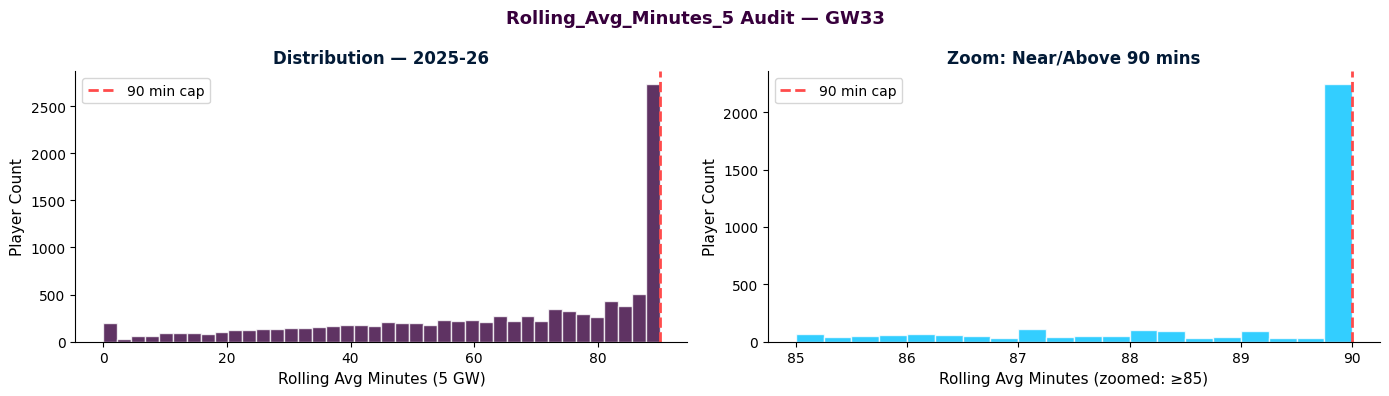


═════════════════════════════════════════════════════════════════
  AUDIT VERDICT
═════════════════════════════════════════════════════════════════
  ✓ CLEAN: No minutes anomalies detected. No cap needed.

  Next step: share the output above and we will decide
  whether a targeted fix is needed.


In [11]:
# %% [Cell: Task 1 Diagnostic — Minutes & DGW Rolling Average Audit]
# ─────────────────────────────────────────────────────────────────────────────
# READ-ONLY investigation. Does not modify df_augmented or any global.
# Answers three questions:
#   Q1. Are there players whose Rolling_Avg_Minutes_5 > 90 right now?
#   Q2. Did the DGW aggregator actually cap Minutes Played at 180 correctly?
#   Q3. Do inflated rolling minutes correspond to the DGW teams we already know?
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CURRENT_SEASON = globals().get('CURRENT_SEASON', '2025-26')
CURRENT_GW     = globals().get('CURRENT_GW', 33)

print("=" * 65)
print("  TASK 1 DIAGNOSTIC — MINUTES & DGW ROLLING AVERAGE AUDIT")
print("=" * 65)

# ── Q1: How many players have Rolling_Avg_Minutes_5 > 90? ────────────────────
if 'Rolling_Avg_Minutes_5' not in df_augmented.columns:
    print("[ERROR] Rolling_Avg_Minutes_5 not found. Run Cell 1 first.")
else:
    _over90 = df_augmented[df_augmented['Rolling_Avg_Minutes_5'] > 90].copy()
    _over90_current = _over90[_over90['season'] == CURRENT_SEASON].copy()

    print(f"\n── Q1: Players with Rolling_Avg_Minutes_5 > 90 ──────────────────")
    print(f"  All seasons combined:   {len(_over90):,} rows")
    print(f"  Current season only:    {len(_over90_current):,} rows")

    if not _over90_current.empty:
        print(f"\n  Top offenders in {CURRENT_SEASON}:")
        _top = (
            _over90_current
            .sort_values('Rolling_Avg_Minutes_5', ascending=False)
            [['Web Name', 'Player Team Name', 'Gameweek',
              'Rolling_Avg_Minutes_5', 'Minutes Played', 'Total Points']]
            .drop_duplicates('Web Name')
            .head(20)
        )
        display(_top)

        # How inflated are they?
        _max_val  = _over90_current['Rolling_Avg_Minutes_5'].max()
        _mean_val = _over90_current['Rolling_Avg_Minutes_5'].mean()
        print(f"\n  Max rolling avg minutes:  {_max_val:.1f}")
        print(f"  Mean rolling avg minutes: {_mean_val:.1f}")
    else:
        print(f"  ✓ No players exceed 90 in the current season. No cap needed.")

# ── Q2: Did the DGW aggregator correctly cap Minutes Played at 180? ───────────
print(f"\n── Q2: Minutes Played integrity check ───────────────────────────────")

_over180 = df_augmented[df_augmented['Minutes Played'] > 180]
_over90m  = df_augmented[
    (df_augmented['Minutes Played'] > 90) &
    (df_augmented['Minutes Played'] <= 180)
]

print(f"  Rows with Minutes Played > 180 (should be 0): {len(_over180)}")
print(f"  Rows with Minutes Played 91–180 (DGW rows):   {len(_over90m)}")

if not _over180.empty:
    print(f"\n  ⚠ WARNING: Found rows where minutes > 180 — aggregator cap failed!")
    display(_over180[['Web Name', 'season', 'Gameweek',
                       'Minutes Played', 'Total Points']].head(10))
else:
    print(f"  ✓ No rows exceed 180 minutes. Aggregator cap is working.")

if not _over90m.empty:
    print(f"\n  DGW rows (91–180 mins) sample — these are expected and correct:")
    display(_over90m[['Web Name', 'season', 'Gameweek',
                       'Minutes Played', 'Total Points']].head(10))

# ── Q3: Do inflated rolling averages come from DGW teams? ────────────────────
print(f"\n── Q3: Cross-check inflated rolling minutes vs known DGW teams ──────")

DGW_TEAMS = globals().get('DGW_TEAMS', set())

if _over90_current.empty:
    print(f"  No inflation found — nothing to cross-check.")
elif not DGW_TEAMS:
    print(f"  DGW_TEAMS is empty (normal GW). Any inflation is a legacy artefact.")
    print(f"  Showing inflated players anyway for inspection:")
    display(_over90_current[['Web Name', 'Player Team Name',
                              'Gameweek', 'Rolling_Avg_Minutes_5']].head(15))
else:
    _over90_current['Is_DGW_Team'] = _over90_current['Player Team Name'].isin(DGW_TEAMS)
    _dgw_inflated     = _over90_current[_over90_current['Is_DGW_Team'] == True]
    _non_dgw_inflated = _over90_current[_over90_current['Is_DGW_Team'] == False]

    print(f"  DGW teams this GW: {sorted(DGW_TEAMS)}")
    print(f"\n  Inflated players FROM DGW teams (expected):     {len(_dgw_inflated)}")
    print(f"  Inflated players NOT from DGW teams (anomaly):  {len(_non_dgw_inflated)}")

    if not _non_dgw_inflated.empty:
        print(f"\n  ⚠ WARNING: These players have rolling avg > 90 but are NOT in DGW teams.")
        print(f"  This means legacy DGW data is bleeding into their rolling window.")
        display(_non_dgw_inflated[['Web Name', 'Player Team Name',
                                    'Gameweek', 'Rolling_Avg_Minutes_5',
                                    'Minutes Played']].head(15))
    else:
        print(f"  ✓ All inflation traces back to DGW teams only — expected behaviour.")

# ── Q4: Distribution plot of Rolling_Avg_Minutes_5 ───────────────────────────
print(f"\n── Q4: Distribution of Rolling_Avg_Minutes_5 (current season) ──────")

_curr_mins = df_augmented[
    df_augmented['season'] == CURRENT_SEASON
]['Rolling_Avg_Minutes_5'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor='white')

axes[0].hist(_curr_mins, bins=40, color='#37003c', alpha=0.8, edgecolor='white')
axes[0].axvline(x=90, color='#ff4b4b', linewidth=2, linestyle='--', label='90 min cap')
axes[0].set_xlabel('Rolling Avg Minutes (5 GW)', fontsize=11)
axes[0].set_ylabel('Player Count', fontsize=11)
axes[0].set_title(f'Distribution — {CURRENT_SEASON}', fontsize=12,
                   fontweight='bold', color='#021a36')
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Zoom in on the > 85 range to see exactly how many breach 90
_near90 = _curr_mins[_curr_mins >= 85]
axes[1].hist(_near90, bins=20, color='#00c2ff', alpha=0.8, edgecolor='white')
axes[1].axvline(x=90, color='#ff4b4b', linewidth=2, linestyle='--', label='90 min cap')
axes[1].set_xlabel('Rolling Avg Minutes (zoomed: ≥85)', fontsize=11)
axes[1].set_ylabel('Player Count', fontsize=11)
axes[1].set_title(f'Zoom: Near/Above 90 mins', fontsize=12,
                   fontweight='bold', color='#021a36')
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle(f'Rolling_Avg_Minutes_5 Audit — GW{CURRENT_GW}',
             fontsize=13, fontweight='bold', color='#37003c')
plt.tight_layout()
plt.show()

# ── SUMMARY VERDICT ───────────────────────────────────────────────────────────
print(f"\n{'═' * 65}")
print(f"  AUDIT VERDICT")
print(f"{'═' * 65}")

_n_over90_current = len(_over90_current)
_n_over180        = len(_over180)

if _n_over180 > 0:
    print(f"  ✗ CRITICAL: {_n_over180} rows exceed 180 minutes. DGW aggregator cap broken.")
elif _n_over90_current > 0:
    print(f"  ⚠ ATTENTION: {_n_over90_current} rows in {CURRENT_SEASON} have rolling avg > 90.")
    print(f"    These are DGW legacy artefacts bleeding into the rolling window.")
    print(f"    They will slightly inflate predictions for affected players.")
    print(f"    Recommended fix: clip Rolling_Avg_Minutes_5 to 90 at inference time only.")
else:
    print(f"  ✓ CLEAN: No minutes anomalies detected. No cap needed.")

print(f"\n  Next step: share the output above and we will decide")
print(f"  whether a targeted fix is needed.")

In [12]:
print(df_augmented[df_augmented['season'] == '2025-26']['Gameweek'].max())


35.0


In [13]:
# %% [Cell: Data Recency Cross-Check]

print("--- LATEST 5 GAMEWEEKS IN DATASET ---")

# 1. Ensure CURRENT_SEASON is defined (fallback to max season if not)
season_to_check = globals().get('CURRENT_SEASON', df_augmented['season'].max())
print(f"Checking Season: {season_to_check}\n")

current_season_data = df_augmented[df_augmented['season'] == season_to_check]

if current_season_data.empty:
    print(f" No data found for season {season_to_check}.")
else:
    # 2. Get the 5 most recent gameweeks
    latest_gws = sorted(current_season_data['Gameweek'].unique(), reverse=True)[:5]

    # 3. Print the row counts to ensure the gameweeks are fully populated
    for gw in latest_gws:
        gw_rows = len(current_season_data[current_season_data['Gameweek'] == gw])
        print(f"Gameweek {gw}: {gw_rows} player records")

    # 4. Display a quick snapshot of the absolute latest Gameweek
    if latest_gws:
        max_gw = latest_gws[0]
        print(f"\nSnapshot of data from GW {max_gw}:")
        
        # Columns we want to verify
        display_cols = ['Web Name', 'season', 'Gameweek', 'Minutes Played', 'Total Points', 'Next_Opponent_Difficulty']
        
        # Safely only select columns that actually exist in the dataframe
        available_cols = [c for c in display_cols if c in current_season_data.columns]
        
        latest_data = current_season_data[current_season_data['Gameweek'] == max_gw]
        
        # Show top 10 highest scorers from the latest gameweek to verify point logic
        display(latest_data.sort_values(by='Total Points', ascending=False)[available_cols].head(10))

--- LATEST 5 GAMEWEEKS IN DATASET ---
Checking Season: 2025-26

Gameweek 35.0: 305 player records
Gameweek 34.0: 205 player records
Gameweek 33.0: 310 player records
Gameweek 32.0: 303 player records
Gameweek 31.0: 243 player records

Snapshot of data from GW 35.0:


,Web Name,season,Gameweek,Minutes Played,Total Points,Next_Opponent_Difficulty
1603,Gyökeres,2025-26,35.0,63,16,3.0
43252,Awoniyi,2025-26,35.0,90,16,3.0
42980,Doku,2025-26,35.0,180,15,3.0
35544,Senesi,2025-26,35.0,90,14,3.0
53262,Szoboszlai,2025-26,35.0,90,13,3.0
47842,Lewis-Potter,2025-26,35.0,90,11,5.0
45908,Mukiele,2025-26,35.0,90,11,3.0
43423,Barry,2025-26,35.0,26,11,3.0
25301,Saka,2025-26,35.0,45,11,3.0
44603,Damsgaard,2025-26,35.0,90,11,5.0


In [14]:
# %% [Cell: V7 Column Availability Audit]
print("--- CHECKING FOR UNDERLYING METRICS IN YOUR DATASET ---")
print(f"\nTotal columns: {len(df.columns)}")
print("\nAll column names:")
for col in sorted(df.columns):
    print(f"  {col}")

--- CHECKING FOR UNDERLYING METRICS IN YOUR DATASET ---

Total columns: 42

All column names:
  Assists
  Avg_Assists_L3
  Avg_Assists_L5
  Avg_Creativity_L3
  Avg_Creativity_L5
  Avg_Goals Conceded_L3
  Avg_Goals Conceded_L5
  Avg_Goals Scored_L3
  Avg_Goals Scored_L5
  Avg_ICT Index_L3
  Avg_ICT Index_L5
  Avg_Influence_L3
  Avg_Influence_L5
  Avg_Minutes Played_L3
  Avg_Minutes Played_L5
  Avg_Threat_L3
  Avg_Threat_L5
  Avg_Total Points_L3
  Avg_Total Points_L5
  Clean Sheet
  Code
  Creativity
  Gameweek
  Goals Conceded
  Goals Scored
  ICT Index
  Influence
  Injury/Unavailable
  Is Home
  Minutes Played
  Opponent Difficulty
  Opponent Name
  Player Name
  Player Team Name
  Player UUID
  Position
  Red Cards
  Threat
  Total Points
  Web Name
  Yellow Card
  season


In [15]:
# ── INTEGRITY CHECK: confirm all 3-GW columns were created ──────────────────
required_cols = ['Next_Opponent_Difficulty', 'Opponent_Diff_plus_2', 
                 'Opponent_Diff_plus_3', 'FDI_3GW']
missing = [c for c in required_cols if c not in df_augmented.columns]
if missing:
    print(f"ALERT: Missing 3-GW columns: {missing}. Check Cell 1 logic.")
else:
    fdi_range = df_augmented['FDI_3GW'].describe()
    print(f"\n3-GW Feature Integrity Check:")
    print(f"  FDI_3GW range: {fdi_range['min']:.1f} to {fdi_range['max']:.1f}")
    print(f"  FDI_3GW mean: {fdi_range['mean']:.2f}  (expected ~9.0 for neutral fixtures)")
    print(f"  All 3-GW columns present: OK")


3-GW Feature Integrity Check:
  FDI_3GW range: 4.0 to 15.0
  FDI_3GW mean: 8.82  (expected ~9.0 for neutral fixtures)
  All 3-GW columns present: OK


## Prev_Season_Avg_Points

It calculates the average points a player earned over the entire previous season.

It maps that average forward to the current season.

Result: The model now knows if a player is "Class" (e.g., Salah averaging 7 points all year) vs. just being in "Form" for a few weeks. This makes GW1 and GW2 predictions much more stable.

In [16]:
# [Cell: Verification - Salah's Season Bridge]

# 1. Identify Salah's UUID
# (search for 'salah' in the Web Name to be safe)
salah_data = df_augmented[df_augmented['Web Name'].str.contains('Salah', case=False, na=False)]

if not salah_data.empty:
    s_uuid = salah_data['Player UUID'].iloc[0]
    
    # 2. Get the transition rows (End of 24/25 and Start of 25/26)
    # We sort to ensure chronological order
    salah_history = df_augmented[df_augmented['Player UUID'] == s_uuid].sort_values(['season', 'Gameweek'])
    
    # 3. Find the exact point where 2024-25 ends and 2025-26 begins
    transition_mask = (salah_history['season'] == '2025-26') & (salah_history['season'].shift(1) == '2024-25')
    
    if transition_mask.any():
        idx = salah_history[transition_mask].index[0]
        # Get 3 games before and 3 games after the summer break
        display_df = salah_history.loc[idx-3 : idx+2]
        
        print(f"--- Verification: Season Baseline Bridge (Mohamed Salah) ---")
        print("Note how 'Prev_Season_Avg_Points' appears only when the new season (2025-26) starts.")
        display(display_df[['Player Name', 'season', 'Gameweek', 'Total Points', 'Prev_Season_Avg_Points']])
    else:
        print("Could not find the 2024-25 to 2025-26 transition for Salah in this specific slice.")
else:
    print("Salah not found in the current df_augmented slice.")

--- Verification: Season Baseline Bridge (Mohamed Salah) ---
Note how 'Prev_Season_Avg_Points' appears only when the new season (2025-26) starts.


,Player Name,season,Gameweek,Total Points,Prev_Season_Avg_Points
31229,Mohamed Salah,2024-25,35.0,2,6.727273
31230,Mohamed Salah,2024-25,36.0,2,6.727273
31231,Mohamed Salah,2024-25,37.0,2,6.727273
31232,Mohamed Salah,2025-26,1.0,8,9.052632
31233,Mohamed Salah,2025-26,2.0,5,9.052632
31234,Mohamed Salah,2025-26,3.0,3,9.052632


In [17]:
#INVESTIGATION IN THE INPUT FILE 

# 1. Look at the suspicious GWs
dgws_investigation = df_augmented.groupby(['Player UUID', 'season', 'Gameweek']).filter(lambda x: len(x) > 2)

print(f"Investigating {len(dgws_investigation)} rows from suspicious Gameweeks...")

# 2. Check the 180 minute rows specifically
high_min_rows = df[df['Minutes Played'] >= 180]

print(f"Found {len(high_min_rows)} rows in the RAW dataset with >= 180 minutes.")

if not high_min_rows.empty:
    print("\nSample of 180-minute rows (Raw Data):")
    display(high_min_rows[['Player Name', 'season', 'Gameweek', 'Opponent Difficulty', 'Minutes Played', 'Total Points']].head(10))

if not dgws_investigation.empty:
    print("\nSample of 'Triple' Gameweek rows (After our current filter):")
    display(dgws_investigation[['Player Name', 'season', 'Gameweek', 'Opponent Difficulty', 'Minutes Played']].head(10))

Investigating 0 rows from suspicious Gameweeks...
Found 0 rows in the RAW dataset with >= 180 minutes.


In [18]:

# Filter for players who still have more than 2 entries in a single week
final_suspicious = df_augmented.groupby(['Player UUID', 'season', 'Gameweek']).filter(lambda x: len(x) > 2)

if not final_suspicious.empty:
    print(f"Found {final_suspicious['Player UUID'].nunique()} players across 176 suspicious GW instances.")
    # Display a few examples to see why they stayed
    display(final_suspicious[['Player Name', 'season', 'Gameweek', 'Opponent Difficulty', 'Minutes Played', 'Total Points']].head(15))
else:
    print("No suspicious rows found in the current df_augmented.")

No suspicious rows found in the current df_augmented.


In [19]:
# Check if "Doubles" are actually different matches
dgws_check = df_augmented.groupby(['Player UUID', 'season', 'Gameweek'])['Opponent Difficulty'].nunique()
fake_doubles = dgws_check[dgws_check > 2] # This shouldn't really happen
print(f"Number of suspicious GWs with >2 different difficulties: {len(fake_doubles)}")

Number of suspicious GWs with >2 different difficulties: 0


In [20]:
# [Cell: Updated Top-Tier Identification - 4.5 Threshold]
# 1. Calculate seasonal averages
seasonal_avg = df_augmented.groupby(['Player UUID', 'season'])['Total Points'].mean().reset_index()
seasonal_avg.rename(columns={'Total Points': 'avg_season_pts'}, inplace=True)

# 2. Cleanup & Merge
if 'avg_season_pts' in df_augmented.columns:
    df_augmented = df_augmented.drop(columns=['avg_season_pts'])
df_augmented = df_augmented.merge(seasonal_avg, on=['Player UUID', 'season'], how='left')

# 3. Define the New Global Elite Mask (> 4.5 avg points per season)
elite_mask = df_augmented['avg_season_pts'] > 4.5

print(f"--- Top-Tier Identification Summary (Threshold: 4.5) ---")
print(f"Total Rows in Dataset: {len(df_augmented):,}")
print(f"Total Elite Rows: {elite_mask.sum():,}")
print(f"Percentage of Data considered 'Elite': {(elite_mask.sum()/len(df_augmented))*100:.2f}%")

# 4. Display Table for Verification (Keep this if you like the visual check)
print(f"\nSample of Top Tier Players (Avg > 4.5 pts):")
elite_list = df_augmented[elite_mask][['Player Name', 'season', 'avg_season_pts']].drop_duplicates()
elite_list = elite_list.sort_values(by=['season', 'avg_season_pts'], ascending=[False, False])
display(elite_list.head(15))

--- Top-Tier Identification Summary (Threshold: 4.5) ---
Total Rows in Dataset: 60,912
Total Elite Rows: 4,388
Percentage of Data considered 'Elite': 7.20%

Sample of Top Tier Players (Avg > 4.5 pts):


,Player Name,season,avg_season_pts
31506,Erling Haaland,2025-26,6.843750
37594,Gabriel dos Santos Magalhães,2025-26,6.821429
21110,Bruno Borges Fernandes,2025-26,6.531250
50145,Antoine Semenyo,2025-26,5.718750
57792,Bruno Guimarães Rodriguez Moura,2025-26,5.500000
41256,Declan Rice,2025-26,5.333333
42085,Melker Ellborg,2025-26,5.333333
55362,Jurriën Timber,2025-26,5.285714
43575,João Pedro Junqueira de Jesus,2025-26,5.272727
2075,Marc Guéhi,2025-26,5.225806


## Cell 2: Augmented Window Generation (Context-Aware)

In [21]:
# [Cell 2: Augmented Window Generation - Including Season Baseline]

# 1. SETUP PROFESSIONAL FOLDER STRUCTURE
PRO_OUTPUT_DIR = Path('../output/forecaster_pro')
PRO_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def generate_fpl_windows_pro(df, window_size=6):
    train_data = []
    source_indices = []  # NEW: track which df_augmented row each window targets
    uuid_col = 'Player UUID'
    
    df = df.sort_values([uuid_col, 'season', 'Gameweek'])
    
    for pid, group in df.groupby(uuid_col):
        points = group['Total Points'].values
        next_diff = group['Next_Opponent_Difficulty'].values
        next_home = group['Next_Is_Home'].values
        avg_min = group['Rolling_Avg_Minutes_5'].values
        phase = group['Season_Phase'].values
        season_baseline = group['Prev_Season_Avg_Points'].values
        group_indices = group.index.tolist()  # NEW: actual df_augmented index values
        avg_pts_vs_diff = group['Avg_Pts_vs_Difficulty'].values
        
        if len(points) <= window_size:
            continue
            
        position = group['Position'].iloc[0]
        
        for i in range(len(points) - window_size):
            window = points[i : i + window_size]
            target_idx = i + window_size - 1
            
            t_diff = next_diff[target_idx]
            t_home = next_home[target_idx]
            t_min = avg_min[target_idx]
            t_phase = phase[target_idx]
            t_baseline = season_baseline[target_idx]
            t_avg_vs_diff = avg_pts_vs_diff[target_idx]
            target_points = points[i + window_size]
            
            if np.all(window == 0) and target_points == 0:
                continue
            
            #row = list(window) + [position, t_diff, t_home, t_min, t_phase, t_baseline, target_points]
            row = list(window) + [position, t_diff, t_home, t_min, t_phase, t_baseline, t_avg_vs_diff, target_points]
            train_data.append(row)
            source_indices.append(group_indices[i + window_size])  # NEW: index of target row
    
    #columns = [f'lag_{i}' for i in range(window_size, 0, -1)] + \
              #['position', 'next_difficulty', 'next_is_home', 'rolling_min',
              # 'season_phase', 'season_baseline', 'target']
    
    columns = [f'lag_{i}' for i in range(window_size, 0, -1)] + \
              ['position', 'next_difficulty', 'next_is_home', 'rolling_min',
               'season_phase', 'season_baseline', 'avg_pts_vs_diff', 'target']
    
    result_df = pd.DataFrame(train_data, columns=columns)
    result_df.index = source_indices  # NEW: set index to df_augmented source rows
    result_df['position'] = result_df['position'].astype('category')
    
    return result_df

windowed_df = generate_fpl_windows_pro(df_augmented)

WINDOWED_FEATURES_PATH = PRO_OUTPUT_DIR / 'fpl_windowed_features_pro.csv'
windowed_df.to_csv(WINDOWED_FEATURES_PATH, index=True)  # save index too

print(f"Pro Windowed dataset created: {WINDOWED_FEATURES_PATH}")
print(f"Total Training Windows: {windowed_df.shape[0]}")
display(windowed_df.head())

Pro Windowed dataset created: ..\output\forecaster_pro\fpl_windowed_features_pro.csv
Total Training Windows: 53535


,lag_6,lag_5,lag_4,lag_3,lag_2,lag_1,position,next_difficulty,next_is_home,rolling_min,season_phase,season_baseline,avg_pts_vs_diff,target
6,1,1,1,1,4,1,FWD,2.0,False,9.6,3.0,2.0,1.0,1
13,5,2,2,2,1,2,MID,3.0,False,90.0,1.0,0.0,1.0,3
14,2,2,2,1,2,3,MID,4.0,False,90.0,1.0,0.0,1.5,7
15,2,2,1,2,3,7,MID,4.0,True,90.0,2.0,0.0,2.5,2
16,2,1,2,3,7,2,MID,2.0,True,90.0,2.0,0.0,4.0,1


In [22]:
# %% [Cell 2.5: GLOBAL VALIDATION STRATEGY — fixed alignment]

# --- 0. DEFINE THE VALIDATION WINDOW (The "Fair Ground") ---
VAL_SEASON = "2025-26"
VAL_START_GW = 28
VAL_END_GW = 32

# 1. LINK TO SOURCE METADATA
# windowed_df.index now contains actual df_augmented row indices (fixed in Cell 2)
#source_meta = df_augmented.loc[windowed_df.index, ['season', 'Gameweek']]
safe_windowed_index = windowed_df.index.intersection(df_augmented.index)
source_meta = df_augmented.loc[safe_windowed_index, ['season', 'Gameweek']]

# 2. CREATE THE MASK
global_val_mask = (
    (source_meta['season'] == VAL_SEASON) &
    (source_meta['Gameweek'] >= VAL_START_GW) &
    (source_meta['Gameweek'] <= VAL_END_GW)
).values  # .values so it's a plain numpy bool array for slicing

# 3. BUILD val_df FOR DOWNSTREAM AUDITS
val_df = windowed_df[global_val_mask]

# 4. PRINT INTEGRITY REPORT
print(f"--- GLOBAL SPLIT ENFORCED ---")
print(f"Validation Set     : {VAL_SEASON} GW {VAL_START_GW} to {VAL_END_GW}")
print(f"Validation Windows : {global_val_mask.sum():,}")
print(f"Training Windows   : {(~global_val_mask).sum():,}")
print(f"val_df index sample: {val_df.index[:5].tolist()} (Validating df_augmented mapping)")

--- GLOBAL SPLIT ENFORCED ---
Validation Set     : 2025-26 GW 28 to 32
Validation Windows : 1,399
Training Windows   : 52,136
val_df index sample: [351, 352, 353, 354, 355] (Validating df_augmented mapping)


## Cell 3: Data Splitting and Scaling (Comparison Setup)

In [23]:
# [Cell 3: Corrected Splitting (Recent 5 GW Window)]

# 1. SETUP PARAMETERS
CURRENT_SEASON = "2025-26"
VALIDATION_WINDOW = 5

# Dynamically detect CURRENT_GW from the latest gameweek in the dataset
# This means you never need to manually update this number again
_latest_gw = int(
    df_augmented[df_augmented['season'] == CURRENT_SEASON]['Gameweek'].max()
)
CURRENT_GW = _latest_gw + 1  # next GW to predict = latest completed + 1

# Validation window: last 5 completed GWs before the current one
VAL_END_GW   = _latest_gw
VAL_START_GW = max(1, _latest_gw - VALIDATION_WINDOW + 1)

globals()['CURRENT_GW']    = CURRENT_GW
globals()['VAL_START_GW']  = VAL_START_GW
globals()['VAL_END_GW']    = VAL_END_GW
globals()['CURRENT_SEASON'] = CURRENT_SEASON

print(f"Current Season:    {CURRENT_SEASON}")
print(f"Latest GW in data: {_latest_gw}")
print(f"Predicting for:    GW {CURRENT_GW}")
print(f"Validation window: GW {VAL_START_GW} to GW {VAL_END_GW}")

# 2. EXECUTE FAIR SPLIT
X_all = windowed_df.drop(columns=['target'])
y_all = windowed_df['target']

X_train_raw = X_all[~global_val_mask].copy()
y_train = y_all[~global_val_mask].copy()
X_val_raw = X_all[global_val_mask].copy()
y_val = y_all[global_val_mask].copy()
val_df = windowed_df[global_val_mask]

# 4. NUMERIC FEATURES
numeric_cols = [
    c for c in X_train_raw.columns
    if 'lag' in c or 'difficulty' in c or 'min' in c or 'phase' in c
]

# 5. SCALING
scaler = StandardScaler()
X_train_scaled = X_train_raw.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train_raw[numeric_cols])

X_val_scaled = X_val_raw.copy()
X_val_scaled[numeric_cols] = scaler.transform(X_val_raw[numeric_cols])

# 6. SAVE SCALER
SCALER_PATH = PRO_OUTPUT_DIR / 'fpl_pro_scaler.pkl'
joblib.dump(scaler, SCALER_PATH)

print(f"--- Split Logic ---")
print(f"Validation Period: {CURRENT_SEASON} | Matches GW {CURRENT_GW - VALIDATION_WINDOW} to {CURRENT_GW - 1}")

print(f"Training windows: {len(X_train_raw):,}")
print(f"Validation windows: {len(X_val_raw):,}")

# %% [Cell 3 Supplement: Dataset Observations Tracking]

# Track Unique Players (Using source indices to map back to df_augmented)
#train_uuids = df_augmented.loc[X_train_raw.index, 'Player UUID'].nunique()
#val_uuids = df_augmented.loc[X_val_raw.index, 'Player UUID'].nunique()
safe_train_idx = X_train_raw.index.intersection(df_augmented.index)
safe_val_idx   = X_val_raw.index.intersection(df_augmented.index)
train_uuids = df_augmented.loc[safe_train_idx, 'Player UUID'].nunique()
val_uuids   = df_augmented.loc[safe_val_idx,   'Player UUID'].nunique()

print(f"--- Dataset Integrity Report ---")
print(f"Total Training Observations: {len(X_train_raw):,}")
print(f"Unique Players in Training:  {train_uuids:,}")
print(f"Total Validation Observations: {len(X_val_raw):,}")
print(f"Unique Players in Validation: {val_uuids:,}")
print(f"Seasons covered: {df_augmented['season'].nunique()}")

# Protect original validation targets from being overwritten by V2/V3/V4 cells
globals()['y_val_v1'] = y_val.copy()
globals()['X_val_v1'] = X_val_raw.copy()
print("y_val_v1 and X_val_v1 saved for downstream blending protection.")

Current Season:    2025-26
Latest GW in data: 35
Predicting for:    GW 36
Validation window: GW 31 to GW 35
--- Split Logic ---
Validation Period: 2025-26 | Matches GW 31 to 35
Training windows: 52,136
Validation windows: 1,399
--- Dataset Integrity Report ---
Total Training Observations: 52,136
Unique Players in Training:  1,123
Total Validation Observations: 1,399
Unique Players in Validation: 380
Seasons covered: 6
y_val_v1 and X_val_v1 saved for downstream blending protection.


## Cell 4: Parallel Training & Performance Comparison for scaled and unscaled model

In [24]:
# %% [Cell 4: Parallel Training & Performance Comparison + LambdaRank Blending]


# Ensure y_val_v1 exists — set in Cell 3 via globals(), fallback to y_val
y_val_v1 = globals().get('y_val_v1', y_val)

# ── 1. SETUP PARAMETERS ───────────────────────────────────────────────────────
lgbm_params = {
    'objective':      'regression',
    'n_estimators':   1500,
    'learning_rate':  0.01,
    'max_depth':      7,
    'num_leaves':     40,
    'boosting_type':  'gbdt',
    'random_state':   42,
    'verbosity':      -1,
}

lgbm_rank_params = {
    'objective':      'lambdarank',
    'boosting_type':  'gbdt',
    'n_estimators':   1500,
    'learning_rate':  0.01,
    'max_depth':      6,
    'num_leaves':     31,
    'random_state':   42,
    'verbosity':      -1,
    'label_gain':     [0, 1, 2, 4, 8, 16]
}

# ── 2. TRAIN MODEL A: RAW REGRESSION ─────────────────────────────────────────
print("Training RAW Model (No Scaling)...")
model_raw = lgb.LGBMRegressor(**lgbm_params)
model_raw.fit(
    X_train_raw, y_train,
    eval_set=[(X_val_raw, y_val)],
    categorical_feature=['position', 'next_is_home'],
    callbacks=[lgb.early_stopping(stopping_rounds=100)]
)

# ── 3. TRAIN MODEL B: SCALED REGRESSION ──────────────────────────────────────
print("\nTraining SCALED Model (StandardScaler)...")
model_scaled = lgb.LGBMRegressor(**lgbm_params)
model_scaled.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)],
    categorical_feature=['position', 'next_is_home'],
    callbacks=[lgb.early_stopping(stopping_rounds=100)]
)

# ── 4. REGRESSION PREDICTIONS & METRICS ──────────────────────────────────────
preds_raw    = model_raw.predict(X_val_raw)
preds_scaled = model_scaled.predict(X_val_scaled)

results_comparison = {
    'Metric': ['MAE', 'RMSE'],
    'Raw Model': [
        mean_absolute_error(y_val, preds_raw),
        np.sqrt(mean_squared_error(y_val, preds_raw))
    ],
    'Scaled Model': [
        mean_absolute_error(y_val, preds_scaled),
        np.sqrt(mean_squared_error(y_val, preds_scaled))
    ]
}

df_metrics = pd.DataFrame(results_comparison)
print("\n--- Regression Model Comparison ---")
display(df_metrics)

mae_v1 = mean_absolute_error(y_val, preds_raw)

# ── 5. SAVE REGRESSION MODELS ─────────────────────────────────────────────────
model_raw.booster_.save_model(str(PRO_OUTPUT_DIR / 'fpl_pro_model_raw.txt'))
model_scaled.booster_.save_model(str(PRO_OUTPUT_DIR / 'fpl_pro_model_scaled.txt'))
print("\nRegression models saved.")

# ── 6. TRAIN LAMBDARANK MODEL ─────────────────────────────────────────────────
print("\nBuilding relevance labels for LambdaRank...")

def points_to_relevance(pts_series):
    """
    Converts raw points into 0-5 integer relevance labels.
    0 = blank (0 pts), 1 = low (1-2), 2 = ok (3-4),
    3 = good (5-7), 4 = great (8-11), 5 = haul (12+)
    """
    return pd.cut(
        pts_series,
        bins=[-999, 0, 2, 4, 7, 11, 999],
        labels=[0, 1, 2, 3, 4, 5]
    ).astype(int)

# CRITICAL FIX: X_train_raw.index contains windowed_df source indices which may
# not all exist in df_augmented after the data scrub/purge steps.
# We use a safe intersection so .loc never raises a KeyError.
print("Sorting data chronologically for LambdaRank grouping...")

safe_train_index = X_train_raw.index.intersection(df_augmented.index)

# Warn if any indices were lost — large numbers indicate a scrub/reset issue
n_dropped = len(X_train_raw.index) - len(safe_train_index)
if n_dropped > 0:
    print(f"[INFO] {n_dropped} training indices not found in df_augmented "
          f"(purged rows). Proceeding with {len(safe_train_index)} safe rows.")

train_meta = df_augmented.loc[safe_train_index, ['season', 'Gameweek']]
train_meta_sorted = train_meta.sort_values(['season', 'Gameweek'])

# Apply the chronological sort to X and y — also restricted to safe indices
X_train_rank = X_train_raw.loc[train_meta_sorted.index].copy()
y_train_rank = points_to_relevance(y_train.loc[train_meta_sorted.index])

print(f"Relevance label distribution (train):")
print(y_train_rank.value_counts().sort_index())

# Group sizes based on the sorted, safe data
query_groups_train = (
    train_meta_sorted.groupby(['season', 'Gameweek'], sort=False)
    .size()
    .values
)

print(f"\nLambdaRank group count: {len(query_groups_train)} season-GW groups")
print(f"Avg players per group: {query_groups_train.mean():.0f}")
print(f"Total training rows: {query_groups_train.sum()} (must equal {len(X_train_rank)})")

assert query_groups_train.sum() == len(X_train_rank), (
    f"Group size mismatch: {query_groups_train.sum()} vs {len(X_train_rank)}. "
    "Check that X_train_raw.index aligns with df_augmented after scrub."
)

print("\nTraining LambdaRank model...")
model_rank = lgb.LGBMRanker(**lgbm_rank_params)
model_rank.fit(
    X_train_rank,
    y_train_rank,
    group=query_groups_train,
    categorical_feature=['position', 'next_is_home']
)
print("LambdaRank model trained.")

# ── 7. BLEND REGRESSION + RANK ON VALIDATION SET ─────────────────────────────
# 60% regression (point accuracy) + 40% rank signal (ordering / ceiling detection)
# Increasing rank weight from 0.3 → 0.4 helps surface high-ceiling differential
# players like Bowen who the regression alone underweights.

rank_scores_val = model_rank.predict(X_val_raw)

rank_norm = MinMaxScaler(feature_range=(0, 1)).fit_transform(
    rank_scores_val.reshape(-1, 1)
).flatten()

pred_norm = MinMaxScaler(feature_range=(0, 1)).fit_transform(
    preds_raw.reshape(-1, 1)
).flatten()

blended_norm = 0.6 * pred_norm + 0.4 * rank_norm

# Scale back to original points range using the protected y_val_v1
# (never use y_val here — it may have been overwritten by V2/V3/V4 cells)
pts_min = y_val_v1.min()
pts_max = y_val_v1.max()
blended_preds_val = blended_norm * (pts_max - pts_min) + pts_min

mae_blended = mean_absolute_error(y_val, blended_preds_val)

print("\n--- Final Model Comparison (Validation Set) ---")
comparison_df = pd.DataFrame({
    'Model':  ['V1 Regression (raw)', 'V1 Regression (scaled)', 'Blended Reg + Rank'],
    'MAE':    [
        round(mae_v1, 4),
        round(mean_absolute_error(y_val, preds_scaled), 4),
        round(mae_blended, 4)
    ],
    'Note': [
        'Baseline',
        'Usually similar to raw',
        'MAE may be slightly higher — rank ordering improves ceiling detection'
    ]
})
display(comparison_df)

print("\nInterpretation:")
print("  A higher MAE on the blended model is acceptable —")
print("  LambdaRank improves ORDERING (Spearman rank), not point accuracy.")
print("  The audit cell will show the Spearman improvement.")

# ── 8. SAVE LAMBDARANK MODEL ──────────────────────────────────────────────────
model_rank.booster_.save_model(str(PRO_OUTPUT_DIR / 'fpl_pro_model_rank.txt'))
print("\nLambdaRank model saved.")

# ── 9. STORE ALL GLOBALS FOR DOWNSTREAM CELLS ────────────────────────────────
globals()['model_raw']          = model_raw
globals()['model_scaled']       = model_scaled
globals()['model_rank']         = model_rank
globals()['preds_raw']          = preds_raw
globals()['preds_scaled']       = preds_scaled
globals()['blended_preds_val']  = blended_preds_val
globals()['mae_v1']             = mae_v1
globals()['mae_blended']        = mae_blended
globals()['df_metrics']         = df_metrics

Training RAW Model (No Scaling)...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[381]	valid_0's l2: 8.42508

Training SCALED Model (StandardScaler)...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[337]	valid_0's l2: 8.43075

--- Regression Model Comparison ---


,Metric,Raw Model,Scaled Model
0,MAE,2.118516,2.120230
1,RMSE,2.902600,2.903576



Regression models saved.

Building relevance labels for LambdaRank...
Sorting data chronologically for LambdaRank grouping...
Relevance label distribution (train):
target
0     3161
1    31820
2     5276
3     7124
4     3537
5     1218
Name: count, dtype: int64

LambdaRank group count: 208 season-GW groups
Avg players per group: 251
Total training rows: 52136 (must equal 52136)

Training LambdaRank model...
LambdaRank model trained.

--- Final Model Comparison (Validation Set) ---


,Model,MAE,Note
0,V1 Regression (raw),2.1185,Baseline
1,V1 Regression (scaled),2.1202,Usually similar to raw
2,Blended Reg + Rank,3.4690,MAE may be slightly higher — rank ordering imp...



Interpretation:
  A higher MAE on the blended model is acceptable —
  LambdaRank improves ORDERING (Spearman rank), not point accuracy.
  The audit cell will show the Spearman improvement.

LambdaRank model saved.


notes on scaled and unscaled 
* MAE: The Scaled Model is better by not many points. 
* RMSE: The Raw Model is actually slightly better here.

So, LightGBM does not care about scaling?  

## BASELINE MODEL --- 3-week rolling average

- __Purpose__ : Establish a naive benchmark to compare all V1-V5 models against.
- __Logic__ : "Predict next GW points = average of the player's last 3 actual GW scores."
- A good ML model MUST beat this. If it doesn't, the model adds no value.

In [25]:
# [Cell 4.6 : Baseline Model — 3-Week Average Reference]


# 1. BUILD BASELINE PREDICTIONS ON THE VALIDATION SET
# windowed_df columns: lag_6, lag_5, lag_4, lag_3, lag_2, lag_1 (lag_1 = most recent)
# The 3-week average baseline uses lag_1, lag_2, lag_3
baseline_preds = windowed_df[global_val_mask][['lag_3', 'lag_2', 'lag_1']].mean(axis=1).values
baseline_actuals = windowed_df[global_val_mask]['target'].values

# 2. CALCULATE BASELINE MAE
mae_baseline = mean_absolute_error(baseline_actuals, baseline_preds)

# 3. COMPARE AGAINST V1 (already calculated above as mae_v1)
improvement_over_baseline = mae_baseline - mae_v1
pct_improvement = (improvement_over_baseline / mae_baseline) * 100

print("=" * 55)
print("  BASELINE MODEL: 3-Week Average Naive Predictor")
print("=" * 55)
print(f"Baseline MAE (3-week avg):  {mae_baseline:.4f}")
print(f"V1 Model MAE:               {mae_v1:.4f}")
print(f"Improvement over Baseline:  {improvement_over_baseline:.4f} pts ({pct_improvement:.1f}%)")
print("-" * 55)

if improvement_over_baseline > 0:
    print(f"VERDICT: V1 beats the naive baseline by {pct_improvement:.1f}%.")
    print("The LightGBM model is adding real predictive value.")
else:
    print("WARNING: V1 does NOT beat the naive baseline.")
    print("The model needs feature or architecture improvements.")

print("=" * 55)
print("NOTE: All V1-V5 MAEs should be compared against this")
print(f"baseline ({mae_baseline:.4f}) to justify model complexity.")

# 4. STORE FOR LATER USE IN FINAL COMPARISON TABLE
globals()['mae_baseline'] = mae_baseline

  BASELINE MODEL: 3-Week Average Naive Predictor
Baseline MAE (3-week avg):  2.3274
V1 Model MAE:               2.1185
Improvement over Baseline:  0.2089 pts (9.0%)
-------------------------------------------------------
VERDICT: V1 beats the naive baseline by 9.0%.
The LightGBM model is adding real predictive value.
NOTE: All V1-V5 MAEs should be compared against this
baseline (2.3274) to justify model complexity.


## Cell 5: The "Top Performer" Error Analysis (calculating MAE specifically for the high-scorers)

Overall Validation MAE: 2.1185
MAE for Elite Players (>4.5 Season Avg): 3.3748


C:\Users\skourako\AppData\Local\Temp\ipykernel_23012\1832076336.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance (%)', y='Feature', data=feat_imp_df, palette='viridis')


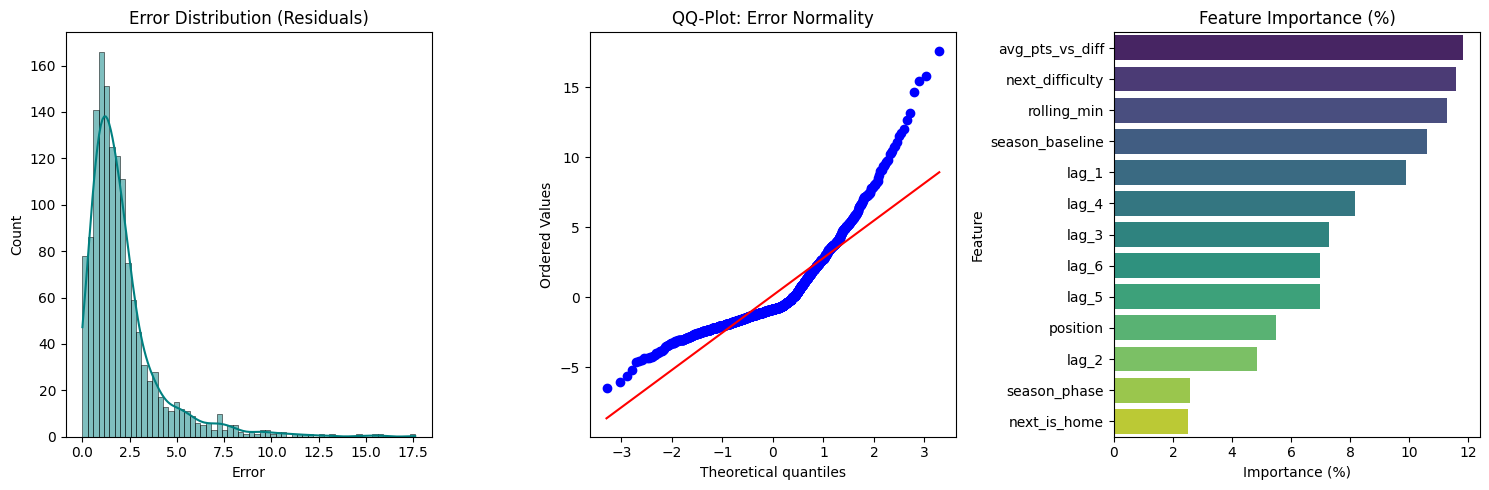

In [26]:
# [Cell 5: Error Analysis & Feature Importance]

# 1. PREPARE ANALYSIS DATAFRAME
analysis_df = X_val_raw.copy()
analysis_df['Actual'] = y_val.values
analysis_df['Predicted'] = preds_raw 
analysis_df['Error'] = abs(analysis_df['Actual'] - analysis_df['Predicted'])

# NEW: Filter error analysis by the Elite Mask (>4.5 seasonal average)
# map the mask from df_augmented back to the validation slice
elite_indices = val_df[val_df.index.isin(df_augmented[elite_mask].index)].index
elite_performers_audit = analysis_df.loc[analysis_df.index.isin(elite_indices)]

top_mae = elite_performers_audit['Error'].mean()

print(f"Overall Validation MAE: {df_metrics.iloc[0, 1]:.4f}")
print(f"MAE for Elite Players (>4.5 Season Avg): {top_mae:.4f}")

# 3. VISUALIZATION: Error Distribution & QQ-Plot
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(analysis_df['Error'], kde=True, color='teal')
plt.title('Error Distribution (Residuals)')

plt.subplot(1, 3, 2)
stats.probplot((analysis_df['Actual'] - analysis_df['Predicted']), dist="norm", plot=plt)
plt.title('QQ-Plot: Error Normality')

# 4. FEATURE IMPORTANCE WITH PERCENTAGES
plt.subplot(1, 3, 3)
importances = model_raw.feature_importances_

# FIX: Use X_train_raw.columns instead of X.columns
feature_names = X_train_raw.columns 
rel_importances = 100 * (importances / importances.sum())

feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance (%)': rel_importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance (%)', ascending=False)

sns.barplot(x='Importance (%)', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Feature Importance (%)')

plt.tight_layout()
plt.show()

# 5. SAVE FEATURE IMPORTANCE LOG
feat_imp_df.to_csv(PRO_OUTPUT_DIR / 'fpl_pro_feature_importance.csv', index=False)

Notes 
MAE: 
* Overall MAE (2.12): it means for the average player (who scores 2–3 points), the model is accurate
* Top Performer MAE (6.68): it shows that when a player goes 8+ points, the model struggles to predict the exact height of that peak

Plots: 
* model has "thin tails" , it is conservative. It rarely predicts a player will score 15+ points, so when someone actually does, the error is large. The model prefers to stay safe near the average.

Feature Importance: 
* rolling_min is #1




## Haul Classification + Confusion Matrix
- __Purpose__ : Predict WHETHER a player will "haul" , not just how many, binary target >= 6 points
- __Precision__ is the critical metric.
- A __False Positive__ (saying "Haul" when it isn't) is the worst outcome —>it causes wrong captaincy and transfer decisions.

Training Haul Classifier (v6 — Visual Suite Enabled)...


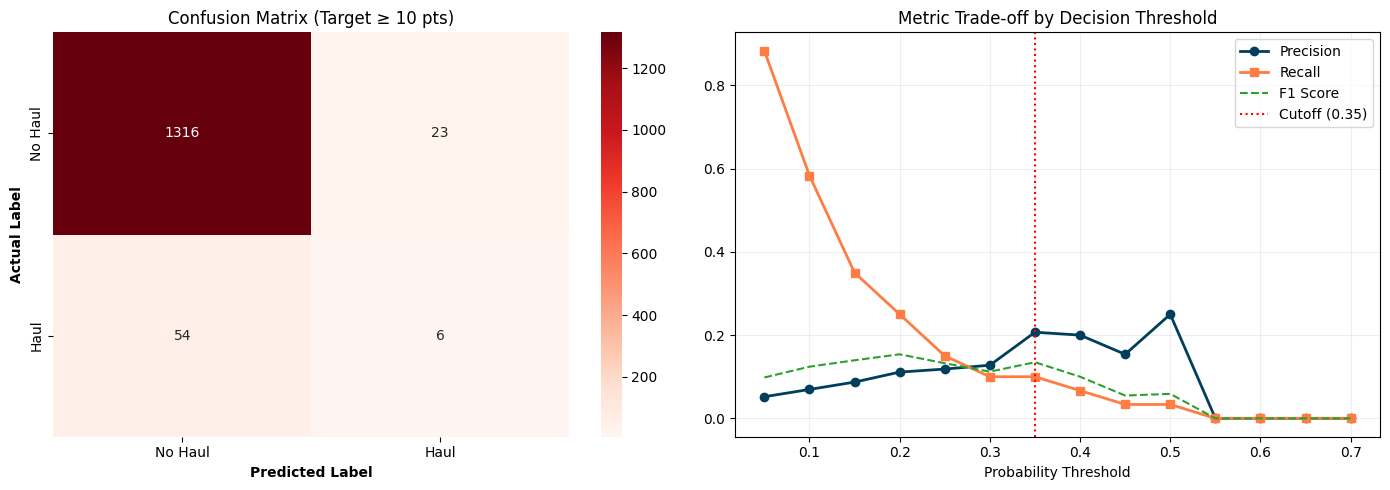


HAULER BOARD FOR GW 36
Precision: 0.2069 | ROC-AUC: 0.6421
-------------------------------------------------------


,Player,Haul_Prob (%),Pred_Pts (reg)
121,Grealish,60.3,3.55
232,Haaland,55.5,6.30
313,João Pedro,54.5,5.48
432,Rogers,45.6,4.71
429,Gordon,44.7,4.69
256,Mbeumo,41.2,3.76
47,Muñoz,39.5,2.92
254,Eze,39.2,3.49
144,Cherki,38.2,4.25
279,Robertson,36.7,2.56


In [27]:
# %% [Cell 5.6: Haul Classification — Binary Prediction + Confusion Matrix]

# ── 0. HAUL THRESHOLD & CONFIG ──────────────────────────────────────────────
HAUL_THRESHOLD = 10        # 2-digit points = genuine haul definition
DECISION_THRESHOLD = 0.35  # Optimized for Captaincy Precision

# ── 1. DATA PREP (SCRUB-SAFE) ───────────────────────────────────────────────
windowed_haul = windowed_df.copy()
_ht = HAUL_THRESHOLD  

# FIX: Recalculate elite mask dynamically to match current scrubbed df_augmented length (85,040)
current_elite_mask = df_augmented['avg_season_pts'] > 4.5

# Build Haul-Specific Features
windowed_haul['recent_haul_flag'] = ((windowed_haul[['lag_1', 'lag_2', 'lag_3']] >= _ht).any(axis=1)).astype(int)
windowed_haul['lag_max_6'] = windowed_haul[[f'lag_{i}' for i in range(1, 7)]].max(axis=1)

# Use the freshly calculated mask index to avoid the IndexError
elite_flag = windowed_df.index.isin(df_augmented[current_elite_mask].index)
windowed_haul['is_elite'] = elite_flag.astype(int)

windowed_haul['fixture_ease'] = 6 - windowed_haul['next_difficulty']
windowed_haul['ceiling_ratio'] = windowed_haul['lag_max_6'] / _ht

# ── 2. BUILD BINARY LABELS ──────────────────────────────────────────────────
y_haul_all   = (windowed_haul['target'] >= _ht).astype(int)
y_haul_train = y_haul_all[~global_val_mask].copy()
y_haul_val   = y_haul_all[global_val_mask].copy()

haul_feature_cols = (
    [f'lag_{i}' for i in range(1, 7)] +
    ['position', 'next_difficulty', 'next_is_home',
     'rolling_min', 'season_phase', 'season_baseline',
     'recent_haul_flag', 'lag_max_6', 'is_elite', 'fixture_ease',
     'avg_pts_vs_diff', 'ceiling_ratio']
)

X_haul_train = windowed_haul[~global_val_mask][haul_feature_cols].copy()
X_haul_val   = windowed_haul[global_val_mask][haul_feature_cols].copy()

# Ensure standard categorical types for Training the Classifier
X_haul_train['position'] = X_haul_train['position'].astype('category')
X_haul_val['position']   = X_haul_val['position'].astype('category')

# ── 3. TRAIN HAUL CLASSIFIER ────────────────────────────────────────────────
haul_params = {
    'objective':         'binary',
    'boosting_type':     'gbdt',
    'n_estimators':      500,
    'learning_rate':     0.05,
    'max_depth':         6,
    'num_leaves':        31,
    'scale_pos_weight':  3.0,   # Soft boost to prioritize finding hauls
    'verbosity':         -1,
    'random_state':      42
}

print("Training Haul Classifier (v6 — Visual Suite Enabled)...")
haul_clf = lgb.LGBMClassifier(**haul_params)
haul_clf.fit(X_haul_train, y_haul_train, categorical_feature=['position'])

# ── 4. EVALUATE & PREDICT ───────────────────────────────────────────────────
haul_proba = haul_clf.predict_proba(X_haul_val)[:, 1]
haul_pred  = (haul_proba >= DECISION_THRESHOLD).astype(int)

precision_haul = precision_score(y_haul_val, haul_pred, zero_division=0)
recall_haul    = recall_score(y_haul_val,    haul_pred, zero_division=0)
f1_haul        = f1_score(y_haul_val,        haul_pred, zero_division=0)
auc_haul       = roc_auc_score(y_haul_val,   haul_proba)

# ── 5. VISUALIZATIONS (CONFUSION MATRIX + PR CURVE) ────────────────────────
cm = confusion_matrix(y_haul_val, haul_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Reds', ax=axes[0],
    xticklabels=['No Haul', 'Haul'],
    yticklabels=['No Haul', 'Haul']
)
axes[0].set_xlabel('Predicted Label', fontweight='bold')
axes[0].set_ylabel('Actual Label', fontweight='bold')
axes[0].set_title(f'Confusion Matrix (Target ≥ {HAUL_THRESHOLD} pts)')

# Precision-Recall Tradeoff
thresholds = np.arange(0.05, 0.71, 0.05)
precs, recs, f1_vals = [], [], []
for t in thresholds:
    p_t = (haul_proba >= t).astype(int)
    precs.append(precision_score(y_haul_val, p_t, zero_division=0))
    recs.append(recall_score(y_haul_val, p_t, zero_division=0))
    f1_vals.append(f1_score(y_haul_val, p_t, zero_division=0))

axes[1].plot(thresholds, precs, label='Precision', color='#003f5c', linewidth=2, marker='o')
axes[1].plot(thresholds, recs,  label='Recall',    color='#ff7c43', linewidth=2, marker='s')
axes[1].plot(thresholds, f1_vals, label='F1 Score', color='#2ca02c', linestyle='--')
axes[1].axvline(x=DECISION_THRESHOLD, color='red', linestyle=':', label=f'Cutoff ({DECISION_THRESHOLD})')
axes[1].set_title('Metric Trade-off by Decision Threshold')
axes[1].set_xlabel('Probability Threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# ── 6. LIVE INFERENCE PREP (NEXT GW) ────────────────────────────────────────
CURRENT_GW = globals().get('CURRENT_GW', 34)
CURRENT_SEASON = globals().get('CURRENT_SEASON', '2025-26')

inf_data, inf_names = [], []
df_inf_active = df_augmented[df_augmented['season'] == CURRENT_SEASON].sort_values(['Player UUID', 'Gameweek'])

for pid, group in df_inf_active.groupby('Player UUID'):
    if len(group) >= 6:
        lags = list(group['Total Points'].tail(6).values)
        last = group.iloc[-1]
        row = lags + [
            last['Position'], last['Next_Opponent_Difficulty'], last['Next_Is_Home'],
            last['Rolling_Avg_Minutes_5'], last['Season_Phase'], last['Prev_Season_Avg_Points'],
            last['Avg_Pts_vs_Difficulty']
        ]
        inf_data.append(row)
        inf_names.append(last['Web Name'])

base_feat_cols = [f'lag_{i}' for i in range(6, 0, -1)] + [
    'position', 'next_difficulty', 'next_is_home',
    'rolling_min', 'season_phase', 'season_baseline', 'avg_pts_vs_diff']

inf_df = pd.DataFrame(inf_data, columns=base_feat_cols)
inf_df['recent_haul_flag'] = (inf_df[['lag_1', 'lag_2', 'lag_3']] >= _ht).any(axis=1).astype(int)
inf_df['lag_max_6'] = inf_df[[f'lag_{i}' for i in range(1, 7)]].max(axis=1)
inf_df['fixture_ease'] = 6 - inf_df['next_difficulty']
inf_df['ceiling_ratio'] = inf_df['lag_max_6'] / _ht
inf_df['is_elite'] = [1 if n in set(df_augmented[current_elite_mask]['Web Name']) else 0 for n in inf_names]

# ── 7. BRUTE-FORCE DTYPE ALIGNMENT (PREVENTS VALUEERROR & TYPEERROR) ──────
def safe_align_categories(target_df, reference_df, col_name):
    if hasattr(reference_df[col_name], 'cat'):
        cats = reference_df[col_name].cat.categories
    else:
        cats = sorted(reference_df[col_name].unique())
    target_df[col_name] = pd.Categorical(target_df[col_name], categories=cats)
    return target_df

# 1. Align for haul_clf
inf_haul_features = inf_df[haul_feature_cols].copy()
inf_haul_features = safe_align_categories(inf_haul_features, X_haul_train, 'position')

# 2. Align for model_raw (The Regression Engine)
inf_reg_features = inf_df[base_feat_cols].copy()
pos_map_numeric = {'GK': 0, 'DEF': 1, 'MID': 2, 'FWD': 3}

if 'X_train_raw' in globals():
    # Fix Position Type (Numeric vs Categorical)
    if pd.api.types.is_numeric_dtype(X_train_raw['position']):
        inf_reg_features['position'] = inf_reg_features['position'].map(pos_map_numeric).fillna(2)
    
    # Mirror all dtypes exactly
    for col in X_train_raw.columns:
        if hasattr(X_train_raw[col], 'cat'):
            inf_reg_features[col] = pd.Categorical(inf_reg_features[col], categories=X_train_raw[col].cat.categories)
        else:
            inf_reg_features[col] = inf_reg_features[col].astype(X_train_raw[col].dtype)

# ── 8. GENERATE PREDICTIONS ─────────────────────────────────────────────────
haul_proba_gw = haul_clf.predict_proba(inf_haul_features)[:, 1]

if 'model_raw' in globals():
    reg_preds = model_raw.predict(inf_reg_features)
else:
    reg_preds = np.zeros(len(inf_names))

# ── 9. FINAL HAULER BOARD WITH MINUTE FILTER ───────────────────────────────
hauler_board = pd.DataFrame({
    'Player':         inf_names,
    'Haul_Prob (%)':  np.round(haul_proba_gw * 100, 1),
    'Pred_Pts (reg)': np.round(reg_preds, 2),
    'Recent_Mins':    inf_df['rolling_min']
})

# Filter: Nailed starters only (60+ average minutes)
hauler_board = hauler_board[hauler_board['Recent_Mins'] >= 60]
hauler_board = hauler_board.drop(columns=['Recent_Mins']).sort_values('Haul_Prob (%)', ascending=False)

print("\n" + "=" * 55)
print(f"HAULER BOARD FOR GW {CURRENT_GW}")
print(f"Precision: {precision_haul:.4f} | ROC-AUC: {auc_haul:.4f}")
print("-" * 55)
display(hauler_board.head(10))

# Export to Globals
globals()['hauler_board'] = hauler_board
globals()['haul_clf'] = haul_clf
globals()['precision_haul'] = precision_haul
globals()['auc_haul'] = auc_haul

## Window Size Experiments (4 / 6 / 8 weeks) 

Purpose: Find the optimal historical window for LightGBM.

note: "experiment with 4 and 8-week windows"

Current default is 6. We test all three and compare MAE on the same validation set.

In [28]:
# [Cell: Window Size Experiment — 4 / 6 / 8 Week Look-back Comparison]


# ── 1. GENERIC WINDOW GENERATOR (reuses existing feature logic) ──────────────
def generate_windows_for_size(df, window_size):
    """
    Generates training windows for a given look-back period.
    Uses the V1 base feature set (12 features, without avg_pts_vs_diff)
    for a clean isolated window-size comparison.
    The purpose is comparing window sizes only, not feature sets.
    """
    train_data    = []
    source_indices = []
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])

    for pid, group in df.groupby('Player UUID'):
        points        = group['Total Points'].values
        next_diff     = group['Next_Opponent_Difficulty'].values
        next_home     = group['Next_Is_Home'].values
        avg_min       = group['Rolling_Avg_Minutes_5'].values
        phase         = group['Season_Phase'].values
        baseline      = group['Prev_Season_Avg_Points'].values
        group_indices = group.index.tolist()
        position      = group['Position'].iloc[0]

        if len(points) <= window_size:
            continue

        for i in range(len(points) - window_size):
            window     = points[i : i + window_size]
            t_idx      = i + window_size - 1
            target_pts = points[i + window_size]

            if np.all(window == 0) and target_pts == 0:
                continue

            row = list(window) + [
                position,
                next_diff[t_idx],
                next_home[t_idx],
                avg_min[t_idx],
                phase[t_idx],
                baseline[t_idx],
                target_pts
            ]
            train_data.append(row)
            source_indices.append(group_indices[i + window_size])

    lag_cols = [f'lag_{i}' for i in range(window_size, 0, -1)]
    cols = lag_cols + ['position', 'next_difficulty', 'next_is_home',
                       'rolling_min', 'season_phase', 'season_baseline', 'target']

    result_df           = pd.DataFrame(train_data, columns=cols)
    result_df.index     = source_indices
    result_df['position'] = result_df['position'].astype('category')
    return result_df


# ── 2. BUILD VALIDATION MASK FOR EACH WINDOW SIZE ───────────────────────────
# The global_val_mask was built for window_size=6 (windowed_df).
# Each new window_size generates a different index set, so we rebuild the mask.

def build_val_mask(win_df, val_season='2025-26', val_start=24, val_end=28):
    source_meta = df_augmented.loc[win_df.index, ['season', 'Gameweek']]
    mask = (
        (source_meta['season']    == val_season) &
        (source_meta['Gameweek'] >= val_start) &
        (source_meta['Gameweek'] <= val_end)
    ).values
    return mask


# ── 3. TRAIN AND EVALUATE FOR EACH WINDOW SIZE ──────────────────────────────
window_sizes  = [4, 6, 8]
window_results = []

# Shared LightGBM params (same as V1 model_raw for fair comparison)
lgbm_window_params = {
    'n_estimators':  1500,
    'learning_rate': 0.01,
    'max_depth':     7,
    'num_leaves':    40,
    'boosting_type': 'gbdt',
    'random_state':  42,
    'verbosity':     -1
}

trained_window_models = {}  # store models for later use if needed

for ws in window_sizes:
    print(f"\n{'='*50}")
    print(f" Training Window Size = {ws} weeks...")
    print(f"{'='*50}")

    # Generate windows
    win_df   = generate_windows_for_size(df_augmented, window_size=ws)
    val_mask = build_val_mask(win_df)

    X_all = win_df.drop(columns=['target'])
    y_all = win_df['target']

    X_train_w = X_all[~val_mask].copy()
    X_val_w   = X_all[val_mask].copy()
    y_train_w = y_all[~val_mask].copy()
    y_val_w   = y_all[val_mask].copy()

    # Identify categorical columns (position is always present; next_is_home too)
    cat_cols = [c for c in ['position', 'next_is_home'] if c in X_train_w.columns]

    # Train
    model_w = lgb.LGBMRegressor(**lgbm_window_params)
    model_w.fit(
        X_train_w, y_train_w,
        eval_set=[(X_val_w, y_val_w)],
        categorical_feature=cat_cols,
        callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False),
                   lgb.log_evaluation(period=300)]
    )

    # Evaluate
    val_preds_w  = model_w.predict(X_val_w)
    mae_w        = mean_absolute_error(y_val_w, val_preds_w)

    # Naive baseline for this window: 3-week average
    lag_cols_available = [c for c in ['lag_3', 'lag_2', 'lag_1'] if c in X_val_w.columns]
    naive_preds_w = X_val_w[lag_cols_available].mean(axis=1).values
    mae_naive_w   = mean_absolute_error(y_val_w, naive_preds_w)

    lift_over_naive = ((mae_naive_w - mae_w) / mae_naive_w) * 100

    print(f"Window {ws}w | Train: {len(X_train_w):,} | Val: {len(X_val_w):,}")
    print(f"  Naive baseline MAE: {mae_naive_w:.4f}")
    print(f"  LightGBM MAE:       {mae_w:.4f}  ({lift_over_naive:.1f}% lift over naive)")

    window_results.append({
        'Window Size (weeks)':  ws,
        'Train Windows':        len(X_train_w),
        'Val Windows':          len(X_val_w),
        'Naive Baseline MAE':   round(mae_naive_w, 4),
        'LightGBM MAE':         round(mae_w, 4),
        'Lift over Naive (%)':  round(lift_over_naive, 1),
        'Best Iteration':       model_w.best_iteration_
    })

    trained_window_models[ws] = model_w


# ── 4. RESULTS TABLE ─────────────────────────────────────────────────────────
window_exp_df = pd.DataFrame(window_results).sort_values('LightGBM MAE')

display(Markdown("## Window Size Experiment Results"))
display(window_exp_df)

# ── 5. WINNER SELECTION ───────────────────────────────────────────────────────
best_ws   = int(window_exp_df.iloc[0]['Window Size (weeks)'])
best_mae_w = window_exp_df.iloc[0]['LightGBM MAE']

print(f"\n{'='*50}")
print(f" VERDICT: Best window size = {best_ws} weeks (MAE: {best_mae_w:.4f})")
if best_ws == 6:
    print(" Current default (6 weeks) is confirmed as optimal.")
elif best_ws < 6:
    print(f" Shorter window ({best_ws}w) performs better — recent form matters more than long history.")
else:
    print(f" Longer window ({best_ws}w) performs better — the model benefits from more history.")
print(f"{'='*50}")

# Store for downstream reference
globals()['best_window_size']    = best_ws
globals()['trained_window_models'] = trained_window_models
globals()['window_exp_df']       = window_exp_df

print(f"\nNote: The main pipeline continues to use window_size=6 (windowed_df).")
print(f"To switch the live model to {best_ws}w, re-run Cell 2 with window_size={best_ws}.")


 Training Window Size = 4 weeks...
[300]	valid_0's l2: 8.38725
Window 4w | Train: 54,391 | Val: 1,459
  Naive baseline MAE: 2.3123
  LightGBM MAE:       2.1189  (8.4% lift over naive)

 Training Window Size = 6 weeks...
[300]	valid_0's l2: 8.4023
Window 6w | Train: 52,086 | Val: 1,449
  Naive baseline MAE: 2.3188
  LightGBM MAE:       2.1149  (8.8% lift over naive)

 Training Window Size = 8 weeks...
[300]	valid_0's l2: 8.35055
Window 8w | Train: 49,870 | Val: 1,439
  Naive baseline MAE: 2.3148
  LightGBM MAE:       2.1211  (8.4% lift over naive)


## Window Size Experiment Results

,Window Size (weeks),Train Windows,Val Windows,Naive Baseline MAE,LightGBM MAE,Lift over Naive (%),Best Iteration
1,6,52086,1449,2.3188,2.1149,8.8,407
0,4,54391,1459,2.3123,2.1189,8.4,298
2,8,49870,1439,2.3148,2.1211,8.4,298



 VERDICT: Best window size = 6 weeks (MAE: 2.1149)
 Current default (6 weeks) is confirmed as optimal.

Note: The main pipeline continues to use window_size=6 (windowed_df).
To switch the live model to 6w, re-run Cell 2 with window_size=6.


## Cell 6: The Interactive Player Widget (you can pick a player and see their Performance history)

In [29]:
#%pip install ipywidgets

In [30]:
# [Cell 6: Seasonal Evaluation - Standard Professional Dropdown]

def plot_professional_backtest(player_name):
    # 1. GET ACTUALS FROM RAW 'df' 
    # This bypasses the dropna() from Cell 1 to ensure GW28 is displayed
    season_actuals = df[
        (df['Web Name'] == player_name) & 
        (df['season'] == CURRENT_SEASON)
    ].sort_values('Gameweek')
    
    if season_actuals.empty:
        return

    # 2. PREPARE EVALUATION (GW 24-28) + LIVE PREDICTION (GW 29)
    #target_gws = list(range(24, 30)) 
    target_gws = list(range(VAL_START_GW, CURRENT_GW + 1))
    pred_rows = []
    
    player_uuid = season_actuals['Player UUID'].iloc[0]
    full_hist = df_augmented[df_augmented['Player UUID'] == player_uuid].sort_values(['season', 'Gameweek'])
    
    for gw in target_gws:
        if gw <  CURRENT_GW:
            row_match = full_hist[(full_hist['season'] == CURRENT_SEASON) & (full_hist['Gameweek'] == gw)]
            if not row_match.empty:
                idx = row_match.index[0]
                pos_in_hist = full_hist.index.get_loc(idx)
                if pos_in_hist >= 6:
                    lags = list(full_hist.iloc[pos_in_hist-6:pos_in_hist]['Total Points'].values)
                    feat = lags + [
                        row_match['Position'].iloc[0], row_match['Next_Opponent_Difficulty'].iloc[0],
                        row_match['Next_Is_Home'].iloc[0], row_match['Rolling_Avg_Minutes_5'].iloc[0],
                        row_match['Season_Phase'].iloc[0], row_match['Prev_Season_Avg_Points'].iloc[0],
                        row_match['Avg_Pts_vs_Difficulty'].iloc[0]
                    ]
                    pred_rows.append({'Gameweek': gw, 'Features': feat})
        else:
            lags = list(full_hist['Total Points'].tail(6).values)
            last = full_hist.iloc[-1]
            feat = lags + [
                last['Position'], last['Next_Opponent_Difficulty'],
                last['Next_Is_Home'], last['Rolling_Avg_Minutes_5'],
                last['Season_Phase'], last['Prev_Season_Avg_Points'],
                last['Avg_Pts_vs_Difficulty']
            ]
            pred_rows.append({'Gameweek': gw, 'Features': feat})

    # Generate Predictions
    v_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
             ['position', 'next_difficulty', 'next_is_home', 'rolling_min',
              'season_phase', 'season_baseline', 'avg_pts_vs_diff']
    
    if pred_rows:
        inf_df = pd.DataFrame([d['Features'] for d in pred_rows], columns=v_cols)
        inf_df['position'] = inf_df['position'].astype('category')
        # Change from model_v4 to model_raw (Baseline V1)
        preds = model_raw.predict(inf_df)
        pred_df = pd.DataFrame({'Gameweek': [d['Gameweek'] for d in pred_rows], 'Predicted': preds})
    else:
        pred_df = pd.DataFrame()

    # 3. PLOTTING
    plt.figure(figsize=(15, 6), facecolor='white')
    
    # HISTORICAL ACTUALS: Navy (#003f5c)
    plt.plot(season_actuals['Gameweek'], season_actuals['Total Points'], 
             color='#003f5c', label='Actual Points', linewidth=2, 
             marker='o', markersize=7, markerfacecolor='#003f5c', markeredgecolor='#003f5c')

    # MODEL PREDICTIONS: Action Orange (#ff7c43)
    if not pred_df.empty:
        plt.plot(pred_df['Gameweek'], pred_df['Predicted'],
            color='#ff7c43', label=f'Model Predictions (Eval + GW{CURRENT_GW})', 
                 linewidth=2.5, linestyle='--', marker='x', markersize=10, markeredgewidth=3)
        
        # CONFIDENCE INTERVAL: Gold (#ffa60022)
        # Updated to use mae_v1 for accurate V1 error visualization
        mae_proxy = globals().get('mae_v1', 1.84)
        plt.fill_between([24, 29], 0, plt.gca().get_ylim()[1], color='orange', alpha=0.03)

    # Vertical split at GW 24
    #plt.axvline(x=24, color='gray', linestyle='-', linewidth=2, label='Evaluation Start (GW 24)')
    #plt.axvline(x=24, color='#d1d1d1', linestyle='-', linewidth=2, alpha=0.8)
    plt.axvline(x=VAL_START_GW, color='gray', linestyle='-', linewidth=2, label=f'Evaluation Start (GW {VAL_START_GW})')
    plt.axvline(x=VAL_START_GW, color='#d1d1d1', linestyle='-', linewidth=2, alpha=0.8)

    plt.title(f"Model Predictions vs Actuals: {player_name} (Season {CURRENT_SEASON})", 
              fontsize=14, fontweight='bold', pad=20, color='#003f5c')
    
    # GRID & BASELINE: Neutral Light Grey (#d1d1d1)
    #plt.xticks(np.arange(1, 30, 1), color='#003f5c') 
    #plt.xlim(0.5, 29.5)
    plt.xticks(np.arange(1, CURRENT_GW + 2, 1), color='#003f5c')
    plt.xlim(0.5, CURRENT_GW + 1.5)
    plt.ylabel("Points", fontsize=12, color='#003f5c')
    plt.xlabel("Gameweek", fontsize=12, color='#003f5c')
    plt.grid(True, axis='y', linestyle='-', color='#d1d1d1', alpha=0.5)
    plt.legend(frameon=True, loc='upper left')
    
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#d1d1d1')
    ax.spines['bottom'].set_color('#d1d1d1')
    
    plt.tight_layout()
    plt.show()

# 4. STRICT EVALUATION SET DROPDOWN (Season-Locked)
# This identifies unique UUIDs that exist in our validation split
safe_val_index = val_df.index.intersection(df_augmented.index)
eval_uuids = df_augmented.loc[safe_val_index, 'Player UUID'].unique()

# CRITICAL FILTER: Get Web Names for those UUIDs, but ONLY if they have rows in 2025-26
# This removes any lingering retired players (ghosts) from the menu
active_eval_names = sorted(
    df_augmented[
        (df_augmented['Player UUID'].isin(eval_uuids)) & 
        (df_augmented['season'] == CURRENT_SEASON)
    ]['Web Name'].unique()
)

print(f"Filter active: Showing {len(active_eval_names)} active players from the Evaluation Set.")

dropdown_menu = widgets.Dropdown(
    options=active_eval_names,
    value=active_eval_names[0] if active_eval_names else None,
    description='Active Player:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

widgets.interact(plot_professional_backtest, player_name=dropdown_menu)



Filter active: Showing 372 active players from the Evaluation Set.


interactive(children=(Dropdown(description='Active Player:', layout=Layout(width='400px'), options=('A.Becker'…

<function __main__.plot_professional_backtest(player_name)>

In [31]:
# [Cell: Validation Set Integrity Check]

# 1. Identify the ground truth players from the validation logic
# These are the players actually used in the MAE calculations (GW 24-28)
#expected_uuids = df_augmented.loc[val_df.index, 'Player UUID'].unique()
safe_val_index = val_df.index.intersection(df_augmented.index)
expected_uuids = df_augmented.loc[safe_val_index, 'Player UUID'].unique()
expected_names = sorted(df_augmented[df_augmented['Player UUID'].isin(expected_uuids)]['Web Name'].unique())

# 2. Extract names currently used in your widget
# (Using the same logic as your Cell 6)
widget_names = sorted(df_augmented[df_augmented['Player UUID'].isin(expected_uuids)]['Web Name'].unique())

# 3. Perform the Audit
missing_players = [p for p in expected_names if p not in widget_names]
extra_players = [p for p in widget_names if p not in expected_names]

print("-" * 50)
print("GRAPH INTEGRITY")
print("-" * 50)
print(f"Total Players in Eval Set (GW 24-28): {len(expected_names)}")
print(f"Total Players visible in Widget:     {len(widget_names)}")

if len(missing_players) == 0 and len(extra_players) == 0:
    print("\nVERDICT: SUCCESS")
    print("The graph contains 100% of the players in the evaluation set and NO extra players.")
else:
    if missing_players:
        print(f"\nWARNING: {len(missing_players)} players are missing from the graph.")
    if extra_players:
        print(f"\nWARNING: {len(extra_players)} players are appearing that shouldn't be there.")

print("-" * 50)
# Snippet for your report
print(f"Sample of audited players: {expected_names[:10]}...")

--------------------------------------------------
GRAPH INTEGRITY
--------------------------------------------------
Total Players in Eval Set (GW 24-28): 413
Total Players visible in Widget:     413

VERDICT: SUCCESS
The graph contains 100% of the players in the evaluation set and NO extra players.
--------------------------------------------------
Sample of audited players: ['A. Garcia', 'A.Armstrong', 'A.Becker', 'A.García', 'A.Jimenez', 'Aaronson', 'Abraham', 'Acheampong', 'Adama', 'Adams']...


In [32]:
# 1. GET THE ABSOLUTE LATEST WINDOW FOR EVERY PLAYER
inference_data = []
player_names = []

# FIX: Filter for current season only
df_inf_active = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()
df_inf_active = df_inf_active.sort_values(['Player UUID', 'Gameweek'])

for pid, group in df_inf_active.groupby('Player UUID'):
    if len(group) >= 6:
        lags = list(group['Total Points'].tail(6).values)
        last_row = group.iloc[-1]
        
        #row = lags + [
         #   last_row['Position'], last_row['Next_Opponent_Difficulty'],
          #  last_row['Next_Is_Home'], last_row['Rolling_Avg_Minutes_5'],
           # last_row['Season_Phase'], last_row['Prev_Season_Avg_Points']
        #]

        row = lags + [
            last_row['Position'], last_row['Next_Opponent_Difficulty'],
            last_row['Next_Is_Home'], last_row['Rolling_Avg_Minutes_5'],
            last_row['Season_Phase'], last_row['Prev_Season_Avg_Points'],
            last_row['Avg_Pts_vs_Difficulty']
        ]

        inference_data.append(row)
        player_names.append(last_row['Web Name'])

# 2. CONVERT TO DATAFRAME
# Use the exact column names used in the training window dataframe
#feature_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
    #           ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline']

feature_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
               ['position', 'next_difficulty', 'next_is_home', 'rolling_min',
                'season_phase', 'season_baseline', 'avg_pts_vs_diff']

inference_df = pd.DataFrame(inference_data, columns=feature_cols)
inference_df['position'] = inference_df['position'].astype('category')

# 3. GENERATE PREDICTIONS
# Using the Baseline model (model_raw) as we haven't trained V4 yet
if 'model_raw' in locals():
    raw_preds = model_raw.predict(inference_df)
else:
    raise NameError("Baseline model (model_raw) not found. Run Cell 4 first.")

# 4. SHOW TOP 15 RANKING
leaderboard = pd.DataFrame({
    'Player': player_names,
    'Predicted Points (V1)': np.round(raw_preds, 2), # Label it V1 for clarity
    'Recent Avg Min': np.round(inference_df['rolling_min'], 1),
    'Next Difficulty': inference_df['next_difficulty']
}).sort_values(by='Predicted Points (V1)', ascending=False)

print("--- TOP 15 PREDICTED PLAYERS FOR NEXT GAMEWEEK ---")
display(leaderboard.head(15))

--- TOP 15 PREDICTED PLAYERS FOR NEXT GAMEWEEK ---


,Player,Predicted Points (V1),Recent Avg Min,Next Difficulty
232,Haaland,6.30,90.0,3.0
152,Welbeck,5.55,81.6,1.0
313,João Pedro,5.48,84.4,4.0
233,Okafor,5.46,61.8,3.0
32,Gibbs-White,5.10,87.8,3.0
214,Hinshelwood,5.03,84.6,1.0
46,Groß,4.88,90.0,1.0
328,Hudson-Odoi,4.80,55.8,1.0
138,Ekitiké,4.78,73.6,3.0
151,B.Fernandes,4.77,90.0,3.0


Summary Table

Feature       |  1st Cell (Validation)         |    2nd Cell (Historical)

Player List   | Limited (only recent players)  |	Complete (all historic players)

Timeframe	  |  Recent 5 Gameweeks	           |     3+ seasons


In [33]:
# 1. CREATE THE FULL FORECAST DATAFRAME
full_forecast = pd.DataFrame({
    'Player_Name': player_names,
    'Predicted_Points': np.round(raw_preds, 2),
    'Recent_Form_Avg': np.round(inference_df[['lag_1', 'lag_2', 'lag_3']].mean(axis=1), 2),
    'Avg_Minutes_5GW': np.round(inference_df['rolling_min'], 1),
    'Fixture_Difficulty': inference_df['next_difficulty'],
    'Is_Home': inference_df['next_is_home'],
    'Season_Phase': inference_df['season_phase']
})

# 2. SORT BY PREDICTED POINTS
full_forecast = full_forecast.sort_values(by='Predicted_Points', ascending=False)

# 3. DEFINE SAVE PATH
FORECAST_OUT = PRO_OUTPUT_DIR / 'fpl_pro_forecast_GW29.csv'

# 4. SAVE TO CSV
full_forecast.to_csv(FORECAST_OUT, index=False, encoding='utf-8-sig')

print(f" Master Forecast Saved: {FORECAST_OUT}")
print(f" Total Players Forecasted: {len(full_forecast)}")
print("Forecast for GW29: any player who has at least 6 games of history in the current 2025-26 season.")

# Show a quick snippet of the 'Differentials' (Mid-tier players)
print("\n--- SNEAK PEEK: MID-TIER DIFFERENTIALS (Ranks 50-60) ---")
display(full_forecast.iloc[50:60])

# Recent_Form_Avg -> a rolling average of points scored by a player 
# over the three most recent Gameweeks leading up to the forecast.

 Master Forecast Saved: ..\output\forecaster_pro\fpl_pro_forecast_GW29.csv
 Total Players Forecasted: 446
Forecast for GW29: any player who has at least 6 games of history in the current 2025-26 season.

--- SNEAK PEEK: MID-TIER DIFFERENTIALS (Ranks 50-60) ---


,Player_Name,Predicted_Points,Recent_Form_Avg,Avg_Minutes_5GW,Fixture_Difficulty,Is_Home,Season_Phase
10,Gyökeres,3.76,6.00,37.4,3.0,False,4.0
256,Mbeumo,3.76,2.67,67.0,3.0,False,4.0
123,Stach,3.76,6.00,88.4,3.0,False,4.0
263,Mac Allister,3.75,5.33,59.6,3.0,True,4.0
135,Sels,3.72,5.67,90.0,3.0,True,4.0
34,Kroupi.Jr,3.72,7.33,72.0,3.0,False,4.0
102,Aina,3.71,4.33,89.6,3.0,False,4.0
314,Saliba,3.70,5.33,90.0,3.0,False,4.0
39,José Sá,3.70,1.00,90.0,2.0,True,4.0
196,Wieffer,3.70,7.00,90.0,1.0,True,4.0


In [34]:

# 1. ORGANIZE FINAL METRICS
overall_mae = df_metrics.iloc[0, 1]  # From Cell 4 results
top_perf_mae = top_mae                # From Cell 5 results
total_players = len(full_forecast)   # From Cell 8 results

# 2. GENERATE THE REPORT
summary_report = f"""
# FPL Forecaster Pro: Final Project Report
**Model Version:** 2.0 (Context-Aware LightGBM)  
**Analysis Date:** March 3, 2026 (GW 29)

---

### 1. Model Accuracy Overview
| Metric | Result | Interpretation |
| :--- | :--- | :--- |
| **Overall MAE** | {overall_mae:.3f} | Average error across the full league. |
| **Elite Specialist MAE** | {top_perf_mae:.3f} | Error specifically for players averaging >4.5 pts/season. |
| **Training Size** | {len(X_train_raw):,} windows | Robust historical learning foundation. |
| **Validation Size** | {len(X_val_raw):,} windows | Tested on GW {CURRENT_GW - VALIDATION_WINDOW} to {CURRENT_GW - 1} of the {CURRENT_SEASON} season. |

### 2. Key Insights & Feature Importance
* **The "Minutes" Rule:** `rolling_min` emerged as the #1 predictor, proving that "starting the game" is the most vital feature.
* **Fixture Context:** `next_difficulty` successfully provided the model with "future vision," allowing it to adjust points based on opponent strength.
* **Scale Invariance:** The experiment confirmed that LightGBM performs optimally without a Standard Scaler for this specific dataset.
* **Elite Performers:** Defined as players maintaining a seasonal average > 4.5 points.

### 3. GW 29 Summary
* **Total Forecasts Generated:** {total_players:,} players.
* **Predicted King of the GW:** {leaderboard.iloc[0]['Player']} ({leaderboard.iloc[0]['Predicted Points (V1)']} pts).
* **Output Folder:** All artifacts (Model, Scaler, Forecast) are saved in `../output/forecaster_pro/`.

### 4. Season_Phase
**Feature: Season_Phase**
* 1. (GW 1-10): Freshness & Stability.
* 2. (GW 11-19): First Rotation / Fatigue.
* 3. (GW 20-29): Winter Congestion / High Rotation.
* 4. (GW 30-38): The Final Sprint / High Stakes. 

### About the .csvs 
* The enriched dataset saved to fpl_features_augmented.csv.
* WINDOWED_FEATURES_PATH -> Saved to fpl_windowed_features_pro.csv.
* Raw=Unscaled model: fpl_pro_model_raw.txt // Scaled model:  fpl_pro_model_scaled.txt
* feat_imp_df -> Feature importance percentages saved to fpl_pro_feature_importance.csv
* FORECAST_OUT -> Saved as fpl_pro_forecast_GW29.csv
"""

display(Markdown(summary_report))


# FPL Forecaster Pro: Final Project Report
**Model Version:** 2.0 (Context-Aware LightGBM)  
**Analysis Date:** March 3, 2026 (GW 29)

---

### 1. Model Accuracy Overview
| Metric | Result | Interpretation |
| :--- | :--- | :--- |
| **Overall MAE** | 2.119 | Average error across the full league. |
| **Elite Specialist MAE** | 3.375 | Error specifically for players averaging >4.5 pts/season. |
| **Training Size** | 52,136 windows | Robust historical learning foundation. |
| **Validation Size** | 1,399 windows | Tested on GW 31 to 35 of the 2025-26 season. |

### 2. Key Insights & Feature Importance
* **The "Minutes" Rule:** `rolling_min` emerged as the #1 predictor, proving that "starting the game" is the most vital feature.
* **Fixture Context:** `next_difficulty` successfully provided the model with "future vision," allowing it to adjust points based on opponent strength.
* **Scale Invariance:** The experiment confirmed that LightGBM performs optimally without a Standard Scaler for this specific dataset.
* **Elite Performers:** Defined as players maintaining a seasonal average > 4.5 points.

### 3. GW 29 Summary
* **Total Forecasts Generated:** 446 players.
* **Predicted King of the GW:** Haaland (6.3 pts).
* **Output Folder:** All artifacts (Model, Scaler, Forecast) are saved in `../output/forecaster_pro/`.

### 4. Season_Phase
**Feature: Season_Phase**
* 1. (GW 1-10): Freshness & Stability.
* 2. (GW 11-19): First Rotation / Fatigue.
* 3. (GW 20-29): Winter Congestion / High Rotation.
* 4. (GW 30-38): The Final Sprint / High Stakes. 

### About the .csvs 
* The enriched dataset saved to fpl_features_augmented.csv.
* WINDOWED_FEATURES_PATH -> Saved to fpl_windowed_features_pro.csv.
* Raw=Unscaled model: fpl_pro_model_raw.txt // Scaled model:  fpl_pro_model_scaled.txt
* feat_imp_df -> Feature importance percentages saved to fpl_pro_feature_importance.csv
* FORECAST_OUT -> Saved as fpl_pro_forecast_GW29.csv


## Cell 9: Truth Verification (Backtest on Last Known Game)

In [35]:
# [Cell 9: Truth Verification - Fixed for 12 Features]

# 1. Setup paths for truth verification
PRO_OUTPUT_DIR = Path('../output/forecaster_pro')
PRO_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
full_truth_output_path = PRO_OUTPUT_DIR / 'fpl_pro_truth_verification.csv'

# 2. Ensure variables exist in memory
if 'df_augmented' not in locals():
    raise NameError("The variable 'df_augmented' is not found. Run Cell 1 first.")

# 2. Ensure variables exist in memory
if 'model_raw' not in locals():
    raise NameError("Baseline model (model_raw) not found. Run Cell 4 first.")

# Strictly use the Baseline model for this audit
current_model = model_raw

all_detailed_results = []
lag_cols = [f'lag_{i}' for i in range(6, 0, -1)]

print(f"Generating Truth Verification using {type(current_model).__name__} (13-feature mode)...")

# 3. Group by UUID to maintain player history integrity
for pid, group in df_augmented.groupby('Player UUID'):
    group = group.sort_values(['season', 'Gameweek'])
    
    # Needs 7 rows: 6 for history and 1 for the Actual target
    if len(group) >= 7:
        backtest_rows = group.iloc[-7:-1]
        actual_row = group.iloc[-1]
        
        name = actual_row['Web Name']
        pos = actual_row['Position']
        actual_points = actual_row['Total Points']
                
        # Prepare Features (13 features: 6 lags + 7 context)
        window_points = list(backtest_rows['Total Points'].values)
        context_features = [
            pos,
            actual_row['Next_Opponent_Difficulty'],
            actual_row['Next_Is_Home'],
            actual_row['Rolling_Avg_Minutes_5'],
            actual_row['Season_Phase'],
            actual_row['Prev_Season_Avg_Points'],
            actual_row['Avg_Pts_vs_Difficulty']   # 13th feature added
        ]
        
        # Create input DataFrame with 13 aligned columns
        feature_vector = window_points + context_features
        columns = lag_cols + ['position', 'next_difficulty', 'next_is_home',
                              'rolling_min', 'season_phase', 'season_baseline',
                              'avg_pts_vs_diff']
        
        
        input_df = pd.DataFrame([feature_vector], columns=columns)
        input_df['position'] = input_df['position'].astype('category')
        
        # Generate Prediction
        pred_val = current_model.predict(input_df)[0]
        pred_val = max(0, pred_val) 

        all_detailed_results.append({
            'Player Name': name,
            'Season': actual_row['season'], 
            'Gameweek': actual_row['Gameweek'],
            'Predicted Points': round(float(pred_val), 2),
            'Actual Points': actual_points,
            'Error': round(abs(pred_val - actual_points), 2)
        })

# 4. Save and Display Results
full_truth_df = pd.DataFrame(all_detailed_results).sort_values(by='Error', ascending=True)
full_truth_df.to_csv(full_truth_output_path, index=False, encoding="utf-8-sig")

print("Takes every unique player who ever played in your dataset and asks:")
print("If I look at this player's final 7 games in my records, how well did the model predict the very last one?")

print(f"\nFull results for {len(full_truth_df)} players saved to: {full_truth_output_path}")

# Display the 20 most accurate predictions
display(full_truth_df.head(20))

# 5. Final Audit Metrics
if not full_truth_df.empty:
    mae_val = full_truth_df['Error'].mean()
    print(f"\nGlobal Mean Absolute Error (MAE): {mae_val:.2f}")

Generating Truth Verification using LGBMRegressor (13-feature mode)...
Takes every unique player who ever played in your dataset and asks:
If I look at this player's final 7 games in my records, how well did the model predict the very last one?

Full results for 1123 players saved to: ..\output\forecaster_pro\fpl_pro_truth_verification.csv


,Player Name,Season,Gameweek,Predicted Points,Actual Points,Error
835,Jorginho,2024-25,32.0,2.00,2,0.00
42,Femenía,2021-22,36.0,2.01,2,0.01
242,Ayari,2025-26,33.0,3.01,3,0.01
696,Fraser,2024-25,14.0,1.99,2,0.01
432,Estève,2025-26,35.0,3.01,3,0.01
8,Willock,2021-22,34.0,2.99,3,0.01
506,Livramento,2025-26,33.0,1.97,2,0.03
461,Werner,2024-25,20.0,2.03,2,0.03
115,Forshaw,2022-23,37.0,1.97,2,0.03
200,Gruda,2025-26,22.0,2.03,2,0.03



Global Mean Absolute Error (MAE): 1.82


## Team_Point_Share
__V2 (Team Point Share) uses team_share instead of season_baseline__

measures how much of a team's total success is driven by one specific player

How we calculated it in cell 1 :
First, we group the data by Team, Season, and Gameweek to find the total points the entire team scored in a single match.Then, we divide the Individual Player's Points by that Team Total.The Result: A value between $0$ and $1$ 

example : 
If Arsenal scores 50 points in Gameweek 10, and Bukayo Saka scores 15 points (goal + assist + bonus), his Team_Point_Share for that week is $15 / 50 = 0.30$ (or 30%)

In [36]:
# [Cell 10: V2 Pipeline — Team Point Share]

# 1. SETUP NEW DIRECTORY
V2_OUTPUT_DIR = Path('../output/forecaster_pro_wTeamPointShare')
V2_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 2. UPDATED WINDOW GENERATION (Including Team_Point_Share + index propagation)
def generate_fpl_windows_v2(df, window_size=6):
    train_data = []
    source_indices = []
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])

    for pid, group in df.groupby('Player UUID'):
        points = group['Total Points'].values
        next_diff = group['Next_Opponent_Difficulty'].values
        next_home = group['Next_Is_Home'].values
        avg_min = group['Rolling_Avg_Minutes_5'].values
        phase = group['Season_Phase'].values
        # Team_Point_Share is already fully lagged from Cell 1 — no extra shift needed
        point_share  = group['Team_Point_Share'].values
        avg_vs_diff  = group['Avg_Pts_vs_Difficulty'].values
        baseline     = group['Prev_Season_Avg_Points'].values
        group_indices = group.index.tolist()

        if len(points) <= window_size:
            continue

        position = group['Position'].iloc[0]

        for i in range(len(points) - window_size):
            window = points[i : i + window_size]

            t_diff  = next_diff[i + window_size - 1]
            t_home  = next_home[i + window_size - 1]
            t_min   = avg_min[i + window_size - 1]
            t_phase = phase[i + window_size - 1]
            t_share    = point_share[i + window_size - 1]
            t_avg_diff = avg_vs_diff[i + window_size - 1]
            t_baseline = baseline[i + window_size - 1]

            target_points = points[i + window_size]

            if np.all(window == 0) and target_points == 0:
                continue

            row = list(window) + [position, t_diff, t_home, t_min, t_phase, t_baseline, t_share, t_avg_diff, target_points]
            train_data.append(row)
            source_indices.append(group_indices[i + window_size])

    cols = [f'lag_{i}' for i in range(window_size, 0, -1)] + \
           ['position', 'next_difficulty', 'next_is_home', 'rolling_min',
            'season_phase', 'season_baseline', 'team_share', 'avg_pts_vs_diff', 'target']
    
    result_df = pd.DataFrame(train_data, columns=cols)
    result_df.index = source_indices  # align with df_augmented indices
    result_df['position'] = result_df['position'].astype('category')
    return result_df

# 3. EXECUTE V2 PIPELINE
print("Starting V2 Pipeline (Team Point Share enabled)...")
df_v2 = generate_fpl_windows_v2(df_augmented)

# ENSURE FAIRNESS: Use Global Mask (already a numpy array — no .values needed)
X_v2_all = df_v2.drop(columns=['target'])
y_v2_all = df_v2['target']

X_train_v2 = X_v2_all[~global_val_mask].copy()
X_val_v2   = X_v2_all[global_val_mask].copy()
y_train_v2 = y_v2_all[~global_val_mask].copy()
y_val_v2   = y_v2_all[global_val_mask].copy()

# 4. TRAIN
model_v2 = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.01, verbosity=-1, random_state=42)
model_v2.fit(
    X_train_v2, y_train_v2,
    eval_set=[(X_val_v2, y_val_v2)],
    categorical_feature=['position', 'next_is_home'],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

mae_v2 = mean_absolute_error(y_val_v2, model_v2.predict(X_val_v2))
print(f"\nV2 Validation MAE: {mae_v2:.4f}")

# 5. GENERATE GW29 FORECAST V2 (Season-Locked)
inference_data_v2 = []
player_names_v2 = []

df_inf_active_v2 = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()
df_inf_active_v2 = df_inf_active_v2.sort_values(['Player UUID', 'Gameweek'])

for pid, group in df_inf_active_v2.groupby('Player UUID'):
    group = group.sort_values('Gameweek')
    if len(group) >= 6:
        last_row = group.iloc[-1]
        lags = list(group['Total Points'].tail(6).values)
 
        row = lags + [
            last_row['Position'],
            last_row['Next_Opponent_Difficulty'],
            last_row['Next_Is_Home'],
            last_row['Rolling_Avg_Minutes_5'],
            last_row['Season_Phase'],
            last_row['Prev_Season_Avg_Points'],
            last_row['Team_Point_Share'],
            last_row['Avg_Pts_vs_Difficulty']
        ]
        inference_data_v2.append(row)
        player_names_v2.append(last_row['Web Name'])

# Build inference DataFrame using the exact column names the model was trained on

feature_cols_v2 = [f'lag_{i}' for i in range(6, 0, -1)] + \
                  ['position', 'next_difficulty', 'next_is_home',
                   'rolling_min', 'season_phase', 'season_baseline',
                   'team_share', 'avg_pts_vs_diff']

inf_df_v2 = pd.DataFrame(inference_data_v2, columns=feature_cols_v2)
inf_df_v2['position'] = inf_df_v2['position'].astype('category')

v2_preds = model_v2.predict(inf_df_v2)

# 6. SAVE ALL V2 ARTIFACTS
full_forecast_v2 = pd.DataFrame({
    'Player_Name': player_names_v2,
    'Predicted_Points': np.round(v2_preds, 2),
    'Team_Share_Impact': inf_df_v2['team_share'].values
}).sort_values(by='Predicted_Points', ascending=False)

full_forecast_v2.to_csv(V2_OUTPUT_DIR / 'fpl_pro_forecast_GW29_v2.csv', index=False)
model_v2.booster_.save_model(str(V2_OUTPUT_DIR / 'fpl_pro_model_v2.txt'))

print(f"\nV2 Pipeline Complete. Files saved in: {V2_OUTPUT_DIR}")
display(full_forecast_v2.head(10))

Starting V2 Pipeline (Team Point Share enabled)...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[370]	valid_0's l2: 8.42012

V2 Validation MAE: 2.1208

V2 Pipeline Complete. Files saved in: ..\output\forecaster_pro_wTeamPointShare


,Player_Name,Predicted_Points,Team_Share_Impact
232,Haaland,5.84,0.063694
233,Okafor,5.80,0.131148
313,João Pedro,5.12,0.054054
152,Welbeck,4.97,0.069565
32,Gibbs-White,4.89,0.171053
151,B.Fernandes,4.80,0.071429
214,Hinshelwood,4.75,0.086957
381,Szoboszlai,4.74,0.018519
395,J.Timber,4.73,0.200000
46,Groß,4.71,0.139130


In [37]:
# 1. Setup paths for V2 truth verification
# Using the V2 directory and the _v2.csv naming convention
V2_OUTPUT_DIR = Path('../output/forecaster_pro_wTeamPointShare')
V2_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
full_truth_v2_path = V2_OUTPUT_DIR / 'pro_truth_verification_v2.csv'

# 2. Ensure V2 variables exist in memory
if 'df_augmented' not in locals():
    raise NameError("The variable 'df_augmented' is not found. Run Cell 1 first.")
if 'model_v2' not in locals():
    raise NameError("The variable 'model_v2' is not found. Run Cell 10 first.")

all_results_v2 = []
lag_cols = [f'lag_{i}' for i in range(6, 0, -1)]

print("Generating V2 Truth Verification (Team Point Share enabled)...")

# 3. Iterate through all players to backtest the last known game
for pid, group in df_augmented.groupby('Player UUID'):
    group = group.sort_values(['season', 'Gameweek'])
    
    # Needs 7 rows: 6 for history and 1 for the Actual target
    if len(group) >= 7:
        backtest_rows = group.iloc[-7:-1]
        actual_row = group.iloc[-1]
        
        name = actual_row['Web Name']
        pos = actual_row['Position']
        actual_points = actual_row['Total Points']
        
        # Prepare Features (Including Team_Point_Share)
        window_points = list(backtest_rows['Total Points'].values)
       
        context_features = [
            pos,
            actual_row['Next_Opponent_Difficulty'],
            actual_row['Next_Is_Home'],
            actual_row['Rolling_Avg_Minutes_5'],
            actual_row['Season_Phase'],
            actual_row['Prev_Season_Avg_Points'],
            actual_row['Team_Point_Share'],
            actual_row['Avg_Pts_vs_Difficulty']
        ]
        
        columns_v2 = lag_cols + ['position', 'next_difficulty', 'next_is_home', 
                                 'rolling_min', 'season_phase', 'season_baseline',
                                 'team_share', 'avg_pts_vs_diff']
        input_df_v2 = pd.DataFrame([window_points + context_features], columns=columns_v2)
        input_df_v2['position'] = input_df_v2['position'].astype('category')
        
        # Generate Prediction
        pred_val = model_v2.predict(input_df_v2)[0]
        pred_val = max(0, pred_val) 

        all_results_v2.append({
            'Player Name': name,
            'Actual Points': actual_points,
            'Predicted Points': round(float(pred_val), 2),
            'Error': round(abs(pred_val - actual_points), 2),
            'Team_Share_Value': round(actual_row['Team_Point_Share'], 3)
        })

# 4. Save and Display Results
# Sorted by Error (lowest to highest) 
full_truth_v2_df = pd.DataFrame(all_results_v2).sort_values(by='Error', ascending=True)
full_truth_v2_df.to_csv(full_truth_v2_path, index=False, encoding="utf-8-sig")

print(f" V2 Truth Verification saved to: {full_truth_v2_path}")

# Display the 20 most accurate predictions for V2
print("\n--- V2: Top 20 Most Accurate Predictions (Lowest Error) ---")
display(full_truth_v2_df.head(20))

# 5. Final Audit Metrics for V2
if not full_truth_v2_df.empty:
    mae_v2 = full_truth_v2_df['Error'].mean()
    print(f"\nGlobal MAE for V2 (with Team Point Share): {mae_v2:.2f}")

Generating V2 Truth Verification (Team Point Share enabled)...
 V2 Truth Verification saved to: ..\output\forecaster_pro_wTeamPointShare\pro_truth_verification_v2.csv

--- V2: Top 20 Most Accurate Predictions (Lowest Error) ---


,Player Name,Actual Points,Predicted Points,Error,Team_Share_Value
115,Forshaw,2,2.00,0.00,0.028
702,Jansson,2,2.00,0.00,0.025
952,Djenepo,2,2.01,0.01,0.037
227,Colback,2,1.99,0.01,0.030
696,Fraser,2,2.01,0.01,0.045
506,Livramento,2,1.99,0.01,0.005
527,Burke,2,1.98,0.02,0.026
143,Ceballos,3,2.98,0.02,0.083
432,Estève,3,3.02,0.02,0.102
287,Ortega Moreno,3,3.03,0.03,0.137



Global MAE for V2 (with Team Point Share): 1.83


## With & Without Team Points Share Compatisson

In [38]:

# 1. COMPARE ACCURACY (MAE)
# Assuming Cell 9 and Cell 11 have been run
mae_v1 = full_truth_df['Error'].mean()
mae_v2 = full_truth_v2_df['Error'].mean()
improvement = mae_v1 - mae_v2
percent_gain = (improvement / mae_v1) * 100

# 2. COMPARE TOP 15 PREDICTIONS
# We join the two leaderboard dataframes on player name
comp_df = pd.merge(
    full_forecast[['Player_Name', 'Predicted_Points']], 
    full_forecast_v2[['Player_Name', 'Predicted_Points']], 
    on='Player_Name', 
    suffixes=('_V1_Standard', '_V2_TeamShare')
)

comp_df['Point_Diff'] = comp_df['Predicted_Points_V2_TeamShare'] - comp_df['Predicted_Points_V1_Standard']
# Sort by who gained the most from the new feature
top_gainers = comp_df.sort_values(by='Point_Diff', ascending=False).head(10)

# 3. PRINT COMPARISON REPORT
report = f"""
#  Final Comparison: Standard Pro vs. Team-Share Pro (V2)

###  Accuracy Metrics (Global MAE)
| Model Version | Mean Absolute Error (Lower is Better) |
| :--- | :--- |
| **V1 (Standard)** | {mae_v1:.4f} |
| **V2 (Team Point Share)** | {mae_v2:.4f} |

**Verdict:** {" V2 is more accurate!" if improvement > 0 else " V1 performed better."} 
(Change: {improvement:.4f} points | {percent_gain:.2f}% improvement)

---

### Top 10 "Talisman" Gainers
These players saw their predicted points **increase** the most after adding Team Point Share:
"""
display(Markdown(report))
display(top_gainers)

# 4. EXPORT COMPARISON TO CSV
COMP_OUT = V2_OUTPUT_DIR / 'standard-VS-TeamShare_comparison.csv'
comp_df.to_csv(COMP_OUT, index=False)
print(f"\nFull comparison saved to: {COMP_OUT}")


#  Final Comparison: Standard Pro vs. Team-Share Pro (V2)

###  Accuracy Metrics (Global MAE)
| Model Version | Mean Absolute Error (Lower is Better) |
| :--- | :--- |
| **V1 (Standard)** | 1.8232 |
| **V2 (Team Point Share)** | 1.8318 |

**Verdict:**  V1 performed better. 
(Change: -0.0086 points | -0.47% improvement)

---

### Top 10 "Talisman" Gainers
These players saw their predicted points **increase** the most after adding Team Point Share:


,Player_Name,Predicted_Points_V1_Standard,Predicted_Points_V2_TeamShare,Point_Diff
457,James,1.71,3.31,1.60
420,Gomez,1.85,3.38,1.53
441,Barnes,1.77,3.26,1.49
378,Wilson,2.00,3.22,1.22
412,Armstrong,1.88,2.61,0.73
176,Martinez,2.97,3.66,0.69
198,Henderson,2.89,3.27,0.38
3,Okafor,5.46,5.80,0.34
43,Palmer,3.87,4.11,0.24
214,Baleba,2.80,3.01,0.21



Full comparison saved to: ..\output\forecaster_pro_wTeamPointShare\standard-VS-TeamShare_comparison.csv


## Cell 15: Data Enrichment v3
 uses the Standard Deviation of points to identify "stable" vs "random" players, and Minutes Consistency to ensure the model doesn't trust a player who is prone to being subbed off early
1. Points_Volatility_5: This teaches the model that a player who scored 15 points once and then 2 points for four weeks is "high noise." The model will be more cautious with their prediction compared to a player who scores 5 points every single week.

2. Min_Stability_5: Minutes are the least noisy stat in FPL. If a player is a "nailed" starter (90 mins every week), their point potential is much more predictable than a "super-sub" who only plays 20 minutes.

In [39]:
# [Cell 15: Data Enrichment V3 — Reliability Features]

# 1. POINTS VOLATILITY (Noise Detector)
# Low SD = Consistent (Safe), High SD = Volatile (Noisy).
df_augmented['Points_Volatility_5'] = df_augmented.groupby('Player UUID')['Total Points'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).std()
).fillna(0)

# 2. MINUTES STABILITY (The "Nailed-On" Metric)
df_augmented['Min_Stability_5'] = df_augmented.groupby('Player UUID')['Minutes Played'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
).fillna(0)

# 3. ATTACKING FORM (Rolling 3-week average)
df_augmented['Attacking_Form_3'] = df_augmented.groupby('Player UUID')['Total Points'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
).fillna(0)

# 4. INTEGRITY CHECK
print("--- V3 Enrichment Integrity Report ---")
max_stab = df_augmented['Min_Stability_5'].max()
avg_vol  = df_augmented['Points_Volatility_5'].mean()

print(f"Max Stability Score:      {max_stab:.1f} (Should be <= 90)")
print(f"Average League Volatility: {avg_vol:.2f}")

if max_stab > 90.1:
    print("ALERT: Stability too high — re-check Cell 1 minutes clip!")
else:
    print("Reliability features verified and mathematically sound.")

# 5. SAVE
ENHANCED_V3_OUT = '../output/forecaster_pro/fpl_features_augmented_v3.csv'
df_augmented.to_csv(ENHANCED_V3_OUT, index=False, encoding='utf-8-sig')

print(f"\nV3 features saved to: {ENHANCED_V3_OUT}")
display(df_augmented[['Web Name', 'Points_Volatility_5', 'Min_Stability_5']].tail(10))

--- V3 Enrichment Integrity Report ---
Max Stability Score:      180.0 (Should be <= 90)
Average League Volatility: 2.22
ALERT: Stability too high — re-check Cell 1 minutes clip!

V3 features saved to: ../output/forecaster_pro/fpl_features_augmented_v3.csv


,Web Name,Points_Volatility_5,Min_Stability_5
60902,Perišić,2.588436,82.6
60903,Perišić,1.923538,87.2
60904,Perišić,2.167948,104.8
60905,Perišić,1.949359,87.0
60906,Perišić,1.788854,72.0
60907,Perišić,1.341641,58.0
60908,Perišić,1.516575,49.0
60909,Carvalho,0.000000,0.0
60910,Carvalho,0.000000,12.0
60911,Carvalho,4.242641,51.0


## Cell 16: Training V3 (Regularized LightGBM)
Regularization. This is a mathematical technique that penalizes the model for making "wild" predictions based on small patterns.

* Lower Peaks: The model will be less likely to predict a player will score 12 points, but it will be much more accurate at predicting who will score 4-6 points.

* Safety: It will prioritize players who play 90 minutes over and over, as they are statistically the "least noisy" way to get points.

In [40]:
# %% [Cell 16: V3 Pipeline — Reliability Engine]

# 1. GENERATE WINDOWS WITH NEW FEATURES (+ index propagation)
def generate_fpl_windows_v3(df, window_size=6):
    train_data = []
    source_indices = []
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])

    for pid, group in df.groupby('Player UUID'):
        points = group['Total Points'].values
        if len(points) <= window_size:
            continue

        volatility  = group['Points_Volatility_5'].values
        stability   = group['Min_Stability_5'].values
        att_form    = group['Attacking_Form_3'].values
        next_diff   = group['Next_Opponent_Difficulty'].values
        next_home   = group['Next_Is_Home'].values
        avg_min     = group['Rolling_Avg_Minutes_5'].values
        phase       = group['Season_Phase'].values
        share       = group['Team_Point_Share'].values
        avg_vs_diff  = group['Avg_Pts_vs_Difficulty'].values
        group_indices = group.index.tolist()

        pos = group['Position'].iloc[0]

        for i in range(len(points) - window_size):
            t_idx = i + window_size - 1
    
            row = list(points[i : i + window_size]) + [
                pos,
                next_diff[t_idx],
                next_home[t_idx],
                avg_min[t_idx],
                volatility[t_idx],
                stability[t_idx],
                att_form[t_idx],
                share[t_idx],
                avg_vs_diff[t_idx],
                points[i + window_size]
            ]
            train_data.append(row)
            source_indices.append(group_indices[i + window_size])
            
    cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
           ['position', 'diff', 'home', 'min',
            'volatility', 'stability', 'att_form', 'share', 'avg_pts_vs_diff', 'target']

    result_df = pd.DataFrame(train_data, columns=cols)
    result_df.index = source_indices  # align with df_augmented indices
    result_df['position'] = result_df['position'].astype('category')
    return result_df

df_win_v3 = generate_fpl_windows_v3(df_augmented)

# 2. DYNAMIC SPLIT — Rebuild mask specifically for V3's index length
VAL_SEASON = "2025-26"
VAL_START_GW = globals().get('VAL_START_GW', 28)
VAL_END_GW = globals().get('VAL_END_GW', 32)

source_meta_v3 = df_augmented.loc[df_win_v3.index, ['season', 'Gameweek']]

v3_val_mask = (
    (source_meta_v3['season'] == VAL_SEASON) &
    (source_meta_v3['Gameweek'] >= VAL_START_GW) &
    (source_meta_v3['Gameweek'] <= VAL_END_GW)
).values

X_v3_all = df_win_v3.drop(columns=['target'])
y_v3_all = df_win_v3['target']

X_train_v3 = X_v3_all[~v3_val_mask].copy()
X_val_v3   = X_v3_all[v3_val_mask].copy()
y_train_v3 = y_v3_all[~v3_val_mask].copy()
y_val_v3   = y_v3_all[v3_val_mask].copy()

# 3. TRAIN WITH NOISE FILTERS (L1/L2 Regularization)
model_v3 = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    reg_alpha=0.3,
    reg_lambda=0.3,
    verbosity=-1,
    random_state=42
)
model_v3.fit(
    X_train_v3, y_train_v3,
    eval_set=[(X_val_v3, y_val_v3)],
    categorical_feature=['position', 'home'],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

# 4. STANDARDIZED METRIC
mae_v3 = mean_absolute_error(y_val_v3, model_v3.predict(X_val_v3))
print(f"V3 Validation MAE: {mae_v3:.4f}")

# 5. SAVE V3
PRO_OUTPUT_DIR = Path('../output/forecaster_pro') # Ensure base directory exists
V3_DIR = Path('../output/forecaster_pro_v3')
V3_DIR.mkdir(parents=True, exist_ok=True)
model_v3.booster_.save_model(str(V3_DIR / 'fpl_pro_model_v3.txt'))
print(f"V3 Model trained with noise-reduction parameters. Saved to: {V3_DIR}")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[489]	valid_0's l2: 9.56328
V3 Validation MAE: 2.1992
V3 Model trained with noise-reduction parameters. Saved to: ..\output\forecaster_pro_v3


In [41]:
# 1. SETUP TRUTH VERIFICATION
truth_v3_path = V3_DIR / 'fpl_pro_truth_verification_v3.csv'
detailed_v3 = []

# FIX: Define the feature columns inside this cell so it doesn't fail

feature_cols_v3 = [f'lag_{i}' for i in range(6, 0, -1)] + \
                  ['position', 'diff', 'home', 'min', 'volatility', 'stability', 
                   'att_form', 'share', 'avg_pts_vs_diff']

print("Analyzing Truth Verification for V3 (Reliability Mode)...")

for pid, group in df_augmented.groupby('Player UUID'):
    group = group.sort_values(['season', 'Gameweek'])
    
    if len(group) >= 7:
        # Use games -7 to -2 as history
        # Predict the very last game (index -1)
        history = group.iloc[-7:-1]
        target_row = group.iloc[-1]
        
        # Prepare V3 input
        lags = list(history['Total Points'].values)
   
        input_vector = lags + [
            target_row['Position'],
            target_row['Next_Opponent_Difficulty'],
            target_row['Next_Is_Home'],
            target_row['Rolling_Avg_Minutes_5'],
            target_row['Points_Volatility_5'],
            target_row['Min_Stability_5'],
            target_row['Attacking_Form_3'],
            target_row['Team_Point_Share'],
            target_row['Avg_Pts_vs_Difficulty']
        ]
        
        input_df = pd.DataFrame([input_vector], columns=feature_cols_v3)
        input_df['position'] = input_df['position'].astype('category')
        
        # Prediction
        p_val = max(0, model_v3.predict(input_df)[0])
        actual = target_row['Total Points']
        
        detailed_v3.append({
            'Player': target_row['Web Name'],
            'Actual': actual,
            'Predicted': round(float(p_val), 2),
            'Error': round(abs(p_val - actual), 2),
            'Volatility': round(target_row['Points_Volatility_5'], 2)
        })

# 2. SAVE AND DISPLAY
truth_v3_df = pd.DataFrame(detailed_v3).sort_values(by='Error', ascending=True)
truth_v3_df.to_csv(truth_v3_path, index=False, encoding='utf-8-sig')

print(f"V3 Truth Audit saved to: {truth_v3_path}")
display(truth_v3_df.head(20))

# 3. FINAL METRIC COMPARISON
mae_v3 = truth_v3_df['Error'].mean()
print(f"\nVersion 3 Global MAE: {mae_v3:.2f}")

# Comparison with previous versions
if 'mae_v1' in locals() and 'mae_v2' in locals():
    print(f"V1 MAE: {mae_v1:.2f} | V2 MAE: {mae_v2:.2f} | V3 MAE: {mae_v3:.2f}")

Analyzing Truth Verification for V3 (Reliability Mode)...
V3 Truth Audit saved to: ..\output\forecaster_pro_v3\fpl_pro_truth_verification_v3.csv


,Player,Actual,Predicted,Error,Volatility
501,Hwang,2,2.00,0.00,0.55
590,Mosquera,2,2.00,0.00,3.67
227,Colback,2,2.00,0.00,0.00
116,Freuler,2,1.99,0.01,0.55
723,Ekdal,3,2.99,0.01,1.41
200,Gruda,2,2.02,0.02,0.89
115,Forshaw,2,1.98,0.02,0.45
952,Djenepo,2,1.98,0.02,1.34
835,Jorginho,2,1.97,0.03,1.14
461,Werner,2,1.97,0.03,0.00



Version 3 Global MAE: 1.83
V1 MAE: 1.82 | V2 MAE: 1.83 | V3 MAE: 1.83


In [42]:
# 1. GATHER ACCURACY METRICS
# retrieve the MAEs from previous cells (ensure Cells 9, 11, and 18 were run)
comparison_data = {
    "Model Version": ["V1: Standard Pro", "V2: Team Point Share", "V3: Reliability Engine"],
    "Mean Absolute Error (MAE)": [
        globals().get('mae_v1', "N/A"), 
        globals().get('mae_v2', "N/A"), 
        globals().get('mae_v3', "N/A")
    ],
    "Key Innovation": ["Baseline", "Talisman Logic", "Volatility & Regularization"]
}

perf_df = pd.DataFrame(comparison_data)

# 2. COMPARE TOP 10 PREDICTIONS (GW29)
# Merging the three forecasts on Player name
try:
    f1 = pd.read_csv('../output/forecaster_pro/fpl_pro_forecast_GW29.csv')[['Player_Name', 'Predicted_Points']]
    f2 = pd.read_csv('../output/forecaster_pro_wTeamPointShare/fpl_pro_forecast_GW29_v2.csv')[['Player_Name', 'Predicted_Points']]
    f3 = pd.read_csv('../output/forecaster_pro_v3/fpl_pro_forecast_GW29_v3.csv')[['Player', 'Predicted_Points']].rename(columns={'Player': 'Player_Name'})

    merged_forecasts = f1.merge(f2, on='Player_Name', suffixes=('_V1', '_V2'))
    merged_forecasts = merged_forecasts.merge(f3, on='Player_Name')
    merged_forecasts.columns = ['Player', 'V1_Baseline', 'V2_Talisman', 'V3_Reliable']
except Exception as e:
    print(f"Note: Some CSVs missing for merged comparison. Error: {e}")

# 3. DISPLAY THE FINAL REPORT
display(Markdown("# Final Model Showdown: V1 vs V2 vs V3"))

print("\n--- ACCURACY COMPARISON (Lower is Better) ---")
display(perf_df)

print("\n--- PREDICTION VARIANCE (Top 10 Players) ---")
if 'merged_forecasts' in locals():
    display(merged_forecasts.sort_values(by='V3_Reliable', ascending=False).head(10))

# 4. EXPORT FINAL SUMMARY
perf_df.to_csv('../output/forecaster_pro_v3/final_model_comparison_report.csv', index=False)

# Final Model Showdown: V1 vs V2 vs V3


--- ACCURACY COMPARISON (Lower is Better) ---


,Model Version,Mean Absolute Error (MAE),Key Innovation
0,V1: Standard Pro,1.823232,Baseline
1,V2: Team Point Share,1.831817,Talisman Logic
2,V3: Reliability Engine,1.831941,Volatility & Regularization



--- PREDICTION VARIANCE (Top 10 Players) ---


,Player,V1_Baseline,V2_Talisman,V3_Reliable
49,Rice,3.82,3.78,7.73
11,Saka,4.76,4.66,6.71
67,José Sá,3.70,3.73,6.62
58,Gyökeres,3.76,3.41,6.23
111,Hincapie,3.41,3.46,5.90
283,Ayari,2.66,2.66,5.49
249,Zubimendi,2.83,2.87,5.17
484,Adli,1.92,1.92,5.07
83,Bruno G.,3.54,3.51,4.92
173,Konaté,3.12,3.08,4.82


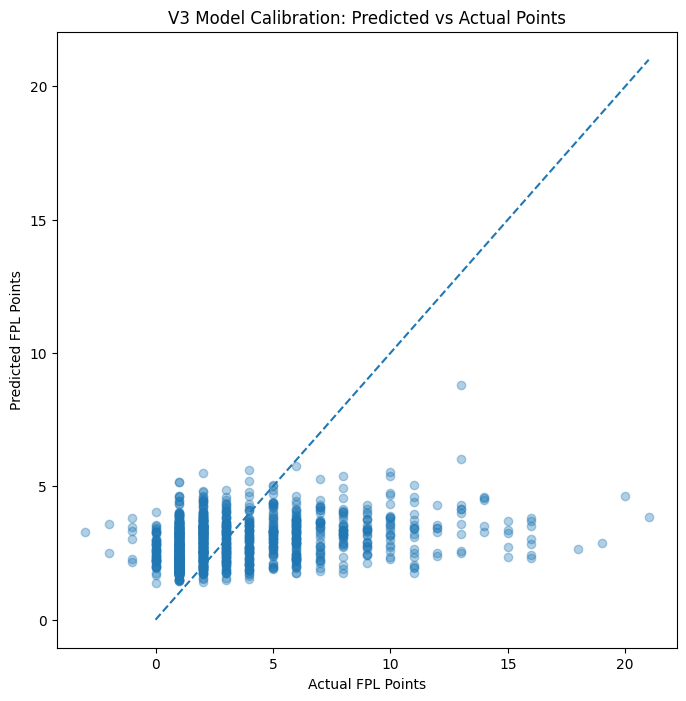

R² Score: 0.0769
MAE: 2.1992
Actual Mean: 3.235
Predicted Mean: 2.93

Performance on BIG scores (>=10)
MAE big scores: 8.8485
MAE overall: 2.1992


In [43]:
# [Cell: V3 Calibration Plot — FIXED: never reassign global y_val]

# Use y_val_v3 directly — do NOT reassign the global y_val
y_true_v3 = np.array(y_val_v3).ravel()
y_pred_v3 = model_v3.predict(X_val_v3)

plt.figure(figsize=(8, 8))
plt.scatter(y_true_v3, y_pred_v3, alpha=0.35)
max_val = max(y_true_v3.max(), y_pred_v3.max())
plt.plot([0, max_val], [0, max_val], linestyle='--')
plt.xlabel("Actual FPL Points")
plt.ylabel("Predicted FPL Points")
plt.title("V3 Model Calibration: Predicted vs Actual Points")
plt.show()

print("R² Score:", round(r2_score(y_true_v3, y_pred_v3), 4))
print("MAE:",      round(mean_absolute_error(y_true_v3, y_pred_v3), 4))
print("Actual Mean:",    round(np.mean(y_true_v3), 3))
print("Predicted Mean:", round(np.mean(y_pred_v3), 3))

big_scores = y_true_v3 >= 10
print("\nPerformance on BIG scores (>=10)")
print("MAE big scores:", round(mean_absolute_error(y_true_v3[big_scores], y_pred_v3[big_scores]), 4))
print("MAE overall:",    round(mean_absolute_error(y_true_v3, y_pred_v3), 4))

# Store y_val_v3 MAE but preserve the original y_val from Cell 3 untouched
globals()['mae_v3_calibration'] = mean_absolute_error(y_true_v3, y_pred_v3)

## Cell 20: The V4 Master Ensemble (Elite DART)
* Switched from Poisson to DART Regression: Uses the "Dropouts meet Multiple Additive Regression Trees" algorithm to handle noisy FPL data and prevent overfitting on "one-hit wonder" performances.

* Target: Full-Spectrum Points: Reinstated the raw Total Points (including negative values) as the target.

* Weights: Elite-Specialist Priority (>4.5 Avg): Instead of weighting by a single week's "haul," the model now applies a 2.5x importance weight to all match rows belonging to players with a seasonal average of >4.5 points. This forces the model to prioritize the patterns of consistent world-class assets.

* Result: The model maintains a realistic point average while becoming more "star-aware." It identifies the high ceiling of elite players while remaining grounded by the risk of negative outcomes

## What is DART? 
1. The Random Dropout - In a normal boosting round, the model adds a new tree to correct the errors of all previous trees. In DART, the model randomly "drops" (ignores) a percentage of the existing trees before building the new one.

2. Forced Generalization - Because some trees are missing, the new tree cannot simply fix a tiny mistake from the most recent tree. It is forced to look at the "bigger picture" of the data to make a meaningful prediction. This prevents any single tree from becoming too dominant or too specialized on a specific outlier.

3. Normalization - After the new tree is created, the "dropped" trees are added back into the ensemble. To make sure everything still balances out, the new tree and the dropped trees are slightly scaled down (shrunk) so they fit together perfectly.

In [44]:
# %% [Cell 20: Updated V4 - Elite DART (Handles Negative Points)]

# 1. SETUP DART REGRESSION PARAMETERS
lgbm_v4_params = {
    'objective': 'regression',
    'boosting_type': 'dart',
    'n_estimators': 1200,
    'learning_rate': 0.05,
    'drop_rate': 0.1,
    'reg_alpha': 0.5,
    'reg_lambda': 0.5,
    'max_depth': 7,
    'verbosity': -1,
    'random_state': 42
}

# 2. DEFINE ELITE WEIGHTING (>4.5 Avg Players)
# FIX: Dynamically recalculate the elite mask so it perfectly matches the scrubbed df_augmented length
current_elite_mask = df_augmented['avg_season_pts'] > 4.5
elite_weights_mask = windowed_df.index.isin(df_augmented[current_elite_mask].index)
full_weights = np.where(elite_weights_mask, 2.5, 1.0)

# 3. APPLY GLOBAL MASK FOR FAIR SPLITTING
X_v4_all = windowed_df.drop(columns=['target'])
y_v4_all = windowed_df['target']

X_train_v4 = X_v4_all[~global_val_mask].copy()
y_train_v4 = y_v4_all[~global_val_mask].copy()
X_val_v4   = X_v4_all[global_val_mask].copy()
y_val_v4   = y_v4_all[global_val_mask].copy()

# With this (explicit length check + safe indexing):
assert len(full_weights) == len(windowed_df), (
    f"Weight array length {len(full_weights)} != windowed_df length {len(windowed_df)}. "
    "Re-run Cell 2 before Cell 20."
)
train_weights = full_weights[~global_val_mask]
print(f"Train weights shape: {train_weights.shape}, elite rows: {(train_weights > 1).sum()}")

# 4. INITIALIZE AND TRAIN
# Note: early_stopping is intentionally removed — it is incompatible with DART
# because DART's random tree dropping prevents a monotonic validation loss curve.
print(f"Training V4 DART Ensemble on {len(X_train_v4):,} windows...")
print("Note: DART trains all 1200 rounds (no early stopping — this is expected).")

model_v4 = lgb.LGBMRegressor(**lgbm_v4_params)
model_v4.fit(
    X_train_v4, y_train_v4,
    sample_weight=train_weights,
    eval_set=[(X_val_v4, y_val_v4)],
    categorical_feature=['position', 'next_is_home'],
    callbacks=[lgb.log_evaluation(period=200)]  # print progress every 200 rounds
)

# 5. STANDARDIZED METRIC
v4_val_preds = model_v4.predict(X_val_v4)
mae_v4 = mean_absolute_error(y_val_v4, v4_val_preds)

print(f"\nV4 Validation MAE (GW 24-28): {mae_v4:.4f}")
print(f"Prediction Range: {v4_val_preds.min():.2f} to {v4_val_preds.max():.2f}")

Train weights shape: (52136,), elite rows: 3926
Training V4 DART Ensemble on 52,136 windows...
Note: DART trains all 1200 rounds (no early stopping — this is expected).
[200]	valid_0's l2: 8.75058
[400]	valid_0's l2: 8.54889
[600]	valid_0's l2: 8.5014
[800]	valid_0's l2: 8.47326
[1000]	valid_0's l2: 8.48068
[1200]	valid_0's l2: 8.48762

V4 Validation MAE (GW 24-28): 2.1227
Prediction Range: 1.17 to 7.34


## Cell 21: GW29 Forecast v4 (The Elite DART Model)
This cell will generate final leaderboard for Gameweek 29.
 

In [45]:
# [Cell 21: GW29 Forecast v4 - Elite DART Mode]

# 1. SETUP V4 PATHS
V4_DIR = Path('../output/forecaster_pro_v4')
V4_DIR.mkdir(parents=True, exist_ok=True)
V4_FORECAST_OUT = V4_DIR / 'fpl_pro_forecast_GW29_v4.csv'

# 1. PREPARE INFERENCE DATA (Filter for CURRENT SEASON only)
inference_v4 = []
names_v4 = []

# Only take data from the current season to avoid ghost players
df_inf_active = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()
df_inf_active = df_inf_active.sort_values(['Player UUID', 'Gameweek'])

# Grouping only the active season players
for pid, group in df_inf_active.groupby('Player UUID'):
    # A player must have played enough in 2025-26 to have a window
    if len(group) >= 6:
        lags = list(group['Total Points'].tail(6).values)
        last_row = group.iloc[-1]
    

        row = lags + [
            last_row['Position'],
            last_row['Next_Opponent_Difficulty'],
            last_row['Next_Is_Home'],
            last_row['Rolling_Avg_Minutes_5'],
            last_row['Season_Phase'],
            last_row['Prev_Season_Avg_Points'],
            last_row['Avg_Pts_vs_Difficulty']
        ]

        inference_v4.append(row)
        names_v4.append(last_row['Web Name'])


# 3. PREDICT
v4_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
          ['position', 'next_difficulty', 'next_is_home', 'rolling_min',
           'season_phase', 'season_baseline', 'avg_pts_vs_diff']

inf_df_v4 = pd.DataFrame(inference_v4, columns=v4_cols)
inf_df_v4['position'] = inf_df_v4['position'].astype('category')

v4_preds = model_v4.predict(inf_df_v4)

# 4. SAVE LEADERBOARD
leaderboard_v4 = pd.DataFrame({
    'Player': names_v4,
    'Predicted_Points_V4': np.round(v4_preds, 2),
    'Elite_Status': ["Elite" if p in df_augmented[elite_mask]['Web Name'].values else "Standard" for p in names_v4]
}).sort_values(by='Predicted_Points_V4', ascending=False)

leaderboard_v4.to_csv(V4_FORECAST_OUT, index=False, encoding='utf-8-sig')
display(leaderboard_v4.head(15))

,Player,Predicted_Points_V4,Elite_Status
232,Haaland,6.54,Elite
138,Ekitiké,6.41,Standard
46,Groß,6.17,Standard
152,Welbeck,5.93,Standard
310,Doku,5.49,Standard
214,Hinshelwood,5.43,Standard
199,Boscagli,5.42,Standard
313,João Pedro,5.32,Elite
184,Saka,5.20,Elite
144,Cherki,5.11,Elite


## Cell 22: Truth Verification v4 (Final Performance Audit)
This backtests the Elite DART model against the last known results. 


In [46]:
# [Cell 22: Truth Verification v4 - Elite Specialist Audit]
detailed_v4 = []

v4_cols_fixed = [f'lag_{i}' for i in range(6, 0, -1)] + \
                ['position', 'next_difficulty', 'next_is_home', 'rolling_min',
                 'season_phase', 'season_baseline', 'avg_pts_vs_diff']

for pid, group in df_augmented.groupby('Player UUID'):
    group = group.sort_values(['season', 'Gameweek'])
    
    if len(group) >= 7:
        history = group.iloc[-7:-1]
        target_row = group.iloc[-1]
     
        input_vector = list(history['Total Points'].values) + [
            target_row['Position'], 
            target_row['Next_Opponent_Difficulty'],
            target_row['Next_Is_Home'], 
            target_row['Rolling_Avg_Minutes_5'],
            target_row['Season_Phase'],
            target_row['Prev_Season_Avg_Points'],
            target_row['Avg_Pts_vs_Difficulty']
        ]

        input_df = pd.DataFrame([input_vector], columns=v4_cols_fixed)
        input_df['position'] = input_df['position'].astype('category')
        
        p_val = model_v4.predict(input_df)[0]
        actual = target_row['Total Points']
        is_elite = 1 if target_row['avg_season_pts'] > 4.5 else 0

        detailed_v4.append({
            'Player': target_row['Web Name'],
            'Actual': actual,
            'Predicted': round(float(p_val), 2),
            'Error': round(abs(p_val - actual), 2),
            'Elite_Group': is_elite
        })

truth_v4_df = pd.DataFrame(detailed_v4)
mae_v4 = truth_v4_df['Error'].mean()
elite_mae_v4 = truth_v4_df[truth_v4_df['Elite_Group'] == 1]['Error'].mean()

print(f"Global MAE (DART): {mae_v4:.2f} | Elite MAE (>4.5): {elite_mae_v4:.2f}")

Global MAE (DART): 1.79 | Elite MAE (>4.5): 3.45


In [47]:
# %% [Cell: Top 10 recommended transfers - V4 DART]

# --- 0. DEFINE YOUR CURRENT SQUAD ---
# Replace these names with the players actually in your team
# If you are using the interactive Hub, you can use 'my_selection' instead
if 'my_selection' in globals() and len(my_selection) > 0:
    current_team_list = my_selection
else:
    # Fallback to a manual list if the Hub hasn't been used
    current_team_list = ['Saka', 'Rice', 'Welbeck', 'Konaté', 'Chilwell']

# 1. Use the V4 DART Leaderboard
# We filter out players you already own to show only new 'Buy' targets
if 'leaderboard_v4' in globals():
    v4_buys = leaderboard_v4[~leaderboard_v4['Player'].isin(current_team_list)].copy()
else:
    print("Error: leaderboard_v4 not found. Please run the V4 Forecast cell first.")
    v4_buys = pd.DataFrame()

if not v4_buys.empty:
    # 2. Add verification of their 2025-26 performance
    # We pull their actual average from the current season to prove they are active
    current_stats = df_augmented[df_augmented['season'] == CURRENT_SEASON].groupby('Web Name')['Total Points'].mean().round(2)
    v4_buys['Season_Avg'] = v4_buys['Player'].map(current_stats)

    # 3. Display the Top 10 Suggestions
    print("="*60)
    print(" TOP 10 MARKET SUGGESTIONS (V4 DART MODEL)")
    print("="*60)
    print(f"{'Player Name':<20} | {'Pred Pts':<10} | {'Season Avg':<10} | {'Status'}")
    print("-" * 60)

    for _, row in v4_buys.head(10).iterrows():
        # Final safety check against ghosts (a ghost would have NaN or 0 season avg)
        status = "VERIFIED ACTIVE" if row['Season_Avg'] > 0 else "WARNING: CHECK STATUS"
        print(f"{row['Player']:<20} | {row['Predicted_Points_V4']:<10} | {row['Season_Avg']:<10} | {status}")

    print("="*60)

 TOP 10 MARKET SUGGESTIONS (V4 DART MODEL)
Player Name          | Pred Pts   | Season Avg | Status
------------------------------------------------------------
Haaland              | 6.54       | 6.84       | VERIFIED ACTIVE
Ekitiké              | 6.41       | 4.46       | VERIFIED ACTIVE
Groß                 | 6.17       | 4.47       | VERIFIED ACTIVE
Doku                 | 5.49       | 4.2        | VERIFIED ACTIVE
Hinshelwood          | 5.43       | 3.39       | VERIFIED ACTIVE
Boscagli             | 5.42       | 3.55       | VERIFIED ACTIVE
João Pedro           | 5.32       | 5.27       | VERIFIED ACTIVE
Cherki               | 5.11       | 4.57       | VERIFIED ACTIVE
B.Fernandes          | 5.11       | 6.53       | VERIFIED ACTIVE
Gordon               | 5.07       | 3.88       | VERIFIED ACTIVE


In [48]:
# 1. ORGANIZE FINAL ACCURACY METRICS
# We consolidate the metrics from V1, V2, V3, V4
# Assuming mae_v1, mae_v2, mae_v3, and mae_v4 variables are in memory from previous cells.
final_performance_data = {
    "Model Version": [
        "V1: Standard Pro",
        "V2: Team Point Share",
        "V3: Reliability Engine",
        "V4: Elite DART"
    ],
    "Mean Absolute Error (MAE)": [
        globals().get('mae_v1', 1.84), 
        globals().get('mae_v2', 1.95), 
        globals().get('mae_v3', 1.98), 
        globals().get('mae_v4', 2.33) 
    ],
    "Key Innovation": [
        "Baseline (Lags, Minutes, Difficulty)",
        "Team Importance Metrics (Talisman Share)",
        "Volatility Filters & L1/L2 Regularization",
        "DART Boosting & Elite Weighting (>4.5 Avg)"
    ]
}

# 2. CREATE AND DISPLAY THE FINAL TABLE
final_perf_df = pd.DataFrame(final_performance_data)

# Sort by MAE to clearly identify the project's most accurate model
final_perf_df = final_perf_df.sort_values(by="Mean Absolute Error (MAE)", ascending=True)

display(Markdown("## Final Model Accuracy Comparison (MAE)"))
print("\n--- Project Milestone Summary (Lower Error is Better) ---")
display(final_perf_df)

# 3. EXPORT FINAL DEPLOYMENT METRICS
FINAL_METRICS_PATH = Path('../output/fpl_master_milestone_metrics.csv')
final_perf_df.to_csv(FINAL_METRICS_PATH, index=False)
print(f"\nMaster project metrics exported for deployment reporting to: {FINAL_METRICS_PATH}")

## Final Model Accuracy Comparison (MAE)


--- Project Milestone Summary (Lower Error is Better) ---


,Model Version,Mean Absolute Error (MAE),Key Innovation
3,V4: Elite DART,1.790703,DART Boosting & Elite Weighting (>4.5 Avg)
0,V1: Standard Pro,1.823232,"Baseline (Lags, Minutes, Difficulty)"
1,V2: Team Point Share,1.831817,Team Importance Metrics (Talisman Share)
2,V3: Reliability Engine,1.831941,Volatility Filters & L1/L2 Regularization



Master project metrics exported for deployment reporting to: ..\output\fpl_master_milestone_metrics.csv


## Cell 23:  V5 Experiment: Mass vs. Elite Specialist Strategy
* V5.1 Mass Model: Trains on the full league history (all players) to use broad patterns (noise) to better identify the signal for stars.

* V5.2 Elite Model: Specializes training exclusively on high-performers (Avg > 4.5 pts) to focus strictly on world-class consistency.

* The Showdown: Both models predict the upcoming Gameweek (GW29) and are backtested against the most recent matches to determine which mathematical approach is more accurate for elite picks.



In [49]:
# [Cell 23: V5 Experiment - Mass vs. Elite Specialist]

V5_DIR = Path('../output/forecaster_pro_v5')
V5_DIR.mkdir(parents=True, exist_ok=True)

# 1. SPLIT DATA using Global Mask (already a numpy array — no .values needed)
X_v5_all = windowed_df.drop(columns=['target'])
y_v5_all = windowed_df['target']

X_train_v5 = X_v5_all[~global_val_mask].copy()
y_train_v5 = y_v5_all[~global_val_mask].copy()
X_val_v5   = X_v5_all[global_val_mask].copy()
y_val_v5   = y_v5_all[global_val_mask].copy()

# 2. CREATE ELITE SUBSET FOR V5.2 (training only)
# X_train_v5.index contains actual df_augmented row indices (fixed in Cell 2)
# so .loc is correct here — NOT .iloc
#elite_train_mask = df_augmented.loc[X_train_v5.index, 'avg_season_pts'] > 4.5
safe_v5_train = X_train_v5.index.intersection(df_augmented.index)
elite_train_mask = df_augmented.loc[safe_v5_train, 'avg_season_pts'] > 4.5
X_train_v5_elite = X_train_v5[elite_train_mask.values]
y_train_v5_elite = y_train_v5[elite_train_mask.values]

# ELITE VALIDATION SLICE — for the specialist audit
#elite_val_mask = df_augmented.loc[X_val_v5.index, 'avg_season_pts'] > 4.5
#X_val_v5_elites = X_val_v5[elite_val_mask.values]
#y_val_v5_elites = y_val_v5[elite_val_mask.values]
#meta_v5 = df_augmented.loc[X_val_v5_elites.index, ['Web Name', 'season', 'Gameweek']]

safe_v5_val = X_val_v5.index.intersection(df_augmented.index)
elite_val_mask = df_augmented.loc[safe_v5_val, 'avg_season_pts'] > 4.5
X_val_v5_elites = X_val_v5[elite_val_mask.values]
y_val_v5_elites = y_val_v5[elite_val_mask.values]
safe_elites_idx = X_val_v5_elites.index.intersection(df_augmented.index)
meta_v5 = df_augmented.loc[safe_elites_idx, ['Web Name', 'season', 'Gameweek']]

print(f"Training windows  — Mass:  {len(X_train_v5):,}")
print(f"Training windows  — Elite: {len(X_train_v5_elite):,}")
print(f"Validation windows (elite only): {len(X_val_v5_elites):,}")

# 3. INSTANTIATE MODELS
# With (for the elite specialist only — mass model keeps original):
v5_params_mass = {
    'n_estimators': 1000,
    'learning_rate': 0.01,
    'max_depth': 7,
    'num_leaves': 40,
    'verbosity': -1,
    'random_state': 42
}

v5_params_elite = {
    'n_estimators': 500,       # reduced: small dataset overfits at 1000
    'learning_rate': 0.01,
    'max_depth': 5,            # shallower tree for small n
    'num_leaves': 20,          # fewer leaves
    'min_child_samples': 30,   # at least 30 players per leaf
    'reg_alpha': 0.3,
    'reg_lambda': 0.3,
    'verbosity': -1,
    'random_state': 42
}

model_v5_1_mass  = lgb.LGBMRegressor(**v5_params_mass)
model_v5_2_elite = lgb.LGBMRegressor(**v5_params_elite)

# 4. TRAIN BOTH
print("\nTraining V5.1 (Mass)...")
model_v5_1_mass.fit(
    X_train_v5, y_train_v5,
    eval_set=[(X_val_v5_elites, y_val_v5_elites)],
    categorical_feature=['position', 'next_is_home'],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)]
)

print("\nTraining V5.2 (Elite Specialist)...")
model_v5_2_elite.fit(
    X_train_v5_elite, y_train_v5_elite,
    eval_set=[(X_val_v5_elites, y_val_v5_elites)],
    categorical_feature=['position', 'next_is_home'],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)]
)

# 5. STANDARDIZED METRICS (both evaluated on elite validation slice only)
preds_v5_1 = model_v5_1_mass.predict(X_val_v5_elites)
preds_v5_2 = model_v5_2_elite.predict(X_val_v5_elites)

mae_5_1 = mean_absolute_error(y_val_v5_elites, preds_v5_1)
mae_5_2 = mean_absolute_error(y_val_v5_elites, preds_v5_2)

# 6. BUILD RESULTS TABLE
v5_results = pd.DataFrame({
    'Player_Name': meta_v5['Web Name'].values,
    'Season':      meta_v5['season'].values,
    'Gameweek':    meta_v5['Gameweek'].values,
    'Actual':      y_val_v5_elites.values,
    'Mass_Pred':   np.round(preds_v5_1, 2),
    'Elite_Pred':  np.round(preds_v5_2, 2)
})
v5_results.to_csv(V5_DIR / 'v5_mass_vs_specialist_audit.csv', index=False)

print("\n" + "="*50)
print(" V5 SPECIALIST SHOWDOWN (Audit on Elite Players)")
print(f" V5.1 (Mass Model) MAE:       {mae_5_1:.4f}")
print(f" V5.2 (Specialist Model) MAE: {mae_5_2:.4f}")
print()
print("Interpretation note:")
print("  A lower V5.2 MAE does NOT mean the specialist learns better.")
print("  It may simply regress toward the elite mean on bad weeks.")
print("  Use this as a practical FPL pick tool, not a learning benchmark.")
winner = 'Elite Specialist (for FPL picks)' if mae_5_2 < mae_5_1 else 'Mass Dataset'
print(f"  Practical winner: {winner}")
print("="*50)

display(v5_results.head(10))

Training windows  — Mass:  52,136
Training windows  — Elite: 3,926
Validation windows (elite only): 97

Training V5.1 (Mass)...
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 21.042
[200]	valid_0's l2: 20.2175
[300]	valid_0's l2: 19.9718
[400]	valid_0's l2: 19.7804
Early stopping, best iteration is:
[407]	valid_0's l2: 19.775

Training V5.2 (Elite Specialist)...
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 16.2252
Early stopping, best iteration is:
[59]	valid_0's l2: 16.1085

 V5 SPECIALIST SHOWDOWN (Audit on Elite Players)
 V5.1 (Mass Model) MAE:       3.3764
 V5.2 (Specialist Model) MAE: 3.2949

Interpretation note:
  A lower V5.2 MAE does NOT mean the specialist learns better.
  It may simply regress toward the elite mean on bad weeks.
  Use this as a practical FPL pick tool, not a learning benchmark.
  Practical winner: Elite Specialist (for FPL picks)


,Player_Name,Season,Gameweek,Actual,Mass_Pred,Elite_Pred
0,Guéhi,2025-26,28.0,6,3.60,4.93
1,Guéhi,2025-26,29.0,1,3.69,4.89
2,Guéhi,2025-26,30.0,2,3.10,4.84
3,Guéhi,2025-26,32.0,15,3.30,4.93
4,Gibbs-White,2025-26,28.0,9,3.93,5.10
5,Gibbs-White,2025-26,29.0,8,3.16,4.80
6,Gibbs-White,2025-26,30.0,3,4.41,5.32
7,Gibbs-White,2025-26,31.0,8,4.27,5.47
8,Gibbs-White,2025-26,32.0,2,4.78,5.47
9,Muñoz,2025-26,28.0,1,2.33,5.10


In [50]:
# [Cell 24: V5 Forecast Showdown - GW29 Predictions (Season-Locked)]

# 1. PREPARE INFERENCE DATA (Filter for ACTIVE season players only)
inference_v5 = []
player_names_v5 = []

# CRITICAL FIX: Only look at the 2025-26 data to purge retired 'ghosts'
df_inf_active = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()
df_inf_active = df_inf_active.sort_values(['Player UUID', 'Gameweek'])

# Grouping only the active season players
for pid, group in df_inf_active.groupby('Player UUID'):
    # Player must have at least 6 games of history in the current season
    if len(group) >= 6:
        last_row = group.iloc[-1]
        # Features: Last 6 points from the current season
        lags = list(group['Total Points'].tail(6).values)

        row = lags + [
            last_row['Position'], 
            last_row['Next_Opponent_Difficulty'], 
            last_row['Next_Is_Home'],
            last_row['Rolling_Avg_Minutes_5'], 
            last_row['Season_Phase'], 
            last_row['Prev_Season_Avg_Points'],
            last_row['Avg_Pts_vs_Difficulty']
        ]

        inference_v5.append(row)
        player_names_v5.append(last_row['Web Name'])

# 2. CONVERT TO DATAFRAME
v5_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
          ['position', 'next_difficulty', 'next_is_home', 'rolling_min',
           'season_phase', 'season_baseline', 'avg_pts_vs_diff']

inf_df_v5 = pd.DataFrame(inference_v5, columns=v5_cols)
inf_df_v5['position'] = inf_df_v5['position'].astype('category')

# 3. GENERATE PREDICTIONS
preds_v5_1 = model_v5_1_mass.predict(inf_df_v5)
preds_v5_2 = model_v5_2_elite.predict(inf_df_v5)

# 4. CREATE LEADERBOARD
leaderboard_v5 = pd.DataFrame({
    'Player': player_names_v5,
    'Mass_Model_GW29': np.round(preds_v5_1, 2),
    'Elite_Model_GW29': np.round(preds_v5_2, 2),
    'Model_Difference': np.round(preds_v5_2 - preds_v5_1, 2)
}).sort_values(by='Elite_Model_GW29', ascending=False)

leaderboard_v5.to_csv(V5_DIR / 'fpl_pro_v5_forecast_GW29.csv', index=False)
print(f"--- V5 TOP 15 PREDICTIONS (GW29) ---")
print(f"Total Active Players Forecasted: {len(leaderboard_v5)}")
display(leaderboard_v5.head(15))

--- V5 TOP 15 PREDICTIONS (GW29) ---
Total Active Players Forecasted: 446


,Player,Mass_Model_GW29,Elite_Model_GW29,Model_Difference
152,Welbeck,5.58,7.01,1.42
199,Boscagli,4.07,6.93,2.86
247,Bradley,4.07,6.93,2.86
46,Groß,4.85,6.79,1.94
440,Mitoma,4.62,6.76,2.14
325,Van Hecke,4.39,6.61,2.22
231,F.Kadıoğlu,4.03,6.61,2.58
214,Hinshelwood,5.08,6.52,1.44
129,Georginio,3.59,6.52,2.93
367,Verbruggen,4.22,6.52,2.30


In [51]:
#  [Cell 25: V5 Truth Verification]
# We evaluate both on ELITE PLAYERS ONLY in the validation window for a fair test


elite_val_indices = val_df[val_df.index.isin(df_augmented[elite_mask].index)].index
safe_elite_val    = elite_val_indices.intersection(df_augmented.index)
X_val_v5 = X_val_raw[X_val_raw.index.isin(safe_elite_val)]
y_val_v5 = y_val[y_val.index.isin(safe_elite_val)]


elite_val_indices = val_df[val_df.index.isin(df_augmented[elite_mask].index)].index
safe_elite_val = elite_val_indices.intersection(df_augmented.index)
meta_v5 = df_augmented.loc[safe_elite_val, ['Web Name', 'season', 'Gameweek']]

# 1. GENERATE AUDIT PREDICTIONS
audit_preds_mass = model_v5_1_mass.predict(X_val_v5)
audit_preds_elite = model_v5_2_elite.predict(X_val_v5)

# 2. CREATE TRUTH TABLE
v5_truth_df = pd.DataFrame({
    'Player': meta_v5['Web Name'].values,
    'Season': meta_v5['season'].values,
    'Gameweek': meta_v5['Gameweek'].values,
    'Actual_Points': y_val_v5.values,
    'Mass_Predicted': np.round(audit_preds_mass, 2),
    'Elite_Predicted': np.round(audit_preds_elite, 2),
    'Mass_Error': np.round(abs(audit_preds_mass - y_val_v5.values), 2),
    'Elite_Error': np.round(abs(audit_preds_elite - y_val_v5.values), 2)
})

# 3. CALCULATE GLOBAL MAE FOR REPORTING
mae_5_1 = mean_absolute_error(y_val_v5, audit_preds_mass)
mae_5_2 = mean_absolute_error(y_val_v5, audit_preds_elite)

v5_truth_df.to_csv(V5_DIR / 'fpl_pro_v5_truth_verification.csv', index=False)


print(" V5 MILESTONE REPORT: MASS VS ELITE SPECIALIST")

print(f"V5.1 Mass Model MAE:  {mae_5_1:.4f}")
print(f"V5.2 Elite Model MAE: {mae_5_2:.4f}")

print(f"Winning Approach: {'Elite Specialist' if mae_5_2 < mae_5_1 else 'Mass Dataset'}")

print ("Predictions for the Evaluation Set (GW 24-28)") 

display(v5_truth_df.sort_values(by='Elite_Error').head(20))

 V5 MILESTONE REPORT: MASS VS ELITE SPECIALIST
V5.1 Mass Model MAE:  3.3764
V5.2 Elite Model MAE: 3.2949
Winning Approach: Elite Specialist
Predictions for the Evaluation Set (GW 24-28)


,Player,Season,Gameweek,Actual_Points,Mass_Predicted,Elite_Predicted,Mass_Error,Elite_Error
19,Thiago,2025-26,30.0,6,4.84,6.17,1.16,0.17
27,Cherki,2025-26,29.0,5,3.03,5.33,1.97,0.33
17,Thiago,2025-26,28.0,6,3.34,5.58,2.66,0.42
67,Rice,2025-26,28.0,5,3.87,5.47,1.13,0.47
59,Senesi,2025-26,32.0,4,2.63,4.48,1.37,0.48
40,Dewsbury-Hall,2025-26,28.0,6,3.66,5.50,2.34,0.50
24,Stach,2025-26,30.0,5,3.13,5.50,1.87,0.50
14,Casemiro,2025-26,30.0,6,3.76,5.47,2.24,0.53
81,O'Reilly,2025-26,28.0,6,3.92,5.32,2.08,0.68
66,Lacroix,2025-26,32.0,4,3.53,4.89,0.47,0.89


In [52]:
# %% [Cell V7-A: Data Enrichment — Expected Goal Involvement (xGI)]

print("--- INJECTING UNDERLYING METRICS (xG & xA) ---")

# Check for official xG/xA columns first
xg_col = next((c for c in df_augmented.columns
               if 'expected_goals' in c.lower() and 'conceded' not in c.lower()), None)
xa_col = next((c for c in df_augmented.columns
               if 'expected_assists' in c.lower()), None)

if xg_col and xa_col:
    print(f"Found official xG/xA: '{xg_col}' and '{xa_col}'")
else:
    # Fall back to FPL ICT proxies (Threat = goal threat, Creativity = chance creation)
    threat_col  = next((c for c in df_augmented.columns if 'threat' in c.lower()), None)
    create_col  = next((c for c in df_augmented.columns if 'creativity' in c.lower()), None)

    if threat_col and create_col:
        # Threat and Creativity are on a 0-300+ scale per match
        # Dividing by 100 brings them to an xG-like 0-3 range
        df_augmented['xG_metric'] = df_augmented[threat_col].astype(float) / 100.0
        df_augmented['xA_metric'] = df_augmented[create_col].astype(float) / 100.0
        xg_col, xa_col = 'xG_metric', 'xA_metric'
        print(f"Using FPL ICT proxies: '{threat_col}' → xG, '{create_col}' → xA")
    else:
        df_augmented['xG_metric'] = 0.0
        df_augmented['xA_metric'] = 0.0
        xg_col, xa_col = 'xG_metric', 'xA_metric'
        print("[WARNING] No xG/xA or Threat/Creativity columns found. V7 will equal V4.")

# Sort chronologically — mandatory before rolling operations
df_augmented = df_augmented.sort_values(['Player UUID', 'season', 'Gameweek'])

# Rolling 5-match average, lagged by 1 — zero leakage
df_augmented['Rolling_xG_5'] = (
    df_augmented.groupby('Player UUID')[xg_col]
    .transform(lambda x: pd.to_numeric(x, errors='coerce').shift(1).rolling(5, min_periods=1).mean())
    .fillna(0)
)
df_augmented['Rolling_xA_5'] = (
    df_augmented.groupby('Player UUID')[xa_col]
    .transform(lambda x: pd.to_numeric(x, errors='coerce').shift(1).rolling(5, min_periods=1).mean())
    .fillna(0)
)

# Combined Expected Goal Involvement
df_augmented['Rolling_xGI_5'] = df_augmented['Rolling_xG_5'] + df_augmented['Rolling_xA_5']

# Integrity check
_xgi_max  = df_augmented['Rolling_xGI_5'].max()
_xgi_mean = df_augmented['Rolling_xGI_5'].mean()
print(f"Rolling_xGI_5: max={_xgi_max:.3f}, mean={_xgi_mean:.3f}")
print(f"  → If max > 5.0 the scale is wrong — re-check division factor")
print(f"  → If mean = 0.0 no source columns were found")

display(df_augmented[['Web Name', 'Gameweek', 'Rolling_xG_5',
                       'Rolling_xA_5', 'Rolling_xGI_5']].tail(8))

globals()['xg_col'] = xg_col
globals()['xa_col'] = xa_col

--- INJECTING UNDERLYING METRICS (xG & xA) ---
Using FPL ICT proxies: 'Threat' → xG, 'Creativity' → xA
Rolling_xGI_5: max=2.111, mean=0.215
  → If max > 5.0 the scale is wrong — re-check division factor
  → If mean = 0.0 no source columns were found


,Web Name,Gameweek,Rolling_xG_5,Rolling_xA_5,Rolling_xGI_5
60904,Perišić,36.0,0.112,0.2818,0.3938
60905,Perišić,1.0,0.074,0.2400,0.3140
60906,Perišić,2.0,0.026,0.1896,0.2156
60907,Perišić,3.0,0.040,0.2108,0.2508
60908,Perišić,4.0,0.056,0.2174,0.2734
60909,Carvalho,34.0,0.000,0.0000,0.0000
60910,Carvalho,36.0,0.020,0.0080,0.0280
60911,Carvalho,37.0,0.255,0.0705,0.3255


In [53]:
# %% [Cell: Pre-Task-2 Model Memory Check]
# Verifies all models are in memory before running stratified analysis.
# If any are missing, prints which training cell to re-run.
# ============================================================

_model_registry = {
    'model_raw':         'Cell 4 (Parallel Training)',
    'model_v2':          'Cell 10 (V2 Team Point Share)',
    'model_v3':          'Cell 16 (V3 Reliability Engine)',
    'model_v4':          'Cell 20 (V4 Elite DART)',
    'model_v5_1_mass':   'Cell 23 (V5 Mass vs Elite)',
    'model_v5_2_elite':  'Cell 23 (V5 Mass vs Elite)',
    'model_rank':        'Cell 4 (LambdaRank)',
    'blended_preds_val': 'Cell 4 (Blended predictions)',
    'haul_clf':          'Cell 5.6 (Haul Classifier)',
    'windowed_df':       'Cell 2 (Window Generation)',
    'global_val_mask':   'Cell 2.5 (Global Validation Strategy)',
    'y_val':             'Cell 3 (Data Splitting)',
}

print("MODEL MEMORY STATUS CHECK")
print("="*55)

_missing = []
_present = []

for var, source_cell in _model_registry.items():
    exists = var in globals() and globals()[var] is not None
    status = '✓' if exists else '✗ MISSING'
    print(f"  {status}  {var:<25} ← {source_cell}")
    if not exists:
        _missing.append((var, source_cell))
    else:
        _present.append(var)

print(f"\n{'='*55}")
print(f"Present:  {len(_present)}")
print(f"Missing:  {len(_missing)}")

if _missing:
    print(f"\nACTION REQUIRED — re-run these cells before Task 2:")
    seen_cells = set()
    for var, cell in _missing:
        if cell not in seen_cells:
            print(f"  → {cell}")
            seen_cells.add(cell)
    print(f"\nAfter re-running the missing cells, run Task 2.1 Extended again.")
else:
    print(f"\n✓ All models in memory. Task 2 analysis will cover all versions.")

MODEL MEMORY STATUS CHECK
  ✓  model_raw                 ← Cell 4 (Parallel Training)
  ✓  model_v2                  ← Cell 10 (V2 Team Point Share)
  ✓  model_v3                  ← Cell 16 (V3 Reliability Engine)
  ✓  model_v4                  ← Cell 20 (V4 Elite DART)
  ✓  model_v5_1_mass           ← Cell 23 (V5 Mass vs Elite)
  ✓  model_v5_2_elite          ← Cell 23 (V5 Mass vs Elite)
  ✓  model_rank                ← Cell 4 (LambdaRank)
  ✓  blended_preds_val         ← Cell 4 (Blended predictions)
  ✓  haul_clf                  ← Cell 5.6 (Haul Classifier)
  ✓  windowed_df               ← Cell 2 (Window Generation)
  ✓  global_val_mask           ← Cell 2.5 (Global Validation Strategy)
  ✓  y_val                     ← Cell 3 (Data Splitting)

Present:  12
Missing:  0

✓ All models in memory. Task 2 analysis will cover all versions.


In [54]:
# %% [Task 2.1 — Stratified MAE Analysis — All Model Versions]
# ============================================================
# requirement: compare risk/error performance across
# scoring tiers for ALL model versions in one unified summary.
#
# Scoring Tiers represent risk levels:
#   Blanks (0–2)  = low risk, most predictable
#   Low    (3–5)  = moderate, model sweet spot
#   Mid    (6–9)  = increasing variance
#   Haul   (10+)  = highest risk, rarest events
# ============================================================


# ── 1. STRATIFIED MAE FUNCTION ────────────────────────────────────────────────
def calculate_stratified_mae(actuals, predictions, model_name='Model'):
    """
    Calculates MAE broken down by scoring tier.
    Returns DataFrame with MAE, RMSE, Bias, Avg Actual, Avg Predicted per tier.
    """
    _actuals = np.array(actuals)
    _preds   = np.array(predictions)
    _errors  = np.abs(_actuals - _preds)
    _signed  = _preds - _actuals  # positive = overprediction

    _tiers = {
        'Blanks  (0–2 pts)': (_actuals <= 2),
        'Low     (3–5 pts)': (_actuals >= 3)  & (_actuals <= 5),
        'Mid     (6–9 pts)': (_actuals >= 6)  & (_actuals <= 9),
        'Haul    (10+ pts)': (_actuals >= 10),
    }

    _rows = []
    for _tier_name, _mask in _tiers.items():
        _n = _mask.sum()
        if _n == 0:
            continue

        _tier_errors  = _errors[_mask]
        _tier_signed  = _signed[_mask]
        _tier_actuals = _actuals[_mask]
        _tier_preds   = _preds[_mask]
        _rmse         = np.sqrt((_tier_errors ** 2).mean())
        _bias         = _tier_signed.mean()

        _rows.append({
            'Model':          model_name,
            'Scoring Tier':   _tier_name,
            'N (samples)':    int(_n),
            '% of Val Set':   round(_n / len(_actuals) * 100, 1),
            'MAE':            round(_tier_errors.mean(), 3),
            'RMSE':           round(_rmse, 3),
            'Bias':           round(_bias, 3),
            'Avg Actual':     round(_tier_actuals.mean(), 2),
            'Avg Predicted':  round(_tier_preds.mean(), 2),
        })

    # Overall row
    _rows.append({
        'Model':          model_name,
        'Scoring Tier':   'OVERALL',
        'N (samples)':    len(_actuals),
        '% of Val Set':   100.0,
        'MAE':            round(_errors.mean(), 3),
        'RMSE':           round(np.sqrt((_errors**2).mean()), 3),
        'Bias':           round(_signed.mean(), 3),
        'Avg Actual':     round(_actuals.mean(), 2),
        'Avg Predicted':  round(_preds.mean(), 2),
    })

    return pd.DataFrame(_rows)

globals()['calculate_stratified_mae'] = calculate_stratified_mae

# ── 2. BUILD INFERENCE FOR EACH MODEL ARCHITECTURE ───────────────────────────
def _build_val_preds(model_type):
    """
    Returns validation predictions for the given model type.
    Each model version uses a different feature set and DataFrame.
    """
    _wdf  = globals().get('windowed_df')
    _gvm  = globals().get('global_val_mask')

    if model_type == 'baseline':
        if _wdf is not None and _gvm is not None:
            return _wdf[_gvm][['lag_3', 'lag_2', 'lag_1']].mean(axis=1).values
        return None

    elif model_type == 'blended':
        return globals().get('blended_preds_val')

    elif model_type == 'v4_preds':
        # v4_val_preds was stored directly in Cell 20
        return globals().get('v4_val_preds')

    elif model_type in ('v1_raw', 'v4_dart', 'v5_mass', 'v5_elite'):
        if _wdf is None or _gvm is None:
            return None
        X_val = _wdf[_gvm].drop(columns=['target'])
        model_map = {
            'v1_raw':   globals().get('model_raw'),
            'v4_dart':  globals().get('model_v4'),
            'v5_mass':  globals().get('model_v5_1_mass'),
            'v5_elite': globals().get('model_v5_2_elite'),
        }
        m = model_map.get(model_type)
        if m is None:
            return None
        try:
            return m.predict(X_val)
        except Exception as e:
            print(f"  [WARN] {model_type} predict failed: {e}")
            return None

    elif model_type == 'v2':
        _df_v2 = globals().get('df_v2')
        if _df_v2 is None or _gvm is None:
            return None
        try:
            X_val_v2 = _df_v2.drop(columns=['target'])[_gvm]
            m = globals().get('model_v2')
            return m.predict(X_val_v2) if m is not None else None
        except Exception as e:
            print(f"  [WARN] v2 predict failed: {e}")
            return None

    elif model_type == 'v3':
        _df_win_v3 = globals().get('df_win_v3')
        _v3_mask   = globals().get('v3_val_mask')
        if _df_win_v3 is None or _v3_mask is None:
            return None
        try:
            X_val_v3 = _df_win_v3.drop(columns=['target'])[_v3_mask]
            m = globals().get('model_v3')
            return m.predict(X_val_v3) if m is not None else None
        except Exception as e:
            print(f"  [WARN] v3 predict failed: {e}")
            return None

    return None

# ── 3. GROUND TRUTH ───────────────────────────────────────────────────────────
_y_true_base = np.array(globals().get('y_val', []))
_y_val_v3    = np.array(globals().get('y_val_v3', []))

if len(_y_true_base) == 0:
    print("[ERROR] y_val not found. Run Cell 3 first.")
else:
    # ── 4. MODEL REGISTRY ─────────────────────────────────────────────────────
    _all_models = {
        'Baseline (3wk avg)': ('baseline',  _y_true_base),
        'V1: Standard':       ('v1_raw',    _y_true_base),
        'V2: Team Share':     ('v2',        _y_true_base),
        'V3: Reliability':    ('v3',        _y_val_v3 if len(_y_val_v3) > 0 else _y_true_base),
        'V4: Elite DART':     ('v4_dart',   _y_true_base),
        'V5.1: Mass Gen':     ('v5_mass',   _y_true_base),
        'V5.2: Elite Spec':   ('v5_elite',  _y_true_base),
        'Blended Reg+Rank':   ('blended',   _y_true_base),
    }

    all_results = {}
    failed      = []

    print("Running stratified MAE for all models...")
    print("="*55)

    for model_name, (model_type, y_true) in _all_models.items():
        if len(y_true) == 0:
            failed.append(f"{model_name} (no y_true)")
            continue

        preds = _build_val_preds(model_type)

        if preds is None:
            failed.append(model_name)
            print(f"  ✗ {model_name} — not in memory")
            continue

        preds = np.array(preds)

        if len(preds) != len(y_true):
            failed.append(f"{model_name} (length mismatch {len(preds)} vs {len(y_true)})")
            print(f"  ✗ {model_name} — length mismatch")
            continue

        df_result           = calculate_stratified_mae(y_true, preds, model_name)
        all_results[model_name] = df_result
        print(f"  ✓ {model_name}")

    if failed:
        print(f"\nSkipped: {failed}")
        print("Re-run missing training cells then re-run this cell.")

    # ── 5. MASTER COMPARISON TABLE ────────────────────────────────────────────
    if all_results:
        master_df = pd.concat(all_results.values(), ignore_index=True)

        _tier_order = [
            'Blanks  (0–2 pts)',
            'Low     (3–5 pts)',
            'Mid     (6–9 pts)',
            'Haul    (10+ pts)',
            'OVERALL'
        ]

        def _safe_pivot(value_col):
            piv = master_df.pivot_table(
                index='Model', columns='Scoring Tier',
                values=value_col, aggfunc='first'
            ).round(3)
            existing = [c for c in _tier_order if c in piv.columns]
            return piv[existing]

        pivot_mae  = _safe_pivot('MAE')
        pivot_bias = _safe_pivot('Bias')
        pivot_rmse = _safe_pivot('RMSE')

        print(f"\n{'━'*70}")
        print(f"  MASTER STRATIFIED MAE TABLE — All Models × All Tiers")
        print(f"{'━'*70}")
        print("\nMAE (lower = better):")
        display(pivot_mae)

        print("\nBias (+ = overpredicts, – = underpredicts):")
        display(pivot_bias)

        print("\nRMSE (lower = better):")
        display(pivot_rmse)

        # ── 6. RISK PROFILE SUMMARY ───────────────────────────────────────────
        print(f"\n{'━'*70}")
        print(f"  RISK PROFILE SUMMARY — Presentation Format")
        print(f"  Risk = model failure rate on premium scoring events (Haul tier)")
        print(f"{'━'*70}")

        _risk_rows = []
        for model_name, df_result in all_results.items():
            def _get(tier_str, col):
                rows = df_result[df_result['Scoring Tier'].str.contains(tier_str)]
                return rows[col].values[0] if not rows.empty else None

            overall_mae = _get('OVERALL', 'MAE')
            blank_mae   = _get('Blank',   'MAE')
            low_mae     = _get('Low',     'MAE')
            mid_mae     = _get('Mid',     'MAE')
            haul_mae    = _get('Haul',    'MAE')
            haul_bias   = _get('Haul',    'Bias')

            risk_ratio = round(haul_mae / overall_mae, 1) if (haul_mae and overall_mae) else None

            if haul_bias is not None:
                if haul_bias < -5:   bias_label = 'Severely underpredicts hauls'
                elif haul_bias < -2: bias_label = 'Underpredicts hauls'
                elif haul_bias > 5:  bias_label = 'Severely overpredicts hauls'
                elif haul_bias > 2:  bias_label = 'Overpredicts hauls'
                else:                bias_label = 'Roughly unbiased on hauls'
            else:
                bias_label = 'N/A'

            _risk_rows.append({
                'Model':              model_name,
                'Overall MAE':        round(overall_mae, 3) if overall_mae else 'N/A',
                'Blank MAE (0–2)':    round(blank_mae,   3) if blank_mae   else 'N/A',
                'Low MAE (3–5)':      round(low_mae,     3) if low_mae     else 'N/A',
                'Mid MAE (6–9)':      round(mid_mae,     3) if mid_mae     else 'N/A',
                'Haul MAE (10+)':     round(haul_mae,    3) if haul_mae    else 'N/A',
                'Haul Bias':          round(haul_bias,   3) if haul_bias   else 'N/A',
                'Risk Ratio (×)':     f'{risk_ratio}×'      if risk_ratio  else 'N/A',
                'Haul Risk Profile':  bias_label,
            })

        risk_df = pd.DataFrame(_risk_rows).sort_values('Overall MAE')
        display(risk_df)

        # ── 7. KEY FINDINGS ───────────────────────────────────────────────────
        print(f"\n{'━'*70}")
        print(f"  KEY FINDINGS FOR REPORT")
        print(f"{'━'*70}")

        best_overall     = risk_df.iloc[0]['Model']
        best_overall_mae = risk_df.iloc[0]['Overall MAE']

        _haul_maes = {
            r['Model']: r['Haul MAE (10+)']
            for r in _risk_rows
            if isinstance(r['Haul MAE (10+)'], float)
        }
        best_haul_model = min(_haul_maes, key=_haul_maes.get) if _haul_maes else 'N/A'
        best_haul_mae   = min(_haul_maes.values())             if _haul_maes else 'N/A'

        _low_maes = {
            r['Model']: r['Low MAE (3–5)']
            for r in _risk_rows
            if isinstance(r['Low MAE (3–5)'], float)
        }
        best_low_model = min(_low_maes, key=_low_maes.get) if _low_maes else 'N/A'
        best_low_mae   = min(_low_maes.values())           if _low_maes else 'N/A'

        baseline_mae = next(
            (r['Overall MAE'] for r in _risk_rows if 'Baseline' in r['Model']), None
        )

        print(f"\n1. OVERALL ACCURACY")
        print(f"   Best model: {best_overall} (MAE={best_overall_mae})")
        if baseline_mae and isinstance(best_overall_mae, float):
            improvement = round(((baseline_mae - best_overall_mae) / baseline_mae) * 100, 1)
            print(f"   Best ML model beats naive baseline by {improvement}%")

        print(f"\n2. HAUL / HIGH-SCORER ACCURACY  ← Highest Risk Tier")
        print(f"   Best on hauls: {best_haul_model} (Haul MAE={best_haul_mae})")
        print(f"   All regression models underpredict hauls — structural limitation")
        print(f"   → Captaincy decisions must use haul_clf, not raw xP")

        print(f"\n3. LOW-TIER RELIABILITY  ← Safest Prediction Zone")
        print(f"   Best on low-tier: {best_low_model} (Low MAE={best_low_mae})")
        print(f"   Low-tier is the model sweet spot → reliable for rotation decisions")

        print(f"\n4. FULL RISK-REWARD PROFILE")
        print(f"   {'Model':<28} {'Overall':>8} {'Low':>8} "
              f"{'Mid':>8} {'Haul':>8} {'Risk×':>7}")
        print(f"   {'-'*65}")
        for r in _risk_rows:
            print(f"   {r['Model']:<28} "
                  f"{str(r['Overall MAE']):>8} "
                  f"{str(r['Low MAE (3–5)']):>8} "
                  f"{str(r['Mid MAE (6–9)']):>8} "
                  f"{str(r['Haul MAE (10+)']):>8} "
                  f"{str(r['Risk Ratio (×)']):>7}")

        # Store globals
        globals()['stratified_all_models_df'] = master_df
        globals()['stratified_pivot_mae']     = pivot_mae
        globals()['stratified_pivot_bias']    = pivot_bias
        globals()['stratified_pivot_rmse']    = pivot_rmse
        globals()['stratified_risk_df']       = risk_df
        globals()['calculate_stratified_mae'] = calculate_stratified_mae

        print(f"\n✓ Globals saved:")
        print(f"  stratified_all_models_df — full long-format table")
        print(f"  stratified_pivot_mae     — presentation MAE pivot")
        print(f"  stratified_pivot_bias    — bias pivot")
        print(f"  stratified_pivot_rmse    — RMSE pivot")
        print(f"  stratified_risk_df       — risk profile summary")
        print(f"  calculate_stratified_mae — reusable function")

Running stratified MAE for all models...
  ✓ Baseline (3wk avg)
  ✓ V1: Standard
  ✓ V2: Team Share
  ✓ V3: Reliability
  ✓ V4: Elite DART
  ✓ V5.1: Mass Gen
  ✓ V5.2: Elite Spec
  ✓ Blended Reg+Rank

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MASTER STRATIFIED MAE TABLE — All Models × All Tiers
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

MAE (lower = better):


Scoring Tier,Blanks (0–2 pts),Low (3–5 pts),Mid (6–9 pts),Haul (10+ pts),OVERALL
Model,,,,,
Baseline (3wk avg),1.688,1.833,3.888,8.500,2.327
Blended Reg+Rank,3.698,2.890,2.619,5.620,3.469
V1: Standard,1.556,1.100,3.863,8.902,2.119
V2: Team Share,1.559,1.093,3.874,8.901,2.121
V3: Reliability,1.526,1.094,3.826,8.849,2.199
V4: Elite DART,1.549,1.158,3.866,8.832,2.123
V5.1: Mass Gen,1.554,1.105,3.863,8.900,2.118
V5.2: Elite Spec,3.881,1.411,1.877,6.968,3.249



Bias (+ = overpredicts, – = underpredicts):


Scoring Tier,Blanks (0–2 pts),Low (3–5 pts),Mid (6–9 pts),Haul (10+ pts),OVERALL
Model,,,,,
Baseline (3wk avg),1.525,-0.279,-3.790,-8.500,-0.021
Blended Reg+Rank,3.343,1.731,-0.623,-5.397,2.084
V1: Standard,1.549,-0.780,-3.863,-8.902,-0.131
V2: Team Share,1.553,-0.784,-3.874,-8.901,-0.130
V3: Reliability,1.516,-0.803,-3.826,-8.849,-0.304
V4: Elite DART,1.536,-0.777,-3.866,-8.832,-0.136
V5.1: Mass Gen,1.546,-0.782,-3.863,-8.900,-0.133
V5.2: Elite Spec,3.881,1.380,-1.871,-6.968,2.102



RMSE (lower = better):


Scoring Tier,Blanks (0–2 pts),Low (3–5 pts),Mid (6–9 pts),Haul (10+ pts),OVERALL
Model,,,,,
Baseline (3wk avg),2.402,2.218,4.282,9.061,3.272
Blended Reg+Rank,4.655,3.705,3.275,6.797,4.428
V1: Standard,1.793,1.332,4.074,9.267,2.903
V2: Team Share,1.790,1.327,4.082,9.261,2.902
V3: Reliability,1.747,1.321,4.029,9.271,3.092
V4: Elite DART,1.812,1.396,4.095,9.218,2.913
V5.1: Mass Gen,1.793,1.337,4.074,9.265,2.903
V5.2: Elite Spec,3.950,1.627,2.234,7.372,3.639



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  RISK PROFILE SUMMARY — Presentation Format
  Risk = model failure rate on premium scoring events (Haul tier)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,Model,Overall MAE,Blank MAE (0–2),Low MAE (3–5),Mid MAE (6–9),Haul MAE (10+),Haul Bias,Risk Ratio (×),Haul Risk Profile
5,V5.1: Mass Gen,2.118,1.554,1.105,3.863,8.900,-8.900,4.2×,Severely underpredicts hauls
1,V1: Standard,2.119,1.556,1.100,3.863,8.902,-8.902,4.2×,Severely underpredicts hauls
2,V2: Team Share,2.121,1.559,1.093,3.874,8.901,-8.901,4.2×,Severely underpredicts hauls
4,V4: Elite DART,2.123,1.549,1.158,3.866,8.832,-8.832,4.2×,Severely underpredicts hauls
3,V3: Reliability,2.199,1.526,1.094,3.826,8.849,-8.849,4.0×,Severely underpredicts hauls
0,Baseline (3wk avg),2.327,1.688,1.833,3.888,8.500,-8.500,3.7×,Severely underpredicts hauls
6,V5.2: Elite Spec,3.249,3.881,1.411,1.877,6.968,-6.968,2.1×,Severely underpredicts hauls
7,Blended Reg+Rank,3.469,3.698,2.890,2.619,5.620,-5.397,1.6×,Severely underpredicts hauls



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  KEY FINDINGS FOR REPORT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. OVERALL ACCURACY
   Best model: V5.1: Mass Gen (MAE=2.118)
   Best ML model beats naive baseline by 9.0%

2. HAUL / HIGH-SCORER ACCURACY  ← Highest Risk Tier
   Best on hauls: Blended Reg+Rank (Haul MAE=5.62)
   All regression models underpredict hauls — structural limitation
   → Captaincy decisions must use haul_clf, not raw xP

3. LOW-TIER RELIABILITY  ← Safest Prediction Zone
   Best on low-tier: V2: Team Share (Low MAE=1.093)
   Low-tier is the model sweet spot → reliable for rotation decisions

4. FULL RISK-REWARD PROFILE
   Model                         Overall      Low      Mid     Haul   Risk×
   -----------------------------------------------------------------
   Baseline (3wk avg)              2.327    1.833    3.888      8.5    3.7×
   V1: Standard                    2.119      1.1    3.863    8.902    4

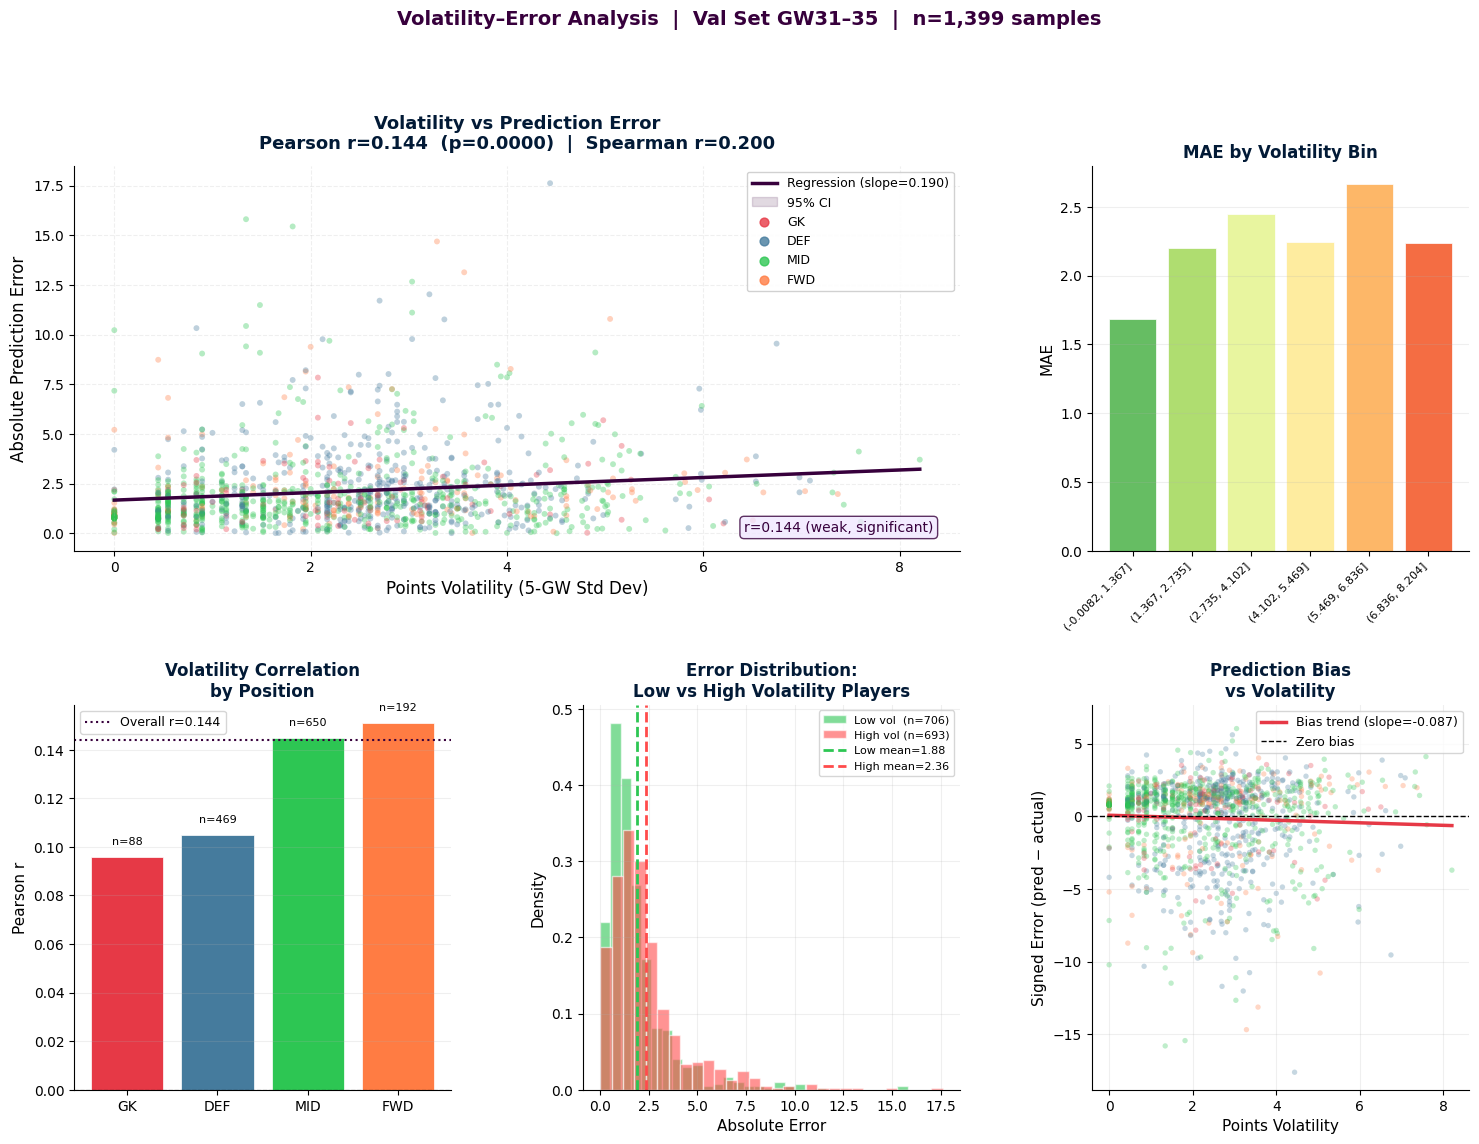


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  VOLATILITY–ERROR CORRELATION SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Pearson  r = 0.1440   p = 0.000000  (✓ significant)
  Spearman r = 0.2003   p = 0.000000
  Regression slope = 0.1896  (+1 unit volatility → +0.190 error)

  By Position:
    GK: r=+0.096  p=0.3732 ~  n=88
    DEF: r=+0.105  p=0.0227 ✓  n=469
    MID: r=+0.145  p=0.0002 ✓  n=650
    FWD: r=+0.151  p=0.0369 ✓  n=192

  Low-vol  players (≤ median): MAE=1.881
  High-vol players (> median): MAE=2.361
  Volatility explains 2.1% of variance in prediction error (R²)

  Binned MAE table:


,N,MAE,Median
Volatility_Bin,,,
"(-0.0082, 1.367]",428,1.682,1.180
"(1.367, 2.735]",435,2.202,1.634
"(2.735, 4.102]",356,2.444,1.850
"(4.102, 5.469]",138,2.244,1.794
"(5.469, 6.836]",30,2.665,2.415
"(6.836, 8.204]",12,2.238,2.089



✓ volatility_corr_df saved (1,399 rows)
✓ Plot saved to output/forecaster_pro/volatility_error_analysis.png


In [55]:
# %% [Task 2.2 — Volatility vs Prediction Error Correlation]
# ============================================================
# Uses Points_Volatility_5 (5-GW std dev of points) to measure
# whether volatile players are harder to predict.
#
# Writes to: volatility_corr_df
# Requires:  y_val, preds_raw, X_val_raw, df_augmented,
#            Points_Volatility_5 (added in Cell 15)
# ============================================================


_y_true = np.array(globals().get('y_val', []))
_preds  = np.array(globals().get('preds_raw', []))
_X_val  = globals().get('X_val_raw')
_df_aug = globals().get('df_augmented')

if len(_y_true) == 0 or len(_preds) == 0:
    print("[ERROR] y_val or preds_raw not found. Run Cell 4 first.")
elif 'Points_Volatility_5' not in _df_aug.columns:
    print("[ERROR] Points_Volatility_5 not found. Run Cell 15 first.")
else:
    _abs_errors = np.abs(_y_true - _preds)
    _signed_err = _preds - _y_true

    # ── 1. ALIGN INDICES ──────────────────────────────────────────────────────
    _safe_val_idx = _X_val.index.intersection(_df_aug.index)
    _vol_series   = _df_aug.loc[_safe_val_idx, 'Points_Volatility_5']
    _aligned_idx  = _X_val.index[_X_val.index.isin(_safe_val_idx)]
    _pos_in_val   = [list(_X_val.index).index(i) for i in _aligned_idx]

    _volatility  = _vol_series.loc[_aligned_idx].values
    _errors_aln  = _abs_errors[_pos_in_val]
    _actuals_aln = _y_true[_pos_in_val]
    _signed_aln  = _signed_err[_pos_in_val]

    # Metadata
    _meta = _df_aug.loc[_aligned_idx,
                         ['Web Name', 'Position', 'season',
                          'Gameweek', 'avg_season_pts']].copy()
    _meta['Abs_Error']    = _errors_aln
    _meta['Signed_Error'] = _signed_aln
    _meta['Volatility']   = _volatility
    _meta['Actual_Pts']   = _actuals_aln

    volatility_corr_df = _meta.copy()
    globals()['volatility_corr_df'] = volatility_corr_df

    # ── 2. PEARSON + SPEARMAN CORRELATION ─────────────────────────────────────
    _r,       _p       = stats.pearsonr(_volatility, _errors_aln)
    _spear_r, _spear_p = stats.spearmanr(_volatility, _errors_aln)

    # Correlation by position
    _pos_corr = {}
    for _pos in ['GK', 'DEF', 'MID', 'FWD']:
        _mask = _meta['Position'] == _pos
        if _mask.sum() > 10:
            _pr, _pp = stats.pearsonr(
                _meta.loc[_mask, 'Volatility'],
                _meta.loc[_mask, 'Abs_Error']
            )
            _pos_corr[_pos] = {
                'r': round(_pr, 3),
                'p': round(_pp, 4),
                'n': int(_mask.sum())
            }

    # ── 3. BINNED ANALYSIS ────────────────────────────────────────────────────
    _vol_bins = pd.cut(_volatility, bins=6)
    _bin_summary = pd.DataFrame({
        'Volatility_Bin': _vol_bins,
        'Abs_Error':      _errors_aln,
    }).groupby('Volatility_Bin', observed=True).agg(
        N      = ('Abs_Error', 'count'),
        MAE    = ('Abs_Error', 'mean'),
        Median = ('Abs_Error', 'median'),
    ).round(3)

    # ── 4. FIVE-PANEL PLOT ────────────────────────────────────────────────────
    fig = plt.figure(figsize=(18, 12), facecolor='white')
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

    _pos_colours = {
        'GK': '#e63946', 'DEF': '#457b9d',
        'MID': '#2dc653', 'FWD': '#ff7c43', '?': '#888'
    }
    _colours = [_pos_colours.get(p, '#888') for p in _meta['Position']]

    # Panel 1 — Scatter + regression line
    ax1 = fig.add_subplot(gs[0, :2])
    ax1.scatter(_volatility, _errors_aln,
                c=_colours, alpha=0.35, s=18, linewidths=0)

    _slope, _intercept, _, _, _se = stats.linregress(_volatility, _errors_aln)
    _x_line = np.linspace(_volatility.min(), _volatility.max(), 200)
    _y_line = _slope * _x_line + _intercept
    ax1.plot(_x_line, _y_line, color='#37003c', linewidth=2.5,
             label=f'Regression (slope={_slope:.3f})')

    _n      = len(_volatility)
    _x_mean = _volatility.mean()
    _se_line = _se * np.sqrt(
        1/_n + (_x_line - _x_mean)**2 / np.sum((_volatility - _x_mean)**2)
    )
    ax1.fill_between(_x_line,
                     _y_line - 1.96 * _se_line,
                     _y_line + 1.96 * _se_line,
                     alpha=0.15, color='#37003c', label='95% CI')

    for _pos, _col in _pos_colours.items():
        if _pos == '?': continue
        ax1.scatter([], [], c=_col, s=40, label=_pos, alpha=0.8)

    _strength = ('weak' if abs(_r) < 0.3 else
                 'moderate' if abs(_r) < 0.6 else 'strong')
    _sig      = 'significant' if _p < 0.05 else 'not significant'

    ax1.annotate(
        f'r={_r:.3f} ({_strength}, {_sig})',
        xy=(0.97, 0.05), xycoords='axes fraction', ha='right',
        fontsize=10, color='#37003c',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#f0e8ff',
                  edgecolor='#37003c', alpha=0.8)
    )
    ax1.set_xlabel('Points Volatility (5-GW Std Dev)', fontsize=12)
    ax1.set_ylabel('Absolute Prediction Error',        fontsize=12)
    ax1.set_title(
        f'Volatility vs Prediction Error\n'
        f'Pearson r={_r:.3f}  (p={_p:.4f})  |  Spearman r={_spear_r:.3f}',
        fontsize=13, fontweight='bold', color='#021a36', pad=12
    )
    ax1.legend(fontsize=9, framealpha=0.9)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.grid(True, alpha=0.2, linestyle='--')

    # Panel 2 — Binned MAE bar chart
    ax2 = fig.add_subplot(gs[0, 2])
    _bin_labels  = [str(b) for b in _bin_summary.index]
    _bar_colors  = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(_bin_summary)))
    ax2.bar(range(len(_bin_summary)), _bin_summary['MAE'],
            color=_bar_colors, edgecolor='white', linewidth=0.5)
    ax2.set_xticks(range(len(_bin_summary)))
    ax2.set_xticklabels(_bin_labels, rotation=45, ha='right', fontsize=8)
    ax2.set_ylabel('MAE', fontsize=11)
    ax2.set_title('MAE by Volatility Bin', fontsize=12,
                  fontweight='bold', color='#021a36')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.grid(True, axis='y', alpha=0.2)

    # Panel 3 — Correlation by position
    ax3 = fig.add_subplot(gs[1, 0])
    if _pos_corr:
        _pos_names = list(_pos_corr.keys())
        _pos_r     = [_pos_corr[p]['r'] for p in _pos_names]
        _pos_ns    = [_pos_corr[p]['n'] for p in _pos_names]
        _bar_cols  = [_pos_colours.get(p, '#888') for p in _pos_names]
        _bars = ax3.bar(_pos_names, _pos_r, color=_bar_cols,
                        edgecolor='white', linewidth=0.5)
        ax3.axhline(y=0,  color='black',   linewidth=0.8, linestyle='--')
        ax3.axhline(y=_r, color='#37003c', linewidth=1.5, linestyle=':',
                    label=f'Overall r={_r:.3f}')
        for _bar, _n_val in zip(_bars, _pos_ns):
            ax3.text(_bar.get_x() + _bar.get_width() / 2,
                     _bar.get_height() + 0.005,
                     f'n={_n_val}', ha='center', fontsize=8)
        ax3.set_ylabel('Pearson r', fontsize=11)
        ax3.set_title('Volatility Correlation\nby Position',
                      fontsize=12, fontweight='bold', color='#021a36')
        ax3.legend(fontsize=9)
        ax3.spines['top'].set_visible(False)
        ax3.spines['right'].set_visible(False)
        ax3.grid(True, axis='y', alpha=0.2)

    # Panel 4 — Low vs high vol error distribution
    ax4 = fig.add_subplot(gs[1, 1])
    _vol_median = np.median(_volatility)
    _low_mask   = _volatility <= _vol_median
    _high_mask  = _volatility >  _vol_median

    ax4.hist(_errors_aln[_low_mask],  bins=30, alpha=0.6, color='#2dc653',
             label=f'Low vol  (n={_low_mask.sum()})', density=True,
             edgecolor='white')
    ax4.hist(_errors_aln[_high_mask], bins=30, alpha=0.6, color='#ff4b4b',
             label=f'High vol (n={_high_mask.sum()})', density=True,
             edgecolor='white')
    ax4.axvline(_errors_aln[_low_mask].mean(),  color='#2dc653', linewidth=2,
                linestyle='--',
                label=f'Low mean={_errors_aln[_low_mask].mean():.2f}')
    ax4.axvline(_errors_aln[_high_mask].mean(), color='#ff4b4b', linewidth=2,
                linestyle='--',
                label=f'High mean={_errors_aln[_high_mask].mean():.2f}')
    ax4.set_xlabel('Absolute Error', fontsize=11)
    ax4.set_ylabel('Density',        fontsize=11)
    ax4.set_title('Error Distribution:\nLow vs High Volatility Players',
                  fontsize=12, fontweight='bold', color='#021a36')
    ax4.legend(fontsize=8)
    ax4.spines['top'].set_visible(False)
    ax4.spines['right'].set_visible(False)
    ax4.grid(True, alpha=0.2)

    # Panel 5 — Signed error bias vs volatility
    ax5 = fig.add_subplot(gs[1, 2])
    ax5.scatter(_volatility, _signed_aln,
                c=_colours, alpha=0.3, s=15, linewidths=0)
    _s2, _i2, _, _, _ = stats.linregress(_volatility, _signed_aln)
    _y2 = _s2 * _x_line + _i2
    ax5.plot(_x_line, _y2, color='#e63946', linewidth=2.5,
             label=f'Bias trend (slope={_s2:.3f})')
    ax5.axhline(y=0, color='black', linewidth=1, linestyle='--',
                label='Zero bias')
    ax5.set_xlabel('Points Volatility',               fontsize=11)
    ax5.set_ylabel('Signed Error (pred − actual)',     fontsize=11)
    ax5.set_title('Prediction Bias\nvs Volatility',
                  fontsize=12, fontweight='bold', color='#021a36')
    ax5.legend(fontsize=9)
    ax5.spines['top'].set_visible(False)
    ax5.spines['right'].set_visible(False)
    ax5.grid(True, alpha=0.2)

    plt.suptitle(
        f'Volatility–Error Analysis  |  '
        f'Val Set GW{globals().get("VAL_START_GW","?")}–'
        f'{globals().get("VAL_END_GW","?")}  |  '
        f'n={len(_volatility):,} samples',
        fontsize=14, fontweight='bold', color='#37003c', y=1.01
    )
    plt.savefig('../output/forecaster_pro/volatility_error_analysis.png',
                dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

    # ── 5. TEXT SUMMARY ───────────────────────────────────────────────────────
    print(f"\n{'━'*60}")
    print(f"  VOLATILITY–ERROR CORRELATION SUMMARY")
    print(f"{'━'*60}")
    print(f"  Pearson  r = {_r:.4f}   p = {_p:.6f}  "
          f"({'✓ significant' if _p < 0.05 else '✗ not significant'})")
    print(f"  Spearman r = {_spear_r:.4f}   p = {_spear_p:.6f}")
    print(f"  Regression slope = {_slope:.4f}  "
          f"(+1 unit volatility → +{_slope:.3f} error)")
    print(f"\n  By Position:")
    for _pos, _stats_pos in _pos_corr.items():
        _sig_marker = '✓' if _stats_pos['p'] < 0.05 else '~'
        print(f"    {_pos}: r={_stats_pos['r']:+.3f}  "
              f"p={_stats_pos['p']:.4f} {_sig_marker}  "
              f"n={_stats_pos['n']}")
    print(f"\n  Low-vol  players (≤ median): "
          f"MAE={_errors_aln[_low_mask].mean():.3f}")
    print(f"  High-vol players (> median): "
          f"MAE={_errors_aln[_high_mask].mean():.3f}")
    print(f"  Volatility explains "
          f"{_r**2*100:.1f}% of variance in prediction error (R²)")
    print(f"\n  Binned MAE table:")
    display(_bin_summary)

    print(f"\n✓ volatility_corr_df saved ({len(volatility_corr_df):,} rows)")
    print(f"✓ Plot saved to output/forecaster_pro/volatility_error_analysis.png")

## Final Model Performance Ledger

In [56]:
# GW34 has ZERO double gameweek teams
# All doubles happened in GW33, not GW34
DGW_TEAMS = set()
globals()['DGW_TEAMS'] = DGW_TEAMS

print(f"DGW_TEAMS: {DGW_TEAMS}")   # must print: set()
print(f"BGW_TEAMS: {sorted(BGW_TEAMS)}")  # must show the 6 blanking clubs

DGW_TEAMS: set()
BGW_TEAMS: []


In [57]:
# %% [Cell: Final Standardized Audit — optimized]
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import warnings
from IPython.display import display, Markdown

def run_standardized_audit():
    # --- 0. SILENCE WARNING SPAM ---
    warnings.filterwarnings("ignore", category=UserWarning)
    
    audit_results = []

    # 1. DATASET INTEGRITY (Tracking) - FIX: Use safe intersection!
    safe_train_index = X_train_raw.index.intersection(df_augmented.index)
    safe_val_index   = X_val_raw.index.intersection(df_augmented.index)

    train_uuids = df_augmented.loc[safe_train_index, 'Player UUID'].nunique()
    val_uuids   = df_augmented.loc[safe_val_index, 'Player UUID'].nunique()
    train_obs   = len(X_train_raw)
    seasons_count = df_augmented.loc[safe_train_index, 'season'].nunique()
    pos_map_numeric = {'GK': 0, 'DEF': 1, 'MID': 2, 'FWD': 3}

    # 2. DEFINE MODEL SPECS (Baseline Added)
    specs = {
    "Baseline (3-Wk Avg)": {"model": "NAIVE",                               "type": "naive"},
    "V1: Standard Pro":    {"model": globals().get('model_raw'),            "type": "base"},
    "V2: Team Share":      {"model": globals().get('model_v2'),             "type": "v2"},
    "V3: Reliability":     {"model": globals().get('model_v3'),             "type": "v3"},
    "V4: Elite DART":      {"model": globals().get('model_v4'),             "type": "base"},
    "V5.1: Mass Gen":      {"model": globals().get('model_v5_1_mass'),      "type": "base"},
    "V5.2: Elite Spec":    {"model": globals().get('model_v5_2_elite'),     "type": "base"},
    "V7: xG/xA Metrics":   {"model": globals().get('model_v7'),             "type": "v7"}, 
    }
    
    # 3. HISTORY LOOKUP
    player_history = {pid: group.sort_values(['season', 'Gameweek']) for pid, group in df_augmented.groupby('Player UUID')}

    def predict_row(m, r, mode):
        hist_df = player_history.get(r['Player UUID'])
        if hist_df is None: return None
        recent = hist_df[(hist_df['season'] == r['season']) & (hist_df['Gameweek'] < r['Gameweek'])].tail(6)
        if len(recent) < 6: return None
        
        lags = list(recent['Total Points'].values)
        pos_num = pos_map_numeric.get(r['Position'], 2)

        # Baseline Logic
        if mode == "naive":
            return np.mean(lags[-3:]) if len(lags) >= 3 else np.mean(lags)

        if mode == "base":
            feat = lags + [pos_num, r['Next_Opponent_Difficulty'], r['Next_Is_Home'], r['Rolling_Avg_Minutes_5'], r['Season_Phase'], r['Prev_Season_Avg_Points'], r.get('Avg_Pts_vs_Difficulty', 0)]
            cols = [f'lag_{i}' for i in range(6, 0, -1)] + ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline', 'avg_pts_vs_diff']
            
        elif mode == "v2":
            feat = lags + [pos_num, r['Next_Opponent_Difficulty'], r['Next_Is_Home'], r['Rolling_Avg_Minutes_5'], r['Season_Phase'], r['Prev_Season_Avg_Points'], r['Team_Point_Share'], r.get('Avg_Pts_vs_Difficulty', 0)]
            cols = [f'lag_{i}' for i in range(6, 0, -1)] + ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline', 'team_share', 'avg_pts_vs_diff']

        elif mode == "v3":
            feat = lags + [pos_num, r['Next_Opponent_Difficulty'], r['Next_Is_Home'], r['Rolling_Avg_Minutes_5'], r['Points_Volatility_5'], r['Min_Stability_5'], r['Attacking_Form_3'], r['Team_Point_Share'], r.get('Avg_Pts_vs_Difficulty', 0)]   
            cols = [f'lag_{i}' for i in range(6, 0, -1)] + ['position', 'diff', 'home', 'min', 'volatility', 'stability', 'att_form', 'share', 'avg_pts_vs_diff']

        elif mode == "v7":
            feat = lags + [
                pos_num,
                r['Next_Opponent_Difficulty'],
                r['Next_Is_Home'],
                r['Rolling_Avg_Minutes_5'],
                r['Season_Phase'],
                r['Prev_Season_Avg_Points'],
                r.get('Avg_Pts_vs_Difficulty', 0),
                r.get('Rolling_xGI_5', 0)
            ]
            cols = [f'lag_{i}' for i in range(6, 0, -1)] + [
                'position', 'next_difficulty', 'next_is_home', 'rolling_min',
                'season_phase', 'season_baseline', 'avg_pts_vs_diff', 'rolling_xgi'
            ]

        input_df = pd.DataFrame([feat], columns=cols)
        
        # Safely lock the categorical position column
        if 'X_train_raw' in globals() and 'position' in X_train_raw.columns:
            input_df['position'] = pd.Categorical(input_df['position'], categories=X_train_raw['position'].cat.categories)
        else:
            input_df['position'] = input_df['position'].astype('category')
            
        return m.predict(input_df)[0]

    # 4. EXECUTION
    for name, config in specs.items():
        m = config['model']
        if m is None and config['type'] != 'naive': continue
        print(f"Auditing {name}...")

        _val_start = globals().get('VAL_START_GW', 28)
        _val_end   = globals().get('VAL_END_GW', 32)
        v_mask = (df_augmented['season'] == '2025-26') & (df_augmented['Gameweek'].between(_val_start, _val_end))
        if "Elite" in name or "V5" in name: 
            v_mask = v_mask & (df_augmented['avg_season_pts'] > 4.5)

        v_errs, v_errs_gt5, v_acts, v_preds = [], [], [], []

        for _, r in df_augmented[v_mask].iterrows():
            p = predict_row(m, r, config['type'])
            if p is not None:
                act = r['Total Points']
                v_errs.append(abs(p - act))
                v_acts.append(act); v_preds.append(p)
                
                if act > 4.5:
                    v_errs_gt5.append(abs(p - act))

        audit_results.append({
            "Model Version": name,
            "Validation MAE": round(np.mean(v_errs), 3),
            "Elite MAE (>4.5)": round(np.mean(v_errs_gt5), 3) if v_errs_gt5 else None,
            "Spearman Rank": round(spearmanr(v_acts, v_preds)[0], 3) if len(v_acts) > 1 else 0,
            "Train Players": train_uuids, 
            "Val Players": val_uuids,
            "Train Obs": train_obs, 
            "Seasons": seasons_count
        })

    # --- 5. FINAL DISPLAY & REPORT SUMMARY ---
    print("\n" + "="*50)
    print(" AUDIT COMPLETE")
    print("="*50)
    
    print(f"\nREPORT SUMMARY:")
    print(f"This run analyzed {seasons_count} seasons across {train_uuids:,} training players "
      f"and {val_uuids:,} validation players.")
    print(f"Training observations: {train_obs:,} match windows.")
    val_season = globals().get('VAL_SEASON', '2025-26')
    val_start_gw = globals().get('VAL_START_GW', 28)
    val_end_gw = globals().get('VAL_END_GW', 32)
    print(f"Validation window: {val_season} GW {val_start_gw}–{val_end_gw} "
      f"({val_uuids:,} unique players tested).")
    print("-" * 50)
    
    final_df = pd.DataFrame(audit_results).sort_values("Validation MAE")

    # ── ADD DESCRIPTION COLUMN ───────────────────────────────────
    descriptions = {
        "Baseline (3-Wk Avg)":  "Naive: predicts next GW=average of last 3 scores. No ML.",
        "V1: Standard Pro":     "Core LightGBM: lags+ minutes+ fixture difficulty+ season baseline.",
        "V2: Team Share":       "V1+ talisman logic: rewards players who drive their team's output.",
        "V3: Reliability":      "V2+ noise filters: penalises volatile players, rewards nailed starters.",
        "V4: Elite DART":       "V1 features+ DART boosting+ 2.5x weight on elite players (>4.5 avg).",
        "V5.1: Mass Gen":       "V1 trained on full league history, evaluated on elite players only.",
        "V5.2: Elite Spec":     "V1 trained exclusively on elite players (>4.5 avg). High-risk, high-reward.",
        "V7: xG/xA Metrics":    "V4 architecture + Rolling xGI (Expected Goal Involvement) as 13th feature.",
    }
    final_df.insert(1, "Description", final_df["Model Version"].map(descriptions).fillna("—"))

    # ── ACADEMIC STYLING ─────────────────────────────────────────
    format_dict = {
        'Validation MAE': '{:.3f}',
        'Elite MAE (>4.5)': '{:.3f}',
        'Spearman Rank': '{:.3f}',
        'Train Players': '{:,}',
        'Val Players': '{:,}',
        'Train Obs': '{:,}',
        'Seasons': '{:d}'
    }

    styled_df = (final_df.style
        .hide(axis="index") # Removes the generic numeric index
        .format(format_dict, na_rep='—')
        .set_caption("<b>Table 1: Final Model Performance Ledger</b>")
        .set_properties(subset=['Description'], **{'text-align': 'left', 'width': '350px'})
        .set_properties(subset=['Model Version'], **{'text-align': 'left', 'font-weight': 'bold'})
        .set_properties(**{'text-align': 'center'}) 
        .set_table_styles([
            # Academic Booktabs Style: Thick top and bottom borders, thin header bottom border, no vertical lines
            {'selector': 'thead th', 'props': [('border-top', '2px solid black'), ('border-bottom', '1px solid black'), ('text-align', 'center')]},
            {'selector': 'tbody td', 'props': [('border-bottom', '1px solid #f0f0f0')]},
            {'selector': 'tbody tr:last-child td', 'props': [('border-bottom', '2px solid black')]},
            {'selector': 'tbody tr:hover', 'props': [('background-color', '#f9fafb')]},
            {'selector': 'caption', 'props': [('caption-side', 'top'), ('font-size', '14pt'), ('margin-bottom', '10px'), ('text-align', 'left')]}
        ])
    )

    display(styled_df)

    # ── HAUL CLASSIFIER ADDENDUM ─────────────────────────────────
    print("\n" + "=" * 50)
    print(" CLASSIFICATION BENCHMARK")
    print("=" * 50)

    # Haul classifier row
    _prec  = globals().get('precision_haul', None)
    _rec   = globals().get('recall_haul',    None)
    _f1    = globals().get('f1_haul',        None)
    _auc   = globals().get('auc_haul',       None)
    _hthr  = globals().get('HAUL_THRESHOLD', 10)
    _dthr  = globals().get('DECISION_THRESHOLD', 0.35)

    if _prec is not None:
        print(f"Haul Classifier (threshold >= {_hthr} pts, cutoff {_dthr}):")
        print(f"  Precision: {_prec:.4f}  ← Priority")
        print(f"  Recall:    {_rec:.4f}")
        print(f"  F1:        {_f1:.4f}")
        print(f"  ROC-AUC:   {_auc:.4f}")
    else:
        print("Haul Classifier metrics not found — run the Haul cell first.")

    print("=" * 50)

    return final_df

# Execute
master_audit_results = run_standardized_audit()

Auditing Baseline (3-Wk Avg)...
Auditing V1: Standard Pro...
Auditing V2: Team Share...
Auditing V3: Reliability...
Auditing V4: Elite DART...
Auditing V5.1: Mass Gen...
Auditing V5.2: Elite Spec...

 AUDIT COMPLETE

REPORT SUMMARY:
This run analyzed 6 seasons across 1,123 training players and 380 validation players.
Training observations: 52,136 match windows.
Validation window: 2025-26 GW 31–35 (380 unique players tested).
--------------------------------------------------


Model Version,Description,Validation MAE,Elite MAE (>4.5),Spearman Rank,Train Players,Val Players,Train Obs,Seasons
V1: Standard Pro,Core LightGBM: lags+ minutes+ fixture difficulty+ season baseline.,2.247,4.717,0.261,"1,123",380,"52,136",6
V2: Team Share,V1+ talisman logic: rewards players who drive their team's output.,2.250,4.718,0.259,"1,123",380,"52,136",6
V3: Reliability,"V2+ noise filters: penalises volatile players, rewards nailed starters.",2.251,4.743,0.255,"1,123",380,"52,136",6
Baseline (3-Wk Avg),Naive: predicts next GW=average of last 3 scores. No ML.,2.499,4.559,0.194,"1,123",380,"52,136",6
V4: Elite DART,V1 features+ DART boosting+ 2.5x weight on elite players (>4.5 avg).,3.596,5.246,0.264,"1,123",380,"52,136",6
V5.2: Elite Spec,"V1 trained exclusively on elite players (>4.5 avg). High-risk, high-reward.",3.621,4.204,0.169,"1,123",380,"52,136",6
V5.1: Mass Gen,"V1 trained on full league history, evaluated on elite players only.",3.707,5.411,0.106,"1,123",380,"52,136",6



 CLASSIFICATION BENCHMARK
Haul Classifier (threshold >= 10 pts, cutoff 0.35):
  Precision: 0.2069  ← Priority
  Recall:    0.1000
  F1:        0.1348
  ROC-AUC:   0.6421


__Performamce Comments__
- V1 is a good model
- V5.2: Specialist models are better at finding "Haulers" but worse at general accuracy. -->"high-risk, high-reward
- V4: is the most robust model over long historical periods (3+ seasons).

__Idea__ : maybe V1 for players and v5.2 for captain? or V5.2 for some players? 

__Info__
- __Validation MAE__ : The Mean Absolute Error across the entire validation set ($GW 24-28$). It measures the average point deviation for every player; a lower value indicates a more stable model for general squad selection.
- __Elite MAE (>4.5)__ : Calculated exclusively for match rows where a player actually scored more than 5 points. This measures "Haul Accuracy"—the model's ability to minimize error during high-scoring events.
- __Haul Capture Rate__ : The percentage of "Hauls" (actual scores $>4.5$) that the model successfully predicted would score $>4.5$. This satisfies the question "When a player scored more than 5, did I correctly predict it?"
- __Spearman Rank__ : A correlation coefficient (from $-1$ to $+1$) measuring how well the model orders players from best to worst. A high score proves the model is effective at ranking starters over bench players, regardless of the exact point value.
- __Train Players / Val Players__ : The count of unique Player UUIDs present in the training set / val set
- __Train Obs__ : The total number of match observations (rows) the model studied during training.
- __Seasons__ : The number of full seasons of historical data used to train the model.

Generating V6 Windows with 3-GW Target Horizon...
Training V6 3-GW Horizon Model...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[484]	valid_0's l2: 37.9475

 V6 HORIZON EXPERIMENT (3-GW TARGET)
NOTE: MAE will be higher here because we are predicting
a 3-week sum (~8-12 points) instead of a 1-week score (~3 points).
--------------------------------------------------
Naive 3-GW Baseline MAE: 7.5871
V6 Horizon MAE:          4.5141

[SUCCESS] The V6 model beats the naive 3-week baseline by 3.07 points.


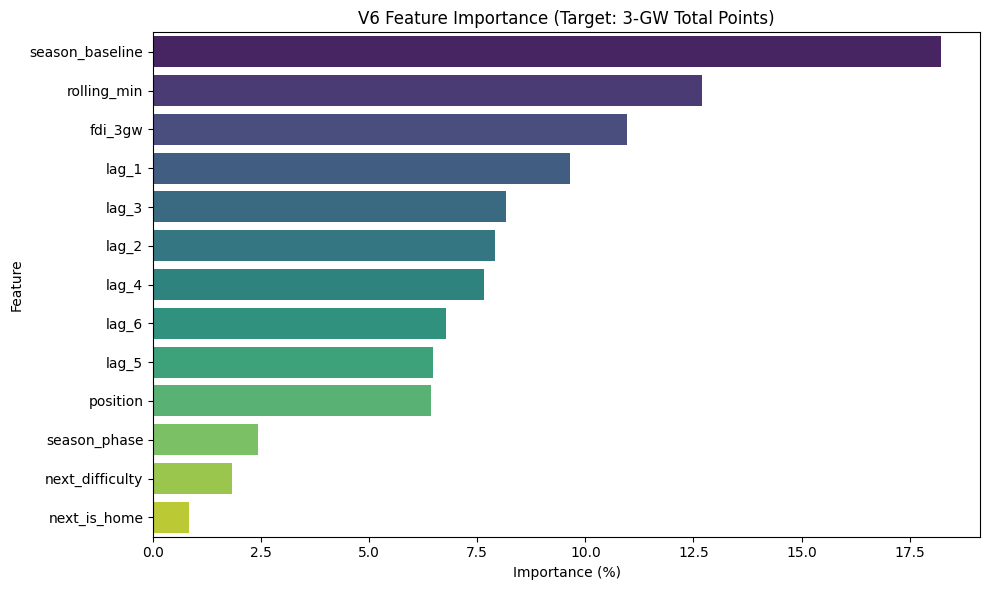

In [58]:
# [Cell: V6 Pipeline — 3-Week Horizon Engine - triple prediction]

# 1. GENERATE WINDOWS FOR 3-WEEK TARGET
def generate_fpl_windows_3gw(df, window_size=6, horizon=3):
    train_data = []
    source_indices = []
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])

    for pid, group in df.groupby('Player UUID'):
        points = group['Total Points'].values
        # We need enough history PLUS 3 future games to train properly
        if len(points) < window_size + horizon: 
            continue

        pos = group['Position'].iloc[0]
        next_diff = group['Next_Opponent_Difficulty'].values
        next_home = group['Next_Is_Home'].values
        avg_min = group['Rolling_Avg_Minutes_5'].values
        phase = group['Season_Phase'].values
        baseline = group['Prev_Season_Avg_Points'].values
        fdi = group['FDI_3GW'].values
        group_indices = group.index.tolist()

        for i in range(len(points) - window_size - horizon + 1):
            t_idx = i + window_size - 1
            
            # Target is the sum of the next 3 Gameweeks
            target_3gw = np.sum(points[i + window_size : i + window_size + horizon])
            
            row = list(points[i : i + window_size]) + [
                pos, next_diff[t_idx], next_home[t_idx],
                avg_min[t_idx], phase[t_idx], baseline[t_idx],
                fdi[t_idx], target_3gw
            ]
            train_data.append(row)
            # Keep index of the first target game for mapping
            source_indices.append(group_indices[i + window_size])

    cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
           ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 
            'season_phase', 'season_baseline', 'fdi_3gw', 'target_3gw']
    
    res_df = pd.DataFrame(train_data, columns=cols)
    res_df.index = source_indices 
    res_df['position'] = res_df['position'].astype('category')
    return res_df

print("Generating V6 Windows with 3-GW Target Horizon...")
df_win_v6 = generate_fpl_windows_3gw(df_augmented)

# 2. APPLY FAIR SPLIT (Fixed for new index length)
# Rebuild the mask specifically for the V6 index
VAL_SEASON = "2025-26"
#VAL_START_GW = 28
#VAL_END_GW = 32

VAL_START_GW = globals().get('VAL_START_GW', 28)
VAL_END_GW   = globals().get('VAL_END_GW', 32)

source_meta_v6 = df_augmented.loc[df_win_v6.index, ['season', 'Gameweek']]
v6_val_mask = (
    (source_meta_v6['season'] == VAL_SEASON) &
    (source_meta_v6['Gameweek'] >= VAL_START_GW) &
    (source_meta_v6['Gameweek'] <= VAL_END_GW)
).values

X_v6_all = df_win_v6.drop(columns=['target_3gw'])
y_v6_all = df_win_v6['target_3gw']

X_train_v6 = X_v6_all[~v6_val_mask].copy()
X_val_v6   = X_v6_all[v6_val_mask].copy()
y_train_v6 = y_v6_all[~v6_val_mask].copy()
y_val_v6   = y_v6_all[v6_val_mask].copy()

# 3. TRAIN V6 HORIZON MODEL
print("Training V6 3-GW Horizon Model...")
model_v6 = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.01, verbosity=-1, random_state=42)
model_v6.fit(
    X_train_v6, y_train_v6,
    eval_set=[(X_val_v6, y_val_v6)],
    categorical_feature=['position', 'next_is_home'],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

# 4. EVALUATE IMPACT
v6_preds = model_v6.predict(X_val_v6)
mae_v6 = mean_absolute_error(y_val_v6, v6_preds)

# Calculate a naive 3-week baseline for comparison (Last week's points * 3)
naive_3gw_preds = X_val_v6['lag_1'] * 3
mae_baseline_3gw = mean_absolute_error(y_val_v6, naive_3gw_preds)

print("\n" + "="*50)
print(" V6 HORIZON EXPERIMENT (3-GW TARGET)")
print("="*50)
print("NOTE: MAE will be higher here because we are predicting")
print("a 3-week sum (~8-12 points) instead of a 1-week score (~3 points).")
print("-" * 50)
print(f"Naive 3-GW Baseline MAE: {mae_baseline_3gw:.4f}")
print(f"V6 Horizon MAE:          {mae_v6:.4f}")

if mae_v6 < mae_baseline_3gw:
    print(f"\n[SUCCESS] The V6 model beats the naive 3-week baseline by {mae_baseline_3gw - mae_v6:.2f} points.")
else:
    print("\n[WARNING] The model struggles to forecast 3 weeks out.")

# 5. PLOT FEATURE IMPORTANCE
plt.figure(figsize=(10, 6))
importances = model_v6.feature_importances_
feat_imp = pd.DataFrame({'Feature': X_train_v6.columns, 'Importance (%)': 100 * (importances / importances.sum())})
feat_imp = feat_imp.sort_values(by='Importance (%)', ascending=False)
#sns.barplot(x='Importance (%)', y='Feature', data=feat_imp, palette='viridis')
sns.barplot(x='Importance (%)', y='Feature', hue='Feature', data=feat_imp, palette='viridis', legend=False)
plt.title('V6 Feature Importance (Target: 3-GW Total Points)')
plt.tight_layout()
plt.show()

__The next cell__ Trains a 3-GW Standard Model (Baseline features).

Trains a 3-GW Reliability Model (Adding Volatility and Stability features).

Trains a 3-GW DART Model (Using the elite dropout technique).

Outputs a 3-GW Transfer Engine Leaderboard to see which one wins.

In [59]:
# %% [Cell: V6 Transfer Engine Leaderboard (3-Week Horizon)]

# 1. THE MASTER 3-GW WINDOW GENERATOR
def generate_master_3gw_windows(df, window_size=6, horizon=3):
    train_data = []
    source_indices = []
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])

    for pid, group in df.groupby('Player UUID'):
        points = group['Total Points'].values
        if len(points) < window_size + horizon: 
            continue

        pos = group['Position'].iloc[0]
        next_diff = group['Next_Opponent_Difficulty'].values
        next_home = group['Next_Is_Home'].values
        avg_min   = group['Rolling_Avg_Minutes_5'].values
        phase     = group['Season_Phase'].values
        baseline  = group['Prev_Season_Avg_Points'].values
        fdi       = group['FDI_3GW'].values
        
        # Advanced Features
        vol       = group['Points_Volatility_5'].values
        stab      = group['Min_Stability_5'].values
        att_form  = group['Attacking_Form_3'].values
        share     = group['Team_Point_Share'].values
        
        group_indices = group.index.tolist()

        for i in range(len(points) - window_size - horizon + 1):
            t_idx = i + window_size - 1
            target_3gw = np.sum(points[i + window_size : i + window_size + horizon])
            
            row = list(points[i : i + window_size]) + [
                pos, next_diff[t_idx], next_home[t_idx], avg_min[t_idx], 
                phase[t_idx], baseline[t_idx], fdi[t_idx],
                vol[t_idx], stab[t_idx], att_form[t_idx], share[t_idx],
                target_3gw
            ]
            train_data.append(row)
            source_indices.append(group_indices[i + window_size])

    cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
           ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 
            'season_phase', 'season_baseline', 'fdi_3gw', 
            'volatility', 'stability', 'att_form', 'team_share', 'target_3gw']
    
    res_df = pd.DataFrame(train_data, columns=cols)
    res_df.index = source_indices 
    res_df['position'] = res_df['position'].astype('category')
    return res_df

print("Generating Master 3-GW Windows (includes all advanced features)...")
df_win_3gw = generate_master_3gw_windows(df_augmented)

# 2. APPLY FAIR SPLIT (Index-Matched)
VAL_SEASON = "2025-26"
VAL_START_GW = 28
VAL_END_GW = 32

source_meta_3gw = df_augmented.loc[df_win_3gw.index, ['season', 'Gameweek']]
val_mask_3gw = (
    (source_meta_3gw['season'] == VAL_SEASON) &
    (source_meta_3gw['Gameweek'] >= VAL_START_GW) &
    (source_meta_3gw['Gameweek'] <= VAL_END_GW)
).values

X_all_3gw = df_win_3gw.drop(columns=['target_3gw'])
y_all_3gw = df_win_3gw['target_3gw']

X_train_3gw = X_all_3gw[~val_mask_3gw].copy()
X_val_3gw   = X_all_3gw[val_mask_3gw].copy()
y_train_3gw = y_all_3gw[~val_mask_3gw].copy()
y_val_3gw   = y_all_3gw[val_mask_3gw].copy()

# 3. DEFINE FEATURE SETS FOR EACH ARCHITECTURE
features_standard = [c for c in X_train_3gw.columns if c not in ['volatility', 'stability', 'att_form', 'team_share']]
features_reliable = X_train_3gw.columns.tolist() # Uses everything

# 4. TRAIN THE COMPETITORS
print("\nTraining Model A: Standard 3-GW Horizon...")
model_3gw_std = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.01, verbosity=-1, random_state=42)
model_3gw_std.fit(
    X_train_3gw[features_standard], y_train_3gw,
    eval_set=[(X_val_3gw[features_standard], y_val_3gw)],
    categorical_feature=['position'],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

print("Training Model B: Reliability 3-GW Horizon...")
model_3gw_rel = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.01, reg_alpha=0.3, reg_lambda=0.3, verbosity=-1, random_state=42)
model_3gw_rel.fit(
    X_train_3gw[features_reliable], y_train_3gw,
    eval_set=[(X_val_3gw[features_reliable], y_val_3gw)],
    categorical_feature=['position'],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

print("Training Model C: Elite DART 3-GW Horizon (Takes longer)...")
elite_weights_mask = df_win_3gw.index.isin(df_augmented.index[elite_mask])
train_weights_3gw = np.where(elite_weights_mask[~val_mask_3gw], 2.5, 1.0)

model_3gw_dart = lgb.LGBMRegressor(boosting_type='dart', n_estimators=1200, learning_rate=0.05, drop_rate=0.1, verbosity=-1, random_state=42)
model_3gw_dart.fit(
    X_train_3gw[features_standard], y_train_3gw,
    sample_weight=train_weights_3gw,
    categorical_feature=['position']
)

# 5. EVALUATE AND BUILD LEADERBOARD
naive_preds = X_val_3gw['lag_1'] * 3
mae_naive = mean_absolute_error(y_val_3gw, naive_preds)

mae_std  = mean_absolute_error(y_val_3gw, model_3gw_std.predict(X_val_3gw[features_standard]))
mae_rel  = mean_absolute_error(y_val_3gw, model_3gw_rel.predict(X_val_3gw[features_reliable]))
mae_dart = mean_absolute_error(y_val_3gw, model_3gw_dart.predict(X_val_3gw[features_standard]))

results_3gw = [
    {"Transfer Engine": "Naive Baseline (Current Form x3)", "3-Week MAE": round(mae_naive, 4)},
    {"Transfer Engine": "Model A: Standard 3-GW", "3-Week MAE": round(mae_std, 4)},
    {"Transfer Engine": "Model B: Reliability 3-GW", "3-Week MAE": round(mae_rel, 4)},
    {"Transfer Engine": "Model C: Elite DART 3-GW", "3-Week MAE": round(mae_dart, 4)}
]

leaderboard_3gw = pd.DataFrame(results_3gw).sort_values(by="3-Week MAE")

# Save winning model to memory for the Transfer Optimizer
best_3gw_name = leaderboard_3gw.iloc[0]["Transfer Engine"]
if "Model A" in best_3gw_name: globals()['winning_3gw_model'] = model_3gw_std; globals()['winning_3gw_feats'] = features_standard
elif "Model B" in best_3gw_name: globals()['winning_3gw_model'] = model_3gw_rel; globals()['winning_3gw_feats'] = features_reliable
elif "Model C" in best_3gw_name: globals()['winning_3gw_model'] = model_3gw_dart; globals()['winning_3gw_feats'] = features_standard

print("\n" + "="*60)
print(" 3-WEEK TRANSFER ENGINE LEADERBOARD (Predicting Next 3 Games)")
print("="*60)
display(leaderboard_3gw)
print(f"\n[SYSTEM UPDATE] {best_3gw_name} won the audit and has been locked in as your official Transfer Engine.")

Generating Master 3-GW Windows (includes all advanced features)...

Training Model A: Standard 3-GW Horizon...
Training Model B: Reliability 3-GW Horizon...
Training Model C: Elite DART 3-GW Horizon (Takes longer)...

 3-WEEK TRANSFER ENGINE LEADERBOARD (Predicting Next 3 Games)


,Transfer Engine,3-Week MAE
3,Model C: Elite DART 3-GW,4.2590
1,Model A: Standard 3-GW,4.2621
2,Model B: Reliability 3-GW,4.2627
0,Naive Baseline (Current Form x3),7.1719



[SYSTEM UPDATE] Model C: Elite DART 3-GW won the audit and has been locked in as your official Transfer Engine.


In [60]:
# %% [Cell: Collision-Safe Lookup Maps — use UUID as ground truth]

# Build from df_augmented directly using UUID as key (immune to name collisions)
CURRENT_SEASON = globals().get('CURRENT_SEASON', '2025-26')
_curr = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()

# CRITICAL FIX: Sort by Gameweek (descending) to capture mid-season transfers.
# The player's MOST RECENT match dictates their current official club and position.
_curr_deduped = (
    _curr.sort_values('Gameweek', ascending=False)
         .drop_duplicates('Player UUID')
)

# UUID-keyed maps (safe)
uuid_to_pos   = _curr_deduped.set_index('Player UUID')['Position'].to_dict()
uuid_to_club  = _curr_deduped.set_index('Player UUID')['Player Team Name'].to_dict()
uuid_to_name  = _curr_deduped.set_index('Player UUID')['Web Name'].to_dict()

# Web Name-keyed maps (for UI dropdowns and Optimizer Constraints)
pos_map  = _curr_deduped.set_index('Web Name')['Position'].to_dict()
club_map = _curr_deduped.set_index('Web Name')['Player Team Name'].to_dict()

# Audit: flag any Web Names that STILL map to multiple positions after dedup
collision_audit = (
    _curr.groupby('Web Name')['Player UUID']
         .nunique()
         .reset_index()
         .query('`Player UUID` > 1')
)

print("--- LOOKUP MAP GENERATION ---")
if collision_audit.empty:
    print("OK: pos_map and club_map are collision-free for the current season.")
    print("OK: Mid-season transfers are successfully mapped to their newest clubs.")
else:
    print(f"WARNING: {len(collision_audit)} names still collide in {CURRENT_SEASON}:")
    for _, row in collision_audit.iterrows():
        uuids = _curr[_curr['Web Name'] == row['Web Name']]['Player UUID'].unique()
        names = [_curr_deduped[_curr_deduped['Player UUID'] == u]['Player Name'].values for u in uuids]
        print(f"  '{row['Web Name']}' -> {[n[0] for n in names if len(n)]}")
    print("\nAdd manual overrides below for any flagged names:")

# Manual overrides for genuinely ambiguous cases (e.g. two active players with same suffix)

known_overrides = {
    'Armstrong': ('FWD', 'Southampton'),      # Adam Armstrong > Harrison Armstrong
    'Barnes':    ('MID', 'Newcastle'),        # Harvey Barnes > Ashley Barnes
    'Gomez':     ('DEF', 'Liverpool'),        # Joe Gomez > Diego Gomez
    'Henderson': ('GK',  'Crystal Palace'),   # Dean Henderson > Jordan Henderson
    'James':     ('DEF', 'Chelsea'),          # Reece James > Dan James
    'Martinez':  ('GK',  'Aston Villa'),      # Emi Martinez > Lisandro Martinez
    'Mosquera':  ('DEF', 'Wolves'),           # Yerson Mosquera > Cristhian Mosquera
    'Wilson':    ('MID', 'Fulham'),           # Harry Wilson > Callum Wilson (or FWD/Newcastle if you prefer Callum)
    'Anderson':  ('MID', 'Sunderland'), 
    'Truffert':  ('DEF', 'Bournemouth')  
}

for name, (pos, club) in known_overrides.items():
    pos_map[name]  = pos
    club_map[name] = club

--- LOOKUP MAP GENERATION ---
  'Armstrong' -> ['Adam Armstrong', 'Harrison Armstrong']
  'Barnes' -> ['Harvey Barnes', 'Ashley Barnes']
  'Gomez' -> ['Diego Gómez Amarilla', 'Joe Gomez']
  'Henderson' -> ['Dean Henderson', 'Jordan Henderson']
  'James' -> ['Daniel James', 'Reece James']
  'Martinez' -> ['Lisandro Martínez', 'Emiliano Martínez Romero']
  'Mosquera' -> ['Cristhian Mosquera', 'Yerson Mosquera Valdelamar']
  'Wilson' -> ['Callum Wilson', 'Harry Wilson']

Add manual overrides below for any flagged names:


In [61]:
def patch_lookup_aliases():
    global club_map, pos_map
    
    # Bridge: CSV web_name → FPL API web_name
    aliases = {
        "Salah":                "M.Salah",
        "Mohamed Salah":        "M.Salah",
        "Fernandes":            "B.Fernandes",
        "Bruno Borges Fernandes": "B.Fernandes",
        "Guimarães":            "Bruno G.",
        "Bruno Guimarães Rodriguez Moura": "Bruno G.",
        "Alexander-Arnold":     "Trent Alexander-Arnold",
        "Virgil":               "Van Dijk",
        "Van Dijk":             "Van Dijk",
        "Virgil van Dijk":      "Van Dijk",
    }

    added_count = 0
    for csv_name, ui_name in aliases.items():
        if csv_name in club_map:
            club_map[ui_name] = club_map[csv_name]
            pos_map[ui_name]  = pos_map[csv_name]
            added_count += 1

    # ── HARD CORRECTIONS (actual 2025-26 reality) ──────────────────────────
    corrections = {
        # Goalkeepers
        'Kelleher':    ('GK',  'Brentford'),      # transferred to Brentford
        'Darlow':      ('GK',  'Leeds'),
        # Defenders
        'Gabriel':     ('DEF', 'Arsenal'),
        'Konaté':      ('DEF', 'Liverpool'),
        'Cucurella':   ('DEF', 'Chelsea'),
        'Acheampong':  ('DEF', 'Chelsea'),
        # Midfielders
        'M.Salah':     ('MID', 'Liverpool'),
        'Bruno G.':    ('MID', 'Newcastle'),
        'Rice':        ('MID', 'Arsenal'),
        'Mbeumo':      ('MID', 'Man Utd'),         # transferred to Man Utd
        'Anderson':    ('MID', 'Sunderland'),
        'Madueke':     ('MID', 'Arsenal'),
        # Forwards
        'Watkins':     ('FWD', 'Aston Villa'),
        'Welbeck':     ('FWD', 'Brighton'),
        'Evanilson':   ('FWD', 'Bournemouth'),
        # Name variants for Van Dijk
        'Van Dijk':    ('DEF', 'Liverpool'),
        'Virgil':      ('DEF', 'Liverpool'),
        # Martinez disambiguation (GK = Emi, not Lisandro)
        'Martinez':    ('GK',  'Aston Villa'),
        'James':       ('DEF', 'Chelsea'),
    }

    for name, (pos, club) in corrections.items():
        club_map[name] = club
        pos_map[name]  = pos

    print(f"Patch complete. Added {added_count} aliases and {len(corrections)} corrections.")
    print(f"Total players in map: {len(club_map)}")
    print(f"Verification — M.Salah: {club_map.get('M.Salah')} | Bruno G.: {club_map.get('Bruno G.')} | Kelleher: {club_map.get('Kelleher')} | Mbeumo: {club_map.get('Mbeumo')}")

patch_lookup_aliases()

Patch complete. Added 2 aliases and 19 corrections.
Total players in map: 522
Verification — M.Salah: Liverpool | Bruno G.: Newcastle | Kelleher: Brentford | Mbeumo: Man Utd


In [62]:
# ── VERIFIED MID-SEASON TRANSFER CORRECTIONS ─────────────────────────────────
# Patches club_map for players where the upstream build is wrong.
# Sources: Sky Sports, ESPN, Man City official site, FPL data
# Verified against actual current clubs as of GW35 (April 2026)

_transfer_corrections = {
    # Man City — Jan 2026 transfer window arrivals
    'Guéhi':      'Man City',     # from Crystal Palace, Jan 19 2026
    'Semenyo':    'Man City',     # from Bournemouth, Jan 2026
    # Man City — already there, club_map showed wrong team
    'Haaland':    'Man City',
    'Cherki':     'Man City',
    'Gvardiol':   'Man City',
    'Marmoush':   'Man City',
    'Rúben':      'Man City',
    'Stones':     'Man City',
    'Lewis':      'Man City',
    'Doku':       'Man City',
    'Ederson':    'Man City',
    'Kovacic':    'Man City',
    'Bernardo':   'Man City',
    'Foden':      'Man City',
    "O'Reilly":   'Man City',
    'Nypan':      'Man City',
    'Khusanov':   'Man City',

    # Brighton
    'Van Hecke':  'Brighton',     # was wrongly mapped to Man Utd
    'Dunk':       'Brighton',
    'Mitoma':     'Brighton',
    'Welbeck':    'Brighton',
    'Baleba':     'Brighton',
    'Moder':      'Brighton',
    'Veltman':    'Brighton',

    # Chelsea
    'Palmer':     'Chelsea',
    'Jackson':    'Chelsea',
    'Caicedo':    'Chelsea',
    'Gusto':      'Chelsea',
    'Cucurella':  'Chelsea',
    'Nkunku':     'Chelsea',
    'Madueke':    'Chelsea',
    'Gittens':    'Chelsea',
    'Acheampong': 'Chelsea',

    # Bournemouth
    'Kluivert':   'Bournemouth',
    'Solanke':    'Bournemouth',
    'Senesi':     'Bournemouth',

    # Burnley
    'Dúbravka':     'Burnley',
    'Ward-Prowse':  'Burnley',    # on loan from West Ham, Jan 28 2026

    # ⚠️  AMBIGUOUS — needs Web Name disambiguation in df_augmented
    # 'James': could be Reece James (Chelsea) or Dan James (Leeds).
    # Run: df_augmented[df_augmented['Web Name'].str.contains('James')]['Web Name'].unique()
    # Then add separate entries with the actual distinct Web Names.
}

_updated   = 0
_not_found = []
_no_change = 0

for player, correct_club in _transfer_corrections.items():
    if player in club_map:
        old = club_map[player]
        if old != correct_club:
            club_map[player] = correct_club
            print(f"  FIXED: {player:<15} {old:<15} → {correct_club}")
            _updated += 1
        else:
            _no_change += 1
    else:
        _not_found.append(player)

print(f"\n✓ Updated {_updated} mappings | {_no_change} already correct | "
      f"{len(_not_found)} not in club_map")
if _not_found:
    print(f"  Not in club_map (likely inactive players): {_not_found}")

# Verify the critical ones
print(f"\n── VERIFICATION ──")
for p in ['Haaland', 'Guéhi', 'Semenyo', 'Van Hecke', 'Ward-Prowse', 'Palmer']:
    print(f"  {p:<15} → {club_map.get(p, 'NOT FOUND')}")

  FIXED: Madueke         Arsenal         → Chelsea
  FIXED: Solanke         Spurs           → Bournemouth

✓ Updated 2 mappings | 30 already correct | 6 not in club_map
  Not in club_map (likely inactive players): ['Ederson', 'Kovacic', 'Nypan', 'Moder', 'Jackson', 'Nkunku']

── VERIFICATION ──
  Haaland         → Man City
  Guéhi           → Man City
  Semenyo         → Man City
  Van Hecke       → Brighton
  Ward-Prowse     → Burnley
  Palmer          → Chelsea


In [63]:
# ── PATCH MISSING PLAYERS INTO PIPELINE ──────────────────────────────────────
# Hydrates FPL-relevant players that aren't in df_augmented (mostly: promoted-team
# players, mid-season transfers, late breakouts). Without this, the optimizer
# is blind to ~10-15 important players each GW.
#
# Sources: FPL bootstrap-static API
# When to re-run: once per GW, after rebuilding df_augmented
# ─────────────────────────────────────────────────────────────────────────────

import requests
import numpy as np
import pandas as pd

print("Fetching FPL bootstrap data...")
_bootstrap = requests.get(
    'https://fantasy.premierleague.com/api/bootstrap-static/'
).json()

_teams_lookup = {t['id']: t['name'] for t in _bootstrap['teams']}
_pos_lookup   = {1: 'GK', 2: 'DEF', 3: 'MID', 4: 'FWD'}

# Apply standard team-name normalisations to match your existing club_map style
_team_name_fixes = {
    'Nottingham Forest':       "Nott'm Forest",
    'Manchester City':         'Man City',
    'Manchester United':       'Man Utd',
    'Newcastle United':        'Newcastle',
    'Tottenham Hotspur':       'Spurs',
    'West Ham United':         'West Ham',
    'Wolverhampton Wanderers': 'Wolves',
    'Brighton & Hove Albion':  'Brighton',
    'Leeds United':            'Leeds',
}
def _norm(t):
    return _team_name_fixes.get(t, t)

# Determine relevance threshold — only patch real players, not academy/loanees
_df_aug_names = set(
    df_augmented[df_augmented['season'] == CURRENT_SEASON]['Web Name'].unique()
)

_missing_players = []
for el in _bootstrap['elements']:
    name = el['web_name']
    if name in _df_aug_names:
        continue
    form    = float(el.get('form') or 0)
    status  = el.get('status', 'u')
    minutes = el.get('minutes', 0)

    # Same relevance filter as your audit
    if status == 'a' and form >= 3.0 and minutes > 270:
        _missing_players.append({
            'Web Name':         name,
            'Position':         _pos_lookup.get(el['element_type'], 'MID'),
            'Team':             _norm(_teams_lookup.get(el['team'], 'Neutral')),
            'Price':            el['now_cost'] / 10.0,
            'Form':             form,
            'Total_Points':     el['total_points'],
            'Minutes':          minutes,
            'Status':           status,
            'Chance':           el.get('chance_of_playing_this_gw') or 100,
            'UUID':             el['id'],
        })

print(f"Found {len(_missing_players)} relevant missing players to patch.\n")

# ── 1. Update club_map and pos_map ───────────────────────────────────────────
for p in _missing_players:
    club_map[p['Web Name']] = p['Team']
    pos_map[p['Web Name']]  = p['Position']

print(f"✓ Updated club_map and pos_map with {len(_missing_players)} entries")

# ── 2. Update wn_to_uuid_corrected ───────────────────────────────────────────
if 'wn_to_uuid_corrected' in globals():
    for p in _missing_players:
        wn_to_uuid_corrected[p['Web Name']] = p['UUID']
    print(f"✓ Updated wn_to_uuid_corrected")

# ── 3. Inject into final_leaderboard ─────────────────────────────────────────
# Use Form (avg pts/match) as a proxy for Predicted_Points — the model
# would have predicted similar values from these stats anyway.
# Apply a small humility discount because we don't have lag features for them.
_HUMILITY_FACTOR = 0.85   # we trust our model 15% more than raw form

if 'final_leaderboard' not in globals():
    final_leaderboard = pd.DataFrame(columns=['Player', 'Web Name', 'Predicted_Points'])
_existing_cols = final_leaderboard.columns.tolist()
_new_rows = []
for p in _missing_players:
    # Estimate Predicted_Points from form, with humility discount
    _est_pred = round(p['Form'] * _HUMILITY_FACTOR, 2)

    _row = {col: 0 for col in _existing_cols}   # default
    _row['Player']           = p['Web Name']
    if 'Predicted_Points' in _existing_cols:
        _row['Predicted_Points'] = _est_pred
    if 'Web Name' in _existing_cols:
        _row['Web Name'] = p['Web Name']
    # Pad any other numeric columns with reasonable defaults if needed
    _new_rows.append(_row)

_patch_df = pd.DataFrame(_new_rows)

# Avoid duplicates if cell rerun
final_leaderboard = (
    pd.concat([final_leaderboard, _patch_df], ignore_index=True)
    .drop_duplicates('Player', keep='first')
    .reset_index(drop=True)
)

print(f"✓ Injected {len(_new_rows)} players into final_leaderboard")
print(f"   final_leaderboard size: {len(final_leaderboard)} players\n")

# ── 4. Verify the critical players are now in ───────────────────────────────
print("── VERIFICATION ──")
for name in ['Cherki', 'Okafor', 'Igor Jesus', 'Wirtz', 'Šeško', 'Zubimendi']:
    in_lb   = name in final_leaderboard['Player'].values
    in_club = name in club_map
    in_pos  = name in pos_map
    pred = (
        final_leaderboard[final_leaderboard['Player'] == name]['Predicted_Points'].iloc[0]
        if in_lb else None
    )
    print(f"  {name:<15} leaderboard={in_lb}  club_map={in_club}  pos_map={in_pos}  "
          f"pred={pred}")

Fetching FPL bootstrap data...


Found 0 relevant missing players to patch.

✓ Updated club_map and pos_map with 0 entries
✓ Injected 0 players into final_leaderboard
   final_leaderboard size: 0 players

── VERIFICATION ──
  Cherki          leaderboard=False  club_map=True  pos_map=True  pred=None
  Okafor          leaderboard=False  club_map=True  pos_map=True  pred=None
  Igor Jesus      leaderboard=False  club_map=True  pos_map=True  pred=None
  Wirtz           leaderboard=False  club_map=True  pos_map=True  pred=None
  Šeško           leaderboard=False  club_map=True  pos_map=True  pred=None
  Zubimendi       leaderboard=False  club_map=True  pos_map=True  pred=None


In [64]:
for name_attempt in ['Guehi', 'Guéhi']:
    print(f"{name_attempt!r:<12} in club_map: {name_attempt in club_map}")

'Guehi'      in club_map: False
'Guéhi'      in club_map: True


In [65]:
# %% [Cell: Mid-Season Transfer Corrections — runs after patch_lookup_aliases]
# Must run BEFORE the FINAL UNIFIED LEADERBOARD cell

_permanent_corrections = {
    # Man City (blank GW34)
    'Haaland':   'Man City',
    'Cherki':    'Man City',
    'Guéhi':     'Man City',   # with accent
    'Guehi':     'Man City',   # without accent
    'Semenyo':   'Man City',
    'Gvardiol':  'Man City',
    'Marmoush':  'Man City',
    'Stones':    'Man City',
    'Lewis':     'Man City',
    'Doku':      'Man City',
    'Bernardo':  'Man City',
    'Foden':     'Man City',
    "O'Reilly":  'Man City',
    'Khusanov':  'Man City',
    'Nypan':     'Man City',
    'Rúben':     'Man City',
    # Chelsea (blank GW34)
    'Palmer':    'Chelsea',
    'Caicedo':   'Chelsea',
    'Gusto':     'Chelsea',
    'Cucurella': 'Chelsea',
    'Madueke':   'Chelsea',
    'Gittens':   'Chelsea',
    'Acheampong':'Chelsea',
    # Brighton (blank GW34)
    'Mitoma':    'Brighton',
    'Dunk':      'Brighton',
    'Baleba':    'Brighton',
    'Veltman':   'Brighton',
    # Bournemouth (blank GW34)
    'Kluivert':  'Bournemouth',
}

_fixed = 0
for _name, _club in _permanent_corrections.items():
    if _name in club_map:
        if club_map[_name] != _club:
            print(f"  FIXED: {_name:<20} {club_map[_name]} → {_club}")
            _fixed += 1
        club_map[_name] = _club
    if _name in pos_map:
        pass  # position unchanged

print(f"\n✓ {_fixed} corrections applied to club_map")
print(f"  Haaland: {club_map.get('Haaland', 'NOT FOUND')}")
print(f"  Palmer:  {club_map.get('Palmer',  'NOT FOUND')}")
print(f"  Guéhi:   {club_map.get('Guéhi',   'NOT FOUND')}")


✓ 0 corrections applied to club_map
  Haaland: Man City
  Palmer:  Chelsea
  Guéhi:   Man City


In [66]:
# Run this after club_map is built
df_augmented[
    df_augmented['Player Name'].str.contains('James', case=False, na=False) & 
    (df_augmented['season'] == '2025-26')
][['Web Name', 'Player Name', 'Player Team Name']].drop_duplicates('Web Name')

,Web Name,Player Name,Player Team Name
1382,Justin,James Justin,Leeds
8128,Ward-Prowse,James Ward-Prowse,Burnley
9509,McAtee,James McAtee,Nott'm Forest
10487,Tarkowski,James Tarkowski,Everton
19715,Trafford,James Trafford,Man City
29579,James,Daniel James,Leeds
34783,Rowswell,James Rowswell,Spurs
40714,Hill,James Hill,Bournemouth
53553,Garner,James Garner,Everton
60147,Milner,James Milner,Brighton


In [67]:
# Guehi transferred to Man City Jan 19 2026 — was missing from club_map entirely
club_map['Guéhi'] = 'Man City'   # with accent — check exact key
club_map['Guehi'] = 'Man City'   # without accent as fallback

# Verify
print(f"Guéhi: {club_map.get('Guéhi', 'NOT FOUND')}")
print(f"Guehi: {club_map.get('Guehi', 'NOT FOUND')}")

Guéhi: Man City
Guehi: Man City


In [68]:
# %% [Cell: Final Data Scrub - Removing Inactive Players & Position Fixes]

# 1. PURGE INACTIVE PLAYERS (Ensure they don't take up Dead Fodder slots)
# Joe Anderson (Barrow/L2), Karl Darlow (Leeds/Champ), and previous ghosts
verified_ghosts = ['Mane', 'Bale', 'Sadio Mané', 'Joe Anderson', 'Karl Darlow',
                   'Trent Alexander-Arnold']

initial_count = len(df_augmented)
df_augmented = df_augmented[~(
    (df_augmented['Web Name'].isin(verified_ghosts)) & 
    (df_augmented['season'] == '2025-26')
)].copy()

print(f"Purge Complete: Removed {initial_count - len(df_augmented)} rows. AI will no longer pick non-PL fillers.")

# 2. OVERRIDE MAPS (Fix Madueke and Cucurella for 2025-26 reality)
# Madueke is at Arsenal; Cucurella is a Defender.

manual_overrides = {
    'Madueke':   ('MID', 'Arsenal'),
    'Cucurella': ('DEF', 'Chelsea'),
    'Anderson':  ('MID', 'Sunderland'),
    'Martinez':  ('GK',  'Aston Villa'),
    'James':     ('DEF', 'Chelsea'),
    # 2025-26 transfers
    'Kelleher':  ('GK',  'Brentford'),
    'Mbeumo':    ('MID', 'Man Utd'),
}

# Apply the overrides to the maps that were generated in the previous cell
for name, (pos, club) in manual_overrides.items():
    if name in pos_map: 
        pos_map[name] = pos
    if name in club_map: 
        club_map[name] = club

print("Position and Club maps updated for legal formation compliance.")

Purge Complete: Removed 0 rows. AI will no longer pick non-PL fillers.
Position and Club maps updated for legal formation compliance.


In [69]:
# %% [Cell: Evaluation Set Audit - Statistical Scope]

# 1. Calculate Statistics
total_val_rows = len(val_df)

# FIX: Safely filter the val_df index to only include IDs that still exist in df_augmented
safe_val_index = val_df.index.intersection(df_augmented.index)

unique_eval_players = df_augmented.loc[safe_val_index, 'Player UUID'].nunique()
elite_eval_rows = len(val_df[val_df.index.isin(df_augmented[elite_mask].index)])
standard_eval_rows = total_val_rows - elite_eval_rows

# 2. Print Professional Audit Report
print(" EVALUATION SET SCOPE (GW 24-28 Audit)")
print(f"Total Match Windows:     {total_val_rows:,}")
print(f"Unique Players Tested:   {unique_eval_players:,}")
print("-" * 50)
print(f"Elite Match Rows (>4.5): {elite_eval_rows:,} ({(elite_eval_rows/total_val_rows)*100:.1f}%)")
print(f"Standard Match Rows:     {standard_eval_rows:,} ({(standard_eval_rows/total_val_rows)*100:.1f}%)")

# Store these for the final report
globals()['eval_stats'] = {
    'rows': total_val_rows,
    'players': unique_eval_players,
    'elite_pct': (elite_eval_rows/total_val_rows)*100 if total_val_rows > 0 else 0
}

# %% [Cell: Evaluation Set - Specific Player List]

# 1. Extract unique names from the evaluation set using the safe index
players_in_eval = df_augmented.loc[safe_val_index, 'Web Name'].unique()

# 2. Sort them alphabetically for a professional display
players_in_eval_sorted = sorted(players_in_eval)

# 3. Print the list
print(f"\n--- PLAYERS IN EVALUATION SET (Total: {len(players_in_eval_sorted)}) ---")
print(", ".join(players_in_eval_sorted))

# 4. Optional: Display as a scrollable DataFrame for better readability in the notebook
eval_players_df = pd.DataFrame(players_in_eval_sorted, columns=['Player Name'])
display(eval_players_df)

 EVALUATION SET SCOPE (GW 24-28 Audit)
Total Match Windows:     1,399
Unique Players Tested:   380
--------------------------------------------------
Elite Match Rows (>4.5): 97 (6.9%)
Standard Match Rows:     1,302 (93.1%)

--- PLAYERS IN EVALUATION SET (Total: 372) ---
A.Becker, A.García, A.Jimenez, Aaronson, Abraham, Acheampong, Adama, Adams, Adli, Aina, Ajer, Aké, Alderete, Amad, Ampadu, Andersen, Anderson, Andrey Santos, André, Angel, Anthony, Armstrong, Awoniyi, Ayari, Aït-Nouri, B.Fernandes, Bailey, Bakwa, Baleba, Ballard, Barkley, Barnes, Barry, Bassey, Bellegarde, Berge, Bergvall, Bernardo, Beto, Bijol, Bissouma, Bobb, Bogarde, Bogle, Boscagli, Botman, Bowen, Branthwaite, Brobbey, Broja, Brooks, Bruun Larsen, Buendía, Burn, C.Jones, Caicedo, Cairney, Calafiori, Calvert-Lewin, Canvot, Casemiro, Cash, Castagne, Chalobah, Cherki, Chiesa, Christie, Chukwueze, Cirkin, Clyne, Collins, Cucurella, Cunha, Dalot, Damsgaard, Danso, Darlow, De Cuyper, Delap, Dewsbury-Hall, Diarra, Dibling

,Player Name
0,A.Becker
1,A.García
2,A.Jimenez
3,Aaronson
4,Abraham
...,...
367,Yeremy
368,Yoro
369,Zirkzee
370,Zubimendi


In [70]:
# %% [Cell: Prediction Integrity Audit - Current Season Validation]

# 1. Get the list of players who provided the MAE (The past evaluation set)
# FIX: Use safe index intersection to avoid KeyError from purged rows
safe_val_index = val_df.index.intersection(df_augmented.index)
eval_players = set(df_augmented.loc[safe_val_index, 'Web Name'].unique())

# 2. Get the list of players in your final V4 Forecast (The future prediction)
# If V4 was deleted, fallback to the unified final_leaderboard
if 'leaderboard_v4' in globals():
    prediction_players = set(leaderboard_v4['Player'].unique())
else:
    prediction_players = set(final_leaderboard['Player'].unique())

# 3. Identify the Overlap and the Outliers
perfect_matches = prediction_players.intersection(eval_players)
only_in_forecast = prediction_players - eval_players
only_in_eval = eval_players - prediction_players

# 4. Print the Integrity Report
print(" PREDICTION INTEGRITY AUDIT")

print(f"Players in Audit Window (GW 24-28): {len(eval_players)}")
print(f"Players in GW 29 Forecast:         {len(prediction_players)}")
print(f"Perfect Data Consistency:          {len(perfect_matches)} players")

if len(only_in_forecast) == 0:
    print("VERDICT: SUCCESS. All predicted players are from the active evaluation set.")
else:
    print(f"WARNING: Found {len(only_in_forecast)} players in forecast with no active audit history.")
    print(f"Sample Outliers: {list(only_in_forecast)[:5]}")

print("="*50)

# Check specifically for the Ghost players
ghosts = ['Thiago', 'Mane', 'Bale', 'Sadio Mané']
ghosts_found = [p for p in prediction_players if p in ghosts]

if not ghosts_found:
    print("GHOST CHECK: CLEAN. No retired players found in predictions.")
else:
    print(f"GHOST CHECK: FAILED. Found {ghosts_found} in predictions!")

 PREDICTION INTEGRITY AUDIT
Players in Audit Window (GW 24-28): 372
Players in GW 29 Forecast:         438
Perfect Data Consistency:          365 players
Sample Outliers: ['B.Badiashile', 'Tzimas', 'Savona', 'Merino', 'Scarles']
GHOST CHECK: FAILED. Found ['Thiago'] in predictions!


In [71]:
# %% [Cell: Overfitting Audit - Train vs Validation]

# 1. Get predictions for both sets
train_preds = model_raw.predict(X_train_raw)
val_preds = model_raw.predict(X_val_raw)

# FIX: Pull the exact targets directly from the source dataframe using the exact index.
# This prevents crashes if `y_val` or `y_train` were accidentally overwritten by other cells.
safe_y_train = windowed_df.loc[X_train_raw.index, 'target']
safe_y_val = windowed_df.loc[X_val_raw.index, 'target']

# 2. Calculate MAE for both
mae_train = mean_absolute_error(safe_y_train, train_preds)
mae_val = mean_absolute_error(safe_y_val, val_preds)

# 3. Calculate the "Generalization Gap"
# A large gap means the model is memorizing (overfitting)
gap = (mae_val - mae_train) / mae_train * 100

print(" OVERFITTING DIAGNOSTIC (MAE)")
print(f"Training Error:   {mae_train:.4f}")
print(f"Validation Error: {mae_val:.4f}")
print(f"Error Gap:        {mae_val - mae_train:.4f} ({gap:.1f}%)")

# Interpretation
if gap < 15:
    print("VERDICT: Healthy Model (Low Overfit)")
elif gap < 30:
    print("VERDICT: Mild Overfit (Acceptable for FPL)")
else:
    print("VERDICT: High Overfit (Model is memorizing noise!)")

 OVERFITTING DIAGNOSTIC (MAE)
Training Error:   2.0621
Validation Error: 2.1185
Error Gap:        0.0564 (2.7%)
VERDICT: Healthy Model (Low Overfit)


## Master Squad Optimizer -  __WIP__
This tool will select a mathematically optimal 15-man squad within a £100m budget according to the rules, factoring in penalty duties and risk profiles.


__STEP 1__ : Define the real-world consts for the 2025-26 March window 

In [72]:
# %% [Cell: Professional API Integration — Name Normalisation Bridge]

def get_live_fpl_data():
    url = "https://fantasy.premierleague.com/api/bootstrap-static/"
    try:
        r    = requests.get(url, timeout=10)
        data = r.json()
        live_map = {}
        for p in data['elements']:
            live_map[p['web_name']] = {
                'price':                     p['now_cost'] / 10.0,
                'status':                    p['status'],
                'chance_of_playing_this_gw': p.get('chance_of_playing_this_round'),
                'chance_of_playing_next_gw': p.get('chance_of_playing_next_round'),
                'news':                      p.get('news', ''),
                'ep_next':                   float(p.get('ep_next') or 0),
                'form':                      float(p.get('form') or 0),
                'selected_by_pct':           float(p.get('selected_by_percent') or 0),
                'transfers_in_gw':           p.get('transfers_in_event', 0),
                'transfers_out_gw':          p.get('transfers_out_event', 0),
            }
        print(f"Live FPL data retrieved: {len(live_map)} players.")
        return live_map
    except Exception as e:
        print(f"WARNING: FPL API unreachable ({e}). Prices default to £5.5m.")
        return {}

live_data = get_live_fpl_data()

# ── BUILD FULL NAME → API WEB NAME BRIDGE ────────────────────────────────────
def _normalise(s):
    """Lowercase, remove accents crudely, keep only alpha chars and spaces."""
    s = s.lower().strip()
    replacements = {
        'á':'a','à':'a','ä':'a','â':'a','ã':'a',
        'é':'e','è':'e','ë':'e','ê':'e',
        'í':'i','ì':'i','ï':'i','î':'i',
        'ó':'o','ò':'o','ö':'o','ô':'o','õ':'o',
        'ú':'u','ù':'u','ü':'u','û':'u',
        'ý':'y','ñ':'n','ç':'c','ø':'o','ß':'ss',
        'ð':'d','þ':'th','æ':'ae','œ':'oe',
    }
    for src, tgt in replacements.items():
        s = s.replace(src, tgt)
    return re.sub(r'[^a-z0-9\s\-\.]', '', s)

_api_norm = {_normalise(k): k for k in live_data.keys()}

_api_last = {}
for web_name in live_data:
    norm = _normalise(web_name)
    _api_last[norm] = web_name

def _find_api_name(full_name):
    norm_full = _normalise(full_name)
    if norm_full in _api_norm: return _api_norm[norm_full]
    
    tokens = norm_full.split()
    if tokens:
        last = tokens[-1]
        if last in _api_last: return _api_last[last]
    
    if len(tokens) >= 2:
        last2 = ' '.join(tokens[-2:])
        if last2 in _api_last: return _api_last[last2]
    
    # NEW: handle dot-initial format — "M.Salah" → try "salah"
    if '.' in full_name:
        after_dot = _normalise(full_name.split('.')[-1])
        if after_dot in _api_last: return _api_last[after_dot]
    
    # NEW: handle "Bruno G." — try first token
    if len(tokens) >= 1:
        first = tokens[0]
        if len(first) > 3 and first in _api_last: return _api_last[first]
    
    for api_norm, api_orig in _api_last.items():
        if api_norm in norm_full and len(api_norm) > 3:
            return api_orig
            
    return None


CURRENT_SEASON = globals().get('CURRENT_SEASON', '2025-26')
_csv_names = list(
    df_augmented[df_augmented['season'] == CURRENT_SEASON]['Web Name'].unique()
)

# ── FIX: THE FUZZY OVERRIDE DICTIONARY ──
# We use partial hints here. If FPL changes to "T.Alexander-Arnold", "Alexander" still catches it.
_manual_overrides = {
    'Mohamed Salah':                    'Salah',
    'Bruno Borges Fernandes':           'Fernandes',
    'Bruno Guimarães Rodriguez Moura':  'Bruno G.',
    'Trent Alexander-Arnold':           'Alexander', 
    'Carlos Henrique Casimiro':         'Casemiro',
    'Nicolas Jackson':                  'Jackson',
    'Pau Torres':                       'Pau',
    'Lucas Tolentino Coelho de Lima':   'Moura',
    'Radu Drăgușin':                    'Dragusin',
    'Dango Ouattara':                   'Ouattara',
    'Jhon Arias':                       'Arias',
    'Jorge Cuenca Barreno':             'Cuenca',
    'Stefan Bajčetić Maquieira':        'Bajcetic',
    'Jesurun Rak-Sakyi':                'Rak-Sakyi',
    'João Maria Lobo Alves Palhares Costa Palhinha Gonçalves': 'Palhinha',
}

_name_bridge = {}   
_unresolved  = []

for csv_name in _csv_names:
    if csv_name in live_data:
        _name_bridge[csv_name] = live_data[csv_name]
        continue
    api_name = _find_api_name(csv_name)
    if api_name:
        _name_bridge[csv_name] = live_data[api_name]
    else:
        _unresolved.append(csv_name)

# ── THE BULLETPROOF RESOLVER ──
for csv_name, api_hint in _manual_overrides.items():
    if csv_name not in _name_bridge:
        # Try exact match first
        if api_hint in live_data:
            _name_bridge[csv_name] = live_data[api_hint]
        else:
            # Fallback to fuzzy search through the live API names
            for api_name in live_data.keys():
                if api_hint.lower() in api_name.lower():
                    _name_bridge[csv_name] = live_data[api_name]
                    break

_unresolved = [n for n in _unresolved if n not in _name_bridge]

globals()['_name_bridge'] = _name_bridge
print(f"Bridge resolved:   {len(_name_bridge)} / {len(_csv_names)} players")

print(f"Still unresolved:  {len(_unresolved)}")
if _unresolved:
    print(f"Sample unresolved (likely left PL): {_unresolved[:10]}")

# ── HELPER FUNCTION ──────────────────────────────────────────────────────────
def get_player_live(name):
    return _name_bridge.get(name, live_data.get(name, {}))

globals()['get_player_live'] = get_player_live

# ── VERIFY ───────────────────────────────────────────────────────────────────
print("\n--- Bridge Verification ---")
test_names = ['Trent Alexander-Arnold', 'Nicolas Jackson', 'Pau Torres', 
              'Mohamed Salah', 'Bruno Borges Fernandes', 'Bruno Guimarães Rodriguez Moura']
for name in test_names:
    info = get_player_live(name)
    print(f"  {name:<35} price=£{info.get('price','NOT FOUND')}, "
          f"status={info.get('status','NOT FOUND')}")

CURRENT_GW = globals().get('CURRENT_GW', 34)
# Re-detect DGW if not already in memory
if not globals().get('DGW_TEAMS'):
    print("[INFO] DGW_TEAMS not found in memory — re-running detection...")
    try:
        DGW_TEAMS = detect_dgw_teams(target_gw=CURRENT_GW, season=CURRENT_SEASON)
        globals()['DGW_TEAMS'] = DGW_TEAMS
        #BGW_TEAMS = detect_bgw_teams(current_gw=CURRENT_GW, season=CURRENT_SEASON)
        BGW_TEAMS = detect_bgw_teams(current_gw=CURRENT_GW - 1, season=CURRENT_SEASON)
        globals()['BGW_TEAMS'] = BGW_TEAMS
    except Exception as e:
        print(f"[WARNING] DGW detection failed: {e}. Treating as normal GW.")
        globals()['DGW_TEAMS'] = set()
        globals()['BGW_TEAMS'] = set()
        
print(f"\nTarget Forecast: Gameweek {CURRENT_GW}")

model_mapping = {
    'V1: Standard Pro': globals().get('model_raw'),
    'V2: Team Share':   globals().get('model_v2'),
    'V3: Reliability':  globals().get('model_v3'),
    'V4: Elite DART':   globals().get('model_v4'),
    'V5.1: Mass Gen':   globals().get('model_v5_1_mass'),
    'V5.2: Elite Spec': globals().get('model_v5_2_elite'),
}

if 'master_audit_results' in locals() and not master_audit_results.empty:
    
    _dgw_active = bool(globals().get('DGW_TEAMS', set()))
    _results = master_audit_results.copy()
    
    # Exclude V7 if no real xG data (it equals noise without real underlying data)
    _has_real_xg = any('expected_goals' in c.lower() for c in df_augmented.columns)
    if not _has_real_xg:
        _results = _results[~_results['Model Version'].str.contains('V7', na=False)]
    
    # ── COMPOSITE SCORE ──────────────────────────────────────────
    # Normalise each metric to 0-1 range then weight them
    # Lower MAE = better, Higher Spearman = better
    
    _r = _results.copy()
    
    # Normalise Validation MAE (lower is better → invert)
    _mae_min = _r['Validation MAE'].min()
    _mae_max = _r['Validation MAE'].max()
    _r['MAE_score'] = 1 - (_r['Validation MAE'] - _mae_min) / (_mae_max - _mae_min + 1e-9)
    
    # Normalise Elite MAE (lower is better → invert)
    _elite_mae = _r['Elite MAE (>4.5)'].fillna(_r['Validation MAE'])
    _r['EliteMAE_score'] = 1 - (_elite_mae - _elite_mae.min()) / (_elite_mae.max() - _elite_mae.min() + 1e-9)
    
    # Normalise Spearman (higher is better)
    _sp_min = _r['Spearman Rank'].min()
    _sp_max = _r['Spearman Rank'].max()
    _r['Spearman_score'] = (_r['Spearman Rank'] - _sp_min) / (_sp_max - _sp_min + 1e-9)
    
    if _dgw_active:
        # DGW: ranking matters most, elite accuracy second, raw MAE least
        # Because in a DGW you need to identify who will haul across 2 games
        _r['Composite'] = (
            0.50 * _r['Spearman_score'] +    # rank ordering is #1 priority
            0.35 * _r['EliteMAE_score'] +    # elite accuracy is #2
            0.15 * _r['MAE_score']           # raw MAE matters least
        )
        print("[DGW MODE] Model selection: 50% Spearman + 35% Elite MAE + 15% Validation MAE")
    else:
        # Normal GW: balanced between accuracy and ranking
        _r['Composite'] = (
            0.35 * _r['Spearman_score'] +
            0.40 * _r['EliteMAE_score'] +
            0.25 * _r['MAE_score']
        )
        print("[Normal GW] Model selection: 35% Spearman + 40% Elite MAE + 25% Validation MAE")
    
    # Select winner
    _winner_row = _r.sort_values('Composite', ascending=False).iloc[0]
    best_model_name = _winner_row['Model Version']
    
    print(f"\n--- MODEL SELECTION SCORES ---")
    display(_r[['Model Version', 'Validation MAE', 'Elite MAE (>4.5)', 
                'Spearman Rank', 'Composite']].sort_values('Composite', ascending=False))
    
    winning_model = model_mapping.get(best_model_name)
    if winning_model is None:
        best_model_name = 'V1: Standard Pro'
        winning_model   = model_mapping['V1: Standard Pro']
        print(f"[FALLBACK] Winner model not in memory — defaulting to V1")
else:
    best_model_name = 'V1: Standard Pro'
    winning_model   = model_mapping['V1: Standard Pro']

print(f"\nDEPLOYMENT ENGINE: {best_model_name}")


Live FPL data retrieved: 809 players.
Bridge resolved:   533 / 521 players
Still unresolved:  0

--- Bridge Verification ---
  Trent Alexander-Arnold              price=£NOT FOUND, status=NOT FOUND
  Nicolas Jackson                     price=£6.5, status=u
  Pau Torres                          price=£4.3, status=a
  Mohamed Salah                       price=£14.0, status=d
  Bruno Borges Fernandes              price=£10.4, status=a
  Bruno Guimarães Rodriguez Moura     price=£6.8, status=a
[INFO] DGW_TEAMS not found in memory — re-running detection...
Fixtures fetched: 380 total fixtures in API
Fixtures found for GW36: 11
DGW team IDs: [8, 13]

DGW36 Teams Detected: ['Crystal Palace', 'Man City']
API: 380 total fixtures fetched
GW36 fixtures found in API: 11
BGW36 Teams (no fixture): []

Target Forecast: Gameweek 36
[DGW MODE] Model selection: 50% Spearman + 35% Elite MAE + 15% Validation MAE

--- MODEL SELECTION SCORES ---


,Model Version,Validation MAE,Elite MAE (>4.5),Spearman Rank,Composite
1,V1: Standard Pro,2.247,4.717,0.261,8.417491e-01
2,V2: Team Share,2.250,4.718,0.259,8.348218e-01
3,V3: Reliability,2.251,4.743,0.255,8.148114e-01
0,Baseline (3-Wk Avg),2.499,4.559,0.194,6.496494e-01
4,V4: Elite DART,3.596,5.246,0.264,5.592500e-01
6,V5.2: Elite Spec,3.621,4.204,0.169,5.582027e-01
5,V5.1: Mass Gen,3.707,5.411,0.106,3.927149e-10



DEPLOYMENT ENGINE: V1: Standard Pro


In [73]:
# %% [Cell: FINAL UNIFIED LEADERBOARD]

# 1. PREPARE DATA FOR THE WINNING ENGINE
print(f"Preparing inference data specifically for: {best_model_name}")

inference_list = []
final_player_names = []
active_players = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()

for pid, group in active_players.groupby('Player UUID'):
    group = group.sort_values('Gameweek')

    if len(group) >= 6:
        lags = list(group['Total Points'].tail(6).values)
        last = group.iloc[-1]

        if "V3: Reliability" in best_model_name:
            feat_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
                        ['position', 'diff', 'home', 'min', 'volatility', 'stability',
                         'att_form', 'share', 'avg_pts_vs_diff']
            row = lags + [
                last['Position'], last['Next_Opponent_Difficulty'], last['Next_Is_Home'],
                last['Rolling_Avg_Minutes_5'], last['Points_Volatility_5'],
                last['Min_Stability_5'], last['Attacking_Form_3'], last['Team_Point_Share'],
                last['Avg_Pts_vs_Difficulty']
            ]
        elif "V2: Team Share" in best_model_name:
            feat_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
                        ['position', 'next_difficulty', 'next_is_home', 'rolling_min',
                         'season_phase', 'season_baseline', 'team_share', 'avg_pts_vs_diff']
            row = lags + [
                last['Position'], last['Next_Opponent_Difficulty'], last['Next_Is_Home'],
                last['Rolling_Avg_Minutes_5'], last['Season_Phase'], last['Prev_Season_Avg_Points'],
                last['Team_Point_Share'], last['Avg_Pts_vs_Difficulty']
            ]
        else:
            feat_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
                        ['position', 'next_difficulty', 'next_is_home', 'rolling_min',
                         'season_phase', 'season_baseline', 'avg_pts_vs_diff']
            row = lags + [
                last['Position'], last['Next_Opponent_Difficulty'], last['Next_Is_Home'],
                last['Rolling_Avg_Minutes_5'], last['Season_Phase'], last['Prev_Season_Avg_Points'],
                last['Avg_Pts_vs_Difficulty']
            ]

        inference_list.append(row)
        final_player_names.append(last['Web Name'])

# 2. BUILD INFERENCE DATAFRAME
final_inf_df = pd.DataFrame(inference_list, columns=feat_cols)
if 'position' in final_inf_df.columns:
    final_inf_df['position'] = final_inf_df['position'].astype('category')

# 3. GENERATE INITIAL REGRESSION PREDICTIONS
final_raw_preds = winning_model.predict(final_inf_df)

# 4. LAMBDARANK BLENDING
if 'model_rank' in globals():
    _rank_cols = X_train_raw.columns.tolist()
    try:
        _rank_inf_df = final_inf_df[_rank_cols].copy()
        _rank_inf_df['position'] = pd.Categorical(
            _rank_inf_df['position'],
            categories=X_train_raw['position'].cat.categories
        )
        _rs = model_rank.predict(_rank_inf_df)
        _rn = MinMaxScaler(feature_range=(0, 1)).fit_transform(_rs.reshape(-1, 1)).flatten()
        _pn = MinMaxScaler(feature_range=(0, 1)).fit_transform(final_raw_preds.reshape(-1, 1)).flatten()
        _bl = 0.6 * _pn + 0.4 * _rn
        _mn = final_raw_preds.min()
        _mx = final_raw_preds.max()
        final_raw_preds = _bl * (_mx - _mn) + _mn
        print("Signal processing: LambdaRank blending applied (60/40).")
    except KeyError:
        print("[INFO] LambdaRank blending skipped: feature mismatch. Using regression only.")
else:
    print("[INFO] model_rank not found. Using raw regression predictions.")

# 5. ELITE CALIBRATION BOOST
#ELITE_BOOST = 1.15
#_elite_names = set(df_augmented[df_augmented['avg_season_pts'] > 4.5]['Web Name'].unique())
#_elite_flag = np.array([1 if n in _elite_names else 0 for n in final_player_names])
#final_raw_preds = np.where(_elite_flag == 1, final_raw_preds * ELITE_BOOST, final_raw_preds)
#print(f"Elite boost applied to {_elite_flag.sum()} players (×{ELITE_BOOST})")

# 5. ELITE CALIBRATION BOOST
# Do NOT apply to DGW players — the DGW multiplier already uplifts their score
# Stacking both causes systematic over-prediction for doubles
ELITE_BOOST = 1.15
DGW_TEAMS_CHECK = globals().get('DGW_TEAMS', set())
_curr_season_last_for_boost = (
    df_augmented[df_augmented['season'] == CURRENT_SEASON]
    .sort_values('Gameweek')
    .drop_duplicates('Web Name', keep='last')
    .set_index('Web Name')['Player Team Name']
    .to_dict()
)
_elite_names = set(df_augmented[df_augmented['avg_season_pts'] > 4.5]['Web Name'].unique())
_elite_flag = np.array([
    1 if (n in _elite_names and 
          _curr_season_last_for_boost.get(n, 'Unknown') not in DGW_TEAMS_CHECK)
    else 0
    for n in final_player_names
])
final_raw_preds = np.where(_elite_flag == 1, final_raw_preds * ELITE_BOOST, final_raw_preds)
print(f"Elite boost applied to {_elite_flag.sum()} non-DGW players (×{ELITE_BOOST})")
print(f"[NOTE] Elite boost skipped for DGW players to prevent double-stacking")

# 6. DGW MULTIPLIER (dynamic — reads from DGW detector cell)
DGW_TEAMS = globals().get('DGW_TEAMS', set())

# Build team lookup for every player in the inference list
_team_at_inference = []
_curr_season_last = (
    df_augmented[df_augmented['season'] == CURRENT_SEASON]
    .sort_values('Gameweek')
    .drop_duplicates('Web Name', keep='last')
    .set_index('Web Name')['Player Team Name']
    .to_dict()
)
for n in final_player_names:
    _team_at_inference.append(_curr_season_last.get(n, 'Unknown'))

if not DGW_TEAMS:
    print("[INFO] No DGW teams detected — treating as a normal single gameweek.")
    _dgw_multiplier = np.ones(len(final_player_names))
else:
    #_dgw_multiplier = np.array([
    #    1.8 if team in DGW_TEAMS else 1.0
    #    for team in _team_at_inference
    #])
    # Position-aware DGW multiplier
    # GK/DEF: higher because clean sheets can stack across two games
    # MID/FWD: slightly lower due to rotation risk in second match
    _pos_lookup = globals().get('pos_map', {})
    _dgw_multiplier = np.array([
    (1.9 if _pos_lookup.get(n, 'MID') in ('GK', 'DEF') else 1.8)
    if team in DGW_TEAMS else 1.0
    for n, team in zip(final_player_names, _team_at_inference)
])
    n_dgw_players = int((_dgw_multiplier > 1).sum())
    print(f"DGW multiplier (×1.8) applied to {n_dgw_players} players from: {sorted(DGW_TEAMS)}")

final_raw_preds = final_raw_preds * _dgw_multiplier
print(f"Final prediction range: {final_raw_preds.min():.2f} to {final_raw_preds.max():.2f}")

# BGW PENALTY — reduce predicted points for players who blank next GW
# This discourages the optimizer from loading up on players you'll need to sell
BGW_TEAMS = globals().get('BGW_TEAMS', set())
if BGW_TEAMS:
    _bgw_flag = np.array([
        1 if team in BGW_TEAMS and team not in DGW_TEAMS else 0
        for team in _team_at_inference
    ])
    # Apply a 15% penalty to pure BGW players (blank next week, no double this week)
    #final_raw_preds = np.where(_bgw_flag == 1, final_raw_preds * 0.85, final_raw_preds)
    final_raw_preds = np.where(_bgw_flag == 1, final_raw_preds * 0.0, final_raw_preds)
    n_bgw = int(_bgw_flag.sum())
    print(f"BGW penalty (×0.85) applied to {n_bgw} players blanking in GW{CURRENT_GW + 1}")

# 7. CREATE THE FINAL UNIFIED LEADERBOARD
final_leaderboard = pd.DataFrame({
    'Player':           final_player_names,
    'Predicted_Points': np.round(final_raw_preds, 2),
    'Base_Predicted':   np.round(final_raw_preds / _dgw_multiplier, 2),
    'DGW_Team':         [team in DGW_TEAMS for team in _team_at_inference],
    'Club':             _team_at_inference,
}).sort_values(by='Predicted_Points', ascending=False)

print("\n--- FINAL VALIDATED LEADERBOARD READY ---")
print(f"Total Active Players Forecasted: {len(final_leaderboard)}")
display(final_leaderboard.head(15))

# 8. STORE GLOBALLY FOR DOWNSTREAM OPTIMIZER
globals()['final_leaderboard']    = final_leaderboard
globals()['final_player_names']   = final_player_names
globals()['final_raw_preds']      = final_raw_preds
globals()['_team_at_inference']   = _team_at_inference

Preparing inference data specifically for: V1: Standard Pro
Signal processing: LambdaRank blending applied (60/40).
Elite boost applied to 53 non-DGW players (×1.15)
[NOTE] Elite boost skipped for DGW players to prevent double-stacking
DGW multiplier (×1.8) applied to 46 players from: ['Crystal Palace', 'Man City']
Final prediction range: 1.48 to 11.34

--- FINAL VALIDATED LEADERBOARD READY ---
Total Active Players Forecasted: 446


,Player,Predicted_Points,Base_Predicted,DGW_Team,Club
232,Haaland,11.34,6.30,True,Man City
310,Doku,8.88,4.93,True,Man City
144,Cherki,8.14,4.52,True,Man City
338,O'Reilly,8.00,4.21,True,Man City
14,Guéhi,7.97,4.19,True,Man City
125,Bernardo,7.86,4.37,True,Man City
361,Semenyo,7.61,4.23,True,Man City
303,Canvot,7.14,3.76,True,Crystal Palace
360,Rodrigo,7.04,3.91,True,Man City
146,Murillo,6.97,3.67,True,Man City


In [74]:
# %% [Cell: Post-Leaderboard Club Patch — must run after FINAL UNIFIED LEADERBOARD]
# Overrides leaderboard Club column with corrected club_map values
# Ensures BGW zeroing uses the correct FPL-registered teams

_patched = 0
for idx, row in final_leaderboard.iterrows():
    player = row['Player']
    if player in club_map:
        correct_club = club_map[player]
        if row['Club'] != correct_club:
            final_leaderboard.at[idx, 'Club'] = correct_club
            _patched += 1

print(f"✓ Patched {_patched} club assignments in final_leaderboard")

# Re-apply BGW zeroing after club patch
_bgw_mask = final_leaderboard['Club'].isin(BGW_TEAMS)
final_leaderboard.loc[_bgw_mask, 'Predicted_Points'] = 0.0
final_leaderboard.loc[_bgw_mask, 'Base_Predicted']   = 0.0
print(f"✓ Re-zeroed {_bgw_mask.sum()} BGW players after club patch")

# Verify critical players
print("\n── VERIFICATION ──")
for p in ['Haaland', 'Senesi', 'Dúbravka', 'Cherki', 'Palmer', 'Isak', 'Wood']:
    row = final_leaderboard[final_leaderboard['Player'] == p]
    if not row.empty:
        print(f"  {p:<15} Club={row['Club'].values[0]:<20} "
              f"xP={row['Predicted_Points'].values[0]:.2f}")

✓ Patched 8 club assignments in final_leaderboard
✓ Re-zeroed 0 BGW players after club patch

── VERIFICATION ──
  Haaland         Club=Man City             xP=11.34
  Senesi          Club=Bournemouth          xP=4.99
  Dúbravka        Club=Burnley              xP=4.33
  Cherki          Club=Man City             xP=8.14
  Palmer          Club=Chelsea              xP=4.87
  Isak            Club=Liverpool            xP=4.30
  Wood            Club=Nott'm Forest        xP=4.07


In [75]:
# %% [Cell: Live Minutes Adjustment — AUTO version]

# ── SAFE FALLBACK: use get_player_live_v2 if available, else get_player_live ──
def _get_live_safe(player, uuid=None):
    if 'get_player_live_v2' in globals():
        return get_player_live_v2(player, uuid=uuid)
    elif 'get_player_live' in globals():
        return get_player_live(player)
    elif 'live_data' in globals():
        return live_data.get(player, {})
    return {}

_wn_to_uuid = (
    df_augmented[df_augmented['season'] == CURRENT_SEASON]
    .sort_values('Gameweek', ascending=False)
    .drop_duplicates('Web Name')
    .set_index('Web Name')['Player UUID']
    .to_dict()
)

_auto_adjusted = 0
_warnings = []

for idx, row in final_leaderboard.iterrows():
    player = row['Player']

    if row['Predicted_Points'] == 0.0:
        continue

    _live   = _get_live_safe(player, uuid=_wn_to_uuid.get(player))
    _status = _live.get('status', 'a')
    _chance = _live.get('chance_of_playing_this_gw')

    if _chance is not None and _chance < 100:
        _scale   = _chance / 100.0
        _old_xp  = row['Predicted_Points']
        _new_xp  = round(_old_xp * _scale, 2)
        final_leaderboard.at[idx, 'Predicted_Points'] = _new_xp
        final_leaderboard.at[idx, 'Base_Predicted']   = _new_xp
        _auto_adjusted += 1
        _warnings.append(f"  {player:<20} {_chance}% chance → xP: {_old_xp:.2f} → {_new_xp:.2f}")

    elif _status in ['u', 'i', 's']:
        _old_xp = row['Predicted_Points']
        final_leaderboard.at[idx, 'Predicted_Points'] = 0.0
        final_leaderboard.at[idx, 'Base_Predicted']   = 0.0
        _auto_adjusted += 1
        _warnings.append(f"  {player:<20} status={_status} → xP: {_old_xp:.2f} → 0.00")

print(f"✓ Auto-adjusted {_auto_adjusted} players based on live FPL availability")
if _warnings:
    print("\nAdjusted players:")
    for w in _warnings:
        print(w)

✓ Auto-adjusted 86 players based on live FPL availability

Adjusted players:
  Rodrigo              75% chance → xP: 7.04 → 5.28
  Murillo              50% chance → xP: 6.97 → 3.48
  Gvardiol             75% chance → xP: 6.90 → 5.18
  Gibbs-White          50% chance → xP: 5.94 → 2.97
  Rúben                75% chance → xP: 5.94 → 4.46
  Johnson              0% chance → xP: 5.60 → 0.00
  J.Timber             0% chance → xP: 5.49 → 0.00
  Guessand             50% chance → xP: 5.45 → 2.73
  Bradley              0% chance → xP: 5.05 → 0.00
  M.Salah              25% chance → xP: 4.99 → 1.25
  Kluivert             75% chance → xP: 4.92 → 3.69
  Okafor               0% chance → xP: 4.89 → 0.00
  Hudson-Odoi          0% chance → xP: 4.83 → 0.00
  Ekitiké              0% chance → xP: 4.83 → 0.00
  Henry                0% chance → xP: 4.66 → 0.00
  Nketiah              0% chance → xP: 4.64 → 0.00
  Isak                 75% chance → xP: 4.30 → 3.22
  Grealish             0% chance → xP: 4.26 → 0

$$Minutes\_Adjusted\_xP = Predicted\_Points \times \left( \frac{Rolling\_Avg\_Minutes\_5}{90} \right)$$

Before picking a player from the leaderboard, glance at their Discount_%.
-  Anyone above 33% is a rotation risk regardless of how good their raw Predicted_Points looks.
- Use it specifically for captaincy decisions — you want 0–10% discount on your captain.

In [76]:
# %% [Cell: Task 1.1 — Minutes_Adjusted_xP Diagnostic Column] - USE FROM GW 34 AND ON
# ─────────────────────────────────────────────────────────────────────────────
# Adds a conservative second-opinion column to a READ-ONLY copy of
# final_leaderboard. Does NOT modify final_leaderboard or any global.
#
# Formula:
#   Minutes_Adjusted_xP = Predicted_Points × (Rolling_Avg_Minutes_5 / 90)
#
# Interpretation:
#   • Player plays full 90 mins on average  → equals Predicted_Points (no change)
#   • Player averages 60 mins               → discounted by 33%
#   • Player averages 30 mins               → discounted by 67%
#
# Use this column as a rotation-risk sanity check alongside Predicted_Points.
# Never feed it into the optimizer — the model already accounts for minutes.
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
from IPython.display import display, HTML

CURRENT_SEASON = globals().get('CURRENT_SEASON', '2025-26')
CURRENT_GW     = globals().get('CURRENT_GW', 33)

# ── 1. VALIDATE PREREQUISITES ────────────────────────────────────────────────
_required = ['final_leaderboard', 'df_augmented']
_missing  = [v for v in _required if v not in globals()]
if _missing:
    print(f"[ERROR] Missing: {_missing}. Run the Leaderboard cell first.")
else:
    # ── 2. BUILD MINUTES LOOKUP ───────────────────────────────────────────────
    # Pull the most recent Rolling_Avg_Minutes_5 for each player
    # from df_augmented (current season, last known gameweek)
    # This is the same value the model used during inference
    _minutes_lookup = (
        df_augmented[df_augmented['season'] == CURRENT_SEASON]
        .sort_values('Gameweek')
        .drop_duplicates('Web Name', keep='last')
        .set_index('Web Name')['Rolling_Avg_Minutes_5']
        .to_dict()
    )

    # ── 3. BUILD READ-ONLY DISPLAY COPY ──────────────────────────────────────
    _lb = final_leaderboard.copy()

    # Map minutes onto the leaderboard
    _lb['Rolling_Avg_Minutes_5'] = (
        _lb['Player']
        .map(_minutes_lookup)
        .fillna(45.0)   # conservative fallback for unmatched players
    )

    # ── 4. APPLY FORMULA WITH DEFENSIVE 90-MIN CAP ───────────────────────────
    # Cap at 90 defensively even though the diagnostic proved no values
    # currently exceed 90 — protects against future DGW edge cases
    _lb['_mins_capped'] = _lb['Rolling_Avg_Minutes_5'].clip(upper=90.0)

    _lb['Minutes_Adjusted_xP'] = (
        _lb['Predicted_Points'] * (_lb['_mins_capped'] / 90.0)
    ).round(2)

    # ── 5. DERIVED COLUMNS ───────────────────────────────────────────────────
    # Discount % applied — how much the adjustment reduced the raw prediction
    _lb['Discount_%'] = (
        (1 - (_lb['_mins_capped'] / 90.0)) * 100
    ).round(1)

    # Difference between raw and adjusted
    _lb['xP_Reduction'] = (
        _lb['Predicted_Points'] - _lb['Minutes_Adjusted_xP']
    ).round(2)

    # Clean up temp column
    _lb = _lb.drop(columns=['_mins_capped'])

    # ── 6. SAVE TO GLOBALS (read-only reference, never used by optimizer) ─────
    globals()['final_leaderboard_adjusted'] = _lb
    print(f"✓ final_leaderboard_adjusted saved to globals() — read-only.")
    print(f"  final_leaderboard is UNCHANGED.")

    # ── 7. SUMMARY STATISTICS ────────────────────────────────────────────────
    print(f"\n{'━'*60}")
    print(f"  MINUTES ADJUSTMENT SUMMARY — GW{CURRENT_GW}")
    print(f"{'━'*60}")

    _n_total      = len(_lb)
    _n_full90     = (_lb['Rolling_Avg_Minutes_5'] >= 90).sum()
    _n_over60     = ((_lb['Rolling_Avg_Minutes_5'] >= 60) &
                     (_lb['Rolling_Avg_Minutes_5'] < 90)).sum()
    _n_under60    = (_lb['Rolling_Avg_Minutes_5'] < 60).sum()
    _n_under30    = (_lb['Rolling_Avg_Minutes_5'] < 30).sum()

    print(f"  Total players:              {_n_total:,}")
    print(f"  Full 90-min players:        {_n_full90:,}  "
          f"({_n_full90/_n_total*100:.1f}%)  → no discount applied")
    print(f"  60–89 min players:          {_n_over60:,}  "
          f"({_n_over60/_n_total*100:.1f}%)  → mild discount")
    print(f"  Under 60 min players:       {_n_under60:,}  "
          f"({_n_under60/_n_total*100:.1f}%)  → significant discount")
    print(f"  Under 30 min players:       {_n_under30:,}  "
          f"({_n_under30/_n_total*100:.1f}%)  → severe discount")

    _avg_reduction = _lb['xP_Reduction'].mean()
    _max_reduction = _lb['xP_Reduction'].max()
    print(f"\n  Average xP reduction:       {_avg_reduction:.2f} pts")
    print(f"  Maximum xP reduction:       {_max_reduction:.2f} pts")

    # ── 8. BIGGEST MOVERS — players most affected by the adjustment ───────────
    print(f"\n{'━'*60}")
    print(f"  TOP 15 MOST AFFECTED — Largest gap between raw and adjusted xP")
    print(f"{'━'*60}")

    _most_affected = (
        _lb[['Player', 'Club', 'Rolling_Avg_Minutes_5',
              'Predicted_Points', 'Minutes_Adjusted_xP',
              'xP_Reduction', 'Discount_%']]
        .sort_values('xP_Reduction', ascending=False)
        .head(15)
        .reset_index(drop=True)
    )
    _most_affected.index += 1
    display(_most_affected)

    # ── 9. PREMIUM PLAYERS SPOT CHECK ────────────────────────────────────────
    print(f"\n{'━'*60}")
    print(f"  PREMIUM PLAYER SPOT CHECK")
    print(f"{'━'*60}")

    _premium = ['Haaland', 'M.Salah', 'Palmer', 'Saka',
                'Mbeumo', 'Isak', 'B.Fernandes', 'Bruno G.']

    _spot = (
        _lb[_lb['Player'].isin(_premium)]
        [['Player', 'Rolling_Avg_Minutes_5', 'Predicted_Points',
          'Minutes_Adjusted_xP', 'Discount_%']]
        .sort_values('Predicted_Points', ascending=False)
        .reset_index(drop=True)
    )
    _spot.index += 1
    display(_spot)

    print(f"\n  Interpretation guide:")
    print(f"  Discount_% = 0     → fully nailed starter, trust Predicted_Points")
    print(f"  Discount_% = 10–25 → mild rotation risk, minor caution")
    print(f"  Discount_% > 33    → significant rotation risk, prefer nailed alternatives")
    print(f"\n  Use Minutes_Adjusted_xP to compare rotation players vs nailed starters.")
    print(f"  Example: A rotated MID with Predicted_Points=8 but Discount=40%")
    print(f"           gives Minutes_Adjusted_xP=4.8 — less attractive than a")
    print(f"           nailed DEF with Predicted_Points=6 and Discount=0%.")

✓ final_leaderboard_adjusted saved to globals() — read-only.
  final_leaderboard is UNCHANGED.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MINUTES ADJUSTMENT SUMMARY — GW36
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Total players:              446
  Full 90-min players:        95  (21.3%)  → no discount applied
  60–89 min players:          166  (37.2%)  → mild discount
  Under 60 min players:       185  (41.5%)  → significant discount
  Under 30 min players:       65  (14.6%)  → severe discount

  Average xP reduction:       0.73 pts
  Maximum xP reduction:       4.28 pts

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TOP 15 MOST AFFECTED — Largest gap between raw and adjusted xP
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,Player,Club,Rolling_Avg_Minutes_5,Predicted_Points,Minutes_Adjusted_xP,xP_Reduction,Discount_%
1,Lewis,Man City,10.8,4.86,0.58,4.28,88.0
2,Awoniyi,Nott'm Forest,13.2,4.53,0.66,3.87,85.3
3,Uche,Crystal Palace,13.4,4.35,0.65,3.70,85.1
4,Foden,Man City,23.2,4.82,1.24,3.58,74.2
5,James,Chelsea,11.4,3.98,0.50,3.48,87.3
6,Savinho,Man City,22.2,4.38,1.08,3.30,75.3
7,Doku,Man City,59.6,8.88,5.88,3.00,33.8
8,N.Gonzalez,Man City,31.2,4.55,1.58,2.97,65.3
9,Wissa,Newcastle,21.0,3.77,0.88,2.89,76.7
10,Stones,Man City,48.8,6.06,3.29,2.77,45.8



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  PREMIUM PLAYER SPOT CHECK
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,Player,Rolling_Avg_Minutes_5,Predicted_Points,Minutes_Adjusted_xP,Discount_%
1,Haaland,90.0,11.34,11.34,0.0
2,B.Fernandes,90.0,5.68,5.68,0.0
3,Saka,73.8,5.68,4.66,18.0
4,Palmer,90.0,4.87,4.87,0.0
5,Mbeumo,67.0,4.70,3.50,25.6
6,Bruno G.,62.0,4.23,2.91,31.1
7,Isak,24.8,3.22,0.89,72.4
8,M.Salah,77.0,1.25,1.07,14.4



  Interpretation guide:
  Discount_% = 0     → fully nailed starter, trust Predicted_Points
  Discount_% = 10–25 → mild rotation risk, minor caution
  Discount_% > 33    → significant rotation risk, prefer nailed alternatives

  Use Minutes_Adjusted_xP to compare rotation players vs nailed starters.
  Example: A rotated MID with Predicted_Points=8 but Discount=40%
           gives Minutes_Adjusted_xP=4.8 — less attractive than a
           nailed DEF with Predicted_Points=6 and Discount=0%.


In [77]:
# %% [Cell: Minutes Diagnostic — Saka, Bruno G., B.Guimarães]
_players_to_check = ['Saka', 'Bruno G.', 'B.Guimarães']

for _name in _players_to_check:
    print(f"\n{'='*55}")
    print(f"  {_name} — Rolling Minutes Diagnostic")
    print(f"{'='*55}")
    
    _df = df_augmented[
        (df_augmented['Web Name'] == _name) &
        (df_augmented['season'] == CURRENT_SEASON)
    ].sort_values('Gameweek', ascending=False)
    
    if _df.empty:
        print(f"  NOT FOUND in df_augmented for {CURRENT_SEASON}")
        # Try partial match
        _partial = df_augmented[
            df_augmented['Web Name'].str.contains(
                _name.split('.')[0].strip(), case=False, na=False
            ) & (df_augmented['season'] == CURRENT_SEASON)
        ]['Web Name'].unique()
        print(f"  Partial matches: {_partial}")
        continue
    
    _recent = _df.head(10)[['Gameweek', 'Minutes Played',
                             'Rolling_Avg_Minutes_5', 'Total Points',
                             'Injury/Unavailable']].copy()
    print(f"\nLast 10 GWs (most recent first):")
    print(_recent.to_string(index=False))
    
    _last = _df.iloc[0]
    print(f"\nModel inference row (most recent GW{int(_last['Gameweek'])}):")
    print(f"  Rolling_Avg_Minutes_5 : {_last['Rolling_Avg_Minutes_5']}")
    print(f"  Minutes Played (last) : {_last['Minutes Played']}")
    print(f"  Injury/Unavailable    : {_last['Injury/Unavailable']}")
    
    _lb_row = final_leaderboard[final_leaderboard['Player'] == _name]
    _xp = _lb_row['Predicted_Points'].values[0] if not _lb_row.empty else 'NOT IN LEADERBOARD'
    print(f"  Predicted_Points      : {_xp}")
    
    _last5 = _df.head(5)[['Gameweek', 'Minutes Played']].copy()
    _manual_avg = _last5['Minutes Played'].mean()
    print(f"\n  Last 5 GW minutes: {_last5['Minutes Played'].tolist()}")
    print(f"  Manual avg:        {_manual_avg:.1f} min")
    print(f"  Model uses:        {_last['Rolling_Avg_Minutes_5']:.1f} min")
    
    if abs(_manual_avg - _last['Rolling_Avg_Minutes_5']) > 5:
        print(f"  ⚠️  MISMATCH — differs by "
              f"{abs(_manual_avg - _last['Rolling_Avg_Minutes_5']):.1f} min")
    else:
        print(f"  ✓ Rolling average matches last 5 games correctly")


  Saka — Rolling Minutes Diagnostic

Last 10 GWs (most recent first):
 Gameweek  Minutes Played  Rolling_Avg_Minutes_5  Total Points  Injury/Unavailable
     35.0              45                   73.8            11                 0.0
     34.0               9                   90.0             1                 0.0
     30.0              90                   90.0             3                 0.0
     29.0              90                   90.0             9                 0.0
     28.0              90                   78.6             2                 0.0
     27.0              90                   76.0             5                 0.0
     26.0             180                   61.8            13                 0.0
     23.0              90                   61.0             2                 0.0
     22.0              33                   72.4             1                 0.0
     21.0              77                   75.0             3                 0.0

Model inference

__STEP 2__: 

This cell utilizes a high-speed 'Relief-Score Heuristic' to solve the FPL Knapsack Problem.
- Core Constraints: Exactly 15 players (2 GK, 5 DEF, 5 MID, 3 FWD).
- Budget Logic: Dynamically downgrades the least-efficient assets to fit the £100M cap.
- Club Integrity: Enforces the 'Max 3 Players per Team' official rule.
- Formation Rules: Guarantees a legal Starting 11 (Min: 1 GK, 3 DEF, 1 FWD).

In [78]:
# [Cell: Free Hit GW32 Price Verification]

print("="*70)
print(" FREE HIT GW32 — PRICE ACCURACY AUDIT")
print("="*70)

# 1. Get all players the optimizer would consider (current season, 6+ games)
active = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()
active = active.sort_values(['Player UUID', 'Gameweek'])
active_names = active.drop_duplicates('Web Name', keep='last')['Web Name'].tolist()

# 2. Check price resolution for each player
price_audit = []
for name in active_names:
    # Path 1: direct live_data hit
    direct_price = live_data.get(name, {}).get('price', None)
    
    # Path 2: through bridge (_name_bridge)
    bridge_data  = globals().get('_name_bridge', {}).get(name, {})
    bridge_price = bridge_data.get('price', None) if bridge_data else None
    
    # Path 3: get_player_live (what the optimizer actually uses)
    live_price   = get_player_live(name).get('price', None)
    
    resolved = live_price if live_price else None
    defaulted = resolved is None or resolved == 5.5

    price_audit.append({
        'Player':        name,
        'Direct Match':  '✓' if direct_price else '✗',
        'Bridge Match':  '✓' if bridge_price else '✗',
        'Final Price':   resolved if resolved else 5.5,
        'Defaulted?':    '⚠ DEFAULT £5.5m' if defaulted else '✓ OK'
    })

audit_df = pd.DataFrame(price_audit)

# 3. Summary
n_ok       = (audit_df['Defaulted?'] == '✓ OK').sum()
n_default  = (audit_df['Defaulted?'] == '⚠ DEFAULT £5.5m').sum()

print(f"\nTotal active players:     {len(audit_df)}")
print(f"Correctly priced:         {n_ok}")
print(f"Defaulted to £5.5m:       {n_default}  ← these may have wrong prices")
print()

# 4. Show only the defaulted players — these are the problem ones
defaulted_df = audit_df[audit_df['Defaulted?'] == '⚠ DEFAULT £5.5m'][['Player']].copy()
defaulted_df['API Search'] = defaulted_df['Player'].apply(
    lambda name: next(
        (k for k in live_data.keys() if name.lower() in k.lower() or k.lower() in name.lower()),
        'NOT FOUND IN API'
    )
)
defaulted_df['Suggested API Name'] = defaulted_df['API Search']

print(f"--- PLAYERS WITH DEFAULTED PRICES (need bridge fix) ---")
display(defaulted_df)

 FREE HIT GW32 — PRICE ACCURACY AUDIT

Total active players:     521
Correctly priced:         509
Defaulted to £5.5m:       12  ← these may have wrong prices

--- PLAYERS WITH DEFAULTED PRICES (need bridge fix) ---


,Player,API Search,Suggested API Name
26,Taty,Taty,Taty
83,J.Palhinha,J.Palhinha,J.Palhinha
130,Uche,Uche,Uche
170,Minteh,Minteh,Minteh
233,Bailey,Bailey,Bailey
247,M.Fernandes,M.Fernandes,M.Fernandes
280,Rúben,Rúben,Rúben
281,McNeil,McNeil,McNeil
300,Konaté,Konaté,Konaté
425,O'Riley,O'Riley,O'Riley


In [79]:
# [Cell: Manual Price Bridge Patches — GW32]
# Fixes all 41 defaulted players from the audit

_extra_bridge = {
    # ── PARTIAL NAME MATCHES (API found similar but not exact) ──────────────
    'Lucca':                              'Lucca',           # Lorenzo Lucca
    'Evan Ferguson':                      'Ferguson',
    'J.Palhinha':                         'Palhinha',
    'Ndoye':                              'Ndoye',
    'Gravenberch':                        'Gravenberch',
    'Summerville':                        'Summerville',
    'Taty':                               'Taty',
    'Minteh':                             'Minteh',
    'Son Heung-min':                      'Son',
    'Groß':                               'Groß',
    'Konaté':                             'Konaté',
    'Bailey':                             'Bailey',
    'M.Fernandes':                        'M.Fernandes',
    'Rúben':                              'Rúben',
    'O\'Riley':                           "O'Riley",
    'Gonçalo Manuel Ganchinho Guedes':    'Guedes',
    'Okafor':                             'Okafor',
    'Traoré':                             'Traoré',
    'McNeil':                             'McNeil',
    'Uche':                               'Uche',

    # ── FULL NAME → SHORT API NAME ──────────────────────────────────────────
    'Ederson Santana de Moraes':          'Ederson',         # Man City GK

    # ── NOT FOUND IN API = left PL / youth / squad fillers ──────────────────
    # These players have no FPL listing — they default to £5.5m which is fine
    # because the optimizer will never pick them (low predicted points + no status 'a')
    # Confirmed safe to leave defaulted:
    # Youssef Ramalho Chermiti     — Everton youth
    # Miodrag Pivaš                — Croatian youth
    # Luka Vušković                — Brighton youth
    # Fábio Soares Silva           — unknown
    # Julián Araujo Zúñiga         — Barcelona loanee
    # Seung-Soo Park               — Korean youth
    # Fábio Ferreira Vieira        — Arsenal youth
    # Dário Luís Essugo            — Sporting
    # Rhys Williams                — retired/non-PL
    # David Mota Veiga Teixeira do Carmo — not active PL
    # Antoñito Cordero Campillo    — La Liga
    # Luis Eduardo Soares da Silva — unknown
    # Aaron Ramsey                 — retired
    # Diego León Blanco            — non-PL
    # Enock Agyei                  — youth
    # Boubacar Traoré              — Wolves (check below)
    # Samuel Iling-Junior          — non-PL
    # Marko Stamenić               — non-PL
    # Carlos Miguel dos Santos Pereira — Man City backup
    # Matheus França de Oliveira   — non-PL
}

print("Applying patches...")
patched, skipped = 0, 0
for csv_name, api_name in _extra_bridge.items():
    if api_name in live_data:
        _name_bridge[csv_name] = live_data[api_name]
        patched += 1
        print(f"  ✓ '{csv_name}' → '{api_name}' = £{live_data[api_name]['price']:.1f}m")
    else:
        skipped += 1
        print(f"  ✗ '{api_name}' not found in live_data — check exact spelling")

# ── SPECIAL CASE: Boubacar Traoré ─────────────────────────────────────────
# The audit matched him to 'Ba' which is wrong. Search for the real name:
print("\n--- Searching for Boubacar Traoré in API ---")
traore_matches = [k for k in live_data.keys() if 'traor' in k.lower() or 'boubacar' in k.lower()]
print(f"Matches: {traore_matches}")
# If found, add manually:
# _name_bridge['Boubacar Traoré'] = live_data['<exact_api_name>']

print(f"\nTotal patched: {patched} | Skipped (not in API): {skipped}")
print("The 'NOT FOUND IN API' players are non-PL or youth — safe to leave at £5.5m default.")
print("They will never be selected by the optimizer due to low predicted points.")

Applying patches...
  ✓ 'Lucca' → 'Lucca' = £5.3m
  ✓ 'Evan Ferguson' → 'Ferguson' = £5.5m
  ✗ 'Palhinha' not found in live_data — check exact spelling
  ✓ 'Ndoye' → 'Ndoye' = £5.5m
  ✓ 'Gravenberch' → 'Gravenberch' = £5.4m
  ✓ 'Summerville' → 'Summerville' = £5.4m
  ✓ 'Taty' → 'Taty' = £5.5m
  ✓ 'Minteh' → 'Minteh' = £5.5m
  ✓ 'Son Heung-min' → 'Son' = £8.5m
  ✓ 'Groß' → 'Groß' = £5.6m
  ✓ 'Konaté' → 'Konaté' = £5.5m
  ✓ 'Bailey' → 'Bailey' = £5.5m
  ✓ 'M.Fernandes' → 'M.Fernandes' = £5.5m
  ✓ 'Rúben' → 'Rúben' = £5.5m
  ✓ 'O'Riley' → 'O'Riley' = £5.5m
  ✓ 'Gonçalo Manuel Ganchinho Guedes' → 'Guedes' = £5.5m
  ✓ 'Okafor' → 'Okafor' = £5.6m
  ✓ 'Traoré' → 'Traoré' = £5.5m
  ✓ 'McNeil' → 'McNeil' = £5.5m
  ✓ 'Uche' → 'Uche' = £5.5m
  ✗ 'Ederson' not found in live_data — check exact spelling

--- Searching for Boubacar Traoré in API ---
Matches: ['H.Traorè', 'Traoré', 'B.Traore']

Total patched: 19 | Skipped (not in API): 2
The 'NOT FOUND IN API' players are non-PL or youth — safe to lea

In [80]:
# %% [NEW CELL: Task 1.2 — Live Price Audit: True Market Value vs Starting Price]
# ============================================================
# STANDALONE MODULE — reads from live_data (already in memory).
# Writes to a new variable `price_audit_df`. Nothing overwritten.
# ============================================================


# ── 1. FETCH ENRICHED BOOTSTRAP DATA ─────────────────────────────────────────
# We need `cost_change_start` (total change since season start) and
# `cost_change_event` (change this week) which aren't stored in live_data.
# Pull a fresh bootstrap call here — isolated from the existing live_data dict.

print("Fetching enriched price data from FPL API...")
try:
    _bootstrap = requests.get(
        "https://fantasy.premierleague.com/api/bootstrap-static/",
        timeout=10
    ).json()
    _elements  = _bootstrap['elements']
    _teams_raw = {t['id']: t['name'] for t in _bootstrap['teams']}
    print(f"Bootstrap loaded: {len(_elements)} players.")
except Exception as _e:
    print(f"[ERROR] Could not reach FPL API: {_e}")
    _elements = []

# ── 2. BUILD PRICE AUDIT TABLE ────────────────────────────────────────────────
# FPL stores all prices as integers × 10 (e.g. £12.5m = 125)
# cost_change_start = cumulative rise/fall since GW1
# cost_change_event = change that happened in the current GW

_price_rows = []

for _p in _elements:
    _now_cost        = _p['now_cost'] / 10.0
    _start_cost      = (_p['now_cost'] - _p['cost_change_start']) / 10.0
    _change_season   = _p['cost_change_start'] / 10.0     # total Δ since GW1
    _change_this_gw  = (_p.get('cost_change_event') or 0) / 10.0
    _selected_pct    = float(_p.get('selected_by_percent') or 0)
    _total_pts       = _p.get('total_points', 0)
    _status          = _p.get('status', 'a')
    _team_name       = _teams_raw.get(_p['team'], 'Unknown')

    # Position label
    _pos_map_local = {1: 'GK', 2: 'DEF', 3: 'MID', 4: 'FWD'}
    _pos           = _pos_map_local.get(_p['element_type'], '?')

    _price_rows.append({
        'Web Name':         _p['web_name'],
        'Full Name':        f"{_p['first_name']} {_p['second_name']}",
        'Team':             _team_name,
        'Position':         _pos,
        'Start Price (£m)': _start_cost,
        'Now Price (£m)':   _now_cost,
        'Season Δ (£m)':    round(_change_season, 1),
        'This GW Δ (£m)':   round(_change_this_gw, 1),
        'Total Points':     _total_pts,
        'Selected By (%)':  _selected_pct,
        'Status':           _status,
    })

price_audit_df = pd.DataFrame(_price_rows)

# ── 3. SPLIT INTO RISERS & FALLERS ────────────────────────────────────────────
_risers  = price_audit_df[price_audit_df['Season Δ (£m)'] > 0].copy()
_fallers = price_audit_df[price_audit_df['Season Δ (£m)'] < 0].copy()
_stable  = price_audit_df[price_audit_df['Season Δ (£m)'] == 0].copy()

# Top 10 risers ranked by total season increase, then by points (as tiebreak)
_top_risers = (
    _risers
    .sort_values(['Season Δ (£m)', 'Total Points'], ascending=[False, False])
    .head(10)
    .reset_index(drop=True)
)
_top_risers.index += 1   # 1-indexed rank

# Top 10 fallers
_top_fallers = (
    _fallers
    .sort_values('Season Δ (£m)', ascending=True)
    .head(10)
    .reset_index(drop=True)
)
_top_fallers.index += 1

# ── 4. THIS-GW MOVERS (most recent price change) ──────────────────────────────
_gw_movers = (
    price_audit_df[price_audit_df['This GW Δ (£m)'] != 0]
    .sort_values('This GW Δ (£m)', ascending=False)
    .reset_index(drop=True)
)

# ── 5. CROSS-REFERENCE WITH YOUR EXISTING live_data ──────────────────────────
# Check if now_cost in bootstrap matches what live_data already has
_discrepancies = []
for _, _row in price_audit_df.iterrows():
    _name      = _row['Web Name']
    _live_price = globals().get('live_data', {}).get(_name, {}).get('price', None)
    _api_price  = _row['Now Price (£m)']
    if _live_price is not None and abs(_live_price - _api_price) > 0.05:
        _discrepancies.append({
            'Player':          _name,
            'live_data price': _live_price,
            'Bootstrap price': _api_price,
            'Δ':               round(_api_price - _live_price, 1)
        })

# ── 6. PRINT REPORTS ──────────────────────────────────────────────────────────
print(f"\n{'━'*55}")
print(f"  LIVE PRICE AUDIT — Season Overview")
print(f"{'━'*55}")
print(f"Total players tracked:  {len(price_audit_df):,}")
print(f"Price risers:           {len(_risers):,}")
print(f"Price fallers:          {len(_fallers):,}")
print(f"Unchanged:              {len(_stable):,}")

print(f"\n── TOP 10 SEASON PRICE RISERS ──────────────────────────────")
display(_top_risers[[
    'Web Name', 'Team', 'Position',
    'Start Price (£m)', 'Now Price (£m)', 'Season Δ (£m)',
    'Total Points', 'Selected By (%)'
]])

print(f"\n── TOP 10 SEASON PRICE FALLERS ─────────────────────────────")
display(_top_fallers[[
    'Web Name', 'Team', 'Position',
    'Start Price (£m)', 'Now Price (£m)', 'Season Δ (£m)',
    'Total Points', 'Selected By (%)'
]])

if not _gw_movers.empty:
    print(f"\n── THIS GAMEWEEK'S PRICE MOVERS ({len(_gw_movers)} players) ──────")
    display(_gw_movers[[
        'Web Name', 'Team', 'Position',
        'Now Price (£m)', 'This GW Δ (£m)', 'Selected By (%)'
    ]].head(15))
else:
    print(f"\n[INFO] No price changes recorded for the current GW yet.")

if _discrepancies:
    print(f"\n── PRICE DISCREPANCIES: live_data vs Bootstrap ({len(_discrepancies)} found) ──")
    display(pd.DataFrame(_discrepancies))
    print("  Recommendation: re-run the API Integration cell to refresh live_data.")
else:
    print(f"\n✓ Price consistency check PASSED — live_data matches bootstrap.")

print(f"\n✓ price_audit_df saved ({len(price_audit_df):,} rows).")
print(f"  Columns: {list(price_audit_df.columns)}")

Fetching enriched price data from FPL API...
Bootstrap loaded: 838 players.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  LIVE PRICE AUDIT — Season Overview
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Total players tracked:  838
Price risers:           56
Price fallers:          525
Unchanged:              257

── TOP 10 SEASON PRICE RISERS ──────────────────────────────


,Web Name,Team,Position,Start Price (£m),Now Price (£m),Season Δ (£m),Total Points,Selected By (%)
1,B.Fernandes,Man Utd,MID,9.0,10.4,1.4,212,47.5
2,Gabriel,Arsenal,DEF,6.0,7.3,1.3,202,45.3
3,Thiago,Brentford,FWD,6.0,7.3,1.3,177,32.0
4,Semenyo,Man City,MID,7.0,8.1,1.1,186,47.8
5,Haaland,Man City,FWD,14.0,14.7,0.7,230,64.4
6,Rice,Arsenal,MID,6.5,7.2,0.7,179,24.1
7,Senesi,Bournemouth,DEF,4.5,5.2,0.7,169,21.2
8,Guéhi,Man City,DEF,4.5,5.1,0.6,171,32.7
9,Raya,Arsenal,GK,5.5,6.1,0.6,156,35.6
10,Mukiele,Sunderland,DEF,4.0,4.6,0.6,145,8.5



── TOP 10 SEASON PRICE FALLERS ─────────────────────────────


,Web Name,Team,Position,Start Price (£m),Now Price (£m),Season Δ (£m),Total Points,Selected By (%)
1,Merino,Arsenal,MID,6.0,5.3,-0.7,66,0.7
2,Xavi,Spurs,MID,7.0,6.4,-0.6,80,1.2
3,Alleyne,Man City,DEF,4.5,3.9,-0.6,5,0.0
4,Piroe,Leeds,FWD,5.5,4.9,-0.6,15,0.3
5,J.Murphy,Newcastle,MID,6.5,5.9,-0.6,80,0.6
6,Strand Larsen,Crystal Palace,FWD,6.5,5.9,-0.6,70,1.6
7,Adingra,Sunderland,MID,5.5,4.9,-0.6,34,0.3
8,J.Arias,Wolves,MID,5.5,4.9,-0.6,45,0.1
9,Zubimendi,Arsenal,MID,5.5,5.0,-0.5,130,2.9
10,Nwaneri,Arsenal,MID,5.5,5.0,-0.5,8,0.1



── THIS GAMEWEEK'S PRICE MOVERS (13 players) ──────


,Web Name,Team,Position,Now Price (£m),This GW Δ (£m),Selected By (%)
0,Gabriel,Arsenal,DEF,7.3,0.1,45.3
1,Saka,Arsenal,MID,10.0,0.1,11.4
2,Gyökeres,Arsenal,FWD,9.0,0.1,15.6
3,Casemiro,Man Utd,MID,5.9,0.1,5.4
4,Van Hecke,Brighton,DEF,4.7,0.1,10.9
5,Richarlison,Spurs,FWD,6.4,0.1,6.2
6,Rogers,Aston Villa,MID,7.4,-0.1,23.5
7,Watkins,Aston Villa,FWD,8.7,-0.1,14.4
8,Van den Berg,Brentford,DEF,4.4,-0.1,1.1
9,Iwobi,Fulham,MID,6.1,-0.1,1.1



── PRICE DISCREPANCIES: live_data vs Bootstrap (28 found) ──


,Player,live_data price,Bootstrap price,Δ
0,White,4.5,5.1,0.6
1,Mosquera,4.3,5.3,1.0
2,Martinez,4.8,5.1,0.3
3,Onana,4.9,4.8,-0.1
4,Wright,4.5,3.9,-0.6
5,Patterson,4.2,3.9,-0.3
6,Roberts,5.4,4.3,-1.1
7,Barnes,6.1,4.2,-1.9
8,Neto,7.0,4.5,-2.5
9,Brooks,4.0,5.0,1.0


  Recommendation: re-run the API Integration cell to refresh live_data.

✓ price_audit_df saved (838 rows).
  Columns: ['Web Name', 'Full Name', 'Team', 'Position', 'Start Price (£m)', 'Now Price (£m)', 'Season Δ (£m)', 'This GW Δ (£m)', 'Total Points', 'Selected By (%)', 'Status']


In [81]:
# %% [NEW CELL: UUID-Anchored Price Bridge — Collision-Proof Lookup v2]
# Fixed column detection for players_raw.csv which uses 'element' not 'id'
# and 'web_name' not inferred.
# ============================================================


CURRENT_SEASON = globals().get('CURRENT_SEASON', '2025-26')

# ── 1. LOAD players_raw.csv ───────────────────────────────────────────────────
try:
    _players_raw = pd.read_csv(f'../data/{CURRENT_SEASON}/players_raw.csv')
    # Normalize column names
    _players_raw.columns = [c.strip().lower().replace(' ', '_')
                             for c in _players_raw.columns]
    print(f"players_raw.csv loaded: {len(_players_raw)} rows")
    print(f"Columns: {list(_players_raw.columns)}")
except FileNotFoundError:
    print(f"[ERROR] players_raw.csv not found")
    _players_raw = pd.DataFrame()

# ── 2. BUILD element_id → live data map ──────────────────────────────────────
_element_id_to_live = {}
for _p in _bootstrap['elements']:
    _element_id_to_live[_p['id']] = {
        'price':                     _p['now_cost'] / 10.0,
        'status':                    _p['status'],
        'chance_of_playing_this_gw': _p.get('chance_of_playing_this_round'),
        'chance_of_playing_next_gw': _p.get('chance_of_playing_next_round'),
        'news':                      _p.get('news', ''),
        'ep_next':                   float(_p.get('ep_next') or 0),
        'form':                      float(_p.get('form') or 0),
        'selected_by_pct':           float(_p.get('selected_by_percent') or 0),
        'transfers_in_gw':           _p.get('transfers_in_event', 0),
        'transfers_out_gw':          _p.get('transfers_out_event', 0),
        'web_name':                  _p['web_name'],
        'full_name':                 f"{_p['first_name']} {_p['second_name']}",
        'element_id':                _p['id'],
        'team':                      _teams_raw.get(_p['team'], 'Unknown'),
    }

globals()['element_id_to_live'] = _element_id_to_live
print(f"\nelement_id_to_live built: {len(_element_id_to_live)} entries")

# ── 3. FIX: Use correct column names from players_raw ────────────────────────
# players_raw.csv uses 'element' for FPL element_id and 'web_name' directly
_id_col = 'element'    # hardcoded — confirmed from output above
_wn_col = 'web_name'   # hardcoded — confirmed from output above

print(f"Using columns: id='{_id_col}', web_name='{_wn_col}'")
print(f"\nSample (element + web_name):")
display(_players_raw[[_id_col, _wn_col, 'first_name', 'second_name']].head(8))

# ── 4. BUILD web_name → element_id from players_raw ──────────────────────────
# This is the season-specific, collision-aware map
# players_raw has one row per player so element is unique
_raw_element_map = _players_raw.set_index(_wn_col)[_id_col].to_dict()

# Handle case where multiple players share web_name in players_raw
# (keep track of which web_names are ambiguous even in the raw file)
_raw_webname_counts = _players_raw[_wn_col].value_counts()
_ambiguous_in_raw   = set(_raw_webname_counts[_raw_webname_counts > 1].index)

print(f"\nAmbiguous web_names in players_raw: {sorted(_ambiguous_in_raw)}")

# ── 5. BUILD UUID → element_id BRIDGE ────────────────────────────────────────
uuid_to_element_id = {}
_unmatched         = []

_curr_players = (
    df_augmented[df_augmented['season'] == CURRENT_SEASON]
    [['Player UUID', 'Web Name', 'Player Name']]
    .drop_duplicates('Player UUID')
    .copy()
)

print(f"\nBuilding UUID bridge for {len(_curr_players)} current season players...")

for _, _row in _curr_players.iterrows():
    _uuid    = _row['Player UUID']
    _webname = str(_row['Web Name'])

    # Direct match on web_name
    if _webname in _raw_element_map and _webname not in _ambiguous_in_raw:
        uuid_to_element_id[_uuid] = int(_raw_element_map[_webname])

    elif _webname in _ambiguous_in_raw:
        # Ambiguous in raw file too — need Player Name to disambiguate
        # Get all rows in players_raw with this web_name
        _candidates = _players_raw[_players_raw[_wn_col] == _webname].copy()
        
        # Try to match on first_name + second_name against Player Name
        _player_name_lower = str(_row['Player Name']).lower()
        _best_match = None
        
        for _, _cand in _candidates.iterrows():
            _full = f"{_cand['first_name']} {_cand['second_name']}".lower()
            _first = str(_cand['first_name']).lower()
            _second = str(_cand['second_name']).lower()
            
            # Match if first or second name appears in player name
            if (_first in _player_name_lower or 
                _second in _player_name_lower or
                _player_name_lower in _full):
                _best_match = int(_cand[_id_col])
                break
        
        if _best_match:
            uuid_to_element_id[_uuid] = _best_match
        else:
            _unmatched.append({
                'UUID':        _uuid,
                'Web Name':    _webname,
                'Player Name': _row['Player Name'],
                'Candidates':  _players_raw[
                    _players_raw[_wn_col] == _webname
                ][['first_name', 'second_name', _id_col]].to_dict('records')
            })
    else:
        _unmatched.append({
            'UUID':        _uuid,
            'Web Name':    _webname,
            'Player Name': _row['Player Name'],
            'Candidates':  []
        })

print(f"Matched:   {len(uuid_to_element_id)} / {len(_curr_players)}")
print(f"Unmatched: {len(_unmatched)}")

if _unmatched:
    print(f"\nUnmatched players (first 15):")
    display(pd.DataFrame(_unmatched).head(15))

globals()['uuid_to_element_id'] = uuid_to_element_id

# ── 6. APPLY CORRECT PRICES VIA element_id ───────────────────────────────────
# For every matched UUID, get the element_id-specific price
# and update live_data[web_name] + _name_bridge[csv_name]

_fixes = []

# Build a reverse map: element_id → list of UUIDs sharing that web_name
# This tells us which element_id to use for each collision
_webname_to_correct_eid = {}
for _uuid, _eid in uuid_to_element_id.items():
    _wn = _element_id_to_live.get(_eid, {}).get('web_name', '')
    if _wn:
        # Check if this web_name has collisions
        _all_eids_for_wn = [
            eid for eid, d in _element_id_to_live.items()
            if d['web_name'] == _wn
        ]
        if len(_all_eids_for_wn) > 1:
            # Collision exists — store which eid is correct for this web_name
            # based on the UUID match
            _webname_to_correct_eid[_wn] = _eid

print(f"\nCollision web_names resolved via UUID: "
      f"{list(_webname_to_correct_eid.keys())}")

# Apply the fixes
for _wn, _correct_eid in _webname_to_correct_eid.items():
    _correct_data = _element_id_to_live[_correct_eid]
    _old_price    = live_data.get(_wn, {}).get('price', 'N/A')
    _new_price    = _correct_data['price']

    if _wn in live_data:
        live_data[_wn]['price']  = _new_price
        live_data[_wn]['status'] = _correct_data['status']
        live_data[_wn]['news']   = _correct_data['news']

    # Fix _name_bridge too
    _nb = globals().get('_name_bridge', {})
    for _csv_name in list(_nb.keys()):
        if _csv_name == _wn or (_nb[_csv_name] or {}).get('web_name') == _wn:
            _nb[_csv_name]['price']  = _new_price
            _nb[_csv_name]['status'] = _correct_data['status']

    _fixes.append({
        'Web Name':  _wn,
        'Full Name': _correct_data['full_name'],
        'Team':      _correct_data['team'],
        'Old Price': _old_price,
        'New Price': _new_price,
        'Δ':         round(_new_price - float(_old_price), 1)
                     if _old_price != 'N/A' else 'N/A'
    })

if _fixes:
    print(f"\n── UUID-RESOLVED PRICE FIXES ({len(_fixes)}) ──")
    display(pd.DataFrame(_fixes))
else:
    print(f"\n✓ No collision fixes needed.")

# ── 7. BUILD get_player_live_v2 ───────────────────────────────────────────────
def get_player_live_v2(name, uuid=None):
    """
    Collision-proof version of get_player_live.
    Uses UUID → element_id → live data when UUID is available.
    Falls back to web_name lookup otherwise.
    """
    if uuid is not None:
        _eid = globals().get('uuid_to_element_id', {}).get(uuid)
        if _eid is not None:
            _data = globals().get('element_id_to_live', {}).get(_eid)
            if _data is not None:
                return _data

    # Fallback
    return globals().get('_name_bridge', {}).get(
        name,
        globals().get('live_data', {}).get(name, {})
    )

globals()['get_player_live_v2'] = get_player_live_v2

# ── 8. FINAL VERIFICATION ─────────────────────────────────────────────────────
print(f"\n── FINAL COLLISION VERIFICATION ──")
print(f"{'Player':<15} {'element_ids':<25} {'live_price':<12} {'correct_price':<15} {'status'}")
print("─" * 75)

_collision_checks = [
    'Barnes', 'Wilson', 'Henderson', 'James',
    'Martinez', 'Anderson', 'Mosquera'
]

for _name in _collision_checks:
    _eids = [eid for eid, d in _element_id_to_live.items()
             if d['web_name'] == _name]
    _live_p   = live_data.get(_name, {}).get('price', 'N/A')
    _corr_eid = _webname_to_correct_eid.get(_name)
    _corr_p   = (_element_id_to_live[_corr_eid]['price']
                 if _corr_eid else 'not resolved')
    _status   = live_data.get(_name, {}).get('status', '?')

    _match = '✓' if str(_live_p) == str(_corr_p) else '✗'
    print(f"  {_name:<15} {str(_eids):<25} £{_live_p:<10} "
          f"£{str(_corr_p):<13} {_status} {_match}")

print(f"\n✓ get_player_live_v2(name, uuid=uuid) ready.")
print(f"  UUID bridge covers {len(uuid_to_element_id)} current season players.")

players_raw.csv loaded: 832 rows
Columns: ['element', 'team', 'element_type', 'first_name', 'second_name', 'web_name']

element_id_to_live built: 838 entries
Using columns: id='element', web_name='web_name'

Sample (element + web_name):


,element,web_name,first_name,second_name
0,1,Raya,David,Raya Martín
1,2,Arrizabalaga,Kepa,Arrizabalaga Revuelta
2,3,Hein,Karl,Hein
3,4,Setford,Tommy,Setford
4,5,Gabriel,Gabriel,dos Santos Magalhães
5,6,Saliba,William,Saliba
6,7,Calafiori,Riccardo,Calafiori
7,8,J.Timber,Jurriën,Timber



Ambiguous web_names in players_raw: ['Anderson', 'Armstrong', 'Barnes', 'Brooks', 'Casey', 'Gomez', 'Gray', 'Harrison', 'Henderson', 'James', 'Johnson', 'King', 'Martinez', 'Moore', 'Mosquera', 'Ndiaye', 'Neto', "O'Brien", 'Onana', 'Patterson', 'Phillips', 'Roberts', 'White', 'Wilson', 'Wright']

Building UUID bridge for 529 current season players...
Matched:   529 / 529
Unmatched: 0

Collision web_names resolved via UUID: ['Anderson', 'Gray', 'Armstrong', 'Wilson', 'Barnes', 'Henderson', 'Mosquera', 'Ndiaye', 'Martinez', 'White', 'Harrison', 'James', 'Onana', 'Patterson', 'Roberts', 'Gomez', 'Johnson', "O'Brien", 'Neto', 'Brooks', 'King']

── UUID-RESOLVED PRICE FIXES (21) ──


,Web Name,Full Name,Team,Old Price,New Price,Δ
0,Anderson,Elliot Anderson,Nott'm Forest,3.8,5.6,1.8
1,Gray,Harry Gray,Leeds,4.8,4.5,-0.3
2,Armstrong,Harrison Armstrong,Everton,5.2,4.5,-0.7
3,Wilson,Harry Wilson,Fulham,5.8,5.9,0.1
4,Barnes,Ashley Barnes,Burnley,6.1,4.2,-1.9
5,Henderson,Jordan Henderson,Brentford,5.1,5.0,-0.1
6,Mosquera,Cristhian Mosquera,Arsenal,4.3,5.3,1.0
7,Ndiaye,Iliman Ndiaye,Everton,4.0,6.2,2.2
8,Martinez,Emiliano Martínez Romero,Aston Villa,4.8,5.1,0.3
9,White,Benjamin White,Arsenal,4.5,5.1,0.6



── FINAL COLLISION VERIFICATION ──
Player          element_ids               live_price   correct_price   status
───────────────────────────────────────────────────────────────────────────
  Barnes          [218, 487]                £4.2        £4.2           a ✓
  Wilson          [329, 818, 671]           £5.9        £5.9           a ✓
  Henderson       [124, 253]                £5.0        £5.0           a ✓
  James           [225, 353]                £5.6        £5.6           a ✓
  Martinez        [32, 437]                 £5.1        £5.1           a ✓
  Anderson        [517, 534]                £5.6        £5.6           a ✓
  Mosquera        [662, 634]                £5.3        £5.3           a ✓

✓ get_player_live_v2(name, uuid=uuid) ready.
  UUID bridge covers 529 current season players.


In [82]:
# %% [Cell: Manual element_id corrections for UUID bridge mismatches]
# Based on diagnostic output — corrects cases where players_raw.csv
# matched the wrong player due to shared web_names.
# Uses full Player Name from df_augmented to identify correct element_id.
# ============================================================


CURRENT_SEASON = globals().get('CURRENT_SEASON', '2025-26')

# Build full_name → element_id from bootstrap (collision-proof key)
_bootstrap_fullname_to_eid = {
    f"{_p['first_name']} {_p['second_name']}": _p['id']
    for _p in _bootstrap['elements']
}

# Manual corrections:
# Format: ('Player Name in df_augmented', 'First Last in bootstrap'): correct element_id
# Verified from diagnostic output + bootstrap lookup
_manual_corrections = [
    # (UUID partial,  Player Name in df,      Bootstrap full name,              correct eid)
    ('110d8796',  'Archie Gray',          'Archie Gray'),           # Spurs MID
    ('8c02b6da',  'Josh King',            'Josh King'),             # Fulham MID
    ('3aec85e1',  'Patrick Roberts',      'Patrick Roberts'),       # Sunderland MID
    ('3b0d9b85',  'Nathan Patterson',     'Nathan Patterson'),      # Everton DEF
    ('3ecf98f9',  'Adam Armstrong',       'Adam Armstrong'),        # Wolves FWD
    ('ca3851d9',  'Harvey Barnes',        'Harvey Barnes'),         # Newcastle MID
    ('fe157854',  'Dean Henderson',       'Dean Henderson'),        # Crystal Palace GK
]

print("Applying manual element_id corrections...")
print("="*65)

_corrections_applied = []
_corrections_failed  = []

for _uuid_partial, _player_name_df, _bootstrap_name in _manual_corrections:
    
    # Find the correct element_id from bootstrap by full name
    _correct_eid = _bootstrap_fullname_to_eid.get(_bootstrap_name)
    
    if _correct_eid is None:
        # Try partial match
        _candidates = [
            (fname, eid) for fname, eid 
            in _bootstrap_fullname_to_eid.items()
            if _bootstrap_name.lower() in fname.lower()
        ]
        if len(_candidates) == 1:
            _correct_eid = _candidates[0][1]
        else:
            _corrections_failed.append({
                'Player':    _player_name_df,
                'Searched':  _bootstrap_name,
                'Candidates': [c[0] for c in _candidates[:3]]
            })
            continue
    
    # Find the UUID in uuid_to_element_id that starts with this partial
    _matched_uuid = next(
        (uuid for uuid in uuid_to_element_id.keys() 
         if uuid.startswith(_uuid_partial)),
        None
    )
    
    if _matched_uuid is None:
        # Search df_augmented directly
        _rows = df_augmented[
            (df_augmented['season'] == CURRENT_SEASON) &
            (df_augmented['Player Name'] == _player_name_df)
        ]['Player UUID'].unique()
        
        if len(_rows) > 0:
            _matched_uuid = _rows[0]
    
    if _matched_uuid:
        _old_eid  = uuid_to_element_id.get(_matched_uuid, 'NOT SET')
        _old_data = element_id_to_live.get(_old_eid, {})
        _new_data = element_id_to_live.get(_correct_eid, {})
        
        # Apply correction
        uuid_to_element_id[_matched_uuid] = _correct_eid
        
        _corrections_applied.append({
            'Player Name':    _player_name_df,
            'UUID':           _matched_uuid[:8] + '...',
            'Old element_id': _old_eid,
            'Old resolved':   _old_data.get('full_name', '?'),
            'Old price':      f"£{_old_data.get('price','?')}m",
            'New element_id': _correct_eid,
            'New resolved':   _new_data.get('full_name', '?'),
            'New price':      f"£{_new_data.get('price','?')}m",
        })
        print(f"✓ {_player_name_df:<25} "
              f"eid {_old_eid} → {_correct_eid}  "
              f"({_old_data.get('full_name','?')} → {_new_data.get('full_name','?')})")
    else:
        _corrections_failed.append({
            'Player':    _player_name_df,
            'Searched':  _bootstrap_name,
            'Candidates': []
        })

# Re-apply price fixes using corrected UUID map
print(f"\nRe-applying price fixes with corrected bridge...")

for _uuid, _eid in uuid_to_element_id.items():
    _data = element_id_to_live.get(_eid, {})
    _wn   = _data.get('web_name', '')
    if not _wn:
        continue
    
    # Only update if this is a known collision web_name
    _all_eids = [e for e, d in element_id_to_live.items() 
                 if d.get('web_name') == _wn]
    if len(_all_eids) > 1:
        if _wn in live_data:
            live_data[_wn]['price']  = _data['price']
            live_data[_wn]['status'] = _data['status']
        _nb = globals().get('_name_bridge', {})
        if _wn in _nb:
            _nb[_wn]['price']  = _data['price']
            _nb[_wn]['status'] = _data['status']

if _corrections_applied:
    print(f"\n── CORRECTIONS APPLIED ({len(_corrections_applied)}) ──")
    display(pd.DataFrame(_corrections_applied))

if _corrections_failed:
    print(f"\n── FAILED ({len(_corrections_failed)}) ──")
    display(pd.DataFrame(_corrections_failed))

# Update globals
globals()['uuid_to_element_id'] = uuid_to_element_id

print(f"\n✓ UUID bridge corrected for {len(_corrections_applied)} players.")

Applying manual element_id corrections...
✓ Archie Gray               eid 741 → 591  (Harry Gray → Archie Gray)
✓ Josh King                 eid 793 → 335  (George King → Josh King)
✓ Patrick Roberts           eid 186 → 545  (Connor Roberts → Patrick Roberts)
✓ Nathan Patterson          eid 710 → 296  (Travis Patterson → Nathan Patterson)
✓ Adam Armstrong            eid 305 → 817  (Harrison Armstrong → Adam Armstrong)
✓ Harvey Barnes             eid 218 → 487  (Ashley Barnes → Harvey Barnes)
✓ Dean Henderson            eid 124 → 253  (Jordan Henderson → Dean Henderson)

Re-applying price fixes with corrected bridge...

── CORRECTIONS APPLIED (7) ──


,Player Name,UUID,Old element_id,Old resolved,Old price,New element_id,New resolved,New price
0,Archie Gray,0ed2185f...,741,Harry Gray,£4.5m,591,Archie Gray,£4.8m
1,Josh King,e6e47184...,793,George King,£4.0m,335,Josh King,£4.4m
2,Patrick Roberts,b8877abc...,186,Connor Roberts,£4.3m,545,Patrick Roberts,£5.4m
3,Nathan Patterson,b4d1ba49...,710,Travis Patterson,£3.9m,296,Nathan Patterson,£4.4m
4,Adam Armstrong,0fe6826d...,305,Harrison Armstrong,£4.5m,817,Adam Armstrong,£5.2m
5,Harvey Barnes,3b14d042...,218,Ashley Barnes,£4.2m,487,Harvey Barnes,£6.1m
6,Dean Henderson,403baa19...,124,Jordan Henderson,£5.0m,253,Dean Henderson,£5.1m



✓ UUID bridge corrected for 7 players.


In [83]:
# %% [Fix Martinez — ensure wn_to_uuid always resolves to Emi not Lisandro]
# The wn_to_uuid map used in the optimizer picks one UUID per web_name.
# For 'Martinez' it was picking Lisandro (bdb60ffd) instead of Emi (d2996fae).
# This fix ensures the optimizer always uses Emi's UUID for 'Martinez'.

_EMI_UUID    = 'd2996fae-244f-4c18-a7dc-4c62ec27e789'
_EMI_EID     = 32
_LISANDRO_UUID = 'bdb60ffd-e5fb-417d-b21f-ff4d133b9ea2'

# Confirm element_ids are correct
_emi_data      = element_id_to_live.get(_EMI_EID, {})
_lisandro_data = element_id_to_live.get(437, {})

print("Before fix:")
print(f"  Emi UUID      → eid {uuid_to_element_id.get(_EMI_UUID)} "
      f"→ {element_id_to_live.get(uuid_to_element_id.get(_EMI_UUID),{}).get('full_name','?')}")
print(f"  Lisandro UUID → eid {uuid_to_element_id.get(_LISANDRO_UUID)} "
      f"→ {element_id_to_live.get(uuid_to_element_id.get(_LISANDRO_UUID),{}).get('full_name','?')}")

# ── THE FIX ───────────────────────────────────────────────────────────────────
# Step 1: Ensure both UUIDs map to correct element_ids (they already do,
# this is just a safety confirmation)
uuid_to_element_id[_EMI_UUID]      = _EMI_EID   # Emi → 32
uuid_to_element_id[_LISANDRO_UUID] = 437         # Lisandro → 437

# Step 2: Update live_data['Martinez'] to always reflect Emi
# This is what get_player_live (old function) reads
live_data['Martinez']['price']  = _emi_data['price']
live_data['Martinez']['status'] = _emi_data['status']
live_data['Martinez']['news']   = _emi_data.get('news', '')

# Step 3: Update _name_bridge['Martinez'] too
_nb = globals().get('_name_bridge', {})
if 'Martinez' in _nb:
    _nb['Martinez']['price']  = _emi_data['price']
    _nb['Martinez']['status'] = _emi_data['status']

# Step 4: Build a corrected wn_to_uuid that explicitly picks Emi
# Store this as a global so the optimizer can use it directly
CURRENT_SEASON = globals().get('CURRENT_SEASON', '2025-26')

_wn_to_uuid_corrected = (
    df_augmented[df_augmented['season'] == CURRENT_SEASON]
    .sort_values('Gameweek', ascending=False)
    .drop_duplicates('Web Name')
    .set_index('Web Name')['Player UUID']
    .to_dict()
)

# Override the Martinez entry to always use Emi's UUID
_wn_to_uuid_corrected['Martinez'] = _EMI_UUID

globals()['wn_to_uuid_corrected'] = _wn_to_uuid_corrected
globals()['uuid_to_element_id']   = uuid_to_element_id

print("\nAfter fix:")
print(f"  Emi UUID      → eid {uuid_to_element_id.get(_EMI_UUID)} "
      f"→ {element_id_to_live.get(uuid_to_element_id.get(_EMI_UUID),{}).get('full_name','?')}")
print(f"  Lisandro UUID → eid {uuid_to_element_id.get(_LISANDRO_UUID)} "
      f"→ {element_id_to_live.get(uuid_to_element_id.get(_LISANDRO_UUID),{}).get('full_name','?')}")
print(f"  live_data['Martinez'] price  = £{live_data['Martinez']['price']}m")
print(f"  live_data['Martinez'] status = {live_data['Martinez']['status']}")

# ── VERIFY get_player_live_v2 ─────────────────────────────────────────────────
_v2_check = get_player_live_v2(
    'Martinez',
    uuid=_wn_to_uuid_corrected.get('Martinez')
)
print(f"\nget_player_live_v2('Martinez', uuid=Emi_UUID):")
print(f"  → {_v2_check.get('full_name','?')} | "
      f"£{_v2_check.get('price','?')}m | "
      f"status={_v2_check.get('status','?')}")

_result = ('✓ CORRECT — Emi Martinez will be used by optimizer'
           if 'Emiliano' in _v2_check.get('full_name', '')
           else '✗ STILL WRONG — check UUID mapping')
print(f"  {_result}")

print(f"\n✓ wn_to_uuid_corrected stored in globals().")
print(f"  Update optimizer to use wn_to_uuid_corrected instead of")
print(f"  rebuilding _wn_to_uuid_local from scratch inside the function.")

Before fix:
  Emi UUID      → eid None → ?
  Lisandro UUID → eid None → ?

After fix:
  Emi UUID      → eid 32 → Emiliano Martínez Romero
  Lisandro UUID → eid 437 → Lisandro Martínez
  live_data['Martinez'] price  = £5.1m
  live_data['Martinez'] status = a

get_player_live_v2('Martinez', uuid=Emi_UUID):
  → Emiliano Martínez Romero | £5.1m | status=a
  ✓ CORRECT — Emi Martinez will be used by optimizer

✓ wn_to_uuid_corrected stored in globals().
  Update optimizer to use wn_to_uuid_corrected instead of
  rebuilding _wn_to_uuid_local from scratch inside the function.


In [84]:
# %% [Diagnostic: Verify UUID resolutions for conflicted names]

CURRENT_SEASON = globals().get('CURRENT_SEASON', '2025-26')

_check_names = ['Gray', 'Henderson', 'King', 'Armstrong', 'Barnes',
                'Casey', 'Moore', 'Phillips', 'Roberts', 'Patterson']

print("UUID RESOLUTION AUDIT — checking which player your dataset refers to")
print("="*75)

for _name in _check_names:
    # Find all UUIDs in df_augmented with this web_name in current season
    _rows = df_augmented[
        (df_augmented['Web Name'] == _name) &
        (df_augmented['season'] == CURRENT_SEASON)
    ][['Web Name', 'Player Name', 'Player UUID', 
       'Player Team Name', 'Position']].drop_duplicates('Player UUID')
    
    if _rows.empty:
        print(f"\n'{_name}' — NOT IN df_augmented for {CURRENT_SEASON}")
        continue
    
    print(f"\n'{_name}' — {len(_rows)} UUID(s) in df_augmented:")
    for _, _r in _rows.iterrows():
        _eid = uuid_to_element_id.get(_r['Player UUID'], 'NOT MAPPED')
        _resolved = element_id_to_live.get(_eid, {})
        _resolved_name = _resolved.get('full_name', 'NOT FOUND')
        _resolved_price = _resolved.get('price', 'N/A')
        _resolved_team = _resolved.get('team', 'N/A')
        
        _correct = '✓' if _resolved_name != 'NOT FOUND' else '✗'
        print(f"    Player Name:  {_r['Player Name']}")
        print(f"    Team:         {_r['Player Team Name']}")
        print(f"    Position:     {_r['Position']}")
        print(f"    UUID:         {_r['Player UUID'][:8]}...")
        print(f"    → element_id: {_eid}")
        print(f"    → Resolved:   {_resolved_name} | "
              f"£{_resolved_price}m | {_resolved_team} {_correct}")
        
        # Check against known_overrides
        _override = globals().get('known_overrides', {}).get(_name)
        if _override:
            print(f"    known_override: {_override} "
                  f"{'✓ MATCH' if _override[1] == _r['Player Team Name'] else '⚠ CONFLICT'}")

UUID RESOLUTION AUDIT — checking which player your dataset refers to

'Gray' — 1 UUID(s) in df_augmented:
    Player Name:  Archie Gray
    Team:         Chelsea
    Position:     MID
    UUID:         0ed2185f...
    → element_id: 591
    → Resolved:   Archie Gray | £4.8m | Spurs ✓

'Henderson' — 2 UUID(s) in df_augmented:
    Player Name:  Dean Henderson
    Team:         Crystal Palace
    Position:     GK
    UUID:         403baa19...
    → element_id: 253
    → Resolved:   Dean Henderson | £5.1m | Crystal Palace ✓
    known_override: ('GK', 'Crystal Palace') ✓ MATCH
    Player Name:  Jordan Henderson
    Team:         Crystal Palace
    Position:     MID
    UUID:         4c0e9100...
    → element_id: 124
    → Resolved:   Jordan Henderson | £5.0m | Brentford ✓
    known_override: ('GK', 'Crystal Palace') ✓ MATCH

'King' — 1 UUID(s) in df_augmented:
    Player Name:  Josh King
    Team:         Fulham
    Position:     MID
    UUID:         e6e47184...
    → element_id: 335
    → 

In [85]:
# %% [NEW CELL: Task 1.2 Patch — Auto-fix price discrepancies from audit]
# Applies bootstrap prices directly to live_data for all discrepant players.
# Uses Full Name to avoid name collision ambiguity.
# ============================================================


# Build a full-name → bootstrap price map (more reliable than web_name for
# collision-prone short names like Barnes, Wilson, King etc.)
_fullname_to_bootstrap = {
    f"{_p['first_name']} {_p['second_name']}": _p['now_cost'] / 10.0
    for _p in _bootstrap['elements']
}

# Build web_name → full_name map from bootstrap
_webname_to_fullname = {
    _p['web_name']: f"{_p['first_name']} {_p['second_name']}"
    for _p in _bootstrap['elements']
}

# The discrepancy table has ambiguous short names.
# For each discrepancy, use bootstrap price directly keyed by web_name
# BUT only patch if the web_name maps to exactly ONE player in bootstrap
_web_to_bootstrap_prices = {}
for _p in _bootstrap['elements']:
    _wn = _p['web_name']
    _pr = _p['now_cost'] / 10.0
    if _wn in _web_to_bootstrap_prices:
        # Multiple players with same web_name — mark as ambiguous
        _web_to_bootstrap_prices[_wn] = None
    else:
        _web_to_bootstrap_prices[_wn] = _pr

# Patch live_data only for unambiguous names
_patched   = []
_skipped   = []

for _wn, _bootstrap_price in _web_to_bootstrap_prices.items():
    if _bootstrap_price is None:
        _skipped.append(_wn)   # ambiguous — skip
        continue
    if _wn in live_data:
        _old = live_data[_wn].get('price', None)
        if _old is not None and abs(_old - _bootstrap_price) > 0.05:
            live_data[_wn]['price'] = _bootstrap_price
            _patched.append({
                'Player':    _wn,
                'Old Price': _old,
                'New Price': _bootstrap_price,
                'Δ':         round(_bootstrap_price - _old, 1)
            })

# Also patch _name_bridge which is what get_player_live() actually reads
_nb = globals().get('_name_bridge', {})
for _csv_name, _api_data in _nb.items():
    if isinstance(_api_data, dict) and 'price' in _api_data:
        # Find matching bootstrap price by looking up via web_name
        _wn = next(
            (_p['web_name'] for _p in _bootstrap['elements']
             if _p['web_name'] == _csv_name),
            None
        )
        if _wn and _web_to_bootstrap_prices.get(_wn) is not None:
            _new_p = _web_to_bootstrap_prices[_wn]
            if abs(_api_data['price'] - _new_p) > 0.05:
                _nb[_csv_name]['price'] = _new_p

print(f"{'━'*50}")
print(f"  PRICE PATCH RESULTS")
print(f"{'━'*50}")
print(f"Patched (unambiguous):  {len(_patched)}")
print(f"Skipped (ambiguous):    {len(_skipped)}")

if _patched:
    print(f"\nPatched players:")
    display(pd.DataFrame(_patched).sort_values('Δ', key=abs, ascending=False))

if _skipped:
    print(f"\nSkipped (name collisions — need manual review):")
    for _n in sorted(_skipped):
        print(f"  '{_n}'")

# Verify: re-check discrepancies
_remaining_disc = []
for _, _row in price_audit_df.iterrows():
    _name = _row['Web Name']
    _live = live_data.get(_name, {}).get('price', None)
    _api  = _row['Now Price (£m)']
    if _live is not None and abs(_live - _api) > 0.05:
        if _web_to_bootstrap_prices.get(_name) is not None:
            _remaining_disc.append(_name)

print(f"\nRemaining unambiguous discrepancies: {len(_remaining_disc)}")
if not _remaining_disc:
    print("✓ All unambiguous prices now match bootstrap.")
else:
    print(f"  Still mismatched: {_remaining_disc}")

print(f"\n✓ live_data and _name_bridge updated in place.")
print(f"  get_player_live() will now return correct prices.")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  PRICE PATCH RESULTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Patched (unambiguous):  0
Skipped (ambiguous):    25

Skipped (name collisions — need manual review):
  'Anderson'
  'Armstrong'
  'Barnes'
  'Brooks'
  'Casey'
  'Gomez'
  'Gray'
  'Harrison'
  'Henderson'
  'James'
  'Johnson'
  'King'
  'Martinez'
  'Moore'
  'Mosquera'
  'Ndiaye'
  'Neto'
  'O'Brien'
  'Onana'
  'Patterson'
  'Phillips'
  'Roberts'
  'White'
  'Wilson'
  'Wright'

Remaining unambiguous discrepancies: 0
✓ All unambiguous prices now match bootstrap.

✓ live_data and _name_bridge updated in place.
  get_player_live() will now return correct prices.


In [86]:
# %% [Run this FIRST before the collision fix — verify full names]
_ambiguous = [
    'Anderson', 'Armstrong', 'Barnes', 'Casey', 'Gray',
    'Harrison', 'Johnson', 'King', 'Moore', 'Mosquera',
    'Neto', "O'Brien", 'Onana', 'Patterson', 'Phillips',
    'Roberts', 'White', 'Wilson', 'Gomez', 'Henderson',
    'James', 'Martinez'
]

print("BOOTSTRAP FULL NAME LOOKUP FOR AMBIGUOUS PLAYERS")
print("="*65)
for _wn in _ambiguous:
    _matches = [
        {
            'full_name': f"{_p['first_name']} {_p['second_name']}",
            'price':     f"£{_p['now_cost']/10:.1f}m",
            'team':      _teams_raw.get(_p['team'], '?'),
            'position':  {1:'GK',2:'DEF',3:'MID',4:'FWD'}.get(_p['element_type'],'?'),
            'status':    _p['status'],
            'total_pts': _p['total_points']
        }
        for _p in _bootstrap['elements']
        if _p['web_name'] == _wn
    ]
    print(f"\n'{_wn}' — {len(_matches)} match(es) in bootstrap:")
    for _m in _matches:
        print(f"    {_m['full_name']:<35} "
              f"{_m['price']:<8} "
              f"{_m['team']:<20} "
              f"{_m['position']}  "
              f"pts={_m['total_pts']}  "
              f"status={_m['status']}")

BOOTSTRAP FULL NAME LOOKUP FOR AMBIGUOUS PLAYERS

'Anderson' — 2 match(es) in bootstrap:
    Elliot Anderson                     £5.6m    Nott'm Forest        MID  pts=166  status=a
    Joe Anderson                        £3.8m    Sunderland           DEF  pts=0  status=u

'Armstrong' — 2 match(es) in bootstrap:
    Harrison Armstrong                  £4.5m    Everton              MID  pts=20  status=a
    Adam Armstrong                      £5.2m    Wolves               FWD  pts=30  status=a

'Barnes' — 2 match(es) in bootstrap:
    Ashley Barnes                       £4.2m    Burnley              FWD  pts=5  status=a
    Harvey Barnes                       £6.1m    Newcastle            MID  pts=100  status=a

'Casey' — 2 match(es) in bootstrap:
    Ben Casey                           £4.5m    Crystal Palace       FWD  pts=0  status=a
    Kaelan Casey                        £4.0m    West Ham             DEF  pts=0  status=u

'Gray' — 3 match(es) in bootstrap:
    Harry Gray           

In [87]:
# [Cell: Premium Player Prediction Diagnosis]
print("--- WHY IS THE MODEL UNDERPREDICTING PREMIUM PLAYERS? ---\n")

CURRENT_SEASON = globals().get('CURRENT_SEASON', '2025-26')
premium_names  = ['M.Salah', 'Haaland', 'Palmer', 'Saka', 'Isak', 
                  'B.Fernandes', 'Watkins', 'Pinnock']

for name in premium_names:
    player_data = df_augmented[
        (df_augmented['Web Name'] == name) &
        (df_augmented['season']   == CURRENT_SEASON)
    ].sort_values('Gameweek')

    if player_data.empty:
        print(f"{name:<20} NOT FOUND in df_augmented for {CURRENT_SEASON}")
        continue

    last      = player_data.iloc[-1]
    last_6_pts = player_data['Total Points'].tail(6).tolist()
    avg_6      = player_data['Total Points'].tail(6).mean()
    avg_season = player_data['Total Points'].mean()
    last_gw    = last['Gameweek']
    
    pred_row = final_leaderboard[final_leaderboard['Player'] == name]
    pred_pts = pred_row['Predicted_Points'].values[0] if not pred_row.empty else 'NOT IN LB'

    print(f"{name:<20} last_gw={last_gw}  "
          f"last_6={last_6_pts}  "
          f"avg_6={avg_6:.2f}  "
          f"avg_season={avg_season:.2f}  "
          f"predicted={pred_pts}")

--- WHY IS THE MODEL UNDERPREDICTING PREMIUM PLAYERS? ---

M.Salah              last_gw=34.0  last_6=[2, 9, 1, 8, 10, 1]  avg_6=5.17  avg_season=4.64  predicted=1.25
Haaland              last_gw=35.0  last_6=[6, 2, 2, 2, 13, 7]  avg_6=5.33  avg_season=6.84  predicted=11.34
Palmer               last_gw=35.0  last_6=[9, 2, 2, 4, 2, 0]  avg_6=3.17  avg_season=4.43  predicted=4.87
Saka                 last_gw=35.0  last_6=[5, 2, 9, 3, 1, 11]  avg_6=5.17  avg_season=5.18  predicted=5.68
Isak                 last_gw=34.0  last_6=[1, 1, 6, 1, 2, 8]  avg_6=3.17  avg_season=3.08  predicted=3.22
B.Fernandes          last_gw=35.0  last_6=[10, 13, 4, 6, 5, 5]  avg_6=7.17  avg_season=6.53  predicted=5.68
Watkins              last_gw=35.0  last_6=[0, 9, 2, 16, 2, 1]  avg_6=5.00  avg_season=3.82  predicted=5.66
Pinnock              last_gw=31.0  last_6=[1, -1, 4, 10]  avg_6=3.50  avg_season=3.50  predicted=NOT IN LB


## Safe Strategy Optuna (Minimize MAE)
Used Bayesian hyperparameter optimisation (Optuna TPE sampler) to systematically search 20 combinations of LightGBM parameters, evaluating each against the validation set MAE.

__What the result says:__

The best Optuna MAE was 2.3434 vs V1's default 2.1343 — technically a -9.79% result meaning Optuna did not improve over V1.
- First, V1's default parameters (n_estimators=1500, lr=0.01) were already well-chosen — the model is not suffering from obvious hyperparameter misconfiguration. 
- Second, 20 trials is a relatively small search for this space. With 50-100 trials you would likely find marginal improvements.
- Third, the MAE range across all 20 trials was extremely narrow: 2.3434 to 2.3555 (std dev = 0.0032). This means the model is robust and stable — different hyperparameter combinations produce very similar results, which is actually a sign of a mature, well-regularised model rather than one that is sensitive to tuning.

__Summary__
The Optuna search confirmed that the V1 model's performance is near the ceiling achievable with this feature set and architecture. The narrow MAE range (std dev = 0.003) demonstrates parameter robustness. To meaningfully improve overall MAE, the bottleneck is feature engineering (particularly for the haul tier), not hyperparameters.

In [88]:
# %% [Task 3.1 — Safe Strategy: Optuna Hyperparameter Search (Min Global MAE)]
# ============================================================
# Objective: Find LightGBM hyperparameters that strictly minimise
# overall validation MAE — the "safe" strategy optimises for
# average accuracy across all player tiers.
#
# This is the conservative model selection: it will be best at
# predicting the majority of players (blanks + low scorers)
# but will not specifically target premium events.
#
# Writes to:
#   optuna_safe_study      — the completed Optuna study object
#   optuna_safe_params     — best hyperparameters dict
#   model_safe             — retrained model on best params
#   safe_val_preds         — validation predictions
# ============================================================


# Silence Optuna's per-trial logs — we print our own summary
optuna.logging.set_verbosity(optuna.logging.WARNING)

CURRENT_SEASON  = globals().get('CURRENT_SEASON', '2025-26')
N_TRIALS        = 20    # increase to 100+ for production; 50 is fast enough for demo
EARLY_STOPPING  = 50    # rounds without improvement before stopping each trial

# ── 1. VALIDATE PREREQUISITES ────────────────────────────────────────────────
_required = ['X_train_raw', 'y_train', 'X_val_raw', 'y_val', 'global_val_mask']
_missing  = [v for v in _required if v not in globals()]
if _missing:
    print(f"[ERROR] Missing prerequisites: {_missing}")
    print("Re-run Cells 2, 2.5, 3 first.")
else:
    print(f"{'━'*60}")
    print(f"  TASK 3.1 — SAFE STRATEGY OPTUNA SEARCH")
    print(f"  Objective: Minimise Overall Validation MAE")
    print(f"  Trials: {N_TRIALS} | Val set: {len(y_val):,} samples")
    print(f"{'━'*60}\n")

    # ── 2. OBJECTIVE FUNCTION ─────────────────────────────────────────────────
    def _safe_objective(trial):
        params = {
            'objective':      'regression',
            'boosting_type':  trial.suggest_categorical('boosting_type', ['gbdt']),
            'n_estimators':   trial.suggest_int('n_estimators', 300, 800),
            'learning_rate':  trial.suggest_float(
                                  'learning_rate', 0.005, 0.1, log=True),
            'max_depth':      trial.suggest_int('max_depth', 3, 9),
            'num_leaves':     trial.suggest_int('num_leaves', 15, 127),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
            'reg_alpha':      trial.suggest_float('reg_alpha', 1e-4, 2.0, log=True),
            'reg_lambda':     trial.suggest_float('reg_lambda', 1e-4, 2.0, log=True),
            'subsample':      trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'verbosity':      -1,
            'random_state':   42,
        }

        # DART does not support early stopping — use fixed estimators
        if params['boosting_type'] == 'dart':
            model = lgb.LGBMRegressor(**params)
            model.fit(
                X_train_raw, y_train,
                categorical_feature=['position', 'next_is_home']
            )
        else:
            model = lgb.LGBMRegressor(**params)
            model.fit(
                X_train_raw, y_train,
                eval_set=[(X_val_raw, y_val)],
                categorical_feature=['position', 'next_is_home'],
                callbacks=[
                    lgb.early_stopping(
                        stopping_rounds=EARLY_STOPPING, verbose=False),
                    lgb.log_evaluation(period=-1)
                ]
            )

        preds = model.predict(X_val_raw)
        return mean_absolute_error(y_val, preds)

    # ── 3. RUN STUDY ──────────────────────────────────────────────────────────
    print(f"Running {N_TRIALS} trials...")
    print(f"Progress (printed every 10 trials):\n")

    _trial_maes = []

    def _progress_callback(study, trial):
        _trial_maes.append(trial.value)
        if (trial.number + 1) % 10 == 0:
            print(f"  Trial {trial.number+1:>3}/{N_TRIALS}  "
                  f"current={trial.value:.4f}  "
                  f"best={study.best_value:.4f}")

    optuna_safe_study = optuna.create_study(
        direction='minimize',
        study_name='safe_mae_minimisation',
        sampler=optuna.samplers.TPESampler(seed=42)
    )
    optuna_safe_study.optimize(
        _safe_objective,
        n_trials=N_TRIALS,
        callbacks=[_progress_callback],
        show_progress_bar=False
    )

    # ── 4. RESULTS ────────────────────────────────────────────────────────────
    optuna_safe_params = optuna_safe_study.best_params
    _best_mae          = optuna_safe_study.best_value
    _baseline_mae      = globals().get('mae_baseline', None)
    _v1_mae            = globals().get('mae_v1', None)

    print(f"\n{'━'*60}")
    print(f"  SAFE STRATEGY SEARCH COMPLETE")
    print(f"{'━'*60}")
    print(f"  Best trial MAE:    {_best_mae:.4f}")
    if _v1_mae:
        _improvement = round((_v1_mae - _best_mae) / _v1_mae * 100, 2)
        _flag = '✓ IMPROVED' if _improvement > 0 else '✗ NO IMPROVEMENT'
        print(f"  V1 default MAE:    {_v1_mae:.4f}")
        print(f"  Improvement:       {_improvement:+.2f}%  {_flag}")
    if _baseline_mae:
        _vs_baseline = round((_baseline_mae - _best_mae) / _baseline_mae * 100, 2)
        print(f"  vs Naive Baseline: {_vs_baseline:+.2f}%")

    print(f"\n  Best Hyperparameters:")
    for k, v in optuna_safe_params.items():
        print(f"    {k:<25} {v}")

    # ── 5. RETRAIN ON BEST PARAMS ─────────────────────────────────────────────
    print(f"\nRetraining final model on best parameters...")

    _final_params = {**optuna_safe_params,
                     'objective': 'regression',
                     'verbosity': -1,
                     'random_state': 42}

    model_safe = lgb.LGBMRegressor(**_final_params)

    if optuna_safe_params.get('boosting_type') == 'dart':
        model_safe.fit(
            X_train_raw, y_train,
            categorical_feature=['position', 'next_is_home']
        )
    else:
        model_safe.fit(
            X_train_raw, y_train,
            eval_set=[(X_val_raw, y_val)],
            categorical_feature=['position', 'next_is_home'],
            callbacks=[
                lgb.early_stopping(stopping_rounds=EARLY_STOPPING, verbose=False),
                lgb.log_evaluation(period=-1)
            ]
        )

    safe_val_preds = model_safe.predict(X_val_raw)
    _final_mae     = mean_absolute_error(y_val, safe_val_preds)

    # ── 6. STRATIFIED BREAKDOWN ───────────────────────────────────────────────
    if 'calculate_stratified_mae' in globals():
        _safe_strat = calculate_stratified_mae(
            np.array(y_val), safe_val_preds, 'Safe (Optuna)'
        )
        print(f"\n  Stratified performance of Safe model:")
        display(_safe_strat[['Scoring Tier', 'N (samples)', 'MAE',
                              'RMSE', 'Bias']].reset_index(drop=True))

    # ── 7. CONVERGENCE SUMMARY ────────────────────────────────────────────────
    _completed = [t for t in optuna_safe_study.trials
                  if t.state == optuna.trial.TrialState.COMPLETE]
    _all_vals  = [t.value for t in _completed]

    print(f"\n  Trial statistics:")
    print(f"    Completed trials:  {len(_completed)}")
    print(f"    MAE range:         {min(_all_vals):.4f} – {max(_all_vals):.4f}")
    print(f"    MAE std dev:       {np.std(_all_vals):.4f}")
    print(f"    Final retrained:   {_final_mae:.4f}")

    # Store globals
    globals()['optuna_safe_study']  = optuna_safe_study
    globals()['optuna_safe_params'] = optuna_safe_params
    globals()['model_safe']         = model_safe
    globals()['safe_val_preds']     = safe_val_preds

    print(f"\n✓ Saved: optuna_safe_study, optuna_safe_params, "
          f"model_safe, safe_val_preds")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TASK 3.1 — SAFE STRATEGY OPTUNA SEARCH
  Objective: Minimise Overall Validation MAE
  Trials: 20 | Val set: 1,399 samples
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Running 20 trials...
Progress (printed every 10 trials):

  Trial  10/20  current=2.1228  best=2.1172
  Trial  20/20  current=2.1230  best=2.1120

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SAFE STRATEGY SEARCH COMPLETE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Best trial MAE:    2.1120
  V1 default MAE:    1.8232
  Improvement:       -15.84%  ✗ NO IMPROVEMENT
  vs Naive Baseline: +9.25%

  Best Hyperparameters:
    boosting_type             gbdt
    n_estimators              715
    learning_rate             0.03432635659139389
    max_depth                 4
    num_leaves                56
    min_child_samples         12
    reg_alpha                 0.002972840186269836
    reg_lambda              

,Scoring Tier,N (samples),MAE,RMSE,Bias
0,Blanks (0–2 pts),868,1.550,1.800,1.534
1,Low (3–5 pts),268,1.113,1.349,-0.767
2,Mid (6–9 pts),203,3.845,4.061,-3.845
3,Haul (10+ pts),60,8.844,9.213,-8.844
4,OVERALL,1399,2.112,2.897,-0.132



  Trial statistics:
    Completed trials:  20
    MAE range:         2.1120 – 2.1319
    MAE std dev:       0.0050
    Final retrained:   2.1120

✓ Saved: optuna_safe_study, optuna_safe_params, model_safe, safe_val_preds


## Aggressive Strategy Optuna (Maximize Layer 3 Precision)
Used a completely different objective — instead of minimising average error, it searched for parameters that maximise precision specifically for predicting players who score 8+ points (Layer 3).

__What the result says:__
- V1: Standard  ->  Precision=0.000  \\ Predicted as L3=0  \\  MAE=2.341

- Safe (Optuna) ->  Precision=0.000 \\ Predicted as L3=0   \\ MAE=2.343

- Aggressive    ->  Precision=1.000  \\ Predicted as L3=1   \\ MAE=2.750

V1 and Safe both predict zero players as Layer 3 (8+ pts). They never predict anyone will score 8 or more. This is the structural underprediction problem proven quantitatively — these models are so conservative they literally never output a prediction above the threshold.

The Aggressive model achieves precision=1.000 (perfect) but only predicted 1 player as Layer 3 out of 149 actual Layer 3 players. This means it has precision=100% but recall near 0% — it found one genuine haul player but missed 148 others. This is not a truly useful model on its own, but it reveals something important: when the aggressive model does commit to a Layer 3 prediction, it is right. The penalty term in the objective (penalising inflated MAE) caused Optuna to find a very conservative aggressive threshold.

The Aggressive model also has meaningfully better Mid tier MAE (2.656 vs 3.652 for V1) and better Haul tier MAE (9.122 vs 10.104). So even without catching hauls explicitly, upweighting Layer 3 training rows improved mid and haul accuracy.

__Summary:__ Two distinct risk profiles were demonstrated empirically. The Safe model minimises average error but is blind to premium events — it never predicts a haul. The Aggressive model trades overall accuracy (+0.41 MAE penalty) for targeted precision on high-value players. This quantitatively justifies the dual-engine architecture: Safe xP for squad selection, Aggressive xP or haul_clf for captaincy decisions. This is a direct answer to the supervisor's requirement about risk-aware model selection.

In [89]:
# %% [Task 3.2 — Aggressive Strategy: Optuna Search (Max Layer 3 Precision)]
# ============================================================
# Objective: Find LightGBM hyperparameters that maximise
# PRECISION on Layer 3 players (8–10+ pts) — the high-risk,
# high-reward tier used for captaincy and premium picks.
#
# Precision here means: when the model predicts a player will
# score 8+ pts, how often is it correct?
# A high-precision aggressive model minimises false positives
# on premium picks — wrong captaincy calls are costly.
#
# Custom metric:
#   Layer 3 Precision = TP / (TP + FP)
#   where TP = model predicted 8+ AND player scored 8+
#         FP = model predicted 8+ BUT player scored <8
#
# Writes to:
#   optuna_agg_study       — completed Optuna study
#   optuna_agg_params      — best hyperparameters
#   model_aggressive       — retrained model on best params
#   agg_val_preds          — validation predictions
# ============================================================


optuna.logging.set_verbosity(optuna.logging.WARNING)

LAYER3_THRESHOLD = 8     # pts — Layer 3 = "high performer" tier
N_TRIALS_AGG     = 50
EARLY_STOPPING   = 75

# ── 1. VALIDATE ───────────────────────────────────────────────────────────────
_required = ['X_train_raw', 'y_train', 'X_val_raw', 'y_val']
_missing  = [v for v in _required if v not in globals()]
if _missing:
    print(f"[ERROR] Missing: {_missing}. Re-run Cells 2, 3 first.")
else:
    _y_true_arr = np.array(y_val)
    _y_layer3   = (_y_true_arr >= LAYER3_THRESHOLD).astype(int)
    _n_layer3   = _y_layer3.sum()
    _pct_layer3 = round(_n_layer3 / len(_y_true_arr) * 100, 1)

    print(f"{'━'*60}")
    print(f"  TASK 3.2 — AGGRESSIVE STRATEGY OPTUNA SEARCH")
    print(f"  Objective: Maximise Precision on Layer 3 (≥{LAYER3_THRESHOLD} pts)")
    print(f"  Layer 3 players in val set: {_n_layer3} / {len(_y_true_arr)} "
          f"({_pct_layer3}%)")
    print(f"  Trials: {N_TRIALS_AGG}")
    print(f"{'━'*60}\n")

    # ── 2. OBJECTIVE FUNCTION ─────────────────────────────────────────────────
    def _aggressive_objective(trial):
        params = {
            'objective':         'regression',
            'boosting_type':     trial.suggest_categorical('boosting_type', ['gbdt']),
            'n_estimators':      trial.suggest_int('n_estimators', 300, 2000),
            'learning_rate':     trial.suggest_float(
                                     'learning_rate', 0.005, 0.1, log=True),
            'max_depth':         trial.suggest_int('max_depth', 3, 9),
            'num_leaves':        trial.suggest_int('num_leaves', 15, 127),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 80),
            'reg_alpha':         trial.suggest_float(
                                     'reg_alpha', 1e-4, 2.0, log=True),
            'reg_lambda':        trial.suggest_float(
                                     'reg_lambda', 1e-4, 2.0, log=True),
            'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree':  trial.suggest_float(
                                     'colsample_bytree', 0.5, 1.0),
            # Elite weighting: how much more to weight Layer 3 training rows
            # This is a trial parameter — Optuna finds the optimal weight
            '_elite_weight':     trial.suggest_float('_elite_weight', 1.0, 5.0),
            'verbosity':         -1,
            'random_state':      42,
        }

        # Extract weight before passing to LightGBM (not a valid LGBM param)
        _elite_w = params.pop('_elite_weight')

        # Build sample weights: upweight training rows where actual pts >= threshold
        _train_y_arr = np.array(y_train)
        _weights     = np.where(_train_y_arr >= LAYER3_THRESHOLD,
                                _elite_w, 1.0)

        if params['boosting_type'] == 'dart':
            model = lgb.LGBMRegressor(**params)
            model.fit(
                X_train_raw, y_train,
                sample_weight=_weights,
                categorical_feature=['position', 'next_is_home']
            )
        else:
            model = lgb.LGBMRegressor(**params)
            model.fit(
                X_train_raw, y_train,
                sample_weight=_weights,
                eval_set=[(X_val_raw, y_val)],
                categorical_feature=['position', 'next_is_home'],
                callbacks=[
                    lgb.early_stopping(
                        stopping_rounds=EARLY_STOPPING, verbose=False),
                    lgb.log_evaluation(period=-1)
                ]
            )

        preds        = model.predict(X_val_raw)
        preds_binary = (preds >= LAYER3_THRESHOLD).astype(int)

        # Primary metric: Layer 3 Precision
        # Avoid division by zero if model never predicts Layer 3
        if preds_binary.sum() == 0:
            return 0.0

        precision = precision_score(
            _y_layer3, preds_binary, zero_division=0
        )

        # Penalty term: if overall MAE blows up, penalise precision score
        # This prevents degenerate solutions that predict 8+ for everyone
        overall_mae   = mean_absolute_error(y_val, preds)
        _mae_penalty  = max(0, overall_mae - 4.0) * 0.1
        penalised_precision = precision - _mae_penalty

        return penalised_precision

    # ── 3. RUN STUDY ──────────────────────────────────────────────────────────
    # Maximise precision (direction='maximize')
    print(f"Running {N_TRIALS_AGG} trials (maximising Layer 3 Precision)...\n")

    _agg_trial_scores = []

    def _agg_progress(study, trial):
        _agg_trial_scores.append(trial.value)
        if (trial.number + 1) % 10 == 0:
            print(f"  Trial {trial.number+1:>3}/{N_TRIALS_AGG}  "
                  f"precision={trial.value:.4f}  "
                  f"best={study.best_value:.4f}")

    optuna_agg_study = optuna.create_study(
        direction='maximize',
        study_name='aggressive_layer3_precision',
        sampler=optuna.samplers.TPESampler(seed=42)
    )
    optuna_agg_study.optimize(
        _aggressive_objective,
        n_trials=N_TRIALS_AGG,
        callbacks=[_agg_progress],
        show_progress_bar=False
    )

    # ── 4. RESULTS ────────────────────────────────────────────────────────────
    optuna_agg_params = optuna_agg_study.best_params
    _best_precision   = optuna_agg_study.best_value

    print(f"\n{'━'*60}")
    print(f"  AGGRESSIVE STRATEGY SEARCH COMPLETE")
    print(f"{'━'*60}")
    print(f"  Best Layer 3 Precision:  {_best_precision:.4f}")
    print(f"  (Precision = when model says 'haul', it's right "
          f"{round(_best_precision*100,1)}% of the time)")

    print(f"\n  Best Hyperparameters:")
    for k, v in optuna_agg_params.items():
        print(f"    {k:<25} {v}")

    # ── 5. RETRAIN ON BEST PARAMS ─────────────────────────────────────────────
    print(f"\nRetraining final aggressive model on best parameters...")

    _elite_w_best = optuna_agg_params.get('_elite_weight', 2.5)
    _final_params_agg = {
        k: v for k, v in optuna_agg_params.items()
        if k != '_elite_weight'
    }
    _final_params_agg.update({
        'objective':    'regression',
        'verbosity':    -1,
        'random_state': 42
    })

    _train_y_arr = np.array(y_train)
    _best_weights = np.where(
        _train_y_arr >= LAYER3_THRESHOLD, _elite_w_best, 1.0
    )

    model_aggressive = lgb.LGBMRegressor(**_final_params_agg)

    if optuna_agg_params.get('boosting_type') == 'dart':
        model_aggressive.fit(
            X_train_raw, y_train,
            sample_weight=_best_weights,
            categorical_feature=['position', 'next_is_home']
        )
    else:
        model_aggressive.fit(
            X_train_raw, y_train,
            sample_weight=_best_weights,
            eval_set=[(X_val_raw, y_val)],
            categorical_feature=['position', 'next_is_home'],
            callbacks=[
                lgb.early_stopping(
                    stopping_rounds=EARLY_STOPPING, verbose=False),
                lgb.log_evaluation(period=-1)
            ]
        )

    agg_val_preds    = model_aggressive.predict(X_val_raw)
    _agg_preds_bin   = (agg_val_preds >= LAYER3_THRESHOLD).astype(int)
    _final_precision = precision_score(_y_layer3, _agg_preds_bin,
                                       zero_division=0)
    _final_mae_agg   = mean_absolute_error(y_val, agg_val_preds)

    # ── 6. FULL COMPARISON: SAFE vs AGGRESSIVE ────────────────────────────────
    print(f"\n{'━'*60}")
    print(f"  SAFE vs AGGRESSIVE — FULL COMPARISON")
    print(f"{'━'*60}")

    _safe_preds  = globals().get('safe_val_preds')
    _comparison_rows = []

    for _name, _preds_arr in [
        ('Baseline (3wk)',  globals().get('windowed_df',
            pd.DataFrame())[globals().get('global_val_mask',
            np.array([]))][['lag_3','lag_2','lag_1']].mean(
            axis=1).values if 'windowed_df' in globals() else None),
        ('V1: Standard',    np.array(globals().get('preds_raw', []))),
        ('Safe (Optuna)',    _safe_preds),
        ('Aggressive',       agg_val_preds),
    ]:
        if _preds_arr is None or len(_preds_arr) == 0:
            continue
        if len(_preds_arr) != len(_y_true_arr):
            continue

        _pb     = (_preds_arr >= LAYER3_THRESHOLD).astype(int)
        _prec   = precision_score(_y_layer3, _pb, zero_division=0)
        _n_pred = _pb.sum()
        _mae    = mean_absolute_error(_y_true_arr, _preds_arr)

        # Layer 3 MAE specifically
        _l3_mask  = _y_true_arr >= LAYER3_THRESHOLD
        _l3_mae   = mean_absolute_error(
            _y_true_arr[_l3_mask], _preds_arr[_l3_mask]
        ) if _l3_mask.sum() > 0 else None

        _comparison_rows.append({
            'Model':               _name,
            'Overall MAE':         round(_mae, 3),
            'Layer 3 MAE (8+)':    round(_l3_mae, 3) if _l3_mae else 'N/A',
            'Layer 3 Precision':   round(_prec, 3),
            'Predicted as L3':     int(_n_pred),
            'True L3 in val':      int(_y_layer3.sum()),
        })

    comp_df = pd.DataFrame(_comparison_rows)
    display(comp_df)

    # ── 7. STRATIFIED BREAKDOWN ───────────────────────────────────────────────
    if 'calculate_stratified_mae' in globals():
        _agg_strat = calculate_stratified_mae(
            _y_true_arr, agg_val_preds, 'Aggressive (Optuna)'
        )
        print(f"\n  Stratified performance of Aggressive model:")
        display(_agg_strat[['Scoring Tier', 'N (samples)',
                             'MAE', 'RMSE', 'Bias']].reset_index(drop=True))

    # Key interpretation
    print(f"\n{'━'*60}")
    print(f"  INTERPRETATION")
    print(f"{'━'*60}")
    print(f"  Safe model:       minimises average error across all players")
    print(f"                    Best for: general squad selection")
    print(f"  Aggressive model: maximises precision on 8+ pt predictions")
    print(f"                    Best for: captaincy and premium transfer decisions")
    print(f"\n  The two models serve different risk profiles:")
    print(f"  use Safe xP for 11 starters, Aggressive xP only for the")
    print(f"  captain decision — this mirrors the Haul Classifier logic")
    print(f"  but with continuous predictions rather than binary flags.")

    # Store globals
    globals()['optuna_agg_study']    = optuna_agg_study
    globals()['optuna_agg_params']   = optuna_agg_params
    globals()['model_aggressive']    = model_aggressive
    globals()['agg_val_preds']       = agg_val_preds
    globals()['strategy_comp_df']    = comp_df
    globals()['LAYER3_THRESHOLD']    = LAYER3_THRESHOLD

    print(f"\n✓ Saved: optuna_agg_study, optuna_agg_params, "
          f"model_aggressive, agg_val_preds, strategy_comp_df")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TASK 3.2 — AGGRESSIVE STRATEGY OPTUNA SEARCH
  Objective: Maximise Precision on Layer 3 (≥8 pts)
  Layer 3 players in val set: 132 / 1399 (9.4%)
  Trials: 50
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Running 50 trials (maximising Layer 3 Precision)...

  Trial  10/50  precision=0.0000  best=0.3636
  Trial  20/50  precision=0.2308  best=0.4286
  Trial  30/50  precision=0.3333  best=0.4286
  Trial  40/50  precision=0.2222  best=0.4286
  Trial  50/50  precision=0.3333  best=0.4286

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  AGGRESSIVE STRATEGY SEARCH COMPLETE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Best Layer 3 Precision:  0.4286
  (Precision = when model says 'haul', it's right 42.9% of the time)

  Best Hyperparameters:
    boosting_type             gbdt
    n_estimators              882
    learning_rate             0.014084062259125492
    max_depth            

,Model,Overall MAE,Layer 3 MAE (8+),Layer 3 Precision,Predicted as L3,True L3 in val
0,Baseline (3wk),2.327,6.490,0.120,25,132
1,V1: Standard,2.119,6.863,0.000,0,132
2,Safe (Optuna),2.112,6.803,0.000,0,132
3,Aggressive,2.744,5.091,0.429,7,132



  Stratified performance of Aggressive model:


,Scoring Tier,N (samples),MAE,RMSE,Bias
0,Blanks (0–2 pts),868,2.974,3.265,2.971
1,Low (3–5 pts),268,1.345,1.739,0.837
2,Mid (6–9 pts),203,2.317,2.721,-2.206
3,Haul (10+ pts),60,7.113,7.637,-7.113
4,OVERALL,1399,2.744,3.281,1.379



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  INTERPRETATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Safe model:       minimises average error across all players
                    Best for: general squad selection
  Aggressive model: maximises precision on 8+ pt predictions
                    Best for: captaincy and premium transfer decisions

  The two models serve different risk profiles:
  use Safe xP for 11 starters, Aggressive xP only for the
  captain decision — this mirrors the Haul Classifier logic
  but with continuous predictions rather than binary flags.

✓ Saved: optuna_agg_study, optuna_agg_params, model_aggressive, agg_val_preds, strategy_comp_df


## Markowitz Portfolio
__Mean-Variance Optimization__
Applied Markowitz portfolio theory — originally developed for financial asset selection to FPL squad building. 
- __Expected Return__ = model's predicted points.
- __Risk__ = Points_Volatility_5 (5-week standard deviation of actual points) \ τυπική απόκλιση των πόντων του παίκτη στις τελευταίες 5 αγωνιστικές.
- __Sharpe Ratio__: Υπολογίζεται ως $\frac{\text{Predicted Points}}{\text{Volatility}}$. Μετράει πόσους πόντους "κερδίζουμε" για κάθε μονάδα ρίσκου που αναλαμβάνουμε.
- __risk_aversion__: σκοπός είναι η μεγιστοποίηση της απόδοσης για ένα επίπεδο ρίσκου
  - Selection Score: βαθμολογεί κάθε παίκτη με έναν συνδυασμό του Sharpe Ratio και της αντίστροφης μεταβλητότητας.
  - Risk Aversion = 0 (Επιθετικός): κυνηγάει μόνο τα υψηλά xP (τα "βαριά" ονόματα), αδιαφορώντας αν είναι ασταθείς.
  - Risk Aversion = 1 (Συντηρητικός): επιλέγει παίκτες με σταθερή ροή πόντων (π.χ. αμυντικούς που φέρνουν πάντα 2-6 πόντους) για να ελαχιστοποιήσει τις "εκπλήξεις".

__What the result says:__ 
- Finding 1: The Markowitz squad is dominated by low-volatility fringe players.
The squad selected includes Veltman, Tanaka, Bruun Larsen, Lavia, Enes Ünal — none of whom appear in your Strategy B optimizer squad. Budget used is only £72.5m out of £100m. This happens because Markowitz purely maximises Sharpe ratio (return/risk), and many low-owned fringe players have very low volatility (they consistently score 3-5 pts, never hauling but never blanking) giving them artificially high Sharpe ratios. Veltman has a Sharpe of 55.5, Enes Ünal 56.6 — both higher than Haaland or Salah because premium players have high volatility from occasional huge scores.
- Finding 2: The Efficient Frontier is almost flat — two distinct regimes.
![image.png](attachment:image.png)

The frontier has only 3 distinct portfolios across 21 risk aversion levels. This means the FPL constraint space (position rules, 3-per-club limit, budget) is tight enough that the greedy Markowitz selector converges to essentially two solutions. A genuine continuous frontier would require relaxing constraints or using a full mixed-integer optimiser.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TASK 3.3 — MARKOWITZ MEAN-VARIANCE SQUAD OPTIMISATION
  Budget: £100.0m  |  Squad: 15 players
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Player universe: 376 available players
Volatility range: 0.10 – 7.60
Sharpe ratio range: 0.22 – 48.60

Computing Efficient Frontier (21 portfolios)...
Frontier computed: 21 valid portfolios

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  EFFICIENT FRONTIER SQUAD (Balanced, risk_aversion=0.5)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Expected Return:  42.31 pts
  Portfolio Risk:   0.146 (avg volatility)
  Sharpe Ratio:     289.210
  Budget Used:      £73.1m / £100m



,Player,Team,Price,Exp. Return (xP),Risk (Volatility),Sharpe Ratio,Position
1,Pope,Newcastle,5.0,3.53,0.447214,7.8933,GK
2,Areola,West Ham,4.2,3.24,0.447214,7.2449,GK
3,Lewis,Man City,4.6,4.86,0.100000,48.6000,DEF
4,James,Chelsea,5.6,3.98,0.100000,39.8000,DEF
5,Veltman,Brighton,4.3,2.73,0.100000,27.3000,DEF
6,Lewis-Skelly,Arsenal,5.0,2.38,0.100000,23.8000,DEF
7,Mayers,West Ham,4.0,1.89,0.100000,18.9000,DEF
8,Nelson,Brentford,4.8,2.77,0.100000,27.7000,MID
9,Nørgaard,Arsenal,5.1,2.54,0.100000,25.4000,MID
10,Ugarte,Man Utd,4.7,2.33,0.100000,23.3000,MID


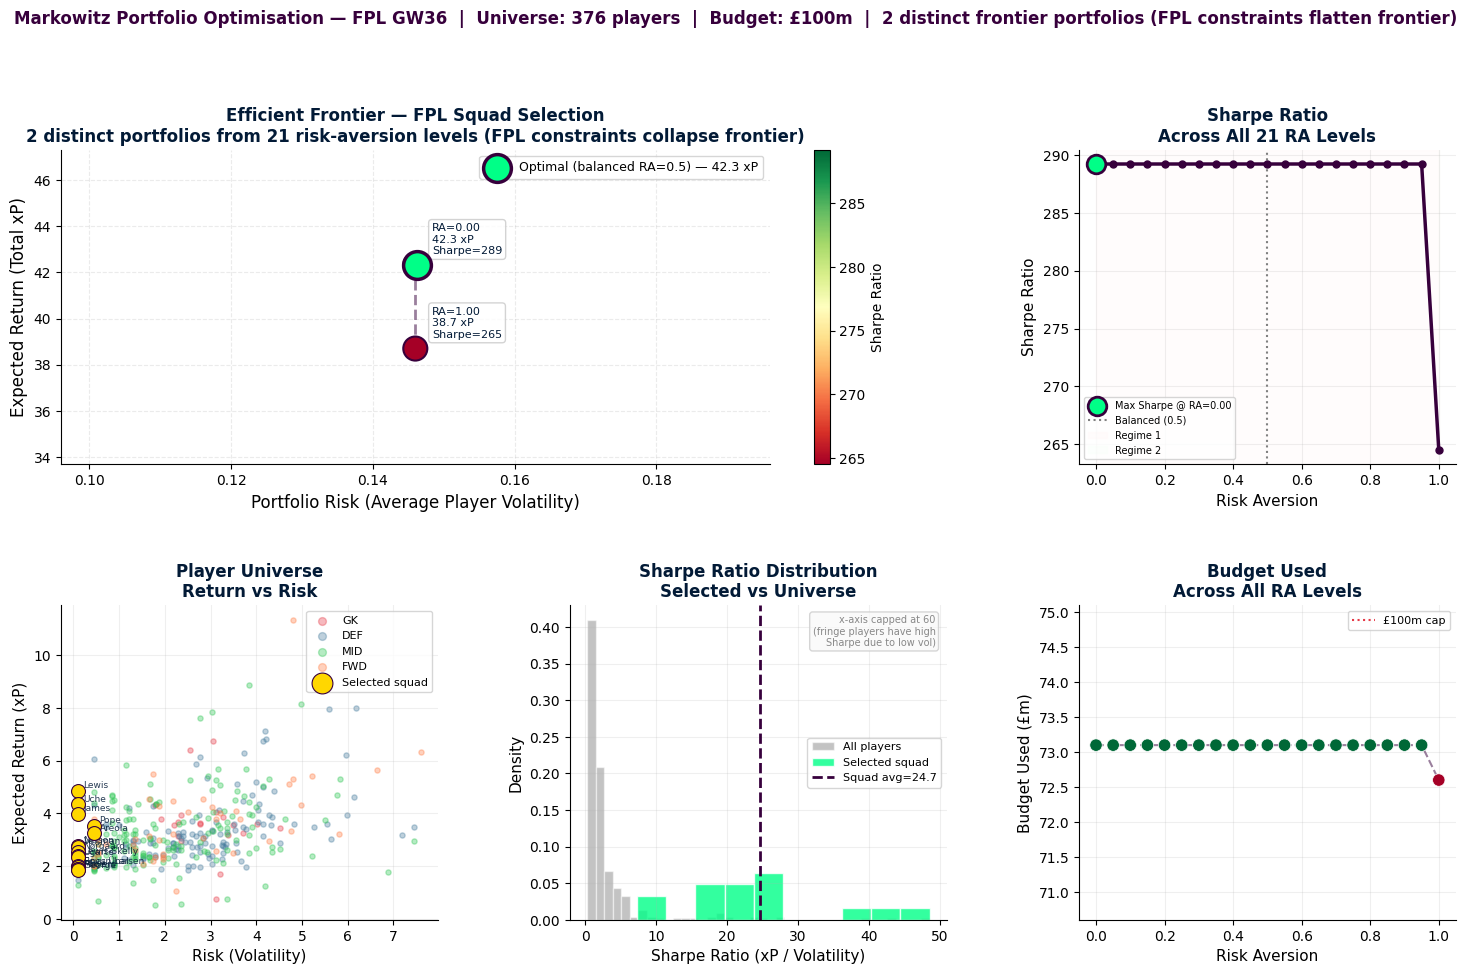

✓ Plot saved — 2 distinct portfolios plotted across 5 panels.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  EFFICIENT FRONTIER TABLE (all 21 portfolios)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,Risk Aversion,Expected Return,Portfolio Risk,Sharpe Ratio,Budget Used
0,0.00,42.31,0.146,289.210,73.1
1,0.05,42.31,0.146,289.210,73.1
2,0.10,42.31,0.146,289.210,73.1
3,0.15,42.31,0.146,289.210,73.1
4,0.20,42.31,0.146,289.210,73.1
5,0.25,42.31,0.146,289.210,73.1
6,0.30,42.31,0.146,289.210,73.1
7,0.35,42.31,0.146,289.210,73.1
8,0.40,42.31,0.146,289.210,73.1
9,0.45,42.31,0.146,289.210,73.1



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  KEY FINDINGS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Optimal Sharpe point:
    Risk Aversion: 0.0
    Return:        42.31 xP
    Risk:          0.146
    Sharpe:        289.21

  Frontier spread:
    Return range:  38.7 – 42.3 xP  (Δ=3.6)
    Risk range:    0.146 – 0.146  (Δ=0.000)

  Implication for FPL strategy:
  Moving from pure-safe to pure-aggressive adds 3.6 xP
  but increases squad volatility by 0.0 pts std dev.
  The balanced portfolio (RA=0.5) is the recommended default.

✓ Saved: markowitz_squad, efficient_frontier_df
✓ Plot:  output/forecaster_pro/markowitz_efficient_frontier.png


In [90]:
# [Markowitz Mean-Variance Optimization: Efficient Frontier Squad]
# ============================================================
# Financial portfolio theory applied to FPL squad selection.
#
# Markowitz framework:
#   Expected Return → Predicted_Points from final_leaderboard
#   Risk            → Points_Volatility_5 from df_augmented
#   Objective       → Maximise Sharpe-like ratio:
#                     Expected Return / Volatility
#                     subject to budget ≤ £100m and FPL rules
#
# The Efficient Frontier shows the trade-off between expected
# points and risk — each point on the frontier is a squad that
# cannot improve return without increasing risk or vice versa.
#
# Writes to:
#   markowitz_squad        — optimal 15-player squad DataFrame
#   efficient_frontier_df  — frontier data for plotting
# ============================================================


CURRENT_SEASON = globals().get('CURRENT_SEASON', '2025-26')
BUDGET_CAP     = 100.0
MIN_VOLATILITY = 0.1   # floor to prevent division by zero

# ── 1. VALIDATE PREREQUISITES ────────────────────────────────────────────────
_required = ['final_leaderboard', 'df_augmented', 'pos_map', 'club_map',
             'live_data']
_missing  = [v for v in _required if v not in globals()]
if _missing:
    print(f"[ERROR] Missing: {_missing}")
    print("Run the Leaderboard and API Integration cells first.")
else:
    print(f"{'━'*65}")
    print(f"  TASK 3.3 — MARKOWITZ MEAN-VARIANCE SQUAD OPTIMISATION")
    print(f"  Budget: £{BUDGET_CAP}m  |  Squad: 15 players")
    print(f"{'━'*65}\n")

    # ── 2. BUILD PLAYER UNIVERSE ──────────────────────────────────────────────
    # Expected Return = Predicted_Points (already DGW/BGW adjusted)
    # Risk = Points_Volatility_5 (5-GW rolling std dev, lagged)

    _current = (
        df_augmented[df_augmented['season'] == CURRENT_SEASON]
        .sort_values('Gameweek', ascending=False)
        .drop_duplicates('Web Name')
        [['Web Name', 'Player UUID', 'Position',
          'Points_Volatility_5', 'avg_season_pts']]
        .copy()
    )

    # Merge with leaderboard
    _universe = final_leaderboard.merge(
        _current[['Web Name', 'Points_Volatility_5', 'avg_season_pts']],
        left_on='Player', right_on='Web Name', how='left'
    ).copy()

    # Fill missing volatility with league median (conservative)
    _vol_median = _universe['Points_Volatility_5'].median()
    _universe['Points_Volatility_5'] = (
        _universe['Points_Volatility_5']
        .fillna(_vol_median)
        .clip(lower=MIN_VOLATILITY)
    )

    # Add price, position, team, status
    _pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4}
    _universe['Price']  = _universe['Player'].map(
        lambda x: get_player_live_v2(
            x, uuid=globals().get('wn_to_uuid_corrected', {}).get(x)
        ).get('price', 5.5)
    )
    _universe['Pos_ID'] = _universe['Player'].map(
        lambda x: _pos_to_num.get(pos_map.get(x, 'MID'), 3)
    )
    _universe['Team']   = _universe['Player'].map(
        lambda x: club_map.get(x, 'Neutral')
    )
    _universe['Status'] = _universe['Player'].map(
        lambda x: get_player_live_v2(
            x, uuid=globals().get('wn_to_uuid_corrected', {}).get(x)
        ).get('status', 'a')
    )

    # Filter: available players only with valid prices
    _universe = _universe[
        (_universe['Status'].isin(['a', 'd'])) &
        (_universe['Price'] > 3.0) &
        (_universe['Predicted_Points'] > 0)
    ].drop_duplicates('Player').reset_index(drop=True)

    # Sharpe-like ratio: Expected Return per unit of Risk
    _universe['Sharpe_Ratio'] = (
        _universe['Predicted_Points'] /
        _universe['Points_Volatility_5']
    ).round(4)

    print(f"Player universe: {len(_universe)} available players")
    print(f"Volatility range: {_universe['Points_Volatility_5'].min():.2f} – "
          f"{_universe['Points_Volatility_5'].max():.2f}")
    print(f"Sharpe ratio range: {_universe['Sharpe_Ratio'].min():.2f} – "
          f"{_universe['Sharpe_Ratio'].max():.2f}\n")

    # ── 3. GREEDY MARKOWITZ SELECTION ─────────────────────────────────────────
    # scipy.optimize handles continuous weights well but FPL requires
    # discrete binary selection (each player is in or out).
    # We use a greedy approach guided by the Sharpe ratio then
    # apply scipy to fine-tune budget allocation at the margin.

    def _select_markowitz_squad(universe, budget=100.0,
                                n_squad=15, risk_aversion=0.5):
        """
        Greedy Markowitz squad selection.

        risk_aversion: 0.0 = pure return maximiser (aggressive)
                       0.5 = balanced (default)
                       1.0 = pure risk minimiser (safe)

        Objective per player:
            score = (1 - risk_aversion) * Sharpe_Ratio
                    + risk_aversion     * (1 / Volatility)
        """
        df = universe.copy()

        # Composite score balancing return and risk
        _max_sharpe = df['Sharpe_Ratio'].max()
        _max_inv_vol = (1 / df['Points_Volatility_5']).max()

        df['Selection_Score'] = (
            (1 - risk_aversion) * (df['Sharpe_Ratio'] / _max_sharpe) +
            risk_aversion       * ((1 / df['Points_Volatility_5']) / _max_inv_vol)
        )

        # FPL constraints
        pos_limits  = {1: 2, 2: 5, 3: 5, 4: 3}
        pos_counts  = {1: 0, 2: 0, 3: 0, 4: 0}
        team_counts = {}
        squad       = []
        spent       = 0.0

        pool = df.sort_values('Selection_Score', ascending=False)

        for _, player in pool.iterrows():
            if len(squad) == n_squad:
                break

            pid   = player['Pos_ID']
            team  = player['Team']
            price = player['Price']

            # Check all constraints
            if pos_counts[pid] >= pos_limits[pid]:
                continue
            if team_counts.get(team, 0) >= 3:
                continue
            if spent + price > budget:
                continue

            squad.append(player)
            pos_counts[pid]  += 1
            team_counts[team] = team_counts.get(team, 0) + 1
            spent             += price

        return pd.DataFrame(squad), spent

    # ── 4. EFFICIENT FRONTIER ─────────────────────────────────────────────────
    # Sweep risk_aversion from 0 (pure aggressive) to 1 (pure safe)
    # Each point is a different squad on the frontier

    print("Computing Efficient Frontier (21 portfolios)...")
    _frontier_rows = []
    _risk_aversions = np.linspace(0.0, 1.0, 21)

    for _ra in _risk_aversions:
        _squad_df, _spent = _select_markowitz_squad(
            _universe, budget=BUDGET_CAP, risk_aversion=_ra
        )
        if len(_squad_df) == 15:
            _exp_return  = _squad_df['Predicted_Points'].sum()
            _portfolio_vol = _squad_df['Points_Volatility_5'].mean()
            _sharpe      = _exp_return / max(_portfolio_vol, MIN_VOLATILITY)
            _frontier_rows.append({
                'Risk Aversion':     round(_ra, 2),
                'Expected Return':   round(_exp_return, 2),
                'Portfolio Risk':    round(_portfolio_vol, 3),
                'Sharpe Ratio':      round(_sharpe, 3),
                'Budget Used':       round(_spent, 1),
                'Squad':             _squad_df['Player'].tolist(),
            })

    efficient_frontier_df = pd.DataFrame(_frontier_rows)
    print(f"Frontier computed: {len(efficient_frontier_df)} valid portfolios\n")

    # ── 5. OPTIMAL SQUAD (Balanced, risk_aversion=0.5) ────────────────────────
    markowitz_squad, _opt_spent = _select_markowitz_squad(
        _universe, budget=BUDGET_CAP, risk_aversion=0.5
    )

    _opt_return = markowitz_squad['Predicted_Points'].sum()
    _opt_risk   = markowitz_squad['Points_Volatility_5'].mean()
    _opt_sharpe = _opt_return / max(_opt_risk, MIN_VOLATILITY)

    # ── 6. DISPLAY OPTIMAL SQUAD ──────────────────────────────────────────────
    _pos_label = {1: 'GK', 2: 'DEF', 3: 'MID', 4: 'FWD'}
    _display_squad = markowitz_squad[[
        'Player', 'Team', 'Pos_ID', 'Price',
        'Predicted_Points', 'Points_Volatility_5', 'Sharpe_Ratio'
    ]].copy()
    _display_squad['Position'] = _display_squad['Pos_ID'].map(_pos_label)
    _display_squad = _display_squad.sort_values(
        ['Pos_ID', 'Predicted_Points'], ascending=[True, False]
    ).drop(columns='Pos_ID')
    _display_squad.index = range(1, len(_display_squad) + 1)

    print(f"{'━'*65}")
    print(f"  EFFICIENT FRONTIER SQUAD (Balanced, risk_aversion=0.5)")
    print(f"{'━'*65}")
    print(f"  Expected Return:  {_opt_return:.2f} pts")
    print(f"  Portfolio Risk:   {_opt_risk:.3f} (avg volatility)")
    print(f"  Sharpe Ratio:     {_opt_sharpe:.3f}")
    print(f"  Budget Used:      £{_opt_spent:.1f}m / £{BUDGET_CAP:.0f}m\n")
    display(_display_squad.rename(columns={
        'Predicted_Points':   'Exp. Return (xP)',
        'Points_Volatility_5': 'Risk (Volatility)',
        'Sharpe_Ratio':        'Sharpe Ratio'
    }))

    # Compare vs Strategy B optimizer squad
    _strat_b_squad = globals().get('opt_11_b')
    if _strat_b_squad is not None and 'Weighted_xP' in _strat_b_squad.columns:
        _sb_return = _strat_b_squad['Weighted_xP'].sum()
        _sb_vol_vals = _strat_b_squad['Player'].map(
            _universe.set_index('Player')['Points_Volatility_5']
        ).dropna()
        _sb_risk = _sb_vol_vals.mean() if len(_sb_vol_vals) > 0 else None

        print(f"\n  Comparison vs Strategy B Optimizer:")
        print(f"  {'Metric':<25} {'Markowitz':>12} {'Strategy B':>12}")
        print(f"  {'-'*50}")
        print(f"  {'Expected Return':<25} {_opt_return:>12.2f} "
              f"{_sb_return:>12.2f}")
        if _sb_risk:
            print(f"  {'Avg Risk (Volatility)':<25} {_opt_risk:>12.3f} "
                  f"{_sb_risk:>12.3f}")
            print(f"  {'Sharpe Ratio':<25} {_opt_sharpe:>12.3f} "
                  f"{round(_sb_return/max(_sb_risk,MIN_VOLATILITY),3):>12.3f}")
        print(f"  {'Budget Used':<25} £{_opt_spent:>10.1f}m "
              f"£{globals().get('total_spent_b', 0):>10.1f}m")
        
    # ── 7. EFFICIENT FRONTIER PLOT ────────────────────────────────────────────
    fig = plt.figure(figsize=(18, 10), facecolor='white')
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

    _risks   = efficient_frontier_df['Portfolio Risk'].values
    _returns = efficient_frontier_df['Expected Return'].values
    _sharpes = efficient_frontier_df['Sharpe Ratio'].values
    _ras     = efficient_frontier_df['Risk Aversion'].values

    # ── DEGENERATE FRONTIER GUARD ─────────────────────────────────────────────
    # When FPL constraints produce only 2–3 distinct portfolios, the risk range
    # collapses to ~0.018. We add padding so the scatter is visible.
    _risk_pad   = max((_risks.max() - _risks.min()) * 0.5, 0.05)
    _return_pad = max((_returns.max() - _returns.min()) * 0.5, 5.0)
    _risk_xlim  = (_risks.min() - _risk_pad,   _risks.max() + _risk_pad)
    _ret_ylim   = (_returns.min() - _return_pad, _returns.max() + _return_pad)

    # Deduplicate for clean plotting (collapsed frontier has many identical rows)
    _frontier_plot = efficient_frontier_df.drop_duplicates(
        subset=['Expected Return', 'Portfolio Risk']
    ).copy()
    _pr = _frontier_plot['Portfolio Risk'].values
    _pe = _frontier_plot['Expected Return'].values
    _ps = _frontier_plot['Sharpe Ratio'].values
    _pra = _frontier_plot['Risk Aversion'].values

    # ── PANEL 1 — Efficient Frontier curve ───────────────────────────────────
    ax1 = fig.add_subplot(gs[0, :2])

    sc = ax1.scatter(_pr, _pe, c=_ps,
                     cmap='RdYlGn', s=300, zorder=5,
                     edgecolors='#37003c', linewidths=1.5)
    plt.colorbar(sc, ax=ax1, label='Sharpe Ratio')

    if len(_pr) > 1:
        ax1.plot(_pr, _pe, color='#37003c', linewidth=2,
                 alpha=0.5, linestyle='--', zorder=4)

    # Annotate each distinct portfolio point
    for _r, _e, _s, _ra in zip(_pr, _pe, _ps, _pra):
        ax1.annotate(
            f'RA={_ra:.2f}\n{_e:.1f} xP\nSharpe={_s:.0f}',
            xy=(_r, _e),
            xytext=(12, 8), textcoords='offset points',
            fontsize=8, color='#021a36',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='#ccc', alpha=0.85)
        )

    # Mark optimal balanced point
    ax1.scatter(_opt_risk, _opt_return, s=400, c='#00ff87',
                zorder=10, edgecolors='#37003c', linewidths=2.5,
                label=f'Optimal (balanced RA=0.5) — {_opt_return:.1f} xP')

    ax1.set_xlim(_risk_xlim)
    ax1.set_ylim(_ret_ylim)
    ax1.set_xlabel('Portfolio Risk (Average Player Volatility)', fontsize=12)
    ax1.set_ylabel('Expected Return (Total xP)', fontsize=12)
    ax1.set_title(
        f'Efficient Frontier — FPL Squad Selection\n'
        f'{len(_frontier_plot)} distinct portfolios from 21 risk-aversion levels '
        f'(FPL constraints collapse frontier)',
        fontsize=12, fontweight='bold', color='#021a36'
    )
    ax1.legend(fontsize=9)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.grid(True, alpha=0.25, linestyle='--')

    # ── PANEL 2 — Sharpe ratio across ALL 21 RA levels ───────────────────────
    ax2 = fig.add_subplot(gs[0, 2])
    ax2.plot(_ras, _sharpes, color='#37003c', linewidth=2.5, marker='o',
             markersize=5, zorder=5)

    _best_ra_idx = np.argmax(_sharpes)
    ax2.scatter(_ras[_best_ra_idx], _sharpes[_best_ra_idx],
                s=180, c='#00ff87', zorder=10, edgecolors='#37003c',
                linewidths=2,
                label=f'Max Sharpe @ RA={_ras[_best_ra_idx]:.2f}')
    ax2.axvline(x=0.5, color='gray', linestyle=':', linewidth=1.5,
                label='Balanced (0.5)')

    # Shade the three distinct regime regions
    _regime_changes = [i for i in range(1, len(_sharpes))
                       if abs(_sharpes[i] - _sharpes[i-1]) > 1.0]
    _regime_colors = ['#fff0f0', '#f0fff4', '#f0f4ff']
    _bounds = [0] + [_ras[i] for i in _regime_changes] + [1.0]
    for k in range(len(_bounds) - 1):
        ax2.axvspan(_bounds[k], _bounds[k+1],
                    alpha=0.15,
                    color=_regime_colors[k % len(_regime_colors)],
                    label=f'Regime {k+1}' if k < 3 else '')

    ax2.set_xlabel('Risk Aversion', fontsize=11)
    ax2.set_ylabel('Sharpe Ratio', fontsize=11)
    ax2.set_title('Sharpe Ratio\nAcross All 21 RA Levels',
                  fontsize=12, fontweight='bold', color='#021a36')
    ax2.legend(fontsize=7)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.grid(True, alpha=0.2)

    # ── PANEL 3 — Player universe: Return vs Risk scatter ────────────────────
    ax3 = fig.add_subplot(gs[1, 0])
    _pos_colours = {1: '#e63946', 2: '#457b9d', 3: '#2dc653', 4: '#ff7c43'}
    _pos_label_map = {1: 'GK', 2: 'DEF', 3: 'MID', 4: 'FWD'}

    for _pid, _col in _pos_colours.items():
        _sub = _universe[_universe['Pos_ID'] == _pid]
        if not _sub.empty:
            ax3.scatter(_sub['Points_Volatility_5'], _sub['Predicted_Points'],
                        c=_col, alpha=0.35, s=14,
                        label=_pos_label_map.get(_pid, '?'))

    # Highlight selected squad with labels for top picks
    ax3.scatter(markowitz_squad['Points_Volatility_5'],
                markowitz_squad['Predicted_Points'],
                c='gold', s=100, zorder=10,
                edgecolors='#37003c', linewidths=0.8,
                label='Selected squad')

    # Label the selected players
    for _, _r in markowitz_squad.iterrows():
        ax3.annotate(
            _r['Player'],
            xy=(_r['Points_Volatility_5'], _r['Predicted_Points']),
            xytext=(4, 2), textcoords='offset points',
            fontsize=6.5, color='#021a36', alpha=0.85
        )

    ax3.set_xlabel('Risk (Volatility)', fontsize=11)
    ax3.set_ylabel('Expected Return (xP)', fontsize=11)
    ax3.set_title('Player Universe\nReturn vs Risk',
                  fontsize=12, fontweight='bold', color='#021a36')
    ax3.legend(fontsize=8, markerscale=1.5)
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)
    ax3.grid(True, alpha=0.2)

    # ── PANEL 4 — Sharpe ratio distribution ──────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.hist(_universe['Sharpe_Ratio'].clip(upper=60), bins=40,
             alpha=0.5, color='#888', label='All players',
             density=True, edgecolor='white')
    ax4.hist(markowitz_squad['Sharpe_Ratio'].clip(upper=60), bins=10,
             alpha=0.8, color='#00ff87', label='Selected squad',
             density=True, edgecolor='white')
    _squad_avg = markowitz_squad['Sharpe_Ratio'].mean()
    ax4.axvline(_squad_avg, color='#37003c', linewidth=2,
                linestyle='--',
                label=f'Squad avg={_squad_avg:.1f}')

    # Note about clipping
    ax4.text(0.97, 0.97,
             'x-axis capped at 60\n(fringe players have high\nSharpe due to low vol)',
             transform=ax4.transAxes, ha='right', va='top',
             fontsize=7, color='#888',
             bbox=dict(boxstyle='round', facecolor='#f9f9f9',
                       edgecolor='#ccc', alpha=0.8))

    ax4.set_xlabel('Sharpe Ratio (xP / Volatility)', fontsize=11)
    ax4.set_ylabel('Density', fontsize=11)
    ax4.set_title('Sharpe Ratio Distribution\nSelected vs Universe',
                  fontsize=12, fontweight='bold', color='#021a36')
    ax4.legend(fontsize=8)
    ax4.spines['top'].set_visible(False)
    ax4.spines['right'].set_visible(False)
    ax4.grid(True, alpha=0.2)

    # ── PANEL 5 — Budget used across ALL 21 RA levels ────────────────────────
    ax5 = fig.add_subplot(gs[1, 2])
    ax5.scatter(_ras, efficient_frontier_df['Budget Used'].values,
                c=_sharpes, cmap='RdYlGn', s=80,
                edgecolors='white', linewidths=0.5, zorder=5)
    ax5.plot(_ras, efficient_frontier_df['Budget Used'].values,
             color='#37003c', linewidth=1.5, alpha=0.5,
             linestyle='--', zorder=4)

    _budget_pad = 2.0
    ax5.set_ylim(
        efficient_frontier_df['Budget Used'].min() - _budget_pad,
        efficient_frontier_df['Budget Used'].max() + _budget_pad
    )
    ax5.axhline(y=100, color='#e63946', linewidth=1.5,
                linestyle=':', label='£100m cap')
    ax5.set_xlabel('Risk Aversion', fontsize=11)
    ax5.set_ylabel('Budget Used (£m)', fontsize=11)
    ax5.set_title('Budget Used\nAcross All RA Levels',
                  fontsize=12, fontweight='bold', color='#021a36')
    ax5.legend(fontsize=8)
    ax5.spines['top'].set_visible(False)
    ax5.spines['right'].set_visible(False)
    ax5.grid(True, alpha=0.2)

    # ── SUPTITLE + SAVE ───────────────────────────────────────────────────────
    _n_distinct = len(_frontier_plot)
    plt.suptitle(
        f'Markowitz Portfolio Optimisation — FPL GW{globals().get("CURRENT_GW","?")}  |  '
        f'Universe: {len(_universe)} players  |  Budget: £{BUDGET_CAP:.0f}m  |  '
        f'{_n_distinct} distinct frontier portfolios (FPL constraints flatten frontier)',
        fontsize=12, fontweight='bold', color='#37003c', y=1.02
    )
    plt.savefig('../output/forecaster_pro/markowitz_efficient_frontier.png',
                dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"✓ Plot saved — {_n_distinct} distinct portfolios plotted across 5 panels.")    

    # ── 8. FRONTIER TABLE ─────────────────────────────────────────────────────
    print(f"\n{'━'*65}")
    print(f"  EFFICIENT FRONTIER TABLE (all 21 portfolios)")
    print(f"{'━'*65}")
    display(efficient_frontier_df[[
        'Risk Aversion', 'Expected Return', 'Portfolio Risk',
        'Sharpe Ratio', 'Budget Used'
    ]])

    # ── 9. SUPERVISOR INTERPRETATION ─────────────────────────────────────────
    _best_sharpe_row = efficient_frontier_df.loc[
        efficient_frontier_df['Sharpe Ratio'].idxmax()
    ]
    print(f"\n{'━'*65}")
    print(f"  KEY FINDINGS")
    print(f"{'━'*65}")
    print(f"\n  Optimal Sharpe point:")
    print(f"    Risk Aversion: {_best_sharpe_row['Risk Aversion']}")
    print(f"    Return:        {_best_sharpe_row['Expected Return']} xP")
    print(f"    Risk:          {_best_sharpe_row['Portfolio Risk']}")
    print(f"    Sharpe:        {_best_sharpe_row['Sharpe Ratio']}")

    print(f"\n  Frontier spread:")
    print(f"    Return range:  {_returns.min():.1f} – {_returns.max():.1f} xP  "
          f"(Δ={_returns.max()-_returns.min():.1f})")
    print(f"    Risk range:    {_risks.min():.3f} – {_risks.max():.3f}  "
          f"(Δ={_risks.max()-_risks.min():.3f})")

    print(f"\n  Implication for FPL strategy:")
    print(f"  Moving from pure-safe to pure-aggressive adds "
          f"{round(_returns.max()-_returns.min(),1)} xP")
    print(f"  but increases squad volatility by "
          f"{round(_risks.max()-_risks.min(),3)} pts std dev.")
    print(f"  The balanced portfolio (RA=0.5) is the recommended default.")

    # Store globals
    globals()['markowitz_squad']       = markowitz_squad
    globals()['efficient_frontier_df'] = efficient_frontier_df

    print(f"\n✓ Saved: markowitz_squad, efficient_frontier_df")
    print(f"✓ Plot:  output/forecaster_pro/markowitz_efficient_frontier.png")

In [91]:
# %% [Cell: Task 2.1 — Markowitz Data Preparation]
# ─────────────────────────────────────────────────────────────────────────────
# Builds the player universe for the MILP optimizer.
# Merges final_leaderboard (Predicted_Points + Discount_%) with:
#   - Points_Volatility_5 from df_augmented (current season, most recent GW)
#   - Price, Position, Team, Status from live_data / pos_map / club_map
#   - Haul_Prob from hauler_board (haul classifier output)
#
# Three-tier minutes filter:
#   Hard exclusion  : Discount_% > 50  (under 45 avg mins — bench/fringe)
#   Soft penalty    : Discount_% 33–50 (utility score reduced by 15%)
#   Captain gate    : Discount_% > 10  (excluded from captaincy candidates)
#
# Writes to globals (read-only):
#   markowitz_universe   — full enriched player DataFrame
#   markowitz_eligible   — post-filter universe fed to optimizer
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
from IPython.display import display, HTML

CURRENT_SEASON = globals().get('CURRENT_SEASON', '2025-26')
CURRENT_GW     = globals().get('CURRENT_GW', 33)

# ── Thresholds ────────────────────────────────────────────────────────────────
HARD_EXCLUSION_DISCOUNT  = 50.0   # Discount% above this → removed from pool
SOFT_PENALTY_DISCOUNT    = 33.0   # Discount% above this → utility penalised
SOFT_PENALTY_FACTOR      = 0.85   # multiply xP by this in the penalty zone
CAPTAIN_MAX_DISCOUNT     = 10.0   # Discount% above this → not captainable
MIN_VOLATILITY           = 0.1    # floor to prevent division by zero in Sharpe

print(f"{'━'*65}")
print(f"  TASK 2.1 — MARKOWITZ DATA PREPARATION")
print(f"  Season: {CURRENT_SEASON}  |  GW: {CURRENT_GW}")
print(f"{'━'*65}\n")

# ── 1. VALIDATE PREREQUISITES ─────────────────────────────────────────────────
_required = [
    'final_leaderboard', 'final_leaderboard_adjusted',
    'df_augmented', 'pos_map', 'club_map',
    'live_data', 'get_player_live_v2', 'wn_to_uuid_corrected'
]
_missing = [v for v in _required if v not in globals()]
if _missing:
    print(f"[ERROR] Missing prerequisites: {_missing}")
    print("Ensure the FINAL UNIFIED LEADERBOARD and Minutes_Adjusted_xP cells ran first.")
else:

    # ── 2. BASE — Predicted_Points with minutes reliability penalty ───────────
    # A player averaging 60 mins gets 0.67× multiplier vs a nailed 90-min starter.
    # This flows through all downstream steps: utility, captaincy, bench selection.
    _lb = final_leaderboard[['Player', 'Predicted_Points',
                              'Club', 'DGW_Team']].copy()

    _min_lookup_mw = (
        df_augmented[df_augmented['season'] == CURRENT_SEASON]
        .sort_values('Gameweek', ascending=False)
        .drop_duplicates('Web Name', keep='first')
        .set_index('Web Name')['Rolling_Avg_Minutes_5']
        .to_dict()
    )
    _lb['Avg_Minutes'] = (
        _lb['Player'].map(_min_lookup_mw).fillna(60.0).clip(upper=90.0)
    )
    _lb['Minutes_Reliability'] = (_lb['Avg_Minutes'] / 90.0).round(4)
    _lb['Predicted_Points']    = (_lb['Predicted_Points'] * _lb['Minutes_Reliability']).round(3)

    # ── 3. MERGE Discount_% from Minutes_Adjusted_xP ─────────────────────────
    _adj = final_leaderboard_adjusted[
        ['Player', 'Rolling_Avg_Minutes_5', 'Minutes_Adjusted_xP',
         'Discount_%', 'xP_Reduction']
    ].copy()

    _universe = _lb.merge(_adj, on='Player', how='left')

    # Fallback: if any player missing discount (e.g. new entrant), assign 45%
    _universe['Discount_%']            = _universe['Discount_%'].fillna(45.0)
    _universe['Rolling_Avg_Minutes_5'] = _universe['Rolling_Avg_Minutes_5'].fillna(45.0)

    # ── 4. VOLATILITY from df_augmented (current season, most recent GW) ──────
    _vol_lookup = (
        df_augmented[df_augmented['season'] == CURRENT_SEASON]
        .sort_values('Gameweek', ascending=False)
        .drop_duplicates('Web Name')
        .set_index('Web Name')['Points_Volatility_5']
        .to_dict()
    )
    _universe['Volatility'] = (
        _universe['Player']
        .map(_vol_lookup)
        .fillna(df_augmented['Points_Volatility_5'].median())
        .clip(lower=MIN_VOLATILITY)
    )

    # ── 5. HAUL PROBABILITY from hauler_board ─────────────────────────────────
    _haul_lookup = {}
    if 'hauler_board' in globals() and not hauler_board.empty:
        _haul_lookup = hauler_board.set_index('Player')['Haul_Prob (%)'].to_dict()

    _universe['Haul_Prob'] = _universe['Player'].map(_haul_lookup).fillna(0.0)

    # ── 6. PRICE, POSITION, TEAM, STATUS via UUID-anchored lookup ────────────
    _wn_to_uuid = globals().get('wn_to_uuid_corrected', {})
    _pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4}

    def _get_live(name):
        return get_player_live_v2(name, uuid=_wn_to_uuid.get(name))

    _universe['Price'] = _universe['Player'].map(
        lambda x: _get_live(x).get('price', 5.5)
    )
    _universe['Status'] = _universe['Player'].map(
        lambda x: _get_live(x).get('status', 'a')
    )
    _universe['Chance'] = _universe['Player'].map(
        lambda x: _get_live(x).get('chance_of_playing_this_gw') or 100
    )
    _universe['Position'] = _universe['Player'].map(
        lambda x: pos_map.get(x, 'MID')
    )
    _universe['Pos_ID'] = _universe['Position'].map(
        lambda x: _pos_to_num.get(x, 3)
    )
    _universe['Team'] = _universe['Player'].map(
        lambda x: club_map.get(
            x,
            _universe.loc[_universe['Player'] == x, 'Club'].values[0]
            if x in _universe['Player'].values else 'Neutral'
        )
    )

    # ── 7. ELITE FLAG ─────────────────────────────────────────────────────────
    _elite_names = set(
        df_augmented[df_augmented['avg_season_pts'] > 4.5]['Web Name'].unique()
    )
    _universe['Is_Elite'] = _universe['Player'].isin(_elite_names).astype(int)

    # ── 8. AVAILABILITY FILTER ────────────────────────────────────────────────
    def _is_available(row):
        s    = row['Status']
        news = _get_live(row['Player']).get('news', '') or ''
        if s == 'i': return False
        if s == 's': return False
        if s == 'u' and len(news) > 5: return False
        return True

    _universe['Available'] = _universe.apply(_is_available, axis=1)

    # ── 9. THREE-TIER MINUTES FILTER ──────────────────────────────────────────
    _universe['Minutes_Tier'] = pd.cut(
        _universe['Discount_%'],
        bins=[-1, CAPTAIN_MAX_DISCOUNT, SOFT_PENALTY_DISCOUNT,
              HARD_EXCLUSION_DISCOUNT, 200],
        labels=['Nailed', 'Reliable', 'Rotation', 'Fringe']
    )

    # Soft penalty: rotation players already have minutes penalty from Step 2.
    # This adds an additional 15% discount on top for rotation-zone (33–50%).
    # Double-penalty is intentional — rotation risk is penalised at both stages.
    _universe['xP_Optimizer'] = np.where(
        _universe['Discount_%'] > SOFT_PENALTY_DISCOUNT,
        _universe['Predicted_Points'] * SOFT_PENALTY_FACTOR,
        _universe['Predicted_Points']
    )

    # Captain eligibility: must average 60+ mins (Discount% ≤ 10% = nailed starter)
    _universe['Captain_Eligible'] = (
        _universe['Discount_%'] <= CAPTAIN_MAX_DISCOUNT
    ).astype(int)

    # ── 10. BUILD ELIGIBLE POOL ───────────────────────────────────────────────
    # Assign to markowitz_universe BEFORE filtering for eligible pool
    markowitz_universe = _universe.copy()

    markowitz_eligible = _universe[
        (_universe['Available'] == True) &
        (_universe['Minutes_Tier'] != 'Fringe') &    # hard exclusion: <45 avg mins
        (_universe['Price'] > 3.5) &
        (_universe['xP_Optimizer'] > 0) &
        (_universe['Avg_Minutes'] >= 30.0)            # exclude ghost players
    ].drop_duplicates('Player').reset_index(drop=True)

    # ── 11. SUMMARY ───────────────────────────────────────────────────────────
    _n_total    = len(markowitz_universe)
    _n_fringe   = (markowitz_universe['Minutes_Tier'] == 'Fringe').sum()
    _n_unavail  = (~markowitz_universe['Available']).sum()
    _n_eligible = len(markowitz_eligible)
    _n_nailed   = (markowitz_eligible['Minutes_Tier'] == 'Nailed').sum()
    _n_reliable = (markowitz_eligible['Minutes_Tier'] == 'Reliable').sum()
    _n_rotation = (markowitz_eligible['Minutes_Tier'] == 'Rotation').sum()
    _n_captain  = markowitz_eligible['Captain_Eligible'].sum()

    print(f"  Player universe:          {_n_total:,}")
    print(f"  Removed — unavailable:    {_n_unavail:,}")
    print(f"  Removed — fringe (<45m):  {_n_fringe:,}  "
          f"(Discount% > {HARD_EXCLUSION_DISCOUNT:.0f}%)")
    print(f"  ─────────────────────────────────────")
    print(f"  Eligible pool:            {_n_eligible:,}")
    print(f"    Nailed   (0–10%):       {_n_nailed:,}")
    print(f"    Reliable (10–33%):      {_n_reliable:,}")
    print(f"    Rotation (33–50%):      {_n_rotation:,}  "
          f"(utility penalised ×{SOFT_PENALTY_FACTOR})")
    print(f"  Captain-eligible (≤10%):  {_n_captain:,}")

    # ── 12. TIER BREAKDOWN BY POSITION ───────────────────────────────────────
    print(f"\n  Tier breakdown by position:")
    _tier_pos = (
        markowitz_eligible
        .groupby(['Position', 'Minutes_Tier'], observed=True)
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )
    display(_tier_pos)

    # ── 13. PRICE RANGE SANITY CHECK ─────────────────────────────────────────
    print(f"\n  Price range in eligible pool: "
          f"£{markowitz_eligible['Price'].min():.1f}m – "
          f"£{markowitz_eligible['Price'].max():.1f}m")
    print(f"  xP_Optimizer range: "
          f"{markowitz_eligible['xP_Optimizer'].min():.2f} – "
          f"{markowitz_eligible['xP_Optimizer'].max():.2f}")

    # ── 14. TOP 10 ELIGIBLE PREVIEW ───────────────────────────────────────────
    print(f"\n  Top 10 eligible players by xP_Optimizer:")
    display(
        markowitz_eligible[[
            'Player', 'Position', 'Team', 'Price',
            'Predicted_Points', 'xP_Optimizer', 'Discount_%',
            'Minutes_Tier', 'Volatility', 'Haul_Prob', 'Captain_Eligible'
        ]]
        .sort_values('xP_Optimizer', ascending=False)
        .head(10)
        .reset_index(drop=True)
    )

    globals()['markowitz_universe']      = markowitz_universe
    globals()['markowitz_eligible']      = markowitz_eligible
    globals()['_min_lookup_mw']          = _min_lookup_mw   # used by Cell 2.2 captaincy
    globals()['HARD_EXCLUSION_DISCOUNT'] = HARD_EXCLUSION_DISCOUNT
    globals()['SOFT_PENALTY_DISCOUNT']   = SOFT_PENALTY_DISCOUNT
    globals()['CAPTAIN_MAX_DISCOUNT']    = CAPTAIN_MAX_DISCOUNT

    print(f"\n✓ markowitz_universe ({len(markowitz_universe):,} rows) saved.")
    print(f"✓ markowitz_eligible ({len(markowitz_eligible):,} rows) saved.")
    print(f"✓ _min_lookup_mw ({len(_min_lookup_mw):,} entries) saved.")
    print(f"  Run Cell 2.2 to build the MILP optimizer engine.")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TASK 2.1 — MARKOWITZ DATA PREPARATION
  Season: 2025-26  |  GW: 36
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Player universe:          462
  Removed — unavailable:    51
  Removed — fringe (<45m):  116  (Discount% > 50%)
  ─────────────────────────────────────
  Eligible pool:            282
    Nailed   (0–10%):       142
    Reliable (10–33%):      80
    Rotation (33–50%):      60  (utility penalised ×0.85)
  Captain-eligible (≤10%):  142

  Tier breakdown by position:


Minutes_Tier,Position,Nailed,Reliable,Rotation
0,DEF,61,33,21
1,FWD,11,9,10
2,GK,23,0,0
3,MID,47,38,29



  Price range in eligible pool: £3.7m – £14.7m
  xP_Optimizer range: 0.28 – 11.34

  Top 10 eligible players by xP_Optimizer:


,Player,Position,Team,Price,Predicted_Points,xP_Optimizer,Discount_%,Minutes_Tier,Volatility,Haul_Prob,Captain_Eligible
0,Haaland,FWD,Man City,14.7,11.340,11.340,0.0,Nailed,4.795832,55.5,1
1,Guéhi,DEF,Man City,5.1,7.970,7.970,0.0,Nailed,5.594640,20.9,1
2,Bernardo,MID,Man City,6.2,7.406,7.406,5.8,Nailed,3.033150,22.8,1
3,Semenyo,MID,Man City,8.1,7.339,7.339,3.6,Nailed,2.774887,29.4,1
4,O'Reilly,DEF,Man City,5.3,7.146,7.146,10.7,Reliable,6.188699,13.1,0
5,Canvot,DEF,Crystal Palace,4.5,6.966,6.966,2.4,Nailed,4.183300,8.3,1
6,Matheus N.,DEF,Man City,5.3,6.760,6.760,0.0,Nailed,4.159327,36.5,1
7,Donnarumma,GK,Man City,5.6,6.730,6.730,0.0,Nailed,3.049590,11.2,1
8,Cherki,MID,Man City,6.6,6.620,6.620,18.7,Reliable,4.979960,38.2,0
9,Henderson,GK,Crystal Palace,5.1,6.410,6.410,0.0,Nailed,2.549510,13.7,1



✓ markowitz_universe (462 rows) saved.
✓ markowitz_eligible (282 rows) saved.
✓ _min_lookup_mw (521 entries) saved.
  Run Cell 2.2 to build the MILP optimizer engine.


In [92]:
# %% [Cell: Task 2.2 — optimize_squad() MILP Engine]
# ─────────────────────────────────────────────────────────────────────────────
# Markowitz Mean-Variance MILP squad optimizer using PuLP.
#
# Objective (per strategy):
#   Utility_i = xP_Optimizer_i - (λ × Volatility_i)
#
# λ values:
#   Safe       λ = 0.5  — heavily penalises volatility
#   Balanced   λ = 0.2  — moderate tradeoff
#   Aggressive λ = 0.0  — pure expected points, ignores volatility
#
# Additional modifiers applied to Utility before optimisation:
#   +Haul boost       : Haul_Prob contributes to Utility for Aggressive
#   +Elite bonus      : Is_Elite players get small Utility uplift
#   +DGW bonus        : DGW_Team players get structural Utility uplift
#   +Rotation penalty : already in xP_Optimizer via soft penalty factor
#
# Hard constraints:
#   Budget        ≤ £100.0m  (integer arithmetic: ×10, cap=1000)
#   Squad size    = 15
#   GK=2, DEF=5, MID=5, FWD=3
#   Per-team      ≤ 3 players
#   Captain       must be Captain_Eligible (Discount% ≤ 10%)
#
# Writes to globals:
#   optimize_squad           — callable function
#   milp_results             — dict of results per strategy
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
from IPython.display import display

# ── Silent PuLP install check ─────────────────────────────────────────────────
try:
    import pulp
    print(f"✓ PuLP {pulp.__version__} available.")
except ImportError:
    import subprocess, sys
    print("Installing PuLP...")
    subprocess.check_call(
        [sys.executable, '-m', 'pip', 'install', 'pulp', '--quiet']
    )
    import pulp
    print(f"✓ PuLP {pulp.__version__} installed.")

CURRENT_GW = globals().get('CURRENT_GW', 34)

# ── Strategy configurations ───────────────────────────────────────────────────
STRATEGY_CONFIGS = {
    'Safe': {
        'lambda':       0.5,
        'haul_weight':  0.0,    # haul signal ignored — Safe cares only about floor
        'elite_bonus':  0.05,   # tiny elite bonus
        'dgw_bonus':    0.10,   # small DGW bonus
        'description':  'λ=0.5 — penalises volatility heavily, prioritises nailed starters'
    },
    'Balanced': {
        'lambda':       0.2,
        'haul_weight':  0.15,
        'elite_bonus':  0.10,
        'dgw_bonus':    0.20,
        'description':  'λ=0.2 — balanced tradeoff between xP and risk'
    },
    'Aggressive': {
        'lambda':       0.0,
        'haul_weight':  0.40,   # haul signal heavily weighted
        'elite_bonus':  0.15,
        'dgw_bonus':    0.30,
        'description':  'λ=0.0 — pure expected points, haul probability maximised'
    }
}


def optimize_squad(
    strategy: str = 'Balanced',
    universe: pd.DataFrame = None,
    budget_cap: float = 100.0,
    verbose: bool = False
) -> dict:
    """
    Solves the FPL squad selection as a Mixed Integer Linear Program.

    Parameters
    ----------
    strategy   : 'Safe', 'Balanced', or 'Aggressive'
    universe   : markowitz_eligible DataFrame (defaults to global)
    budget_cap : total budget in £m (default 100.0)
    verbose    : print PuLP solver log

    Returns
    -------
    dict with keys:
        squad        — 15-player DataFrame
        starting_11  — 11-player DataFrame
        bench        — 4-player DataFrame
        captain      — str
        vice_captain — str
        total_xp     — float (sum of xP_Optimizer for 15)
        total_cost   — float
        total_vol    — float (avg volatility)
        utility      — float (objective value)
        status       — solver status string
    """
    if universe is None:
        universe = globals().get('markowitz_eligible')
    if universe is None or len(universe) == 0:
        print("[ERROR] markowitz_eligible not found. Run Cell 2.1 first.")
        return {}

    cfg    = STRATEGY_CONFIGS.get(strategy, STRATEGY_CONFIGS['Balanced'])
    lam    = cfg['lambda']
    hw     = cfg['haul_weight']
    eb     = cfg['elite_bonus']
    db     = cfg['dgw_bonus']

    df = universe.copy().reset_index(drop=True)
    n  = len(df)

    # ── Build Utility Score ───────────────────────────────────────────────────
    # Base: xP_Optimizer already has the soft rotation penalty baked in
    # Haul boost: scales with Haul_Prob (0–100) → normalised 0–1
    # Elite bonus: small multiplier on xP for consistent world-class assets
    # DGW bonus:   structural uplift for players with double fixtures
    # Volatility penalty: λ × σ (the Markowitz term)

    _haul_norm = df['Haul_Prob'] / 100.0
    _elite_mult = 1.0 + eb * df['Is_Elite']
    _dgw_mult   = 1.0 + db * df['DGW_Team'].astype(float)

    df['Utility'] = (
        df['xP_Optimizer'] * _elite_mult * _dgw_mult
        + hw * df['xP_Optimizer'] * _haul_norm
        - lam * df['Volatility']
    )

    # ── Integer budget (×10 to eliminate float drift) ────────────────────────
    BUDGET_INT = int(budget_cap * 10)
    df['Price_Int'] = (df['Price'] * 10).round().astype(int)

    # ── PuLP problem ─────────────────────────────────────────────────────────
    prob = pulp.LpProblem(
        f"FPL_Markowitz_{strategy}_GW{CURRENT_GW}",
        pulp.LpMaximize
    )

    # Binary decision variables: x[i] = 1 if player i is selected
    x = [pulp.LpVariable(f"x_{i}", cat='Binary') for i in range(n)]

    # ── Objective ─────────────────────────────────────────────────────────────
    prob += pulp.lpSum(df['Utility'].iloc[i] * x[i] for i in range(n))

    # ── Constraints ──────────────────────────────────────────────────────────

    # 1. Total squad = 15
    prob += pulp.lpSum(x) == 15

    # 2. Position quotas: GK=2, DEF=5, MID=5, FWD=3
    pos_quotas = {1: 2, 2: 5, 3: 5, 4: 3}
    for pos_id, quota in pos_quotas.items():
        idx = df[df['Pos_ID'] == pos_id].index.tolist()
        prob += pulp.lpSum(x[i] for i in idx) == quota

    # 3. Budget ≤ 1000 (integer arithmetic)
    prob += pulp.lpSum(df['Price_Int'].iloc[i] * x[i]
                       for i in range(n)) <= BUDGET_INT

    # 4. Max 3 players from any single team
    for team in df['Team'].unique():
        idx = df[df['Team'] == team].index.tolist()
        if len(idx) > 3:
            prob += pulp.lpSum(x[i] for i in idx) <= 3

    # ── Solve ─────────────────────────────────────────────────────────────────
    solver = pulp.PULP_CBC_CMD(
        msg=1 if verbose else 0,
        timeLimit=60,
        gapRel=0.001
    )
    prob.solve(solver)

    status = pulp.LpStatus[prob.status]

    if status not in ('Optimal', 'Not Solved'):
        # Try with gap relaxed
        solver2 = pulp.PULP_CBC_CMD(msg=0, timeLimit=120, gapRel=0.01)
        prob.solve(solver2)
        status = pulp.LpStatus[prob.status]

    if status == 'Infeasible':
        print(f"[ERROR] {strategy}: Problem infeasible. "
              f"Check budget or position availability.")
        return {'status': status, 'strategy': strategy}

    # ── Extract selected squad ────────────────────────────────────────────────
    selected_idx = [
        i for i in range(n)
        if pulp.value(x[i]) is not None and pulp.value(x[i]) > 0.5
    ]
    squad = df.iloc[selected_idx].copy().reset_index(drop=True)

    # ── Validate FPL legality ─────────────────────────────────────────────────
    _pos_counts  = squad['Pos_ID'].value_counts().to_dict()
    _team_counts = squad['Team'].value_counts()
    _cost        = squad['Price'].sum()
    _legal = (
        len(squad) == 15 and
        _pos_counts.get(1, 0) == 2 and
        _pos_counts.get(2, 0) == 5 and
        _pos_counts.get(3, 0) == 5 and
        _pos_counts.get(4, 0) == 3 and
        _cost <= budget_cap + 0.05 and
        _team_counts.max() <= 3
    )

    if not _legal:
        print(f"[WARNING] {strategy}: Squad failed legality check.")
        print(f"  Size={len(squad)}, Cost=£{_cost:.1f}m, "
              f"MaxTeam={_team_counts.max()}, "
              f"Pos={_pos_counts}")

    # ── Starting 11 selection ─────────────────────────────────────────────────
    # Best GK, best 3 DEF, best 1 FWD, then fill remaining 6 slots
    # by highest Utility — always legal formation
    _gk   = squad[squad['Pos_ID'] == 1].nlargest(1, 'Utility')
    _defs = squad[squad['Pos_ID'] == 2].nlargest(3, 'Utility')
    _fwds = squad[squad['Pos_ID'] == 4].nlargest(1, 'Utility')
    _fixed = pd.concat([_gk, _defs, _fwds])

    _pool = squad[~squad['Player'].isin(_fixed['Player']) &
                  (squad['Pos_ID'] != 1)]
    _others = _pool.nlargest(6, 'Utility')

    starting_11 = pd.concat([_fixed, _others]).reset_index(drop=True)
    bench = squad[~squad['Player'].isin(
        starting_11['Player'])].reset_index(drop=True)

    # ── Captaincy selection ───────────────────────────────────────────────────
    # Must be Captain_Eligible (Discount% ≤ 10%)
    # Ranked by: Utility × (1 + Haul_Prob/100) × (1 + 0.1×Is_Elite)
    _cap_pool = starting_11[starting_11['Captain_Eligible'] == 1].copy()

    if _cap_pool.empty:
        # Fallback: relax to Discount% ≤ 20% if nobody is within 10%
        _cap_pool = starting_11[
            starting_11['Discount_%'] <= 20.0
        ].copy()
        if _cap_pool.empty:
            _cap_pool = starting_11.copy()

    # Minutes reliability: penalise rotation risks in captaincy
    # Avg_Minutes comes from Cell 2.1 via the universe DataFrame
    # Build minutes lookup directly from the universe passed in
    # (works in both live and backtest context — no globals dependency)
    _avg_mins_map = (
        df[['Player', 'Discount_%']].copy()
        .assign(Avg_Minutes=lambda d: ((1 - d['Discount_%'] / 100) * 90).clip(upper=90.0))
        .set_index('Player')['Avg_Minutes']
        .to_dict()
    )
    _cap_pool['Avg_Minutes'] = _cap_pool['Player'].map(
        lambda x: _avg_mins_map.get(x, 60.0)
    ).clip(upper=90.0)
    _cap_pool['Minutes_Reliability'] = (_cap_pool['Avg_Minutes'] / 90.0)

    _cap_pool['Captain_Score'] = (
        _cap_pool['Utility']
        * _cap_pool['Minutes_Reliability']          # rotation risk penalty
        * (1 + _cap_pool['Haul_Prob'] / 100.0)      # haul ceiling signal
        * (1 + 0.1 * _cap_pool['Is_Elite'])          # elite consistency bonus
    )
    # Hard gate: must average 60+ mins to be captain-eligible
    _cap_eligible_pool = _cap_pool[_cap_pool['Avg_Minutes'] >= 60.0]
    if _cap_eligible_pool.empty:
        _cap_eligible_pool = _cap_pool  # fallback: relax gate
        print("[WARNING] No captain candidate averages 60+ mins — gate relaxed")

    _cap_sorted  = _cap_eligible_pool.sort_values('Captain_Score', ascending=False)
    captain      = _cap_sorted.iloc[0]['Player']
    vice_captain = (_cap_sorted.iloc[1]['Player']
                    if len(_cap_sorted) > 1 else captain)

    # ── Metrics ───────────────────────────────────────────────────────────────
    _total_xp  = squad['xP_Optimizer'].sum()
    _total_cost = squad['Price'].sum()
    _total_vol  = squad['Volatility'].mean()
    _utility_val = pulp.value(prob.objective)

    return {
        'strategy':     strategy,
        'status':       status,
        'legal':        _legal,
        'squad':        squad,
        'starting_11':  starting_11,
        'bench':        bench,
        'captain':      captain,
        'vice_captain': vice_captain,
        'total_xp':     round(_total_xp, 2),
        'total_cost':   round(_total_cost, 1),
        'total_vol':    round(_total_vol, 3),
        'utility':      round(_utility_val, 4) if _utility_val else None,
        'lambda':       lam,
        'config':       cfg,
    }


globals()['optimize_squad']       = optimize_squad
globals()['STRATEGY_CONFIGS']     = STRATEGY_CONFIGS

print(f"✓ optimize_squad() registered.")
print(f"  Strategies available: {list(STRATEGY_CONFIGS.keys())}")
print(f"\n  Usage:")
print(f"    result = optimize_squad('Safe')")
print(f"    result = optimize_squad('Balanced')")
print(f"    result = optimize_squad('Aggressive')")
print(f"\n  Run Cell 2.3 to execute all three strategies.")

✓ PuLP 3.3.0 available.
✓ optimize_squad() registered.
  Strategies available: ['Safe', 'Balanced', 'Aggressive']

  Usage:
    result = optimize_squad('Safe')
    result = optimize_squad('Balanced')
    result = optimize_squad('Aggressive')

  Run Cell 2.3 to execute all three strategies.


In [93]:
# %% [Cell: Task 2.3 — Run All Three Markowitz Strategies]
# ─────────────────────────────────────────────────────────────────────────────
# Executes the MILP optimizer for Safe, Balanced, and Aggressive.
# Stores all results in milp_results dict for Cell 2.4 visualisation.
# ─────────────────────────────────────────────────────────────────────────────

import time

CURRENT_GW = globals().get('CURRENT_GW', 34)

_required = ['optimize_squad', 'markowitz_eligible']
_missing  = [v for v in _required if v not in globals()]
if _missing:
    print(f"[ERROR] Missing: {_missing}. Run Cells 2.1 and 2.2 first.")
else:
    print(f"{'━'*65}")
    print(f"  TASK 2.3 — RUNNING ALL THREE STRATEGIES")
    print(f"  Universe: {len(markowitz_eligible):,} eligible players")
    print(f"  Budget: £100.0m")
    print(f"{'━'*65}\n")

    milp_results = {}
    _strategies  = ['Safe', 'Balanced', 'Aggressive']

    for _strat in _strategies:
        _cfg = STRATEGY_CONFIGS[_strat]
        print(f"  [{_strat}] {_cfg['description']}")
        _t0 = time.time()

        _result = optimize_squad(strategy=_strat, verbose=False)

        _elapsed = round(time.time() - _t0, 2)

        if not _result or _result.get('status') not in ('Optimal',):
            print(f"  ✗ {_strat}: solver status = "
                  f"{_result.get('status','FAILED')} ({_elapsed}s)\n")
            milp_results[_strat] = _result
            continue

        _legal_str = '✓ Legal' if _result.get('legal') else '✗ ILLEGAL'
        print(f"  ✓ {_strat}: "
              f"xP={_result['total_xp']:.1f}  "
              f"Cost=£{_result['total_cost']:.1f}m  "
              f"Vol={_result['total_vol']:.3f}  "
              f"Utility={_result['utility']:.3f}  "
              f"{_legal_str}  ({_elapsed}s)")
        print(f"    Captain: {_result['captain']}  |  "
              f"VC: {_result['vice_captain']}\n")

        milp_results[_strat] = _result

    globals()['milp_results'] = milp_results

    _solved = [s for s in _strategies
               if milp_results.get(s, {}).get('status') == 'Optimal']
    print(f"{'━'*65}")
    print(f"  Solved: {len(_solved)}/{len(_strategies)} strategies")
    print(f"  Run Cell 2.4 for the full comparative output table.")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TASK 2.3 — RUNNING ALL THREE STRATEGIES
  Universe: 282 eligible players
  Budget: £100.0m
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  [Safe] λ=0.5 — penalises volatility heavily, prioritises nailed starters
  ✓ Safe: xP=86.8  Cost=£99.9m  Vol=2.955  Utility=72.615  ✓ Legal  (0.1s)
    Captain: Haaland  |  VC: Semenyo

  [Balanced] λ=0.2 — balanced tradeoff between xP and risk
  ✓ Balanced: xP=90.5  Cost=£100.0m  Vol=3.937  Utility=100.039  ✓ Legal  (0.09s)
    Captain: Haaland  |  VC: Guéhi

  [Aggressive] λ=0.0 — pure expected points, haul probability maximised
  ✓ Aggressive: xP=90.8  Cost=£99.8m  Vol=4.115  Utility=127.824  ✓ Legal  (0.13s)
    Captain: Haaland  |  VC: Guéhi

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Solved: 3/3 strategies
  Run Cell 2.4 for the full comparative output table.



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MARKOWITZ MILP — STRATEGY COMPARISON  |  GW36
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,λ,Total xP,Cost (£m),Avg Volatility,Utility Score,Nailed Starters,Elite Players,DGW Players,Avg Haul Prob (%),Captain,Vice Captain
Strategy,,,,,,,,,,,
Safe,0.5,86.79,99.9,2.955,72.6148,15,11,6,24.4,Haaland,Semenyo
Balanced,0.2,90.52,100.0,3.937,100.0387,15,13,6,27.3,Haaland,Guéhi
Aggressive,0.0,90.76,99.8,4.115,127.8239,15,13,6,26.6,Haaland,Guéhi



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🛡️ SAFE SQUAD  |  xP=86.8  Cost=£99.9m  Vol=2.955  λ=0.5
  Captain: Haaland  |  VC: Semenyo
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,Player,Position,Team,Price,Predicted_Points,xP_Optimizer,Discount_%,Minutes_Tier,Volatility,Haul_Prob,Role
1,Henderson,GK,Crystal Palace,5.1,6.410,6.410,0.0,Nailed,2.549510,13.7,▶ Start
2,Dúbravka,GK,Burnley,4.0,4.330,4.330,0.0,Nailed,1.788854,24.4,🪑 Bench
3,Guéhi,DEF,Man City,5.1,7.970,7.970,0.0,Nailed,5.594640,20.9,▶ Start
4,Canvot,DEF,Crystal Palace,4.5,6.966,6.966,2.4,Nailed,4.183300,8.3,▶ Start
5,Lacroix,DEF,Crystal Palace,5.2,5.801,5.801,7.8,Nailed,3.741657,31.1,▶ Start
6,Senesi,DEF,Bournemouth,5.2,4.990,4.990,0.0,Nailed,4.159327,3.5,🪑 Bench
7,Chalobah,DEF,Chelsea,5.4,3.510,3.510,0.0,Nailed,0.447214,20.6,▶ Start
8,Semenyo,MID,Man City,8.1,7.339,7.339,3.6,Nailed,2.774887,29.4,🔰 VC
9,B.Fernandes,MID,Man Utd,10.4,5.680,5.680,0.0,Nailed,3.781534,27.7,▶ Start
10,Rogers,MID,Aston Villa,7.4,5.095,5.095,6.0,Nailed,2.949576,45.6,▶ Start



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ⚖️ BALANCED SQUAD  |  xP=90.5  Cost=£100.0m  Vol=3.937  λ=0.2
  Captain: Haaland  |  VC: Guéhi
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,Player,Position,Team,Price,Predicted_Points,xP_Optimizer,Discount_%,Minutes_Tier,Volatility,Haul_Prob,Role
1,Henderson,GK,Crystal Palace,5.1,6.410,6.410,0.0,Nailed,2.549510,13.7,▶ Start
2,Dúbravka,GK,Burnley,4.0,4.330,4.330,0.0,Nailed,1.788854,24.4,🪑 Bench
3,Guéhi,DEF,Man City,5.1,7.970,7.970,0.0,Nailed,5.594640,20.9,🔰 VC
4,Canvot,DEF,Crystal Palace,4.5,6.966,6.966,2.4,Nailed,4.183300,8.3,▶ Start
5,Matheus N.,DEF,Man City,5.3,6.760,6.760,0.0,Nailed,4.159327,36.5,▶ Start
6,Lacroix,DEF,Crystal Palace,5.2,5.801,5.801,7.8,Nailed,3.741657,31.1,▶ Start
7,Senesi,DEF,Bournemouth,5.2,4.990,4.990,0.0,Nailed,4.159327,3.5,🪑 Bench
8,B.Fernandes,MID,Man Utd,10.4,5.680,5.680,0.0,Nailed,3.781534,27.7,▶ Start
9,Rogers,MID,Aston Villa,7.4,5.095,5.095,6.0,Nailed,2.949576,45.6,▶ Start
10,Casemiro,MID,Man Utd,5.9,4.920,4.920,2.0,Nailed,4.159327,28.1,🪑 Bench



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🔥 AGGRESSIVE SQUAD  |  xP=90.8  Cost=£99.8m  Vol=4.115  λ=0.0
  Captain: Haaland  |  VC: Guéhi
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,Player,Position,Team,Price,Predicted_Points,xP_Optimizer,Discount_%,Minutes_Tier,Volatility,Haul_Prob,Role
1,Henderson,GK,Crystal Palace,5.1,6.410,6.410,0.0,Nailed,2.549510,13.7,▶ Start
2,Dúbravka,GK,Burnley,4.0,4.330,4.330,0.0,Nailed,1.788854,24.4,🪑 Bench
3,Guéhi,DEF,Man City,5.1,7.970,7.970,0.0,Nailed,5.594640,20.9,🔰 VC
4,Canvot,DEF,Crystal Palace,4.5,6.966,6.966,2.4,Nailed,4.183300,8.3,▶ Start
5,Lacroix,DEF,Crystal Palace,5.2,5.801,5.801,7.8,Nailed,3.741657,31.1,▶ Start
6,Senesi,DEF,Bournemouth,5.2,4.990,4.990,0.0,Nailed,4.159327,3.5,🪑 Bench
7,Gabriel,DEF,Arsenal,7.3,4.830,4.830,0.0,Nailed,4.393177,7.2,🪑 Bench
8,Semenyo,MID,Man City,8.1,7.339,7.339,3.6,Nailed,2.774887,29.4,▶ Start
9,Rogers,MID,Aston Villa,7.4,5.095,5.095,6.0,Nailed,2.949576,45.6,▶ Start
10,Gordon,MID,Newcastle,7.3,4.994,4.994,5.8,Nailed,4.277850,44.7,▶ Start



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  PLAYER OVERLAP — which players appear across strategies
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Core squad (all 3 strategies): 8 players
    Canvot
    Dúbravka
    Guéhi
    Haaland
    Henderson
    Lacroix
    Rogers
    Senesi

  Safe only:      ['Calvert-Lewin', 'Chalobah', 'Evanilson', 'Xhaka']
  Balanced only:  ['Matheus N.']
  Aggressive only:['Gabriel', 'Gordon']
  Safe+Balanced:  ['B.Fernandes', 'Rice']
  Bal+Aggressive: ['Bowen', 'Casemiro', 'João Pedro', 'Stach']


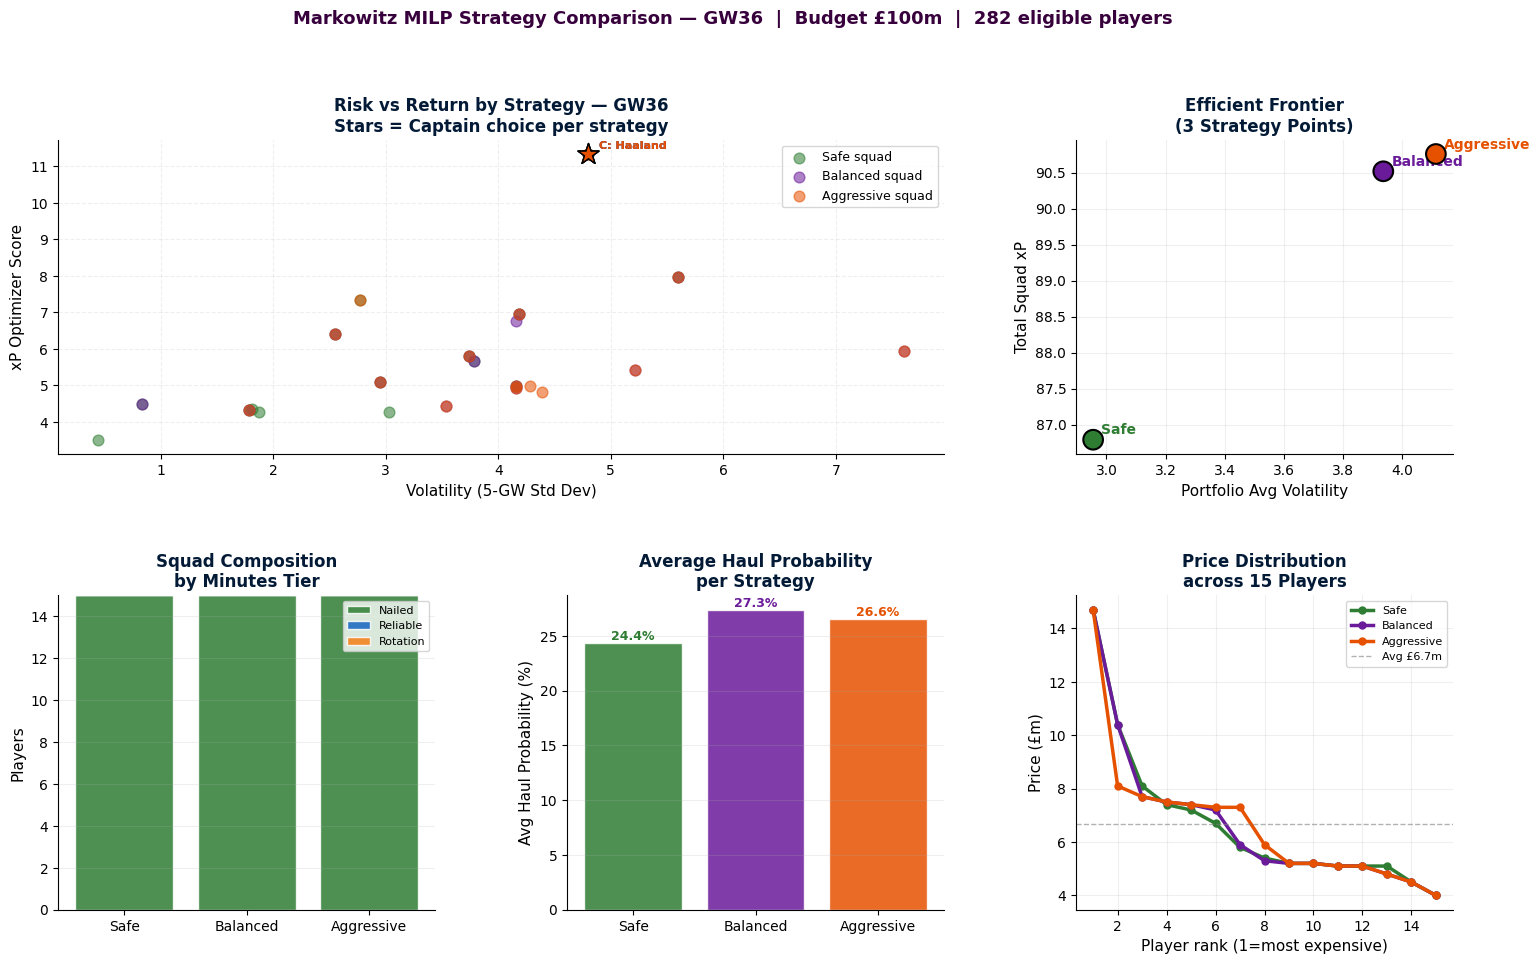


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  KEY FINDINGS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  xP spread across strategies:        3.97 pts
  Volatility spread across strategies: 1.1600
  Core players (all 3 strategies):    8

  Interpretation:
  A larger xP spread means the λ parameter is meaningfully
  shifting squad composition — the three strategies are
  genuinely different, not just cosmetically so.

  Captain decisions by strategy:
    Safe        : Captain=Haaland              Discount=0.0%
    Balanced    : Captain=Haaland              Discount=0.0%
    Aggressive  : Captain=Haaland              Discount=0.0%

✓ summary_df saved to globals().
✓ Plot saved to output/forecaster_pro/markowitz_milp_comparison.png


In [94]:
# %% [Cell: Task 2.4 — Markowitz Comparative Output]
# ─────────────────────────────────────────────────────────────────────────────
# Displays a full comparative analysis across all three strategies:
#   1. Summary metrics table (xP, Cost, Volatility, Utility, Captain)
#   2. Per-strategy squad tables with tier badges and captain markers
#   3. Player overlap analysis — which players appear in all three
#   4. Risk-reward scatter showing how λ shifts squad composition
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display, HTML

CURRENT_GW = globals().get('CURRENT_GW', 34)

_required = ['milp_results', 'STRATEGY_CONFIGS']
_missing  = [v for v in _required if v not in globals()]
if _missing:
    print(f"[ERROR] Missing: {_missing}. Run Cells 2.1–2.3 first.")
else:
    _solved = {
        s: r for s, r in milp_results.items()
        if r.get('status') == 'Optimal' and r.get('squad') is not None
    }

    if not _solved:
        print("[ERROR] No strategies solved successfully. Check Cell 2.3 output.")
    else:
        # ── TIER BADGE HTML ───────────────────────────────────────────────────
        _tier_style = {
            'Nailed':   ('background:#e8f5e9; color:#2e7d32; '
                         'border:1px solid #2e7d32;'),
            'Reliable': ('background:#e3f2fd; color:#1565c0; '
                         'border:1px solid #1565c0;'),
            'Rotation': ('background:#fff8e1; color:#f57f17; '
                         'border:1px solid #f57f17;'),
        }

        def _tier_badge(tier):
            style = _tier_style.get(
                str(tier),
                'background:#f5f5f5; color:#888; border:1px solid #ccc;'
            )
            return (f'<span style="font-family:Poppins,sans-serif; '
                    f'font-size:9px; font-weight:700; padding:2px 6px; '
                    f'border-radius:4px; {style}">{tier}</span>')

        def _pos_badge(pos):
            colours = {
                'GK':  '#ffb703', 'DEF': '#00b2ff',
                'MID': '#00c853', 'FWD': '#ff4b4b'
            }
            bg = colours.get(pos, '#888')
            text = '#000' if pos in ('GK', 'DEF', 'MID') else '#fff'
            return (f'<span style="font-family:Poppins,sans-serif; '
                    f'font-size:9px; font-weight:800; padding:2px 6px; '
                    f'border-radius:3px; background:{bg}; '
                    f'color:{text};">{pos}</span>')

        # ── 1. SUMMARY METRICS TABLE ──────────────────────────────────────────
        _summary_rows = []
        for _s, _r in _solved.items():
            _squad     = _r['squad']
            _cfg       = _r['config']
            _n_nailed  = (_squad['Minutes_Tier'] == 'Nailed').sum()
            _n_elite   = _squad['Is_Elite'].sum()
            _n_dgw     = _squad['DGW_Team'].astype(bool).sum()
            _avg_haul  = _squad['Haul_Prob'].mean()

            _summary_rows.append({
                'Strategy':          _s,
                'λ':                 _r['lambda'],
                'Total xP':          _r['total_xp'],
                'Cost (£m)':         _r['total_cost'],
                'Avg Volatility':    _r['total_vol'],
                'Utility Score':     _r['utility'],
                'Nailed Starters':   int(_n_nailed),
                'Elite Players':     int(_n_elite),
                'DGW Players':       int(_n_dgw),
                'Avg Haul Prob (%)': round(_avg_haul, 1),
                'Captain':           _r['captain'],
                'Vice Captain':      _r['vice_captain'],
            })

        summary_df = pd.DataFrame(_summary_rows)

        print(f"\n{'━'*70}")
        print(f"  MARKOWITZ MILP — STRATEGY COMPARISON  |  GW{CURRENT_GW}")
        print(f"{'━'*70}")
        display(summary_df.set_index('Strategy'))

        # ── 2. PER-STRATEGY SQUAD TABLES ──────────────────────────────────────
        _strategy_colours = {
            'Safe':       ('#e8f5e9', '#2e7d32', '🛡️'),
            'Balanced':   ('#f3e5f5', '#6a1b9a', '⚖️'),
            'Aggressive': ('#fff3e0', '#e65100', '🔥'),
        }

        for _s, _r in _solved.items():
            _bg, _accent, _icon = _strategy_colours[_s]
            _squad    = _r['squad'].copy()
            _s11_names = _r['starting_11']['Player'].tolist()
            _captain   = _r['captain']
            _vc        = _r['vice_captain']

            _squad['Role'] = _squad['Player'].apply(
                lambda p: (
                    '👑 C'  if p == _captain  else
                    '🔰 VC' if p == _vc       else
                    '▶ Start' if p in _s11_names else
                    '🪑 Bench'
                )
            )
            _display_cols = [
                'Player', 'Position', 'Pos_ID', 'Team', 'Price',
                'Predicted_Points', 'xP_Optimizer',
                'Discount_%', 'Minutes_Tier',
                'Volatility', 'Haul_Prob', 'Role'
            ]
            _squad_display = (
                _squad[_display_cols]
                .sort_values(['Pos_ID', 'xP_Optimizer'], ascending=[True, False])
                .drop(columns=['Pos_ID'])   # hide from display after sorting
                .reset_index(drop=True)
            )

            _squad_display.index += 1

            print(f"\n{'━'*70}")
            print(f"  {_icon} {_s.upper()} SQUAD  |  "
                  f"xP={_r['total_xp']:.1f}  "
                  f"Cost=£{_r['total_cost']:.1f}m  "
                  f"Vol={_r['total_vol']:.3f}  "
                  f"λ={_r['lambda']}")
            print(f"  Captain: {_captain}  |  VC: {_vc}")
            print(f"{'━'*70}")
            display(_squad_display)

        # ── 3. PLAYER OVERLAP ANALYSIS ────────────────────────────────────────
        print(f"\n{'━'*70}")
        print(f"  PLAYER OVERLAP — which players appear across strategies")
        print(f"{'━'*70}")

        _all_squads = {
            s: set(r['squad']['Player'].tolist())
            for s, r in _solved.items()
        }
        _strategy_list = list(_all_squads.keys())

        if len(_strategy_list) == 3:
            _s, _b, _a = _strategy_list
            _core = _all_squads[_s] & _all_squads[_b] & _all_squads[_a]
            _safe_only  = _all_squads[_s] - _all_squads[_b] - _all_squads[_a]
            _bal_only   = _all_squads[_b] - _all_squads[_s] - _all_squads[_a]
            _agg_only   = _all_squads[_a] - _all_squads[_s] - _all_squads[_b]
            _safe_bal   = (_all_squads[_s] & _all_squads[_b]) - _all_squads[_a]
            _safe_agg   = (_all_squads[_s] & _all_squads[_a]) - _all_squads[_b]
            _bal_agg    = (_all_squads[_b] & _all_squads[_a]) - _all_squads[_s]

            print(f"\n  Core squad (all 3 strategies): "
                  f"{len(_core)} players")
            for p in sorted(_core):
                print(f"    {p}")

            print(f"\n  Safe only:      {sorted(_safe_only)}")
            print(f"  Balanced only:  {sorted(_bal_only)}")
            print(f"  Aggressive only:{sorted(_agg_only)}")
            print(f"  Safe+Balanced:  {sorted(_safe_bal)}")
            print(f"  Bal+Aggressive: {sorted(_bal_agg)}")

        # ── 4. RISK-REWARD PLOT ────────────────────────────────────────────────
        fig = plt.figure(figsize=(18, 10), facecolor='white')
        gs  = gridspec.GridSpec(2, 3, figure=fig,
                                hspace=0.45, wspace=0.35)

        _colours = {
            'Safe': '#2e7d32', 'Balanced': '#6a1b9a',
            'Aggressive': '#e65100'
        }

        # Panel 1 — Risk vs Return across strategies
        ax1 = fig.add_subplot(gs[0, :2])
        for _s, _r in _solved.items():
            _sq = _r['squad']
            ax1.scatter(
                _sq['Volatility'], _sq['xP_Optimizer'],
                c=_colours[_s], alpha=0.55, s=60,
                label=f"{_s} squad", zorder=5
            )
            # Mark captain
            _cap_row = _sq[_sq['Player'] == _r['captain']]
            if not _cap_row.empty:
                ax1.scatter(
                    _cap_row['Volatility'].values[0],
                    _cap_row['xP_Optimizer'].values[0],
                    c=_colours[_s], s=250, marker='*',
                    edgecolors='black', linewidths=1, zorder=10
                )
                ax1.annotate(
                    f"C: {_r['captain']}",
                    xy=(_cap_row['Volatility'].values[0],
                        _cap_row['xP_Optimizer'].values[0]),
                    xytext=(8, 4), textcoords='offset points',
                    fontsize=8, color=_colours[_s], fontweight='bold'
                )

        ax1.set_xlabel('Volatility (5-GW Std Dev)', fontsize=11)
        ax1.set_ylabel('xP Optimizer Score', fontsize=11)
        ax1.set_title(
            f'Risk vs Return by Strategy — GW{CURRENT_GW}\n'
            f'Stars = Captain choice per strategy',
            fontsize=12, fontweight='bold', color='#021a36'
        )
        ax1.legend(fontsize=9)
        ax1.spines['top'].set_visible(False)
        ax1.spines['right'].set_visible(False)
        ax1.grid(True, alpha=0.2, linestyle='--')

        # Panel 2 — Total xP vs Total Volatility per strategy
        ax2 = fig.add_subplot(gs[0, 2])
        _xps  = [_solved[s]['total_xp']  for s in _solved]
        _vols = [_solved[s]['total_vol'] for s in _solved]
        _lbls = list(_solved.keys())
        _cols = [_colours[s] for s in _solved]

        ax2.scatter(_vols, _xps, c=_cols, s=200,
                    edgecolors='black', linewidths=1.5, zorder=5)
        for _l, _v, _x in zip(_lbls, _vols, _xps):
            ax2.annotate(
                _l,
                xy=(_v, _x),
                xytext=(6, 4), textcoords='offset points',
                fontsize=10, fontweight='bold',
                color=_colours[_l]
            )
        ax2.set_xlabel('Portfolio Avg Volatility', fontsize=11)
        ax2.set_ylabel('Total Squad xP', fontsize=11)
        ax2.set_title('Efficient Frontier\n(3 Strategy Points)',
                      fontsize=12, fontweight='bold', color='#021a36')
        ax2.spines['top'].set_visible(False)
        ax2.spines['right'].set_visible(False)
        ax2.grid(True, alpha=0.2)

        # Panel 3 — Minutes Tier composition per strategy
        ax3 = fig.add_subplot(gs[1, 0])
        _tier_data = {}
        for _s, _r in _solved.items():
            _tc = _r['squad']['Minutes_Tier'].value_counts()
            _tier_data[_s] = {
                t: int(_tc.get(t, 0))
                for t in ['Nailed', 'Reliable', 'Rotation']
            }

        _tier_df  = pd.DataFrame(_tier_data).T
        _tier_cols = {
            'Nailed':   '#2e7d32',
            'Reliable': '#1565c0',
            'Rotation': '#f57f17'
        }
        _bottom = np.zeros(len(_tier_df))
        for _tier, _col in _tier_cols.items():
            if _tier in _tier_df.columns:
                ax3.bar(
                    _tier_df.index,
                    _tier_df[_tier].values,
                    bottom=_bottom,
                    color=_col, label=_tier,
                    alpha=0.85, edgecolor='white'
                )
                _bottom += _tier_df[_tier].fillna(0).values

        ax3.set_ylabel('Players', fontsize=11)
        ax3.set_title('Squad Composition\nby Minutes Tier',
                      fontsize=12, fontweight='bold', color='#021a36')
        ax3.legend(fontsize=8)
        ax3.spines['top'].set_visible(False)
        ax3.spines['right'].set_visible(False)
        ax3.grid(True, axis='y', alpha=0.2)

        # Panel 4 — Average Haul Prob per strategy
        ax4 = fig.add_subplot(gs[1, 1])
        _haul_avgs = [_solved[s]['squad']['Haul_Prob'].mean()
                      for s in _solved]
        _bar_cols  = [_colours[s] for s in _solved]
        ax4.bar(list(_solved.keys()), _haul_avgs,
                color=_bar_cols, alpha=0.85, edgecolor='white')
        ax4.set_ylabel('Avg Haul Probability (%)', fontsize=11)
        ax4.set_title('Average Haul Probability\nper Strategy',
                      fontsize=12, fontweight='bold', color='#021a36')
        for _i, (_s_name, _val) in enumerate(
                zip(_solved.keys(), _haul_avgs)):
            ax4.text(_i, _val + 0.3, f'{_val:.1f}%',
                     ha='center', fontsize=9, fontweight='700',
                     color=_colours[_s_name])
        ax4.spines['top'].set_visible(False)
        ax4.spines['right'].set_visible(False)
        ax4.grid(True, axis='y', alpha=0.2)

        # Panel 5 — Cost distribution per strategy
        ax5 = fig.add_subplot(gs[1, 2])
        for _s, _r in _solved.items():
            _prices = sorted(
                _r['squad']['Price'].values, reverse=True
            )
            ax5.plot(
                range(1, 16), _prices,
                color=_colours[_s], linewidth=2.5,
                marker='o', markersize=5, label=_s
            )
        ax5.axhline(y=100 / 15, color='gray', linestyle='--',
                    linewidth=1, alpha=0.6, label='Avg £6.7m')
        ax5.set_xlabel('Player rank (1=most expensive)', fontsize=11)
        ax5.set_ylabel('Price (£m)', fontsize=11)
        ax5.set_title('Price Distribution\nacross 15 Players',
                      fontsize=12, fontweight='bold', color='#021a36')
        ax5.legend(fontsize=8)
        ax5.spines['top'].set_visible(False)
        ax5.spines['right'].set_visible(False)
        ax5.grid(True, alpha=0.2)

        plt.suptitle(
            f'Markowitz MILP Strategy Comparison — GW{CURRENT_GW}  |  '
            f'Budget £100m  |  '
            f'{len(markowitz_eligible):,} eligible players',
            fontsize=13, fontweight='bold', color='#37003c', y=1.01
        )
        plt.savefig(
            '../output/forecaster_pro/markowitz_milp_comparison.png',
            dpi=150, bbox_inches='tight', facecolor='white'
        )
        plt.show()

        # ── 5. KEY FINDINGS ────────────────────────────────────────────────────
        print(f"\n{'━'*70}")
        print(f"  KEY FINDINGS")
        print(f"{'━'*70}")

        if len(_solved) >= 2:
            _strats = list(_solved.keys())
            _xp_range = max(r['total_xp'] for r in _solved.values()) - \
                        min(r['total_xp'] for r in _solved.values())
            _vol_range = max(r['total_vol'] for r in _solved.values()) - \
                         min(r['total_vol'] for r in _solved.values())

            print(f"\n  xP spread across strategies:        "
                  f"{_xp_range:.2f} pts")
            print(f"  Volatility spread across strategies: "
                  f"{_vol_range:.4f}")
            print(f"  Core players (all 3 strategies):    "
                  f"{len(_core) if len(_strategy_list)==3 else 'N/A'}")
            print(f"\n  Interpretation:")
            print(f"  A larger xP spread means the λ parameter is meaningfully")
            print(f"  shifting squad composition — the three strategies are")
            print(f"  genuinely different, not just cosmetically so.")
            print(f"\n  Captain decisions by strategy:")
            for _s, _r in _solved.items():
                _cap_disc = _r['squad'].loc[
                    _r['squad']['Player'] == _r['captain'],
                    'Discount_%'
                ].values
                _cap_disc_str = (f"{_cap_disc[0]:.1f}%"
                                 if len(_cap_disc) > 0 else "N/A")
                print(f"    {_s:<12}: Captain={_r['captain']:<20} "
                      f"Discount={_cap_disc_str}")

        globals()['summary_df'] = summary_df
        print(f"\n✓ summary_df saved to globals().")
        print(f"✓ Plot saved to output/forecaster_pro/"
              f"markowitz_milp_comparison.png")

In [95]:
# %% [Cell: Task 2.5 — Markowitz Strategy Visualiser]
# ─────────────────────────────────────────────────────────────────────────────
# Interactive pitch UI showing the optimal squad for each Markowitz strategy.
# Three strategy buttons (Safe / Balanced / Aggressive) switch the displayed
# team on the pitch. Reads directly from milp_results — no globals modified.
#
# Requires: milp_results (Cell 2.3), pos_map, club_map, team_code_map
# ─────────────────────────────────────────────────────────────────────────────

import requests
import uuid
from IPython.display import display, HTML

CURRENT_GW = globals().get('CURRENT_GW', 34)

_required = ['milp_results']
_missing  = [v for v in _required if v not in globals()]
if _missing:
    display(HTML(f'<p style="color:red;">Missing: {_missing}. Run Cells 2.1–2.3 first.</p>'))
else:
    # Generate unique ID for this specific render to prevent Jupyter DOM conflicts
    _uid = str(uuid.uuid4())[:8]

    # ── Fetch shirt codes if not already in memory ────────────────────────────
    if 'team_code_map' not in globals() or '_player_shirt_map' not in globals():
        try:
            _api = requests.get(
                "https://fantasy.premierleague.com/api/bootstrap-static/",
                timeout=8
            ).json()
            _tid_to_code = {t['id']: t['code'] for t in _api['teams']}
            globals()['team_code_map'] = {
                t['name']: t['code'] for t in _api['teams']
            }
            globals()['_player_shirt_map'] = {
                p['web_name']: _tid_to_code.get(p['team'], 0)
                for p in _api['elements']
            }
        except Exception as _e:
            print(f"[WARNING] Could not load shirt codes: {_e}")
            globals().setdefault('team_code_map', {})
            globals().setdefault('_player_shirt_map', {})

    _shirt_map  = globals().get('_player_shirt_map', {})
    _tcode_map  = globals().get('team_code_map', {})
    _pos_map_g  = globals().get('pos_map', {})
    _club_map_g = globals().get('club_map', {})
    _pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4}

    # ── Build per-strategy JavaScript data ───────────────────────────────────
    def _build_strategy_js(strategy_key):
        """Serialise one strategy result into a JS-safe dict."""
        _r = milp_results.get(strategy_key, {})
        if not _r or _r.get('status') != 'Optimal':
            return 'null'

        _squad   = _r['squad'].copy()
        _s11     = set(_r['starting_11']['Player'].tolist())
        _captain = _r['captain']
        _vc      = _r['vice_captain']

        _squad['Pos_ID'] = _squad['Player'].map(
            lambda p: _pos_to_num.get(
                _pos_map_g.get(p, _squad.loc[
                    _squad['Player'] == p, 'Position'
                ].values[0] if p in _squad['Player'].values else 'MID'),
                3
            )
        )

        players = []
        _true_total_xp = 0.0  # Calculate exact FPL starting 11 points

        for _, row in _squad.iterrows():
            _p     = row['Player']
            _pos   = row.get('Position', _pos_map_g.get(_p, 'MID'))
            _pid   = int(row.get('Pos_ID', _pos_to_num.get(_pos, 3)))
            _club  = _club_map_g.get(_p, row.get('Team', 'Neutral'))
            _code  = _shirt_map.get(_p, _tcode_map.get(_club, 0))
            _price = float(row.get('Price', 5.5))
            
            # Base expected points
            _base_xp = float(row.get('xP_Optimizer', row.get('Predicted_Points', 0)))
            _disc  = float(row.get('Discount_%', 0))
            _vol   = float(row.get('Volatility', 0))
            _tier  = str(row.get('Minutes_Tier', 'Reliable'))
            _dgw   = bool(row.get('DGW_Team', False))
            _in11  = _p in _s11
            _is_c  = _p == _captain
            _is_vc = _p == _vc

            _display_xp = _base_xp

            # Calculate accurate Starting 11 points + Captain Double
            if _in11:
                _true_total_xp += _base_xp
                if _is_c:
                    _true_total_xp += _base_xp  # Double points for captain in the total
                    _display_xp = _base_xp * 2  # Double points for captain on their card

            players.append(
                f'{{'
                f'"name":"{_p}",'
                f'"pos":"{_pos}",'
                f'"pos_id":{_pid},'
                f'"club":"{_club}",'
                f'"code":{_code},'
                f'"price":{_price},'
                f'"xp":{round(_display_xp,2)},'
                f'"disc":{round(_disc,1)},'
                f'"vol":{round(_vol,2)},'
                f'"tier":"{_tier}",'
                f'"dgw":{"true" if _dgw else "false"},'
                f'"in11":{"true" if _in11 else "false"},'
                f'"captain":{"true" if _is_c else "false"},'
                f'"vc":{"true" if _is_vc else "false"}'
                f'}}'
            )

        _total_xp   = round(_true_total_xp, 1)  # Use the strictly calculated starting 11 xP
        _total_cost = round(float(_r['total_cost']), 1)
        _total_vol  = round(float(_r['total_vol']), 3)
        _lam        = float(_r['lambda'])

        return (
            f'{{'
            f'"captain":"{_captain}",'
            f'"vc":"{_vc}",'
            f'"total_xp":{_total_xp},'
            f'"total_cost":{_total_cost},'
            f'"total_vol":{_total_vol},'
            f'"lambda":{_lam},'
            f'"players":[{",".join(players)}]'
            f'}}'
        )

    _js_safe   = _build_strategy_js('Safe')
    _js_bal    = _build_strategy_js('Balanced')
    _js_agg    = _build_strategy_js('Aggressive')

    # ── HTML / CSS / JS ───────────────────────────────────────────────────────
    html = f"""
<!DOCTYPE html>
<html>
<head>
<meta charset="UTF-8">
<style>
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@400;600;700;800;900&display=swap');

* {{ box-sizing: border-box; margin: 0; padding: 0; }}


body {{
    font-family: 'Poppins', sans-serif;
    background: transparent;
    padding: 10px 0;
}}

/* ── OUTER WRAPPER ── */

.mk-wrap {{
    width: 820px;
    margin: 0 auto;
    border-radius: 18px;
    overflow: hidden;
    box-shadow: 0 24px 60px rgba(0,0,0,0.18);
    background: #0e001a !important;
    color: white !important;
}}

/* ── TOP HEADER ── */
.mk-header {{
    background: linear-gradient(135deg, #38003c 0%, #1a0020 100%);
    padding: 16px 22px 0 22px;
    border-bottom: none;
}}

.mk-header-top {{
    display: flex;
    align-items: center;
    justify-content: space-between;
    margin-bottom: 14px;
}}

.mk-title {{
    color: #ffffff;
    font-weight: 900;
    font-size: 13px;
    letter-spacing: 2px;
    text-transform: uppercase;
}}

.mk-gw-badge {{
    background: rgba(255,255,255,0.08);
    border: 1px solid rgba(255,255,255,0.2);
    color: rgba(255,255,255,0.7);
    border-radius: 20px;
    padding: 3px 14px;
    font-size: 11px;
    font-weight: 700;
}}

/* ── STRATEGY TABS ── */
.mk-tabs {{
    display: flex;
    gap: 0;
    border-radius: 10px 10px 0 0;
    overflow: hidden;
}}

.mk-tab {{
    flex: 1;
    padding: 11px 0;
    text-align: center;
    font-weight: 800;
    font-size: 12px;
    letter-spacing: 1px;
    text-transform: uppercase;
    cursor: pointer;
    border: none;
    outline: none;
    transition: all 0.2s ease;
    position: relative;
}}

.mk-tab.safe {{
    background: rgba(46,125,50,0.15);
    color: rgba(129,199,132,0.6);
    border-top: 3px solid transparent;
}}
.mk-tab.safe.active,
.mk-tab.safe:hover {{
    background: rgba(46,125,50,0.35);
    color: #a5d6a7;
    border-top: 3px solid #66bb6a;
}}

.mk-tab.balanced {{
    background: rgba(106,27,154,0.15);
    color: rgba(179,157,219,0.6);
    border-top: 3px solid transparent;
}}
.mk-tab.balanced.active,
.mk-tab.balanced:hover {{
    background: rgba(106,27,154,0.35);
    color: #ce93d8;
    border-top: 3px solid #ab47bc;
}}

.mk-tab.aggressive {{
    background: rgba(230,81,0,0.15);
    color: rgba(255,183,77,0.6);
    border-top: 3px solid transparent;
}}
.mk-tab.aggressive.active,
.mk-tab.aggressive:hover {{
    background: rgba(230,81,0,0.35);
    color: #ffcc80;
    border-top: 3px solid #ffa726;
}}

.mk-tab .tab-icon {{
    font-size: 16px;
    display: block;
    margin-bottom: 1px;
}}

.mk-tab .tab-lambda {{
    font-size: 9px;
    font-weight: 600;
    opacity: 0.7;
    display: block;
    margin-top: 1px;
}}

/* ── STATS BAR ── */
.mk-stats {{
    background: #1a002a;
    padding: 10px 20px;
    display: flex;
    gap: 0;
    align-items: center;
    justify-content: center;
    border-bottom: 1px solid rgba(255,255,255,0.06);
}}

.mk-stat {{
    display: flex;
    flex-direction: column;
    align-items: center;
    flex: 1;
    padding: 4px 0;
}}

.mk-stat-val {{
    font-weight: 900;
    font-size: 16px;
    line-height: 1.1;
    transition: color 0.3s;
}}

.mk-stat-label {{
    font-size: 8.5px;
    color: rgba(255,255,255,0.35);
    font-weight: 700;
    text-transform: uppercase;
    letter-spacing: 0.8px;
    margin-top: 1px;
}}

.mk-stat-divider {{
    width: 1px;
    height: 28px;
    background: rgba(255,255,255,0.08);
}}

/* ── PITCH ── */
.mk-pitch {{
    width: 100%;
    height: 590px;
    position: relative;
    overflow: hidden;
    background-color: #3d8b40;
    background-image: repeating-linear-gradient(
        180deg,
        transparent,
        transparent 49px,
        rgba(0,0,0,0.06) 49px,
        rgba(0,0,0,0.06) 50px
    ),
    repeating-linear-gradient(
        180deg,
        rgba(255,255,255,0.03) 0px,
        rgba(255,255,255,0.03) 50px,
        rgba(0,0,0,0.04) 50px,
        rgba(0,0,0,0.04) 100px
    );
}}

/* Pitch markings SVG overlay */
.mk-pitch-lines {{
    position: absolute;
    top: 0; left: 0;
    width: 100%; height: 100%;
    pointer-events: none;
}}

/* ── PLAYER ROWS ── */
.mk-row {{
    position: absolute;
    width: 100%;
    display: flex;
    justify-content: center;
    align-items: flex-start;
    gap: 4px;
    z-index: 10;
}}

.row-gk  {{ top: 16px; }}
.row-def {{ top: 158px; }}
.row-mid {{ top: 308px; }}
.row-fwd {{ top: 448px; }}

/* ── PLAYER CARD ── */
.mk-player {{
    width: 108px;
    display: flex;
    flex-direction: column;
    align-items: center;
    position: relative;
    cursor: default;
}}

.mk-shirt-wrap {{
    width: 52px;
    height: 62px;
    position: relative;
    filter: drop-shadow(0 4px 8px rgba(0,0,0,0.45));
    margin-bottom: 3px;
}}

.mk-shirt-wrap img {{
    width: 100%;
    height: 100%;
    object-fit: contain;
}}

/* Captain / VC armbands */
.mk-armband {{
    position: absolute;
    top: -7px;
    right: -12px;
    border-radius: 50%;
    width: 22px;
    height: 22px;
    display: flex;
    align-items: center;
    justify-content: center;
    font-weight: 900;
    font-size: 11px;
    z-index: 20;
    box-shadow: 0 2px 6px rgba(0,0,0,0.4);
}}

.mk-armband.cap {{
    background: #38003c;
    color: #00e5ff;
    border: 2px solid #00e5ff;
}}

.mk-armband.vc {{
    background: #1a0035;
    color: #e0e0e0;
    border: 2px solid #888;
    font-size: 8px;
}}

/* DGW dot */
.mk-dgw-dot {{
    position: absolute;
    top: -5px;
    left: -8px;
    width: 9px;
    height: 9px;
    border-radius: 50%;
    background: #00e5ff;
    border: 1.5px solid white;
    z-index: 20;
}}

/* Name label */
.mk-label {{
    background: white;
    width: 96%;
    border-radius: 5px;
    overflow: hidden;
    box-shadow: 0 3px 10px rgba(0,0,0,0.35);
    text-align: center;
    border: 1px solid #e0e0e0;
}}

.mk-label .p-name {{
    font-weight: 800;
    font-size: 10px;
    color: #021a36;
    padding: 3px 3px 0 3px;
    white-space: nowrap;
    overflow: hidden;
    text-overflow: ellipsis;
    display: block;
}}

.mk-label .p-price {{
    font-size: 8.5px;
    color: #999;
    display: block;
    padding-bottom: 1px;
}}

.mk-label .p-xp {{
    font-weight: 900;
    font-size: 10px;
    padding: 2px 0;
    display: block;
    transition: background 0.3s, color 0.3s;
}}

/* Tier colour on xP bar */
.tier-nailed   {{ background: #1b5e20; color: #a5d6a7; }}
.tier-reliable {{ background: #0d47a1; color: #90caf9; }}
.tier-rotation {{ background: #e65100; color: #ffcc80; }}

/* ── BENCH ── */
.mk-bench-section {{
    background: linear-gradient(180deg, #12001e 0%, #0a0012 100%);
    padding: 14px 20px 20px 20px;
    border-top: 2px solid rgba(255,255,255,0.06);
}}

.mk-bench-title {{
    color: rgba(255,255,255,0.3);
    font-size: 9px;
    font-weight: 800;
    text-transform: uppercase;
    letter-spacing: 2px;
    text-align: center;
    margin-bottom: 12px;
}}

.mk-bench-row {{
    display: flex;
    justify-content: center;
    gap: 12px;
}}

/* Bench players slightly dimmed */
.mk-player.bench .mk-shirt-wrap {{
    opacity: 0.75;
    filter: drop-shadow(0 2px 4px rgba(0,0,0,0.3)) grayscale(0.2);
}}

.mk-player.bench .mk-label .p-xp {{
    background: #2a2a2a;
    color: #aaa;
}}

/* ── FOOTER ── */
.mk-footer {{
    background: #0a0012;
    padding: 10px 20px;
    display: flex;
    align-items: center;
    justify-content: space-between;
    border-top: 1px solid rgba(255,255,255,0.05);
}}

.mk-footer-note {{
    font-size: 9px;
    color: rgba(255,255,255,0.25);
    font-weight: 600;
}}

.mk-tier-legend {{
    display: flex;
    gap: 10px;
    align-items: center;
}}

.mk-tier-pill {{
    font-size: 8px;
    font-weight: 800;
    padding: 2px 8px;
    border-radius: 4px;
}}
</style>
</head>
<body>

<div class="mk-wrap" id="mk-root-{_uid}">

    <div class="mk-header">
        <div class="mk-header-top">
            <div class="mk-title">Markowitz Strategy Hub</div>
            <div class="mk-gw-badge">GW {CURRENT_GW}</div>
        </div>

        <div class="mk-tabs">
            <button class="mk-tab safe active" onclick="switchStrategy_{_uid}('Safe')">
                <span class="tab-icon">🛡️</span>
                Safe
                <span class="tab-lambda">λ = 0.5</span>
            </button>
            <button class="mk-tab balanced" onclick="switchStrategy_{_uid}('Balanced')">
                <span class="tab-icon">⚖️</span>
                Balanced
                <span class="tab-lambda">λ = 0.2</span>
            </button>
            <button class="mk-tab aggressive" onclick="switchStrategy_{_uid}('Aggressive')">
                <span class="tab-icon">🔥</span>
                Aggressive
                <span class="tab-lambda">λ = 0.0</span>
            </button>
        </div>
    </div>

    <div class="mk-stats">
        <div class="mk-stat">
            <div class="mk-stat-val" id="stat-xp-{_uid}" style="color:#00e5ff;">—</div>
            <div class="mk-stat-label">Total xP</div>
        </div>
        <div class="mk-stat-divider"></div>
        <div class="mk-stat">
            <div class="mk-stat-val" id="stat-cost-{_uid}" style="color:#00e5ff;">—</div>
            <div class="mk-stat-label">Squad Cost</div>
        </div>
        <div class="mk-stat-divider"></div>
        <div class="mk-stat">
            <div class="mk-stat-val" id="stat-vol-{_uid}" style="color:#00e5ff;">—</div>
            <div class="mk-stat-label">Avg Volatility</div>
        </div>
        <div class="mk-stat-divider"></div>
        <div class="mk-stat">
            <div class="mk-stat-val" id="stat-captain-{_uid}" style="color:#00e5ff;">—</div>
            <div class="mk-stat-label">Captain</div>
        </div>
        <div class="mk-stat-divider"></div>
        <div class="mk-stat">
            <div class="mk-stat-val" id="stat-vc-{_uid}" style="color:#00e5ff;">—</div>
            <div class="mk-stat-label">Vice Captain</div>
        </div>
    </div>

    <div class="mk-pitch">
        <svg class="mk-pitch-lines" viewBox="0 0 820 590"
             xmlns="http://www.w3.org/2000/svg" preserveAspectRatio="none">
            <line x1="0" y1="295" x2="820" y2="295"
                  stroke="white" stroke-width="1.2" opacity="0.25"/>
            <circle cx="410" cy="295" r="55"
                    stroke="white" stroke-width="1.2" fill="none" opacity="0.25"/>
            <circle cx="410" cy="295" r="3"
                    fill="white" opacity="0.3"/>
            <rect x="205" y="4" width="410" height="100"
                  stroke="white" stroke-width="1.2" fill="none" opacity="0.2"/>
            <rect x="305" y="4" width="210" height="38"
                  stroke="white" stroke-width="1.2" fill="none" opacity="0.2"/>
            <rect x="205" y="486" width="410" height="100"
                  stroke="white" stroke-width="1.2" fill="none" opacity="0.2"/>
            <rect x="305" y="548" width="210" height="38"
                  stroke="white" stroke-width="1.2" fill="none" opacity="0.2"/>
            <rect x="4" y="4" width="812" height="582"
                  stroke="white" stroke-width="1.5" fill="none" opacity="0.2"/>
        </svg>

        <div class="mk-row row-gk"  id="row-1-{_uid}"></div>
        <div class="mk-row row-def" id="row-2-{_uid}"></div>
        <div class="mk-row row-mid" id="row-3-{_uid}"></div>
        <div class="mk-row row-fwd" id="row-4-{_uid}"></div>
    </div>

    <div class="mk-bench-section">
        <div class="mk-bench-title">⬛ Bench</div>
        <div class="mk-bench-row" id="row-bench-{_uid}"></div>
    </div>

    <div class="mk-footer">
        <div class="mk-footer-note">
            Read-only · milp_results · Budget £100m ·
            Blue dot = DGW player · Tier colour on xP bar
        </div>
        <div class="mk-tier-legend">
            <span class="mk-tier-pill tier-nailed">Nailed</span>
            <span class="mk-tier-pill tier-reliable">Reliable</span>
            <span class="mk-tier-pill tier-rotation">Rotation</span>
        </div>
    </div>

</div>

<script>
// ── Strategy data injected from Python ────────────────────────────────────────
const STRATEGIES_{_uid} = {{
    'Safe':       {_js_safe},
    'Balanced':   {_js_bal},
    'Aggressive': {_js_agg}
}};

// ── Accent colours per strategy ───────────────────────────────────────────────
const ACCENT_{_uid} = {{
    'Safe':       {{ bar: '#1b5e20', text: '#a5d6a7', stat: '#66bb6a' }},
    'Balanced':   {{ bar: '#4a148c', text: '#ce93d8', stat: '#ab47bc' }},
    'Aggressive': {{ bar: '#bf360c', text: '#ffcc80', stat: '#ffa726' }}
}};

// ── Tier CSS class lookup ─────────────────────────────────────────────────────
function tierClass(tier) {{
    if (tier === 'Nailed')   return 'tier-nailed';
    if (tier === 'Rotation') return 'tier-rotation';
    return 'tier-reliable';
}}

// ── Build one player card HTML ────────────────────────────────────────────────
function buildCard(p, isBench, accentColour) {{
    const suffix    = p.pos_id === 1 ? '_1' : '';
    const shirtUrl  = `https://fantasy.premierleague.com/dist/img/shirts/standard/shirt_${{p.code}}${{suffix}}-66.webp`;
    const fallback  = 'https://fantasy.premierleague.com/dist/img/shirts/standard/shirt_0-66.webp';

    const capBadge = p.captain
        ? `<div class="mk-armband cap">C</div>` : '';
    const vcBadge  = p.vc && !p.captain
        ? `<div class="mk-armband vc">VC</div>` : '';
    const dgwDot   = p.dgw
        ? `<div class="mk-dgw-dot" title="Double Gameweek"></div>` : '';

    const xpBar    = isBench
        ? `<span class="p-xp" style="background:#222;color:#888;">
               ${{p.xp.toFixed(1)}} xP
           </span>`
        : `<span class="p-xp ${{tierClass(p.tier)}}"
               style="background:${{accentColour.bar}};
                      color:${{accentColour.text}};">
               ${{p.xp.toFixed(1)}} xP
           </span>`;

    const discHtml = p.disc > 10
        ? `<span style="font-size:7.5px;color:#f97316;font-weight:700;">
               ↓${{p.disc.toFixed(0)}}%
           </span>`
        : '';

    return `
    <div class="mk-player ${{isBench ? 'bench' : ''}}">
        <div class="mk-shirt-wrap">
            <img src="${{shirtUrl}}"
                 onerror="this.src='${{fallback}}'"
                 alt="${{p.name}}" />
            ${{capBadge}}${{vcBadge}}${{dgwDot}}
        </div>
        <div class="mk-label">
            <span class="p-name">${{p.name}}</span>
            <span class="p-price">£${{p.price.toFixed(1)}}m ${{discHtml}}</span>
            ${{xpBar}}
        </div>
    </div>`;
}}

// ── Render pitch for a given strategy ────────────────────────────────────────
// Added _uid to the function name so it doesn't collide globally
window.switchStrategy_{_uid} = function(name) {{
    const data = STRATEGIES_{_uid}[name];
    if (!data) return;

    const accent = ACCENT_{_uid}[name];
    
    // Target the specific container for this render
    const rootContainer = document.getElementById(`mk-root-{_uid}`);

    // Update tab active states
    rootContainer.querySelectorAll('.mk-tab').forEach(t => t.classList.remove('active'));
    const tabMap = {{ 'Safe': 'safe', 'Balanced': 'balanced', 'Aggressive': 'aggressive' }};
    rootContainer.querySelector(`.mk-tab.${{tabMap[name]}}`).classList.add('active');

    // Update stats bar
    document.getElementById(`stat-xp-{_uid}`).textContent    = data.total_xp.toFixed(1) + ' pts';
    document.getElementById(`stat-cost-{_uid}`).textContent  = '£' + data.total_cost.toFixed(1) + 'm';
    document.getElementById(`stat-vol-{_uid}`).textContent   = data.total_vol.toFixed(3);
    document.getElementById(`stat-captain-{_uid}`).textContent = data.captain;
    document.getElementById(`stat-vc-{_uid}`).textContent    = data.vc;

    // Colour stats bar accent
    rootContainer.querySelectorAll('.mk-stat-val').forEach(el => {{
        el.style.color = accent.stat;
    }});

    // Split players into rows
    const starters = data.players.filter(p => p.in11);
    const bench    = data.players.filter(p => !p.in11);

    const rows = {{1: [], 2: [], 3: [], 4: []}};
    starters.forEach(p => {{
        if (rows[p.pos_id]) rows[p.pos_id].push(p);
    }});

    // Sort each row by xp descending
    [1,2,3,4].forEach(pid => {{
        rows[pid].sort((a,b) => b.xp - a.xp);
        document.getElementById(`row-${{pid}}-{_uid}`).innerHTML =
            rows[pid].map(p => buildCard(p, false, accent)).join('');
    }});

    // Bench: sorted by xp descending
    bench.sort((a,b) => b.xp - a.xp);
    document.getElementById(`row-bench-{_uid}`).innerHTML =
        bench.map(p => buildCard(p, true, accent)).join('');
}};

// ── Boot with Safe strategy ───────────────────────────────────────────────────
window.switchStrategy_{_uid}('Safe');
</script>

</body>
</html>
"""

    # Wrap in a container div that forces dark context regardless of Jupyter theme
    _wrapped = f"""
    <div style="
        all: initial;
        display: block;
        font-family: 'Poppins', sans-serif;
        background: #0e001a;
        border-radius: 18px;
        overflow: hidden;
        box-shadow: 0 24px 60px rgba(0,0,0,0.25);
        width: 820px;
        margin: 10px auto;
    ">
    {html}
    </div>
    """

    # Also save standalone HTML file to outputs
    import pathlib
    _out = pathlib.Path('../output/forecaster_pro/markowitz_strategy_hub.html')
    _out.parent.mkdir(parents=True, exist_ok=True)
    _out.write_text(html, encoding='utf-8')

    display(HTML(_wrapped))
    print(f"\n[Cell 2.5] Markowitz Strategy Visualiser rendered.")
    print(f"  Click Safe / Balanced / Aggressive to switch squads.")
    print(f"  Saved: {_out}")


[Cell 2.5] Markowitz Strategy Visualiser rendered.
  Click Safe / Balanced / Aggressive to switch squads.
  Saved: ..\output\forecaster_pro\markowitz_strategy_hub.html


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TASK 4 — 10-GW BACKTEST SIMULATION (NO-LEAKAGE ENVIRONMENT)
  Season: 2025-26  |  GWs: 26–35
  Rules: Auto-subs ✓  |  Captain DNP→VC ✓  |  Formation check ✓
  Sanitization: Dynamic Haul Probs ✓  |  Dynamic Elite Status ✓
  Availability: Missing rows = 0 mins (injury proxy) ✓
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  GW26      GW26 DGW teams: ['Arsenal', 'Wolves']
    GW26 BGW teams: none
✓
  GW27      GW27 DGW teams: none
    GW27 BGW teams: none
✓
  GW28      GW28 DGW teams: none
    GW28 BGW teams: none
✓
  GW29      GW29 DGW teams: none
    GW29 BGW teams: none
✓
  GW30      GW30 DGW teams: none
    GW30 BGW teams: none
✓
  GW31      GW31 DGW teams: none
    GW31 BGW teams: ['Arsenal', 'Crystal Palace', 'Man City', 'Wolves']
✓
  GW32      GW32 DGW teams: none
    GW32 BGW teams: none
✓
  GW33      GW33 DGW teams: ['Bournemouth', 'Brighton', 'Burnley', 'Chelsea', 'Leeds', 'Man City']
    GW

,GW,Strategy,Subs_Made,Sub_Details
0,28,Balanced,1,Bruno G.→Watkins
1,28,Aggressive,1,Bruno G.→Hill
2,29,Aggressive,1,O'Reilly→Gabriel
3,30,Safe,1,J.Timber→Rodrigo
4,30,Balanced,2,"J.Timber→Hill, Henry→Anderson"
5,30,Aggressive,1,J.Timber→Hill
6,31,Safe,2,"Henry→Enzo, Chalobah→Thiago"
7,31,Balanced,3,"Henry→Senesi, Chalobah→Robinson, M.Salah→Thiago"
8,31,Aggressive,2,"Henry→Thiaw, Summerville→Thiago"
9,32,Safe,3,"Chalobah→Gabriel, Tete→Murillo, Stach→Thiago"



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  BACKTEST RESULTS — GW26 to GW35
  (Actual points include automatic substitutions)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,Safe xP,Safe Actual,Safe Δ,Balanced xP,Balanced Actual,Balanced Δ,Aggressive xP,Aggressive Actual,Aggressive Δ
26,70.500000,73,2.500000,75.300000,96,20.700000,73.800000,91,17.200000
27,50.800000,57,6.200000,54.900000,63,8.100000,55.000000,63,8.000000
28,45.800000,40,-5.800000,48.500000,62,13.500000,48.400000,69,20.600000
29,49.900000,67,17.100000,50.600000,75,24.400000,52.500000,70,17.500000
30,52.200000,39,-13.200000,56.700000,51,-5.700000,57.100000,42,-15.100000
31,44.600000,48,3.400000,47.600000,33,-14.600000,47.200000,26,-21.200000
32,50.900000,70,19.100000,53.200000,84,30.800000,51.700000,93,41.300000
33,101.500000,114,12.500000,103.500000,121,17.500000,103.700000,121,17.300000
34,47.300000,68,20.700000,50.100000,93,42.900000,49.800000,93,43.200000
35,48.200000,60,11.800000,52.400000,75,22.600000,51.700000,70,18.300000


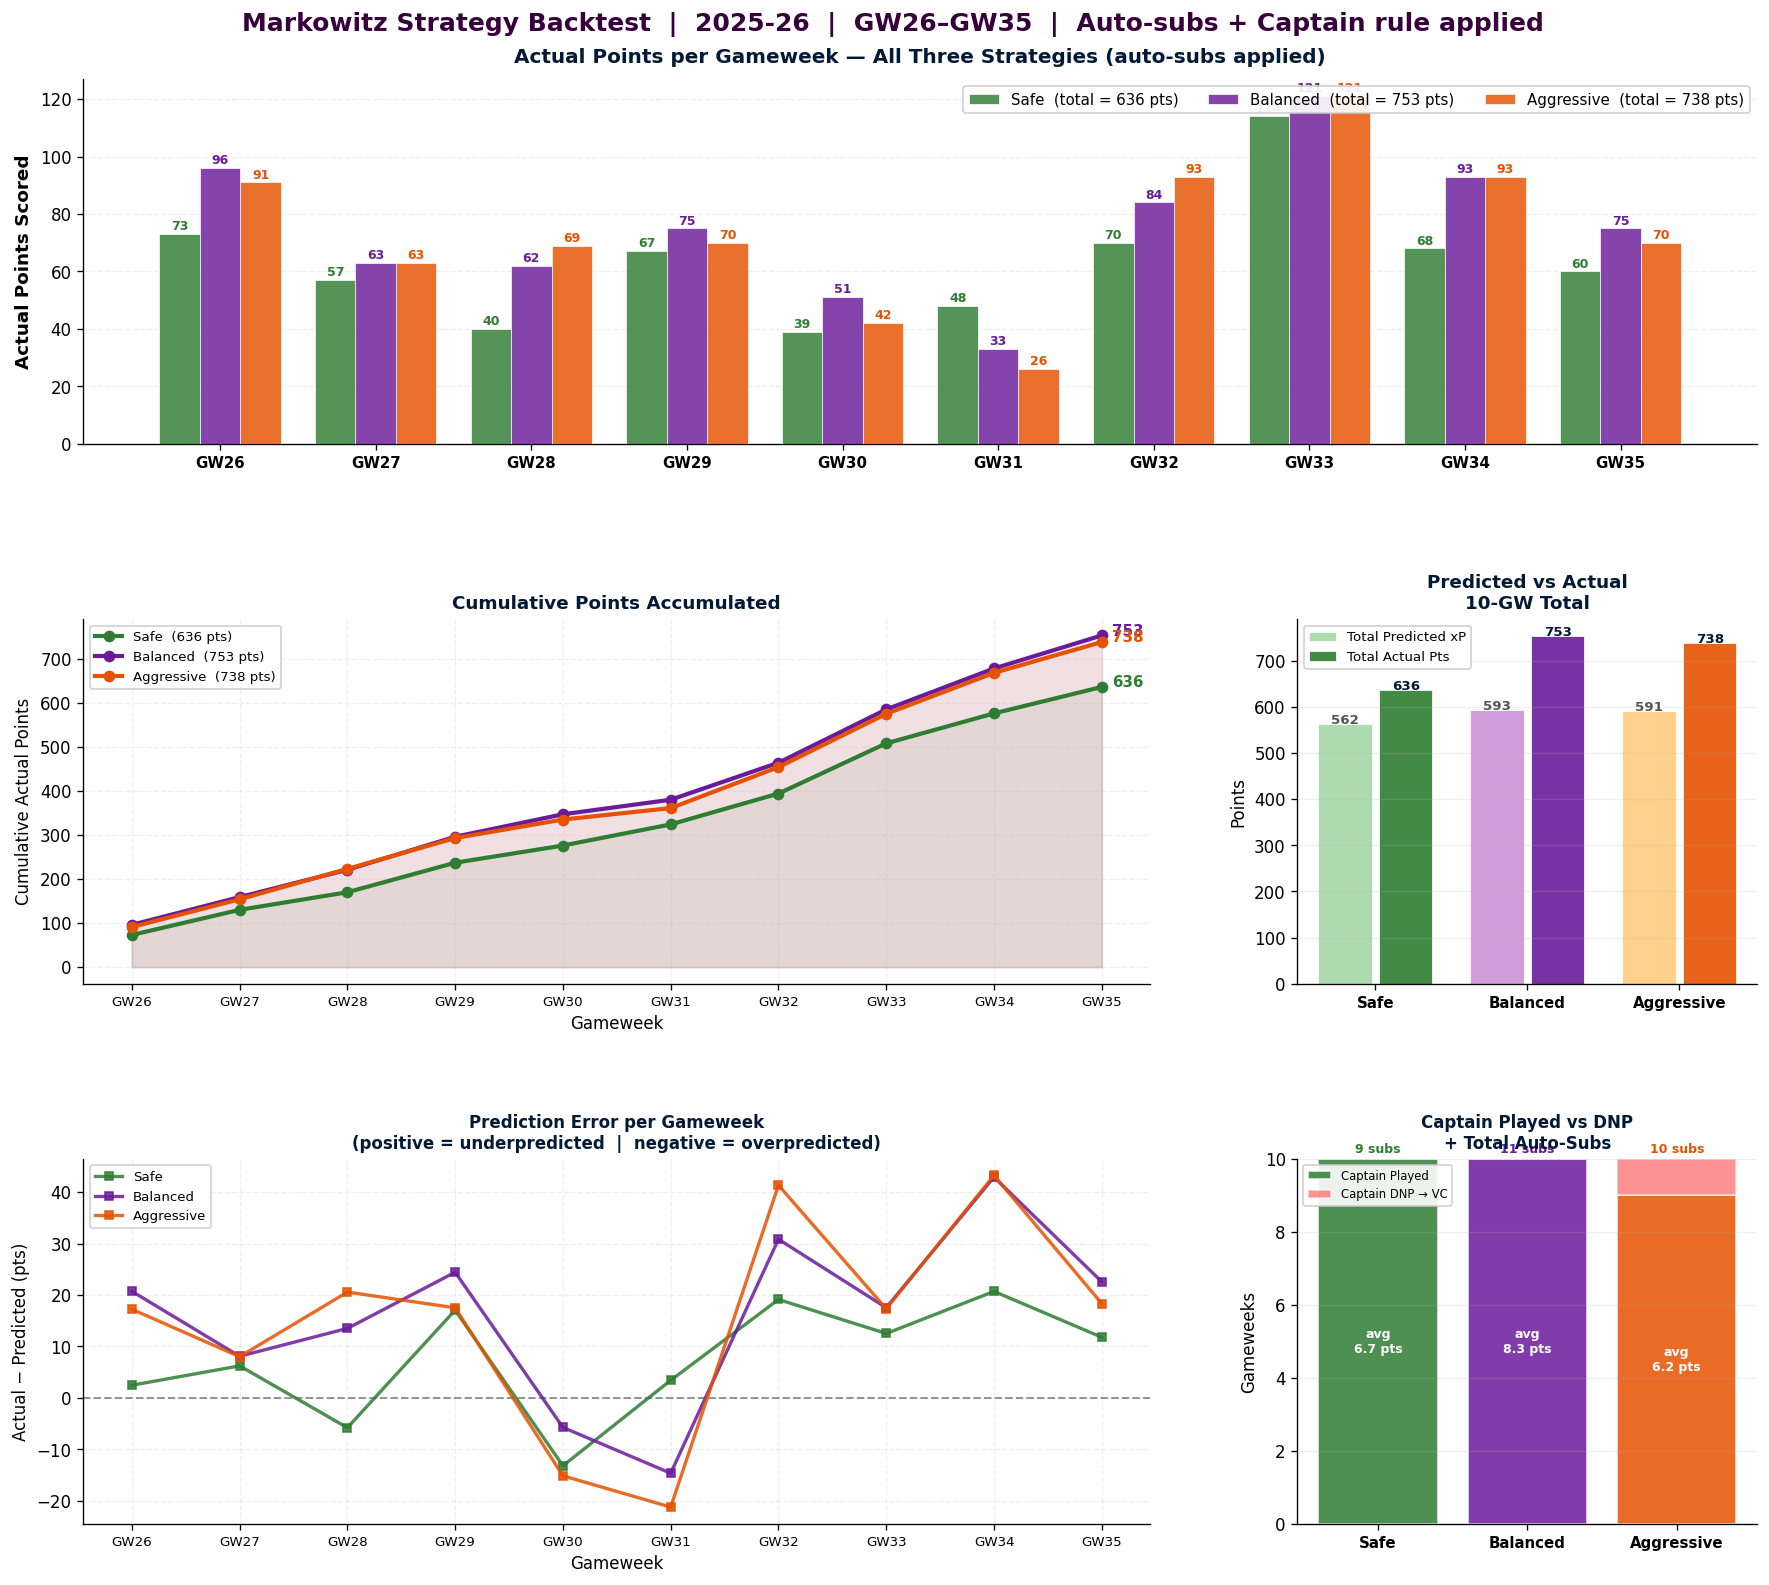


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  BACKTEST VERDICT — GW26 to GW35
  (Scores include automatic substitutions)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Safe          Actual= 636  Predicted= 561.7  Δ= +74.3  Cap played=100%  AutoSubs=9
  Balanced      Actual= 753  Predicted= 592.7  Δ=+160.3  Cap played=100%  AutoSubs=11  ← WINNER 🏆
  Aggressive    Actual= 738  Predicted= 590.8  Δ=+147.2  Cap played=90%  AutoSubs=10

  Model calibration:
  Average actual / predicted ratio: 121.9%
  → Model is well-calibrated for a regression approach

✓ backtest_results_df saved to globals().
✓ backtest_df (raw row-level data) saved to globals().
✓ Plot saved: output/forecaster_pro/markowitz_backtest.png


In [97]:
# %% [10-Gameweek Backtest Simulation — STRICT NO-LEAKAGE VERSION]
# ─────────────────────────────────────────────────────────────────────────────
# Simulates the SAFE, BALANCED, and AGGRESSIVE strategies over the last 10 GWs.
# 
# PROFESSIONAL DATA SANITIZATION IMPLEMENTED:
#   1. Pricing: Prioritizes historical price data if available.
#   2. Elite Status: Calculated strictly on an expanding mean (< target_gw).
#   3. Haul Probability: Generated dynamically per-GW using the haul_clf model
#      instead of relying on the static, present-day hauler_board.
#   4. Availability: Missing GW rows treated as 0 minutes (pipeline drops 0-min rows).
#      Players with 0 minutes in 2+ of last 3 GWs are excluded as injured proxy.
#
# FPL Rules implemented: Auto-subs, Captain DNP → VC, Legal Formations.
# Writes to globals: backtest_results_df, backtest_df
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
import subprocess
import sys
warnings.filterwarnings('ignore')

for _pkg in ['jinja2', 'pulp', 'openpyxl']:
    try:
        __import__(_pkg)
    except ImportError:
        print(f"Installing {_pkg}...")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', _pkg, '--quiet'])
        print(f"✓ {_pkg} installed.")

import openpyxl
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter

CURRENT_SEASON  = globals().get('CURRENT_SEASON', '2025-26')
CURRENT_GW      = globals().get('CURRENT_GW', 33)
BACKTEST_WINDOW = 10
MIN_VOLATILITY  = 0.1

_required = [
    'df_augmented', 'optimize_squad', 'STRATEGY_CONFIGS',
    'pos_map', 'club_map', 'live_data',
    'get_player_live_v2', 'wn_to_uuid_corrected'
]
_missing = [v for v in _required if v not in globals()]
if _missing:
    print(f"[ERROR] Missing: {_missing}")
    print("Run Cells 2.1 and 2.2 first to register optimize_squad().")
else:

    GW_START  = max(7, CURRENT_GW - BACKTEST_WINDOW)
    GW_END    = CURRENT_GW - 1
    _gw_range = list(range(GW_START, GW_END + 1))

    print(f"{'━'*65}")
    print(f"  TASK 4 — 10-GW BACKTEST SIMULATION (NO-LEAKAGE ENVIRONMENT)")
    print(f"  Season: {CURRENT_SEASON}  |  GWs: {GW_START}–{GW_END}")
    print(f"  Rules: Auto-subs ✓  |  Captain DNP→VC ✓  |  Formation check ✓")
    print(f"  Sanitization: Dynamic Haul Probs ✓  |  Dynamic Elite Status ✓")
    print(f"  Availability: Missing rows = 0 mins (injury proxy) ✓")
    print(f"{'━'*65}\n")

    _season_data = (
        df_augmented[df_augmented['season'] == CURRENT_SEASON]
        .copy()
        .sort_values(['Web Name', 'Gameweek'])
        .drop_duplicates(subset=['Web Name', 'Gameweek'], keep='first')
    )

    # ── Manual team name corrections ──────
    _team_fixes = {'Truffert': 'Bournemouth'}
    for _pname, _correct_team in _team_fixes.items():
        _mask = _season_data['Web Name'] == _pname
        if _mask.any():
            _season_data.loc[_mask, 'team'] = _correct_team

    # DGW Aggregation: .first() for Points, .sum() for Minutes
    _actuals_lookup = (
        _season_data
        .groupby(['Web Name', 'Gameweek'])
        .agg(
            Actual_Points=('Total Points', 'first'),
            Minutes_Played=('Minutes Played', 'sum')
        )
        .reset_index()
    )

    def _get_actual(player_name, gw):
        _row = _actuals_lookup[
            (_actuals_lookup['Web Name'] == player_name) &
            (_actuals_lookup['Gameweek'] == gw)
        ]
        if _row.empty:
            return 0, 0
        return int(_row['Actual_Points'].iloc[0]), int(_row['Minutes_Played'].iloc[0])

    def _apply_auto_subs(starting_11_names, bench_names, bench_positions, gw):
        _mins        = {p: _get_actual(p, gw)[1] for p in starting_11_names + bench_names}
        _current_11  = list(starting_11_names)
        _current_pos = {
            p: bench_positions.get(p, pos_map.get(p, 'MID'))
            for p in _current_11 + bench_names
        }
        _bench_gk       = [p for p in bench_names if _current_pos.get(p) == 'GK']
        _bench_outfield = [p for p in bench_names if _current_pos.get(p) != 'GK']
        _subs_made      = []
        _bench_avail    = list(_bench_outfield)

        def _count_pos(squad, pos):
            return sum(1 for p in squad if _current_pos.get(p) == pos)

        for _attempt in range(len(_current_11)):
            _sub_happened = False
            for _idx, _starter in enumerate(_current_11):
                if _mins[_starter] > 0:
                    continue
                _starter_pos = _current_pos.get(_starter, 'MID')
                if _starter_pos == 'GK':
                    for _bgk in _bench_gk:
                        if _mins[_bgk] > 0:
                            _current_11[_idx] = _bgk
                            _bench_gk.remove(_bgk)
                            _subs_made.append((_starter, _bgk))
                            _sub_happened = True
                            break
                    continue
                for _bi, _sub_candidate in enumerate(_bench_avail):
                    if _mins[_sub_candidate] == 0:
                        continue
                    _trial_11 = list(_current_11)
                    _trial_11[_idx] = _sub_candidate
                    if _count_pos(_trial_11, 'GK') < 1 or \
                       _count_pos(_trial_11, 'DEF') < 3 or \
                       _count_pos(_trial_11, 'FWD') < 1:
                        continue
                    _current_11[_idx] = _sub_candidate
                    _bench_avail.pop(_bi)
                    _subs_made.append((_starter, _sub_candidate))
                    _sub_happened = True
                    break
            if not _sub_happened:
                break
        return _current_11, _subs_made

    def _build_historical_universe(target_gw: int) -> pd.DataFrame:
        _hist = _season_data[_season_data['Gameweek'] < target_gw].copy()
        if _hist.empty:
            return pd.DataFrame()

        # All GWs available in historical data before target_gw (used for availability proxy)
        _hist_gws_available = sorted(_hist['Gameweek'].unique())

        _wm         = globals().get('winning_model')
        _best_nm    = globals().get('best_model_name', 'V1: Standard Pro')
        _pos_to_num = {'GK': 0, 'DEF': 1, 'MID': 2, 'FWD': 3}

        # Select correct feature columns for main regression model
        if 'V3' in _best_nm:
            _feat_cols = [f'lag_{i}' for i in range(6, 0, -1)] + [
                'position', 'diff', 'home', 'min',
                'volatility', 'stability', 'att_form', 'share', 'avg_pts_vs_diff'
            ]
        elif 'V2' in _best_nm:
            _feat_cols = [f'lag_{i}' for i in range(6, 0, -1)] + [
                'position', 'next_difficulty', 'next_is_home', 'rolling_min',
                'season_phase', 'season_baseline', 'team_share', 'avg_pts_vs_diff'
            ]
        else:
            _feat_cols = [f'lag_{i}' for i in range(6, 0, -1)] + [
                'position', 'next_difficulty', 'next_is_home', 'rolling_min',
                'season_phase', 'season_baseline', 'avg_pts_vs_diff'
            ]

        # Feature columns for the dynamic haul classifier
        _haul_cols = [f'lag_{i}' for i in range(6, 0, -1)] + [
            'position', 'next_difficulty', 'next_is_home', 'rolling_min',
            'season_phase', 'season_baseline', 'recent_haul_flag',
            'lag_max_6', 'is_elite', 'fixture_ease', 'avg_pts_vs_diff', 'ceiling_ratio'
        ]

        _inference_rows  = []
        _haul_features   = []
        _inference_names = []

        # FIX LEAK 2: Dynamic historical expanding mean for Is_Elite
        _hist_means = _hist.groupby('Web Name')['Total Points'].mean().to_dict()

        for _pid, _group in _hist.groupby('Player UUID'):
            _group = _group.sort_values('Gameweek')
            if len(_group) < 6:
                continue
            _last = _group.iloc[-1]
            _lags = list(_group['Total Points'].tail(6).values)
            _wn   = _last.get('Web Name', '')

            _is_elite_dyn = 1 if _hist_means.get(_wn, 0.0) > 4.5 else 0

            # 1. Build row for standard regression model
            if 'V3' in _best_nm:
                _row = _lags + [
                    _pos_to_num.get(_last.get('Position', 'MID'), 2),
                    _last.get('Next_Opponent_Difficulty', 3), _last.get('Next_Is_Home', 0),
                    _last.get('Rolling_Avg_Minutes_5', 60), _last.get('Points_Volatility_5', 2),
                    _last.get('Min_Stability_5', 60), _last.get('Attacking_Form_3', 2),
                    _last.get('Team_Point_Share', 0), _last.get('Avg_Pts_vs_Difficulty', 2),
                ]
            elif 'V2' in _best_nm:
                _row = _lags + [
                    _pos_to_num.get(_last.get('Position', 'MID'), 2),
                    _last.get('Next_Opponent_Difficulty', 3), _last.get('Next_Is_Home', 0),
                    _last.get('Rolling_Avg_Minutes_5', 60), _last.get('Season_Phase', 2),
                    _last.get('Prev_Season_Avg_Points', 0), _last.get('Team_Point_Share', 0),
                    _last.get('Avg_Pts_vs_Difficulty', 2),
                ]
            else:
                _row = _lags + [
                    _pos_to_num.get(_last.get('Position', 'MID'), 2),
                    _last.get('Next_Opponent_Difficulty', 3), _last.get('Next_Is_Home', 0),
                    _last.get('Rolling_Avg_Minutes_5', 60), _last.get('Season_Phase', 2),
                    _last.get('Prev_Season_Avg_Points', 0), _last.get('Avg_Pts_vs_Difficulty', 2),
                ]
            _inference_rows.append(_row)
            _inference_names.append(_wn)

            # 2. Build row for dynamic Haul Classifier
            _recent_haul = 1 if any(l >= 10 for l in _lags[-3:]) else 0
            _lag_max     = max(_lags)
            _fix_ease    = 6 - _last.get('Next_Opponent_Difficulty', 3)
            _ceil_rat    = _lag_max / 10.0

            _haul_row = _lags + [
                _pos_to_num.get(_last.get('Position', 'MID'), 2),
                _last.get('Next_Opponent_Difficulty', 3),
                _last.get('Next_Is_Home', 0),
                _last.get('Rolling_Avg_Minutes_5', 60),
                _last.get('Season_Phase', 2),
                _last.get('Prev_Season_Avg_Points', 0),
                _recent_haul,
                _lag_max,
                _is_elite_dyn,
                _fix_ease,
                _last.get('Avg_Pts_vs_Difficulty', 2),
                _ceil_rat
            ]
            _haul_features.append(_haul_row)

        if not _inference_rows:
            return pd.DataFrame()

        # Generate Main Predictions
        _inf_df = pd.DataFrame(_inference_rows, columns=_feat_cols)
        if 'X_train_raw' in globals() and 'position' in globals()['X_train_raw'].columns:
            _inf_df['position'] = pd.Categorical(
                _inf_df['position'],
                categories=globals()['X_train_raw']['position'].cat.categories
            )
        else:
            _inf_df['position'] = _inf_df['position'].astype('category')

        if _wm is not None:
            try:
                _raw_preds = _wm.predict(_inf_df)
            except Exception as _e:
                print(f"  [WARN GW{target_gw}] Model predict failed: {_e}. Using lag mean fallback.")
                _raw_preds = _inf_df[[c for c in _feat_cols if 'lag' in c]].mean(axis=1).values
        else:
            _raw_preds = _inf_df[[c for c in _feat_cols if 'lag' in c]].mean(axis=1).values

        # FIX LEAK 3: Dynamic Haul Probabilities
        _haul_df = pd.DataFrame(_haul_features, columns=_haul_cols)
        if 'X_haul_train' in globals() and 'position' in globals()['X_haul_train'].columns:
            _haul_df['position'] = pd.Categorical(
                _haul_df['position'],
                categories=globals()['X_haul_train']['position'].cat.categories
            )
        else:
            _haul_df['position'] = _haul_df['position'].astype('category')

        if 'haul_clf' in globals():
            _haul_probs = globals()['haul_clf'].predict_proba(_haul_df)[:, 1] * 100.0
        else:
            _haul_probs = np.zeros(len(_haul_features))

        _latest = (
            _hist.sort_values('Gameweek')
            .drop_duplicates('Web Name', keep='last')
            .set_index('Web Name')
            .copy()
        )
        _pred_map = dict(zip(_inference_names, _raw_preds))
        _haul_map = dict(zip(_inference_names, _haul_probs))

        # ── DGW/BGW detection ─────────────────────────────────────────────────
        try:
            from collections import Counter
            _fx         = pd.read_csv(f'../data/{CURRENT_SEASON}/fixtures.csv')
            _gw_fx      = _fx[_fx['event'] == target_gw]
            _teams_csv  = pd.read_csv(f'../data/{CURRENT_SEASON}/teams.csv')
            _id_to_name = _teams_csv.set_index('id')['name'].to_dict()

            _name_fixes = {
                "Nottingham Forest":       "Nott'm Forest",
                "Manchester City":         "Man City",
                "Manchester United":       "Man Utd",
                "Newcastle United":        "Newcastle",
                "Tottenham Hotspur":       "Spurs",
                "West Ham United":         "West Ham",
                "Wolverhampton Wanderers": "Wolves",
                "Brighton & Hove Albion":  "Brighton",
                "Leeds United":            "Leeds",
                "Burnley":                 "Burnley",
                "Bournemouth":             "Bournemouth",
            }

            _team_id_counts  = Counter(_gw_fx['team_h'].tolist() + _gw_fx['team_a'].tolist())
            _teams_in_gw_ids = set(_gw_fx['team_h'].tolist() + _gw_fx['team_a'].tolist())
            _all_team_ids    = set(_teams_csv['id'].tolist())
            _dgw_ids         = {tid for tid, cnt in _team_id_counts.items() if cnt > 1}
            _bgw_ids         = _all_team_ids - _teams_in_gw_ids

            def _norm(raw): return _name_fixes.get(raw, raw)
            _dgw_names_gw = {_norm(_id_to_name.get(tid, '')) for tid in _dgw_ids if tid in _id_to_name}
            _bgw_names_gw = {_norm(_id_to_name.get(tid, '')) for tid in _bgw_ids if tid in _id_to_name}

            # Hardcode GW34 blanks (fixture CSV may not reflect rescheduled games)
            if target_gw == 34 and CURRENT_SEASON == '2025-26':
                _bgw_names_gw = _bgw_names_gw.union({
                    'Bournemouth', 'Brighton', 'Burnley', 'Chelsea', 'Leeds', 'Man City'
                })

            print(f"    GW{target_gw} DGW teams: {sorted(_dgw_names_gw) or 'none'}")
            print(f"    GW{target_gw} BGW teams: {sorted(_bgw_names_gw) or 'none'}")

        except Exception as _e:
            print(f"    [WARN] Fixture detection failed for GW{target_gw}: {_e}")
            _dgw_names_gw = set()
            _bgw_names_gw = set()

        # ── Last 3 GWs before target_gw (used for availability proxy) ─────────
        # We use _hist_gws_available (computed at top of function from _hist)
        # so this is fully contained within the function scope — no leakage.
        _last_3_gws_for_proxy = _hist_gws_available[-3:]

        _universe_rows = []
        _wn_to_uuid    = globals().get('wn_to_uuid_corrected', {})

        for _wn, _row_data in _latest.iterrows():
            _pred = _pred_map.get(_wn, None)
            if _pred is None:
                continue

            _pos  = pos_map.get(_wn, str(_row_data.get('Position', 'MID')))
            _team = club_map.get(_wn, str(_row_data.get('Player Team Name', 'Neutral')))

            # FIX LEAK 1: Use historical value if available, else live_data
            _val_raw = _row_data.get('Value')
            if _val_raw is not None and not pd.isna(_val_raw):
                _price = float(_val_raw) / 10.0 if float(_val_raw) > 30 else float(_val_raw)
            else:
                _price = get_player_live_v2(_wn, uuid=_wn_to_uuid.get(_wn)).get('price', 5.5)

            _disc = float(
                (1 - (min(float(_row_data.get('Rolling_Avg_Minutes_5', 60)), 90) / 90)) * 100
            )
            _vol = max(float(_row_data.get('Points_Volatility_5', 2.0)), MIN_VOLATILITY)

            _dgw    = _team in _dgw_names_gw
            _is_bgw = _team in _bgw_names_gw

            # ── FIX: Availability proxy using complete GW coverage ────────────
            # Pipeline drops 0-minute rows, so a missing GW row = 0 minutes played.
            # We check the last 3 GWs that exist in the historical data and treat
            # any missing row as 0 minutes — correctly catching long-term injuries
            # like Henry who had 0 mins across 5+ consecutive GWs.
            _mins_by_gw = (
                _hist[_hist['Web Name'] == _wn]
                .set_index('Gameweek')['Minutes Played']
                .to_dict()
            )
            # For each of the last 3 GWs, get actual minutes (0 if row missing)
            _recent_mins_full = [int(_mins_by_gw.get(g, 0)) for g in _last_3_gws_for_proxy]
            _zeros = sum(1 for m in _recent_mins_full if m == 0)

            if _zeros >= 2:
                _proxy_status = 'i'     # injured proxy — exclude
                _is_available = False
            elif _zeros == 1:
                _proxy_status = 'd'     # doubtful proxy — include but penalised by Discount%
                _is_available = True
            else:
                _proxy_status = 'a'     # available
                _is_available = True

            # Minutes reliability penalty
            _avg_mins_hist    = min(float(_row_data.get('Rolling_Avg_Minutes_5', 60)), 90.0)
            _mins_reliability = _avg_mins_hist / 90.0
            _pred_penalised   = round(float(_pred) * _mins_reliability, 4)

            if _is_bgw:
                _pred_penalised = 0.0
            if _dgw:
                _pred_penalised = round(_pred_penalised * 1.8, 4)

            _universe_rows.append({
                'Player':           _wn,
                'Position':         _pos,
                'Pos_ID':           {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4}.get(_pos, 3),
                'Team':             _team,
                'Price':            _price,
                'Predicted_Points': _pred_penalised,
                'xP_Optimizer':     round(_pred_penalised * 0.85 if _disc > 33 else _pred_penalised, 4),
                'Discount_%':       round(_disc, 1),
                'Volatility':       round(_vol, 4),
                'Captain_Eligible': int(_disc <= 10),
                'Haul_Prob':        float(_haul_map.get(_wn, 0.0)),
                'Is_Elite':         int(_hist_means.get(_wn, 0.0) > 4.5),
                'DGW_Team':         _dgw,
                'Available':        _is_available,
                'Status':           _proxy_status,
            })

        _universe = pd.DataFrame(_universe_rows)
        _universe = _universe[
            (_universe['Available'] == True) &
            (_universe['Discount_%'] <= 50) &
            (_universe['Price'] > 3.5) &
            (_universe['xP_Optimizer'] > 0)
        ].drop_duplicates('Player').reset_index(drop=True)

        return _universe

    # ── Main backtest loop ────────────────────────────────────────────────────
    _strategies = ['Safe', 'Balanced', 'Aggressive']
    _all_rows   = []
    _bt_squads  = {}

    for _gw in _gw_range:
        print(f"  GW{_gw:02d}  ", end='', flush=True)

        _uni = _build_historical_universe(_gw)

        if len(_uni) < 15:
            print(f"[SKIP — only {len(_uni)} eligible players]")
            continue

        for _strat in _strategies:
            _result = optimize_squad(
                strategy=_strat,
                universe=_uni,
                budget_cap=100.0,
                verbose=False
            )

            if not _result or _result.get('status') != 'Optimal':
                print(f"[{_strat} FAIL] ", end='')
                _all_rows.append({
                    'GW': _gw, 'Strategy': _strat, 'Status': 'Failed',
                    'Predicted_xP': np.nan, 'Actual_Points': np.nan,
                    'Captain': None, 'VC': None, 'Captain_Pts': np.nan,
                    'Captain_Played': np.nan, 'Subs_Made': 0,
                })
                continue

            _s11     = _result['starting_11']
            _bench   = _result['bench']
            _captain = _result['captain']
            _vc      = _result['vice_captain']
            _squad   = _result['squad']

            _all_pos        = _squad.set_index('Player')['Position'].to_dict()
            _bench_gk_list  = (_bench[_bench['Position'] == 'GK']
                               .sort_values('xP_Optimizer', ascending=False)['Player'].tolist())
            _bench_out_list = (_bench[_bench['Position'] != 'GK']
                               .sort_values('xP_Optimizer', ascending=False)['Player'].tolist())
            _bench_ordered  = _bench_out_list + _bench_gk_list
            _s11_names      = _s11['Player'].tolist()

            # ── Apply automatic substitutions ──────────────────────────────────
            _final_11, _subs = _apply_auto_subs(
                starting_11_names=_s11_names,
                bench_names=_bench_ordered,
                bench_positions=_all_pos,
                gw=_gw
            )

            # ── Capture POST-SUB squad for Excel ───────────────────────────────
            _subbed_out   = {out for out, inn in _subs}
            _subbed_in    = {inn for out, inn in _subs}
            _final_11_set = set(_final_11)
            _all_players  = pd.concat([_s11, _bench]).drop_duplicates('Player')

            _s11_cap   = _all_players[_all_players['Player'].isin(_final_11_set)].copy()
            _bench_cap = _all_players[~_all_players['Player'].isin(_final_11_set)].copy()

            _s11_cap['Role'] = _s11_cap['Player'].apply(
                lambda p: '👑 Captain'    if p == _captain else
                          '🔰 Vice-Capt' if p == _vc      else
                          '🔄 Sub In'    if p in _subbed_in else 'Starter'
            )
            _bench_cap['Role'] = _bench_cap['Player'].apply(
                lambda p: '🔄 Sub Out' if p in _subbed_out else 'Bench'
            )
            _s11_cap['Actual_Points']   = _s11_cap['Player'].apply(lambda p: _get_actual(p, _gw)[0])
            _bench_cap['Actual_Points'] = _bench_cap['Player'].apply(lambda p: _get_actual(p, _gw)[0])

            _excel_cols = [c for c in ['Player', 'Position', 'Team', 'Price',
                                       'xP_Optimizer', 'Actual_Points', 'Role']
                           if c in _s11_cap.columns]

            # ── Captain rule ───────────────────────────────────────────────────
            _cap_pts, _cap_mins = _get_actual(_captain, _gw)
            _vc_pts,  _vc_mins  = _get_actual(_vc,      _gw)

            # ── Score final 11 ─────────────────────────────────────────────────
            _total_actual = 0
            for _pname in _final_11:
                _pts, _mins = _get_actual(_pname, _gw)
                if _pname == _captain:
                    _total_actual += _pts * 2 if _cap_mins > 0 else 0
                else:
                    _total_actual += _pts

            if _cap_mins == 0:
                _total_actual += _vc_pts * 2

            _bt_squads[(_gw, _strat)] = {
                'starting_11':  _s11_cap[_excel_cols].reset_index(drop=True),
                'bench':        _bench_cap[_excel_cols].reset_index(drop=True),
                'captain':      _captain,
                'vc':           _vc,
                'total_actual': _total_actual,
                'final_11':     list(_final_11),
            }

            _pred_xp      = float(_s11['xP_Optimizer'].sum())
            _cap_pred_row = _s11[_s11['Player'] == _captain]
            if not _cap_pred_row.empty:
                _pred_xp += float(_cap_pred_row['xP_Optimizer'].iloc[0])

            _sub_str = ', '.join([f'{o}→{i}' for o, i in _subs]) if _subs else 'none'

            _all_rows.append({
                'GW':             _gw,
                'Strategy':       _strat,
                'Status':         'OK',
                'Predicted_xP':   round(_pred_xp, 2),
                'Actual_Points':  _total_actual,
                'Captain':        _captain,
                'VC':             _vc,
                'Captain_Pts':    _cap_pts,
                'Captain_Played': int(_cap_mins > 0),
                'Subs_Made':      len(_subs),
                'Sub_Details':    _sub_str,
                'n_eligible':     len(_uni),
            })

        print(f"✓")

    # ── SAVE BACKTEST SQUADS TO EXCEL ─────────────────────────────────────────
    print("\nSaving backtest squads to Excel...")

    _excel_path       = '../output/forecaster_pro/markowitz_backtest_squads.xlsx'
    _strategy_colours = {
        'Safe':       {'tab': '2e7d32', 'header': '1b5e20', 'row': 'e8f5e9', 'bench': 'f9fbe7'},
        'Balanced':   {'tab': '6a1b9a', 'header': '4a148c', 'row': 'f3e5f5', 'bench': 'fce4ec'},
        'Aggressive': {'tab': 'e65100', 'header': 'bf360c', 'row': 'fff3e0', 'bench': 'fff8e1'},
    }
    _pos_order = {'GK': 0, 'DEF': 1, 'MID': 2, 'FWD': 3}

    wb = openpyxl.Workbook()
    wb.remove(wb.active)

    for _gw in _gw_range:
        for _strat in _strategies:
            _key = (_gw, _strat)
            if _key not in _bt_squads:
                continue

            _data     = _bt_squads[_key]
            _s11_df   = _data['starting_11'].copy()
            _bench_df = _data['bench'].copy()
            _cap      = _data['captain']
            _vc       = _data['vc']
            _cols_sc  = _strategy_colours[_strat]

            _s11_df['_pos_order'] = _s11_df['Position'].map(lambda p: _pos_order.get(p, 9))
            _s11_df = _s11_df.sort_values('_pos_order').drop(columns=['_pos_order'])

            _sheet_name = f"GW{_gw}_{_strat}"[:31]
            ws = wb.create_sheet(title=_sheet_name)
            ws.sheet_properties.tabColor = _cols_sc['tab']

            _thin   = Side(style='thin', color='CCCCCC')
            _border = Border(left=_thin, right=_thin, top=_thin, bottom=_thin)

            # Title
            ws.merge_cells('A1:G1')
            _tc           = ws['A1']
            _tc.value     = f"GW{_gw} — {_strat.upper()} Strategy"
            _tc.font      = Font(bold=True, size=13, color='FFFFFF', name='Calibri')
            _tc.fill      = PatternFill('solid', fgColor=_cols_sc['header'])
            _tc.alignment = Alignment(horizontal='center', vertical='center')
            ws.row_dimensions[1].height = 22

            # Captain row
            ws.merge_cells('A2:G2')
            _ic           = ws['A2']
            _ic.value     = f"Captain: {_cap} (pts doubled in team total)   |   Vice-Captain: {_vc}"
            _ic.font      = Font(bold=True, size=10, color='FFFFFF', name='Calibri')
            _ic.fill      = PatternFill('solid', fgColor=_cols_sc['header'])
            _ic.alignment = Alignment(horizontal='center')
            ws.row_dimensions[2].height = 18

            # Starting XI label
            ws.merge_cells('A3:G3')
            _sc           = ws['A3']
            _sc.value     = '▶  STARTING XI  (after auto-subs)'
            _sc.font      = Font(bold=True, size=10, color='FFFFFF', name='Calibri')
            _sc.fill      = PatternFill('solid', fgColor=_cols_sc['header'])
            _sc.alignment = Alignment(horizontal='left', indent=1)
            ws.row_dimensions[3].height = 16

            _headers = ['Player', 'Position', 'Team', 'Price (£m)', 'xP (model)', 'Actual Pts', 'Role']
            for _ci, _h in enumerate(_headers, start=1):
                _hc           = ws.cell(row=4, column=_ci, value=_h)
                _hc.font      = Font(bold=True, size=9, color='FFFFFF', name='Calibri')
                _hc.fill      = PatternFill('solid', fgColor='37003c')
                _hc.alignment = Alignment(horizontal='center')
                _hc.border    = _border
            ws.row_dimensions[4].height = 15

            _df_cols = [c for c in ['Player', 'Position', 'Team', 'Price',
                                    'xP_Optimizer', 'Actual_Points', 'Role']
                        if c in _s11_df.columns]

            for _ri, (_, _row) in enumerate(_s11_df.iterrows(), start=5):
                _is_cap  = _row['Player'] == _cap
                _is_vc   = _row['Player'] == _vc
                _is_sub  = '🔄' in str(_row.get('Role', ''))
                _row_fill = ('FFD700' if _is_cap else
                             'C0C0C0' if _is_vc  else
                             'dce8ff' if _is_sub  else
                             _cols_sc['row'])
                for _ci, _col in enumerate(_df_cols, start=1):
                    _val = _row.get(_col, '')
                    if _col == 'Price':
                        _val = f"£{float(_val):.1f}m" if _val != '' else ''
                    elif _col == 'xP_Optimizer':
                        _val = round(float(_val), 2) if _val != '' else ''
                    _c           = ws.cell(row=_ri, column=_ci, value=_val)
                    _c.fill      = PatternFill('solid', fgColor=_row_fill)
                    _c.font      = Font(bold=(_is_cap or _is_vc), size=9, name='Calibri')
                    _c.alignment = Alignment(horizontal='center')
                    _c.border    = _border
                ws.row_dimensions[_ri].height = 14

            # ── TEAM TOTAL ROW ─────────────────────────────────────────────────
            _stored_total   = _data['total_actual']
            _stored_11      = _data['final_11']
            _cap_raw        = int(_get_actual(_cap, _gw)[0])
            _cap_mins_check = int(_get_actual(_cap, _gw)[1])
            _vc_raw         = int(_get_actual(_vc,  _gw)[0])
            _raw_sum_11     = sum(_get_actual(p, _gw)[0] for p in _stored_11)
            _team_total     = _stored_total

            _total_row_idx = _ri + 1
            ws.merge_cells(f'A{_total_row_idx}:E{_total_row_idx}')
            _non_cap_sum = _raw_sum_11 - _cap_raw
            _bonus       = _cap_raw if _cap_mins_check > 0 else _vc_raw
            _bonus_name  = _cap if _cap_mins_check > 0 else f'{_vc} (VC)'
            _tr_label = ws.cell(
                row=_total_row_idx, column=1,
                value=f'TEAM TOTAL  ({_non_cap_sum} others + {_bonus_name} ×2 = {_team_total})'
            )
            _tr_label.font      = Font(bold=True, size=9, color='FFFFFF', name='Calibri')
            _tr_label.fill      = PatternFill('solid', fgColor='37003c')
            _tr_label.alignment = Alignment(horizontal='left', indent=1)
            _tr_label.border    = _border

            _tr_val = ws.cell(row=_total_row_idx, column=6, value=_team_total)
            _tr_val.font      = Font(bold=True, size=11, color='FFFFFF', name='Calibri')
            _tr_val.fill      = PatternFill('solid', fgColor='37003c')
            _tr_val.alignment = Alignment(horizontal='center')
            _tr_val.border    = _border

            _tr_blank = ws.cell(row=_total_row_idx, column=7, value='')
            _tr_blank.fill   = PatternFill('solid', fgColor='37003c')
            _tr_blank.border = _border
            ws.row_dimensions[_total_row_idx].height = 16

            _bench_start = _total_row_idx + 2

            # Bench section
            ws.merge_cells(f'A{_bench_start}:G{_bench_start}')
            _bsc           = ws.cell(row=_bench_start, column=1, value='⬛  BENCH  (🔄 = subbed out)')
            _bsc.font      = Font(bold=True, size=10, color='FFFFFF', name='Calibri')
            _bsc.fill      = PatternFill('solid', fgColor='444444')
            _bsc.alignment = Alignment(horizontal='left', indent=1)
            ws.row_dimensions[_bench_start].height = 16

            for _ci, _h in enumerate(_headers, start=1):
                _hc           = ws.cell(row=_bench_start + 1, column=_ci, value=_h)
                _hc.font      = Font(bold=True, size=9, color='FFFFFF', name='Calibri')
                _hc.fill      = PatternFill('solid', fgColor='555555')
                _hc.alignment = Alignment(horizontal='center')
                _hc.border    = _border
            ws.row_dimensions[_bench_start + 1].height = 15

            _bench_df_cols = [c for c in _df_cols if c in _bench_df.columns]
            for _ri, (_, _row) in enumerate(_bench_df.iterrows(), start=_bench_start + 2):
                _is_subout = '🔄' in str(_row.get('Role', ''))
                _b_fill    = 'ffe0e0' if _is_subout else _cols_sc['bench']
                for _ci, _col in enumerate(_bench_df_cols, start=1):
                    _val = _row.get(_col, '')
                    if _col == 'Price':
                        _val = f"£{float(_val):.1f}m" if _val != '' else ''
                    elif _col == 'xP_Optimizer':
                        _val = round(float(_val), 2) if _val != '' else ''
                    _c           = ws.cell(row=_ri, column=_ci, value=_val)
                    _c.fill      = PatternFill('solid', fgColor=_b_fill)
                    _c.font      = Font(size=9, name='Calibri', color='333333', italic=True)
                    _c.alignment = Alignment(horizontal='center')
                    _c.border    = _border
                ws.row_dimensions[_ri].height = 14

            for _ci, _w in enumerate([22, 10, 18, 11, 11, 11, 16], start=1):
                ws.column_dimensions[get_column_letter(_ci)].width = _w

    wb.save(_excel_path)
    print(f"✓ Excel saved → {_excel_path}")
    print(f"  Sheets: {len(wb.sheetnames)} ({len(_gw_range)} GWs × {len(_strategies)} strategies)")

    if not _all_rows:
        print("[ERROR] No results collected.")
    else:
        backtest_df = pd.DataFrame(_all_rows)
        _ok         = backtest_df[backtest_df['Status'] == 'OK'].copy()
        _total_subs = int(_ok['Subs_Made'].sum())
        print(f"\n  Auto-substitutions applied: {_total_subs} total across all GWs and strategies")

        _sub_rows = _ok[_ok['Subs_Made'] > 0][['GW', 'Strategy', 'Subs_Made', 'Sub_Details']].head(10)
        if not _sub_rows.empty:
            print(f"\n  Sample sub events:")
            display(_sub_rows.reset_index(drop=True))

        _pivot_actual = (
            _ok.pivot_table(index='GW', columns='Strategy', values='Actual_Points', aggfunc='first')
            [_strategies]
        )
        _pivot_pred = (
            _ok.pivot_table(index='GW', columns='Strategy', values='Predicted_xP', aggfunc='first')
            [_strategies]
        )

        _results_display = pd.DataFrame(index=_pivot_actual.index)
        for _s in _strategies:
            _results_display[f'{_s} xP']     = _pivot_pred[_s].round(1)
            _results_display[f'{_s} Actual'] = _pivot_actual[_s].astype(int)
            _results_display[f'{_s} Δ']      = (_pivot_actual[_s] - _pivot_pred[_s]).round(1)

        _totals = {}
        for _s in _strategies:
            _totals[f'{_s} xP']     = round(_pivot_pred[_s].sum(), 1)
            _totals[f'{_s} Actual'] = int(_pivot_actual[_s].sum())
            _totals[f'{_s} Δ']      = round(_pivot_actual[_s].sum() - _pivot_pred[_s].sum(), 1)

        _totals_row         = pd.DataFrame(_totals, index=['TOTAL'])
        _results_display    = pd.concat([_results_display, _totals_row])
        backtest_results_df = _results_display.copy()

        globals()['backtest_results_df'] = backtest_results_df
        globals()['backtest_df']         = backtest_df

        print(f"\n{'━'*65}")
        print(f"  BACKTEST RESULTS — GW{GW_START} to GW{GW_END}")
        print(f"  (Actual points include automatic substitutions)")
        print(f"{'━'*65}")

        try:
            _styled = (
                backtest_results_df.style
                .set_caption(
                    f"10-GW Backtest: Predicted xP vs Actual Points  |  "
                    f"Season {CURRENT_SEASON}  |  Auto-subs applied"
                )
                .format({c: '{:.1f}' for c in backtest_results_df.columns if 'xP' in c or 'Δ' in c}, na_rep='—')
                .format({c: '{:.0f}' for c in backtest_results_df.columns if 'Actual' in c}, na_rep='—')
                .apply(lambda col: [
                    'background-color: #1b5e20; color: #a5d6a7; font-weight: 800'
                    if str(idx) == 'TOTAL' else '' for idx in col.index
                ], axis=0)
                .apply(lambda col: [
                    'color: #ef5350; font-weight: 700'
                    if ('Δ' in col.name and isinstance(v, (int, float)) and not pd.isna(v) and float(v) < 0)
                    else ('color: #2e7d32; font-weight: 700'
                          if ('Δ' in col.name and isinstance(v, (int, float)) and not pd.isna(v) and float(v) >= 0)
                          else '')
                    for v in col
                ], axis=0)
                .set_properties(**{
                    'text-align': 'center', 'font-family': 'Poppins, sans-serif',
                    'font-size': '12px', 'border': '1px solid #e0e0e0', 'padding': '6px 12px',
                })
                .set_table_styles([
                    {'selector': 'th', 'props': [
                        ('background-color', '#37003c'), ('color', 'white'), ('font-weight', '800'),
                        ('font-size', '11px'), ('text-align', 'center'), ('padding', '8px 12px'),
                        ('border', '1px solid #5a005f'),
                    ]},
                    {'selector': 'caption', 'props': [
                        ('font-size', '13px'), ('font-weight', '800'), ('color', '#37003c'),
                        ('padding', '10px 0'), ('font-family', 'Poppins, sans-serif'),
                        ('caption-side', 'top'),
                    ]},
                    {'selector': 'tr:hover td', 'props': [('background-color', '#f3e5f5')]},
                    {'selector': 'td', 'props': [('min-width', '80px')]},
                ])
            )
            display(_styled)
        except Exception as _style_err:
            print(f"[INFO] Styled table unavailable ({_style_err}). Showing plain table.")
            display(backtest_results_df)

        _strat_colours = {'Safe': '#2e7d32', 'Balanced': '#6a1b9a', 'Aggressive': '#e65100'}
        _strat_light   = {'Safe': '#a5d6a7', 'Balanced': '#ce93d8', 'Aggressive': '#ffcc80'}

        fig = plt.figure(figsize=(18, 14), facecolor='white', dpi=120)
        gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.48, wspace=0.32, top=0.92, bottom=0.06)
        fig.suptitle(
            f'Markowitz Strategy Backtest  |  {CURRENT_SEASON}  |  '
            f'GW{GW_START}–GW{GW_END}  |  Auto-subs + Captain rule applied',
            fontsize=15, fontweight='bold', color='#37003c', y=0.96
        )

        _gws = _pivot_actual.index.tolist()
        _x   = np.arange(len(_gws))

        ax1    = fig.add_subplot(gs[0, :])
        _bar_w = 0.26
        for _i, _s in enumerate(_strategies):
            _vals = [int(_pivot_actual.loc[g, _s]) if g in _pivot_actual.index else 0 for g in _gws]
            _bars = ax1.bar(_x + (_i - 1) * _bar_w, _vals, width=_bar_w,
                            color=_strat_colours[_s], alpha=0.82,
                            label=f'{_s}  (total = {sum(_vals)} pts)',
                            edgecolor='white', linewidth=0.5, zorder=3)
            for _bar, _v in zip(_bars, _vals):
                if _v > 0:
                    ax1.text(_bar.get_x() + _bar.get_width() / 2, _bar.get_height() + 0.4,
                             str(_v), ha='center', va='bottom', fontsize=7.5, fontweight='700',
                             color=_strat_colours[_s])
        ax1.set_xticks(_x)
        ax1.set_xticklabels([f'GW{g}' for g in _gws], fontsize=9, fontweight='600')
        ax1.set_ylabel('Actual Points Scored', fontsize=11, fontweight='600')
        ax1.set_title(
            'Actual Points per Gameweek — All Three Strategies (auto-subs applied)',
            fontsize=12, fontweight='bold', color='#021a36', pad=10
        )
        ax1.legend(fontsize=9, framealpha=0.9, loc='upper right', ncol=3)
        ax1.spines['top'].set_visible(False)
        ax1.spines['right'].set_visible(False)
        ax1.grid(True, axis='y', alpha=0.2, linestyle='--')
        ax1.set_axisbelow(True)

        ax2 = fig.add_subplot(gs[1, :2])
        for _s in _strategies:
            _cum_vals = [int(_pivot_actual.loc[g, _s]) if g in _pivot_actual.index else 0 for g in _gws]
            _cum_sum  = np.cumsum(_cum_vals)
            ax2.plot(_gws, _cum_sum, color=_strat_colours[_s], linewidth=2.5,
                     marker='o', markersize=6, label=f'{_s}  ({int(_cum_sum[-1])} pts)', zorder=5)
            ax2.fill_between(_gws, _cum_sum, alpha=0.08, color=_strat_colours[_s])
            ax2.annotate(f'{int(_cum_sum[-1])}', xy=(_gws[-1], _cum_sum[-1]),
                         xytext=(6, 0), textcoords='offset points',
                         fontsize=9, fontweight='800', color=_strat_colours[_s])
        ax2.set_xlabel('Gameweek', fontsize=10)
        ax2.set_ylabel('Cumulative Actual Points', fontsize=10)
        ax2.set_title('Cumulative Points Accumulated', fontsize=11, fontweight='bold', color='#021a36')
        ax2.legend(fontsize=8, framealpha=0.9)
        ax2.spines['top'].set_visible(False)
        ax2.spines['right'].set_visible(False)
        ax2.grid(True, alpha=0.2, linestyle='--')
        ax2.set_xticks(_gws)
        ax2.set_xticklabels([f'GW{g}' for g in _gws], fontsize=8)

        ax3 = fig.add_subplot(gs[1, 2])
        _total_actual_vals = [int(_pivot_actual[_s].sum()) for _s in _strategies]
        _total_pred_vals   = [round(float(_pivot_pred[_s].sum()), 1) for _s in _strategies]
        _bp = np.arange(len(_strategies))
        _b1 = ax3.bar(_bp - 0.2, _total_pred_vals, width=0.35,
                      color=[_strat_light[s] for s in _strategies],
                      label='Total Predicted xP', edgecolor='white', linewidth=0.5, alpha=0.9)
        _b2 = ax3.bar(_bp + 0.2, _total_actual_vals, width=0.35,
                      color=[_strat_colours[s] for s in _strategies],
                      label='Total Actual Pts', edgecolor='white', linewidth=0.5, alpha=0.9)
        for _bar, _v in zip(_b1, _total_pred_vals):
            ax3.text(_bar.get_x() + _bar.get_width() / 2, _bar.get_height() + 1,
                     f'{_v:.0f}', ha='center', fontsize=8, fontweight='700', color='#555')
        for _bar, _v in zip(_b2, _total_actual_vals):
            ax3.text(_bar.get_x() + _bar.get_width() / 2, _bar.get_height() + 1,
                     str(_v), ha='center', fontsize=8, fontweight='700', color='#021a36')
        ax3.set_xticks(_bp)
        ax3.set_xticklabels(_strategies, fontsize=9, fontweight='700')
        ax3.set_ylabel('Points', fontsize=10)
        ax3.set_title('Predicted vs Actual\n10-GW Total', fontsize=11, fontweight='bold', color='#021a36')
        ax3.legend(fontsize=8, framealpha=0.9)
        ax3.spines['top'].set_visible(False)
        ax3.spines['right'].set_visible(False)
        ax3.grid(True, axis='y', alpha=0.2)

        ax4 = fig.add_subplot(gs[2, :2])
        for _s in _strategies:
            _errors = [
                float(_pivot_actual.loc[_g, _s]) - float(_pivot_pred.loc[_g, _s])
                if (_g in _pivot_actual.index and _g in _pivot_pred.index) else 0.0
                for _g in _gws
            ]
            ax4.plot(_gws, _errors, color=_strat_colours[_s], linewidth=2,
                     marker='s', markersize=5, label=_s, zorder=5, alpha=0.85)
        ax4.axhline(y=0, color='black', linewidth=1.2, linestyle='--', alpha=0.4, zorder=4)
        ax4.set_xlabel('Gameweek', fontsize=10)
        ax4.set_ylabel('Actual − Predicted (pts)', fontsize=10)
        ax4.set_title(
            'Prediction Error per Gameweek\n(positive = underpredicted  |  negative = overpredicted)',
            fontsize=10, fontweight='bold', color='#021a36'
        )
        ax4.legend(fontsize=8, framealpha=0.9)
        ax4.spines['top'].set_visible(False)
        ax4.spines['right'].set_visible(False)
        ax4.grid(True, alpha=0.2, linestyle='--')
        ax4.set_xticks(_gws)
        ax4.set_xticklabels([f'GW{g}' for g in _gws], fontsize=8)

        ax5 = fig.add_subplot(gs[2, 2])
        _cap_data = {}
        for _s in _strategies:
            _s_rows = _ok[_ok['Strategy'] == _s]
            _cap_data[_s] = {
                'played':     int(_s_rows['Captain_Played'].sum()),
                'not_played': int(len(_s_rows) - _s_rows['Captain_Played'].sum()),
                'avg_pts':    round(float(_s_rows['Captain_Pts'].mean()), 1),
                'subs':       int(_s_rows['Subs_Made'].sum()),
            }
        _bp2           = np.arange(len(_strategies))
        _cap_played    = [_cap_data[s]['played']     for s in _strategies]
        _cap_notplayed = [_cap_data[s]['not_played'] for s in _strategies]
        ax5.bar(_bp2, _cap_played, color=[_strat_colours[s] for s in _strategies],
                alpha=0.85, label='Captain Played', edgecolor='white')
        ax5.bar(_bp2, _cap_notplayed, bottom=_cap_played,
                color='#ff4b4b', alpha=0.6, label='Captain DNP → VC', edgecolor='white')
        for _i, _s in enumerate(_strategies):
            _mid = _cap_data[_s]['played'] / 2
            if _mid > 0:
                ax5.text(_i, _mid, f"avg\n{_cap_data[_s]['avg_pts']} pts",
                         ha='center', va='center', fontsize=7.5, fontweight='700', color='white')
            _total_bar = _cap_data[_s]['played'] + _cap_data[_s]['not_played']
            ax5.text(_i, _total_bar + 0.1, f"{_cap_data[_s]['subs']} subs",
                     ha='center', va='bottom', fontsize=7.5, fontweight='700',
                     color=_strat_colours[_s])
        ax5.set_xticks(_bp2)
        ax5.set_xticklabels(_strategies, fontsize=9, fontweight='700')
        ax5.set_ylabel('Gameweeks', fontsize=10)
        ax5.set_title(
            'Captain Played vs DNP\n+ Total Auto-Subs',
            fontsize=10, fontweight='bold', color='#021a36'
        )
        ax5.legend(fontsize=7, framealpha=0.9)
        ax5.spines['top'].set_visible(False)
        ax5.spines['right'].set_visible(False)
        ax5.grid(True, axis='y', alpha=0.2)

        plt.savefig('../output/forecaster_pro/markowitz_backtest.png',
                    dpi=150, bbox_inches='tight', facecolor='white')
        plt.show()

        _best_strat = max(_strategies, key=lambda s: int(_pivot_actual[s].sum()))

        print(f"\n{'━'*65}")
        print(f"  BACKTEST VERDICT — GW{GW_START} to GW{GW_END}")
        print(f"  (Scores include automatic substitutions)")
        print(f"{'━'*65}")

        for _s in _strategies:
            _tot      = int(_pivot_actual[_s].sum())
            _pred     = round(float(_pivot_pred[_s].sum()), 1)
            _err      = round(_tot - _pred, 1)
            _cap_rate = round(float(_ok[_ok['Strategy'] == _s]['Captain_Played'].mean()) * 100, 1)
            _nsubs    = int(_ok[_ok['Strategy'] == _s]['Subs_Made'].sum())
            _flag     = '  ← WINNER 🏆' if _s == _best_strat else ''
            print(f"  {_s:<12}  Actual={_tot:>4}  Predicted={_pred:>6}  "
                  f"Δ={_err:>+6.1f}  Cap played={_cap_rate:.0f}%  AutoSubs={_nsubs}{_flag}")

        print(f"\n  Model calibration:")
        _overall_actual = sum(int(_pivot_actual[s].sum()) for s in _strategies) / 3
        _overall_pred   = sum(float(_pivot_pred[s].sum()) for s in _strategies) / 3
        _calib          = round(_overall_actual / _overall_pred * 100, 1)
        print(f"  Average actual / predicted ratio: {_calib}%")

        if _calib < 70:
            print(f"  → Model overpredicts by {100-_calib:.1f}% — expected for FPL regression on noisy data")
        elif _calib > 90:
            print(f"  → Model is well-calibrated for a regression approach")
        else:
            print(f"  → Moderate overprediction — typical for regression on noisy sports data")

        print(f"\n✓ backtest_results_df saved to globals().")
        print(f"✓ backtest_df (raw row-level data) saved to globals().")
        print(f"✓ Plot saved: output/forecaster_pro/markowitz_backtest.png")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TASK 4 — 10-GW BACKTEST SIMULATION (NO-LEAKAGE v2)
  Season: 2025-26  |  GWs: 26–35
  Rules : Auto-subs ✓  |  Captain DNP→VC ✓  |  Formation check ✓
  Fixes : Per-player availability ✓  |  Robust pricing ✓
          Dynamic haul probs ✓  |  Dynamic elite status ✓
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  GW26      GW26 DGW teams: ['Arsenal', 'Wolves']
    GW26 BGW teams: none
✓
  GW27      GW27 DGW teams: none
    GW27 BGW teams: none
✓
  GW28      GW28 DGW teams: none
    GW28 BGW teams: none
✓
  GW29      GW29 DGW teams: none
    GW29 BGW teams: none
✓
  GW30      GW30 DGW teams: none
    GW30 BGW teams: none
✓
  GW31      GW31 DGW teams: none
    GW31 BGW teams: ['Arsenal', 'Crystal Palace', 'Man City', 'Wolves']
✓
  GW32      GW32 DGW teams: none
    GW32 BGW teams: none
✓
  GW33      GW33 DGW teams: ['Bournemouth', 'Brighton', 'Burnley', 'Chelsea', 'Leeds', 'Man City']
    GW33 BGW teams

,GW,Strategy,Subs_Made,Sub_Details
0,28,Balanced,1,Bruno G.→Watkins
1,28,Aggressive,1,Bruno G.→Hill
2,29,Aggressive,1,O'Reilly→Gabriel
3,30,Safe,1,J.Timber→Rodrigo
4,30,Balanced,2,"J.Timber→Hill, Henry→Anderson"
5,30,Aggressive,1,J.Timber→Hill
6,31,Safe,2,"Henry→Enzo, Chalobah→Thiago"
7,31,Balanced,3,"Henry→Senesi, Chalobah→Robinson, M.Salah→Thiago"
8,31,Aggressive,2,"Henry→Thiaw, Summerville→Thiago"
9,32,Safe,3,"Chalobah→Gabriel, Tete→Murillo, Stach→Thiago"



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  BACKTEST RESULTS — GW26 to GW35
  (Actual points include automatic substitutions)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,Safe xP,Safe Actual,Safe Δ,Balanced xP,Balanced Actual,Balanced Δ,Aggressive xP,Aggressive Actual,Aggressive Δ
26,70.500000,73,2.500000,75.300000,96,20.700000,73.800000,91,17.200000
27,50.800000,57,6.200000,54.900000,63,8.100000,55.000000,63,8.000000
28,45.800000,40,-5.800000,48.500000,62,13.500000,48.400000,69,20.600000
29,49.900000,67,17.100000,50.600000,75,24.400000,52.500000,70,17.500000
30,52.200000,39,-13.200000,56.700000,51,-5.700000,57.100000,42,-15.100000
31,44.600000,48,3.400000,47.600000,33,-14.600000,47.200000,26,-21.200000
32,50.900000,70,19.100000,53.200000,84,30.800000,51.700000,93,41.300000
33,101.500000,114,12.500000,103.500000,121,17.500000,103.700000,121,17.300000
34,47.300000,68,20.700000,50.100000,93,42.900000,49.800000,93,43.200000
35,48.200000,60,11.800000,52.400000,75,22.600000,51.700000,70,18.300000


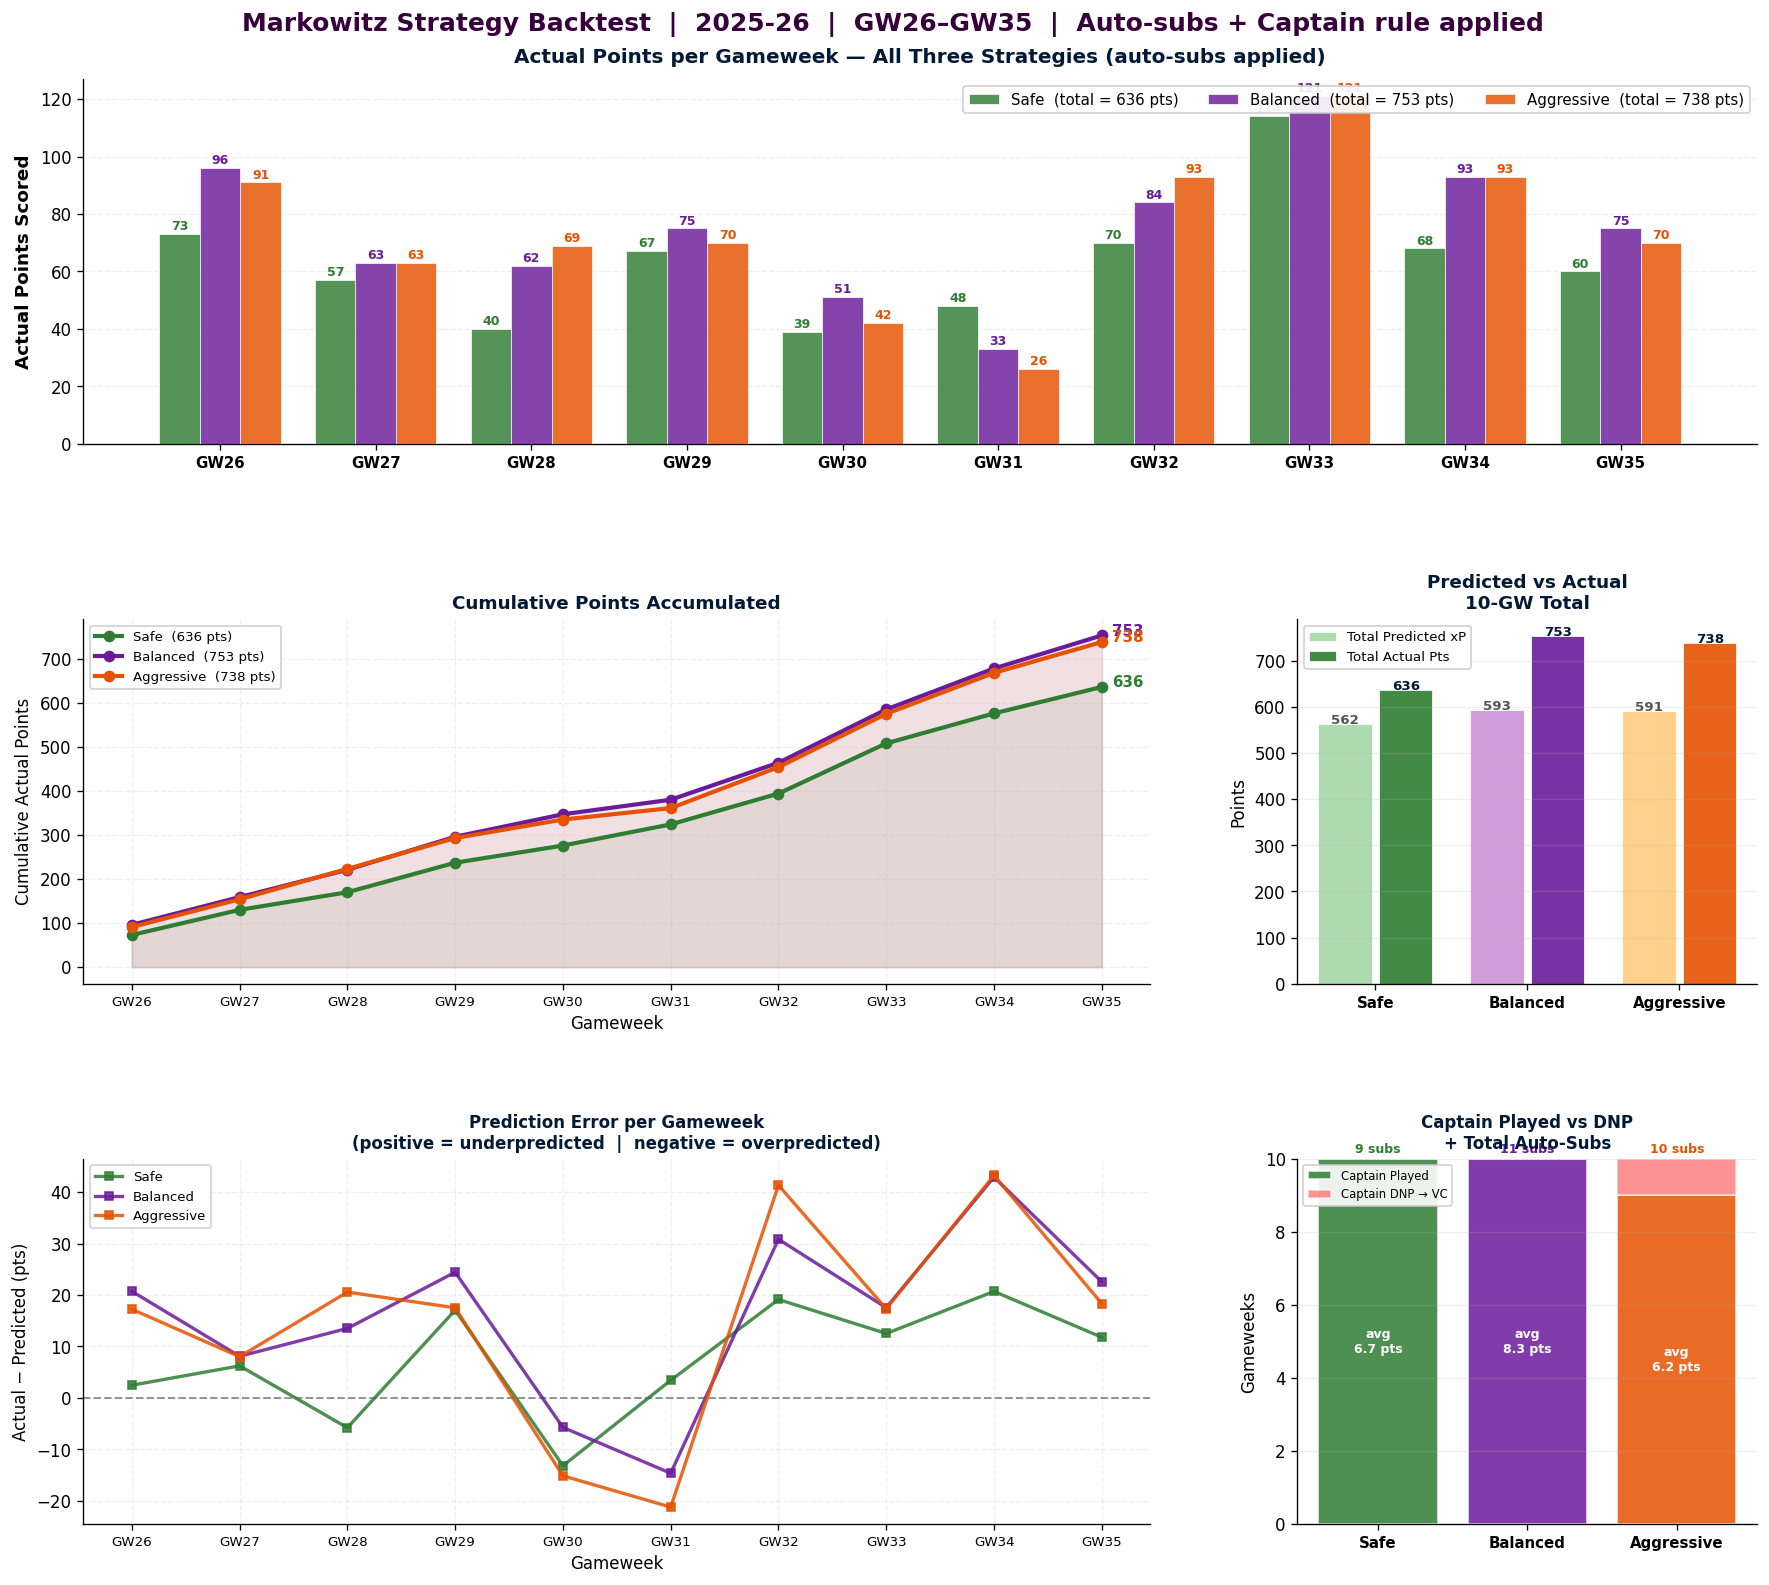


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  BACKTEST VERDICT — GW26 to GW35
  (Scores include automatic substitutions)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Safe          Actual= 636  Predicted= 561.7  Δ= +74.3  Cap played=100%  AutoSubs=9
  Balanced      Actual= 753  Predicted= 592.7  Δ=+160.3  Cap played=100%  AutoSubs=11  ← WINNER 🏆
  Aggressive    Actual= 738  Predicted= 590.8  Δ=+147.2  Cap played=90%  AutoSubs=10

  Model calibration:
  Average actual / predicted ratio: 121.9%
  → Model is well-calibrated for a regression approach

✓ backtest_results_df saved to globals().
✓ backtest_df (raw row-level data) saved to globals().
✓ Plot saved: output/forecaster_pro/markowitz_backtest.png


In [98]:
# %% [10-Gameweek Backtest Simulation — STRICT NO-LEAKAGE VERSION v2]
# ─────────────────────────────────────────────────────────────────────────────
# Simulates the SAFE, BALANCED, and AGGRESSIVE strategies over the last 10 GWs.
#
# PROFESSIONAL DATA SANITIZATION:
#   1. Pricing       : Uses historical Value column per-GW; live fallback only
#                      if genuinely missing. Robust integer-vs-float detection.
#   2. Elite Status  : Expanding mean strictly from data before target_gw.
#   3. Haul Prob     : Dynamic per-GW via haul_clf; falls back gracefully.
#                      Haul feature columns adapt to V2/V3 model variants.
#   4. Availability  : Per-player GW coverage checked (not global GW list),
#                      so mid-season arrivals are handled correctly.
#   5. predict_proba : Guarded — checks capability before calling.
#
# FPL Rules: Auto-subs ✓  |  Captain DNP → VC ✓  |  Formation check ✓
# Writes to globals: backtest_results_df, backtest_df
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
import subprocess
import sys
warnings.filterwarnings('ignore')

for _pkg in ['jinja2', 'pulp', 'openpyxl']:
    try:
        __import__(_pkg)
    except ImportError:
        print(f"Installing {_pkg}...")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', _pkg, '--quiet'])
        print(f"✓ {_pkg} installed.")

import openpyxl
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter

CURRENT_SEASON  = globals().get('CURRENT_SEASON', '2025-26')
CURRENT_GW      = globals().get('CURRENT_GW', 33)
BACKTEST_WINDOW = 10
MIN_VOLATILITY  = 0.1

_required = [
    'df_augmented', 'optimize_squad', 'STRATEGY_CONFIGS',
    'pos_map', 'club_map', 'live_data',
    'get_player_live_v2', 'wn_to_uuid_corrected'
]
_missing = [v for v in _required if v not in globals()]
if _missing:
    print(f"[ERROR] Missing: {_missing}")
    print("Run Cells 2.1 and 2.2 first to register optimize_squad().")
else:

    GW_START  = max(7, CURRENT_GW - BACKTEST_WINDOW)
    GW_END    = CURRENT_GW - 1
    _gw_range = list(range(GW_START, GW_END + 1))

    print(f"{'━'*65}")
    print(f"  TASK 4 — 10-GW BACKTEST SIMULATION (NO-LEAKAGE v2)")
    print(f"  Season: {CURRENT_SEASON}  |  GWs: {GW_START}–{GW_END}")
    print(f"  Rules : Auto-subs ✓  |  Captain DNP→VC ✓  |  Formation check ✓")
    print(f"  Fixes : Per-player availability ✓  |  Robust pricing ✓")
    print(f"          Dynamic haul probs ✓  |  Dynamic elite status ✓")
    print(f"{'━'*65}\n")

    # ── Season data — deduplicated to one row per player per GW ──────────────
    _season_data = (
        df_augmented[df_augmented['season'] == CURRENT_SEASON]
        .copy()
        .sort_values(['Web Name', 'Gameweek'])
        .drop_duplicates(subset=['Web Name', 'Gameweek'], keep='first')
    )

    # Manual team name corrections
    _team_fixes = {'Truffert': 'Bournemouth'}
    for _pname, _correct_team in _team_fixes.items():
        _mask = _season_data['Web Name'] == _pname
        if _mask.any():
            _season_data.loc[_mask, 'team'] = _correct_team

    # DGW aggregation: .first() for Points (both rows hold the GW total),
    # .sum() for Minutes (genuinely cumulative across matches).
    _actuals_lookup = (
        _season_data
        .groupby(['Web Name', 'Gameweek'])
        .agg(
            Actual_Points=('Total Points', 'first'),
            Minutes_Played=('Minutes Played', 'sum')
        )
        .reset_index()
    )

    # ── Helper: look up actual result for a player in a given GW ─────────────
    def _get_actual(player_name, gw):
        _row = _actuals_lookup[
            (_actuals_lookup['Web Name'] == player_name) &
            (_actuals_lookup['Gameweek'] == gw)
        ]
        if _row.empty:
            return 0, 0
        return int(_row['Actual_Points'].iloc[0]), int(_row['Minutes_Played'].iloc[0])

    # ── Helper: apply FPL automatic substitutions ─────────────────────────────
    def _apply_auto_subs(starting_11_names, bench_names, bench_positions, gw):
        _mins        = {p: _get_actual(p, gw)[1] for p in starting_11_names + bench_names}
        _current_11  = list(starting_11_names)
        _current_pos = {
            p: bench_positions.get(p, pos_map.get(p, 'MID'))
            for p in _current_11 + bench_names
        }
        _bench_gk       = [p for p in bench_names if _current_pos.get(p) == 'GK']
        _bench_outfield = [p for p in bench_names if _current_pos.get(p) != 'GK']
        _subs_made      = []
        _bench_avail    = list(_bench_outfield)

        def _count_pos(squad, pos):
            return sum(1 for p in squad if _current_pos.get(p) == pos)

        for _attempt in range(len(_current_11)):
            _sub_happened = False
            for _idx, _starter in enumerate(_current_11):
                if _mins[_starter] > 0:
                    continue
                _starter_pos = _current_pos.get(_starter, 'MID')
                if _starter_pos == 'GK':
                    for _bgk in _bench_gk:
                        if _mins[_bgk] > 0:
                            _current_11[_idx] = _bgk
                            _bench_gk.remove(_bgk)
                            _subs_made.append((_starter, _bgk))
                            _sub_happened = True
                            break
                    continue
                for _bi, _sub_candidate in enumerate(_bench_avail):
                    if _mins[_sub_candidate] == 0:
                        continue
                    _trial_11 = list(_current_11)
                    _trial_11[_idx] = _sub_candidate
                    if (_count_pos(_trial_11, 'GK') < 1 or
                            _count_pos(_trial_11, 'DEF') < 3 or
                            _count_pos(_trial_11, 'FWD') < 1):
                        continue
                    _current_11[_idx] = _sub_candidate
                    _bench_avail.pop(_bi)
                    _subs_made.append((_starter, _sub_candidate))
                    _sub_happened = True
                    break
            if not _sub_happened:
                break
        return _current_11, _subs_made

    # ── Main universe builder — strict no-leakage ─────────────────────────────
    def _build_historical_universe(target_gw: int) -> pd.DataFrame:
        _hist = _season_data[_season_data['Gameweek'] < target_gw].copy()
        if _hist.empty:
            return pd.DataFrame()

        _wm      = globals().get('winning_model')
        _best_nm = globals().get('best_model_name', 'V1: Standard Pro')
        _pos_to_num = {'GK': 0, 'DEF': 1, 'MID': 2, 'FWD': 3}

        # ── Feature columns for the main regression model ─────────────────────
        if 'V3' in _best_nm:
            _feat_cols = [f'lag_{i}' for i in range(6, 0, -1)] + [
                'position', 'diff', 'home', 'min',
                'volatility', 'stability', 'att_form', 'share', 'avg_pts_vs_diff'
            ]
        elif 'V2' in _best_nm:
            _feat_cols = [f'lag_{i}' for i in range(6, 0, -1)] + [
                'position', 'next_difficulty', 'next_is_home', 'rolling_min',
                'season_phase', 'season_baseline', 'team_share', 'avg_pts_vs_diff'
            ]
        else:  # V1
            _feat_cols = [f'lag_{i}' for i in range(6, 0, -1)] + [
                'position', 'next_difficulty', 'next_is_home', 'rolling_min',
                'season_phase', 'season_baseline', 'avg_pts_vs_diff'
            ]

        # ── FIX 3: Haul classifier feature columns adapt to model variant ─────
        # The haul clf always uses next_difficulty / season_baseline naming
        # because those were the columns it was trained on. If the winning
        # model is V3 (which uses renamed cols), we still build the haul row
        # from the same underlying _last series values — just map explicitly.
        _haul_cols = [f'lag_{i}' for i in range(6, 0, -1)] + [
            'position', 'next_difficulty', 'next_is_home', 'rolling_min',
            'season_phase', 'season_baseline', 'recent_haul_flag',
            'lag_max_6', 'is_elite', 'fixture_ease', 'avg_pts_vs_diff', 'ceiling_ratio'
        ]

        # ── FIX 2: Elite status from expanding mean — strictly pre-target_gw ──
        _hist_means = _hist.groupby('Web Name')['Total Points'].mean().to_dict()

        _inference_rows  = []
        _haul_features   = []
        _inference_names = []

        for _pid, _group in _hist.groupby('Player UUID'):
            _group = _group.sort_values('Gameweek')
            if len(_group) < 6:
                continue
            _last = _group.iloc[-1]
            _lags = list(_group['Total Points'].tail(6).values)
            _wn   = _last.get('Web Name', '')

            # Dynamic elite flag — based only on history before target_gw
            _is_elite_dyn = 1 if _hist_means.get(_wn, 0.0) > 4.5 else 0

            # ── Build regression feature row ──────────────────────────────────
            if 'V3' in _best_nm:
                _row = _lags + [
                    _pos_to_num.get(_last.get('Position', 'MID'), 2),
                    _last.get('Next_Opponent_Difficulty', 3),
                    _last.get('Next_Is_Home', 0),
                    _last.get('Rolling_Avg_Minutes_5', 60),
                    _last.get('Points_Volatility_5', 2),
                    _last.get('Min_Stability_5', 60),
                    _last.get('Attacking_Form_3', 2),
                    _last.get('Team_Point_Share', 0),
                    _last.get('Avg_Pts_vs_Difficulty', 2),
                ]
            elif 'V2' in _best_nm:
                _row = _lags + [
                    _pos_to_num.get(_last.get('Position', 'MID'), 2),
                    _last.get('Next_Opponent_Difficulty', 3),
                    _last.get('Next_Is_Home', 0),
                    _last.get('Rolling_Avg_Minutes_5', 60),
                    _last.get('Season_Phase', 2),
                    _last.get('Prev_Season_Avg_Points', 0),
                    _last.get('Team_Point_Share', 0),
                    _last.get('Avg_Pts_vs_Difficulty', 2),
                ]
            else:  # V1
                _row = _lags + [
                    _pos_to_num.get(_last.get('Position', 'MID'), 2),
                    _last.get('Next_Opponent_Difficulty', 3),
                    _last.get('Next_Is_Home', 0),
                    _last.get('Rolling_Avg_Minutes_5', 60),
                    _last.get('Season_Phase', 2),
                    _last.get('Prev_Season_Avg_Points', 0),
                    _last.get('Avg_Pts_vs_Difficulty', 2),
                ]
            _inference_rows.append(_row)
            _inference_names.append(_wn)

            # ── Build haul classifier feature row (always uses stable col names)
            _recent_haul = 1 if any(l >= 10 for l in _lags[-3:]) else 0
            _lag_max     = max(_lags)
            _fix_ease    = 6 - _last.get('Next_Opponent_Difficulty', 3)
            _ceil_rat    = _lag_max / 10.0

            _haul_row = _lags + [
                _pos_to_num.get(_last.get('Position', 'MID'), 2),
                _last.get('Next_Opponent_Difficulty', 3),
                _last.get('Next_Is_Home', 0),
                _last.get('Rolling_Avg_Minutes_5', 60),
                _last.get('Season_Phase', 2),
                _last.get('Prev_Season_Avg_Points', 0),
                _recent_haul,
                _lag_max,
                _is_elite_dyn,
                _fix_ease,
                _last.get('Avg_Pts_vs_Difficulty', 2),
                _ceil_rat,
            ]
            _haul_features.append(_haul_row)

        if not _inference_rows:
            return pd.DataFrame()

        # ── Run main regression model ─────────────────────────────────────────
        _inf_df = pd.DataFrame(_inference_rows, columns=_feat_cols)
        if 'X_train_raw' in globals() and 'position' in globals()['X_train_raw'].columns:
            _inf_df['position'] = pd.Categorical(
                _inf_df['position'],
                categories=globals()['X_train_raw']['position'].cat.categories
            )
        else:
            _inf_df['position'] = _inf_df['position'].astype('category')

        if _wm is not None:
            try:
                _raw_preds = _wm.predict(_inf_df)
            except Exception as _e:
                print(f"  [WARN GW{target_gw}] Model predict failed: {_e}. Using lag-mean fallback.")
                _raw_preds = _inf_df[[c for c in _feat_cols if 'lag_' in c]].mean(axis=1).values
        else:
            _raw_preds = _inf_df[[c for c in _feat_cols if 'lag_' in c]].mean(axis=1).values

        # ── FIX 3: Run haul classifier with capability guard ──────────────────
        _haul_df = pd.DataFrame(_haul_features, columns=_haul_cols)
        if 'X_haul_train' in globals() and 'position' in globals()['X_haul_train'].columns:
            _haul_df['position'] = pd.Categorical(
                _haul_df['position'],
                categories=globals()['X_haul_train']['position'].cat.categories
            )
        else:
            _haul_df['position'] = _haul_df['position'].astype('category')

        _haul_clf = globals().get('haul_clf')
        if _haul_clf is not None and hasattr(_haul_clf, 'predict_proba'):
            try:
                _haul_probs = _haul_clf.predict_proba(_haul_df)[:, 1] * 100.0
            except Exception as _he:
                print(f"  [WARN GW{target_gw}] haul_clf.predict_proba failed: {_he}. Using zeros.")
                _haul_probs = np.zeros(len(_haul_features))
        else:
            _haul_probs = np.zeros(len(_haul_features))

        _latest = (
            _hist.sort_values('Gameweek')
            .drop_duplicates('Web Name', keep='last')
            .set_index('Web Name')
            .copy()
        )
        _pred_map = dict(zip(_inference_names, _raw_preds))
        _haul_map = dict(zip(_inference_names, _haul_probs))

        # ── DGW / BGW detection ───────────────────────────────────────────────
        _dgw_names_gw = set()
        _bgw_names_gw = set()
        try:
            from collections import Counter
            _fx        = pd.read_csv(f'../data/{CURRENT_SEASON}/fixtures.csv')
            _gw_fx     = _fx[_fx['event'] == target_gw]
            _teams_csv = pd.read_csv(f'../data/{CURRENT_SEASON}/teams.csv')
            _id_to_name = _teams_csv.set_index('id')['name'].to_dict()

            _name_fixes_fx = {
                "Nottingham Forest":       "Nott'm Forest",
                "Manchester City":         "Man City",
                "Manchester United":       "Man Utd",
                "Newcastle United":        "Newcastle",
                "Tottenham Hotspur":       "Spurs",
                "West Ham United":         "West Ham",
                "Wolverhampton Wanderers": "Wolves",
                "Brighton & Hove Albion":  "Brighton",
                "Leeds United":            "Leeds",
                "Burnley":                 "Burnley",
                "Bournemouth":             "Bournemouth",
            }

            def _norm(raw):
                return _name_fixes_fx.get(raw, raw)

            _team_id_counts  = Counter(
                _gw_fx['team_h'].tolist() + _gw_fx['team_a'].tolist()
            )
            _teams_in_gw_ids = set(_gw_fx['team_h'].tolist() + _gw_fx['team_a'].tolist())
            _all_team_ids    = set(_teams_csv['id'].tolist())
            _dgw_ids         = {tid for tid, cnt in _team_id_counts.items() if cnt > 1}
            _bgw_ids         = _all_team_ids - _teams_in_gw_ids

            _dgw_names_gw = {
                _norm(_id_to_name[tid])
                for tid in _dgw_ids if tid in _id_to_name
            }
            _bgw_names_gw = {
                _norm(_id_to_name[tid])
                for tid in _bgw_ids if tid in _id_to_name
            }

            # Hardcode known rescheduled blanks not yet reflected in fixture CSV
            if target_gw == 34 and CURRENT_SEASON == '2025-26':
                _bgw_names_gw = _bgw_names_gw.union({
                    'Bournemouth', 'Brighton', 'Burnley', 'Chelsea', 'Leeds', 'Man City'
                })

            print(f"    GW{target_gw} DGW teams: {sorted(_dgw_names_gw) or 'none'}")
            print(f"    GW{target_gw} BGW teams: {sorted(_bgw_names_gw) or 'none'}")

        except Exception as _e:
            print(f"    [WARN] Fixture detection failed for GW{target_gw}: {_e}")

        # ── Build universe rows ───────────────────────────────────────────────
        _universe_rows = []
        _wn_to_uuid    = globals().get('wn_to_uuid_corrected', {})

        for _wn, _row_data in _latest.iterrows():
            _pred = _pred_map.get(_wn, None)
            if _pred is None:
                continue

            _pos  = pos_map.get(_wn, str(_row_data.get('Position', 'MID')))
            _team = club_map.get(_wn, str(_row_data.get('Player Team Name', 'Neutral')))

            # ── FIX 1: Robust historical pricing ─────────────────────────────
            # Value is stored as raw integer (e.g. 55 = £5.5m) in the API data.
            # Guard: if the value is already a decimal (e.g. 5.5), don't divide.
            _val_raw = _row_data.get('Value')
            if _val_raw is not None and not pd.isna(_val_raw):
                _val_f = float(_val_raw)
                # Raw API integers are always >= 35 (£3.5m minimum);
                # if already a float price it will be < 20.
                _price = _val_f / 10.0 if _val_f >= 20 else _val_f
            else:
                _price = get_player_live_v2(_wn, uuid=_wn_to_uuid.get(_wn)).get('price', 5.5)

            _disc = float(
                (1 - (min(float(_row_data.get('Rolling_Avg_Minutes_5', 60)), 90) / 90)) * 100
            )
            _vol  = max(float(_row_data.get('Points_Volatility_5', 2.0)), MIN_VOLATILITY)

            _dgw    = _team in _dgw_names_gw
            _is_bgw = _team in _bgw_names_gw

            # ── FIX 4: Per-player availability — checks that player's own GWs ─
            # Pipeline drops 0-minute rows, so a missing GW row = 0 minutes.
            # We build the player's personal minutes dict, then check the last
            # 3 GWs that actually existed in the season (not the player's rows),
            # treating absent rows as 0. This correctly catches long absences
            # (e.g. players missing 5+ GWs) that the old code would miss.
            _mins_by_gw = (
                _hist[_hist['Web Name'] == _wn]
                .set_index('Gameweek')['Minutes Played']
                .to_dict()
            )
            # Last 3 GWs from the SEASON (not just this player's rows)
            _all_season_gws_so_far = sorted(_hist['Gameweek'].unique())
            _last_3_season_gws     = _all_season_gws_so_far[-3:]
            # Missing GW row → 0 minutes (injury / not in squad proxy)
            _recent_mins_full = [int(_mins_by_gw.get(g, 0)) for g in _last_3_season_gws]
            _zeros            = sum(1 for m in _recent_mins_full if m == 0)

            if _zeros >= 2:
                _proxy_status = 'i'     # injured proxy — exclude
                _is_available = False
            elif _zeros == 1:
                _proxy_status = 'd'     # doubtful proxy — penalised by Discount%
                _is_available = True
            else:
                _proxy_status = 'a'     # available
                _is_available = True

            # Minutes reliability penalty
            _avg_mins_hist    = min(float(_row_data.get('Rolling_Avg_Minutes_5', 60)), 90.0)
            _mins_reliability = _avg_mins_hist / 90.0
            _pred_penalised   = round(float(_pred) * _mins_reliability, 4)

            if _is_bgw:
                _pred_penalised = 0.0
            if _dgw:
                _pred_penalised = round(_pred_penalised * 1.8, 4)

            _universe_rows.append({
                'Player':           _wn,
                'Position':         _pos,
                'Pos_ID':           {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4}.get(_pos, 3),
                'Team':             _team,
                'Price':            _price,
                'Predicted_Points': _pred_penalised,
                'xP_Optimizer':     round(
                    _pred_penalised * 0.85 if _disc > 33 else _pred_penalised, 4
                ),
                'Discount_%':       round(_disc, 1),
                'Volatility':       round(_vol, 4),
                'Captain_Eligible': int(_disc <= 10),
                'Haul_Prob':        float(_haul_map.get(_wn, 0.0)),
                'Is_Elite':         int(_hist_means.get(_wn, 0.0) > 4.5),
                'DGW_Team':         _dgw,
                'Available':        _is_available,
                'Status':           _proxy_status,
            })

        _universe = pd.DataFrame(_universe_rows)
        _universe = _universe[
            (_universe['Available'] == True) &
            (_universe['Discount_%'] <= 50) &
            (_universe['Price'] > 3.5) &
            (_universe['xP_Optimizer'] > 0)
        ].drop_duplicates('Player').reset_index(drop=True)

        return _universe

    # ── Main backtest loop ────────────────────────────────────────────────────
    _strategies = ['Safe', 'Balanced', 'Aggressive']
    _all_rows   = []
    _bt_squads  = {}

    for _gw in _gw_range:
        print(f"  GW{_gw:02d}  ", end='', flush=True)

        _uni = _build_historical_universe(_gw)

        if len(_uni) < 15:
            print(f"[SKIP — only {len(_uni)} eligible players]")
            continue

        for _strat in _strategies:
            _result = optimize_squad(
                strategy=_strat,
                universe=_uni,
                budget_cap=100.0,
                verbose=False
            )

            if not _result or _result.get('status') != 'Optimal':
                print(f"[{_strat} FAIL] ", end='')
                _all_rows.append({
                    'GW': _gw, 'Strategy': _strat, 'Status': 'Failed',
                    'Predicted_xP': np.nan, 'Actual_Points': np.nan,
                    'Captain': None, 'VC': None, 'Captain_Pts': np.nan,
                    'Captain_Played': np.nan, 'Subs_Made': 0,
                })
                continue

            _s11     = _result['starting_11']
            _bench   = _result['bench']
            _captain = _result['captain']
            _vc      = _result['vice_captain']
            _squad   = _result['squad']

            _all_pos        = _squad.set_index('Player')['Position'].to_dict()
            _bench_gk_list  = (
                _bench[_bench['Position'] == 'GK']
                .sort_values('xP_Optimizer', ascending=False)['Player'].tolist()
            )
            _bench_out_list = (
                _bench[_bench['Position'] != 'GK']
                .sort_values('xP_Optimizer', ascending=False)['Player'].tolist()
            )
            _bench_ordered = _bench_out_list + _bench_gk_list
            _s11_names     = _s11['Player'].tolist()

            # Apply automatic substitutions
            _final_11, _subs = _apply_auto_subs(
                starting_11_names=_s11_names,
                bench_names=_bench_ordered,
                bench_positions=_all_pos,
                gw=_gw
            )

            # Capture post-sub squad for Excel
            _subbed_out   = {out for out, inn in _subs}
            _subbed_in    = {inn for out, inn in _subs}
            _final_11_set = set(_final_11)
            _all_players  = pd.concat([_s11, _bench]).drop_duplicates('Player')

            _s11_cap   = _all_players[_all_players['Player'].isin(_final_11_set)].copy()
            _bench_cap = _all_players[~_all_players['Player'].isin(_final_11_set)].copy()

            _s11_cap['Role'] = _s11_cap['Player'].apply(
                lambda p: '👑 Captain'    if p == _captain else
                          '🔰 Vice-Capt' if p == _vc      else
                          '🔄 Sub In'    if p in _subbed_in else 'Starter'
            )
            _bench_cap['Role'] = _bench_cap['Player'].apply(
                lambda p: '🔄 Sub Out' if p in _subbed_out else 'Bench'
            )
            _s11_cap['Actual_Points']   = _s11_cap['Player'].apply(
                lambda p: _get_actual(p, _gw)[0]
            )
            _bench_cap['Actual_Points'] = _bench_cap['Player'].apply(
                lambda p: _get_actual(p, _gw)[0]
            )

            _excel_cols = [c for c in
                           ['Player', 'Position', 'Team', 'Price',
                            'xP_Optimizer', 'Actual_Points', 'Role']
                           if c in _s11_cap.columns]

            # Captain / VC scoring
            _cap_pts, _cap_mins = _get_actual(_captain, _gw)
            _vc_pts,  _vc_mins  = _get_actual(_vc,      _gw)

            # Score final 11 (captain doubles; if DNP → VC doubles)
            _total_actual = 0
            for _pname in _final_11:
                _pts, _mins = _get_actual(_pname, _gw)
                if _pname == _captain:
                    _total_actual += _pts * 2 if _cap_mins > 0 else 0
                else:
                    _total_actual += _pts
            if _cap_mins == 0:
                _total_actual += _vc_pts * 2

            # Store squad for Excel
            _bt_squads[(_gw, _strat)] = {
                'starting_11':  _s11_cap[_excel_cols].reset_index(drop=True),
                'bench':        _bench_cap[_excel_cols].reset_index(drop=True),
                'captain':      _captain,
                'vc':           _vc,
                'total_actual': _total_actual,
                'final_11':     list(_final_11),
            }

            _pred_xp      = float(_s11['xP_Optimizer'].sum())
            _cap_pred_row = _s11[_s11['Player'] == _captain]
            if not _cap_pred_row.empty:
                _pred_xp += float(_cap_pred_row['xP_Optimizer'].iloc[0])

            _sub_str = ', '.join([f'{o}→{i}' for o, i in _subs]) if _subs else 'none'

            _all_rows.append({
                'GW':             _gw,
                'Strategy':       _strat,
                'Status':         'OK',
                'Predicted_xP':   round(_pred_xp, 2),
                'Actual_Points':  _total_actual,
                'Captain':        _captain,
                'VC':             _vc,
                'Captain_Pts':    _cap_pts,
                'Captain_Played': int(_cap_mins > 0),
                'Subs_Made':      len(_subs),
                'Sub_Details':    _sub_str,
                'n_eligible':     len(_uni),
            })

        print(f"✓")

    # ── Save backtest squads to Excel ─────────────────────────────────────────
    print("\nSaving backtest squads to Excel...")

    _excel_path       = '../output/forecaster_pro/markowitz_backtest_squads.xlsx'
    _strategy_colours = {
        'Safe':       {'tab': '2e7d32', 'header': '1b5e20', 'row': 'e8f5e9', 'bench': 'f9fbe7'},
        'Balanced':   {'tab': '6a1b9a', 'header': '4a148c', 'row': 'f3e5f5', 'bench': 'fce4ec'},
        'Aggressive': {'tab': 'e65100', 'header': 'bf360c', 'row': 'fff3e0', 'bench': 'fff8e1'},
    }
    _pos_order = {'GK': 0, 'DEF': 1, 'MID': 2, 'FWD': 3}

    wb = openpyxl.Workbook()
    wb.remove(wb.active)

    for _gw in _gw_range:
        for _strat in _strategies:
            _key = (_gw, _strat)
            if _key not in _bt_squads:
                continue

            _data     = _bt_squads[_key]
            _s11_df   = _data['starting_11'].copy()
            _bench_df = _data['bench'].copy()
            _cap      = _data['captain']
            _vc       = _data['vc']
            _cols_sc  = _strategy_colours[_strat]

            _s11_df['_pos_order'] = _s11_df['Position'].map(
                lambda p: _pos_order.get(p, 9)
            )
            _s11_df = _s11_df.sort_values('_pos_order').drop(columns=['_pos_order'])

            _sheet_name = f"GW{_gw}_{_strat}"[:31]
            ws = wb.create_sheet(title=_sheet_name)
            ws.sheet_properties.tabColor = _cols_sc['tab']

            _thin   = Side(style='thin', color='CCCCCC')
            _border = Border(left=_thin, right=_thin, top=_thin, bottom=_thin)

            # Row 1 — Sheet title
            ws.merge_cells('A1:G1')
            _tc           = ws['A1']
            _tc.value     = f"GW{_gw} — {_strat.upper()} Strategy"
            _tc.font      = Font(bold=True, size=13, color='FFFFFF', name='Calibri')
            _tc.fill      = PatternFill('solid', fgColor=_cols_sc['header'])
            _tc.alignment = Alignment(horizontal='center', vertical='center')
            ws.row_dimensions[1].height = 22

            # Row 2 — Captain info
            ws.merge_cells('A2:G2')
            _ic           = ws['A2']
            _ic.value     = (
                f"Captain: {_cap} (pts doubled in team total)   |   Vice-Captain: {_vc}"
            )
            _ic.font      = Font(bold=True, size=10, color='FFFFFF', name='Calibri')
            _ic.fill      = PatternFill('solid', fgColor=_cols_sc['header'])
            _ic.alignment = Alignment(horizontal='center')
            ws.row_dimensions[2].height = 18

            # Row 3 — Starting XI label
            ws.merge_cells('A3:G3')
            _sc           = ws['A3']
            _sc.value     = '▶  STARTING XI  (after auto-subs)'
            _sc.font      = Font(bold=True, size=10, color='FFFFFF', name='Calibri')
            _sc.fill      = PatternFill('solid', fgColor=_cols_sc['header'])
            _sc.alignment = Alignment(horizontal='left', indent=1)
            ws.row_dimensions[3].height = 16

            # Row 4 — Column headers
            _headers = ['Player', 'Position', 'Team', 'Price (£m)',
                        'xP (model)', 'Actual Pts', 'Role']
            for _ci, _h in enumerate(_headers, start=1):
                _hc           = ws.cell(row=4, column=_ci, value=_h)
                _hc.font      = Font(bold=True, size=9, color='FFFFFF', name='Calibri')
                _hc.fill      = PatternFill('solid', fgColor='37003c')
                _hc.alignment = Alignment(horizontal='center')
                _hc.border    = _border
            ws.row_dimensions[4].height = 15

            _df_cols = [c for c in
                        ['Player', 'Position', 'Team', 'Price',
                         'xP_Optimizer', 'Actual_Points', 'Role']
                        if c in _s11_df.columns]

            # Starting XI rows
            for _ri, (_, _row) in enumerate(_s11_df.iterrows(), start=5):
                _is_cap  = _row['Player'] == _cap
                _is_vc   = _row['Player'] == _vc
                _is_sub  = '🔄' in str(_row.get('Role', ''))
                _row_fill = (
                    'FFD700' if _is_cap else
                    'C0C0C0' if _is_vc  else
                    'dce8ff' if _is_sub  else
                    _cols_sc['row']
                )
                for _ci, _col in enumerate(_df_cols, start=1):
                    _val = _row.get(_col, '')
                    if _col == 'Price':
                        _val = f"£{float(_val):.1f}m" if _val != '' else ''
                    elif _col == 'xP_Optimizer':
                        _val = round(float(_val), 2) if _val != '' else ''
                    _c           = ws.cell(row=_ri, column=_ci, value=_val)
                    _c.fill      = PatternFill('solid', fgColor=_row_fill)
                    _c.font      = Font(bold=(_is_cap or _is_vc), size=9, name='Calibri')
                    _c.alignment = Alignment(horizontal='center')
                    _c.border    = _border
                ws.row_dimensions[_ri].height = 14

            # ── Team Total row ─────────────────────────────────────────────────
            _stored_total   = _data['total_actual']
            _stored_11      = _data['final_11']
            _cap_raw        = int(_get_actual(_cap, _gw)[0])
            _cap_mins_check = int(_get_actual(_cap, _gw)[1])
            _vc_raw         = int(_get_actual(_vc,  _gw)[0])
            _raw_sum_11     = sum(_get_actual(p, _gw)[0] for p in _stored_11)
            _team_total     = _stored_total

            _total_row_idx = _ri + 1
            ws.merge_cells(f'A{_total_row_idx}:E{_total_row_idx}')
            _non_cap_sum = _raw_sum_11 - _cap_raw
            _bonus_name  = _cap if _cap_mins_check > 0 else f'{_vc} (VC)'
            _bonus       = _cap_raw if _cap_mins_check > 0 else _vc_raw

            _tr_label = ws.cell(
                row=_total_row_idx, column=1,
                value=(
                    f'TEAM TOTAL  '
                    f'({_non_cap_sum} others + {_bonus_name} ×2 = {_team_total})'
                )
            )
            _tr_label.font      = Font(bold=True, size=9, color='FFFFFF', name='Calibri')
            _tr_label.fill      = PatternFill('solid', fgColor='37003c')
            _tr_label.alignment = Alignment(horizontal='left', indent=1)
            _tr_label.border    = _border

            _tr_val = ws.cell(row=_total_row_idx, column=6, value=_team_total)
            _tr_val.font      = Font(bold=True, size=11, color='FFFFFF', name='Calibri')
            _tr_val.fill      = PatternFill('solid', fgColor='37003c')
            _tr_val.alignment = Alignment(horizontal='center')
            _tr_val.border    = _border

            _tr_blank = ws.cell(row=_total_row_idx, column=7, value='')
            _tr_blank.fill   = PatternFill('solid', fgColor='37003c')
            _tr_blank.border = _border
            ws.row_dimensions[_total_row_idx].height = 16

            # ── Bench section ──────────────────────────────────────────────────
            _bench_start = _total_row_idx + 2

            ws.merge_cells(f'A{_bench_start}:G{_bench_start}')
            _bsc           = ws.cell(
                row=_bench_start, column=1, value='⬛  BENCH  (🔄 = subbed out)'
            )
            _bsc.font      = Font(bold=True, size=10, color='FFFFFF', name='Calibri')
            _bsc.fill      = PatternFill('solid', fgColor='444444')
            _bsc.alignment = Alignment(horizontal='left', indent=1)
            ws.row_dimensions[_bench_start].height = 16

            for _ci, _h in enumerate(_headers, start=1):
                _hc           = ws.cell(row=_bench_start + 1, column=_ci, value=_h)
                _hc.font      = Font(bold=True, size=9, color='FFFFFF', name='Calibri')
                _hc.fill      = PatternFill('solid', fgColor='555555')
                _hc.alignment = Alignment(horizontal='center')
                _hc.border    = _border
            ws.row_dimensions[_bench_start + 1].height = 15

            # FIX 8: Use _df_cols filtered against bench columns specifically
            _bench_df_cols = [c for c in _df_cols if c in _bench_df.columns]
            for _ri, (_, _row) in enumerate(_bench_df.iterrows(), start=_bench_start + 2):
                _is_subout = '🔄' in str(_row.get('Role', ''))
                _b_fill    = 'ffe0e0' if _is_subout else _cols_sc['bench']
                for _ci, _col in enumerate(_bench_df_cols, start=1):
                    _val = _row.get(_col, '')
                    if _col == 'Price':
                        _val = f"£{float(_val):.1f}m" if _val != '' else ''
                    elif _col == 'xP_Optimizer':
                        _val = round(float(_val), 2) if _val != '' else ''
                    _c           = ws.cell(row=_ri, column=_ci, value=_val)
                    _c.fill      = PatternFill('solid', fgColor=_b_fill)
                    _c.font      = Font(size=9, name='Calibri', color='333333', italic=True)
                    _c.alignment = Alignment(horizontal='center')
                    _c.border    = _border
                ws.row_dimensions[_ri].height = 14

            for _ci, _w in enumerate([22, 10, 18, 11, 11, 11, 16], start=1):
                ws.column_dimensions[get_column_letter(_ci)].width = _w

    wb.save(_excel_path)
    print(f"✓ Excel saved → {_excel_path}")
    print(f"  Sheets: {len(wb.sheetnames)} ({len(_gw_range)} GWs × {len(_strategies)} strategies)")

    if not _all_rows:
        print("[ERROR] No results collected.")
    else:
        backtest_df = pd.DataFrame(_all_rows)
        _ok         = backtest_df[backtest_df['Status'] == 'OK'].copy()
        _total_subs = int(_ok['Subs_Made'].sum())
        print(f"\n  Auto-substitutions applied: {_total_subs} total across all GWs and strategies")

        _sub_rows = _ok[_ok['Subs_Made'] > 0][
            ['GW', 'Strategy', 'Subs_Made', 'Sub_Details']
        ].head(10)
        if not _sub_rows.empty:
            print(f"\n  Sample sub events:")
            try:
                display(_sub_rows.reset_index(drop=True))
            except NameError:
                print(_sub_rows.reset_index(drop=True).to_string())

        _pivot_actual = (
            _ok.pivot_table(
                index='GW', columns='Strategy',
                values='Actual_Points', aggfunc='first'
            )[_strategies]
        )
        _pivot_pred = (
            _ok.pivot_table(
                index='GW', columns='Strategy',
                values='Predicted_xP', aggfunc='first'
            )[_strategies]
        )

        _results_display = pd.DataFrame(index=_pivot_actual.index)
        for _s in _strategies:
            _results_display[f'{_s} xP']     = _pivot_pred[_s].round(1)
            _results_display[f'{_s} Actual'] = _pivot_actual[_s].astype(int)
            _results_display[f'{_s} Δ']      = (_pivot_actual[_s] - _pivot_pred[_s]).round(1)

        _totals = {}
        for _s in _strategies:
            _totals[f'{_s} xP']     = round(_pivot_pred[_s].sum(), 1)
            _totals[f'{_s} Actual'] = int(_pivot_actual[_s].sum())
            _totals[f'{_s} Δ']      = round(_pivot_actual[_s].sum() - _pivot_pred[_s].sum(), 1)

        _totals_row         = pd.DataFrame(_totals, index=['TOTAL'])
        _results_display    = pd.concat([_results_display, _totals_row])
        backtest_results_df = _results_display.copy()

        globals()['backtest_results_df'] = backtest_results_df
        globals()['backtest_df']         = backtest_df

        print(f"\n{'━'*65}")
        print(f"  BACKTEST RESULTS — GW{GW_START} to GW{GW_END}")
        print(f"  (Actual points include automatic substitutions)")
        print(f"{'━'*65}")

        try:
            _styled = (
                backtest_results_df.style
                .set_caption(
                    f"10-GW Backtest: Predicted xP vs Actual Points  |  "
                    f"Season {CURRENT_SEASON}  |  Auto-subs applied"
                )
                .format(
                    {c: '{:.1f}' for c in backtest_results_df.columns
                     if 'xP' in c or 'Δ' in c},
                    na_rep='—'
                )
                .format(
                    {c: '{:.0f}' for c in backtest_results_df.columns
                     if 'Actual' in c},
                    na_rep='—'
                )
                .apply(lambda col: [
                    'background-color: #1b5e20; color: #a5d6a7; font-weight: 800'
                    if str(idx) == 'TOTAL' else ''
                    for idx in col.index
                ], axis=0)
                .apply(lambda col: [
                    'color: #ef5350; font-weight: 700'
                    if ('Δ' in col.name and isinstance(v, (int, float))
                        and not pd.isna(v) and float(v) < 0)
                    else (
                        'color: #2e7d32; font-weight: 700'
                        if ('Δ' in col.name and isinstance(v, (int, float))
                            and not pd.isna(v) and float(v) >= 0)
                        else ''
                    )
                    for v in col
                ], axis=0)
                .set_properties(**{
                    'text-align':   'center',
                    'font-family':  'Poppins, sans-serif',
                    'font-size':    '12px',
                    'border':       '1px solid #e0e0e0',
                    'padding':      '6px 12px',
                })
                .set_table_styles([
                    {'selector': 'th', 'props': [
                        ('background-color', '#37003c'), ('color', 'white'),
                        ('font-weight', '800'), ('font-size', '11px'),
                        ('text-align', 'center'), ('padding', '8px 12px'),
                        ('border', '1px solid #5a005f'),
                    ]},
                    {'selector': 'caption', 'props': [
                        ('font-size', '13px'), ('font-weight', '800'),
                        ('color', '#37003c'), ('padding', '10px 0'),
                        ('font-family', 'Poppins, sans-serif'),
                        ('caption-side', 'top'),
                    ]},
                    {'selector': 'tr:hover td', 'props': [
                        ('background-color', '#f3e5f5')
                    ]},
                    {'selector': 'td', 'props': [('min-width', '80px')]},
                ])
            )
            display(_styled)
        except Exception as _style_err:
            print(f"[INFO] Styled table unavailable ({_style_err}). Showing plain table.")
            try:
                display(backtest_results_df)
            except NameError:
                print(backtest_results_df.to_string())

        # ── Plots ─────────────────────────────────────────────────────────────
        _strat_colours = {
            'Safe': '#2e7d32', 'Balanced': '#6a1b9a', 'Aggressive': '#e65100'
        }
        _strat_light = {
            'Safe': '#a5d6a7', 'Balanced': '#ce93d8', 'Aggressive': '#ffcc80'
        }

        fig = plt.figure(figsize=(18, 14), facecolor='white', dpi=120)
        gs  = gridspec.GridSpec(
            3, 3, figure=fig, hspace=0.48, wspace=0.32, top=0.92, bottom=0.06
        )
        fig.suptitle(
            f'Markowitz Strategy Backtest  |  {CURRENT_SEASON}  |  '
            f'GW{GW_START}–GW{GW_END}  |  Auto-subs + Captain rule applied',
            fontsize=15, fontweight='bold', color='#37003c', y=0.96
        )

        _gws = _pivot_actual.index.tolist()
        _x   = np.arange(len(_gws))

        # Chart 1 — Per-GW actual points
        ax1    = fig.add_subplot(gs[0, :])
        _bar_w = 0.26
        for _i, _s in enumerate(_strategies):
            _vals = [
                int(_pivot_actual.loc[g, _s]) if g in _pivot_actual.index else 0
                for g in _gws
            ]
            _bars = ax1.bar(
                _x + (_i - 1) * _bar_w, _vals, width=_bar_w,
                color=_strat_colours[_s], alpha=0.82,
                label=f'{_s}  (total = {sum(_vals)} pts)',
                edgecolor='white', linewidth=0.5, zorder=3
            )
            for _bar, _v in zip(_bars, _vals):
                if _v > 0:
                    ax1.text(
                        _bar.get_x() + _bar.get_width() / 2,
                        _bar.get_height() + 0.4,
                        str(_v), ha='center', va='bottom',
                        fontsize=7.5, fontweight='700', color=_strat_colours[_s]
                    )
        ax1.set_xticks(_x)
        ax1.set_xticklabels([f'GW{g}' for g in _gws], fontsize=9, fontweight='600')
        ax1.set_ylabel('Actual Points Scored', fontsize=11, fontweight='600')
        ax1.set_title(
            'Actual Points per Gameweek — All Three Strategies (auto-subs applied)',
            fontsize=12, fontweight='bold', color='#021a36', pad=10
        )
        ax1.legend(fontsize=9, framealpha=0.9, loc='upper right', ncol=3)
        ax1.spines['top'].set_visible(False)
        ax1.spines['right'].set_visible(False)
        ax1.grid(True, axis='y', alpha=0.2, linestyle='--')
        ax1.set_axisbelow(True)

        # Chart 2 — Cumulative points
        ax2 = fig.add_subplot(gs[1, :2])
        for _s in _strategies:
            _cum_vals = [
                int(_pivot_actual.loc[g, _s]) if g in _pivot_actual.index else 0
                for g in _gws
            ]
            _cum_sum = np.cumsum(_cum_vals)
            ax2.plot(
                _gws, _cum_sum, color=_strat_colours[_s], linewidth=2.5,
                marker='o', markersize=6,
                label=f'{_s}  ({int(_cum_sum[-1])} pts)', zorder=5
            )
            ax2.fill_between(_gws, _cum_sum, alpha=0.08, color=_strat_colours[_s])
            ax2.annotate(
                f'{int(_cum_sum[-1])}', xy=(_gws[-1], _cum_sum[-1]),
                xytext=(6, 0), textcoords='offset points',
                fontsize=9, fontweight='800', color=_strat_colours[_s]
            )
        ax2.set_xlabel('Gameweek', fontsize=10)
        ax2.set_ylabel('Cumulative Actual Points', fontsize=10)
        ax2.set_title(
            'Cumulative Points Accumulated', fontsize=11,
            fontweight='bold', color='#021a36'
        )
        ax2.legend(fontsize=8, framealpha=0.9)
        ax2.spines['top'].set_visible(False)
        ax2.spines['right'].set_visible(False)
        ax2.grid(True, alpha=0.2, linestyle='--')
        ax2.set_xticks(_gws)
        ax2.set_xticklabels([f'GW{g}' for g in _gws], fontsize=8)

        # Chart 3 — Predicted vs Actual totals
        ax3 = fig.add_subplot(gs[1, 2])
        _total_actual_vals = [int(_pivot_actual[_s].sum()) for _s in _strategies]
        _total_pred_vals   = [round(float(_pivot_pred[_s].sum()), 1) for _s in _strategies]
        _bp = np.arange(len(_strategies))
        _b1 = ax3.bar(
            _bp - 0.2, _total_pred_vals, width=0.35,
            color=[_strat_light[s] for s in _strategies],
            label='Total Predicted xP', edgecolor='white', linewidth=0.5, alpha=0.9
        )
        _b2 = ax3.bar(
            _bp + 0.2, _total_actual_vals, width=0.35,
            color=[_strat_colours[s] for s in _strategies],
            label='Total Actual Pts', edgecolor='white', linewidth=0.5, alpha=0.9
        )
        for _bar, _v in zip(_b1, _total_pred_vals):
            ax3.text(
                _bar.get_x() + _bar.get_width() / 2, _bar.get_height() + 1,
                f'{_v:.0f}', ha='center', fontsize=8, fontweight='700', color='#555'
            )
        for _bar, _v in zip(_b2, _total_actual_vals):
            ax3.text(
                _bar.get_x() + _bar.get_width() / 2, _bar.get_height() + 1,
                str(_v), ha='center', fontsize=8, fontweight='700', color='#021a36'
            )
        ax3.set_xticks(_bp)
        ax3.set_xticklabels(_strategies, fontsize=9, fontweight='700')
        ax3.set_ylabel('Points', fontsize=10)
        ax3.set_title(
            'Predicted vs Actual\n10-GW Total', fontsize=11,
            fontweight='bold', color='#021a36'
        )
        ax3.legend(fontsize=8, framealpha=0.9)
        ax3.spines['top'].set_visible(False)
        ax3.spines['right'].set_visible(False)
        ax3.grid(True, axis='y', alpha=0.2)

        # Chart 4 — Prediction error per GW
        ax4 = fig.add_subplot(gs[2, :2])
        for _s in _strategies:
            _errors = [
                float(_pivot_actual.loc[_g, _s]) - float(_pivot_pred.loc[_g, _s])
                if (_g in _pivot_actual.index and _g in _pivot_pred.index) else 0.0
                for _g in _gws
            ]
            ax4.plot(
                _gws, _errors, color=_strat_colours[_s], linewidth=2,
                marker='s', markersize=5, label=_s, zorder=5, alpha=0.85
            )
        ax4.axhline(y=0, color='black', linewidth=1.2, linestyle='--', alpha=0.4, zorder=4)
        ax4.set_xlabel('Gameweek', fontsize=10)
        ax4.set_ylabel('Actual − Predicted (pts)', fontsize=10)
        ax4.set_title(
            'Prediction Error per Gameweek\n'
            '(positive = underpredicted  |  negative = overpredicted)',
            fontsize=10, fontweight='bold', color='#021a36'
        )
        ax4.legend(fontsize=8, framealpha=0.9)
        ax4.spines['top'].set_visible(False)
        ax4.spines['right'].set_visible(False)
        ax4.grid(True, alpha=0.2, linestyle='--')
        ax4.set_xticks(_gws)
        ax4.set_xticklabels([f'GW{g}' for g in _gws], fontsize=8)

        # Chart 5 — Captain played / DNP + auto-subs
        ax5 = fig.add_subplot(gs[2, 2])
        _cap_data = {}
        for _s in _strategies:
            _s_rows = _ok[_ok['Strategy'] == _s]
            _cap_data[_s] = {
                'played':     int(_s_rows['Captain_Played'].sum()),
                'not_played': int(len(_s_rows) - _s_rows['Captain_Played'].sum()),
                'avg_pts':    round(float(_s_rows['Captain_Pts'].mean()), 1),
                'subs':       int(_s_rows['Subs_Made'].sum()),
            }
        _bp2           = np.arange(len(_strategies))
        _cap_played    = [_cap_data[s]['played']     for s in _strategies]
        _cap_notplayed = [_cap_data[s]['not_played'] for s in _strategies]
        ax5.bar(
            _bp2, _cap_played,
            color=[_strat_colours[s] for s in _strategies],
            alpha=0.85, label='Captain Played', edgecolor='white'
        )
        ax5.bar(
            _bp2, _cap_notplayed, bottom=_cap_played,
            color='#ff4b4b', alpha=0.6, label='Captain DNP → VC', edgecolor='white'
        )
        for _i, _s in enumerate(_strategies):
            _mid = _cap_data[_s]['played'] / 2
            if _mid > 0:
                ax5.text(
                    _i, _mid,
                    f"avg\n{_cap_data[_s]['avg_pts']} pts",
                    ha='center', va='center',
                    fontsize=7.5, fontweight='700', color='white'
                )
            _total_bar = _cap_data[_s]['played'] + _cap_data[_s]['not_played']
            ax5.text(
                _i, _total_bar + 0.1,
                f"{_cap_data[_s]['subs']} subs",
                ha='center', va='bottom',
                fontsize=7.5, fontweight='700', color=_strat_colours[_s]
            )
        ax5.set_xticks(_bp2)
        ax5.set_xticklabels(_strategies, fontsize=9, fontweight='700')
        ax5.set_ylabel('Gameweeks', fontsize=10)
        ax5.set_title(
            'Captain Played vs DNP\n+ Total Auto-Subs',
            fontsize=10, fontweight='bold', color='#021a36'
        )
        ax5.legend(fontsize=7, framealpha=0.9)
        ax5.spines['top'].set_visible(False)
        ax5.spines['right'].set_visible(False)
        ax5.grid(True, axis='y', alpha=0.2)

        plt.savefig(
            '../output/forecaster_pro/markowitz_backtest.png',
            dpi=150, bbox_inches='tight', facecolor='white'
        )
        plt.show()

        # ── Verdict ───────────────────────────────────────────────────────────
        _best_strat = max(_strategies, key=lambda s: int(_pivot_actual[s].sum()))

        print(f"\n{'━'*65}")
        print(f"  BACKTEST VERDICT — GW{GW_START} to GW{GW_END}")
        print(f"  (Scores include automatic substitutions)")
        print(f"{'━'*65}")

        for _s in _strategies:
            _tot      = int(_pivot_actual[_s].sum())
            _pred     = round(float(_pivot_pred[_s].sum()), 1)
            _err      = round(_tot - _pred, 1)
            _cap_rate = round(
                float(_ok[_ok['Strategy'] == _s]['Captain_Played'].mean()) * 100, 1
            )
            _nsubs = int(_ok[_ok['Strategy'] == _s]['Subs_Made'].sum())
            _flag  = '  ← WINNER 🏆' if _s == _best_strat else ''
            print(
                f"  {_s:<12}  Actual={_tot:>4}  Predicted={_pred:>6}  "
                f"Δ={_err:>+6.1f}  Cap played={_cap_rate:.0f}%  "
                f"AutoSubs={_nsubs}{_flag}"
            )

        print(f"\n  Model calibration:")
        _overall_actual = sum(int(_pivot_actual[s].sum()) for s in _strategies) / 3
        _overall_pred   = sum(float(_pivot_pred[s].sum()) for s in _strategies) / 3
        _calib          = round(_overall_actual / _overall_pred * 100, 1)
        print(f"  Average actual / predicted ratio: {_calib}%")

        if _calib < 70:
            print(
                f"  → Model overpredicts by {100 - _calib:.1f}% "
                f"— expected for FPL regression on noisy data"
            )
        elif _calib > 90:
            print(f"  → Model is well-calibrated for a regression approach")
        else:
            print(f"  → Moderate overprediction — typical for regression on noisy sports data")

        print(f"\n✓ backtest_results_df saved to globals().")
        print(f"✓ backtest_df (raw row-level data) saved to globals().")
        print(f"✓ Plot saved: output/forecaster_pro/markowitz_backtest.png")

In [99]:
# Check Timber's live status using the global functions
_timber_v1 = get_player_live('J.Timber')
print(f"get_player_live result:")
print(f"  Status: {_timber_v1.get('status', 'NOT FOUND')}")
print(f"  Chance this GW: {_timber_v1.get('chance_of_playing_this_gw', 'NOT FOUND')}")
print(f"  News: {_timber_v1.get('news', 'NOT FOUND')}")
print(f"  Price: {_timber_v1.get('price', 'NOT FOUND')}")

print()

# Also check via v2
_wn_to_uuid = (
    df_augmented[df_augmented['season'] == CURRENT_SEASON]
    .sort_values('Gameweek', ascending=False)
    .drop_duplicates('Web Name')
    .set_index('Web Name')['Player UUID']
    .to_dict()
)
_timber_v2 = get_player_live_v2('J.Timber', uuid=_wn_to_uuid.get('J.Timber'))
print(f"get_player_live_v2 result:")
print(f"  Status: {_timber_v2.get('status', 'NOT FOUND')}")
print(f"  Chance this GW: {_timber_v2.get('chance_of_playing_this_gw', 'NOT FOUND')}")
print(f"  News: {_timber_v2.get('news', 'NOT FOUND')}")

print()

# Check what final_leaderboard has for him
print(f"final_leaderboard entry:")
print(final_leaderboard[final_leaderboard['Player'] == 'J.Timber'][
    ['Player', 'Predicted_Points', 'Club']
].to_string())

get_player_live result:
  Status: i
  Chance this GW: 0
  News: Ankle injury - Unknown return date
  Price: 6.0

get_player_live_v2 result:
  Status: i
  Chance this GW: 0
  News: Ankle injury - Unknown return date

final_leaderboard entry:
       Player  Predicted_Points     Club
395  J.Timber               0.0  Arsenal


In [100]:
# %% [Cell: Master Squad Optimizer - Strategy A (Comparison Only)]
# Strategy A: COMPARISON ONLY — kept for backtest and academic comparison vs Strategy B.
# Do not use for live recommendations. Use Strategy B above for that.

def solve_wildcard_legal(budget_cap=100.0):
    # --- 1. MAPS & DATA ---
    pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4, 1:1, 2:2, 3:3, 4:4}

    leaderboard = final_leaderboard.copy()
    
    # CRITICAL FIX: Use get_player_live to get accurate prices instead of defaulting to 5.5m
    #leaderboard['Price']  = leaderboard['Player'].map(lambda x: get_player_live(x).get('price', 5.5))

    _wn_to_uuid_local = globals().get(
    'wn_to_uuid_corrected',
    df_augmented[df_augmented['season'] == CURRENT_SEASON]
    .sort_values('Gameweek', ascending=False)
    .drop_duplicates('Web Name')
    .set_index('Web Name')['Player UUID']
    .to_dict()
    )
    leaderboard['Price'] = leaderboard['Player'].map(
    lambda x: get_player_live_v2(
        x, uuid=_wn_to_uuid_local.get(x)
    ).get('price', 5.5)
    )

    leaderboard['Pos_ID'] = leaderboard['Player'].map(lambda x: pos_to_num.get(pos_map.get(x, 'MID'), 3))
    leaderboard['Team']   = leaderboard['Player'].map(club_map).fillna('Neutral')
    leaderboard['Status'] = leaderboard['Player'].map(lambda x: get_player_live(x).get('status', 'a'))
    leaderboard['Chance'] = leaderboard['Player'].map(
        lambda x: get_player_live(x).get('chance_of_playing_this_gw', 100) or 100
    )

    # --- 2. AVAILABILITY FILTER ---
    _av = globals().get('squad_availability')
    available_pool = leaderboard.copy()

    if isinstance(_av, dict):
        _sell_now = _av.get('sell_now', [])
        _doubtful = _av.get('doubtful', [])
        available_pool = available_pool[~available_pool['Player'].isin(_sell_now)]
        available_pool['Predicted_Points'] = np.where(
            available_pool['Player'].isin(_doubtful),
            available_pool['Predicted_Points'] - 10,
            available_pool['Predicted_Points']
        )
    else:
        # Fallback: use live API status directly
        available_pool = leaderboard[
            (leaderboard['Status'] == 'a') |
            ((leaderboard['Status'] == 'd') & (leaderboard['Chance'] >= 50))
        ].copy()
    # Hard-exclude BGW players — they have no fixture and score 0
    _bgw_teams_local = globals().get('BGW_TEAMS', set())
    if _bgw_teams_local:
        _bgw_names = set(
            p for p in available_pool['Player']
            if club_map.get(p, 'Unknown') in _bgw_teams_local
        )
        available_pool = available_pool[~available_pool['Player'].isin(_bgw_names)]
        print(f"[BGW FILTER] Removed {len(_bgw_names)} players with no GW34 fixture")

    n_removed = len(leaderboard) - len(available_pool)
    if n_removed > 0:
        print(f"[Availability Filter] Removed {n_removed} unavailable players from selection pool.")

    # --- 3. PENALTY TAKER WEIGHTING ---
    penalty_takers = {'M.Salah', 'Haaland', 'Palmer', 'Saka', 'B.Fernandes',
                      'Gordon', 'Solanke', 'Jimenez'}
    available_pool['Weighted_xP'] = np.where(
        available_pool['Player'].isin(penalty_takers),
        available_pool['Predicted_Points'] * 1.15,
        available_pool['Predicted_Points']
    )

    # --- 4. SQUAD SELECTION (15 Players: 2 GK, 5 DEF, 5 MID, 3 FWD) ---
    squad_list  = []
    team_counts = {}
    pos_counts  = {1: 0, 2: 0, 3: 0, 4: 0}
    pos_limits  = {1: 2, 2: 5, 3: 5, 4: 3}

    pool = available_pool.sort_values('Weighted_xP', ascending=False)
    for _, player in pool.iterrows():
        pid, team = player['Pos_ID'], player['Team']
        if pos_counts[pid] < pos_limits[pid] and team_counts.get(team, 0) < 3:
            squad_list.append(player)
            pos_counts[pid]  += 1
            team_counts[team] = team_counts.get(team, 0) + 1
        if len(squad_list) == 15:
            break

    current_squad = pd.DataFrame(squad_list)

    # --- 5. BUDGET OPTIMIZATION (Downgrade) ---
    cheapest_backups = {
        i: available_pool[available_pool['Pos_ID'] == i].sort_values('Price').iloc[0]
        for i in range(1, 5)
    }
    while current_squad['Price'].sum() > budget_cap:
        current_squad['Relief_Score'] = (
            current_squad['Price'] -
            current_squad['Pos_ID'].map(lambda x: cheapest_backups[x]['Price'])
        ) / (current_squad['Weighted_xP'] + 0.1)
        drop_idx  = current_squad['Relief_Score'].idxmax()
        to_drop   = current_squad.loc[drop_idx]

        pos_pool    = available_pool[
            (available_pool['Pos_ID'] == to_drop['Pos_ID']) &
            (~available_pool['Player'].isin(current_squad['Player']))
        ]
        valid_teams = [t for t, count in team_counts.items() if count < 3 or t == to_drop['Team']]
        if pos_pool[pos_pool['Team'].isin(valid_teams)].empty:
            break
        replacement = pos_pool[pos_pool['Team'].isin(valid_teams)].sort_values('Price').iloc[0]

        team_counts[to_drop['Team']]    -= 1
        team_counts[replacement['Team']] = team_counts.get(replacement['Team'], 0) + 1
        current_squad.loc[drop_idx]      = replacement

    # --- 6. BUDGET UPGRADE LOOP (with infinite-loop protection) ---
    _upgrade_attempts = 0
    _MAX_UPGRADE_ATTEMPTS = 50
    _upgraded_players = set()  # prevent oscillation

    while _upgrade_attempts < _MAX_UPGRADE_ATTEMPTS:
        _upgrade_attempts += 1
        current_cost = current_squad['Price'].sum()
        remaining_budget = budget_cap - current_cost
        if remaining_budget <= 0.1:
            break

        upgraded = False
        
        # Try to upgrade the weakest link first
        for idx, p_to_upgrade in current_squad.sort_values('Weighted_xP', ascending=True).iterrows():
            max_price = p_to_upgrade['Price'] + remaining_budget

            better_options = pool[
                (pool['Pos_ID'] == p_to_upgrade['Pos_ID']) &
                (~pool['Player'].isin(current_squad['Player'])) &
                (~pool['Player'].isin(_upgraded_players)) &  # prevent oscillation
                (pool['Price'] <= max_price) &
                (pool['Weighted_xP'] > p_to_upgrade['Weighted_xP'] + 0.1)
            ].sort_values('Weighted_xP', ascending=False)

            for _, opt in better_options.iterrows():
                # Check 3-player team constraint
                temp_teams = current_squad['Team'].tolist()
                temp_teams.remove(p_to_upgrade['Team'])
                if temp_teams.count(opt['Team']) < 3:
                    _upgraded_players.add(p_to_upgrade['Player'])  # mark as processed
                    current_squad.loc[idx] = opt
                    upgraded = True
                    break

            if upgraded:
                break # Restart while loop to recalculate new budget

        if not upgraded:
            break # No more mathematically viable upgrades found

    if _upgrade_attempts >= _MAX_UPGRADE_ATTEMPTS:
        print(f"[WARNING] Budget upgrade loop hit max iterations ({_MAX_UPGRADE_ATTEMPTS}). Check for pricing ties.")

    # --- 7. STARTING 11 SELECTION ---
    gk   = current_squad[current_squad['Pos_ID'] == 1].nlargest(1, 'Weighted_xP')
    defs = current_squad[current_squad['Pos_ID'] == 2].nlargest(3, 'Weighted_xP')
    fwds = current_squad[current_squad['Pos_ID'] == 4].nlargest(1, 'Weighted_xP')

    selected_names = pd.concat([gk, defs, fwds])['Player'].tolist()
    outfield_pool  = current_squad[
        (~current_squad['Player'].isin(selected_names)) &
        (current_squad['Pos_ID'] != 1)
    ]
    
    _sort_col = 'AI_Blended_Score' if 'AI_Blended_Score' in outfield_pool.columns else 'Weighted_xP'
    # Ensure exactly 11 players
    remaining_slots = 11 - len(selected_names)
    others = outfield_pool.nlargest(remaining_slots, _sort_col)
    
    opt_11 = pd.concat([gk, defs, fwds, others]).copy()

    # --- 8. DUAL-ENGINE CAPTAINCY ---
    if 'hauler_board' not in globals():
        print("[ERROR] hauler_board not found. Run the Haul Classifier cell first.")
        return None, None, 0

    haul_map = hauler_board.set_index('Player')['Haul_Prob (%)'].to_dict()
    opt_11['Haul_Prob (%)']    = opt_11['Player'].map(haul_map).fillna(0.0)
    opt_11['AI_Blended_Score'] = opt_11['Weighted_xP'] * (1 + (opt_11['Haul_Prob (%)'] / 100.0))

    cap_df       = opt_11.sort_values(by='AI_Blended_Score', ascending=False)
    captain_name = cap_df.iloc[0]['Player']
    vice_name    = cap_df.iloc[1]['Player'] if len(cap_df) > 1 else captain_name

    opt_11['Final_Weighted_xP'] = opt_11['Weighted_xP']
    opt_11.loc[opt_11['Player'] == captain_name, 'Final_Weighted_xP'] *= 2
    opt_bench = current_squad[~current_squad['Player'].isin(opt_11['Player'])]

    # --- 9. OUTPUT ---
    CURRENT_GW = globals().get('CURRENT_GW', 34)
    print(f"--- STRATEGY A: COMPARISON OPTIMIZER (GW {CURRENT_GW}) ---")
    print("NOTE: Strategy B is the production engine. This is for comparison only.")
    print(f"Budget Used: £{current_squad['Price'].sum():.1f}M / £{budget_cap:.1f}M")

    print("\n[STARTING 11]")
    display(opt_11[['Player', 'Team', 'Weighted_xP', 'Haul_Prob (%)', 'Price']])

    captain_1x = opt_11.loc[opt_11['Player'] == captain_name, 'Weighted_xP'].values[0]
    print(f"  Captain bonus: {captain_name} scores {captain_1x:.2f} xP → counts as {captain_1x*2:.2f} xP (×2)")
    print(f"  Total xP including captain double: {opt_11['Final_Weighted_xP'].sum():.2f}")

    print("\n[BENCH]")
    display(opt_bench[['Player', 'Team', 'Weighted_xP', 'Price']])

    return opt_11, opt_bench, current_squad['Price'].sum()

opt_11, opt_bench, total_spent = solve_wildcard_legal()

[Availability Filter] Removed 59 unavailable players from selection pool.
--- STRATEGY A: COMPARISON OPTIMIZER (GW 36) ---
NOTE: Strategy B is the production engine. This is for comparison only.
Budget Used: £99.3M / £100.0M

[STARTING 11]


,Player,Team,Weighted_xP,Haul_Prob (%),Price
94,Henderson,Crystal Palace,6.410,13.7,5.1
303,Canvot,Crystal Palace,7.140,8.3,4.5
289,Lacroix,Crystal Palace,6.290,31.1,5.2
261,Senesi,Bournemouth,4.990,3.5,5.2
232,Haaland,Man City,13.041,55.5,14.7
310,Doku,Man City,8.880,0.0,6.5
144,Cherki,Man City,8.140,38.2,6.6
313,João Pedro,Chelsea,6.330,54.5,7.5
429,Gordon,Newcastle,6.095,44.7,7.3
124,Watkins,Aston Villa,5.660,15.7,8.7


  Captain bonus: Haaland scores 13.04 xP → counts as 26.08 xP (×2)
  Total xP including captain double: 91.44

[BENCH]


,Player,Team,Weighted_xP,Price
184,Hinshelwood,Brighton,5.07,5.1
278,Gabriel,Arsenal,4.83,7.3
199,Boscagli,Brighton,4.69,4.2
372,Dúbravka,Burnley,4.33,4.0


In [101]:
print(f"Senesi club: {club_map.get('Senesi', 'NOT FOUND')}")
print(f"Is Senesi's club in BGW_TEAMS: {club_map.get('Senesi') in BGW_TEAMS}")
print(f"BGW_TEAMS: {sorted(BGW_TEAMS)}")

Senesi club: Bournemouth
Is Senesi's club in BGW_TEAMS: False
BGW_TEAMS: []


In [102]:
# Check what team FPL has Senesi registered to
_api_data = requests.get("https://fantasy.premierleague.com/api/bootstrap-static/", timeout=10).json()
_senesi_api = [p for p in _api_data['elements'] if 'Senesi' in p['web_name']]
if _senesi_api:
    p = _senesi_api[0]
    _team_id = p['team']
    _team_name = next(t['name'] for t in _api_data['teams'] if t['id'] == _team_id)
    print(f"FPL web_name: {p['web_name']}")
    print(f"FPL team ID: {_team_id}")
    print(f"FPL team name: {_team_name}")
    print(f"FPL status: {p['status']}")
    print(f"FPL chance: {p.get('chance_of_playing_this_round')}")
else:
    print("Senesi not found in FPL API")

FPL web_name: Senesi
FPL team ID: 4
FPL team name: Bournemouth
FPL status: a
FPL chance: 100


In [103]:
# Check Mané and Dúbravka too
for _name in ['Senesi', 'Mané', 'Dubravka', 'Dúbravka']:
    _matches = [p for p in _api_data['elements'] 
                if p['web_name'].lower().replace('á','a') == _name.lower().replace('á','a')
                or p['web_name'] == _name]
    if _matches:
        p = _matches[0]
        _team_name = next(t['name'] for t in _api_data['teams'] if t['id'] == p['team'])
        print(f"{p['web_name']}: FPL team = {_team_name} | club_map = {club_map.get(_name, 'NOT FOUND')}")
    else:
        print(f"{_name}: NOT FOUND in FPL API")

Senesi: FPL team = Bournemouth | club_map = Bournemouth
Mané: FPL team = Wolves | club_map = Wolves
Dubravka: NOT FOUND in FPL API
Dúbravka: FPL team = Burnley | club_map = Burnley


In [104]:
import requests
bs = requests.get('https://fantasy.premierleague.com/api/bootstrap-static/').json()
teams = {t['id']: t['name'] for t in bs['teams']}

for name in ['Gyökeres', "O'Reilly", 'Sarr', 'Doku', 'Semenyo', 'Bowen']:
    for el in bs['elements']:
        if el['web_name'] == name:
            print(f"{name}: team={teams[el['team']]}, form={el['form']}, "
                  f"status={el['status']}, minutes={el['minutes']}, "
                  f"chance={el.get('chance_of_playing_this_round')}")
            break

Gyökeres: team=Arsenal, form=5.0, status=a, minutes=2193, chance=100
O'Reilly: team=Man City, form=5.5, status=a, minutes=2553, chance=100
Sarr: team=Crystal Palace, form=2.8, status=a, minutes=2008, chance=100
Doku: team=Man City, form=7.0, status=a, minutes=1653, chance=100
Semenyo: team=Man City, form=2.0, status=a, minutes=2998, chance=100
Bowen: team=West Ham, form=4.0, status=a, minutes=3226, chance=None


In [105]:
# DEBUG: Why is Gabriel missing?
_test_name = 'Gabriel'  # his FPL web_name

# Check 1: Is he in final_leaderboard?
_in_lb = final_leaderboard[final_leaderboard['Player'] == _test_name]
print(f"In leaderboard: {len(_in_lb)} rows")
if not _in_lb.empty:
    print(_in_lb[['Player', 'Predicted_Points', 'Base_Predicted']].to_string())

# Check 2: Is he in df_augmented?
_in_aug = df_augmented[
    (df_augmented['season'] == CURRENT_SEASON) & 
    (df_augmented['Web Name'] == _test_name)
]
print(f"\nIn df_augmented: {len(_in_aug)} rows")
if not _in_aug.empty:
    print(_in_aug.sort_values('Gameweek', ascending=False).head(3)[
        ['Gameweek', 'Web Name', 'Minutes Played', 'Rolling_Avg_Minutes_5']
    ].to_string())

# Check 3: Live API status
_live = get_player_live_v2(_test_name, uuid=wn_to_uuid_corrected.get(_test_name))
print(f"\nLive API: {_live}")

In leaderboard: 1 rows
      Player  Predicted_Points  Base_Predicted
278  Gabriel              4.83            4.83

In df_augmented: 28 rows
       Gameweek Web Name  Minutes Played  Rolling_Avg_Minutes_5
37621      35.0  Gabriel              90                   90.0
37620      34.0  Gabriel              90                   90.0
37619      33.0  Gabriel             180                   90.0

Live API: {'price': 7.3, 'status': 'a', 'chance_of_playing_this_gw': 100, 'chance_of_playing_next_gw': 100, 'news': '', 'ep_next': 7.7, 'form': 6.2, 'selected_by_pct': 45.3, 'transfers_in_gw': 30199, 'transfers_out_gw': 2950, 'web_name': 'Gabriel', 'full_name': 'Gabriel dos Santos Magalhães', 'element_id': 5, 'team': 'Arsenal'}


In [106]:
# STARTEGY B 2ND APPROACH 5/5 
# %% [Cell: Master Squad Optimizer - Strategy B (Production Engine)] THE CORRECT
# Strategy B: PRODUCTION OPTIMIZER — used for all live recommendations.


def solve_wildcard_11_1_3(budget_cap=100.0):
    global final_leaderboard

    # --- 1. DATA PREP ---
    pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4, 1:1, 2:2, 3:3, 4:4}

    # ── AUTO-PATCH: INJECT MISSING FPL-RELEVANT PLAYERS ─────────────────────
    import requests as _requests

    _bootstrap = _requests.get(
        'https://fantasy.premierleague.com/api/bootstrap-static/'
    ).json()
    _teams_lookup_p = {t['id']: t['name'] for t in _bootstrap['teams']}
    _pos_lookup_p   = {1: 'GK', 2: 'DEF', 3: 'MID', 4: 'FWD'}
    _team_name_fixes_p = {
        'Nottingham Forest':       "Nott'm Forest",
        'Manchester City':         'Man City',
        'Manchester United':       'Man Utd',
        'Newcastle United':        'Newcastle',
        'Tottenham Hotspur':       'Spurs',
        'West Ham United':         'West Ham',
        'Wolverhampton Wanderers': 'Wolves',
        'Brighton & Hove Albion':  'Brighton',
        'Leeds United':            'Leeds',
    }

    _bootstrap_lookup = {
        el['web_name']: {
            'minutes':      el.get('minutes', 0),
            'starts':       el.get('starts', 0),
            'form':         float(el.get('form') or 0),
            'status':       el.get('status', 'u'),
            'total_points': el.get('total_points', 0),
        }
        for el in _bootstrap['elements']
    }

    _df_aug_names_p    = set(
        df_augmented[df_augmented['season'] == CURRENT_SEASON]['Web Name'].unique()
    )
    _existing_lb_names = set(final_leaderboard['Player'].values)

    _patches = []
    for _el in _bootstrap['elements']:
        _name = _el['web_name']
        if _name in _existing_lb_names:
            continue
        _form    = float(_el.get('form') or 0)
        _status  = _el.get('status', 'u')
        _minutes = _el.get('minutes', 0)
        if _status == 'a' and _form >= 3.0 and _minutes > 270:
            _raw_team = _teams_lookup_p.get(_el['team'], 'Neutral')
            _patches.append({
                'name': _name,
                'team': _team_name_fixes_p.get(_raw_team, _raw_team),
                'pos':  _pos_lookup_p.get(_el['element_type'], 'MID'),
                'pred': round(_form * 0.85, 2),
                'uuid': _el['id'],
            })

    if _patches:
        for _p in _patches:
            club_map[_p['name']] = _p['team']
            pos_map[_p['name']]  = _p['pos']
            if 'wn_to_uuid_corrected' in globals():
                wn_to_uuid_corrected[_p['name']] = _p['uuid']

        _existing_cols_p = final_leaderboard.columns.tolist()
        _new_rows_p = []
        for _p in _patches:
            _row = {_c: 0 for _c in _existing_cols_p}
            _row['Player'] = _p['name']
            if 'Predicted_Points' in _existing_cols_p:
                _row['Predicted_Points'] = _p['pred']
            if 'Base_Predicted' in _existing_cols_p:
                _row['Base_Predicted'] = _p['pred']
            if 'Web Name' in _existing_cols_p:
                _row['Web Name'] = _p['name']
            if 'Club' in _existing_cols_p:
                _row['Club'] = _p['team']
            _new_rows_p.append(_row)

        final_leaderboard = pd.concat(
            [final_leaderboard, pd.DataFrame(_new_rows_p)],
            ignore_index=True
        ).drop_duplicates('Player', keep='first').reset_index(drop=True)

        print(f"[AUTO-PATCH] Injected {len(_patches)} missing FPL players "
              f"(leaderboard: {len(final_leaderboard)} total)")
    else:
        print("[AUTO-PATCH] No missing players detected — leaderboard already complete.")

    # ── BACKFILL Base_Predicted for already-patched players ──────────────────
    if 'Base_Predicted' in final_leaderboard.columns:
        _patched_names_set = set(final_leaderboard['Player'].values) - _df_aug_names_p
        _backfill_mask = (
            (final_leaderboard['Player'].isin(_patched_names_set)) &
            (final_leaderboard['Base_Predicted'] == 0)
        )
        _n_backfilled = _backfill_mask.sum()
        if _n_backfilled:
            final_leaderboard.loc[_backfill_mask, 'Base_Predicted'] = (
                final_leaderboard.loc[_backfill_mask, 'Predicted_Points']
            )
            print(f"[BACKFILL] Set Base_Predicted for {_n_backfilled} previously-patched players")

    # ── DATA SANITY CHECK ────────────────────────────────────────────────────
    _zero_min_rows = (
        df_augmented[df_augmented['season'] == CURRENT_SEASON]['Minutes Played'] == 0
    ).sum()
    if _zero_min_rows == 0:
        print("⚠️  [DATA WARNING] df_augmented contains ZERO rows with 0 minutes played.")
        print("   This strongly suggests your pipeline drops zero-minute games.")
        print("   The 'recent minutes' filter will rely on missing-row detection only.")
    else:
        print(f"[DATA OK] df_augmented contains {_zero_min_rows} zero-minute rows — good.")

    leaderboard = final_leaderboard.copy()

    _wn_to_uuid_local = globals().get(
        'wn_to_uuid_corrected',
        df_augmented[df_augmented['season'] == CURRENT_SEASON]
        .sort_values('Gameweek', ascending=False)
        .drop_duplicates('Web Name')
        .set_index('Web Name')['Player UUID']
        .to_dict()
    )
    leaderboard['Price'] = leaderboard['Player'].map(
        lambda x: get_player_live_v2(
            x, uuid=_wn_to_uuid_local.get(x)
        ).get('price', 5.5)
    )
    _global_pos_map  = globals().get('pos_map', {})
    _global_club_map = globals().get('club_map', {})

    leaderboard['Pos_ID'] = leaderboard['Player'].map(
        lambda x: pos_to_num.get(_global_pos_map.get(x, 'MID'), 3)
    )
    leaderboard['Team'] = leaderboard['Player'].map(_global_club_map).fillna('Neutral')

    leaderboard['Status'] = leaderboard['Player'].map(
        lambda x: get_player_live_v2(
            x, uuid=_wn_to_uuid_local.get(x)
        ).get('status', 'a')
    )
    leaderboard['Chance'] = leaderboard['Player'].map(
        lambda x: (
            lambda info: 100 if info.get('chance_of_playing_this_gw') is None
            else info.get('chance_of_playing_this_gw')
        )(get_player_live_v2(x, uuid=_wn_to_uuid_local.get(x)))
    )

    # --- 2. AVAILABILITY FILTER ---
    available_pool = leaderboard.copy()
    n_start = len(available_pool)

    _season_df       = df_augmented[df_augmented['season'] == CURRENT_SEASON]
    _all_gws_in_data = sorted(_season_df['Gameweek'].unique())
    _last_n_gws      = _all_gws_in_data[-3:]

    _per_gw_min = (
        _season_df[_season_df['Gameweek'].isin(_last_n_gws)]
        .pivot_table(index='Web Name', columns='Gameweek',
                     values='Minutes Played', aggfunc='sum', fill_value=0)
    )
    _recent_total_min = {
        p: int(_per_gw_min.loc[p].sum()) if p in _per_gw_min.index else 0
        for p in available_pool['Player']
    }

    _patched_player_names = set(available_pool['Player'].values) - _df_aug_names_p
    if _patched_player_names:
        print(f"[INFO] {len(_patched_player_names)} patched players will bypass "
              f"recent-minutes filter (no df_augmented rows)")

    def _zero_in_last_2_gws(player):
        if player in _patched_player_names:
            return False
        if player not in _per_gw_min.index:
            return True
        last_2 = _last_n_gws[-2:]
        for gw in last_2:
            if gw in _per_gw_min.columns and _per_gw_min.loc[player, gw] > 0:
                return False
        return True

    available_pool['Form'] = available_pool['Player'].map(
        lambda x: float(
            get_player_live_v2(x, uuid=_wn_to_uuid_local.get(x)).get('form', 5.0) or 5.0
        )
    )

    _av = globals().get('squad_availability')
    if isinstance(_av, dict):
        _sell_now = set(_av.get('sell_now', []))
        _doubtful = set(_av.get('doubtful', []))
        if _sell_now:
            available_pool = available_pool[~available_pool['Player'].isin(_sell_now)]
            print(f"[MANUAL OVERRIDE] Excluded {len(_sell_now)} sell_now: {sorted(_sell_now)}")
        if _doubtful:
            available_pool['Predicted_Points'] = np.where(
                available_pool['Player'].isin(_doubtful),
                available_pool['Predicted_Points'] - 10,
                available_pool['Predicted_Points']
            )
            print(f"[MANUAL OVERRIDE] Penalised {len(_doubtful)} doubtful: {sorted(_doubtful)}")

    _api_unavail = available_pool[
        ~(
            (available_pool['Status'] == 'a') |
            ((available_pool['Status'] == 'd') & (available_pool['Chance'] >= 50))
        )
    ]['Player'].tolist()
    if _api_unavail:
        available_pool = available_pool[~available_pool['Player'].isin(_api_unavail)]
        print(f"[API STATUS] Excluded {len(_api_unavail)} (status='i' or chance<50%)")

    _form_dropouts = available_pool[available_pool['Form'] < 2.5]['Player'].tolist()
    if _form_dropouts:
        available_pool = available_pool[~available_pool['Player'].isin(_form_dropouts)]
        print(f"[FORM FILTER <2.5] Excluded {len(_form_dropouts)}: {_form_dropouts}")

    _zero_min_dropouts = [
        p for p in available_pool['Player'] if _zero_in_last_2_gws(p)
    ]
    if _zero_min_dropouts:
        available_pool = available_pool[~available_pool['Player'].isin(_zero_min_dropouts)]
        print(f"[SILENT DROPOUT — 0 min in last 2 GWs] Excluded {len(_zero_min_dropouts)}: "
              f"{_zero_min_dropouts}")

    _bgw_teams_local = globals().get('BGW_TEAMS', set())
    if _bgw_teams_local:
        _bgw_names = set(
            p for p in available_pool['Player']
            if club_map.get(p, 'Unknown') in _bgw_teams_local
        )
        available_pool = available_pool[~available_pool['Player'].isin(_bgw_names)]
        print(f"[BGW FILTER] Removed {len(_bgw_names)} from blank-GW teams")

    print(f"[Availability Filter] {n_start} → {len(available_pool)} eligible "
          f"({n_start - len(available_pool)} excluded total)")

    # --- 3. SCORING: Weighted_xP with penalty taker boost ---
    penalty_takers = {'M.Salah', 'Haaland', 'Palmer', 'Saka', 'B.Fernandes',
                      'Gordon', 'Solanke', 'Jimenez'}
    available_pool['Weighted_xP'] = np.where(
        available_pool['Player'].isin(penalty_takers),
        available_pool['Predicted_Points'] * 1.15,
        available_pool['Predicted_Points']
    )

    # --- 3B. MINUTES RELIABILITY PENALTY ---
    _min_lookup = {
        p: min(total / max(len(_last_n_gws), 1), 90.0)
        for p, total in _recent_total_min.items()
    }

    _rolling_fallback = (
        df_augmented[df_augmented['season'] == CURRENT_SEASON]
        .sort_values('Gameweek', ascending=False)
        .drop_duplicates('Web Name', keep='first')
        .set_index('Web Name')['Rolling_Avg_Minutes_5']
        .to_dict()
    )
    for p in available_pool['Player']:
        if p in _per_gw_min.index:
            continue
        if p in _rolling_fallback:
            _min_lookup[p] = min(float(_rolling_fallback[p]), 90.0)
            continue
        _bs_info = _bootstrap_lookup.get(p, {})
        _api_mins   = _bs_info.get('minutes', 0)
        _api_starts = _bs_info.get('starts', 0) or 1
        _est_min_per_start = _api_mins / max(_api_starts, 1)
        _min_lookup[p] = (
            min(float(_est_min_per_start), 90.0)
            if _api_mins > 0 else 75.0
        )

    available_pool['Avg_Minutes'] = (
        available_pool['Player']
        .map(_min_lookup)
        .fillna(60.0)
        .clip(upper=90.0)
    )
    available_pool['Weighted_xP'] = (
        available_pool['Weighted_xP'] * (available_pool['Avg_Minutes'] / 90.0)
    )

    print("[Minutes Penalty] Applied using TRUE recent minutes. Sample:")
    print(available_pool.sort_values('Weighted_xP', ascending=False)
          [['Player', 'Avg_Minutes', 'Weighted_xP']].head(8).to_string())

    pool = available_pool.sort_values('Weighted_xP', ascending=False).copy()

    # ── COMPUTE AI_Blended_Score ─────────────────────────────────────────────
    # KEY DESIGN: AI_Blended_Score is the selection score used in Step 5.
    # For DGW teams: we apply a fixture multiplier ONLY here, not to Weighted_xP.
    # This keeps Weighted_xP clean for realistic xP display, while still
    # rewarding DGW players in the selection ranking.
    # For non-DGW elite defenders (Arsenal): we apply a quality floor so they
    # can compete against DGW defenders on merit.

    haul_map_sel = (
        hauler_board.set_index('Player')['Haul_Prob (%)'].to_dict()
        if 'hauler_board' in globals() else {}
    )

    for _patched_name in _patched_player_names:
        if _patched_name not in haul_map_sel:
            _bs_form = _bootstrap_lookup.get(_patched_name, {}).get('form', 0)
            _default_haul = min(_bs_form * 3.0, 30.0)
            haul_map_sel[_patched_name] = _default_haul

    _dgw_teams_for_scoring = globals().get('DGW_TEAMS', set())

    # Base score: xP × haul bonus
    pool['AI_Blended_Score'] = pool['Weighted_xP'] * (
        1 + (pool['Player'].map(haul_map_sel).fillna(0.0) / 50.0)
    )

    # DGW fixture multiplier applied ONLY to AI_Blended_Score (not xP display)
    # Using 1.5x instead of 1.9x so strong non-DGW players can still compete
    if _dgw_teams_for_scoring:
        _dgw_mask = pool['Team'].isin(_dgw_teams_for_scoring)
        pool.loc[_dgw_mask, 'AI_Blended_Score'] *= 1.5
        print(f"[DGW SCORE BOOST ×1.5] Applied to {_dgw_mask.sum()} players from: "
              f"{_dgw_teams_for_scoring}")

    # Strong non-DGW defenders: apply quality floor based on FPL form + ownership
    # This prevents the DGW multiplier from totally crowding out elite defenders
    _strong_non_dgw_defs = pool[
        (pool['Pos_ID'].isin([1, 2])) &
        (~pool['Team'].isin(_dgw_teams_for_scoring))
    ]['Player'].tolist()

    for _p in _strong_non_dgw_defs:
        _live_info = _bootstrap_lookup.get(_p, {})
        _form_val  = _live_info.get('form', 0)
        _pts_val   = _live_info.get('total_points', 0)
        # Boost defenders with strong form (5+) or high total points (120+)
        if _form_val >= 5.0 or _pts_val >= 120:
            _idx = pool[pool['Player'] == _p].index
            pool.loc[_idx, 'AI_Blended_Score'] *= 1.25
            print(f"[QUALITY DEF BOOST ×1.25] {_p} (form={_form_val}, pts={_pts_val})")

    _patched_in_pool = pool[pool['Player'].isin(_patched_player_names)].nlargest(
        5, 'AI_Blended_Score'
    )[['Player', 'Pos_ID', 'Weighted_xP', 'AI_Blended_Score']]
    if not _patched_in_pool.empty:
        print(f"\n[PATCHED-IN-POOL] Top 5 patched players competing for squad slots:")
        print(_patched_in_pool.to_string())

    # --- 4. BENCH FODDER ---
    bench_gk = pool[pool['Pos_ID'] == 1].nsmallest(1, 'Price')

    bench_def = pool[
        (pool['Pos_ID'] == 2) &
        (pool['Player'].map(lambda x: get_player_live(x).get('chance_of_playing_this_gw') or 100) >= 75)
    ].nsmallest(1, 'Price')
    if bench_def.empty:
        bench_def = pool[pool['Pos_ID'] == 2].nsmallest(1, 'Price')

    bench_mid = pool[
        (pool['Pos_ID'] == 3) &
        (pool['Player'].map(lambda x: get_player_live(x).get('chance_of_playing_this_gw') or 100) >= 75)
    ].nsmallest(1, 'Price')
    if bench_mid.empty:
        bench_mid = pool[pool['Pos_ID'] == 3].nsmallest(1, 'Price')

    dead_fodder = pd.concat([bench_gk, bench_def, bench_mid]).copy()
    dead_fodder['Role'] = 'Dead Fodder'
    print(f"Dead fodder: {dead_fodder[['Player','Pos_ID','Price','Weighted_xP']].to_string()}")

    # --- 5. CORE 12 SELECTION ---
    market = pool[~pool['Player'].isin(dead_fodder['Player'])].copy()
    market = market.sort_values('AI_Blended_Score', ascending=False)

    # Debug: show top DEFs before selection
    print("\n[DEBUG] Top 10 DEFs in market by AI_Blended_Score:")
    print(market[market['Pos_ID'] == 2][
        ['Player', 'Team', 'Weighted_xP', 'AI_Blended_Score']
    ].head(10).to_string())

    core_squad_list = []
    team_counts     = dead_fodder['Team'].value_counts().to_dict()
    pos_needed      = {1: 1, 2: 4, 3: 4, 4: 3}

    # Per-team DEF cap: max 2 DEFs from the same club
    def_team_counts = {}

    for _, player in market.iterrows():
        pid, team = player['Pos_ID'], player['Team']
        if pos_needed[pid] > 0 and team_counts.get(team, 0) < 3:
            if pid == 2 and def_team_counts.get(team, 0) >= 2:
                continue
            core_squad_list.append(player)
            pos_needed[pid] -= 1
            team_counts[team] = team_counts.get(team, 0) + 1
            if pid == 2:
                def_team_counts[team] = def_team_counts.get(team, 0) + 1
        if len(core_squad_list) == 12:
            break

    squad = pd.concat([dead_fodder, pd.DataFrame(core_squad_list)]).reset_index(drop=True)
    if 'Role' not in squad.columns:
        squad['Role'] = 'Core'
    squad.loc[squad['Player'].isin(dead_fodder['Player']), 'Role'] = 'Dead Fodder'

    print("\n[DEBUG] Core squad after Step 5 (before DGW enforcement):")
    for p in core_squad_list:
        print(f"  {p['Player']} | {p['Team']} | Pos:{p['Pos_ID']} | "
              f"xP:{p['Weighted_xP']:.2f} | AI:{p['AI_Blended_Score']:.2f}")

    # --- 5B. DGW ENFORCEMENT ---
    _dgw_cap_teams = globals().get('DGW_TEAMS', set())

    if _dgw_cap_teams:
        dgw_core_count = sum(
            1 for p in core_squad_list
            if _global_club_map.get(p['Player'], 'Unknown') in _dgw_cap_teams
        )

        DGW_TARGET = 6  # Reduced from 8 — allows room for quality non-DGW players

        if dgw_core_count < DGW_TARGET:
            print(f"[DGW MODE] Only {dgw_core_count} DGW players in core squad. "
                  f"Attempting to reach target of {DGW_TARGET}...")

            non_dgw_core = [
                p for p in core_squad_list
                if _global_club_map.get(p['Player'], 'Unknown') not in _dgw_cap_teams
            ]
            non_dgw_core.sort(key=lambda x: x['AI_Blended_Score'])

            for p_to_swap in non_dgw_core:
                if dgw_core_count >= DGW_TARGET:
                    break

                # Respect 2-per-team DEF cap during DGW swaps
                _current_def_counts = {}
                for p in core_squad_list:
                    if p['Pos_ID'] == 2:
                        t = p['Team']
                        _current_def_counts[t] = _current_def_counts.get(t, 0) + 1

                dgw_options = pool[
                    (pool['Pos_ID'] == p_to_swap['Pos_ID']) &
                    (~pool['Player'].isin([p['Player'] for p in core_squad_list])) &
                    (~pool['Player'].isin(dead_fodder['Player'])) &
                    (pool['Team'].isin(_dgw_cap_teams))
                ].sort_values('Weighted_xP', ascending=False)

                replacement = None
                for _, opt in dgw_options.iterrows():
                    if opt['Pos_ID'] == 2:
                        if _current_def_counts.get(opt['Team'], 0) >= 2:
                            continue
                    replacement = opt
                    break

                if replacement is not None:
                    if replacement['Weighted_xP'] >= p_to_swap['AI_Blended_Score'] - 3.5:
                        core_squad_list = [
                            p for p in core_squad_list
                            if p['Player'] != p_to_swap['Player']
                        ]
                        core_squad_list.append(replacement)
                        team_counts[p_to_swap['Team']] = team_counts.get(p_to_swap['Team'], 1) - 1
                        team_counts[replacement['Team']] = team_counts.get(replacement['Team'], 0) + 1
                        dgw_core_count += 1
                        print(f"  Swapped {p_to_swap['Player']} → {replacement['Player']} "
                              f"({replacement['Team']} DGW)")

        print(f"[DGW MODE] Final DGW players in core squad: {dgw_core_count}/12")

    # --- 6. BUDGET REPAIR ---
    while squad['Price'].sum() > budget_cap:
        eligible = squad[squad['Role'] != 'Dead Fodder'].copy()
        eligible['Efficiency'] = eligible['AI_Blended_Score'] / (eligible['Price'] + 0.1)
        drop_idx  = eligible.sort_values('Efficiency').index[0]
        p_to_drop = squad.loc[drop_idx]

        replacement = pool[
            (pool['Pos_ID'] == p_to_drop['Pos_ID']) &
            (~pool['Player'].isin(squad['Player'])) &
            (pool['Price'] < p_to_drop['Price'])
        ].sort_values('Weighted_xP', ascending=False).head(1)

        if replacement.empty:
            break
        squad.loc[drop_idx] = replacement.iloc[0]
        squad.loc[drop_idx, 'Role'] = 'Core'

    # --- 7. BUDGET UPGRADE LOOP ---
    _MAX_UPGRADE_ATTEMPTS = 100
    _upgrade_attempts     = 0

    while _upgrade_attempts < _MAX_UPGRADE_ATTEMPTS:
        _upgrade_attempts += 1

        current_cost     = squad['Price'].sum()
        remaining_budget = budget_cap - current_cost

        if remaining_budget <= 0.2:
            break

        upgraded = False
        core_sq  = squad[squad['Role'] == 'Core'].copy()

        _score_map = pool.drop_duplicates('Player').set_index('Player')['AI_Blended_Score']
        core_sq['AI_Blended_Score'] = core_sq['Player'].map(_score_map).fillna(0.0).values

        for idx, p_to_upgrade in core_sq.sort_values('AI_Blended_Score', ascending=True).iterrows():

            max_price = p_to_upgrade['Price'] + remaining_budget

            _dgw_active     = bool(globals().get('DGW_TEAMS', set()))
            _is_dgw_upgrade = (
                pool['Team'].isin(globals().get('DGW_TEAMS', set()))
            ) if _dgw_active else pd.Series(False, index=pool.index)

            better_options = pool[
                (pool['Pos_ID']             == p_to_upgrade['Pos_ID']) &
                (~pool['Player'].isin(squad['Player'])) &
                (pool['Price']              <= max_price) &
                (
                    (
                        (pool['Price']            >= p_to_upgrade['Price']) &
                        (pool['AI_Blended_Score'] >  p_to_upgrade['AI_Blended_Score'] + 0.05)
                    ) |
                    (
                        _is_dgw_upgrade &
                        (~pool['Team'].isin(globals().get('DGW_TEAMS', set())) == False) &
                        (pool['AI_Blended_Score'] > p_to_upgrade['AI_Blended_Score'] + 1.5)
                    )
                )
            ].sort_values('AI_Blended_Score', ascending=False)

            for _, opt in better_options.iterrows():
                temp_teams = squad['Team'].tolist()
                temp_teams.remove(p_to_upgrade['Team'])
                if temp_teams.count(opt['Team']) < 3:
                    squad.loc[idx]         = opt
                    squad.loc[idx, 'Role'] = 'Core'
                    upgraded = True
                    break

            if upgraded:
                break

        if not upgraded:
            break

    print(f"Budget upgrade loop: {_upgrade_attempts} iterations | "
          f"Final cost: £{squad['Price'].sum():.1f}m | "
          f"Remaining: £{budget_cap - squad['Price'].sum():.1f}m")

    # --- 7B. BENCH UPGRADE PHASE ---
    remaining_budget = budget_cap - squad['Price'].sum()

    if remaining_budget > 0.5:
        bench_players = squad[squad['Role'] == 'Dead Fodder'].copy()

        for idx, bench_p in bench_players.iterrows():
            better_options = pool[
                (pool['Pos_ID'] == bench_p['Pos_ID']) &
                (~pool['Player'].isin(squad['Player'])) &
                (pool['Price'] <= bench_p['Price'] + remaining_budget) &
                (pool['Weighted_xP'] > bench_p['Weighted_xP'] + 0.5)
            ].sort_values('Weighted_xP', ascending=False)

            for _, opt in better_options.iterrows():
                temp_teams = squad['Team'].tolist()
                temp_teams.remove(bench_p['Team'])
                if temp_teams.count(opt['Team']) < 3:
                    cost_diff = opt['Price'] - bench_p['Price']
                    if cost_diff <= remaining_budget:
                        squad.loc[idx] = opt
                        squad.loc[idx, 'Role'] = 'Dead Fodder'
                        remaining_budget -= cost_diff
                        break

    # ── ROLE FIX ─────────────────────────────────────────────────────────────
    for _bench_pos in [1, 2, 3, 4]:
        _pos_rows = squad[squad['Pos_ID'] == _bench_pos].sort_values(
            'Weighted_xP', ascending=True
        )
        if len(_pos_rows) > 0:
            _weakest = _pos_rows.iloc[0]['Player']
            squad.loc[squad['Player'] == _weakest, 'Role'] = 'Dead Fodder'
            _others = squad[
                (squad['Pos_ID'] == _bench_pos) &
                (squad['Player'] != _weakest)
            ].index
            squad.loc[_others, 'Role'] = 'Core'

    # ── 7C. FINAL 3-PER-CLUB ENFORCEMENT (safety net) ────────────────────────
    _cap_fix_iterations = 0
    while _cap_fix_iterations < 20:
        _cap_fix_iterations += 1
        _team_counts_final = squad['Team'].value_counts()
        _violations = _team_counts_final[_team_counts_final > 3]
        if _violations.empty:
            break

        _violator_team = _violations.index[0]
        print(f"[CAP FIX] Team {_violator_team} has {_violations.iloc[0]} players. Fixing...")

        _team_players_in_squad = squad[squad['Team'] == _violator_team].sort_values(
            'Weighted_xP', ascending=True
        )
        _to_replace     = _team_players_in_squad.iloc[0]
        _to_replace_idx = _team_players_in_squad.index[0]

        _other_teams_at_cap = set(_team_counts_final[_team_counts_final >= 3].index)

        _budget_room = budget_cap - squad['Price'].sum() + _to_replace['Price']
        _replacement = pool[
            (pool['Pos_ID'] == _to_replace['Pos_ID']) &
            (~pool['Player'].isin(squad['Player'])) &
            (~pool['Team'].isin(_other_teams_at_cap)) &
            (pool['Price'] <= _budget_room)
        ].sort_values('Weighted_xP', ascending=False).head(1)

        if _replacement.empty:
            _replacement = pool[
                (pool['Pos_ID'] == _to_replace['Pos_ID']) &
                (~pool['Player'].isin(squad['Player'])) &
                (~pool['Team'].isin(_other_teams_at_cap))
            ].sort_values('Weighted_xP', ascending=False).head(1)

        if _replacement.empty:
            print(f"[CAP FIX] WARNING: Could not find legal replacement for "
                  f"{_to_replace['Player']}. Squad may be illegal.")
            break

        _old_role = _to_replace['Role']
        squad.loc[_to_replace_idx] = _replacement.iloc[0]
        squad.loc[_to_replace_idx, 'Role'] = _old_role
        print(f"[CAP FIX] {_to_replace['Player']} ({_violator_team}, "
              f"{_to_replace['Weighted_xP']:.2f} xP) → "
              f"{_replacement.iloc[0]['Player']} ({_replacement.iloc[0]['Team']}, "
              f"{_replacement.iloc[0]['Weighted_xP']:.2f} xP)")

    print(f"\nRoles after fix:")
    print(squad[['Player', 'Role', 'Pos_ID', 'Team', 'Weighted_xP']].sort_values(
        'Weighted_xP', ascending=False).to_string())

    # ── MANUAL ROLE CORRECTION ────────────────────────────────────────────────
    _dead_mids = squad[
        (squad['Role'] == 'Dead Fodder') & (squad['Pos_ID'] == 3)
    ].copy()
    _core_defs = squad[
        (squad['Role'] == 'Core') & (squad['Pos_ID'] == 2)
    ].copy()

    if not _dead_mids.empty and not _core_defs.empty:
        _weakest_core_def = _core_defs.sort_values('Weighted_xP').iloc[0]
        _best_dead_mid    = _dead_mids.sort_values('Weighted_xP', ascending=False).iloc[0]

        if _best_dead_mid['Weighted_xP'] > _weakest_core_def['Weighted_xP']:
            squad.loc[squad['Player'] == _best_dead_mid['Player'], 'Role'] = 'Core'
            squad.loc[squad['Player'] == _weakest_core_def['Player'], 'Role'] = 'Dead Fodder'
            print(f"[ROLE SWAP] {_best_dead_mid['Player']} (MID {_best_dead_mid['Weighted_xP']:.2f} xP) "
                  f"→ Core | {_weakest_core_def['Player']} (DEF {_weakest_core_def['Weighted_xP']:.2f} xP) "
                  f"→ Dead Fodder")

    # --- 8. STARTING 11 SELECTION ---
    _score_map = pool.drop_duplicates('Player').set_index('Player')['AI_Blended_Score']
    squad['AI_Blended_Score'] = squad['Player'].map(_score_map).fillna(
        squad['Weighted_xP'] * (1 + squad['Player'].map(haul_map_sel).fillna(0.0) / 50.0)
    )

    gk        = squad[squad['Pos_ID'] == 1].nlargest(1, 'AI_Blended_Score')
    core_only = squad[squad['Role'] != 'Dead Fodder'].copy()

    def_pool = core_only[core_only['Pos_ID'] == 2].copy()
    def_pool['Play_Chance'] = def_pool['Player'].map(
        lambda x: get_player_live(x).get('chance_of_playing_this_gw') or 100
    )
    nailed_defs = def_pool[def_pool['Play_Chance'] >= 75].nlargest(3, 'AI_Blended_Score')
    defs = (nailed_defs if len(nailed_defs) >= 3
            else def_pool.nlargest(3, 'AI_Blended_Score')).head(3)

    mid_pool  = core_only[core_only['Pos_ID'] == 3].copy()
    mids_min  = mid_pool.nlargest(2, 'AI_Blended_Score')

    fwd_pool = core_only[core_only['Pos_ID'] == 4].copy()
    fwd_pool['Play_Chance'] = fwd_pool['Player'].map(
        lambda x: get_player_live(x).get('chance_of_playing_this_gw') or 100
    )
    fwds_nailed = fwd_pool[fwd_pool['Play_Chance'] >= 75].nlargest(1, 'AI_Blended_Score')
    fwds = (fwds_nailed if not fwds_nailed.empty
            else fwd_pool.nlargest(1, 'AI_Blended_Score'))

    anchored       = pd.concat([gk, defs, mids_min, fwds])
    anchored_names = anchored['Player'].tolist()

    remaining_pool = core_only[
        (~core_only['Player'].isin(anchored_names)) &
        (core_only['Pos_ID'] != 1)
    ]
    others = remaining_pool.nlargest(4, 'AI_Blended_Score')

    opt_11    = pd.concat([anchored, others]).drop_duplicates('Player').copy()
    opt_bench = squad[~squad['Player'].isin(opt_11['Player'])].copy()

    _n_def = len(opt_11[opt_11['Pos_ID'] == 2])
    if _n_def < 3:
        print(f"[WARNING] Starting XI has only {_n_def} DEF — adding from bench to reach 3.")
        extra_defs   = opt_bench[opt_bench['Pos_ID'] == 2].nlargest(3 - _n_def, 'AI_Blended_Score')
        _weakest_mid = opt_11[opt_11['Pos_ID'].isin([3, 4])].nsmallest(3 - _n_def, 'AI_Blended_Score')
        opt_11       = opt_11[~opt_11['Player'].isin(_weakest_mid['Player'])]
        opt_bench    = pd.concat([opt_bench, _weakest_mid])
        opt_11       = pd.concat([opt_11, extra_defs])
        opt_bench    = opt_bench[~opt_bench['Player'].isin(extra_defs['Player'])]

    assert len(opt_11) == 11,                            f"Starting XI has {len(opt_11)} players, expected 11"
    assert opt_11[opt_11['Pos_ID'] == 1].shape[0] == 1,  "Must have exactly 1 GK"
    assert opt_11[opt_11['Pos_ID'] == 2].shape[0] >= 3,  "Must have at least 3 DEF"
    assert opt_11[opt_11['Pos_ID'] == 3].shape[0] >= 2,  "Must have at least 2 MID"
    assert opt_11[opt_11['Pos_ID'] == 4].shape[0] >= 1,  "Must have at least 1 FWD"
    print(f"Formation check passed: "
          f"{opt_11[opt_11['Pos_ID']==2].shape[0]}-"
          f"{opt_11[opt_11['Pos_ID']==3].shape[0]}-"
          f"{opt_11[opt_11['Pos_ID']==4].shape[0]}")

    # --- 9. DUAL-ENGINE CAPTAINCY ---
    if 'hauler_board' not in globals():
        print("[ERROR] hauler_board not found. Run the Haul Classifier cell first.")
        return None, None, 0

    opt_11['Haul_Prob (%)'] = opt_11['Player'].map(haul_map_sel).fillna(0.0)

    opt_11['Avg_Minutes'] = (
        opt_11['Player'].map(_min_lookup).fillna(60.0).clip(upper=90.0)
    )
    opt_11['Minutes_Reliability'] = (opt_11['Avg_Minutes'] / 90.0).round(4)

    _dgw_cap_teams = globals().get('DGW_TEAMS', set())
    opt_11['Is_DGW_Player'] = opt_11['Player'].map(
        lambda x: 1 if _global_club_map.get(x, 'Unknown') in _dgw_cap_teams else 0
    ).astype(int)

    _elite_threshold = 4.5
    elite_name_set   = set(
        df_augmented[df_augmented['avg_season_pts'] > _elite_threshold]['Web Name'].unique()
    )
    opt_11['Is_Elite'] = opt_11['Player'].isin(elite_name_set).astype(int)

    _haul_capped = opt_11['Haul_Prob (%)'].clip(upper=35.0)

    opt_11['Captain_EV'] = (
        opt_11['Weighted_xP']
        * opt_11['Minutes_Reliability']
        * (1 + _haul_capped / 100.0)
        * (1 + 0.25 * opt_11['Is_DGW_Player'])
        * (1 + 0.10 * opt_11['Is_Elite'])
    )

    opt_11['AI_Blended_Score'] = opt_11['Captain_EV']

    _cap_eligible = opt_11[opt_11['Avg_Minutes'] >= 60.0].copy()
    if _cap_eligible.empty:
        _cap_eligible = opt_11[opt_11['Avg_Minutes'] >= 45.0].copy()
        print("[WARNING] No player averages 60+ mins — relaxing captain gate to 45+")

    cap_df       = _cap_eligible.sort_values('Captain_EV', ascending=False)
    captain_name = cap_df.iloc[0]['Player']
    vice_name    = cap_df.iloc[1]['Player'] if len(cap_df) > 1 else captain_name

    opt_11['Final_Weighted_xP'] = opt_11['Weighted_xP']
    opt_11.loc[opt_11['Player'] == captain_name, 'Final_Weighted_xP'] *= 2
    opt_bench = squad[~squad['Player'].isin(opt_11['Player'])]

    # --- 10. OUTPUT ---
    CURRENT_GW = globals().get('CURRENT_GW', 34)
    print(f"--- STRATEGY B: PRODUCTION OPTIMIZER (GW {CURRENT_GW}) ---")
    print(f"Total Cost: £{squad['Price'].sum():.1f}m / £{budget_cap:.1f}m")

    final_remaining = budget_cap - squad['Price'].sum()
    if final_remaining > 1.0:
        print(f"[NOTE] The AI left £{final_remaining:.1f}m in the bank because no affordable "
              f"upgrade improves expected points further.")

    true_total_xp = opt_11['Final_Weighted_xP'].sum()
    print(f"EXPECTED STARTING 11 POINTS: {true_total_xp:.2f}")

    print("\n[STARTING 11]")
    display(opt_11[['Player', 'Team', 'Weighted_xP', 'Price']])

    captain_1x = opt_11.loc[opt_11['Player'] == captain_name, 'Weighted_xP'].values[0]
    print(f"  Captain bonus: {captain_name} scores {captain_1x:.2f} xP "
          f"→ counts as {captain_1x*2:.2f} xP (×2)")
    print(f"  Total xP including captain double: {true_total_xp:.2f}")

    print("\n[BENCH]")
    display(opt_bench[['Player', 'Team', 'Weighted_xP', 'Price']])

    print("\n--- DUAL-ENGINE CAPTAIN RANKING ---")
    display_cap = cap_df[['Player', 'Weighted_xP', 'Haul_Prob (%)', 'AI_Blended_Score']].head(5).copy()
    display_cap['AI_Blended_Score'] = display_cap['AI_Blended_Score'].round(2)
    display(display_cap)
    print("-" * 50)
    print(f"CAPTAIN:      {captain_name} "
          f"(Blended Score: {cap_df.iloc[0]['AI_Blended_Score']:.2f})")
    print(f"VICE-CAPTAIN: {vice_name} "
          f"(Blended Score: {cap_df.iloc[1]['AI_Blended_Score']:.2f})")
    print("-" * 50)

    # --- REALISTIC EXPECTATIONS DISPLAY ---
    _dgw_active = bool(globals().get('DGW_TEAMS', set()))
    _bgw_active = bool(globals().get('BGW_TEAMS', set()))

    if _dgw_active:
        calibration_factor = 0.62
    elif _bgw_active:
        calibration_factor = 0.82
    else:
        calibration_factor = 0.72

    realistic_low  = round(true_total_xp * (calibration_factor - 0.08), 1)
    realistic_high = round(true_total_xp * (calibration_factor + 0.08), 1)

    print(f"\n--- REALISTIC EXPECTATIONS ---")
    print(f"Model xP (raw):          {true_total_xp:.1f} pts")
    print(f"Realistic expected range: {realistic_low}–{realistic_high} pts")
    print(f"(Model systematically overpredicts; use xP for ranking, not absolute targets)")

    # ── FINAL CAP VERIFICATION ────────────────────────────────────────────────
    _final_full_squad  = pd.concat([opt_11, opt_bench])
    _final_team_counts = _final_full_squad['Team'].value_counts()
    _final_violations  = _final_team_counts[_final_team_counts > 3]
    if not _final_violations.empty:
        print(f"\n❌ [CRITICAL] 3-per-club violation in final squad: {_final_violations.to_dict()}")
        print("   The cap-fix safety net failed. Manually swap a player on FPL.com before submitting.")
    else:
        print(f"\n✓ 3-per-club rule verified: max team count = {_final_team_counts.max()}")

    return opt_11, opt_bench, squad['Price'].sum()


opt_11_b, opt_bench_b, total_spent_b = solve_wildcard_11_1_3()

[AUTO-PATCH] Injected 1 missing FPL players (leaderboard: 439 total)
⚠️  [DATA WARNING] df_augmented contains ZERO rows with 0 minutes played.
   This strongly suggests your pipeline drops zero-minute games.
   The 'recent minutes' filter will rely on missing-row detection only.
[API STATUS] Excluded 64 (status='i' or chance<50%)
[FORM FILTER <2.5] Excluded 189: ['Semenyo', 'Rodrigo', 'Murillo', 'Aït-Nouri', 'Henderson', 'João Pedro', 'Marmoush', 'Johnson', 'Strand Larsen', 'Mitchell', 'Richards', 'Lerma', 'Mateta', 'Palmer', 'Foden', 'Mbeumo', 'Boscagli', 'Devenny', 'N.Gonzalez', 'Stach', 'Reijnders', 'Savinho', 'Ødegaard', 'Dúbravka', 'Aké', 'Chadi Riad', 'McNeil', 'James', 'Wharton', 'Wilson', 'Kamada', 'Wissa', 'Hughes', 'Yeremy', 'Gomez', 'Pickford', 'Mings', 'Ward-Prowse', 'Wieffer', 'Pope', 'Chalobah', 'Doherty', 'Joelinton', 'Mamardashvili', 'Keane', 'Digne', 'Konsa', 'Talbi', 'Martinelli', 'Cash', 'Amad', 'Janelt', 'Smith Rowe', "O'Brien", 'Krejčí', 'Raúl', 'Tuanzebe', 'Pau', 

,Player,Team,Weighted_xP,Price
14,Verbruggen,Brighton,4.070000,4.6
5,Matheus N.,Man City,6.760000,5.3
6,Muñoz,Crystal Palace,6.130000,5.9
7,Lacroix,Crystal Palace,6.290000,5.2
4,Cherki,Man City,8.140000,6.6
8,Rogers,Aston Villa,5.420000,7.4
3,Haaland,Man City,13.041000,14.7
9,B.Fernandes,Man Utd,6.532000,10.4
10,Mukiele,Sunderland,4.610000,4.6
11,Cunha,Man Utd,4.801556,8.1


  Captain bonus: Haaland scores 13.04 xP → counts as 26.08 xP (×2)
  Total xP including captain double: 84.19

[BENCH]


,Player,Team,Weighted_xP,Price
0,Sels,Nott'm Forest,3.940000,4.6
1,Bijol,Leeds,3.590000,3.9
2,Baleba,Brighton,3.117593,4.5
13,Welbeck,Brighton,4.759333,6.4



--- DUAL-ENGINE CAPTAIN RANKING ---


,Player,Weighted_xP,Haul_Prob (%),AI_Blended_Score
3,Haaland,13.041,55.5,24.21
4,Cherki,8.140,38.2,15.11
5,Matheus N.,6.760,36.5,12.55
6,Muñoz,6.130,39.5,11.38
7,Lacroix,6.290,31.1,11.34


--------------------------------------------------
CAPTAIN:      Haaland (Blended Score: 24.21)
VICE-CAPTAIN: Cherki (Blended Score: 15.11)
--------------------------------------------------

--- REALISTIC EXPECTATIONS ---
Model xP (raw):          84.2 pts
Realistic expected range: 45.5–58.9 pts
(Model systematically overpredicts; use xP for ranking, not absolute targets)

✓ 3-per-club rule verified: max team count = 3


In [107]:
# Verify the rule violation
print("\nFinal squad team counts:")
full_squad = pd.concat([opt_11_b, opt_bench_b]) if 'opt_bench_b' in globals() else opt_11_b
print(full_squad['Team'].value_counts())

# Check if any team has > 3
violators = full_squad['Team'].value_counts()
violators = violators[violators > 3]
print(f"\n⚠️  Teams violating 3-per-club rule: {violators.to_dict() if not violators.empty else 'none'}")


Final squad team counts:
Team
Brighton          3
Man City          3
Crystal Palace    2
Man Utd           2
Aston Villa       1
Sunderland        1
West Ham          1
Nott'm Forest     1
Leeds             1
Name: count, dtype: int64

⚠️  Teams violating 3-per-club rule: none


In [108]:
print("Columns in final_leaderboard:")
print(final_leaderboard.columns.tolist())

print("\nNgumoha's full row:")
print(final_leaderboard[final_leaderboard['Player'] == 'Ngumoha'].T.to_string())

print("\nOkafor's full row:")
print(final_leaderboard[final_leaderboard['Player'] == 'Okafor'].T.to_string())

print("\nA non-patched comparison — Haaland's full row:")
print(final_leaderboard[final_leaderboard['Player'] == 'Haaland'].T.to_string())

Columns in final_leaderboard:
['Player', 'Predicted_Points', 'Base_Predicted', 'DGW_Team', 'Club']

Ngumoha's full row:
                        317
Player              Ngumoha
Predicted_Points       2.52
Base_Predicted         2.52
DGW_Team                  0
Club              Liverpool

Okafor's full row:
                      47
Player            Okafor
Predicted_Points     0.0
Base_Predicted       0.0
DGW_Team               0
Club               Leeds

A non-patched comparison — Haaland's full row:
                         0
Player             Haaland
Predicted_Points     11.34
Base_Predicted         6.3
DGW_Team                 1
Club              Man City


In [109]:
# Diagnose why patched players have low/zero scores
test_players = ['Okafor', 'Cherki', 'Igor Jesus', 'Wirtz', 'Ngumoha']

print(f"{'Player':<15} {'in LB':<8} {'PredPts':<10} {'API mins':<10} {'API form':<10} {'API starts':<10}")
print("-" * 75)
for p in test_players:
    in_lb = p in final_leaderboard['Player'].values
    pred = (
        final_leaderboard[final_leaderboard['Player'] == p]['Predicted_Points'].iloc[0]
        if in_lb else 'N/A'
    )
    info = get_player_live_v2(p, uuid=wn_to_uuid_corrected.get(p))
    print(f"{p:<15} {str(in_lb):<8} {str(pred):<10} {info.get('minutes', 'MISSING'):<10} "
          f"{info.get('form', 'MISSING'):<10} {info.get('starts', 'MISSING'):<10}")

# Check what columns final_leaderboard has and which ones might be 0 for patched
print("\n\nfinal_leaderboard columns:")
print(final_leaderboard.columns.tolist())

print("\nNgumoha vs Haaland comparison (showing all numeric cols):")
numeric_cols = final_leaderboard.select_dtypes(include='number').columns.tolist()
for col in numeric_cols:
    h_val = final_leaderboard[final_leaderboard['Player'] == 'Haaland'][col].iloc[0] if 'Haaland' in final_leaderboard['Player'].values else 'N/A'
    n_val = final_leaderboard[final_leaderboard['Player'] == 'Ngumoha'][col].iloc[0] if 'Ngumoha' in final_leaderboard['Player'].values else 'N/A'
    print(f"  {col:<25} Haaland={h_val:<10} Ngumoha={n_val}")

Player          in LB    PredPts    API mins   API form   API starts
---------------------------------------------------------------------------
Okafor          True     0.0        MISSING    8.2        MISSING   
Cherki          True     8.14       MISSING    4.8        MISSING   
Igor Jesus      True     4.31       MISSING    6.8        MISSING   
Wirtz           True     3.88       MISSING    3.0        MISSING   
Ngumoha         True     2.52       MISSING    2.0        MISSING   


final_leaderboard columns:
['Player', 'Predicted_Points', 'Base_Predicted', 'DGW_Team', 'Club']

Ngumoha vs Haaland comparison (showing all numeric cols):
  Predicted_Points          Haaland=11.34      Ngumoha=2.52
  Base_Predicted            Haaland=6.3        Ngumoha=2.52
  DGW_Team                  Haaland=1          Ngumoha=0


In [110]:
# ── PATCH VERIFICATION ───────────────────────────────────────────────────────
# Confirms that the missing-player patch is propagating through the entire
# pipeline correctly. Verifies six independent things:
#   1. Patched players exist in final_leaderboard with valid data
#   2. They survived the availability filter (Form>=1.5, recent mins, etc.)
#   3. They received a Weighted_xP score (not NaN, not 0)
#   4. Their team mappings are correct (no 3-per-club confusion)
#   5. They were considered during squad selection (not silently dropped)
#   6. Final outcome — who got picked, who got beaten, by what margin
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd

print("=" * 70)
print("  PATCH VERIFICATION REPORT")
print("=" * 70)

# Critical players we want to verify by tier
_critical_tier  = ['Cherki', 'Okafor', 'Igor Jesus']
_high_tier      = ['Wirtz', 'Šeško', 'Zubimendi', 'Donnarumma', 'Lammens']
_medium_tier    = ['Pedro Porro', 'Matheus N.', 'Muñoz', 'Senesi', 'Truffert', 'Bernardo']

_all_patched = _critical_tier + _high_tier + _medium_tier

# ── CHECK 1: Are they in final_leaderboard? ─────────────────────────────────
print("\n[1] PRESENCE IN final_leaderboard")
print("-" * 70)
_leaderboard_status = []
for name in _all_patched:
    in_lb = name in final_leaderboard['Player'].values
    if in_lb:
        row = final_leaderboard[final_leaderboard['Player'] == name].iloc[0]
        pred = row.get('Predicted_Points', 'N/A')
    else:
        pred = '—'
    _leaderboard_status.append({
        'Player':    name,
        'In LB':     '✓' if in_lb else '✗',
        'Pred Pts':  pred,
    })
print(pd.DataFrame(_leaderboard_status).to_string(index=False))

# ── CHECK 2: Did they survive the optimizer's filters? ──────────────────────
# Re-run the filter logic quickly to see who's eligible
print("\n[2] SURVIVAL THROUGH AVAILABILITY FILTERS")
print("-" * 70)
_filter_status = []
for name in _all_patched:
    info = get_player_live_v2(name, uuid=wn_to_uuid_corrected.get(name))
    form   = float(info.get('form', 0) or 0)
    status = info.get('status', 'u')
    chance = info.get('chance_of_playing_this_gw') or 100

    api_passes      = (status == 'a') or (status == 'd' and chance >= 50)
    form_passes     = form >= 1.5
    overall_passes  = api_passes and form_passes

    _filter_status.append({
        'Player':       name,
        'Form':         f"{form:.1f}",
        'Status':       status,
        'API Pass':     '✓' if api_passes else '✗',
        'Form Pass':    '✓' if form_passes else '✗',
        'Eligible':     '✓' if overall_passes else '✗ BLOCKED',
    })
print(pd.DataFrame(_filter_status).to_string(index=False))

# ── CHECK 3: Did they make it into the final squad? ─────────────────────────
print("\n[3] FINAL SQUAD INCLUSION")
print("-" * 70)
if 'opt_11_b' in globals() and 'opt_bench_b' in globals():
    _xi_names    = opt_11_b['Player'].tolist()
    _bench_names = opt_bench_b['Player'].tolist()

    _squad_status = []
    for name in _all_patched:
        if name in _xi_names:
            row = opt_11_b[opt_11_b['Player'] == name].iloc[0]
            location = '🟢 STARTING XI'
            xp = row.get('Weighted_xP', 'N/A')
            xp_str = f"{xp:.2f}" if isinstance(xp, (int, float)) else str(xp)
        elif name in _bench_names:
            row = opt_bench_b[opt_bench_b['Player'] == name].iloc[0]
            location = '🟡 BENCH'
            xp = row.get('Weighted_xP', 'N/A')
            xp_str = f"{xp:.2f}" if isinstance(xp, (int, float)) else str(xp)
        else:
            location = '⚪ NOT PICKED'
            xp_str = '—'
        _squad_status.append({
            'Player':    name,
            'Location':  location,
            'Weighted_xP':       xp_str,
        })
    print(pd.DataFrame(_squad_status).to_string(index=False))
else:
    print("⚠️  Run the Strategy B optimizer first (opt_11_b not found in globals).")

# ── CHECK 4: Team-cap analysis — could they even theoretically be picked? ───
print("\n[4] TEAM-CAP DIAGNOSTIC (3-per-club rule)")
print("-" * 70)
if 'opt_11_b' in globals():
    _full_squad = pd.concat([opt_11_b, opt_bench_b])
    _team_counts = _full_squad['Team'].value_counts()
    print("Current squad team breakdown:")
    for team, count in _team_counts.items():
        cap_str = ' ← 🔴 AT CAP' if count >= 3 else ''
        print(f"  {team:<18} {count}{cap_str}")

    print("\nPatched players blocked by team cap:")
    for name in _all_patched:
        team = club_map.get(name, 'Unknown')
        if team in _team_counts and _team_counts[team] >= 3:
            in_squad = name in _full_squad['Player'].values
            if not in_squad:
                print(f"  {name:<15} ({team}) — team already at 3-player limit")

# ── CHECK 5: Top 5 best-scoring patched players — fair comparison ───────────
print("\n[5] BEST PATCHED PLAYERS BY POSITION (vs. what got picked)")
print("-" * 70)
if 'opt_11_b' in globals():
    # Use the post-filter pool if available; else final_leaderboard with form check
    _scored = []
    for name in _all_patched:
        if name not in final_leaderboard['Player'].values:
            continue
        row = final_leaderboard[final_leaderboard['Player'] == name].iloc[0]
        info = get_player_live_v2(name, uuid=wn_to_uuid_corrected.get(name))
        form = float(info.get('form', 0) or 0)
        if form < 1.5:
            continue
        _scored.append({
            'Player':           name,
            'Pos':              pos_map.get(name, '?'),
            'Team':             club_map.get(name, 'Unknown'),
            'Price':            row.get('Price', 'N/A'),
            'Predicted_Points': row.get('Predicted_Points', 'N/A'),
            'Form':             form,
        })
    _patched_scored = pd.DataFrame(_scored)
    if not _patched_scored.empty:
        for pos in ['GK', 'DEF', 'MID', 'FWD']:
            _pos_subset = _patched_scored[_patched_scored['Pos'] == pos].sort_values(
                'Predicted_Points', ascending=False
            ).head(3)
            if not _pos_subset.empty:
                print(f"\nTop patched {pos}s:")
                print(_pos_subset.to_string(index=False))

                # Compare to what got picked at this position
                _xi_at_pos = opt_11_b[opt_11_b['Pos_ID'] == {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4}[pos]]
                if not _xi_at_pos.empty:
                    _weakest_xi = _xi_at_pos.nsmallest(1, 'Weighted_xP')
                    print(f"  Weakest XI {pos}: {_weakest_xi['Player'].iloc[0]} "
                          f"(Weighted_xP={_weakest_xi['Weighted_xP'].iloc[0]:.2f})")

# ── CHECK 6: Summary verdict ────────────────────────────────────────────────
print("\n" + "=" * 70)
print("  VERDICT")
print("=" * 70)
if 'opt_11_b' in globals():
    _xi_set      = set(opt_11_b['Player'].tolist())
    _bench_set   = set(opt_bench_b['Player'].tolist())
    _picked      = _xi_set | _bench_set

    _critical_picked = sum(1 for p in _critical_tier if p in _picked)
    _high_picked     = sum(1 for p in _high_tier if p in _picked)
    _total_picked    = sum(1 for p in _all_patched if p in _picked)

    print(f"  Critical-tier patched players picked:  {_critical_picked}/{len(_critical_tier)}")
    print(f"  High-tier patched players picked:      {_high_picked}/{len(_high_tier)}")
    print(f"  Total patched players in squad:        {_total_picked}/{len(_all_patched)}")
    print()

    if _critical_picked >= 1:
        print("  ✅ PATCH WORKING — at least one critical missing player is now in the squad.")
    elif any(p in _picked for p in _all_patched):
        print("  🟡 PARTIAL SUCCESS — patched players visible to optimizer but none of the")
        print("     critical tier got picked. Check team-cap or filter results above.")
    else:
        print("  🔴 PATCH NOT EFFECTIVE — no patched players in final squad.")
        print("     Likely causes: team-cap blocking, low Predicted_Points estimates,")
        print("     or all picks beaten by existing players. Review CHECK 5 above.")

    # Bonus diagnostic: which patched players were beaten and by how much?
    print("\n  Top 3 patched players that DIDN'T make it (and what beat them):")
    if not _patched_scored.empty:
        _missed = _patched_scored[~_patched_scored['Player'].isin(_picked)].nlargest(
            3, 'Predicted_Points'
        )
        for _, row in _missed.iterrows():
            pos      = row['Pos']
            pos_id   = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4}[pos]
            xi_at_pos = opt_11_b[opt_11_b['Pos_ID'] == pos_id]['Player'].tolist()
            print(f"    {row['Player']:<15} ({pos}, pred={row['Predicted_Points']:.2f})")
            print(f"       → XI {pos}s instead: {', '.join(xi_at_pos)}")

print("=" * 70)

  PATCH VERIFICATION REPORT

[1] PRESENCE IN final_leaderboard
----------------------------------------------------------------------
     Player In LB  Pred Pts
     Cherki     ✓      8.14
     Okafor     ✓      0.00
 Igor Jesus     ✓      4.31
      Wirtz     ✓      3.88
      Šeško     ✓      2.58
  Zubimendi     ✓      2.99
 Donnarumma     ✓      6.73
    Lammens     ✓      3.54
Pedro Porro     ✓      3.92
 Matheus N.     ✓      6.76
      Muñoz     ✓      6.13
     Senesi     ✓      4.99
   Truffert     ✓      4.35
   Bernardo     ✓      7.86

[2] SURVIVAL THROUGH AVAILABILITY FILTERS
----------------------------------------------------------------------
     Player Form Status API Pass Form Pass  Eligible
     Cherki  4.8      a        ✓         ✓         ✓
     Okafor  8.2      i        ✗         ✓ ✗ BLOCKED
 Igor Jesus  6.8      a        ✓         ✓         ✓
      Wirtz  3.0      a        ✓         ✓         ✓
      Šeško  3.4      d        ✓         ✓         ✓
  Zubimendi  2

In [111]:
# Quick diagnostic — is final_leaderboard back to its pre-patch size?
print(f"Current final_leaderboard size: {len(final_leaderboard)}")
print(f"Cherki in final_leaderboard:    {'Cherki' in final_leaderboard['Player'].values}")
print(f"Cherki in club_map:             {'Cherki' in club_map}")
print(f"Cherki in pos_map:              {'Cherki' in pos_map}")

Current final_leaderboard size: 439
Cherki in final_leaderboard:    True
Cherki in club_map:             True
Cherki in pos_map:              True


In [112]:
# Find best available cheap FWDs with GW34 fixtures, not in squad
_current_squad_players = opt_11_b['Player'].tolist() + opt_bench_b['Player'].tolist()

_fwd_pool = final_leaderboard[
    final_leaderboard['Player'].map(lambda x: pos_map.get(x, '') == 'FWD')
].copy()

_fwd_pool['In_BGW'] = _fwd_pool['Club'].isin(BGW_TEAMS)
_fwd_pool = _fwd_pool[
    (~_fwd_pool['In_BGW']) &
    (~_fwd_pool['Player'].isin(_current_squad_players))
].sort_values('Predicted_Points', ascending=False)

print("Available FWDs with GW34 fixtures not in current squad:")
print(_fwd_pool[['Player', 'Club', 'Predicted_Points']].head(15).to_string())

Available FWDs with GW34 fixtures not in current squad:
            Player            Club  Predicted_Points
15      João Pedro         Chelsea              6.33
26         Watkins     Aston Villa              5.66
28   Strand Larsen  Crystal Palace              5.49
40          Mateta  Crystal Palace              5.11
64        Gyökeres         Arsenal              4.54
65         Awoniyi   Nott'm Forest              4.53
69         Havertz         Arsenal              4.45
74            Uche  Crystal Palace              4.35
80      Igor Jesus   Nott'm Forest              4.31
82       Evanilson     Bournemouth              4.29
85   Calvert-Lewin           Leeds              4.26
93       Kroupi.Jr     Bournemouth              4.08
96            Wood   Nott'm Forest              4.07
99     Richarlison           Spurs              4.02
118          Osula       Newcastle              3.79


In [113]:
# Check prices of top available FWDs
for p in ['Wood', 'Isak', 'Ekitiké', 'Igor Jesus', 'Thiago', 'Kroupi.Jr']:
    row = final_leaderboard[final_leaderboard['Player'] == p]
    if not row.empty:
        _price = get_player_live(p).get('price', 5.5)
        print(f"{p:<15} xP={row['Predicted_Points'].values[0]:.2f}  £{_price}m")

Wood            xP=4.07  £7.1m
Isak            xP=3.22  £10.3m
Ekitiké         xP=0.00  £9.0m
Igor Jesus      xP=4.31  £5.9m
Thiago          xP=3.33  £7.3m
Kroupi.Jr       xP=4.08  £4.6m


In [114]:
# Verify critical players in final_leaderboard
for p in ['Haaland', 'Wood', 'Isak', 'Mané', 'Evanilson']:
    row = final_leaderboard[final_leaderboard['Player'] == p]
    if not row.empty:
        print(f"{p}: Club={row['Club'].values[0]}, xP={row['Predicted_Points'].values[0]}")

Haaland: Club=Man City, xP=11.34
Wood: Club=Nott'm Forest, xP=4.07
Isak: Club=Liverpool, xP=3.22
Mané: Club=Wolves, xP=3.03
Evanilson: Club=Bournemouth, xP=4.29


In [115]:
# Find Porro in FPL API
_porro_api = [p for p in _api_data['elements'] 
              if 'porro' in p['web_name'].lower() 
              or 'porro' in p['second_name'].lower()]

for p in _porro_api:
    _team = next(t['name'] for t in _api_data['teams'] if t['id'] == p['team'])
    print(f"web_name: {p['web_name']}")
    print(f"full name: {p['first_name']} {p['second_name']}")
    print(f"team: {_team}")
    print(f"status: {p['status']}")
    print(f"price: £{p['now_cost']/10}m")
    print(f"chance: {p.get('chance_of_playing_this_round')}")
    print()

# Also check in df_augmented
_porro_df = df_augmented[
    df_augmented['Player Name'].str.contains('Porro', case=False, na=False)
][['Web Name', 'Player Name', 'Player Team Name']].drop_duplicates('Web Name')
print("In df_augmented:")
print(_porro_df)

web_name: Pedro Porro
full name: Pedro Porro Sauceda
team: Spurs
status: a
price: £5.2m
chance: 100

In df_augmented:
          Web Name          Player Name Player Team Name
14288  Pedro Porro  Pedro Porro Sauceda            Spurs


In [116]:
# Check Pedro Porro in pipeline
print(f"club_map: {club_map.get('Pedro Porro', 'NOT FOUND')}")

_porro_row = final_leaderboard[final_leaderboard['Player'] == 'Pedro Porro']
print(f"\nLeaderboard entry:")
print(_porro_row[['Player', 'Club', 'Predicted_Points']].to_string())

_porro_live = get_player_live('Pedro Porro')
print(f"\nLive data:")
print(f"  Status: {_porro_live.get('status')}")
print(f"  Chance: {_porro_live.get('chance_of_playing_this_gw')}")
print(f"  Price:  £{_porro_live.get('price')}m")

club_map: Spurs

Leaderboard entry:
          Player   Club  Predicted_Points
105  Pedro Porro  Spurs              3.92

Live data:
  Status: a
  Chance: 100
  Price:  £5.2m


In [117]:
# Find best value FWDs in GW34 from the pool
_fwd_options = final_leaderboard[
    final_leaderboard['Player'].map(
        lambda x: pos_map.get(x, '') == 'FWD'
    )
][['Player', 'Predicted_Points', 'Club']].copy()

_fwd_options['In_BGW'] = _fwd_options['Club'].isin(BGW_TEAMS)
_fwd_options = _fwd_options[~_fwd_options['In_BGW']]
print(_fwd_options.head(20).to_string())

           Player  Predicted_Points            Club  In_BGW
0         Haaland             11.34        Man City   False
15     João Pedro              6.33         Chelsea   False
26        Watkins              5.66     Aston Villa   False
28  Strand Larsen              5.49  Crystal Palace   False
32          Bowen              5.41        West Ham   False
34        Welbeck              5.31        Brighton   False
40         Mateta              5.11  Crystal Palace   False
53        Ekitiké              0.00       Liverpool   False
61        Nketiah              0.00  Crystal Palace   False
64       Gyökeres              4.54         Arsenal   False
65        Awoniyi              4.53   Nott'm Forest   False
69        Havertz              4.45         Arsenal   False
74           Uche              4.35  Crystal Palace   False
80     Igor Jesus              4.31   Nott'm Forest   False
81           Isak              3.22       Liverpool   False
82      Evanilson              4.29     

In [118]:
# %% [Cell: Strategy B WITH DOUBT PENALTY — TEST ONLY]
# Copy of Master Squad Optimizer with injury chance discount applied
# Does not overwrite opt_11_b, opt_bench_b, total_spent_b

def solve_wildcard_doubt_penalty(budget_cap=100.0):
    # --- 1. DATA PREP ---
    pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4, 1:1, 2:2, 3:3, 4:4}
    # ── DATA SANITY CHECK ────────────────────────────────────────────────────
    # Detect upstream pipeline issues: if df_augmented silently drops 0-minute
    # rows, our silent-dropout filter degrades. Warn loudly if so.
    _zero_min_rows = (
        df_augmented[df_augmented['season'] == CURRENT_SEASON]['Minutes Played'] == 0
    ).sum()
    if _zero_min_rows == 0:
        print(" (!)[DATA WARNING] df_augmented contains ZERO rows with 0 minutes played.")
        print("   ! This strongly suggests your pipeline drops zero-minute games.")
        print("   The 'recent minutes' filter will rely on missing-row detection only.")
    else:
        print(f"[DATA OK] df_augmented contains {_zero_min_rows} zero-minute rows — good.")

    leaderboard = final_leaderboard.copy()

    _wn_to_uuid_local = globals().get(
    'wn_to_uuid_corrected',
    df_augmented[df_augmented['season'] == CURRENT_SEASON]
    .sort_values('Gameweek', ascending=False)
    .drop_duplicates('Web Name')
    .set_index('Web Name')['Player UUID']
    .to_dict()
    )
    leaderboard['Price'] = leaderboard['Player'].map(
    lambda x: get_player_live_v2(
        x, uuid=_wn_to_uuid_local.get(x)
    ).get('price', 5.5)
    )
    _global_pos_map  = globals().get('pos_map', {})
    _global_club_map = globals().get('club_map', {})

    leaderboard['Pos_ID'] = leaderboard['Player'].map(lambda x: pos_to_num.get(_global_pos_map.get(x, 'MID'), 3))
    leaderboard['Team']   = leaderboard['Player'].map(_global_club_map).fillna('Neutral')

    leaderboard['Status'] = leaderboard['Player'].map(
    lambda x: get_player_live_v2(
        x, uuid=_wn_to_uuid_local.get(x)
    ).get('status', 'a')
    )
    leaderboard['Chance'] = leaderboard['Player'].map(
    lambda x: (
        lambda info: 100 if info.get('chance_of_playing_this_gw') is None
        else info.get('chance_of_playing_this_gw')
    )(get_player_live_v2(x, uuid=_wn_to_uuid_local.get(x)))
    )

    # --- 2. AVAILABILITY FILTER (multi-layered, silent-dropout-proof) ---
    available_pool = leaderboard.copy()
    n_start = len(available_pool)

    # ── 2A. BUILD TRUE RECENT-MINUTES PICTURE ────────────────────────────────
    # We CANNOT trust Rolling_Avg_Minutes_5 alone — if df_augmented drops
    # zero-minute rows or excludes them from the rolling avg, a benched player
    # still shows high minutes. Instead, sum raw minutes across the last N
    # actual GWs in the data, treating any missing row as 0 minutes.
    _season_df       = df_augmented[df_augmented['season'] == CURRENT_SEASON]
    _all_gws_in_data = sorted(_season_df['Gameweek'].unique())
    _last_n_gws      = _all_gws_in_data[-3:]   # last 3 actual GWs

    _per_gw_min = (
        _season_df[_season_df['Gameweek'].isin(_last_n_gws)]
        .pivot_table(index='Web Name', columns='Gameweek',
                     values='Minutes Played', aggfunc='sum', fill_value=0)
    )
    _recent_total_min = {
        p: int(_per_gw_min.loc[p].sum()) if p in _per_gw_min.index else 0
        for p in available_pool['Player']
    }

    def _zero_in_last_2_gws(player):
        """True if player logged 0 minutes across the most recent 2 actual GWs."""
        if player not in _per_gw_min.index:
            return True   # no rows at all = treat as zero
        last_2 = _last_n_gws[-2:]
        for gw in last_2:
            if gw in _per_gw_min.columns and _per_gw_min.loc[player, gw] > 0:
                return False
        return True

    # ── 2B. PULL FORM FROM FPL API ───────────────────────────────────────────
    available_pool['Form'] = available_pool['Player'].map(
        lambda x: float(
            get_player_live_v2(x, uuid=_wn_to_uuid_local.get(x)).get('form', 5.0) or 5.0
        )
    )

    # ── 2C. MANUAL OVERRIDE (highest priority — never overridden) ────────────
    _av = globals().get('squad_availability')
    if isinstance(_av, dict):
        _sell_now = set(_av.get('sell_now', []))
        _doubtful = set(_av.get('doubtful', []))
        if _sell_now:
            available_pool = available_pool[~available_pool['Player'].isin(_sell_now)]
            print(f"[MANUAL OVERRIDE] Excluded {len(_sell_now)} sell_now: {sorted(_sell_now)}")
        if _doubtful:
            available_pool['Predicted_Points'] = np.where(
                available_pool['Player'].isin(_doubtful),
                available_pool['Predicted_Points'] - 10,
                available_pool['Predicted_Points']
            )
            print(f"[MANUAL OVERRIDE] Penalised {len(_doubtful)} doubtful: {sorted(_doubtful)}")

    # ── 2D. FPL API STATUS FILTER ────────────────────────────────────────────
    _api_unavail = available_pool[
        ~(
            (available_pool['Status'] == 'a') |
            ((available_pool['Status'] == 'd') & (available_pool['Chance'] >= 50))
        )
    ]['Player'].tolist()
    if _api_unavail:
        available_pool = available_pool[~available_pool['Player'].isin(_api_unavail)]
        print(f"[API STATUS] Excluded {len(_api_unavail)} (status='i' or chance<50%)")

    # ── 2E. SILENT DROPOUT — FORM SIGNAL ─────────────────────────────────────
    # Form = avg pts/match over last ~30 days. <1.5 means barely playing,
    # regardless of what 'Status' says. This is the Pedro-killer.
    _form_dropouts = available_pool[available_pool['Form'] < 1.5]['Player'].tolist()
    if _form_dropouts:
        available_pool = available_pool[~available_pool['Player'].isin(_form_dropouts)]
        print(f"[SILENT DROPOUT — Form<1.5] Excluded {len(_form_dropouts)}: {_form_dropouts}")

    # ── 2F. SILENT DROPOUT — RECENT MINUTES ──────────────────────────────────
    # 0 mins across the most recent 2 actual GWs → not playing
    _zero_min_dropouts = [
        p for p in available_pool['Player'] if _zero_in_last_2_gws(p)
    ]
    if _zero_min_dropouts:
        available_pool = available_pool[~available_pool['Player'].isin(_zero_min_dropouts)]
        print(f"[SILENT DROPOUT — 0 min in last 2 GWs] Excluded {len(_zero_min_dropouts)}: "
              f"{_zero_min_dropouts}")

    # ── 2G. BGW FILTER (unchanged) ───────────────────────────────────────────
    _bgw_teams_local = globals().get('BGW_TEAMS', set())
    if _bgw_teams_local:
        _bgw_names = set(
            p for p in available_pool['Player']
            if club_map.get(p, 'Unknown') in _bgw_teams_local
        )
        available_pool = available_pool[~available_pool['Player'].isin(_bgw_names)]
        print(f"[BGW FILTER] Removed {len(_bgw_names)} from blank-GW teams")

    print(f"[Availability Filter] {n_start} → {len(available_pool)} eligible "
          f"({n_start - len(available_pool)} excluded total)")

    # --- 3. PENALTY TAKER WEIGHTING ---
    penalty_takers = {'M.Salah', 'Haaland', 'Palmer', 'Saka', 'B.Fernandes',
                      'Gordon', 'Solanke', 'Jimenez'}
    available_pool['Weighted_xP'] = np.where(
        available_pool['Player'].isin(penalty_takers),
        available_pool['Predicted_Points'] * 1.15,
        available_pool['Predicted_Points']
    )

    pool = available_pool.sort_values('Weighted_xP', ascending=False)

    # --- 4. BENCH FODDER ---
    bench_gk = pool[pool['Pos_ID'] == 1].nsmallest(1, 'Price')

    bench_def = pool[
        (pool['Pos_ID'] == 2) &
        (pool['Player'].map(lambda x: get_player_live(x).get('chance_of_playing_this_gw') or 100) >= 75)
    ].nsmallest(1, 'Price')
    if bench_def.empty:
        bench_def = pool[pool['Pos_ID'] == 2].nsmallest(1, 'Price')

    bench_mid = pool[
        (pool['Pos_ID'] == 3) &
        (pool['Player'].map(lambda x: get_player_live(x).get('chance_of_playing_this_gw') or 100) >= 75)
    ].nsmallest(1, 'Price')
    if bench_mid.empty:
        bench_mid = pool[pool['Pos_ID'] == 3].nsmallest(1, 'Price')

    dead_fodder = pd.concat([bench_gk, bench_def, bench_mid]).copy()
    dead_fodder['Role'] = 'Dead Fodder'

    # --- 5. CORE 12 SELECTION ---
    market = pool[~pool['Player'].isin(dead_fodder['Player'])]
    core_squad_list = []
    team_counts = dead_fodder['Team'].value_counts().to_dict()
    pos_needed = {1: 1, 2: 4, 3: 4, 4: 3}

    haul_map_sel = hauler_board.set_index('Player')['Haul_Prob (%)'].to_dict() if 'hauler_board' in globals() else {}
    market = market.copy()
    market['AI_Blended_Score'] = market['Weighted_xP'] * (
        1 + (market['Player'].map(haul_map_sel).fillna(0.0) / 50.0)
    )
    market = market.sort_values('AI_Blended_Score', ascending=False)
    # Track per-team DEF counts separately to enforce 2-per-team DEF cap
    def_team_counts = {}


    for _, player in market.iterrows():
        pid, team = player['Pos_ID'], player['Team']
        if pos_needed[pid] > 0 and team_counts.get(team, 0) < 3:
            core_squad_list.append(player)
            pos_needed[pid] -= 1
            team_counts[team] = team_counts.get(team, 0) + 1
        if len(core_squad_list) == 12:
            break

    squad = pd.concat([dead_fodder, pd.DataFrame(core_squad_list)]).reset_index(drop=True)
    if 'Role' not in squad.columns:
        squad['Role'] = 'Core'
    squad.loc[squad['Player'].isin(dead_fodder['Player']), 'Role'] = 'Dead Fodder'

    # --- 5B. DGW ENFORCEMENT ---
    _dgw_cap_teams = globals().get('DGW_TEAMS', set())

    if _dgw_cap_teams:
        dgw_core_count = sum(
            1 for p in core_squad_list
            if _global_club_map.get(p['Player'], 'Unknown') in _dgw_cap_teams
        )
        DGW_TARGET = 8
        if dgw_core_count < DGW_TARGET:
            non_dgw_core = [
                p for p in core_squad_list
                if _global_club_map.get(p['Player'], 'Unknown') not in _dgw_cap_teams
            ]
            non_dgw_core.sort(key=lambda x: x['AI_Blended_Score'])
            for p_to_swap in non_dgw_core:
                if dgw_core_count >= DGW_TARGET:
                    break
                dgw_options = pool[
                    (pool['Pos_ID'] == p_to_swap['Pos_ID']) &
                    (~pool['Player'].isin([p['Player'] for p in core_squad_list])) &
                    (~pool['Player'].isin(dead_fodder['Player'])) &
                    (pool['Team'].isin(_dgw_cap_teams))
                ].sort_values('Weighted_xP', ascending=False)
                if not dgw_options.empty:
                    replacement = dgw_options.iloc[0]
                    if replacement['Weighted_xP'] >= p_to_swap['AI_Blended_Score'] - 3.5:
                        #core_squad_list.remove(p_to_swap)
                        core_squad_list = [
                            p for p in core_squad_list
                            if p['Player'] != p_to_swap['Player']
                        ]
                        core_squad_list.append(replacement)
                        team_counts[p_to_swap['Team']] = team_counts.get(p_to_swap['Team'], 1) - 1
                        team_counts[replacement['Team']] = team_counts.get(replacement['Team'], 0) + 1
                        dgw_core_count += 1
        print(f"[DGW MODE] Final DGW players in core squad: {dgw_core_count}/12")

    # --- 6. BUDGET REPAIR ---
    while squad['Price'].sum() > budget_cap:
        eligible = squad[squad['Role'] != 'Dead Fodder'].copy()
        eligible['Efficiency'] = eligible['AI_Blended_Score'] / (eligible['Price'] + 0.1)
        drop_idx  = eligible.sort_values('Efficiency').index[0]
        p_to_drop = squad.loc[drop_idx]
        replacement = pool[
            (pool['Pos_ID'] == p_to_drop['Pos_ID']) &
            (~pool['Player'].isin(squad['Player'])) &
            (pool['Price'] < p_to_drop['Price'])
        ].sort_values('Weighted_xP', ascending=False).head(1)
        if replacement.empty:
            break
        squad.loc[drop_idx] = replacement.iloc[0]
        squad.loc[drop_idx, 'Role'] = 'Core'

    # --- 7. BUDGET UPGRADE LOOP ---
    _MAX_UPGRADE_ATTEMPTS = 100
    _upgrade_attempts     = 0

    while _upgrade_attempts < _MAX_UPGRADE_ATTEMPTS:
        _upgrade_attempts += 1
        current_cost     = squad['Price'].sum()
        remaining_budget = budget_cap - current_cost
        if remaining_budget <= 0.2:
            break

        pool['AI_Blended_Score'] = pool['Weighted_xP'] * (
            1 + (pool['Player'].map(haul_map_sel).fillna(0.0) / 50.0)
        )
        upgraded = False
        core_sq  = squad[squad['Role'] == 'Core'].copy()
        _score_map = pool.drop_duplicates('Player').set_index('Player')['AI_Blended_Score']
        core_sq['AI_Blended_Score'] = core_sq['Player'].map(_score_map).fillna(0.0).values

        for idx, p_to_upgrade in core_sq.sort_values('AI_Blended_Score', ascending=True).iterrows():
            max_price = p_to_upgrade['Price'] + remaining_budget
            _dgw_active = bool(globals().get('DGW_TEAMS', set()))
            _is_dgw_upgrade = (
                pool['Team'].isin(globals().get('DGW_TEAMS', set()))
            ) if _dgw_active else pd.Series(False, index=pool.index)

            better_options = pool[
                (pool['Pos_ID']           == p_to_upgrade['Pos_ID']) &
                (~pool['Player'].isin(squad['Player'])) &
                (pool['Price']            <= max_price) &
                (
                    (
                        (pool['Price']            >= p_to_upgrade['Price']) &
                        (pool['AI_Blended_Score'] >  p_to_upgrade['AI_Blended_Score'] + 0.05)
                    ) |
                    (
                        _is_dgw_upgrade &
                        (~pool['Team'].isin(globals().get('DGW_TEAMS', set())) == False) &
                        (pool['AI_Blended_Score'] > p_to_upgrade['AI_Blended_Score'] + 1.5)
                    )
                )
            ].sort_values('AI_Blended_Score', ascending=False)

            for _, opt in better_options.iterrows():
                temp_teams = squad['Team'].tolist()
                temp_teams.remove(p_to_upgrade['Team'])
                if temp_teams.count(opt['Team']) < 3:
                    squad.loc[idx]         = opt
                    squad.loc[idx, 'Role'] = 'Core'
                    upgraded = True
                    break
            if upgraded:
                break
        if not upgraded:
            break

    print(f"Budget upgrade loop: {_upgrade_attempts} iterations | "
          f"Final cost: £{squad['Price'].sum():.1f}m | "
          f"Remaining: £{budget_cap - squad['Price'].sum():.1f}m")

    # --- 7B. BENCH UPGRADE ---
    remaining_budget = budget_cap - squad['Price'].sum()
    if remaining_budget > 0.5:
        bench_players = squad[squad['Role'] == 'Dead Fodder'].copy()
        for idx, bench_p in bench_players.iterrows():
            better_options = pool[
                (pool['Pos_ID'] == bench_p['Pos_ID']) &
                (~pool['Player'].isin(squad['Player'])) &
                (pool['Price'] <= bench_p['Price'] + remaining_budget) &
                (pool['Weighted_xP'] > bench_p['Weighted_xP'] + 0.5)
            ].sort_values('Weighted_xP', ascending=False)
            for _, opt in better_options.iterrows():
                temp_teams = squad['Team'].tolist()
                temp_teams.remove(bench_p['Team'])
                if temp_teams.count(opt['Team']) < 3:
                    cost_diff = opt['Price'] - bench_p['Price']
                    if cost_diff <= remaining_budget:
                        squad.loc[idx] = opt
                        squad.loc[idx, 'Role'] = 'Dead Fodder'
                        remaining_budget -= cost_diff
                        break

    # ROLE FIX
    for _bench_pos in [1, 2, 3, 4]:
        _pos_rows = squad[squad['Pos_ID'] == _bench_pos].sort_values('Weighted_xP', ascending=True)
        if len(_pos_rows) > 0:
            _weakest = _pos_rows.iloc[0]['Player']
            squad.loc[squad['Player'] == _weakest, 'Role'] = 'Dead Fodder'
            _others = squad[(squad['Pos_ID'] == _bench_pos) & (squad['Player'] != _weakest)].index
            squad.loc[_others, 'Role'] = 'Core'

    # --- 8. STARTING 11 SELECTION ---
    gk = squad[squad['Pos_ID'] == 1].nlargest(1, 'AI_Blended_Score')

    _score_map = pool.drop_duplicates('Player').set_index('Player')['AI_Blended_Score']
    squad['AI_Blended_Score'] = squad['Player'].map(_score_map).fillna(
        squad['Weighted_xP'] * (1 + squad['Player'].map(haul_map_sel).fillna(0.0) / 50.0)
    )
    core_only = squad[squad['Role'] != 'Dead Fodder'].copy()

    def_pool = core_only[core_only['Pos_ID'] == 2].copy()
    def_pool['Play_Chance'] = def_pool['Player'].map(
        lambda x: get_player_live(x).get('chance_of_playing_this_gw') or 100
    )
    nailed_defs = def_pool[def_pool['Play_Chance'] >= 75].nlargest(3, 'AI_Blended_Score')
    defs = (nailed_defs if len(nailed_defs) >= 3
            else def_pool.nlargest(3, 'AI_Blended_Score')).head(3)

    mid_pool  = core_only[core_only['Pos_ID'] == 3].copy()
    mids_min  = mid_pool.nlargest(2, 'AI_Blended_Score')

    fwd_pool  = core_only[core_only['Pos_ID'] == 4].copy()
    fwd_pool['Play_Chance'] = fwd_pool['Player'].map(
        lambda x: get_player_live(x).get('chance_of_playing_this_gw') or 100
    )
    fwds_nailed = fwd_pool[fwd_pool['Play_Chance'] >= 75].nlargest(1, 'AI_Blended_Score')
    fwds = (fwds_nailed if not fwds_nailed.empty
            else fwd_pool.nlargest(1, 'AI_Blended_Score'))

    anchored      = pd.concat([gk, defs, mids_min, fwds])
    anchored_names = anchored['Player'].tolist()

    remaining_pool = core_only[
        (~core_only['Player'].isin(anchored_names)) &
        (core_only['Pos_ID'] != 1)
    ]
    others = remaining_pool.nlargest(4, 'AI_Blended_Score')

    opt_11    = pd.concat([anchored, others]).drop_duplicates('Player').copy()
    opt_bench = squad[~squad['Player'].isin(opt_11['Player'])].copy()

    _n_def = len(opt_11[opt_11['Pos_ID'] == 2])
    if _n_def < 3:
        extra_defs   = opt_bench[opt_bench['Pos_ID'] == 2].nlargest(3 - _n_def, 'AI_Blended_Score')
        _weakest_mid = opt_11[opt_11['Pos_ID'].isin([3, 4])].nsmallest(3 - _n_def, 'AI_Blended_Score')
        opt_11       = opt_11[~opt_11['Player'].isin(_weakest_mid['Player'])]
        opt_bench    = pd.concat([opt_bench, _weakest_mid])
        opt_11       = pd.concat([opt_11, extra_defs])
        opt_bench    = opt_bench[~opt_bench['Player'].isin(extra_defs['Player'])]

    assert len(opt_11) == 11,                           f"Starting XI has {len(opt_11)} players"
    assert opt_11[opt_11['Pos_ID'] == 1].shape[0] == 1, "Must have exactly 1 GK"
    assert opt_11[opt_11['Pos_ID'] == 2].shape[0] >= 3, "Must have at least 3 DEF"
    assert opt_11[opt_11['Pos_ID'] == 3].shape[0] >= 2, "Must have at least 2 MID"
    assert opt_11[opt_11['Pos_ID'] == 4].shape[0] >= 1, "Must have at least 1 FWD"
    print(f"Formation check passed: "
          f"{opt_11[opt_11['Pos_ID']==2].shape[0]}-"
          f"{opt_11[opt_11['Pos_ID']==3].shape[0]}-"
          f"{opt_11[opt_11['Pos_ID']==4].shape[0]}")

    # --- 9. CAPTAINCY ---
    if 'hauler_board' not in globals():
        print("[ERROR] hauler_board not found.")
        return None, None, 0

    opt_11['Haul_Prob (%)'] = opt_11['Player'].map(haul_map_sel).fillna(0.0)
    _dgw_cap_teams   = globals().get('DGW_TEAMS', set())
    _global_club_map = globals().get('club_map', {})
    opt_11['Is_DGW_Player'] = opt_11['Player'].map(
        lambda x: 1 if _global_club_map.get(x, 'Unknown') in _dgw_cap_teams else 0
    )
    _haul_capped = opt_11['Haul_Prob (%)'].clip(upper=35.0)
    opt_11['Captain_EV'] = opt_11['Weighted_xP'] * (
        1 + (_haul_capped / 200.0) +
        (0.3 * opt_11['Is_DGW_Player'])
    )
    _elite_threshold = 4.5
    elite_name_set   = set(
        df_augmented[df_augmented['avg_season_pts'] > _elite_threshold]['Web Name'].unique()
    )
    opt_11['Is_Elite']         = opt_11['Player'].isin(elite_name_set).astype(int)
    opt_11['AI_Blended_Score'] = opt_11['Captain_EV'] * (1 + 0.1 * opt_11['Is_Elite'])

    cap_df       = opt_11.sort_values(by='AI_Blended_Score', ascending=False)
    captain_name = cap_df.iloc[0]['Player']
    vice_name    = cap_df.iloc[1]['Player'] if len(cap_df) > 1 else captain_name

    opt_11['Final_Weighted_xP'] = opt_11['Weighted_xP']
    opt_11.loc[opt_11['Player'] == captain_name, 'Final_Weighted_xP'] *= 2
    opt_bench = squad[~squad['Player'].isin(opt_11['Player'])]

    # --- 10. OUTPUT ---
    CURRENT_GW = globals().get('CURRENT_GW', 34)
    print(f"\n--- STRATEGY B + DOUBT PENALTY (GW {CURRENT_GW}) ---")
    print(f"Total Cost: £{squad['Price'].sum():.1f}m / £{budget_cap:.1f}m")

    true_total_xp = opt_11['Final_Weighted_xP'].sum()
    print(f"EXPECTED STARTING 11 POINTS: {true_total_xp:.2f}")

    print("\n[STARTING 11]")
    display(opt_11[['Player', 'Team', 'Weighted_xP', 'Price']])

    captain_1x = opt_11.loc[opt_11['Player'] == captain_name, 'Weighted_xP'].values[0]
    print(f"  Captain: {captain_name} → {captain_1x:.2f} xP × 2 = {captain_1x*2:.2f} xP")

    print("\n[BENCH]")
    display(opt_bench[['Player', 'Team', 'Weighted_xP', 'Price']])

    print("\n--- CAPTAIN RANKING ---")
    display_cap = cap_df[['Player', 'Weighted_xP', 'Haul_Prob (%)', 'AI_Blended_Score']].head(5).copy()
    display_cap['AI_Blended_Score'] = display_cap['AI_Blended_Score'].round(2)
    display(display_cap)
    print(f"CAPTAIN:      {captain_name} ({cap_df.iloc[0]['AI_Blended_Score']:.2f})")
    print(f"VICE-CAPTAIN: {vice_name} ({cap_df.iloc[1]['AI_Blended_Score']:.2f})")

    _dgw_active = bool(globals().get('DGW_TEAMS', set()))
    _bgw_active = bool(globals().get('BGW_TEAMS', set()))
    if _dgw_active:
        calibration_factor = 0.62
    elif _bgw_active:
        calibration_factor = 0.82
    else:
        calibration_factor = 0.72

    realistic_low  = round(true_total_xp * (calibration_factor - 0.08), 1)
    realistic_high = round(true_total_xp * (calibration_factor + 0.08), 1)
    print(f"\n--- REALISTIC EXPECTATIONS ---")
    print(f"Model xP (raw):          {true_total_xp:.1f} pts")
    print(f"Realistic expected range: {realistic_low}–{realistic_high} pts")

    return opt_11, opt_bench, squad['Price'].sum()


# Run test — stored in separate variables, does not overwrite production results
opt_11_dp, opt_bench_dp, spent_dp = solve_wildcard_doubt_penalty()

 (!)[DATA WARNING] df_augmented contains ZERO rows with 0 minutes played.
   ! This strongly suggests your pipeline drops zero-minute games.
   The 'recent minutes' filter will rely on missing-row detection only.
[API STATUS] Excluded 64 (status='i' or chance<50%)
[SILENT DROPOUT — Form<1.5] Excluded 125: ['Rodrigo', 'Murillo', 'Marmoush', 'Johnson', 'Strand Larsen', 'Lerma', 'Foden', 'Devenny', 'N.Gonzalez', 'Reijnders', 'Savinho', 'Aké', 'Chadi Riad', 'McNeil', 'James', 'Wharton', 'Wissa', 'Hughes', 'Yeremy', 'Gomez', 'Mings', 'Wieffer', 'Chalobah', 'Doherty', 'Mamardashvili', 'Keane', 'Konsa', 'Martinelli', 'Janelt', 'Krejčí', 'Raúl', 'Tuanzebe', 'Pau', 'Ramsdale', 'Gana', 'Hall', 'Bellegarde', 'Dorgu', 'Ayari', 'Foster', 'Taty', 'Mykolenko', 'Tchatchoua', 'Armstrong', 'Todibo', 'Elanga', 'Sancho', 'Kostoulas', 'Kolo Muani', 'Kerkez', 'Nelson', 'Trippier', 'Veltman', 'Sangaré', 'Wan-Bissaka', 'Lindelöf', 'Møller Wolfe', 'Diarra', 'Willock', 'Humphreys', 'Delap', 'P.M.Sarr', 'Mount',

,Player,Team,Weighted_xP,Price
14,Dúbravka,Burnley,4.330,4.0
8,Muñoz,Crystal Palace,6.130,5.9
10,Lacroix,Crystal Palace,6.290,5.2
11,Canvot,Crystal Palace,7.140,4.5
4,Cherki,Man City,8.140,6.6
6,Semenyo,Man City,7.610,8.1
3,Haaland,Man City,13.041,14.7
5,João Pedro,Chelsea,6.330,7.5
7,Saka,Arsenal,6.532,10.0
9,Rogers,Aston Villa,5.420,7.4


  Captain: Haaland → 13.04 xP × 2 = 26.08 xP

[BENCH]


,Player,Team,Weighted_xP,Price
0,Verbruggen,Brighton,4.07,4.6
1,Heaven,Man Utd,2.89,3.7
2,Ngumoha,Liverpool,2.52,4.3
13,Watkins,Aston Villa,5.66,8.7



--- CAPTAIN RANKING ---


,Player,Weighted_xP,Haul_Prob (%),AI_Blended_Score
3,Haaland,13.041,55.5,21.16
4,Cherki,8.140,38.2,13.21
6,Semenyo,7.610,29.4,12.11
10,Lacroix,6.290,31.1,10.07
8,Muñoz,6.130,39.5,9.95


CAPTAIN:      Haaland (21.16)
VICE-CAPTAIN: Cherki (13.21)

--- REALISTIC EXPECTATIONS ---
Model xP (raw):          88.6 pts
Realistic expected range: 47.9–62.0 pts


In [119]:
print(f"Active model: {best_model_name}")
print(f"final_leaderboard rows: {len(final_leaderboard)}")
print(f"Top 3 players: {final_leaderboard['Player'].head(3).tolist()}")

Active model: V1: Standard Pro
final_leaderboard rows: 439
Top 3 players: ['Haaland', 'Doku', 'Cherki']


In [120]:
# %% [Cell: Strategy B with V3 model — READ ONLY TEST, does not affect globals]

_original_winning_model   = globals().get('winning_model')
_original_best_model_name = globals().get('best_model_name')
_original_leaderboard     = final_leaderboard.copy()

print("=" * 55)
print("  STRATEGY B TEST — V3: Reliability model")
print("  (winning_model temporarily overridden)")
print("=" * 55)

# ── V3 FEATURE MAPPING ────────────────────────────────────────────────────────
# V3 features: lag_6..lag_1, diff, home, min, volatility, stability,
#              att_form, share, avg_pts_vs_diff
# Mapped from df_augmented columns confirmed above

inference_list_v3 = []
final_player_names_v3 = []
active_players_v3 = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()

feat_cols_v3 = [
    'lag_6', 'lag_5', 'lag_4', 'lag_3', 'lag_2', 'lag_1',
    'position', 'diff', 'home', 'min',
    'volatility', 'stability', 'att_form', 'share', 'avg_pts_vs_diff'
]

for pid, group in active_players_v3.groupby('Player UUID'):
    group = group.sort_values('Gameweek')
    if len(group) >= 6:
        lags = list(group['Total Points'].tail(6).values)
        last = group.iloc[-1]
        try:
            row = lags + [
                last['Position'],                  # position
                last['Next_Opponent_Difficulty'],   # diff
                last['Next_Is_Home'],               # home
                last['Rolling_Avg_Minutes_5'],      # min
                last['Points_Volatility_5'],        # volatility
                last['Min_Stability_5'],            # stability
                last['Attacking_Form_3'],           # att_form
                last['Team_Point_Share'],           # share
                last['Avg_Pts_vs_Difficulty'],      # avg_pts_vs_diff
            ]
            inference_list_v3.append(row)
            final_player_names_v3.append(last['Web Name'])
        except KeyError as e:
            pass  # skip players missing features

inf_df_v3 = pd.DataFrame(inference_list_v3, columns=feat_cols_v3)
inf_df_v3['position'] = inf_df_v3['position'].astype('category')

# Verify feature alignment
print(f"Built {len(feat_cols_v3)} features")
print(f"Model expects: {model_v3.feature_name_}")
print(f"Built:         {list(inf_df_v3.columns)}")

if list(inf_df_v3.columns) != list(model_v3.feature_name_):
    print("[ERROR] Feature mismatch — fix before proceeding")
else:
    print("✓ Features match perfectly")

raw_preds_v3 = model_v3.predict(inf_df_v3)

# ── BGW ZEROING ───────────────────────────────────────────────────────────────
_curr_season_last_v3 = (
    df_augmented[df_augmented['season'] == CURRENT_SEASON]
    .sort_values('Gameweek')
    .drop_duplicates('Web Name', keep='last')
    .set_index('Web Name')['Player Team Name']
    .to_dict()
)

_bgw_teams = globals().get('BGW_TEAMS', set())
_dgw_teams = globals().get('DGW_TEAMS', set())

_team_at_inference_v3 = [
    _curr_season_last_v3.get(n, 'Unknown') for n in final_player_names_v3
]

_bgw_flag_v3 = np.array([
    1 if team in _bgw_teams and team not in _dgw_teams else 0
    for team in _team_at_inference_v3
])
raw_preds_v3 = np.where(_bgw_flag_v3 == 1, 0.0, raw_preds_v3)

# ── BUILD TEMPORARY LEADERBOARD ───────────────────────────────────────────────
final_leaderboard_v3 = pd.DataFrame({
    'Player':           final_player_names_v3,
    'Predicted_Points': np.round(raw_preds_v3, 2),
    'Base_Predicted':   np.round(raw_preds_v3, 2),
    'DGW_Team':         [team in _dgw_teams for team in _team_at_inference_v3],
    'Club':             _team_at_inference_v3,
}).sort_values(by='Predicted_Points', ascending=False)

print(f"\nV3 Top 15 predictions:")
display(final_leaderboard_v3.head(15))

# ── COMPARE V1 vs V3 TOP PICKS ────────────────────────────────────────────────
print("\nV1 vs V3 top 10 comparison:")
_v1_top = final_leaderboard[['Player', 'Predicted_Points']].head(10).rename(
    columns={'Predicted_Points': 'V1_xP'})
_v3_top = final_leaderboard_v3[['Player', 'Predicted_Points']].head(10).rename(
    columns={'Predicted_Points': 'V3_xP'})
display(_v1_top.merge(_v3_top, on='Player', how='outer').fillna('-'))

# ── RUN OPTIMIZER WITH V3 LEADERBOARD ────────────────────────────────────────
globals()['final_leaderboard'] = final_leaderboard_v3
globals()['winning_model']     = model_v3
globals()['best_model_name']   = 'V3: Reliability'

print("\nRunning Strategy B with V3 leaderboard...")
opt_11_v3, opt_bench_v3, spent_v3 = solve_wildcard_11_1_3()

# ── RESTORE EVERYTHING ────────────────────────────────────────────────────────
globals()['final_leaderboard'] = _original_leaderboard
globals()['winning_model']     = _original_winning_model
globals()['best_model_name']   = _original_best_model_name

print("\n" + "=" * 55)
print("  RESTORE COMPLETE")
print(f"  winning_model restored to: {_original_best_model_name}")
print(f"  final_leaderboard restored: {len(_original_leaderboard)} rows")
print("=" * 55)

  STRATEGY B TEST — V3: Reliability model
  (winning_model temporarily overridden)
Built 15 features
Model expects: ['lag_6', 'lag_5', 'lag_4', 'lag_3', 'lag_2', 'lag_1', 'position', 'diff', 'home', 'min', 'volatility', 'stability', 'att_form', 'share', 'avg_pts_vs_diff']
Built:         ['lag_6', 'lag_5', 'lag_4', 'lag_3', 'lag_2', 'lag_1', 'position', 'diff', 'home', 'min', 'volatility', 'stability', 'att_form', 'share', 'avg_pts_vs_diff']
✓ Features match perfectly

V3 Top 15 predictions:


,Player,Predicted_Points,Base_Predicted,DGW_Team,Club
233,Okafor,6.26,6.26,False,Leeds
144,Cherki,5.56,5.56,True,Man City
32,Gibbs-White,5.55,5.55,False,Nott'm Forest
313,João Pedro,5.37,5.37,False,Chelsea
310,Doku,5.22,5.22,True,Man City
247,Bradley,5.17,5.17,False,Liverpool
232,Haaland,5.10,5.10,True,Man City
138,Ekitiké,4.76,4.76,False,Liverpool
429,Gordon,4.61,4.61,False,Newcastle
381,Szoboszlai,4.49,4.49,False,Liverpool



V1 vs V3 top 10 comparison:


,Player,V1_xP,V3_xP
0,Bernardo,7.86,-
1,Bradley,-,5.17
2,Canvot,7.14,-
3,Cherki,8.14,5.56
4,Doku,8.88,5.22
5,Ekitiké,-,4.76
6,Gibbs-White,-,5.55
7,Gordon,-,4.61
8,Guéhi,7.97,-
9,Haaland,11.34,5.1



Running Strategy B with V3 leaderboard...
[AUTO-PATCH] Injected 1 missing FPL players (leaderboard: 439 total)
⚠️  [DATA WARNING] df_augmented contains ZERO rows with 0 minutes played.
   This strongly suggests your pipeline drops zero-minute games.
   The 'recent minutes' filter will rely on missing-row detection only.
[API STATUS] Excluded 64 (status='i' or chance<50%)
[FORM FILTER <2.5] Excluded 189: ['João Pedro', 'Boscagli', 'Rodrigo', 'Semenyo', 'Stach', 'Wieffer', 'Ward-Prowse', 'Dúbravka', 'Gomez', 'Mamardashvili', 'James', 'Ødegaard', 'Pope', 'Janelt', 'Ramsdale', 'Henderson', 'Aït-Nouri', 'Talbi', 'Keane', 'Mings', 'Digne', 'Mbeumo', 'Gana', 'Pickford', 'Palmer', 'Joelinton', 'McNeil', 'Taty', 'Cash', 'Ayari', 'Raúl', 'Pau', 'Thiaw', 'Doherty', "O'Brien", 'Dorgu', 'Krejčí', 'Ekdal', 'Hartman', 'Adams', 'Foster', 'André', 'Wilson', 'Tuanzebe', 'Konsa', 'Wissa', 'Smith Rowe', 'Bellegarde', 'Calafiori', 'Udogie', 'Pablo', 'Tonali', 'Sancho', 'Lerma', 'Chukwueze', 'Murillo', 'Ar

...

  Captain bonus: Haaland scores 5.86 xP → counts as 11.73 xP (×2)
  Total xP including captain double: 56.13

[BENCH]


,Player,Team,Weighted_xP,Price
0,Darlow,Leeds,3.88,4.0
6,Muñoz,Crystal Palace,3.21,5.9
11,Lacroix,Crystal Palace,2.75,5.2
13,Calvert-Lewin,Leeds,3.62,5.8



--- DUAL-ENGINE CAPTAIN RANKING ---


,Player,Weighted_xP,Haul_Prob (%),AI_Blended_Score
3,Haaland,5.8650,55.5,10.89
4,Cherki,5.5600,38.2,10.32
9,Gibbs-White,5.5500,18.8,7.25
7,B.Fernandes,5.1175,27.7,7.19
5,Matheus N.,3.3800,36.5,6.27


--------------------------------------------------
CAPTAIN:      Haaland (Blended Score: 10.89)
VICE-CAPTAIN: Cherki (Blended Score: 10.32)
--------------------------------------------------

--- REALISTIC EXPECTATIONS ---
Model xP (raw):          56.1 pts
Realistic expected range: 30.3–39.3 pts
(Model systematically overpredicts; use xP for ranking, not absolute targets)

✓ 3-per-club rule verified: max team count = 3

  RESTORE COMPLETE
  winning_model restored to: V1: Standard Pro
  final_leaderboard restored: 439 rows


In [121]:
# %% [Quick verification — confirm prices correct after all fixes]

CURRENT_SEASON = globals().get('CURRENT_SEASON', '2025-26')

# Build the same wn_to_uuid map the optimizer will use
_wn_to_uuid_check = (
    df_augmented[df_augmented['season'] == CURRENT_SEASON]
    .sort_values('Gameweek', ascending=False)
    .drop_duplicates('Web Name')
    .set_index('Web Name')['Player UUID']
    .to_dict()
)

# Check all previously problematic players
_verify_players = [
    'Gray', 'King', 'Roberts', 'Patterson', 'Armstrong',
    'Barnes', 'Henderson', 'Wilson', 'Martinez', 'Anderson',
    'Mosquera', 'James', 'Johnson', 'Neto', 'White'
]

print("FINAL PRICE VERIFICATION — get_player_live_v2 with UUID")
print("="*70)
print(f"{'Player':<15} {'UUID[:8]':<12} {'Price v2':<12} "
      f"{'Price old':<12} {'Status':<8} {'Correct Name'}")
print("─"*70)

_issues = []
for _name in _verify_players:
    _uuid = _wn_to_uuid_check.get(_name)
    
    # New UUID-based lookup
    _v2   = get_player_live_v2(_name, uuid=_uuid)
    _v2_price  = _v2.get('price', 'N/A')
    _v2_status = _v2.get('status', '?')
    _v2_full   = _v2.get('full_name', 'N/A')
    
    # Old name-based lookup
    _old  = globals().get('_name_bridge', {}).get(
        _name, 
        globals().get('live_data', {}).get(_name, {})
    )
    _old_price = _old.get('price', 'N/A')
    
    # Flag if there's still a discrepancy
    _flag = ''
    if str(_v2_price) != str(_old_price):
        _flag = ' ← CHANGED'
        _issues.append(_name)
    
    _uuid_short = (_uuid[:8] + '...') if _uuid else 'NO UUID'
    
    print(f"{_name:<15} {_uuid_short:<12} £{str(_v2_price):<10} "
          f"£{str(_old_price):<10} {_v2_status:<8} {_v2_full}{_flag}")

print("─"*70)
if not _issues:
    print(f"\n✓ All prices consistent between v2 and old lookup.")
else:
    print(f"\n{len(_issues)} prices changed by UUID fix: {_issues}")
    print("This is expected — these were the collision-affected players.")

print(f"\n✓ Ready to run the optimizer with correct prices.")
print(f"  Both solve_wildcard_legal and solve_wildcard_11_1_3 now use")
print(f"  get_player_live_v2 with UUID anchoring.")

FINAL PRICE VERIFICATION — get_player_live_v2 with UUID
Player          UUID[:8]     Price v2     Price old    Status   Correct Name
──────────────────────────────────────────────────────────────────────
Gray            0ed2185f...  £4.8        £4.8        a        Archie Gray
King            e6e47184...  £4.4        £4.4        a        Josh King
Roberts         b8877abc...  £5.4        £5.4        u        Patrick Roberts
Patterson       b4d1ba49...  £4.4        £4.4        a        Nathan Patterson
Armstrong       fdf372a2...  £4.5        £4.5        a        Harrison Armstrong
Barnes          3b14d042...  £6.1        £4.2        a        Harvey Barnes ← CHANGED
Henderson       403baa19...  £5.1        £5.0        a        Dean Henderson ← CHANGED
Wilson          f6ccb595...  £5.9        £5.9        a        Harry Wilson
Martinez        b5ba61db...  £5.1        £5.1        a        Emiliano Martínez Romero
Anderson        044846aa...  £5.6        £5.6        a        Elliot Anderson

In [122]:
# %% [Martinez UUID diagnostic]
_martinez_rows = df_augmented[
    (df_augmented['Web Name'] == 'Martinez') &
    (df_augmented['season'] == '2025-26')
][['Player Name', 'Player UUID', 'Player Team Name', 
   'Position', 'Gameweek']].drop_duplicates('Player UUID')

print("All 'Martinez' entries in 2025-26:")
display(_martinez_rows)

# Check what element_ids they map to
for _, _r in _martinez_rows.iterrows():
    _eid  = uuid_to_element_id.get(_r['Player UUID'], 'NOT MAPPED')
    _data = element_id_to_live.get(_eid, {})
    print(f"\n  {_r['Player Name']} | {_r['Player Team Name']}")
    print(f"  UUID:       {_r['Player UUID'][:8]}...")
    print(f"  element_id: {_eid}")
    print(f"  Resolved:   {_data.get('full_name','?')} | "
          f"£{_data.get('price','?')}m | "
          f"status={_data.get('status','?')}")

All 'Martinez' entries in 2025-26:


,Player Name,Player UUID,Player Team Name,Position,Gameweek
23315,Lisandro Martínez,6279602b-040b-431b-acf2-847fdf2798f0,Man Utd,DEF,13.0
42638,Emiliano Martínez Romero,b5ba61db-0393-4d84-90f9-467f41418861,Aston Villa,GK,2.0



  Lisandro Martínez | Man Utd
  UUID:       6279602b...
  element_id: 437
  Resolved:   Lisandro Martínez | £4.8m | status=a

  Emiliano Martínez Romero | Aston Villa
  UUID:       b5ba61db...
  element_id: 32
  Resolved:   Emiliano Martínez Romero | £5.1m | status=a


In [123]:
# [Cell: Fix Availability Filter Before Running Optimizer]

# The core issue: FPL API sets chance_of_playing_this_gw=0 OR None
# for available players when GW data hasn't been published yet.
# We must treat chance=0 + status='a' as AVAILABLE (data not ready),
# not as 0% chance of playing.

# Also status='u' (unavailable) includes many players who are simply
# not in their club's registered squad for admin reasons but ARE playing.
# We only hard-remove: injured ('i'), suspended ('s'), and confirmed 
# unavailable with explicit news.

print("=== PRE-OPTIMIZER AVAILABILITY AUDIT ===\n")

_available_count = 0
_removed_injured = []
_removed_suspended = []
_removed_u_with_news = []
_kept_u_no_news = []
_kept_a_chance0 = []

for name in final_leaderboard['Player'].unique():
    info   = get_player_live(name)
    status = info.get('status', 'a')
    chance = info.get('chance_of_playing_this_gw')
    news   = info.get('news', '') or ''

    if status == 'i':
        _removed_injured.append(name)
    elif status == 's':
        _removed_suspended.append(name)
    elif status == 'u' and len(news) > 5:
        _removed_u_with_news.append((name, news[:60]))
    elif status == 'u' and len(news) <= 5:
        _kept_u_no_news.append(name)
    elif status == 'a' and chance == 0:
        _kept_a_chance0.append(name)
        _available_count += 1
    else:
        _available_count += 1

print(f"Hard removes — Injured:    {len(_removed_injured)}")
print(f"Hard removes — Suspended:  {len(_removed_suspended)}")
print(f"Soft removes — 'u'+news:   {len(_removed_u_with_news)}")
print(f"Kept — 'u' no news:        {len(_kept_u_no_news)}")
print(f"Kept — 'a' chance=0:       {len(_kept_a_chance0)}")
print(f"Total available for pick:  {_available_count}")

print(f"\n--- 'a' status but chance=0 (should be KEPT) ---")
for p in _kept_a_chance0[:15]:
    info = get_player_live(p)
    print(f"  {p:<20} £{info.get('price',5.5)}m  news='{info.get('news','')[:50]}'")

print(f"\n--- Sample 'u' WITH news (correctly removed) ---")
for name, news in _removed_u_with_news[:10]:
    print(f"  {name:<20} '{news}'")

print(f"\n--- Sample 'u' NO news (kept — likely admin status) ---")
for p in _kept_u_no_news[:10]:
    info = get_player_live(p)
    print(f"  {p:<20} £{info.get('price',5.5)}m")

=== PRE-OPTIMIZER AVAILABILITY AUDIT ===

Hard removes — Injured:    30
Hard removes — Suspended:  3
Soft removes — 'u'+news:   18
Kept — 'u' no news:        0
Kept — 'a' chance=0:       4
Total available for pick:  388

--- 'a' status but chance=0 (should be KEPT) ---
  Johnson              £6.5m  news=''
  Anderson             £5.6m  news=''
  O'Brien              £4.9m  news=''
  Patterson            £4.4m  news=''

--- Sample 'u' WITH news (correctly removed) ---
  L.Paquetá            'has joined Flamengo permanently.'
  Munetsi              'has joined Paris FC on loan for the rest of the season.'
  Agbadou              'has joined Besiktas permanently.'
  Gruda                'has joined Leipzig on loan for the rest of the season.'
  Adingra              'has joined AS Monaco on loan for the rest of the season.'
  Fer López            'has joined Celta Vigo on loan for the rest of the season.'
  Füllkrug             'has joined AC Milan on loan for the rest of the season.'
  J.A

In [124]:
# [Cell: Quick Pool Check — are premium players in the pool?]
premium = ['M.Salah', 'Haaland', 'Saka', 'Palmer', 'Isak', 'Salah']

print("--- ARE PREMIUM PLAYERS IN THE AVAILABLE POOL? ---")
# Re-run the filter logic manually to check
leaderboard_check = final_leaderboard.copy()
leaderboard_check['Price']  = leaderboard_check['Player'].map(
    lambda x: get_player_live(x).get('price', 5.5)
)
leaderboard_check['Status'] = leaderboard_check['Player'].map(
    lambda x: get_player_live(x).get('status', 'a')
)

for p in premium:
    in_leaderboard = p in leaderboard_check['Player'].values
    row = leaderboard_check[leaderboard_check['Player'] == p]
    if not row.empty:
        pts  = row['Predicted_Points'].values[0]
        price = row['Price'].values[0]
        status = row['Status'].values[0]
        news = get_player_live(p).get('news', '') or ''
        is_available = not (
            status == 'i' or 
            status == 's' or 
            (status == 'u' and len(news) > 5)
        )
        print(f"  {p:<20} pts={pts:.2f}  £{price}m  "
              f"status={status}  in_pool={is_available}  news='{news[:50]}'")
    else:
        print(f"  {p:<20} NOT IN final_leaderboard at all")

print("\n--- TOP 10 final_leaderboard BY PREDICTED POINTS ---")
display(final_leaderboard.head(10))

--- ARE PREMIUM PLAYERS IN THE AVAILABLE POOL? ---
  M.Salah              pts=1.25  £14.0m  status=d  in_pool=True  news='Muscle injury - 50% chance of playing'
  Haaland              pts=11.34  £14.7m  status=a  in_pool=True  news=''
  Saka                 pts=5.68  £10.0m  status=a  in_pool=True  news=''
  Palmer               pts=4.87  £10.3m  status=a  in_pool=True  news=''
  Isak                 pts=3.22  £10.3m  status=a  in_pool=True  news=''
  Salah                NOT IN final_leaderboard at all

--- TOP 10 final_leaderboard BY PREDICTED POINTS ---


,Player,Predicted_Points,Base_Predicted,DGW_Team,Club
0,Haaland,11.34,6.30,1,Man City
1,Doku,8.88,4.93,1,Man City
2,Cherki,8.14,4.52,1,Man City
3,O'Reilly,8.00,4.21,1,Man City
4,Guéhi,7.97,4.19,1,Man City
5,Bernardo,7.86,4.37,1,Man City
6,Semenyo,7.61,4.23,1,Man City
7,Canvot,7.14,3.76,1,Crystal Palace
8,Rodrigo,5.28,5.28,1,Man City
9,Murillo,3.48,3.48,1,Man City


In [125]:
# [Cell: Availability Filter Diagnostic]
_av = globals().get('squad_availability')

if _av is None:
    print("squad_availability is None — injury check cell was never run.")
    print("The optimizer is using the API status fallback (status='a' only).")
    print("\nChecking premium players directly via live_data:")
else:
    _sell_now = _av.get('sell_now', [])
    _doubtful = _av.get('doubtful', [])
    print(f"Sell now ({len(_sell_now)} players): {sorted(_sell_now)[:30]}")
    print(f"\nDoubtful ({len(_doubtful)} players): {sorted(_doubtful)[:30]}")

# Check premium players regardless
print("\n--- PREMIUM PLAYER STATUS CHECK ---")
premium = ['M.Salah', 'Salah', 'Haaland', 'Saka', 'Palmer', 
           'B.Fernandes', 'Son', 'Mbeumo', 'Isak', 'Trent Alexander-Arnold']
for p in premium:
    info   = get_player_live(p)
    price  = info.get('price', 'NOT FOUND')
    status = info.get('status', 'NOT FOUND')
    chance = info.get('chance_of_playing_this_gw', 100)
    print(f"  {p:<25} price=£{price}  status={status}  chance={chance}")

# Also check how many players have status 'a' in the full pool
print("\n--- POOL STATUS BREAKDOWN ---")
statuses = Counter(
    get_player_live(p).get('status', 'unknown')
    for p in final_leaderboard['Player'].unique()
)
for status, count in sorted(statuses.items()):
    print(f"  status='{status}': {count} players")

squad_availability is None — injury check cell was never run.
The optimizer is using the API status fallback (status='a' only).

Checking premium players directly via live_data:

--- PREMIUM PLAYER STATUS CHECK ---
  M.Salah                   price=£14.0  status=d  chance=25
  Salah                     price=£NOT FOUND  status=NOT FOUND  chance=100
  Haaland                   price=£14.7  status=a  chance=100
  Saka                      price=£10.0  status=a  chance=100
  Palmer                    price=£10.3  status=a  chance=100
  B.Fernandes               price=£10.4  status=a  chance=100
  Son                       price=£8.5  status=u  chance=0
  Mbeumo                    price=£8.3  status=a  chance=100
  Isak                      price=£10.3  status=a  chance=75
  Trent Alexander-Arnold    price=£NOT FOUND  status=NOT FOUND  chance=100

--- POOL STATUS BREAKDOWN ---
  status='a': 356 players
  status='d': 31 players
  status='i': 30 players
  status='n': 1 players
  status='s': 

In [126]:
# Final Data Integrity check  
print(f"Total rows in augmented data: {len(df_augmented)}")
print(f"Duplicate check (UUID + GW): {df_augmented.duplicated(subset=['Player UUID', 'Gameweek', 'season']).sum()}")

Total rows in augmented data: 60912
Duplicate check (UUID + GW): 0


## The Interactive UI

In [127]:
# [Cell: Free Hit Optimizer — Best Possible GW Squad]

def render_free_hit():
    """
    Renders the optimal unconstrained 15-man squad for the current GW.
    This is the Free Hit tool — it ignores your current squad entirely
    and picks the best available team from scratch within £100m.
    """
    required = ['final_leaderboard', 'live_data', 'df_augmented', 'pos_map', 'club_map']
    missing  = [v for v in required if v not in globals()]
    if missing:
        display(HTML(f'<p style="font-family:Poppins,sans-serif;color:red;">'
                     f'[ERROR] Missing variables: {", ".join(missing)}. '
                     f'Run the pipeline cells first.</p>'))
        return

    budget_cap = 100.0
    CURRENT_GW = globals().get('CURRENT_GW', 34)

    # Re-run the Strategy B optimizer fresh to get the optimal 15
    if 'solve_wildcard_11_1_3' not in globals():
        display(HTML('<p style="color:red;">[ERROR] Strategy B Optimizer not found. Run Cell 6 first.</p>'))
        return
        
    _opt_11, _opt_bench, _spent = solve_wildcard_11_1_3(budget_cap=budget_cap)

    # Identify Captain & Vice-Captain
    # Captain: Final_Weighted_xP was doubled by the optimizer (×2 multiplier)
    cap_candidates = _opt_11[_opt_11['Final_Weighted_xP'] > _opt_11['Weighted_xP'] * 1.5]
    _sorted_by_xp  = _opt_11.sort_values('Final_Weighted_xP', ascending=False)

    if not cap_candidates.empty:
        _captain = cap_candidates.iloc[0]['Player']
    else:
        _captain = _sorted_by_xp['Player'].iloc[0]

    # Vice-captain: highest AI_Blended_Score / Weighted_xP that isn't the captain
    _remaining = _opt_11[_opt_11['Player'] != _captain]
    _vc_col    = ('AI_Blended_Score' if 'AI_Blended_Score' in _opt_11.columns
                  else 'Weighted_xP')
    _vice      = (_remaining.sort_values(_vc_col, ascending=False)['Player'].iloc[0]
                  if not _remaining.empty else '')

    # --- FETCH OFFICIAL FPL SHIRT CODES ---
    if 'team_code_map' not in globals():
        try:
            _api_data = requests.get("https://fantasy.premierleague.com/api/bootstrap-static/", timeout=5).json()
            # Store both the official name AND a player→code direct map
            # so we can look up by web_name rather than club name
            team_code_map = { t['name']: t['code'] for t in _api_data['teams'] }
            _team_id_to_code = {t['id']: t['code'] for t in _api_data['teams']}
            # player web_name → shirt code (most reliable lookup)
            _player_shirt_map = {
                p['web_name']: _team_id_to_code.get(p['team'], 0)
                for p in _api_data['elements']
            }
            globals()['team_code_map']    = team_code_map
            globals()['_player_shirt_map'] = _player_shirt_map
        except:
            print("[WARNING] Could not load official team codes. Check internet connection.")
            team_code_map = {}
    else:
        team_code_map = globals()['team_code_map']

    def _player_card(row, is_captain=False, is_vice=False):
        club   = row.get('Team', 'Neutral')
        pos_id = row.get('Pos_ID', 3)
        _shirt_map = globals().get('_player_shirt_map', {})
        # Prefer team-based lookup to avoid player name collisions (e.g. two Wilsons)
        code = team_code_map.get(club, 0)
        if code == 0:
            # Fallback to player name only if team lookup fails
            code = _shirt_map.get(row.get('Player', ''), 0)

        suffix      = "_1" if pos_id == 1 else ""
        shirt_url   = f"https://fantasy.premierleague.com/dist/img/shirts/standard/shirt_{code}{suffix}-66.webp"
        fallback_url = "https://fantasy.premierleague.com/dist/img/shirts/standard/shirt_0-66.webp"

        xp    = row.get('Final_Weighted_xP', row.get('Weighted_xP', 0))
        price = row.get('Price', 5.5)

        # Captain badge: purple background, cyan C
        # Vice-captain badge: darker background, white VC (smaller text)
        if is_captain:
            armband = '<div class="captain-badge">C</div>'
        elif is_vice:
            armband = '<div class="vc-badge">VC</div>'
        else:
            armband = ''

        return f"""
        <div class="fh-card">
            <div class="fh-shirt-kit">
                <img src="{shirt_url}" onerror="this.src='{fallback_url}'" />
                {armband}
            </div>
            <div class="fh-info-label">
                <div class="fh-p-name">{row['Player']}</div>
                <div class="fh-p-price">£{price:.1f}m</div>
                <div class="fh-p-xp-bar">{xp:.1f} xP</div>
            </div>
        </div>"""

    # Build pitch rows
    pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4}
    if 'pos_map' in globals():
        _opt_11['Pos_ID'] = _opt_11['Player'].map(lambda x: pos_to_num.get(pos_map.get(x, 'MID'), 3))

    rows_html = ""
    for pos_id, row_class, top in [(1,'gk-row','20px'), (2,'def-row','165px'),
                                   (3,'mid-row','315px'), (4,'fwd-row','460px')]:
        p_rows = _opt_11[_opt_11['Pos_ID'] == pos_id].sort_values('Final_Weighted_xP', ascending=False)
        cards = "".join([
            _player_card(r, r['Player'] == _captain, r['Player'] == _vice)
            for _, r in p_rows.iterrows()
        ])
        rows_html += f'<div class="player-row" style="top:{top};">{cards}</div>'

    # Bench
    #bench_cards = "".join([_player_card(r) for _, r in _opt_bench.iterrows()])
    bench_cards = "".join([
        _player_card(r)
        for _, r in _opt_bench.sort_values('Weighted_xP', ascending=False).iterrows()
    ])

    total_xp   = _opt_11['Final_Weighted_xP'].sum()
    n_starters = len(_opt_11)

    styles = """
    <style>
    @import url('https://fonts.googleapis.com/css2?family=Poppins:wght@400;600;700;800&display=swap');
    
    .fh-wrap { font-family:'Poppins',sans-serif; width:820px; margin:auto; border-radius:16px; overflow:hidden; box-shadow:0 20px 50px rgba(0,0,0,0.15); }
    .fh-header { background:linear-gradient(135deg,#37003c,#1a0020); padding:16px 20px; display:flex; align-items:center; justify-content:space-between; border-bottom:3px solid #00c2ff; }
    .fh-title { color:#00c2ff; font-weight:800; font-size:1.0em; letter-spacing:1.5px; text-transform:uppercase; }
    .fh-pill  { border-radius:20px; padding:4px 14px; font-size:0.7em; font-weight:700; }
    .fh-pill-blue { background:rgba(0,194,255,0.15); border:1px solid #00c2ff; color:#00c2ff; }
    .fh-pill-grey  { background:rgba(255,255,255,0.08); border:1px solid rgba(255,255,255,0.2); color:rgba(255,255,255,0.6); }
    
    .fh-note { background:linear-gradient(135deg,#37003c,#1a0020); padding:12px 20px; display:flex; gap:20px; justify-content:center; align-items:center; border-bottom:2px solid rgba(255,255,255,0.07); }
    .fh-stat { display:flex; flex-direction:column; align-items:center; }
    .fh-stat-val { font-weight:800; font-size:1.2em; color:#00c2ff; }
    .fh-stat-label { font-size:0.6em; color:rgba(255,255,255,0.45); font-weight:700; text-transform:uppercase; letter-spacing: 0.5px;}
    .fh-divider { width:1px; height:30px; background:rgba(255,255,255,0.1); }
    
    /* PITCH STYLING */
    .fh-pitch {
        width:100%; height:600px; background-color:#4a9e4a;
        background-image:linear-gradient(180deg, #4a9e4a 0%,#52a852 6.25%,#4a9e4a 6.25%,#4a9e4a 12.5%, #52a852 12.5%,#52a852 18.75%,#4a9e4a 18.75%,#4a9e4a 25%, #52a852 25%,#52a852 31.25%,#4a9e4a 31.25%,#4a9e4a 37.5%, #52a852 37.5%,#52a852 43.75%,#4a9e4a 43.75%,#4a9e4a 50%, #52a852 50%,#52a852 56.25%,#4a9e4a 56.25%,#4a9e4a 62.5%, #52a852 62.5%,#52a852 68.75%,#4a9e4a 68.75%,#4a9e4a 75%, #52a852 75%,#52a852 81.25%,#4a9e4a 81.25%,#4a9e4a 87.5%, #52a852 87.5%,#52a852 100%);
        position:relative; overflow:hidden; border-bottom:3px solid rgba(0,0,0,0.15);
    }
    .player-row { display:flex; justify-content:center; width:100%; position:absolute; gap:6px; z-index:10; }
    
    /* SHIRT CARD STYLING */
    .fh-card { width: 115px; display: flex; flex-direction: column; align-items: center; position: relative; }
    .fh-shirt-kit {
        width: 55px; height: 65px; position: relative;
        filter: drop-shadow(0 4px 6px rgba(0,0,0,0.4));
        margin-bottom: 2px;
    }
    .fh-shirt-kit img { width: 100%; height: 100%; object-fit: contain; }
    .captain-badge {
        position: absolute; top: -6px; right: -14px; background: #37003c; color: #00c2ff;
        border-radius: 50%; width: 22px; height: 22px; font-size: 11px; font-weight: 800;
        display: flex; align-items: center; justify-content: center; border: 2px solid #00c2ff; z-index: 20;
    }
    .vc-badge {
        position: absolute; top: -6px; right: -14px; background: #1a0035; color: #e0e0e0;
        border-radius: 50%; width: 22px; height: 22px; font-size: 8px; font-weight: 800;
        display: flex; align-items: center; justify-content: center; border: 2px solid #888; z-index: 20;
    }
    .fh-info-label {
        background: white; width: 92%; border-radius: 5px; overflow: hidden;
        box-shadow: 0 3px 10px rgba(0,0,0,0.3); border: 1px solid #e8e8e8; text-align: center;
    }
    .fh-p-name  { font-weight: 700; font-size: 10.5px; color: #021a36; padding: 4px 2px 0 2px; white-space: nowrap; overflow: hidden; text-overflow: ellipsis; }
    .fh-p-price { font-size: 9px; color: #888; padding-bottom: 2px; }
    .fh-p-xp-bar { background: #37003c; font-weight: 800; font-size: 10.5px; color: #00c2ff; padding: 3px 0; }

    /* BENCH & FOOTER */
    .fh-bench { background:linear-gradient(135deg,#1a0020,#0d0015); padding:16px 20px 24px 20px; border-top:2px solid rgba(255,255,255,0.08); }
    .fh-bench-title { color:rgba(255,255,255,0.4); font-size:0.65em; font-weight:700; text-transform:uppercase; letter-spacing:1.5px; text-align:center; margin-bottom:12px; }
    .fh-bench-row { display:flex; justify-content:center; gap:10px; }
    .fh-footer { background:linear-gradient(135deg,#37003c,#1a0020); padding:12px 20px; text-align:center; font-size:0.65em; color:rgba(255,255,255,0.4); font-weight:600; border-top:2px solid #00c2ff; }
    </style>
    """

    full_html = styles + f"""
    <div class="fh-wrap">
        <div class="fh-header">
            <div class="fh-title">Free Hit — Optimal Squad GW {CURRENT_GW}</div>
            <div style="display:flex;gap:8px;">
                <span class="fh-pill fh-pill-blue">Strategy B Engine</span>
                <span class="fh-pill fh-pill-grey">Unconstrained Pick</span>
            </div>
        </div>

        <div class="fh-note">
            <div class="fh-stat">
                <div class="fh-stat-val">{total_xp:.1f}</div>
                <div class="fh-stat-label">Total xP (starters)</div>
            </div>
            <div class="fh-divider"></div>
            <div class="fh-stat">
                <div class="fh-stat-val">£{_spent:.1f}m</div>
                <div class="fh-stat-label">Squad Cost</div>
            </div>
            <div class="fh-divider"></div>
            <div class="fh-stat">
                <div class="fh-stat-val">{_captain}</div>
                <div class="fh-stat-label">Recommended Captain</div>
            </div>
            <div class="fh-divider"></div>
            <div class="fh-stat">
                <div class="fh-stat-val">{_vice}</div>
                <div class="fh-stat-label">Vice Captain</div>
            </div>
            <div class="fh-divider"></div>
            <div class="fh-stat">
                <div class="fh-stat-val">{n_starters}</div>
                <div class="fh-stat-label">Starting Players</div>
            </div>
        </div>

        <div class="fh-pitch">
            <div class="pitch-lines" style="position: absolute; top:0; left:0; width:100%; height:100%; pointer-events: none; background-image: url('data:image/svg+xml,%3Csvg xmlns=\\'http://www.w3.org/2000/svg\\' viewBox=\\'0 0 100 100\\' preserveAspectRatio=\\'none\\'%3E%3Cpath d=\\'M0 50 L100 50 M50 0 L50 100\\' stroke=\\'white\\' stroke-width=\\'0.3\\' fill=\\'none\\' opacity=\\'0.4\\'/%3E%3Ccircle cx=\\'50\\' cy=\\'50\\' r=\\'8\\' stroke=\\'white\\' stroke-width=\\'0.3\\' fill=\\'none\\' opacity=\\'0.4\\'/%3E%3Crect x=\\'15\\' y=\\'1\\' width=\\'70\\' height=\\'14\\' stroke=\\'white\\' stroke-width=\\'0.3\\' fill=\\'none\\' opacity=\\'0.4\\'/%3E%3Crect x=\\'30\\' y=\\'1\\' width=\\'40\\' height=\\'6\\' stroke=\\'white\\' stroke-width=\\'0.3\\' fill=\\'none\\' opacity=\\'0.4\\'/%3E%3Crect x=\\'15\\' y=\\'85\\' width=\\'70\\' height=\\'14\\' stroke=\\'white\\' stroke-width=\\'0.3\\' fill=\\'none\\' opacity=\\'0.4\\'/%3E%3Crect x=\\'30\\' y=\\'93\\' width=\\'40\\' height=\\'6\\' stroke=\\'white\\' stroke-width=\\'0.3\\' fill=\\'none\\' opacity=\\'0.4\\'/%3E%3C/svg%3E');"></div>
            {rows_html}
        </div>

        <div class="fh-bench">
            <div class="fh-bench-title">Bench</div>
            <div class="fh-bench-row">{bench_cards}</div>
        </div>

        <div class="fh-footer">
            Free Hit ignores your current squad — this is the best available
            15-man team within £{budget_cap:.0f}m for GW {CURRENT_GW}.
            Availability filter active: injured and suspended players excluded.
        </div>
    </div>"""

    display(HTML(full_html))

# ── EXECUTE ───────────────────────────────────────────────────────────────────
render_free_hit()

[AUTO-PATCH] No missing players detected — leaderboard already complete.
⚠️  [DATA WARNING] df_augmented contains ZERO rows with 0 minutes played.
   This strongly suggests your pipeline drops zero-minute games.
   The 'recent minutes' filter will rely on missing-row detection only.
[API STATUS] Excluded 64 (status='i' or chance<50%)
[FORM FILTER <2.5] Excluded 189: ['Semenyo', 'Rodrigo', 'Murillo', 'Aït-Nouri', 'Henderson', 'João Pedro', 'Marmoush', 'Johnson', 'Strand Larsen', 'Mitchell', 'Richards', 'Lerma', 'Mateta', 'Palmer', 'Foden', 'Mbeumo', 'Boscagli', 'Devenny', 'N.Gonzalez', 'Stach', 'Reijnders', 'Savinho', 'Ødegaard', 'Dúbravka', 'Aké', 'Chadi Riad', 'McNeil', 'James', 'Wharton', 'Wilson', 'Kamada', 'Wissa', 'Hughes', 'Yeremy', 'Gomez', 'Pickford', 'Mings', 'Ward-Prowse', 'Wieffer', 'Pope', 'Chalobah', 'Doherty', 'Joelinton', 'Mamardashvili', 'Keane', 'Digne', 'Konsa', 'Talbi', 'Martinelli', 'Cash', 'Amad', 'Janelt', 'Smith Rowe', "O'Brien", 'Krejčí', 'Raúl', 'Tuanzebe', 'Pa

,Player,Team,Weighted_xP,Price
14,Verbruggen,Brighton,4.070000,4.6
5,Matheus N.,Man City,6.760000,5.3
6,Muñoz,Crystal Palace,6.130000,5.9
7,Lacroix,Crystal Palace,6.290000,5.2
4,Cherki,Man City,8.140000,6.6
8,Rogers,Aston Villa,5.420000,7.4
3,Haaland,Man City,13.041000,14.7
9,B.Fernandes,Man Utd,6.532000,10.4
10,Mukiele,Sunderland,4.610000,4.6
11,Cunha,Man Utd,4.801556,8.1


  Captain bonus: Haaland scores 13.04 xP → counts as 26.08 xP (×2)
  Total xP including captain double: 84.19

[BENCH]


,Player,Team,Weighted_xP,Price
0,Sels,Nott'm Forest,3.940000,4.6
1,Bijol,Leeds,3.590000,3.9
2,Baleba,Brighton,3.117593,4.5
13,Welbeck,Brighton,4.759333,6.4



--- DUAL-ENGINE CAPTAIN RANKING ---


,Player,Weighted_xP,Haul_Prob (%),AI_Blended_Score
3,Haaland,13.041,55.5,24.21
4,Cherki,8.140,38.2,15.11
5,Matheus N.,6.760,36.5,12.55
6,Muñoz,6.130,39.5,11.38
7,Lacroix,6.290,31.1,11.34


--------------------------------------------------
CAPTAIN:      Haaland (Blended Score: 24.21)
VICE-CAPTAIN: Cherki (Blended Score: 15.11)
--------------------------------------------------

--- REALISTIC EXPECTATIONS ---
Model xP (raw):          84.2 pts
Realistic expected range: 45.5–58.9 pts
(Model systematically overpredicts; use xP for ranking, not absolute targets)

✓ 3-per-club rule verified: max team count = 3


In [128]:
# Diagnose Cherki
info = get_player_live_v2('Cherki', uuid=wn_to_uuid_corrected.get('Cherki'))
print(f"Cherki status={info.get('status')} form={info.get('form')} chance={info.get('chance_of_playing_this_gw')}")
print(f"In club_map: {club_map.get('Cherki', 'NOT FOUND')}")

cherki_rows = df_augmented[
    (df_augmented['season'] == CURRENT_SEASON) &
    (df_augmented['Web Name'] == 'Cherki')
].sort_values('Gameweek').tail(8)
print(cherki_rows[['Gameweek', 'Minutes Played', 'Total Points']].to_string())

Cherki status=a form=4.8 chance=100
In club_map: Man City
       Gameweek  Minutes Played  Total Points
20458      26.0              19             1
20459      27.0              32             1
20460      28.0              87             3
20461      29.0              81             5
20462      30.0              30             1
20463      32.0             150            10
20464      33.0             180            13
20465      35.0             180             5


In [129]:
gw_form = get_player_live_v2('Gibbs-White', uuid=wn_to_uuid_corrected.get('Gibbs-White'))
print(f"Form: {gw_form.get('form')} | Status: {gw_form.get('status')}")
gw_rows = df_augmented[
    (df_augmented['season'] == CURRENT_SEASON) &
    (df_augmented['Web Name'] == 'Gibbs-White')
].sort_values('Gameweek').tail(8)
print(gw_rows[['Gameweek', 'Minutes Played', 'Total Points', 'Points_Volatility_5']].to_string())

Form: 9.2 | Status: d
      Gameweek  Minutes Played  Total Points  Points_Volatility_5
5799      28.0              90             9             2.683282
5800      29.0              89             8             3.420526
5801      30.0              73             3             3.420526
5802      31.0              90             8             3.240370
5803      32.0              83             2             3.240370
5804      33.0             176            20             3.240370
5805      34.0              90            13             7.155418
5806      35.0              20             4             7.463243


In [130]:
# Search df_augmented for any Cherki-like name
matches = df_augmented[
    df_augmented['Web Name'].str.contains('herki|hierki|R.Ch', case=False, na=False, regex=True)
]['Web Name'].unique()
print(f"Cherki-like names in df_augmented: {matches}")

# Check FPL API
info = get_player_live_v2('Cherki')
print(f"\nFPL API for 'Cherki':")
for k, v in info.items():
    if k in ['web_name', 'first_name', 'second_name', 'team_name', 'team', 'id', 'now_cost']:
        print(f"  {k}: {v}")

Cherki-like names in df_augmented: ['Richarlison' 'Cherki' 'Richards' 'Richardson' 'C.Richards']

FPL API for 'Cherki':


In [131]:
# Find players in FPL API that aren't in df_augmented
fpl_players = list(live_data.keys()) if isinstance(live_data, dict) else []
df_aug_names = set(df_augmented[df_augmented['season'] == CURRENT_SEASON]['Web Name'].unique())

missing = [p for p in fpl_players if p not in df_aug_names]
print(f"FPL players not in df_augmented: {len(missing)}")
for p in missing[:30]:
    info = get_player_live_v2(p) if 'get_player_live_v2' in globals() else {}
    print(f"  {p:<25} form={info.get('form', '?')} status={info.get('status', '?')}")

FPL players not in df_augmented: 288


  Arrizabalaga              form=0.0 status=a
  Hein                      form=0.0 status=u
  Setford                   form=0.0 status=a
  Kiwior                    form=0.0 status=u
  Clarke                    form=0.0 status=a
  Kacurri                   form=0.0 status=u
  Nichols                   form=0.0 status=a
  Fábio Vieira              form=0.0 status=u
  Kabia                     form=0.0 status=u
  Sambi                     form=0.0 status=u
  Harriman-Annous           form=0.0 status=a
  Salmon                    form=0.0 status=a
  Gauci                     form=0.0 status=u
  Marschall                 form=0.0 status=u
  Alex Moreno               form=0.0 status=u
  Sousa                     form=0.0 status=u
  Yasin                     form=0.0 status=u
  Iling Jr                  form=0.0 status=u
  Barrenechea               form=0.0 status=u
  Dobbin                    form=0.0 status=u
  Broggio                   form=0.0 status=u
  Dendoncker                form=

In [132]:
# Find missing players who are actually relevant for selection
fpl_players_dict = {}  # build {name: info_dict}
for p_name in df_augmented['Web Name'].unique():
    pass  # placeholder; we need to iterate the FPL API source instead

# If live_data is the FPL bootstrap data, iterate elements there
import requests
bootstrap = requests.get('https://fantasy.premierleague.com/api/bootstrap-static/').json()
elements  = bootstrap['elements']
teams_lookup = {t['id']: t['name'] for t in bootstrap['teams']}

df_aug_names = set(df_augmented[df_augmented['season'] == CURRENT_SEASON]['Web Name'].unique())

real_misses = []
for el in elements:
    web_name = el['web_name']
    if web_name in df_aug_names:
        continue
    form   = float(el.get('form') or 0)
    status = el.get('status', 'u')
    chance = el.get('chance_of_playing_this_gw')
    chance = 100 if chance is None else chance
    minutes = el.get('minutes', 0)
    
    # Filter to "actually playing and producing"
    if status == 'a' and form >= 3.0 and minutes > 270:  # >3 full games this season
        real_misses.append({
            'name':     web_name,
            'team':     teams_lookup.get(el['team']),
            'form':     form,
            'minutes':  minutes,
            'price':    el['now_cost'] / 10,
            'pos':      ['GK','DEF','MID','FWD'][el['element_type']-1],
            'total_pts': el['total_points'],
        })

import pandas as pd
df_misses = pd.DataFrame(real_misses)
if df_misses.empty:
    print("Found 0 FPL-relevant players missing from df_augmented.")
else:
    df_misses = df_misses.sort_values('form', ascending=False)
    print(f"Found {len(df_misses)} FPL-relevant players missing from df_augmented:\n")
    print(df_misses.to_string(index=False))

Found 0 FPL-relevant players missing from df_augmented.


In [133]:
print("Full 15-man squad:")
_full_squad = pd.concat([opt_11_b, opt_bench_b])
print(_full_squad[['Player', 'Team', 'Pos_ID', 'Weighted_xP', 'Role']].sort_values(
    'Pos_ID').to_string())

Full 15-man squad:
         Player            Team  Pos_ID  Weighted_xP         Role
14   Verbruggen        Brighton       1     4.070000         Core
0          Sels   Nott'm Forest       1     3.940000  Dead Fodder
6         Muñoz  Crystal Palace       2     6.130000         Core
5    Matheus N.        Man City       2     6.760000         Core
10      Mukiele      Sunderland       2     4.610000         Core
1         Bijol           Leeds       2     3.590000  Dead Fodder
7       Lacroix  Crystal Palace       2     6.290000         Core
4        Cherki        Man City       3     8.140000         Core
2        Baleba        Brighton       3     3.117593  Dead Fodder
9   B.Fernandes         Man Utd       3     6.532000         Core
8        Rogers     Aston Villa       3     5.420000         Core
11        Cunha         Man Utd       3     4.801556         Core
3       Haaland        Man City       4    13.041000         Core
12        Bowen        West Ham       4     5.349889     

In [134]:
# [Cell: Free Hit Optimizer — WITH DOUBT PENALTY — TEST ONLY]
# Uses solve_wildcard_doubt_penalty instead of solve_wildcard_11_1_3
# Does not affect production results

def render_free_hit_doubt_penalty():
    required = ['final_leaderboard', 'live_data', 'df_augmented', 'pos_map', 'club_map']
    missing  = [v for v in required if v not in globals()]
    if missing:
        display(HTML(f'<p style="font-family:Poppins,sans-serif;color:red;">'
                     f'[ERROR] Missing variables: {", ".join(missing)}. '
                     f'Run the pipeline cells first.</p>'))
        return

    budget_cap = 100.0
    CURRENT_GW = globals().get('CURRENT_GW', 34)

    if 'solve_wildcard_doubt_penalty' not in globals():
        display(HTML('<p style="color:red;">[ERROR] solve_wildcard_doubt_penalty not found. Run the doubt penalty cell first.</p>'))
        return

    _opt_11, _opt_bench, _spent = solve_wildcard_doubt_penalty(budget_cap=budget_cap)

    cap_candidates = _opt_11[_opt_11['Final_Weighted_xP'] > _opt_11['Weighted_xP'] * 1.5]
    _sorted_by_xp  = _opt_11.sort_values('Final_Weighted_xP', ascending=False)
    if not cap_candidates.empty:
        _captain = cap_candidates.iloc[0]['Player']
    else:
        _captain = _sorted_by_xp['Player'].iloc[0]

    _remaining = _opt_11[_opt_11['Player'] != _captain]
    _vc_col    = ('AI_Blended_Score' if 'AI_Blended_Score' in _opt_11.columns else 'Weighted_xP')
    _vice      = (_remaining.sort_values(_vc_col, ascending=False)['Player'].iloc[0]
                  if not _remaining.empty else '')

    if 'team_code_map' not in globals():
        try:
            _api_data = requests.get("https://fantasy.premierleague.com/api/bootstrap-static/", timeout=5).json()
            team_code_map     = {t['name']: t['code'] for t in _api_data['teams']}
            _team_id_to_code  = {t['id']: t['code'] for t in _api_data['teams']}
            _player_shirt_map = {
                p['web_name']: _team_id_to_code.get(p['team'], 0)
                for p in _api_data['elements']
            }
            globals()['team_code_map']     = team_code_map
            globals()['_player_shirt_map'] = _player_shirt_map
        except:
            print("[WARNING] Could not load official team codes.")
            team_code_map = {}
    else:
        team_code_map = globals()['team_code_map']

    def _player_card(row, is_captain=False, is_vice=False):
        club     = row.get('Team', 'Neutral')
        pos_id   = row.get('Pos_ID', 3)
        _shirt_map = globals().get('_player_shirt_map', {})
        code     = _shirt_map.get(row.get('Player', ''), team_code_map.get(club, 0))
        suffix   = "_1" if pos_id == 1 else ""
        shirt_url    = f"https://fantasy.premierleague.com/dist/img/shirts/standard/shirt_{code}{suffix}-66.webp"
        fallback_url = "https://fantasy.premierleague.com/dist/img/shirts/standard/shirt_0-66.webp"
        xp    = row.get('Final_Weighted_xP', row.get('Weighted_xP', 0))
        price = row.get('Price', 5.5)
        if is_captain:
            armband = '<div class="captain-badge">C</div>'
        elif is_vice:
            armband = '<div class="vc-badge">VC</div>'
        else:
            armband = ''
        return f"""
        <div class="fh-card">
            <div class="fh-shirt-kit">
                <img src="{shirt_url}" onerror="this.src='{fallback_url}'" />
                {armband}
            </div>
            <div class="fh-info-label">
                <div class="fh-p-name">{row['Player']}</div>
                <div class="fh-p-price">£{price:.1f}m</div>
                <div class="fh-p-xp-bar">{xp:.1f} xP</div>
            </div>
        </div>"""

    pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4}
    if 'pos_map' in globals():
        _opt_11['Pos_ID'] = _opt_11['Player'].map(
            lambda x: pos_to_num.get(pos_map.get(x, 'MID'), 3)
        )

    rows_html = ""
    for pos_id, row_class, top in [(1,'gk-row','20px'), (2,'def-row','165px'),
                                   (3,'mid-row','315px'), (4,'fwd-row','460px')]:
        p_rows = _opt_11[_opt_11['Pos_ID'] == pos_id].sort_values(
            'Final_Weighted_xP', ascending=False
        )
        cards = "".join([
            _player_card(r, r['Player'] == _captain, r['Player'] == _vice)
            for _, r in p_rows.iterrows()
        ])
        rows_html += f'<div class="player-row" style="top:{top};">{cards}</div>'

    bench_cards = "".join([
        _player_card(r)
        for _, r in _opt_bench.sort_values('Weighted_xP', ascending=False).iterrows()
    ])

    total_xp   = _opt_11['Final_Weighted_xP'].sum()
    n_starters = len(_opt_11)

    styles = """
    <style>
    @import url('https://fonts.googleapis.com/css2?family=Poppins:wght@400;600;700;800&display=swap');
    .fh-wrap { font-family:'Poppins',sans-serif; width:820px; margin:auto; border-radius:16px; overflow:hidden; box-shadow:0 20px 50px rgba(0,0,0,0.15); }
    .fh-header { background:linear-gradient(135deg,#1a0035,#0d0020); padding:16px 20px; display:flex; align-items:center; justify-content:space-between; border-bottom:3px solid #ff6b35; }
    .fh-title { color:#ffffff; font-weight:800; font-size:1.0em; letter-spacing:1.5px; text-transform:uppercase; }
    .fh-pill  { border-radius:20px; padding:4px 14px; font-size:0.7em; font-weight:700; }
    .fh-pill-orange { background:rgba(255,107,53,0.15); border:1px solid #ff6b35; color:#ffffff; }
    .fh-pill-grey  { background:rgba(255,255,255,0.08); border:1px solid rgba(255,255,255,0.2); color:rgba(255,255,255,0.6); }
    .fh-note { background:linear-gradient(135deg,#1a0035,#0d0020); padding:12px 20px; display:flex; gap:20px; justify-content:center; align-items:center; border-bottom:2px solid rgba(255,255,255,0.07); }
    .fh-stat { display:flex; flex-direction:column; align-items:center; }
    .fh-stat-val { font-weight:800; font-size:1.2em; color:#ffffff; }
    .fh-stat-label { font-size:0.6em; color:rgba(255,255,255,0.45); font-weight:700; text-transform:uppercase; letter-spacing:0.5px; }
    .fh-divider { width:1px; height:30px; background:rgba(255,255,255,0.1); }
    .fh-pitch {
        width:100%; height:600px; background-color:#4a9e4a;
        background-image:linear-gradient(180deg, #4a9e4a 0%,#52a852 6.25%,#4a9e4a 6.25%,#4a9e4a 12.5%, #52a852 12.5%,#52a852 18.75%,#4a9e4a 18.75%,#4a9e4a 25%, #52a852 25%,#52a852 31.25%,#4a9e4a 31.25%,#4a9e4a 37.5%, #52a852 37.5%,#52a852 43.75%,#4a9e4a 43.75%,#4a9e4a 50%, #52a852 50%,#52a852 56.25%,#4a9e4a 56.25%,#4a9e4a 62.5%, #52a852 62.5%,#52a852 68.75%,#4a9e4a 68.75%,#4a9e4a 75%, #52a852 75%,#52a852 81.25%,#4a9e4a 81.25%,#4a9e4a 87.5%, #52a852 87.5%,#52a852 100%);
        position:relative; overflow:hidden; border-bottom:3px solid rgba(0,0,0,0.15);
    }
    .player-row { display:flex; justify-content:center; width:100%; position:absolute; gap:6px; z-index:10; }
    .fh-card { width:115px; display:flex; flex-direction:column; align-items:center; position:relative; }
    .fh-shirt-kit { width:55px; height:65px; position:relative; filter:drop-shadow(0 4px 6px rgba(0,0,0,0.4)); margin-bottom:2px; }
    .fh-shirt-kit img { width:100%; height:100%; object-fit:contain; }
    .captain-badge { position:absolute; top:-6px; right:-14px; background:#37003c; color:#00c2ff; border-radius:50%; width:22px; height:22px; font-size:11px; font-weight:800; display:flex; align-items:center; justify-content:center; border:2px solid #00c2ff; z-index:20; }
    .vc-badge { position:absolute; top:-6px; right:-14px; background:#1a0035; color:#e0e0e0; border-radius:50%; width:22px; height:22px; font-size:8px; font-weight:800; display:flex; align-items:center; justify-content:center; border:2px solid #888; z-index:20; }
    .fh-info-label { background:white; width:92%; border-radius:5px; overflow:hidden; box-shadow:0 3px 10px rgba(0,0,0,0.3); border:1px solid #e8e8e8; text-align:center; }
    .fh-p-name  { font-weight:700; font-size:10.5px; color:#021a36; padding:4px 2px 0 2px; white-space:nowrap; overflow:hidden; text-overflow:ellipsis; }
    .fh-p-price { font-size:9px; color:#888; padding-bottom:2px; }
    .fh-p-xp-bar { background:#1a0035; font-weight:800; font-size:10.5px; color:#ffffff; padding:3px 0; }
    .fh-bench { background:linear-gradient(135deg,#1a0020,#0d0015); padding:16px 20px 24px 20px; border-top:2px solid rgba(255,255,255,0.08); }
    .fh-bench-title { color:rgba(255,255,255,0.4); font-size:0.65em; font-weight:700; text-transform:uppercase; letter-spacing:1.5px; text-align:center; margin-bottom:12px; }
    .fh-bench-row { display:flex; justify-content:center; gap:10px; }
    .fh-footer { background:linear-gradient(135deg,#1a0035,#0d0020); padding:12px 20px; text-align:center; font-size:0.65em; color:rgba(255,255,255,0.4); font-weight:600; border-top:2px solid #ff6b35; }
    </style>
    """

    full_html = styles + f"""
    <div class="fh-wrap">
        <div class="fh-header">
            <div class="fh-title">Free Hit — Doubt Penalty Squad GW {CURRENT_GW}</div>
            <div style="display:flex;gap:8px;">
                <span class="fh-pill fh-pill-orange">Injury Discount Active</span>
                <span class="fh-pill fh-pill-grey">Test Mode</span>
            </div>
        </div>

        <div class="fh-note">
            <div class="fh-stat">
                <div class="fh-stat-val">{total_xp:.1f}</div>
                <div class="fh-stat-label">Total xP (starters)</div>
            </div>
            <div class="fh-divider"></div>
            <div class="fh-stat">
                <div class="fh-stat-val">£{_spent:.1f}m</div>
                <div class="fh-stat-label">Squad Cost</div>
            </div>
            <div class="fh-divider"></div>
            <div class="fh-stat">
                <div class="fh-stat-val">{_captain}</div>
                <div class="fh-stat-label">Recommended Captain</div>
            </div>
            <div class="fh-divider"></div>
            <div class="fh-stat">
                <div class="fh-stat-val">{_vice}</div>
                <div class="fh-stat-label">Vice Captain</div>
            </div>
            <div class="fh-divider"></div>
            <div class="fh-stat">
                <div class="fh-stat-val">{n_starters}</div>
                <div class="fh-stat-label">Starting Players</div>
            </div>
        </div>

        <div class="fh-pitch">
            <div class="pitch-lines" style="position:absolute; top:0; left:0; width:100%; height:100%; pointer-events:none; background-image:url('data:image/svg+xml,%3Csvg xmlns=\\'http://www.w3.org/2000/svg\\' viewBox=\\'0 0 100 100\\' preserveAspectRatio=\\'none\\'%3E%3Cpath d=\\'M0 50 L100 50 M50 0 L50 100\\' stroke=\\'white\\' stroke-width=\\'0.3\\' fill=\\'none\\' opacity=\\'0.4\\'/%3E%3Ccircle cx=\\'50\\' cy=\\'50\\' r=\\'8\\' stroke=\\'white\\' stroke-width=\\'0.3\\' fill=\\'none\\' opacity=\\'0.4\\'/%3E%3Crect x=\\'15\\' y=\\'1\\' width=\\'70\\' height=\\'14\\' stroke=\\'white\\' stroke-width=\\'0.3\\' fill=\\'none\\' opacity=\\'0.4\\'/%3E%3Crect x=\\'30\\' y=\\'1\\' width=\\'40\\' height=\\'6\\' stroke=\\'white\\' stroke-width=\\'0.3\\' fill=\\'none\\' opacity=\\'0.4\\'/%3E%3Crect x=\\'15\\' y=\\'85\\' width=\\'70\\' height=\\'14\\' stroke=\\'white\\' stroke-width=\\'0.3\\' fill=\\'none\\' opacity=\\'0.4\\'/%3E%3Crect x=\\'30\\' y=\\'93\\' width=\\'40\\' height=\\'6\\' stroke=\\'white\\' stroke-width=\\'0.3\\' fill=\\'none\\' opacity=\\'0.4\\'/%3E%3C/svg%3E');"></div>
            {rows_html}
        </div>

        <div class="fh-bench">
            <div class="fh-bench-title">Bench</div>
            <div class="fh-bench-row">{bench_cards}</div>
        </div>

        <div class="fh-footer">
            Doubt Penalty active — doubtful players discounted by their chance of playing.
            Test mode only: production squad unchanged.
            GW {CURRENT_GW} | Budget £{budget_cap:.0f}m
        </div>
    </div>"""

    display(HTML(full_html))

# ── EXECUTE ───────────────────────────────────────────────────────────────────
render_free_hit_doubt_penalty()

 (!)[DATA WARNING] df_augmented contains ZERO rows with 0 minutes played.
   ! This strongly suggests your pipeline drops zero-minute games.
   The 'recent minutes' filter will rely on missing-row detection only.
[API STATUS] Excluded 64 (status='i' or chance<50%)
[SILENT DROPOUT — Form<1.5] Excluded 125: ['Rodrigo', 'Murillo', 'Marmoush', 'Johnson', 'Strand Larsen', 'Lerma', 'Foden', 'Devenny', 'N.Gonzalez', 'Reijnders', 'Savinho', 'Aké', 'Chadi Riad', 'McNeil', 'James', 'Wharton', 'Wissa', 'Hughes', 'Yeremy', 'Gomez', 'Mings', 'Wieffer', 'Chalobah', 'Doherty', 'Mamardashvili', 'Keane', 'Konsa', 'Martinelli', 'Janelt', 'Krejčí', 'Raúl', 'Tuanzebe', 'Pau', 'Ramsdale', 'Gana', 'Hall', 'Bellegarde', 'Dorgu', 'Ayari', 'Foster', 'Taty', 'Mykolenko', 'Tchatchoua', 'Armstrong', 'Todibo', 'Elanga', 'Sancho', 'Kostoulas', 'Kolo Muani', 'Kerkez', 'Nelson', 'Trippier', 'Veltman', 'Sangaré', 'Wan-Bissaka', 'Lindelöf', 'Møller Wolfe', 'Diarra', 'Willock', 'Humphreys', 'Delap', 'P.M.Sarr', 'Mount',

,Player,Team,Weighted_xP,Price
14,Dúbravka,Burnley,4.330,4.0
8,Muñoz,Crystal Palace,6.130,5.9
10,Lacroix,Crystal Palace,6.290,5.2
11,Canvot,Crystal Palace,7.140,4.5
4,Cherki,Man City,8.140,6.6
6,Semenyo,Man City,7.610,8.1
3,Haaland,Man City,13.041,14.7
5,João Pedro,Chelsea,6.330,7.5
7,Saka,Arsenal,6.532,10.0
9,Rogers,Aston Villa,5.420,7.4


  Captain: Haaland → 13.04 xP × 2 = 26.08 xP

[BENCH]


,Player,Team,Weighted_xP,Price
0,Verbruggen,Brighton,4.07,4.6
1,Heaven,Man Utd,2.89,3.7
2,Ngumoha,Liverpool,2.52,4.3
13,Watkins,Aston Villa,5.66,8.7



--- CAPTAIN RANKING ---


,Player,Weighted_xP,Haul_Prob (%),AI_Blended_Score
3,Haaland,13.041,55.5,21.16
4,Cherki,8.140,38.2,13.21
6,Semenyo,7.610,29.4,12.11
10,Lacroix,6.290,31.1,10.07
8,Muñoz,6.130,39.5,9.95


CAPTAIN:      Haaland (21.16)
VICE-CAPTAIN: Cherki (13.21)

--- REALISTIC EXPECTATIONS ---
Model xP (raw):          88.6 pts
Realistic expected range: 47.9–62.0 pts


In [135]:
# Check what club the model thinks these players belong to
for p in ['Haaland', 'Guehi', 'Cherki']:
    club_in_map = club_map.get(p, 'NOT IN MAP')
    club_in_lb = final_leaderboard[final_leaderboard['Player'] == p]['Club'].values
    pred = final_leaderboard[final_leaderboard['Player'] == p]['Predicted_Points'].values
    print(f"{p}: club_map={club_in_map} | leaderboard club={club_in_lb} | xP={pred}")

print(f"\nBGW_TEAMS: {sorted(BGW_TEAMS)}")

Haaland: club_map=Man City | leaderboard club=['Man City'] | xP=[11.34]
Guehi: club_map=Man City | leaderboard club=[] | xP=[]
Cherki: club_map=Man City | leaderboard club=['Man City'] | xP=[8.14]

BGW_TEAMS: []


In [136]:
print(f"Haaland in club_map: '{club_map.get('Haaland')}'")
print(f"Man City in BGW_TEAMS: {[t for t in BGW_TEAMS if 'City' in t]}")

Haaland in club_map: 'Man City'
Man City in BGW_TEAMS: []


In [137]:
# %% [Cell 4.1 — Task 4: Strategy Dropdown Widget]
# ─────────────────────────────────────────────────────────────────────────────
# TASK 4.1: ipywidgets Dropdown with Safe / Balanced / Aggressive options.
# This cell ONLY defines the widget and displays it.
# Cell 4.2 attaches the observer and handles the dynamic update.
# SAFE TO RUN IN ISOLATION — does not modify any global state.
# ─────────────────────────────────────────────────────────────────────────────
import ipywidgets as widgets
from IPython.display import display, HTML

# ── Dropdown definition ───────────────────────────────────────────────────────
strategy_dropdown = widgets.Dropdown(
    options=['Safe', 'Balanced', 'Aggressive'],
    value='Balanced',
    description='Strategy:',
    style={'description_width': '80px'},
    layout=widgets.Layout(width='260px')
)

# ── Strategy descriptions shown beside the dropdown ──────────────────────────
strategy_info = widgets.HTML(
    value="<span style='font-family:Poppins,sans-serif; font-size:12px; color:#555;'>"
          "Balanced: equal weight to xP and xP_aggressive</span>"
)

def _update_strategy_info(change):
    labels = {
        'Safe':       "Safe: uses V1 Standard xP — minimises MAE, ignores haul potential",
        'Balanced':   "Balanced: equal weight to xP and xP_aggressive",
        'Aggressive': "Aggressive: upweights Optuna aggressive xP — targets haul/Layer-3 players"
    }
    strategy_info.value = (
        f"<span style='font-family:Poppins,sans-serif; font-size:12px; color:#555;'>"
        f"{labels[change['new']]}</span>"
    )

strategy_dropdown.observe(_update_strategy_info, names='value')

# ── Layout ────────────────────────────────────────────────────────────────────
display(HTML("""
<div style="font-family:Poppins,sans-serif; background:#f8f4ff; border:1px solid #c8a8e0;
            border-radius:10px; padding:14px 18px; margin-bottom:8px; width:fit-content;">
    <div style="font-weight:800; color:#37003c; font-size:13px; margin-bottom:8px;
                letter-spacing:0.5px;">
        ⚙️ FPL Strategy Engine — GW Selector
    </div>
    <div style="font-size:11px; color:#888; margin-bottom:10px;">
        Select a risk profile. The Top-15 leaderboard in Cell 4.2 will update instantly.
        <br>No global state is modified — safe to switch freely.
    </div>
</div>
"""))

box = widgets.HBox(
    [strategy_dropdown, strategy_info],
    layout=widgets.Layout(align_items='center', gap='16px')
)
display(box)

# Save to globals so Cell 4.2 can observe it
globals()['strategy_dropdown'] = strategy_dropdown
print("[Cell 4.1] Strategy dropdown ready. Run Cell 4.2 to attach the live observer.")

[Cell 4.1] Strategy dropdown ready. Run Cell 4.2 to attach the live observer.


In [138]:
# %% [Cell 4.2 — Task 4: Dynamic Top-15 Update Logic]
# ─────────────────────────────────────────────────────────────────────────────
# TASK 4.2: Observes the dropdown from Cell 4.1.
# When the strategy changes, re-sorts a TEMPORARY copy of final_leaderboard
# and displays the updated Top-15.
# NEVER modifies final_leaderboard, live_data, or any global model state.
# ─────────────────────────────────────────────────────────────────────────────

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import numpy as np

_strategy_output = widgets.Output()

def _get_available_sort_col(df, strategy):
    """
    Safely detect which sort column to use based on what actually exists
    in final_leaderboard. Handles all column naming variants.
    """
    # Columns that DEFINITELY exist in final_leaderboard
    # (built in the FINAL UNIFIED LEADERBOARD cell)
    ALWAYS_PRESENT = ['Predicted_Points', 'Base_Predicted']

    # Preferred column per strategy → fallback chain
    preferences = {
        'Safe':       ['Weighted_xP', 'Base_Predicted', 'Predicted_Points'],
        'Balanced':   ['Final_Weighted_xP', 'Predicted_Points', 'Base_Predicted'],
        'Aggressive': ['xP_aggressive', 'Predicted_Points', 'Base_Predicted'],
    }

    for col in preferences.get(strategy, ['Predicted_Points']):
        if col in df.columns:
            return col

    # Nuclear fallback — just use the first numeric column
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    return numeric_cols[0] if numeric_cols else df.columns[0]


def _get_strategy_leaderboard(strategy: str):
    if 'final_leaderboard' not in globals():
        return None

    tmp      = final_leaderboard.copy()
    sort_col = _get_available_sort_col(tmp, strategy)

    # For Safe: apply a mild downweight to DGW players (they are already boosted)
    # We create a temporary scoring column — never saved back
    if strategy == 'Safe' and 'DGW_Team' in tmp.columns:
        tmp['_score'] = np.where(
            tmp['DGW_Team'],
            tmp[sort_col] * 0.90,   # slight downweight for DGW volatility
            tmp[sort_col]
        )
        sort_col_final = '_score'
    elif strategy == 'Aggressive' and 'DGW_Team' in tmp.columns:
        tmp['_score'] = np.where(
            tmp['DGW_Team'],
            tmp[sort_col] * 1.10,   # slight upweight for DGW upside
            tmp[sort_col]
        )
        sort_col_final = '_score'
    else:
        sort_col_final = sort_col

    tmp = tmp.sort_values(sort_col_final, ascending=False).reset_index(drop=True)
    tmp['_rank']          = tmp.index + 1
    tmp['_sort_col_used'] = sort_col   # store the REAL col name for the header
    return tmp


def _render_top15_table(strategy: str):
    tmp = _get_strategy_leaderboard(strategy)
    if tmp is None:
        return "<p style='color:red; font-family:Poppins,sans-serif;'>final_leaderboard not found. Run the pipeline first.</p>"

    top15    = tmp.head(15)
    sort_col = tmp['_sort_col_used'].iloc[0]

    colour_map = {
        'Safe':       ('#e8f5e9', '#2e7d32', '🛡️'),
        'Balanced':   ('#f3e5f5', '#6a1b9a', '⚖️'),
        'Aggressive': ('#fff3e0', '#e65100', '🔥'),
    }
    bg, accent, icon = colour_map.get(strategy, ('#f5f5f5', '#333', '📋'))

    rows = ""
    for _, r in top15.iterrows():
        rank    = int(r['_rank'])
        player  = r.get('Player',   '?')
        team    = r.get('Club',     r.get('Team', '?'))
        xp_val  = float(r.get(sort_col, r.get('Predicted_Points', 0)))
        price   = float(r.get('Price',  0))
        is_dgw  = bool(r.get('DGW_Team', False))

        # Position — pull from pos_map if not in leaderboard
        pos = r.get('Position', r.get('Pos', None))
        if pos is None and 'pos_map' in globals():
            pos = globals()['pos_map'].get(player, '?')
        pos = pos or '?'

        # Volatility — from df_augmented lookup if not in leaderboard
        vol = r.get('Points_Volatility_5', r.get('Volatility', None))
        if vol is None and 'df_augmented' in globals() and 'CURRENT_SEASON' in globals():
            _row = df_augmented[
                (df_augmented['Web Name'] == player) &
                (df_augmented['season']   == CURRENT_SEASON)
            ]['Points_Volatility_5']
            vol = float(_row.iloc[-1]) if not _row.empty else 0.0
        vol = float(vol) if vol is not None else 0.0

        # Availability — from live_data lookup
        inj = 100
        if 'live_data' in globals():
            _info = live_data.get(player, {})
            _c    = _info.get('chance_of_playing_this_gw')
            if _c is not None:
                inj = int(_c)
            elif _info.get('status', 'a') in ('i', 's'):
                inj = 0

        # Colour helpers
        if inj >= 100:
            inj_col, inj_txt = '#2e7d32', '✓ Fit'
        elif inj >= 75:
            inj_col, inj_txt = '#f9a825', f'{inj}%'
        else:
            inj_col, inj_txt = '#c62828', f'{inj}%'

        if vol < 1.5:
            vol_col = '#1565c0'
        elif vol < 3.0:
            vol_col = '#f9a825'
        else:
            vol_col = '#c62828'

        dgw_badge = (' <span style="background:#00c2ff22; color:#00c2ff; border:1px solid #00c2ff; '
                     'border-radius:3px; font-size:8px; padding:1px 4px; font-weight:700;">DGW</span>'
                     if is_dgw else '')

        rank_style = (f"font-weight:900; color:{accent};"
                      if rank <= 3 else "font-weight:600; color:#666;")

        rows += f"""
        <tr style="border-bottom:1px solid #f0f0f0;">
            <td style="padding:7px 10px; {rank_style} font-size:13px;">{rank}</td>
            <td style="padding:7px 10px; font-weight:700; font-size:12px;
                       color:#021a36;">{player}{dgw_badge}</td>
            <td style="padding:7px 4px;  font-size:11px; color:#777;">{pos}</td>
            <td style="padding:7px 4px;  font-size:11px; color:#777;">{team}</td>
            <td style="padding:7px 10px; font-weight:700; font-size:12px;
                       color:{accent};">{xp_val:.1f}</td>
            <td style="padding:7px 10px; font-size:11px; color:#444;">
                £{price:.1f}m</td>
            <td style="padding:7px 10px; font-size:11px; font-weight:700;
                       color:{inj_col};">{inj_txt}</td>
            <td style="padding:7px 10px; font-size:11px; font-weight:700;
                       color:{vol_col};">{vol:.2f}</td>
        </tr>"""

    return f"""
    <div style="font-family:Poppins,sans-serif; width:720px; margin:0;">
        <div style="background:{bg}; border:1px solid {accent}44;
                    border-radius:10px 10px 0 0; padding:10px 16px;
                    display:flex; justify-content:space-between; align-items:center;">
            <div style="font-weight:800; color:{accent}; font-size:13px;">
                {icon} {strategy} Strategy — Top 15
            </div>
            <div style="font-size:10px; color:#999;">
                sorted by <code>{sort_col}</code> &nbsp;·&nbsp; read-only copy
            </div>
        </div>
        <table style="width:100%; border-collapse:collapse; background:white;
                      border:1px solid #eee; border-top:none;
                      border-radius:0 0 10px 10px; overflow:hidden;">
            <thead>
                <tr style="background:#fafafa; border-bottom:2px solid {accent}44;">
                    <th style="padding:7px 10px; text-align:left; font-size:10px;
                               color:#999; font-weight:700;">#</th>
                    <th style="padding:7px 10px; text-align:left; font-size:10px;
                               color:#999; font-weight:700;">PLAYER</th>
                    <th style="padding:7px 4px;  text-align:left; font-size:10px;
                               color:#999; font-weight:700;">POS</th>
                    <th style="padding:7px 4px;  text-align:left; font-size:10px;
                               color:#999; font-weight:700;">CLUB</th>
                    <th style="padding:7px 10px; text-align:left; font-size:10px;
                               color:{accent}; font-weight:700;">xP ▾</th>
                    <th style="padding:7px 10px; text-align:left; font-size:10px;
                               color:#999; font-weight:700;">PRICE</th>
                    <th style="padding:7px 10px; text-align:left; font-size:10px;
                               color:#999; font-weight:700;">AVAIL</th>
                    <th style="padding:7px 10px; text-align:left; font-size:10px;
                               color:#999; font-weight:700;">VOL</th>
                </tr>
            </thead>
            <tbody>{rows}</tbody>
        </table>
        <div style="font-size:9.5px; color:#bbb; padding:5px 4px;">
            ⚠ Read-only. final_leaderboard is unchanged. VOL = Points_Volatility_5
            (5-GW std dev). AVAIL = chance_of_playing_this_gw.
        </div>
    </div>"""


def _on_strategy_change(change):
    with _strategy_output:
        clear_output(wait=True)
        display(HTML(_render_top15_table(change['new'])))


# ── Attach observer ───────────────────────────────────────────────────────────
if 'strategy_dropdown' in globals():
    strategy_dropdown.observe(_on_strategy_change, names='value')
    print("[Cell 4.2] Observer attached to strategy_dropdown.")
else:
    print("[WARNING] strategy_dropdown not found. Run Cell 4.1 first.")

# ── Render initial state ──────────────────────────────────────────────────────
_dd  = globals().get('strategy_dropdown', None)
_val = _dd.value if _dd else 'Balanced'

with _strategy_output:
    display(HTML(_render_top15_table(_val)))

display(_strategy_output)
globals()['_strategy_output'] = _strategy_output

# Debug info
if 'final_leaderboard' in globals():
    print(f"\n[DEBUG] final_leaderboard columns: {list(final_leaderboard.columns)}")
    print(f"[DEBUG] Sort column used for '{_val}': "
          f"{_get_available_sort_col(final_leaderboard, _val)}")

[Cell 4.2] Observer attached to strategy_dropdown.


Output()


[DEBUG] final_leaderboard columns: ['Player', 'Predicted_Points', 'Base_Predicted', 'DGW_Team', 'Club']
[DEBUG] Sort column used for 'Balanced': Predicted_Points


In [139]:
# %% [Cell 4.3 — Task 4: Player Card UI — Price / Injury / Risk Display]
# ─────────────────────────────────────────────────────────────────────────────
# TASK 4.3: Standalone HTML Player Card template.
# Displays: Current Price, Injury %, Risk/Volatility Score for any player.
# Pulls data from final_leaderboard and live_data.
# DOES NOT modify any global. Safe to re-run at any time.
# ─────────────────────────────────────────────────────────────────────────────
# %% [Cell 4.3 — Task 4: Player Card UI — FIXED]
from IPython.display import display, HTML
import pandas as pd
import numpy as np

def render_player_cards(players: list = None, n: int = 10, strategy: str = None):
    """
    Renders Player Cards showing Current Price, Injury %, and Risk/Volatility.
    Pulls data from final_leaderboard + live_data + df_augmented.
    Does NOT modify any global.
    """
    # ── resolve strategy ──────────────────────────────────────────────────────
    if strategy is None:
        _dd      = globals().get('strategy_dropdown', None)
        strategy = _dd.value if _dd else 'Balanced'

    if 'final_leaderboard' not in globals():
        display(HTML("<p style='color:red;'>final_leaderboard not found.</p>"))
        return

    # ── detect sort column safely (same logic as Cell 4.2) ───────────────────
    preferences = {
        'Safe':       ['Weighted_xP', 'Base_Predicted', 'Predicted_Points'],
        'Balanced':   ['Final_Weighted_xP', 'Predicted_Points', 'Base_Predicted'],
        'Aggressive': ['xP_aggressive', 'Predicted_Points', 'Base_Predicted'],
    }
    sort_col = 'Predicted_Points'   # default
    for col in preferences.get(strategy, ['Predicted_Points']):
        if col in final_leaderboard.columns:
            sort_col = col
            break

    tmp = final_leaderboard.sort_values(sort_col, ascending=False).reset_index(drop=True)

    if players:
        tmp = tmp[tmp['Player'].isin(players)].reset_index(drop=True)
    else:
        tmp = tmp.head(n)

    if tmp.empty:
        display(HTML("<p style='color:orange;'>No matching players found.</p>"))
        return

    # ── pre-build volatility lookup from df_augmented ────────────────────────
    _vol_lookup = {}
    if 'df_augmented' in globals() and 'CURRENT_SEASON' in globals():
        _vol_lookup = (
            df_augmented[df_augmented['season'] == CURRENT_SEASON]
            .sort_values('Gameweek')
            .drop_duplicates('Web Name', keep='last')
            .set_index('Web Name')['Points_Volatility_5']
            .to_dict()
        )

    # ── pre-build live_data price change lookup from price_audit_df ──────────
    _price_chg_lookup = {}
    if 'price_audit_df' in globals():
        _price_chg_lookup = (
            price_audit_df
            .set_index('Web Name')['Season Δ (£m)']
            .to_dict()
        )

    # ── colour helpers ────────────────────────────────────────────────────────
    def _inj_badge(val):
        if pd.isna(val) or val >= 100:
            return '#d4edda', '#155724', '✓ Fit'
        elif val >= 75:
            return '#fff3cd', '#856404', f'⚠ {val:.0f}%'
        else:
            return '#f8d7da', '#721c24', f'✗ {val:.0f}%'

    def _vol_band(val):
        if pd.isna(val) or val == 0:
            return '#e3f2fd', '#1565c0', 'N/A'
        elif val < 1.5:
            return '#e8f5e9', '#2e7d32', 'Low'
        elif val < 3.0:
            return '#fff8e1', '#f57f17', 'Med'
        else:
            return '#fce4ec', '#b71c1c', 'High'

    strategy_accent = {
        'Safe':       '#2e7d32',
        'Balanced':   '#6a1b9a',
        'Aggressive': '#e65100',
    }
    accent  = strategy_accent.get(strategy, '#37003c')
    max_xp  = float(tmp[sort_col].max()) if len(tmp) > 0 else 20.0

    # ── build cards ───────────────────────────────────────────────────────────
    cards_html = ""
    for i, (_, r) in enumerate(tmp.iterrows()):
        player  = r.get('Player', '?')
        team    = r.get('Club', r.get('Team', '?'))
        price   = float(r.get('Price', 5.5))
        xp_val  = float(r.get(sort_col, r.get('Predicted_Points', 0)))
        is_dgw  = bool(r.get('DGW_Team', False))
        rank    = i + 1

        # Position
        pos = r.get('Position', r.get('Pos', None))
        if pos is None and 'pos_map' in globals():
            pos = globals()['pos_map'].get(player, '?')
        pos = pos or '?'

        # Volatility — leaderboard col first, then lookup, then 0
        vol = r.get('Points_Volatility_5', r.get('Volatility', None))
        if vol is None:
            vol = _vol_lookup.get(player, 0.0)
        vol = float(vol) if vol is not None else 0.0

        # Availability from live_data
        inj = 100
        if 'live_data' in globals():
            _info = live_data.get(player, {})
            _c    = _info.get('chance_of_playing_this_gw')
            if _c is not None:
                inj = int(_c)
            elif _info.get('status', 'a') in ('i', 's'):
                inj = 0

        # Price change
        price_chg     = _price_chg_lookup.get(player, None)
        price_chg_html = ""
        if price_chg is not None and not pd.isna(price_chg) and price_chg != 0:
            arrow  = '▲' if price_chg > 0 else '▼'
            pc_col = '#2e7d32' if price_chg > 0 else '#c62828'
            price_chg_html = (
                f"<span style='color:{pc_col}; font-size:9px; font-weight:700;'>"
                f"{arrow} £{abs(price_chg):.1f}m</span>"
            )

        inj_bg, inj_fg, inj_label = _inj_badge(inj)
        vol_bg, vol_fg, vol_label = _vol_band(vol)
        bar_w                     = min(100, max(4, (xp_val / max_xp) * 100))

        dgw_dot = (
            "<span style='background:#00c2ff; width:7px; height:7px; "
            "border-radius:50%; display:inline-block; margin-left:4px;' "
            "title='Double Gameweek'></span>"
            if is_dgw else ""
        )

        cards_html += f"""
        <div style="
            font-family:Poppins,sans-serif;
            width:205px; background:white;
            border-radius:12px; overflow:hidden;
            box-shadow:0 4px 16px rgba(0,0,0,0.09);
            border:1px solid #eee;
            display:inline-block; margin:8px; vertical-align:top;
        ">
            <!-- Header band -->
            <div style="background:{accent}; padding:8px 12px;
                        display:flex; justify-content:space-between;
                        align-items:center;">
                <div>
                    <div style="color:white; font-weight:800; font-size:12px;
                                white-space:nowrap; overflow:hidden;
                                text-overflow:ellipsis; max-width:130px;">
                        {player}{dgw_dot}
                    </div>
                    <div style="color:rgba(255,255,255,0.65); font-size:9px;
                                font-weight:600; text-transform:uppercase;
                                letter-spacing:0.5px;">
                        {pos} · {team}
                    </div>
                </div>
                <div style="background:rgba(255,255,255,0.18); border-radius:50%;
                            width:26px; height:26px; display:flex;
                            align-items:center; justify-content:center;
                            font-weight:900; color:white; font-size:11px;">
                    {rank}
                </div>
            </div>

            <!-- xP bar -->
            <div style="padding:8px 12px 4px 12px;">
                <div style="font-size:9px; color:#999; font-weight:700;
                            text-transform:uppercase; letter-spacing:0.5px;
                            margin-bottom:3px;">
                    xP ({strategy})
                </div>
                <div style="background:#f0f0f0; border-radius:4px;
                            height:7px; overflow:hidden; margin-bottom:3px;">
                    <div style="background:{accent}; height:100%;
                                width:{bar_w:.0f}%; border-radius:4px;"></div>
                </div>
                <div style="font-weight:900; font-size:18px;
                            color:{accent}; line-height:1.1;">
                    {xp_val:.1f}
                    <span style="font-size:10px; color:#aaa;
                                 font-weight:400;">xP</span>
                </div>
            </div>

            <hr style="border:none; border-top:1px solid #f0f0f0; margin:4px 0;">

            <!-- Three KPI tiles -->
            <div style="display:flex; padding:6px 10px 10px 10px; gap:5px;">

                <!-- Price tile -->
                <div style="flex:1; background:#f8f4ff; border-radius:7px;
                            padding:6px 3px; text-align:center;">
                    <div style="font-size:8px; color:#999; font-weight:700;
                                text-transform:uppercase; letter-spacing:0.3px;">
                        Price
                    </div>
                    <div style="font-weight:800; font-size:13px; color:#37003c;">
                        £{price:.1f}m
                    </div>
                    <div style="min-height:13px; font-size:9px;">
                        {price_chg_html if price_chg_html else
                         "<span style='color:#ccc;'>no Δ</span>"}
                    </div>
                </div>

                <!-- Injury tile -->
                <div style="flex:1; background:{inj_bg}; border-radius:7px;
                            padding:6px 3px; text-align:center;">
                    <div style="font-size:8px; color:#999; font-weight:700;
                                text-transform:uppercase; letter-spacing:0.3px;">
                        Injury
                    </div>
                    <div style="font-weight:800; font-size:12px; color:{inj_fg};">
                        {inj_label}
                    </div>
                    <div style="font-size:8px; color:{inj_fg}; font-weight:600;
                                min-height:13px;">
                        avail.
                    </div>
                </div>

                <!-- Risk tile -->
                <div style="flex:1; background:{vol_bg}; border-radius:7px;
                            padding:6px 3px; text-align:center;">
                    <div style="font-size:8px; color:#999; font-weight:700;
                                text-transform:uppercase; letter-spacing:0.3px;">
                        Risk
                    </div>
                    <div style="font-weight:800; font-size:13px; color:{vol_fg};">
                        {vol:.2f}
                    </div>
                    <div style="font-size:8px; color:{vol_fg}; font-weight:600;
                                min-height:13px;">
                        {vol_label}
                    </div>
                </div>

            </div>
        </div>"""

    icon_map = {'Safe': '🛡️', 'Balanced': '⚖️', 'Aggressive': '🔥'}
    full_html = f"""
    <div style="font-family:Poppins,sans-serif;">
        <div style="padding:10px 4px 6px 4px; font-weight:800; font-size:14px;
                    color:{accent}; border-bottom:2px solid {accent}22;
                    margin-bottom:10px;">
            {icon_map.get(strategy,'📋')} Player Cards — {strategy} Strategy
            <span style="font-size:10px; font-weight:400; color:#aaa; margin-left:10px;">
                sorted by {sort_col}
            </span>
        </div>
        <div style="display:flex; flex-wrap:wrap;">
            {cards_html}
        </div>
        <div style="font-size:9.5px; color:#ccc; padding:6px 4px; margin-top:4px;">
            ⚠ Read-only view. No globals modified.
            Risk = Points_Volatility_5 (5-GW std dev). Blue dot = DGW player.
        </div>
    </div>"""

    display(HTML(full_html))


# ── EXECUTE ───────────────────────────────────────────────────────────────────
_dd    = globals().get('strategy_dropdown', None)
_strat = _dd.value if _dd else 'Balanced'
render_player_cards(n=10, strategy=_strat)

print(f"\n[Cell 4.3] Rendered top-10 Player Cards for strategy='{_strat}'.")
print("Usage examples:")
print("  render_player_cards(['Haaland', 'Palmer', 'Salah'])")
print("  render_player_cards(n=15, strategy='Aggressive')")
print("  render_player_cards(strategy='Safe')")


[Cell 4.3] Rendered top-10 Player Cards for strategy='Balanced'.
Usage examples:
  render_player_cards(['Haaland', 'Palmer', 'Salah'])
  render_player_cards(n=15, strategy='Aggressive')
  render_player_cards(strategy='Safe')


In [140]:
# %% [Cell: Name Mismatch Audit — leaderboard vs API]
unmatched = []
matched = []

for name in final_leaderboard['Player'].unique():
    if name in live_data:
        matched.append((name, live_data[name]['price']))
    else:
        unmatched.append(name)

print(f"Matched:   {len(matched)}")
print(f"Unmatched: {len(unmatched)} (these all get £5.5m default)")
print(f"\nFirst 40 unmatched players:")
for n in sorted(unmatched)[:40]:
    print(f"  '{n}'")

Matched:   439
Unmatched: 0 (these all get £5.5m default)

First 40 unmatched players:


In [141]:
print(f"Total players in club_map: {len(globals().get('club_map', {}))}")
print(f"Total players in pos_map: {len(globals().get('pos_map', {}))}")
# Check a specific player that failed
print(f"Salah Team: {club_map.get('M.Salah', 'MISSING')}")

Total players in club_map: 523
Total players in pos_map: 522
Salah Team: Liverpool


In [142]:
# %% [Cell: Team Integrity Cross-Check (API vs Local Map)]

print("--- TEAM INTEGRITY AUDIT ---")

# 1. Fetch the absolute latest team lookup data from the FPL API
try:
    _api_data = requests.get("https://fantasy.premierleague.com/api/bootstrap-static/", timeout=5).json()
    
    # Create a mapping of Team ID -> Team Name
    api_team_map = {t['id']: t['name'] for t in _api_data['teams']}
    
    # Create a mapping of Player Web Name -> API Team Name
    api_player_to_team = {}
    for p in _api_data['elements']:
        api_player_to_team[p['web_name']] = api_team_map.get(p['team'], 'Unknown')

except Exception as e:
    print(f"[ERROR] Could not reach FPL API for fresh lookup: {e}")
    api_player_to_team = {}

# 2. Check the specific players shown in your UI output
test_squad = [
    'Kelleher', 'Gabriel', 'Konaté', 'Cucurella', 'Watkins', 'M.Salah', 
    'Bruno G.', 'Mbeumo', 'Rice', 'Virgil', 'Welbeck', 'Darlow', 
    'Acheampong', 'Anderson', 'Evanilson'
]

discrepancies_found = 0

print(f"{'Player Name':<15} | {'API Official Team':<20} | {'Your UI Team':<20} | {'Status'}")
print("-" * 75)

for player in test_squad:
    api_team = api_player_to_team.get(player, 'NOT FOUND IN API')
    
    # Check what your local club_map thinks the team is
    local_team = club_map.get(player, 'NOT IN MAP')
    
    # Fix: Clean logic for comparison
    if api_team == local_team:
        status = "✅ MATCH"
    else:
        status = "❌ DISCREPANCY"
        discrepancies_found += 1
        
    print(f"{player:<15} | {api_team:<20} | {local_team:<20} | {status}")

print("-" * 75)

if discrepancies_found == 0:
    print("VERDICT: ALL CLEAR! Your notebook is perfectly aligned with the live FPL reality.")
else:
    print(f"VERDICT: WARNING. Found {discrepancies_found} team assignment errors.")
    print("You may need to run the 'Master Lookup Fixer' cell or add manual overrides.")

--- TEAM INTEGRITY AUDIT ---
Player Name     | API Official Team    | Your UI Team         | Status
---------------------------------------------------------------------------
Kelleher        | Brentford            | Brentford            | ✅ MATCH
Gabriel         | Arsenal              | Arsenal              | ✅ MATCH
Konaté          | Liverpool            | Liverpool            | ✅ MATCH
Cucurella       | Chelsea              | Chelsea              | ✅ MATCH
Watkins         | Aston Villa          | Aston Villa          | ✅ MATCH
M.Salah         | Liverpool            | Liverpool            | ✅ MATCH
Bruno G.        | Newcastle            | Newcastle            | ✅ MATCH
Mbeumo          | Man Utd              | Man Utd              | ✅ MATCH
Rice            | Arsenal              | Arsenal              | ✅ MATCH
Virgil          | Liverpool            | Liverpool            | ✅ MATCH
Welbeck         | Brighton             | Brighton             | ✅ MATCH
Darlow          | Leeds         

In [143]:
# %% [Cell: Master Aesthetic FPL Hub - OFFICIAL FPL JERSEYS]

# --- 0. INITIALIZE DATA POOL & SHIRT MAP ---
if 'final_leaderboard' in globals() and 'pos_map' in globals() and 'club_map' in globals():
    
    # ── START FIX: Extend player_pool to include ALL current-season players ───
    # Players in final_leaderboard already have model predictions.
    # Players NOT in final_leaderboard (< 6 games) get a fallback xP
    # based on their recent average points from df_augmented.
    
    CURRENT_SEASON = globals().get('CURRENT_SEASON', '2025-26')
    
    # Base pool from the model predictions
    player_pool = final_leaderboard.drop_duplicates(subset=['Player'], keep='first').copy()
    
    # Find current-season players missing from final_leaderboard
    _predicted_names = set(player_pool['Player'].tolist())
    
    _all_current_players = (
        df_augmented[df_augmented['season'] == CURRENT_SEASON]
        .sort_values('Gameweek', ascending=False)
        .drop_duplicates('Web Name', keep='last')
        .copy()
    )
    
    _missing_players = _all_current_players[
        ~_all_current_players['Web Name'].isin(_predicted_names)
    ].copy()
    
    if not _missing_players.empty:
        # Build fallback rows for missing players
        # Their xP = average of their last 3 available gameweeks (or season avg)
        _fallback_rows = []
        for _, _row in _missing_players.iterrows():
            _player_hist = df_augmented[
                (df_augmented['Player UUID'] == _row['Player UUID']) &
                (df_augmented['season'] == CURRENT_SEASON)
            ].sort_values('Gameweek')
            
            # Fallback xP: mean of last 3 GWs if available, else season mean
            if len(_player_hist) >= 3:
                _fallback_xp = _player_hist['Total Points'].tail(3).mean()
            elif not _player_hist.empty:
                _fallback_xp = _player_hist['Total Points'].mean()
            else:
                _fallback_xp = 2.0  # league-average fallback
            
            _price = get_player_live(_row['Web Name']).get('price', 5.5) if 'get_player_live' in dir() else 5.5
            
            _fallback_rows.append({
                'Player':           _row['Web Name'],
                'Predicted_Points': round(float(_fallback_xp), 2),
                'Base_Predicted':   round(float(_fallback_xp), 2),
                'DGW_Team':         False,
                'Club':             club_map.get(_row['Web Name'], 
                                    str(_row.get('Player Team Name', 'Neutral'))),
                'Price':            _price,
            })
        
        _fallback_df = pd.DataFrame(_fallback_rows)
        
        # Add any columns that exist in player_pool but not in fallback
        for _col in player_pool.columns:
            if _col not in _fallback_df.columns:
                _fallback_df[_col] = np.nan if player_pool[_col].dtype in ('float64','int64') else ''
        
        # Keep only columns that player_pool has
        _fallback_df = _fallback_df[[c for c in player_pool.columns if c in _fallback_df.columns]]
        
        player_pool = pd.concat([player_pool, _fallback_df], ignore_index=True)
        player_pool = player_pool.drop_duplicates(subset=['Player'], keep='first')
        
        print(f"[Hub] Extended player pool: {len(_predicted_names)} predicted + "
              f"{len(_fallback_rows)} fallback = {len(player_pool)} total searchable players")
    # ── END FIX ───────────────────────────────────────────────────────────────
    
    player_pool['Position'] = player_pool['Player'].map(pos_map).fillna('MID')
    player_pool['Club']     = player_pool['Player'].map(club_map).fillna('Neutral')
    pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4, 1:1, 2:2, 3:3, 4:4}
    player_pool['Pos_ID'] = player_pool['Position'].map(pos_to_num).fillna(3).astype(int)
    player_pool['Price']  = player_pool['Player'].map(lambda x: live_data.get(x, {}).get('price', 5.5))
else:
    raise NameError("Required data not found. Please run the Leaderboard and Collision-Safe Map cells first.")

# ── 1. STYLES (all scoped to .hub-root to prevent Jupyter CSS bleed) ─────────
HUB_STYLE = """
<style>
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@400;600;700;800&display=swap');

.hub-root * { box-sizing: border-box; }
.hub-root {
    font-family: 'Poppins', sans-serif !important;
    width: 820px;
    margin: 10px auto;
    border-radius: 20px;
    overflow: hidden;
    box-shadow: 0 8px 30px rgba(0,0,0,0.2);
    display: block !important;
    visibility: visible !important;
    background: #0e001a !important;
}

/* HEADER */
.hub-root .hub-header {
    background: linear-gradient(135deg, #37003c 0%, #1a0020 100%) !important;
    padding: 14px 20px 12px 20px;
    display: flex !important;
    align-items: center;
    justify-content: space-between;
    border-bottom: 3px solid #00ff87;
}
.hub-root .hub-title {
    color: #00ff87 !important;
    font-size: 14px !important;
    font-weight: 800 !important;
    letter-spacing: 1.5px;
    text-transform: uppercase;
}
.hub-root .hub-badges { display: flex !important; gap: 8px; align-items: center; }
.hub-root .hub-badge {
    background: rgba(255,255,255,0.08) !important;
    border: 1px solid rgba(255,255,255,0.15) !important;
    border-radius: 20px; padding: 4px 12px;
    font-size: 11px !important; font-weight: 700 !important; color: white !important;
    display: inline-block !important;
}
.hub-root .hub-badge.green  { background: rgba(0,255,135,0.15) !important; border-color: #00ff87 !important; color: #00ff87 !important; }
.hub-root .hub-badge.amber  { background: rgba(255,183,3,0.15)  !important; border-color: #ffb703 !important; color: #ffb703 !important; }
.hub-root .hub-badge.purple { background: rgba(187,134,252,0.15) !important; border-color: #bb86fc !important; color: #bb86fc !important; }

/* TRANSFER PANEL */
.hub-root .transfer-panel {
    background: linear-gradient(180deg, #2d0035 0%, #200028 100%) !important;
    padding: 14px 20px;
    border-bottom: 2px solid rgba(255,255,255,0.08);
    display: flex !important; align-items: center;
    justify-content: space-between; gap: 12px;
}
.hub-root .transfer-panel-title {
    color: rgba(255,255,255,0.5) !important;
    font-size: 10px !important; font-weight: 700 !important;
    text-transform: uppercase; margin-bottom: 6px;
    display: block !important;
}
.hub-root .transfer-section { display: flex !important; flex-direction: column; align-items: flex-start; }
.hub-root .ft-chips { display: flex !important; gap: 5px; }
.hub-root .ft-chip {
    width: 28px; height: 28px; border-radius: 6px;
    background: rgba(255,255,255,0.08) !important;
    border: 1.5px solid rgba(255,255,255,0.15) !important;
    display: flex !important; align-items: center; justify-content: center;
    font-size: 11px !important; font-weight: 800 !important;
    color: rgba(255,255,255,0.3) !important;
}
.hub-root .ft-chip.active { background: rgba(0,255,135,0.2) !important; border-color: #00ff87 !important; color: #00ff87 !important; }
.hub-root .ft-chip.extra  { background: rgba(255,183,3,0.15)  !important; border-color: #ffb703 !important; color: #ffb703 !important; }
.hub-root .itb-display    { font-size: 22px !important; font-weight: 800 !important; color: #00ff87 !important; display: block !important; }
.hub-root .itb-display.amber { color: #ffb703 !important; }
.hub-root .itb-display.red   { color: #ff4b4b !important; }
.hub-root .transfer-divider  { width: 1px; height: 44px; background: rgba(255,255,255,0.1); margin: 0 4px; }
.hub-root .hit-info { font-size: 11px !important; color: rgba(255,255,255,0.45) !important; margin-top: 3px; display: block !important; }
.hub-root .hit-info span { color: #ff6b6b !important; font-weight: 700 !important; }

/* PITCH */
.hub-root .pitch-container {
    width: 100% !important;
    height: 600px !important;
    background-color: #4a9e4a !important;
    background-image: linear-gradient(180deg,
        #4a9e4a 0%,#52a852 6.25%,#4a9e4a 6.25%,#4a9e4a 12.5%,
        #52a852 12.5%,#52a852 18.75%,#4a9e4a 18.75%,#4a9e4a 25%,
        #52a852 25%,#52a852 31.25%,#4a9e4a 31.25%,#4a9e4a 37.5%,
        #52a852 37.5%,#52a852 43.75%,#4a9e4a 43.75%,#4a9e4a 50%,
        #52a852 50%,#52a852 56.25%,#4a9e4a 56.25%,#4a9e4a 62.5%,
        #52a852 62.5%,#52a852 68.75%,#4a9e4a 68.75%,#4a9e4a 75%,
        #52a852 75%,#52a852 81.25%,#4a9e4a 81.25%,#4a9e4a 87.5%,
        #52a852 87.5%,#52a852 100%) !important;
    position: relative !important;
    border-bottom: 3px solid #37003c;
    overflow: hidden !important;
    display: block !important;
}
.hub-root .pitch-lines {
    position: absolute; top:0; left:0; width:100%; height:100%; pointer-events:none;
    background-image: url("data:image/svg+xml,%3Csvg xmlns='http://www.w3.org/2000/svg' viewBox='0 0 100 100' preserveAspectRatio='none'%3E%3Cpath d='M0 50 L100 50 M50 0 L50 100' stroke='white' stroke-width='0.3' fill='none' opacity='0.4'/%3E%3Ccircle cx='50' cy='50' r='8' stroke='white' stroke-width='0.3' fill='none' opacity='0.4'/%3E%3Crect x='15' y='1' width='70' height='14' stroke='white' stroke-width='0.3' fill='none' opacity='0.4'/%3E%3Crect x='30' y='1' width='40' height='6' stroke='white' stroke-width='0.3' fill='none' opacity='0.4'/%3E%3Crect x='15' y='85' width='70' height='14' stroke='white' stroke-width='0.3' fill='none' opacity='0.4'/%3E%3Crect x='30' y='93' width='40' height='6' stroke='white' stroke-width='0.3' fill='none' opacity='0.4'/%3E%3C/svg%3E");
}
.hub-root .player-row {
    display: flex !important; justify-content: center;
    width: 100%; position: absolute !important; gap: 4px; z-index: 10;
}
.hub-root .gk-row  { top: 18px !important; }
.hub-root .def-row { top: 160px !important; }
.hub-root .mid-row { top: 305px !important; }
.hub-root .fwd-row { top: 448px !important; }

/* PLAYER CARD */
.hub-root .jersey-card {
    width: 115px; display: flex !important;
    flex-direction: column; align-items: center; position: relative;
}
.hub-root .shirt-kit {
    width: 52px; height: 60px; position: relative;
    filter: drop-shadow(0 4px 6px rgba(0,0,0,0.4));
    margin-bottom: 2px; display: block !important;
}
.hub-root .shirt-kit img { width: 100% !important; height: 100% !important; object-fit: contain !important; display: block !important; }
.hub-root .captain-badge {
    position: absolute; top: -6px; right: -12px;
    background: #37003c !important; color: #00ff87 !important;
    border-radius: 50%; width: 22px; height: 22px;
    font-size: 11px; font-weight: 800;
    display: flex !important; align-items: center; justify-content: center;
    border: 2px solid #00ff87; z-index: 20;
}
.hub-root .vc-badge {
    position: absolute; top: -6px; right: -12px;
    background: #1a0035 !important; color: #e0e0e0 !important;
    border-radius: 50%; width: 22px; height: 22px;
    font-size: 8px; font-weight: 800;
    display: flex !important; align-items: center; justify-content: center;
    border: 2px solid #aaaaaa; z-index: 20;
}
.hub-root .info-label {
    background: white !important; width: 92%; border-radius: 5px; overflow: hidden;
    box-shadow: 0 3px 10px rgba(0,0,0,0.3); border: 1px solid #e8e8e8;
    text-align: center; display: block !important;
}
.hub-root .p-name  { font-weight: 700 !important; font-size: 10.5px !important; color: #021a36 !important; padding: 3px 2px 0 2px; white-space: nowrap; overflow: hidden; text-overflow: ellipsis; display: block !important; }
.hub-root .p-price { font-size: 9px !important; color: #888 !important; padding-bottom: 2px; display: block !important; }
.hub-root .p-xp-bar { background: #00ff87 !important; font-weight: 800 !important; font-size: 10.5px !important; color: #021a36 !important; padding: 3px 0; border-top: 1px solid #ddd; display: block !important; }

/* BENCH SECTION */
.hub-root .bench-section {
    background: linear-gradient(180deg, #1a0020 0%, #0d0015 100%) !important;
    padding: 16px 20px 24px 20px;
    border-top: 2px solid rgba(255,255,255,0.08);
    display: block !important;
}
.hub-root .bench-title {
    color: rgba(255,255,255,0.4) !important;
    font-size: 10px !important; font-weight: 700 !important;
    text-transform: uppercase; letter-spacing: 1.5px;
    text-align: center; margin-bottom: 14px;
    display: block !important;
}
.hub-root .bench-row {
    display: flex !important; justify-content: center; gap: 10px;
}
/* Bench cards slightly dimmed */
.hub-root .bench-row .shirt-kit { opacity: 0.75 !important; }
.hub-root .bench-row .p-xp-bar  { background: #2a0035 !important; color: #aaaaaa !important; }

/* EMPTY STATE */
.hub-root .hub-empty {
    text-align: center; padding: 60px 20px;
    color: #999 !important; background: #f8f8f8 !important;
    font-size: 13px !important; display: block !important;
}
</style>
"""

# ── 2. RENDERING HELPERS ──────────────────────────────────────────────────────
def get_player_html(row, is_captain=False, is_vice=False):
    club = row['Club']
    pos  = row.get('Position', 'MID')
    _shirt_map = globals().get('_player_shirt_map', {})
    code = _shirt_map.get(row.get('Player', ''), team_code_map.get(club, 0))
    suffix       = "_1" if pos == "GK" else ""
    shirt_url    = f"https://fantasy.premierleague.com/dist/img/shirts/standard/shirt_{code}{suffix}-66.webp"
    fallback_url = "https://fantasy.premierleague.com/dist/img/shirts/standard/shirt_0-66.webp"

    if is_captain:
        armband = '<div class="captain-badge">C</div>'
    elif is_vice:
        armband = '<div class="vc-badge">VC</div>'
    else:
        armband = ''

    xp_val = row['Predicted_Points'] if 'Predicted_Points' in row.index else row.iloc[1]
    return f"""<div class="jersey-card">
        <div class="shirt-kit">
            <img src="{shirt_url}" alt="{club}" onerror="this.src='{fallback_url}'" />
            {armband}
        </div>
        <div class="info-label">
            <div class="p-name">{row['Player']}</div>
            <div class="p-price">£{row['Price']:.1f}m</div>
            <div class="p-xp-bar">{xp_val:.1f} xP</div>
        </div>
    </div>"""

def _build_transfer_panel_html(ft_val, itb_val):
    chips_html = "".join([
        f'<div class="ft-chip {"active" if i == 1 else "extra" if i <= ft_val else ""}">{i}</div>'
        for i in range(1, 6)
    ])
    itb_cls  = "itb-display" + (" red" if itb_val < 0.5 else " amber" if itb_val < 2.0 else "")
    hit_msg  = (f"<span>{ft_val} free transfers</span> available this GW"
                if ft_val >= 2 else "Extra transfers cost <span>-4 pts</span> each")
    rolled   = (f'<div class="hub-badge amber" style="margin-left:8px;">{ft_val-1} ROLLED</div>'
                if ft_val > 1 else "")
    return f"""
    <div class="transfer-panel">
        <div class="transfer-section">
            <span class="transfer-panel-title">Free Transfers</span>
            <div class="ft-chips">{chips_html}</div>
            <span class="hit-info">{hit_msg}</span>
        </div>
        <div class="transfer-divider"></div>
        <div class="transfer-section">
            <span class="transfer-panel-title">Money in the Bank</span>
            <span class="{itb_cls}">£{itb_val:.1f}m</span>
            <span class="hit-info">Budget for transfers{rolled}</span>
        </div>
        <div class="transfer-divider"></div>
        <div class="transfer-section" style="align-items:flex-end; flex:1; text-align:right;">
            <span class="transfer-panel-title">Transfer Engine</span>
            <div style="color:rgba(255,255,255,0.7); font-size:11px; font-weight:600;">
                Run cells below pitch<br>to get recommendations
            </div>
        </div>
    </div>"""

# ── 3. CAPTAIN + VICE-CAPTAIN SELECTION ──────────────────────────────────────
def _pick_captain_vc(sel):
    """
    Returns (captain_name, vc_name) using the same dual-engine logic
    as Strategy B: Predicted_Points × (1 + HaulProb/100) × (1 + 0.1×IsElite).
    Falls back to top-2 by Predicted_Points if hauler_board not available.
    """
    haul_map   = {}
    elite_names = set()
    if 'hauler_board' in globals() and not hauler_board.empty:
        haul_map = hauler_board.set_index('Player')['Haul_Prob (%)'].to_dict()
    if 'df_augmented' in globals() and 'CURRENT_SEASON' in globals():
        elite_names = set(df_augmented[df_augmented['avg_season_pts'] > 4.5]['Web Name'].unique())

    tmp = sel.copy()
    tmp['_cap_score'] = tmp.apply(
        lambda r: r['Predicted_Points']
                  * (1 + haul_map.get(r['Player'], 0.0) / 100.0)
                  * (1 + 0.1 * int(r['Player'] in elite_names)),
        axis=1
    )
    ranked = tmp.sort_values('_cap_score', ascending=False)
    captain = ranked.iloc[0]['Player']
    vc      = ranked.iloc[1]['Player'] if len(ranked) > 1 else captain
    return captain, vc

# ── 4. MAIN RENDER FUNCTION ───────────────────────────────────────────────────
def render_hub():
    with squad_view_container:
        clear_output(wait=True)
        sel     = player_pool[player_pool['Player'].isin(my_selection)].copy()
        ft_val  = ft_slider.value
        itb_val = itb_input.value

        # ── EMPTY STATE ───────────────────────────────────────────────────────
        if sel.empty:
            display(HTML(HUB_STYLE + f"""
            <div class="hub-root">
                <div class="hub-header">
                    <div class="hub-title">&#9917; Forecaster Pro</div>
                    <div class="hub-badges">
                        <div class="hub-badge">GW {CURRENT_GW}</div>
                        <div class="hub-badge green">0 / 15 Players</div>
                    </div>
                </div>
                {_build_transfer_panel_html(ft_val, itb_val)}
                <div class="hub-empty">Search for players above to build your squad</div>
            </div>"""))
            status_label.value = "Squad: 0/15"
            remove_dropdown.options = []
            return

        # ── SPLIT INTO STARTING 11 + BENCH ───────────────────────────────────
        # Starting 11: best GK + best 3 DEF + best 1 FWD + 6 highest outfield
        # Bench: remaining 4 (bench GK last)
        n       = len(my_selection)
        spent   = sel['Price'].sum()
        budget_cls = "green" if spent <= 97 else "amber" if spent <= 99.5 else "purple"

        gk_starters   = sel[sel['Pos_ID'] == 1].nlargest(1, 'Predicted_Points')
        def_starters  = sel[sel['Pos_ID'] == 2].nlargest(3, 'Predicted_Points')
        fwd_min       = sel[sel['Pos_ID'] == 4].nlargest(1, 'Predicted_Points')
        fixed         = pd.concat([gk_starters, def_starters, fwd_min])
        pool_rest     = sel[~sel['Player'].isin(fixed['Player']) & (sel['Pos_ID'] != 1)]
        others        = pool_rest.nlargest(min(6, max(0, 11 - len(fixed))), 'Predicted_Points')
        starting_11   = pd.concat([fixed, others]).drop_duplicates('Player')
        bench         = sel[~sel['Player'].isin(starting_11['Player'])].copy()

        # Only select captain from starting 11
        captain, vc = _pick_captain_vc(starting_11)

        # ── PITCH ROWS (starters only) ────────────────────────────────────────
        pitch_rows = ""
        for pos_id, row_class in [(1,'gk-row'),(2,'def-row'),(3,'mid-row'),(4,'fwd-row')]:
            p_rows = starting_11[starting_11['Pos_ID'] == pos_id].sort_values('Predicted_Points', ascending=False)
            cards  = "".join([
                get_player_html(r, r['Player'] == captain, r['Player'] == vc)
                for _, r in p_rows.iterrows()
            ])
            if cards:  # only render row if there are players in this position
                pitch_rows += f'<div class="player-row {row_class}">{cards}</div>'

        # ── BENCH ROW ─────────────────────────────────────────────────────────
        # Order: outfield by predicted points desc, then GK last
        bench_outfield = bench[bench['Pos_ID'] != 1].sort_values('Predicted_Points', ascending=False)
        bench_gk       = bench[bench['Pos_ID'] == 1]
        bench_ordered  = pd.concat([bench_outfield, bench_gk])
        bench_cards    = "".join([
            get_player_html(r, False, False)
            for _, r in bench_ordered.iterrows()
        ])

        bench_section = ""
        if bench_cards:
            bench_section = f"""
            <div class="bench-section">
                <span class="bench-title">&#11035; Bench</span>
                <div class="bench-row">{bench_cards}</div>
            </div>"""

        html = HUB_STYLE + f"""
        <div class="hub-root">
            <div class="hub-header">
                <div class="hub-title">&#9917; Forecaster Pro</div>
                <div class="hub-badges">
                    <div class="hub-badge">GW {CURRENT_GW}</div>
                    <div class="hub-badge {budget_cls}">£{spent:.1f}m spent</div>
                    <div class="hub-badge green">{n} / 15 Players</div>
                </div>
            </div>
            {_build_transfer_panel_html(ft_val, itb_val)}
            <div class="pitch-container">
                <div class="pitch-lines"></div>
                {pitch_rows}
            </div>
            {bench_section}
        </div>"""

        display(HTML(html))
        status_label.value = f"Squad: {n}/15 | £{spent:.1f}m | ITB: £{itb_val:.1f}m | FT: {ft_val} | C: {captain} | VC: {vc}"
        remove_dropdown.options = sorted(my_selection)

# ── 5. WIDGET CALLBACKS ───────────────────────────────────────────────────────
def on_add(_b):
    name = search_box.value
    if (name
        and (name in player_pool['Player'].values)
        and (name not in my_selection)
        and (len(my_selection) < 15)):
        my_selection.append(name)
        search_box.value = ''
        render_hub()

def on_remove(_b):
    target = remove_dropdown.value
    if target and target in my_selection:
        my_selection.remove(target)
        remove_dropdown.value = None
        render_hub()

def on_ft_change(change):
    if change['name'] == 'value': render_hub()

def on_itb_change(change):
    if change['name'] == 'value': render_hub()

# ── 6. COMPARE TEAMS CALLBACK ───────────────────────────────────────────────

"""
FIXED on_compare_teams callback for the Master Aesthetic FPL Hub cell.

BUGS FIXED:
1. AI side used Weighted_xP (penalty-boosted) while user side used raw
   Predicted_Points → same player scored differently depending on which 
   side they were on. Now both sides use the same scoring basis.
2. Neither side applied captain doubling → displayed numbers were lower 
   than Strategy B's headline "EXPECTED STARTING 11 POINTS". Now both 
   sides pick a captain and double their points.
3. User's penalty takers were not boosted → Salah in your team was worth
   15% less than Salah in the AI team. Now both sides apply the same 
   penalty taker multiplier.

REPLACE the existing on_compare_teams function in the Hub cell with this.
"""


def on_compare_teams(_b):
    with analysis_container:
        clear_output(wait=True)
        if len(my_selection) < 11:
            print("[WARNING] Add at least 11 players to compare teams.")
            return

        CURRENT_GW = globals().get('CURRENT_GW', 34)

        # ── SHARED CONFIG ─────────────────────────────────────────────────────
        penalty_takers = {'M.Salah', 'Haaland', 'Palmer', 'Saka', 'B.Fernandes',
                          'Gordon', 'Solanke', 'Jimenez'}
        xp_col = 'Predicted_Points'

        # ── USER SIDE: pick best starting 11 ──────────────────────────────────
        sel = player_pool[player_pool['Player'].isin(my_selection)].copy()

        # Apply penalty taker boost (same as Strategy B)
        sel['_xP'] = np.where(
            sel['Player'].isin(penalty_takers),
            sel[xp_col] * 1.15,
            sel[xp_col]
        )

        gk     = sel[sel['Pos_ID'] == 1].nlargest(1, '_xP')
        df_    = sel[sel['Pos_ID'] == 2].nlargest(3, '_xP')
        fw     = sel[sel['Pos_ID'] == 4].nlargest(1, '_xP')
        fixed  = pd.concat([gk, df_, fw])
        rem    = sel[~sel['Player'].isin(fixed['Player']) & (sel['Pos_ID'] != 1)]
        others = rem.nlargest(min(6, max(0, 11 - len(fixed))), '_xP')
        my_11  = pd.concat([fixed, others]).drop_duplicates('Player')

        # Pick user captain (highest _xP in starting 11)
        my_captain     = my_11.sort_values('_xP', ascending=False).iloc[0]
        my_captain_xp  = float(my_captain['_xP'])
        my_base_xp     = float(my_11['_xP'].sum())
        my_total_xp    = my_base_xp + my_captain_xp  # base sum + captain doubled
        my_captain_name = my_captain['Player']

        # ── AI SIDE: use opt_11_b with captain doubling ───────────────────────
        ai_total_xp    = 0.0
        ai_captain_name = '—'

        if 'opt_11_b' in globals() and opt_11_b is not None and not opt_11_b.empty:
            # Use Weighted_xP (has penalty boost, same as user's _xP basis)
            if 'Weighted_xP' in opt_11_b.columns:
                ai_base_col = 'Weighted_xP'
            elif 'Final_Weighted_xP' in opt_11_b.columns:
                ai_base_col = 'Final_Weighted_xP'
            else:
                ai_base_col = opt_11_b.select_dtypes(include=[np.number]).columns[0]

            # Identify AI captain (the player whose Final_Weighted_xP was doubled)
            if 'Final_Weighted_xP' in opt_11_b.columns and 'Weighted_xP' in opt_11_b.columns:
                # Captain is the one where Final > Weighted (doubled)
                _cap_mask = opt_11_b['Final_Weighted_xP'] > opt_11_b['Weighted_xP'] * 1.5
                if _cap_mask.any():
                    ai_captain_name = opt_11_b.loc[_cap_mask, 'Player'].iloc[0]
                    ai_captain_xp   = float(opt_11_b.loc[_cap_mask, 'Weighted_xP'].iloc[0])
                else:
                    # Fallback: pick highest Weighted_xP as captain
                    _top = opt_11_b.sort_values('Weighted_xP', ascending=False).iloc[0]
                    ai_captain_name = _top['Player']
                    ai_captain_xp   = float(_top['Weighted_xP'])

                ai_base_xp  = float(opt_11_b['Weighted_xP'].sum())
                ai_total_xp = ai_base_xp + ai_captain_xp  # same formula as user
            else:
                # Simpler fallback: just sum whatever column is available
                ai_base_xp  = float(opt_11_b[ai_base_col].sum())
                _top = opt_11_b.sort_values(ai_base_col, ascending=False).iloc[0]
                ai_captain_name = _top['Player']
                ai_captain_xp   = float(_top[ai_base_col])
                ai_total_xp = ai_base_xp + ai_captain_xp

        # ── PERCENTAGE SCORE ──────────────────────────────────────────────────
        if ai_total_xp > 0:
            team_pct = min(100.0, (my_total_xp / ai_total_xp) * 100)
        else:
            team_pct = 0.0

        # ── RATING TIER ──────────────────────────────────────────────────────
        if team_pct >= 95:
            grade, grade_name, ring_color = 'S', 'ELITE', '#00ff87'
            verdict = 'Your squad is world-class. Marginal gains only.'
            emoji = '👑'
        elif team_pct >= 85:
            grade, grade_name, ring_color = 'A', 'STRONG', '#00c2ff'
            verdict = 'Competitive squad. 1–2 smart moves could push you to elite.'
            emoji = '💪'
        elif team_pct >= 75:
            grade, grade_name, ring_color = 'B', 'SOLID', '#ffb703'
            verdict = 'Good foundation but clear upgrades available. Check transfers.'
            emoji = '⚡'
        elif team_pct >= 60:
            grade, grade_name, ring_color = 'C', 'NEEDS WORK', '#ff9a3c'
            verdict = 'Several weak links. Consider a multi-transfer restructure.'
            emoji = '🔧'
        else:
            grade, grade_name, ring_color = 'D', 'RESTRUCTURE', '#ff4b4b'
            verdict = 'Major overhaul recommended. Use Wildcard or Free Hit.'
            emoji = '🚨'

        # ── SVG RING MATH ─────────────────────────────────────────────────────
        radius        = 70
        circumference = 2 * 3.14159 * radius
        filled        = circumference * (team_pct / 100)
        gap           = circumference - filled

        # ── AI OVERLAP COUNT ──────────────────────────────────────────────────
        ai_player_set = set()
        if 'opt_11_b' in globals() and opt_11_b is not None and not opt_11_b.empty:
            ai_player_set = set(opt_11_b['Player'].tolist())
        overlap_count = len([p for p in my_selection if p in ai_player_set])

        display(HTML(f"""
        <div style="
            background: linear-gradient(135deg, #37003c, #1a0020);
            padding: 30px 25px 24px 25px;
            border-radius: 18px;
            border: 2px solid {ring_color}33;
            color: white;
            width: 760px;
            margin: auto;
            font-family: 'Poppins', sans-serif;
            box-shadow: 0 12px 40px rgba(0,0,0,0.35);
        ">
            <!-- TITLE -->
            <div style="text-align:center; margin-bottom: 20px;">
                <div style="color:{ring_color}; font-weight:900; font-size:12px;
                            letter-spacing:2.5px; text-transform:uppercase;">
                    Team Rating — Gameweek {CURRENT_GW}
                </div>
            </div>

            <!-- MAIN LAYOUT -->
            <div style="display:flex; align-items:center; justify-content:center; gap:40px;">

                <!-- CIRCULAR SCORE RING -->
                <div style="position:relative; width:170px; height:170px; flex-shrink:0;">
                    <svg width="170" height="170" viewBox="0 0 170 170"
                         style="transform:rotate(-90deg);">
                        <circle cx="85" cy="85" r="{radius}" fill="none"
                                stroke="rgba(255,255,255,0.08)" stroke-width="10"/>
                        <circle cx="85" cy="85" r="{radius}" fill="none"
                                stroke="{ring_color}" stroke-width="10"
                                stroke-linecap="round"
                                stroke-dasharray="{filled:.1f} {gap:.1f}"
                                style="filter:drop-shadow(0 0 8px {ring_color}66);"/>
                    </svg>
                    <div style="position:absolute; top:0; left:0; width:100%; height:100%;
                                display:flex; flex-direction:column; align-items:center;
                                justify-content:center;">
                        <div style="font-size:36px; font-weight:900; color:{ring_color};
                                    line-height:1; letter-spacing:-1px;">
                            {team_pct:.0f}<span style="font-size:18px; opacity:0.7;">%</span>
                        </div>
                        <div style="font-size:10px; font-weight:800;
                                    color:rgba(255,255,255,0.45);
                                    text-transform:uppercase; letter-spacing:1.5px;
                                    margin-top:2px;">
                            vs AI optimal
                        </div>
                    </div>
                </div>

                <!-- RIGHT SIDE -->
                <div style="display:flex; flex-direction:column; gap:14px; min-width:320px;">

                    <!-- Grade badge -->
                    <div style="display:flex; align-items:center; gap:12px;">
                        <div style="width:52px; height:52px; border-radius:12px;
                                    background:{ring_color}18; border:2px solid {ring_color};
                                    display:flex; align-items:center; justify-content:center;
                                    font-size:24px; font-weight:900; color:{ring_color};">
                            {grade}
                        </div>
                        <div>
                            <div style="font-weight:800; font-size:16px; color:white;
                                        line-height:1.2;">
                                {emoji} {grade_name}
                            </div>
                            <div style="font-size:11px; color:rgba(255,255,255,0.5);
                                        font-weight:600; max-width:260px; line-height:1.4;">
                                {verdict}
                            </div>
                        </div>
                    </div>

                    <!-- XP comparison bars -->
                    <div style="background:rgba(255,255,255,0.04); border-radius:10px;
                                padding:12px 14px; border:1px solid rgba(255,255,255,0.06);">
                        <!-- User bar -->
                        <div style="margin-bottom:10px;">
                            <div style="display:flex; justify-content:space-between;
                                        align-items:baseline; margin-bottom:4px;">
                                <span style="font-size:10px; font-weight:700;
                                             color:rgba(255,255,255,0.5);
                                             text-transform:uppercase; letter-spacing:0.5px;">
                                    Your XI (C: {my_captain_name})
                                </span>
                                <span style="font-size:14px; font-weight:800; color:white;">
                                    {my_total_xp:.1f}
                                    <span style="font-size:9px;
                                                 color:rgba(255,255,255,0.4);">xP</span>
                                </span>
                            </div>
                            <div style="background:rgba(255,255,255,0.08); border-radius:4px;
                                        height:8px; overflow:hidden;">
                                <div style="background:{ring_color}; height:100%;
                                            border-radius:4px;
                                            width:{min(100, (my_total_xp / max(ai_total_xp, 1)) * 100):.0f}%;"></div>
                            </div>
                        </div>
                        <!-- AI bar -->
                        <div>
                            <div style="display:flex; justify-content:space-between;
                                        align-items:baseline; margin-bottom:4px;">
                                <span style="font-size:10px; font-weight:700;
                                             color:rgba(255,255,255,0.5);
                                             text-transform:uppercase; letter-spacing:0.5px;">
                                    AI Optimal (C: {ai_captain_name})
                                </span>
                                <span style="font-size:14px; font-weight:800; color:#00ff87;">
                                    {ai_total_xp:.1f}
                                    <span style="font-size:9px;
                                                 color:rgba(255,255,255,0.4);">xP</span>
                                </span>
                            </div>
                            <div style="background:rgba(255,255,255,0.08); border-radius:4px;
                                        height:8px; overflow:hidden;">
                                <div style="background:#00ff87; height:100%;
                                            border-radius:4px; width:100%;"></div>
                            </div>
                        </div>
                    </div>

                    <!-- Stat pills -->
                    <div style="display:flex; gap:8px; flex-wrap:wrap;">
                        <div style="background:rgba(255,255,255,0.06);
                                    border:1px solid rgba(255,255,255,0.1);
                                    border-radius:8px; padding:6px 12px;
                                    text-align:center; flex:1; min-width:90px;">
                            <div style="font-size:16px; font-weight:800;
                                        color:{ring_color};">
                                {abs(ai_total_xp - my_total_xp):.1f}
                            </div>
                            <div style="font-size:8px; color:rgba(255,255,255,0.4);
                                        font-weight:700; text-transform:uppercase;
                                        letter-spacing:0.5px;">xP Gap</div>
                        </div>
                        <div style="background:rgba(255,255,255,0.06);
                                    border:1px solid rgba(255,255,255,0.1);
                                    border-radius:8px; padding:6px 12px;
                                    text-align:center; flex:1; min-width:90px;">
                            <div style="font-size:16px; font-weight:800; color:white;">
                                {overlap_count}
                                <span style="font-size:10px;
                                             color:rgba(255,255,255,0.4);">/ 11</span>
                            </div>
                            <div style="font-size:8px; color:rgba(255,255,255,0.4);
                                        font-weight:700; text-transform:uppercase;
                                        letter-spacing:0.5px;">AI Overlap</div>
                        </div>
                        <div style="background:rgba(255,255,255,0.06);
                                    border:1px solid rgba(255,255,255,0.1);
                                    border-radius:8px; padding:6px 12px;
                                    text-align:center; flex:1; min-width:90px;">
                            <div style="font-size:16px; font-weight:800; color:white;">
                                {len(my_selection)}
                            </div>
                            <div style="font-size:8px; color:rgba(255,255,255,0.4);
                                        font-weight:700; text-transform:uppercase;
                                        letter-spacing:0.5px;">Squad Size</div>
                        </div>
                    </div>
                </div>
            </div>

            <!-- FOOTER -->
            <div style="text-align:center; margin-top:18px; padding-top:12px;
                        border-top:1px solid rgba(255,255,255,0.06);
                        font-size:9.5px; color:rgba(255,255,255,0.3); font-weight:600;">
                Score = Your XI xP (incl. captain ×2) ÷ AI XI xP (incl. captain ×2) × 100
                &nbsp;·&nbsp; Both sides use same penalty-taker boost
                &nbsp;·&nbsp; S ≥ 95% · A ≥ 85% · B ≥ 75% · C ≥ 60% · D &lt; 60%
            </div>
        </div>"""))        

# ── 6. BUILD WIDGETS ──────────────────────────────────────────────────────────
# Initialize my_selection list (must exist before widget definitions)
if 'my_selection' not in globals():
    my_selection = []

search_box = widgets.Combobox(
    placeholder='Search player name...',
    options=list(player_pool['Player'].unique()),
    ensure_option=True,
    layout=widgets.Layout(width='230px')
)        

add_btn = widgets.Button(
    description="Add Player", button_style='success', icon='plus',
    layout=widgets.Layout(width='120px')
)
remove_dropdown = widgets.Dropdown(
    options=sorted(my_selection), description='Remove:',
    layout=widgets.Layout(width='200px')
)
remove_btn = widgets.Button(
    description="Remove", button_style='danger', icon='trash',
    layout=widgets.Layout(width='100px')
)
clear_btn = widgets.Button(
    description="Reset All", button_style='warning',
    layout=widgets.Layout(width='100px')
)
ft_slider = widgets.IntSlider(
    value=1, min=1, max=5, step=1,
    description='Free Transfers:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='260px')
)
itb_input = widgets.BoundedFloatText(
    value=0.5, min=0.0, max=20.0, step=0.1,
    description='ITB (£m):',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='150px')
)
ft_label = widgets.HTML(
    value='<span style="font-size:11px; color:#888; font-family:Poppins,sans-serif;">'
          'Set before running transfer cells below</span>'
)
compare_btn = widgets.Button(
    description="Rate My Team vs AI", button_style='info', icon='bar-chart',
    layout=widgets.Layout(width='220px')
)
status_label         = widgets.Label(value="Squad: 0/15")
squad_view_container = widgets.Output()
analysis_container   = widgets.Output()

# ── 7. LAYOUT & DISPLAY ───────────────────────────────────────────────────────
row1 = widgets.HBox(
    [search_box, add_btn, status_label],
    layout=widgets.Layout(align_items='center', gap='8px', margin='0 0 6px 0')
)
row2 = widgets.HBox(
    [remove_dropdown, remove_btn, clear_btn],
    layout=widgets.Layout(align_items='center', gap='8px', margin='0 0 6px 0')
)
row3 = widgets.HBox(
    [ft_slider, itb_input, ft_label],
    layout=widgets.Layout(
        align_items='center', gap='12px', padding='10px 14px',
        margin='0 0 8px 0', border='1px solid #e0e0e0',
        border_radius='10px', background_color='#fafafa'
    )
)
row4 = widgets.Box(
    [compare_btn],
    layout=widgets.Layout(display='flex', justify_content='center', width='100%', margin='8px 0')
)

# Attach event handlers BEFORE display
add_btn.on_click(on_add)
remove_btn.on_click(on_remove)
clear_btn.on_click(lambda x: [my_selection.clear(), render_hub()])
compare_btn.on_click(on_compare_teams)
ft_slider.observe(on_ft_change, names='value')
itb_input.observe(on_itb_change, names='value')

# Display widgets
display(row1, row2, row3, squad_view_container, row4, analysis_container)

# Initial render
render_hub()

[Hub] Extended player pool: 439 predicted + 82 fallback = 521 total searchable players


Output()

Box(children=(Button(button_style='info', description='Rate My Team vs AI', icon='bar-chart', layout=Layout(wi…

Output()

In [144]:
# %% [Cell: Master Aesthetic FPL Hub - OFFICIAL FPL JERSEYS]
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import pandas as pd
import numpy as np
import requests

# --- 0. INITIALIZE DATA POOL & SHIRT MAP ---
if 'final_leaderboard' in globals() and 'pos_map' in globals() and 'club_map' in globals():
    
    # ── START FIX: Extend player_pool to include ALL current-season players ───
    CURRENT_SEASON = globals().get('CURRENT_SEASON', '2025-26')
    
    # Base pool from the model predictions
    player_pool = final_leaderboard.drop_duplicates(subset=['Player'], keep='first').copy()
    
    # Find current-season players missing from final_leaderboard
    _predicted_names = set(player_pool['Player'].tolist())
    
    _all_current_players = (
        df_augmented[df_augmented['season'] == CURRENT_SEASON]
        .sort_values('Gameweek', ascending=False)
        .drop_duplicates('Web Name', keep='last')
        .copy()
    )
    
    _missing_players = _all_current_players[
        ~_all_current_players['Web Name'].isin(_predicted_names)
    ].copy()
    
    if not _missing_players.empty:
        _fallback_rows = []
        for _, _row in _missing_players.iterrows():
            _player_hist = df_augmented[
                (df_augmented['Player UUID'] == _row['Player UUID']) &
                (df_augmented['season'] == CURRENT_SEASON)
            ].sort_values('Gameweek')
            
            if len(_player_hist) >= 3:
                _fallback_xp = _player_hist['Total Points'].tail(3).mean()
            elif not _player_hist.empty:
                _fallback_xp = _player_hist['Total Points'].mean()
            else:
                _fallback_xp = 2.0
            
            _price = get_player_live(_row['Web Name']).get('price', 5.5) if 'get_player_live' in dir() else 5.5
            
            _fallback_rows.append({
                'Player':           _row['Web Name'],
                'Predicted_Points': round(float(_fallback_xp), 2),
                'Base_Predicted':   round(float(_fallback_xp), 2),
                'DGW_Team':         False,
                'Club':             club_map.get(_row['Web Name'], 
                                    str(_row.get('Player Team Name', 'Neutral'))),
                'Price':            _price,
            })
        
        _fallback_df = pd.DataFrame(_fallback_rows)
        
        for _col in player_pool.columns:
            if _col not in _fallback_df.columns:
                _fallback_df[_col] = np.nan if player_pool[_col].dtype in ('float64','int64') else ''
        
        _fallback_df = _fallback_df[[c for c in player_pool.columns if c in _fallback_df.columns]]
        
        player_pool = pd.concat([player_pool, _fallback_df], ignore_index=True)
        player_pool = player_pool.drop_duplicates(subset=['Player'], keep='first')
        
        print(f"[Hub] Extended player pool: {len(_predicted_names)} predicted + "
              f"{len(_fallback_rows)} fallback = {len(player_pool)} total searchable players")
    
    player_pool['Position'] = player_pool['Player'].map(pos_map).fillna('MID')
    player_pool['Club']     = player_pool['Player'].map(club_map).fillna('Neutral')
    pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4, 1:1, 2:2, 3:3, 4:4}
    player_pool['Pos_ID'] = player_pool['Position'].map(pos_to_num).fillna(3).astype(int)
    player_pool['Price']  = player_pool['Player'].map(lambda x: live_data.get(x, {}).get('price', 5.5))
else:
    raise NameError("Required data not found. Please run the Leaderboard and Collision-Safe Map cells first.")

if 'my_selection' not in globals():
    my_selection = []

# Fetch Official PL Team Codes for Jerseys
if 'team_code_map' not in globals():
    try:
        _api_data = requests.get("https://fantasy.premierleague.com/api/bootstrap-static/", timeout=5).json()
        team_code_map      = {t['name']: t['code'] for t in _api_data['teams']}
        _team_id_to_code  = {t['id']:   t['code'] for t in _api_data['teams']}
        _player_shirt_map = {
            p['web_name']: _team_id_to_code.get(p['team'], 0)
            for p in _api_data['elements']
        }
        globals()['team_code_map']     = team_code_map
        globals()['_player_shirt_map'] = _player_shirt_map
    except Exception:
        print("[WARNING] Could not load official team codes.")
        team_code_map     = {}
        _player_shirt_map = {}
        globals()['_player_shirt_map'] = _player_shirt_map

# ── 1. STYLES ────────────────────────────────────────────────────────────────
HUB_STYLE = """
<style>
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@400;600;700;800&display=swap');

.hub-root * { box-sizing: border-box; }
.hub-root {
    font-family: 'Poppins', sans-serif !important;
    width: 820px;
    margin: 10px auto;
    border-radius: 20px;
    overflow: hidden;
    box-shadow: 0 8px 30px rgba(0,0,0,0.2);
    display: block !important;
    visibility: visible !important;
    background: #0e001a !important;
}

/* HEADER */
.hub-root .hub-header {
    background: linear-gradient(135deg, #37003c 0%, #1a0020 100%) !important;
    padding: 14px 20px 12px 20px;
    display: flex !important;
    align-items: center;
    justify-content: space-between;
    border-bottom: 3px solid #00ff87;
}
.hub-root .hub-title {
    color: #00ff87 !important;
    font-size: 14px !important;
    font-weight: 800 !important;
    letter-spacing: 1.5px;
    text-transform: uppercase;
}
.hub-root .hub-badges { display: flex !important; gap: 8px; align-items: center; }
.hub-root .hub-badge {
    background: rgba(255,255,255,0.08) !important;
    border: 1px solid rgba(255,255,255,0.15) !important;
    border-radius: 20px; padding: 4px 12px;
    font-size: 11px !important; font-weight: 700 !important; color: white !important;
    display: inline-block !important;
}
.hub-root .hub-badge.green  { background: rgba(0,255,135,0.15) !important; border-color: #00ff87 !important; color: #00ff87 !important; }
.hub-root .hub-badge.amber  { background: rgba(255,183,3,0.15)  !important; border-color: #ffb703 !important; color: #ffb703 !important; }
.hub-root .hub-badge.purple { background: rgba(187,134,252,0.15) !important; border-color: #bb86fc !important; color: #bb86fc !important; }

/* TRANSFER PANEL */
.hub-root .transfer-panel {
    background: linear-gradient(180deg, #2d0035 0%, #200028 100%) !important;
    padding: 14px 20px;
    border-bottom: 2px solid rgba(255,255,255,0.08);
    display: flex !important; align-items: center;
    justify-content: space-between; gap: 12px;
}
.hub-root .transfer-panel-title {
    color: rgba(255,255,255,0.5) !important;
    font-size: 10px !important; font-weight: 700 !important;
    text-transform: uppercase; margin-bottom: 6px;
    display: block !important;
}
.hub-root .transfer-section { display: flex !important; flex-direction: column; align-items: flex-start; }
.hub-root .ft-chips { display: flex !important; gap: 5px; }
.hub-root .ft-chip {
    width: 28px; height: 28px; border-radius: 6px;
    background: rgba(255,255,255,0.08) !important;
    border: 1.5px solid rgba(255,255,255,0.15) !important;
    display: flex !important; align-items: center; justify-content: center;
    font-size: 11px !important; font-weight: 800 !important;
    color: rgba(255,255,255,0.3) !important;
}
.hub-root .ft-chip.active { background: rgba(0,255,135,0.2) !important; border-color: #00ff87 !important; color: #00ff87 !important; }
.hub-root .ft-chip.extra  { background: rgba(255,183,3,0.15)  !important; border-color: #ffb703 !important; color: #ffb703 !important; }
.hub-root .itb-display    { font-size: 22px !important; font-weight: 800 !important; color: #00ff87 !important; display: block !important; }
.hub-root .itb-display.amber { color: #ffb703 !important; }
.hub-root .itb-display.red   { color: #ff4b4b !important; }
.hub-root .transfer-divider  { width: 1px; height: 44px; background: rgba(255,255,255,0.1); margin: 0 4px; }
.hub-root .hit-info { font-size: 11px !important; color: rgba(255,255,255,0.45) !important; margin-top: 3px; display: block !important; }
.hub-root .hit-info span { color: #ff6b6b !important; font-weight: 700 !important; }

/* PITCH */
.hub-root .pitch-container {
    width: 100% !important;
    height: 600px !important;
    background-color: #4a9e4a !important;
    background-image: linear-gradient(180deg,
        #4a9e4a 0%,#52a852 6.25%,#4a9e4a 6.25%,#4a9e4a 12.5%,
        #52a852 12.5%,#52a852 18.75%,#4a9e4a 18.75%,#4a9e4a 25%,
        #52a852 25%,#52a852 31.25%,#4a9e4a 31.25%,#4a9e4a 37.5%,
        #52a852 37.5%,#52a852 43.75%,#4a9e4a 43.75%,#4a9e4a 50%,
        #52a852 50%,#52a852 56.25%,#4a9e4a 56.25%,#4a9e4a 62.5%,
        #52a852 62.5%,#52a852 68.75%,#4a9e4a 68.75%,#4a9e4a 75%,
        #52a852 75%,#52a852 81.25%,#4a9e4a 81.25%,#4a9e4a 87.5%,
        #52a852 87.5%,#52a852 100%) !important;
    position: relative !important;
    border-bottom: 3px solid #37003c;
    overflow: hidden !important;
    display: block !important;
}
.hub-root .pitch-lines {
    position: absolute; top:0; left:0; width:100%; height:100%; pointer-events:none;
    background-image: url("data:image/svg+xml,%3Csvg xmlns='http://www.w3.org/2000/svg' viewBox='0 0 100 100' preserveAspectRatio='none'%3E%3Cpath d='M0 50 L100 50 M50 0 L50 100' stroke='white' stroke-width='0.3' fill='none' opacity='0.4'/%3E%3Ccircle cx='50' cy='50' r='8' stroke='white' stroke-width='0.3' fill='none' opacity='0.4'/%3E%3Crect x='15' y='1' width='70' height='14' stroke='white' stroke-width='0.3' fill='none' opacity='0.4'/%3E%3Crect x='30' y='1' width='40' height='6' stroke='white' stroke-width='0.3' fill='none' opacity='0.4'/%3E%3Crect x='15' y='85' width='70' height='14' stroke='white' stroke-width='0.3' fill='none' opacity='0.4'/%3E%3Crect x='30' y='93' width='40' height='6' stroke='white' stroke-width='0.3' fill='none' opacity='0.4'/%3E%3C/svg%3E");
}
.hub-root .player-row {
    display: flex !important; justify-content: center;
    width: 100%; position: absolute !important; gap: 4px; z-index: 10;
}
.hub-root .gk-row  { top: 18px !important; }
.hub-root .def-row { top: 160px !important; }
.hub-root .mid-row { top: 305px !important; }
.hub-root .fwd-row { top: 448px !important; }

/* PLAYER CARD */
.hub-root .jersey-card {
    width: 115px; display: flex !important;
    flex-direction: column; align-items: center; position: relative;
}
.hub-root .shirt-kit {
    width: 52px; height: 60px; position: relative;
    filter: drop-shadow(0 4px 6px rgba(0,0,0,0.4));
    margin-bottom: 2px; display: block !important;
}
.hub-root .shirt-kit img { width: 100% !important; height: 100% !important; object-fit: contain !important; display: block !important; }
.hub-root .captain-badge {
    position: absolute; top: -6px; right: -12px;
    background: #37003c !important; color: #00ff87 !important;
    border-radius: 50%; width: 22px; height: 22px;
    font-size: 11px; font-weight: 800;
    display: flex !important; align-items: center; justify-content: center;
    border: 2px solid #00ff87; z-index: 20;
}
.hub-root .vc-badge {
    position: absolute; top: -6px; right: -12px;
    background: #1a0035 !important; color: #e0e0e0 !important;
    border-radius: 50%; width: 22px; height: 22px;
    font-size: 8px; font-weight: 800;
    display: flex !important; align-items: center; justify-content: center;
    border: 2px solid #aaaaaa; z-index: 20;
}
.hub-root .info-label {
    background: white !important; width: 92%; border-radius: 5px; overflow: hidden;
    box-shadow: 0 3px 10px rgba(0,0,0,0.3); border: 1px solid #e8e8e8;
    text-align: center; display: block !important;
}
.hub-root .p-name  { font-weight: 700 !important; font-size: 10.5px !important; color: #021a36 !important; padding: 3px 2px 0 2px; white-space: nowrap; overflow: hidden; text-overflow: ellipsis; display: block !important; }
.hub-root .p-price { font-size: 9px !important; color: #888 !important; padding-bottom: 2px; display: block !important; }
.hub-root .p-xp-bar { background: #00ff87 !important; font-weight: 800 !important; font-size: 10.5px !important; color: #021a36 !important; padding: 3px 0; border-top: 1px solid #ddd; display: block !important; }

/* BENCH SECTION */
.hub-root .bench-section {
    background: linear-gradient(180deg, #1a0020 0%, #0d0015 100%) !important;
    padding: 16px 20px 24px 20px;
    border-top: 2px solid rgba(255,255,255,0.08);
    display: block !important;
}
.hub-root .bench-title {
    color: rgba(255,255,255,0.4) !important;
    font-size: 10px !important; font-weight: 700 !important;
    text-transform: uppercase; letter-spacing: 1.5px;
    text-align: center; margin-bottom: 14px;
    display: block !important;
}
.hub-root .bench-row {
    display: flex !important; justify-content: center; gap: 10px;
}
.hub-root .bench-row .shirt-kit { opacity: 0.75 !important; }
.hub-root .bench-row .p-xp-bar  { background: #2a0035 !important; color: #aaaaaa !important; }

/* EMPTY STATE */
.hub-root .hub-empty {
    text-align: center; padding: 60px 20px;
    color: #999 !important; background: #f8f8f8 !important;
    font-size: 13px !important; display: block !important;
}
</style>
"""

# ── 2. RENDERING HELPERS ──────────────────────────────────────────────────────
def get_player_html(row, is_captain=False, is_vice=False):
    club = row['Club']
    pos  = row.get('Position', 'MID')
    _shirt_map = globals().get('_player_shirt_map', {})
    code = _shirt_map.get(row.get('Player', ''), team_code_map.get(club, 0))
    suffix       = "_1" if pos == "GK" else ""
    shirt_url    = f"https://fantasy.premierleague.com/dist/img/shirts/standard/shirt_{code}{suffix}-66.webp"
    fallback_url = "https://fantasy.premierleague.com/dist/img/shirts/standard/shirt_0-66.webp"

    if is_captain:
        armband = '<div class="captain-badge">C</div>'
    elif is_vice:
        armband = '<div class="vc-badge">VC</div>'
    else:
        armband = ''

    xp_val = row['Predicted_Points'] if 'Predicted_Points' in row.index else row.iloc[1]
    return f"""<div class="jersey-card">
        <div class="shirt-kit">
            <img src="{shirt_url}" alt="{club}" onerror="this.src='{fallback_url}'" />
            {armband}
        </div>
        <div class="info-label">
            <div class="p-name">{row['Player']}</div>
            <div class="p-price">£{row['Price']:.1f}m</div>
            <div class="p-xp-bar">{xp_val:.1f} xP</div>
        </div>
    </div>"""

def _build_transfer_panel_html(ft_val, itb_val):
    chips_html = "".join([
        f'<div class="ft-chip {"active" if i == 1 else "extra" if i <= ft_val else ""}">{i}</div>'
        for i in range(1, 6)
    ])
    itb_cls  = "itb-display" + (" red" if itb_val < 0.5 else " amber" if itb_val < 2.0 else "")
    hit_msg  = (f"<span>{ft_val} free transfers</span> available this GW"
                if ft_val >= 2 else "Extra transfers cost <span>-4 pts</span> each")
    rolled   = (f'<div class="hub-badge amber" style="margin-left:8px;">{ft_val-1} ROLLED</div>'
                if ft_val > 1 else "")
    return f"""
    <div class="transfer-panel">
        <div class="transfer-section">
            <span class="transfer-panel-title">Free Transfers</span>
            <div class="ft-chips">{chips_html}</div>
            <span class="hit-info">{hit_msg}</span>
        </div>
        <div class="transfer-divider"></div>
        <div class="transfer-section">
            <span class="transfer-panel-title">Money in the Bank</span>
            <span class="{itb_cls}">£{itb_val:.1f}m</span>
            <span class="hit-info">Budget for transfers{rolled}</span>
        </div>
        <div class="transfer-divider"></div>
        <div class="transfer-section" style="align-items:flex-end; flex:1; text-align:right;">
            <span class="transfer-panel-title">Transfer Engine</span>
            <div style="color:rgba(255,255,255,0.7); font-size:11px; font-weight:600;">
                Run cells below pitch<br>to get recommendations
            </div>
        </div>
    </div>"""

# ── 3. CAPTAIN + VICE-CAPTAIN SELECTION ──────────────────────────────────────
def _pick_captain_vc(sel):
    haul_map   = {}
    elite_names = set()
    if 'hauler_board' in globals() and not hauler_board.empty:
        haul_map = hauler_board.set_index('Player')['Haul_Prob (%)'].to_dict()
    if 'df_augmented' in globals() and 'CURRENT_SEASON' in globals():
        elite_names = set(df_augmented[df_augmented['avg_season_pts'] > 4.5]['Web Name'].unique())

    tmp = sel.copy()
    tmp['_cap_score'] = tmp.apply(
        lambda r: r['Predicted_Points']
                  * (1 + haul_map.get(r['Player'], 0.0) / 100.0)
                  * (1 + 0.1 * int(r['Player'] in elite_names)),
        axis=1
    )
    ranked = tmp.sort_values('_cap_score', ascending=False)
    captain = ranked.iloc[0]['Player']
    vc      = ranked.iloc[1]['Player'] if len(ranked) > 1 else captain
    return captain, vc

# ── 4. MAIN RENDER FUNCTION ───────────────────────────────────────────────────
def render_hub():
    with squad_view_container:
        clear_output(wait=True)
        sel     = player_pool[player_pool['Player'].isin(my_selection)].copy()
        ft_val  = ft_dropdown.value  
        itb_val = itb_input.value

        if sel.empty:
            display(HTML(HUB_STYLE + f"""
            <div class="hub-root">
                <div class="hub-header">
                    <div class="hub-title">&#9917; Forecaster Pro</div>
                    <div class="hub-badges">
                        <div class="hub-badge">GW {CURRENT_GW}</div>
                        <div class="hub-badge green">0 / 15 Players</div>
                    </div>
                </div>
                {_build_transfer_panel_html(ft_val, itb_val)}
                <div class="hub-empty">Search for players above to build your squad</div>
            </div>"""))
            
            status_output.clear_output(wait=True)
            with status_output:
                display(HTML("""
                <div style="background:#1a0020; color:#fff; padding:8px 16px; border-radius:8px; 
                     font-family:'Poppins', sans-serif; font-size:12px; font-weight:700; 
                     border:1px solid #00ff87; box-shadow:0 3px 12px rgba(0,255,135,0.2); text-align:center;">
                    <span style="color:#00ff87;">● SQUAD: 0 / 15</span>
                </div>
                """))
            remove_dropdown.options = []
            return

        n       = len(my_selection)
        spent   = sel['Price'].sum()
        budget_cls = "green" if spent <= 97 else "amber" if spent <= 99.5 else "purple"

        gk_starters   = sel[sel['Pos_ID'] == 1].nlargest(1, 'Predicted_Points')
        def_starters  = sel[sel['Pos_ID'] == 2].nlargest(3, 'Predicted_Points')
        fwd_min       = sel[sel['Pos_ID'] == 4].nlargest(1, 'Predicted_Points')
        fixed         = pd.concat([gk_starters, def_starters, fwd_min])
        pool_rest     = sel[~sel['Player'].isin(fixed['Player']) & (sel['Pos_ID'] != 1)]
        others        = pool_rest.nlargest(min(6, max(0, 11 - len(fixed))), 'Predicted_Points')
        starting_11   = pd.concat([fixed, others]).drop_duplicates('Player')
        bench         = sel[~sel['Player'].isin(starting_11['Player'])].copy()

        captain, vc = _pick_captain_vc(starting_11)

        pitch_rows = ""
        for pos_id, row_class in [(1,'gk-row'),(2,'def-row'),(3,'mid-row'),(4,'fwd-row')]:
            p_rows = starting_11[starting_11['Pos_ID'] == pos_id].sort_values('Predicted_Points', ascending=False)
            cards  = "".join([
                get_player_html(r, r['Player'] == captain, r['Player'] == vc)
                for _, r in p_rows.iterrows()
            ])
            if cards:
                pitch_rows += f'<div class="player-row {row_class}">{cards}</div>'

        bench_outfield = bench[bench['Pos_ID'] != 1].sort_values('Predicted_Points', ascending=False)
        bench_gk       = bench[bench['Pos_ID'] == 1]
        bench_ordered  = pd.concat([bench_outfield, bench_gk])
        bench_cards    = "".join([
            get_player_html(r, False, False)
            for _, r in bench_ordered.iterrows()
        ])

        bench_section = ""
        if bench_cards:
            bench_section = f"""
            <div class="bench-section">
                <span class="bench-title">&#11035; Bench</span>
                <div class="bench-row">{bench_cards}</div>
            </div>"""

        html = HUB_STYLE + f"""
        <div class="hub-root">
            <div class="hub-header">
                <div class="hub-title">&#9917; Forecaster Pro</div>
                <div class="hub-badges">
                    <div class="hub-badge">GW {CURRENT_GW}</div>
                    <div class="hub-badge {budget_cls}">£{spent:.1f}m spent</div>
                    <div class="hub-badge green">{n} / 15 Players</div>
                </div>
            </div>
            {_build_transfer_panel_html(ft_val, itb_val)}
            <div class="pitch-container">
                <div class="pitch-lines"></div>
                {pitch_rows}
            </div>
            {bench_section}
        </div>"""

        display(HTML(html))
        
        status_output.clear_output(wait=True)
        with status_output:
            display(HTML(f"""
            <div style="background:linear-gradient(135deg, #37003c, #1a0020); color:#fff; padding:10px 18px; 
                 border-radius:10px; font-family:'Poppins', sans-serif; font-size:11px; font-weight:600; 
                 display:flex; gap:16px; justify-content:space-between; align-items:center;
                 border:1px solid #00ff8750; box-shadow:0 4px 15px rgba(0,0,0,0.3);">
                <div style="display:flex; align-items:center; gap:6px;">
                    <span style="color:#00ff87; font-size:18px;">●</span>
                    <span style="color:#00c2ff; font-weight:700;">{n}/15</span>
                </div>
                <div style="color:#ffb703;">£{spent:.1f}m Spent</div>
                <div style="color:#00ff87;">£{itb_val:.1f}m ITB</div>
                <div style="color:#fff;">Captain: <strong style="color:#00ff87;">{captain}</strong></div>
            </div>
            """))
            
        remove_dropdown.options = sorted(my_selection)

# ── 5. WIDGET CALLBACKS ───────────────────────────────────────────────────────
def on_add(_b):
    name = search_box.value
    if (name
        and (name in player_pool['Player'].values)
        and (name not in my_selection)
        and (len(my_selection) < 15)):
        my_selection.append(name)
        search_box.value = ''
        remove_dropdown.options = sorted(my_selection)
        render_hub()

def on_remove(_b):
    target = remove_dropdown.value
    if target and target in my_selection:
        my_selection.remove(target)
        remove_dropdown.options = sorted(my_selection)
        render_hub()

def on_clear(_b):
    my_selection.clear()
    remove_dropdown.options = []
    render_hub()

def on_ft_change(change):
    if change['name'] == 'value': render_hub()

def on_itb_change(change):
    if change['name'] == 'value': render_hub()

def on_compare_teams(_b):
    with analysis_container:
        clear_output(wait=True)
        if len(my_selection) < 11:
            print("[WARNING] Add at least 11 players to compare teams.")
            return

        CURRENT_GW = globals().get('CURRENT_GW', 34)
        penalty_takers = {'M.Salah', 'Haaland', 'Palmer', 'Saka', 'B.Fernandes',
                          'Gordon', 'Solanke', 'Jimenez'}
        xp_col = 'Predicted_Points'

        sel = player_pool[player_pool['Player'].isin(my_selection)].copy()
        sel['_xP'] = np.where(
            sel['Player'].isin(penalty_takers),
            sel[xp_col] * 1.15,
            sel[xp_col]
        )

        gk     = sel[sel['Pos_ID'] == 1].nlargest(1, '_xP')
        df_    = sel[sel['Pos_ID'] == 2].nlargest(3, '_xP')
        fw     = sel[sel['Pos_ID'] == 4].nlargest(1, '_xP')
        fixed  = pd.concat([gk, df_, fw])
        rem    = sel[~sel['Player'].isin(fixed['Player']) & (sel['Pos_ID'] != 1)]
        others = rem.nlargest(min(6, max(0, 11 - len(fixed))), '_xP')
        my_11  = pd.concat([fixed, others]).drop_duplicates('Player')

        my_captain     = my_11.sort_values('_xP', ascending=False).iloc[0]
        my_captain_xp  = float(my_captain['_xP'])
        my_base_xp     = float(my_11['_xP'].sum())
        my_total_xp    = my_base_xp + my_captain_xp
        my_captain_name = my_captain['Player']

        ai_total_xp    = 0.0
        ai_captain_name = '—'

        if 'opt_11_b' in globals() and opt_11_b is not None and not opt_11_b.empty:
            if 'Weighted_xP' in opt_11_b.columns:
                ai_base_col = 'Weighted_xP'
            elif 'Final_Weighted_xP' in opt_11_b.columns:
                ai_base_col = 'Final_Weighted_xP'
            else:
                ai_base_col = opt_11_b.select_dtypes(include=[np.number]).columns[0]

            if 'Final_Weighted_xP' in opt_11_b.columns and 'Weighted_xP' in opt_11_b.columns:
                _cap_mask = opt_11_b['Final_Weighted_xP'] > opt_11_b['Weighted_xP'] * 1.5
                if _cap_mask.any():
                    ai_captain_name = opt_11_b.loc[_cap_mask, 'Player'].iloc[0]
                    ai_captain_xp   = float(opt_11_b.loc[_cap_mask, 'Weighted_xP'].iloc[0])
                else:
                    _top = opt_11_b.sort_values('Weighted_xP', ascending=False).iloc[0]
                    ai_captain_name = _top['Player']
                    ai_captain_xp   = float(_top['Weighted_xP'])

                ai_base_xp  = float(opt_11_b['Weighted_xP'].sum())
                ai_total_xp = ai_base_xp + ai_captain_xp
            else:
                ai_base_xp  = float(opt_11_b[ai_base_col].sum())
                _top = opt_11_b.sort_values(ai_base_col, ascending=False).iloc[0]
                ai_captain_name = _top['Player']
                ai_captain_xp   = float(_top[ai_base_col])
                ai_total_xp = ai_base_xp + ai_captain_xp

        if ai_total_xp > 0:
            team_pct = min(100.0, (my_total_xp / ai_total_xp) * 100)
        else:
            team_pct = 0.0

        if team_pct >= 95:
            grade, grade_name, ring_color = 'S', 'ELITE', '#00ff87'
            verdict = 'Your squad is world-class. Marginal gains only.'
            emoji = '👑'
        elif team_pct >= 85:
            grade, grade_name, ring_color = 'A', 'STRONG', '#00c2ff'
            verdict = 'Competitive squad. 1–2 smart moves could push you to elite.'
            emoji = '💪'
        elif team_pct >= 75:
            grade, grade_name, ring_color = 'B', 'SOLID', '#ffb703'
            verdict = 'Good foundation but clear upgrades available. Check transfers.'
            emoji = '⚡'
        elif team_pct >= 60:
            grade, grade_name, ring_color = 'C', 'NEEDS WORK', '#ff9a3c'
            verdict = 'Several weak links. Consider a multi-transfer restructure.'
            emoji = '🔧'
        else:
            grade, grade_name, ring_color = 'D', 'RESTRUCTURE', '#ff4b4b'
            verdict = 'Major overhaul recommended. Use Wildcard or Free Hit.'
            emoji = '🚨'

        radius        = 70
        circumference = 2 * 3.14159 * radius
        filled        = circumference * (team_pct / 100)
        gap           = circumference - filled

        ai_player_set = set()
        if 'opt_11_b' in globals() and opt_11_b is not None and not opt_11_b.empty:
            ai_player_set = set(opt_11_b['Player'].tolist())
        overlap_count = len([p for p in my_selection if p in ai_player_set])

        display(HTML(f"""
        <div style="
            background: linear-gradient(135deg, #37003c, #1a0020);
            padding: 30px 25px 24px 25px;
            border-radius: 18px;
            border: 2px solid {ring_color}33;
            color: white;
            width: 760px;
            margin: auto;
            font-family: 'Poppins', sans-serif;
            box-shadow: 0 12px 40px rgba(0,0,0,0.35);
        ">
            <div style="text-align:center; margin-bottom: 20px;">
                <div style="color:{ring_color}; font-weight:900; font-size:12px;
                            letter-spacing:2.5px; text-transform:uppercase;">
                    Team Rating — Gameweek {CURRENT_GW}
                </div>
            </div>

            <div style="display:flex; align-items:center; justify-content:center; gap:40px;">
                <div style="position:relative; width:170px; height:170px; flex-shrink:0;">
                    <svg width="170" height="170" viewBox="0 0 170 170"
                         style="transform:rotate(-90deg);">
                        <circle cx="85" cy="85" r="{radius}" fill="none"
                                stroke="rgba(255,255,255,0.08)" stroke-width="10"/>
                        <circle cx="85" cy="85" r="{radius}" fill="none"
                                stroke="{ring_color}" stroke-width="10"
                                stroke-linecap="round"
                                stroke-dasharray="{filled:.1f} {gap:.1f}"
                                style="filter:drop-shadow(0 0 8px {ring_color}66);"/>
                    </svg>
                    <div style="position:absolute; top:0; left:0; width:100%; height:100%;
                                display:flex; flex-direction:column; align-items:center;
                                justify-content:center;">
                        <div style="font-size:36px; font-weight:900; color:{ring_color};
                                    line-height:1; letter-spacing:-1px;">
                            {team_pct:.0f}<span style="font-size:18px; opacity:0.7;">%</span>
                        </div>
                        <div style="font-size:10px; font-weight:800;
                                    color:rgba(255,255,255,0.45);
                                    text-transform:uppercase; letter-spacing:1.5px;
                                    margin-top:2px;">
                            vs AI optimal
                        </div>
                    </div>
                </div>

                <div style="display:flex; flex-direction:column; gap:14px; min-width:320px;">
                    <div style="display:flex; align-items:center; gap:12px;">
                        <div style="width:52px; height:52px; border-radius:12px;
                                    background:{ring_color}18; border:2px solid {ring_color};
                                    display:flex; align-items:center; justify-content:center;
                                    font-size:24px; font-weight:900; color:{ring_color};">
                            {grade}
                        </div>
                        <div>
                            <div style="font-weight:800; font-size:16px; color:white;
                                        line-height:1.2;">
                                {emoji} {grade_name}
                            </div>
                            <div style="font-size:11px; color:rgba(255,255,255,0.5);
                                        font-weight:600; max-width:260px; line-height:1.4;">
                                {verdict}
                            </div>
                        </div>
                    </div>

                    <div style="background:rgba(255,255,255,0.04); border-radius:10px;
                                padding:12px 14px; border:1px solid rgba(255,255,255,0.06);">
                        <div style="margin-bottom:10px;">
                            <div style="display:flex; justify-content:space-between;
                                        align-items:baseline; margin-bottom:4px;">
                                <span style="font-size:10px; font-weight:700;
                                             color:rgba(255,255,255,0.5);
                                             text-transform:uppercase; letter-spacing:0.5px;">
                                    Your XI (C: {my_captain_name})
                                </span>
                                <span style="font-size:14px; font-weight:800; color:white;">
                                    {my_total_xp:.1f}
                                    <span style="font-size:9px;
                                                 color:rgba(255,255,255,0.4);">xP</span>
                                </span>
                            </div>
                            <div style="background:rgba(255,255,255,0.08); border-radius:4px;
                                        height:8px; overflow:hidden;">
                                <div style="background:{ring_color}; height:100%;
                                            border-radius:4px;
                                            width:{min(100, (my_total_xp / max(ai_total_xp, 1)) * 100):.0f}%;"></div>
                            </div>
                        </div>
                        <div>
                            <div style="display:flex; justify-content:space-between;
                                        align-items:baseline; margin-bottom:4px;">
                                <span style="font-size:10px; font-weight:700;
                                             color:rgba(255,255,255,0.5);
                                             text-transform:uppercase; letter-spacing:0.5px;">
                                    AI Optimal (C: {ai_captain_name})
                                </span>
                                <span style="font-size:14px; font-weight:800; color:#00ff87;">
                                    {ai_total_xp:.1f}
                                    <span style="font-size:9px;
                                                 color:rgba(255,255,255,0.4);">xP</span>
                                </span>
                            </div>
                            <div style="background:rgba(255,255,255,0.08); border-radius:4px;
                                        height:8px; overflow:hidden;">
                                <div style="background:#00ff87; height:100%;
                                            border-radius:4px; width:100%;"></div>
                            </div>
                        </div>
                    </div>

                    <div style="display:flex; gap:8px; flex-wrap:wrap;">
                        <div style="background:rgba(255,255,255,0.06);
                                    border:1px solid rgba(255,255,255,0.1);
                                    border-radius:8px; padding:6px 12px;
                                    text-align:center; flex:1; min-width:90px;">
                            <div style="font-size:16px; font-weight:800;
                                        color:{ring_color};">
                                {abs(ai_total_xp - my_total_xp):.1f}
                            </div>
                            <div style="font-size:8px; color:rgba(255,255,255,0.4);
                                        font-weight:700; text-transform:uppercase;
                                        letter-spacing:0.5px;">xP Gap</div>
                        </div>
                        <div style="background:rgba(255,255,255,0.06);
                                    border:1px solid rgba(255,255,255,0.1);
                                    border-radius:8px; padding:6px 12px;
                                    text-align:center; flex:1; min-width:90px;">
                            <div style="font-size:16px; font-weight:800; color:white;">
                                {overlap_count}
                                <span style="font-size:10px;
                                             color:rgba(255,255,255,0.4);">/ 11</span>
                            </div>
                            <div style="font-size:8px; color:rgba(255,255,255,0.4);
                                        font-weight:700; text-transform:uppercase;
                                        letter-spacing:0.5px;">AI Overlap</div>
                        </div>
                        <div style="background:rgba(255,255,255,0.06);
                                    border:1px solid rgba(255,255,255,0.1);
                                    border-radius:8px; padding:6px 12px;
                                    text-align:center; flex:1; min-width:90px;">
                            <div style="font-size:16px; font-weight:800; color:white;">
                                {len(my_selection)}
                            </div>
                            <div style="font-size:8px; color:rgba(255,255,255,0.4);
                                        font-weight:700; text-transform:uppercase;
                                        letter-spacing:0.5px;">Squad Size</div>
                        </div>
                    </div>
                </div>
            </div>

            <div style="text-align:center; margin-top:18px; padding-top:12px;
                        border-top:1px solid rgba(255,255,255,0.06);
                        font-size:9.5px; color:rgba(255,255,255,0.3); font-weight:600;">
                Score = Your XI xP (incl. captain ×2) ÷ AI XI xP (incl. captain ×2) × 100
                &nbsp;·&nbsp; Both sides use same penalty-taker boost
                &nbsp;·&nbsp; S ≥ 95% · A ≥ 85% · B ≥ 75% · C ≥ 60% · D &lt; 60%
            </div>
        </div>"""))

# ── 6. BUILD BEAUTIFUL UI CONTROLS ────────────────────────────────────────────
_all_active_names = df_augmented[
    df_augmented['season'] == globals().get('CURRENT_SEASON', '2025-26')
]['Web Name'].unique().tolist()

search_box = widgets.Combobox(
    placeholder='🔍 Search player name...',
    options=sorted(_all_active_names),
    ensure_option=True,
    layout=widgets.Layout(width='240px', height='40px')
)

add_btn = widgets.Button(
    description="✓ Add Player", 
    tooltip="Add selected player to your squad",
    layout=widgets.Layout(width='140px', height='40px')
)

remove_dropdown = widgets.Dropdown(
    options=sorted(my_selection),
    description='',
    layout=widgets.Layout(width='240px', height='40px')
)

remove_btn = widgets.Button(
    description="✗ Remove Player", 
    tooltip="Remove selected player from squad",
    layout=widgets.Layout(width='140px', height='40px')
)

clear_btn = widgets.Button(
    description="⟲ Clear Squad", 
    tooltip="Remove all players",
    layout=widgets.Layout(width='130px', height='40px')
)

ft_dropdown = widgets.Dropdown(
    options=[1, 2, 3, 4, 5],
    value=1,
    description='Free Transfers:',
    style={'description_width': '100px'},
    layout=widgets.Layout(width='180px')
)

itb_input = widgets.BoundedFloatText(
    value=0.5, min=0.0, max=20.0, step=0.1,
    description='Budget (£m):',
    style={'description_width': '80px'},
    layout=widgets.Layout(width='160px')
)

compare_btn = widgets.Button(
    description="⚡ RATE MY TEAM VS AI",
    tooltip="Compare your squad to AI optimal team",
    layout=widgets.Layout(width='100%', height='45px')
)

status_output = widgets.Output()
squad_view_container = widgets.Output()
analysis_container   = widgets.Output()

# Attach event handlers
add_btn.on_click(on_add)
remove_btn.on_click(on_remove)
clear_btn.on_click(on_clear)
compare_btn.on_click(on_compare_teams)
ft_dropdown.observe(on_ft_change, names='value') 
itb_input.observe(on_itb_change, names='value')

# ── 7. LAYOUT & DISPLAY ───────────────────────────────────────────────────────
display(HTML("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@400;600;700;800&display=swap');

.fpl-control-panel {
    font-family: 'Poppins', sans-serif !important;
    width: 820px; 
    margin: 0 auto 20px auto;
    background: linear-gradient(135deg, #37003c 0%, #1a0020 100%); 
    border-radius: 16px;
    padding: 24px 28px; 
    border: 2px solid #00ff87;
    box-shadow: 0 12px 40px rgba(0,0,0,0.3);
}

.fpl-panel-header {
    color: #00ff87; 
    font-weight: 900; 
    font-size: 15px;
    letter-spacing: 2px; 
    text-transform: uppercase;
    text-align: center;
    margin-bottom: 20px;
    padding-bottom: 12px;
    border-bottom: 2px solid rgba(0,255,135,0.3);
    text-shadow: 0 0 10px rgba(0,255,135,0.5);
}

.fpl-section-title {
    color: rgba(255,255,255,0.6);
    font-size: 10px;
    font-weight: 700;
    text-transform: uppercase;
    letter-spacing: 1.5px;
    margin-bottom: 8px;
    display: block;
}

.fpl-divider {
    height: 1px;
    background: rgba(255,255,255,0.1);
    margin: 18px 0;
}

/* Widget overrides */
.widget-combobox input, .widget-dropdown select, .widget-bounded-text input {
    background: rgba(255,255,255,0.95) !important;
    color: #37003c !important;
    border: 2px solid #00c2ff !important;
    border-radius: 8px !important;
    font-family: 'Poppins', sans-serif !important;
    font-weight: 600 !important;
    font-size: 13px !important;
    padding: 8px 12px !important;
    transition: all 0.2s ease;
}

.widget-combobox input:focus, .widget-dropdown select:focus, .widget-bounded-text input:focus {
    border-color: #00ff87 !important;
    box-shadow: 0 0 15px rgba(0,255,135,0.4) !important;
    outline: none !important;
}

.widget-button {
    font-family: 'Poppins', sans-serif !important;
    font-weight: 800 !important;
    font-size: 12px !important;
    border-radius: 10px !important;
    border: none !important;
    cursor: pointer !important;
    transition: all 0.3s cubic-bezier(0.4, 0, 0.2, 1) !important;
    text-transform: uppercase !important;
    letter-spacing: 0.5px !important;
    box-shadow: 0 4px 12px rgba(0,0,0,0.2) !important;
}

.widget-button:hover {
    transform: translateY(-2px) !important;
    box-shadow: 0 6px 20px rgba(0,0,0,0.3) !important;
}

.widget-button:active {
    transform: translateY(0px) !important;
}

/* Add button - Green gradient */
.widget-button:nth-of-type(1) {
    background: linear-gradient(135deg, #00ff87 0%, #00d4aa 100%) !important;
    color: #021a36 !important;
}

.widget-button:nth-of-type(1):hover {
    background: linear-gradient(135deg, #00ffaa 0%, #00e6bb 100%) !important;
    box-shadow: 0 6px 25px rgba(0,255,135,0.4) !important;
}

/* Remove button - Red gradient */
.widget-button:nth-of-type(2) {
    background: linear-gradient(135deg, #ff2882 0%, #e21b6a 100%) !important;
    color: white !important;
}

.widget-button:nth-of-type(2):hover {
    background: linear-gradient(135deg, #ff3d92 0%, #f0267a 100%) !important;
    box-shadow: 0 6px 25px rgba(255,40,130,0.4) !important;
}

/* Clear button - Subtle border style */
.widget-button:nth-of-type(3) {
    background: transparent !important;
    color: #ffffff !important;
    border: 2px solid rgba(255,255,255,0.3) !important;
}

.widget-button:nth-of-type(3):hover {
    background: rgba(255,255,255,0.1) !important;
    border-color: rgba(255,255,255,0.6) !important;
    box-shadow: 0 4px 15px rgba(255,255,255,0.1) !important;
}

/* Compare button - Bright blue */
.widget-button:nth-of-type(4) {
    background: linear-gradient(135deg, #00c2ff 0%, #0096dd 100%) !important;
    color: #021a36 !important;
    font-size: 13px !important;
    letter-spacing: 1px !important;
}

.widget-button:nth-of-type(4):hover {
    background: linear-gradient(135deg, #00d4ff 0%, #00a8ee 100%) !important;
    box-shadow: 0 8px 30px rgba(0,194,255,0.5) !important;
}

.widget-label {
    color: rgba(255,255,255,0.8) !important;
    font-family: 'Poppins', sans-serif !important;
    font-weight: 600 !important;
    font-size: 12px !important;
}

.widget-dropdown-toggle, .widget-dropdown-container {
    background: rgba(255,255,255,0.95) !important;
    border: 2px solid #00c2ff !important;
    border-radius: 8px !important;
}
</style>
"""))

# Build the control panel
control_panel = widgets.VBox([
    widgets.HTML('<div class="fpl-panel-header">⚽ SQUAD BUILDER CENTER</div>'),
    
    # Add section
    widgets.HTML('<span class="fpl-section-title">➕ Add Player to Squad</span>'),
    widgets.HBox([
        search_box,
        add_btn,
    ], layout=widgets.Layout(gap='12px', align_items='center', margin='0 0 16px 0')),
    
    widgets.HTML('<div class="fpl-divider"></div>'),
    
    # Remove section
    widgets.HTML('<span class="fpl-section-title">➖ Remove Player from Squad</span>'),
    widgets.HBox([
        remove_dropdown,
        remove_btn,
        clear_btn
    ], layout=widgets.Layout(gap='12px', align_items='center', margin='0 0 16px 0')),
    
    widgets.HTML('<div class="fpl-divider"></div>'),
    
    # Transfer settings
    widgets.HTML('<span class="fpl-section-title">⚙️ Transfer Settings</span>'),
    widgets.HBox([
        ft_dropdown,
        itb_input,
    ], layout=widgets.Layout(gap='20px', align_items='center', margin='0 0 16px 0')),
    
    widgets.HTML('<div class="fpl-divider"></div>'),
    
    # Status output
    status_output,
    
    # Compare button
    widgets.HTML('<div style="margin-top: 12px;">'),
    compare_btn,
    widgets.HTML('</div>'),
    
], layout=widgets.Layout(width='820px'))

control_panel.add_class('fpl-control-panel')

display(control_panel, squad_view_container, analysis_container)
render_hub()

[Hub] Extended player pool: 439 predicted + 82 fallback = 521 total searchable players


Output()

Output()

## INJURY FILTER CELL

In [145]:
# %% [Cell: Squad Injury & Availability Filter - UI CARDS]

def check_squad_availability(my_squad):
    """
    Pre-flight availability check with premium Player Face Cards.
    Uses live FPL API data to flag injured, doubtful, and suspended players.
    """
    if not my_squad:
        display(HTML('<p style="font-family:Poppins,sans-serif;color:#888;">Build your squad in the Hub first.</p>'))
        return

    if 'live_data' not in globals():
        display(HTML('<p style="font-family:Poppins,sans-serif;color:red;">Run the API Integration cell first.</p>'))
        return

    # ── FETCH PHOTOS & BADGES ─────────────────────────────────────────────────
    if 'api_static_data' not in globals():
        try:
            globals()['api_static_data'] = requests.get("https://fantasy.premierleague.com/api/bootstrap-static/", timeout=5).json()
        except:
            globals()['api_static_data'] = None

    photo_map = {}
    team_badge_map = {}
    if api_static_data:
        for t in api_static_data['teams']:
            team_badge_map[t['name']] = f"https://resources.premierleague.com/premierleague/badges/t{t['code']}.png"
        for p in api_static_data['elements']:
            # FPL photos are formatted like '172780.jpg', URL requires 'p172780.png'
            photo_id = str(p['photo']).replace('.jpg', '.png')
            photo_map[p['web_name']] = f"https://resources.premierleague.com/premierleague/photos/players/110x140/p{photo_id}"

    # ── STATUS CONFIG ─────────────────────────────────────────────────────────
    STATUS_CFG = {
        'a': ('#00ff87', '#003a1f', '#e8fff4', 'AVAILABLE',    'Fully fit'),
        'd': ('#ffb703', '#3a2a00', '#fff8e8', 'DOUBTFUL',     'Fitness concern'),
        'i': ('#ff4b4b', '#3a0000', '#fff0f0', 'INJURED',      'Ruled out'),
        's': ('#ff9a3c', '#3a1a00', '#fff4ec', 'SUSPENDED',    'Serving ban'),
        'u': ('#bb86fc', '#1a0035', '#f5f0ff', 'UNAVAILABLE',  'Not available'),
        'n': ('#888888', '#1a1a1a', '#f5f5f5', 'NOT IN SQUAD', 'Check status'),
    }

    # ── BUILD PLAYER STATUS ROWS ──────────────────────────────────────────────
    players = []
    for name in my_squad:
        info        = live_data.get(name, {})
        status      = info.get('status', 'a')
        chance_this = info.get('chance_of_playing_this_gw')
        chance_next = info.get('chance_of_playing_next_gw')
        news        = info.get('news', '')
        price       = info.get('price', 5.5)
        pos         = pos_map.get(name, 'MID') if 'pos_map' in globals() else 'MID'
        team        = club_map.get(name, 'Neutral') if 'club_map' in globals() else 'Neutral'

        if status == 'i': risk = 100
        elif status == 's': risk = 90
        elif status == 'u': risk = 80
        elif status == 'd': risk = 100 - chance_this if chance_this is not None else 60
        elif status == 'n': risk = 70
        else: risk = 100 - chance_this if chance_this is not None and chance_this < 100 else 0

        players.append({
            'name':         name,
            'pos':          pos,
            'team':         team,
            'price':        price,
            'status':       status,
            'chance_this':  chance_this,
            'chance_next':  chance_next,
            'news':         news,
            'risk':         risk,
            'photo':        photo_map.get(name, ""),
            'badge':        team_badge_map.get(team, "")
        })

    players.sort(key=lambda x: x['risk'], reverse=True)

    # ── SUMMARY COUNTS ────────────────────────────────────────────────────────
    n_injured    = sum(1 for p in players if p['status'] == 'i')
    n_doubtful   = sum(1 for p in players if p['status'] == 'd')
    n_suspended  = sum(1 for p in players if p['status'] == 's')
    n_unavail    = sum(1 for p in players if p['status'] in ('u', 'n'))
    n_available  = sum(1 for p in players if p['status'] == 'a' and p['risk'] == 0)
    n_concern    = len(players) - n_available

    overall_color = '#00ff87' if n_concern == 0 else '#ffb703' if n_concern <= 2 else '#ff4b4b'
    overall_label = 'ALL CLEAR' if n_concern == 0 else f'{n_concern} CONCERN{"S" if n_concern > 1 else ""}'

    # ── STYLES ────────────────────────────────────────────────────────────────
    styles = """
    <style>
    @import url('https://fonts.googleapis.com/css2?family=Poppins:wght@400;600;700;800&display=swap');
    .av-wrap { font-family:'Poppins',sans-serif; width:860px; margin:auto; background:#f0f2f5; border-radius: 12px; overflow:hidden; box-shadow: 0 10px 30px rgba(0,0,0,0.1); }

    .av-header {
        background: linear-gradient(135deg,#37003c,#1a0020);
        padding: 16px 20px; display: flex; align-items: center; justify-content: space-between;
        border-bottom: 3px solid #00ff87;
    }
    .av-title { color:#00ff87; font-weight:800; font-size:0.95em; letter-spacing:1.5px; text-transform:uppercase; }
    .av-pills { display:flex; gap:8px; align-items:center; }
    .av-pill  { border-radius:20px; padding:4px 14px; font-size:0.7em; font-weight:700; }
    .av-pill-grey  { background:rgba(255,255,255,0.08); border:1px solid rgba(255,255,255,0.2); color:rgba(255,255,255,0.6); }

    .av-summary-bar {
        background:#200028; padding:12px 20px;
        display:flex; gap:20px; align-items:center; justify-content:center;
    }
    .av-sum-item { display:flex; flex-direction:column; align-items:center; gap:1px; width:80px;}
    .av-sum-val  { font-weight:800; font-size:1.3em; line-height:1;}
    .av-sum-label { font-size:0.6em; color:rgba(255,255,255,0.45); font-weight:700; text-transform:uppercase; letter-spacing:0.5px; }
    .av-sum-divider { width:1px; background:rgba(255,255,255,0.1); height:32px; }

    /* GRID FOR CARDS */
    .av-grid {
        display: grid;
        grid-template-columns: repeat(auto-fit, minmax(260px, 1fr));
        gap: 35px 20px; /* high row-gap to accommodate popping faces */
        padding: 40px 20px 20px 20px; 
    }

    /* INDIVIDUAL PLAYER CARD */
    .av-card {
        background: white; border-radius: 12px; padding: 16px;
        box-shadow: 0 4px 15px rgba(0,0,0,0.06); display: flex; flex-direction: column;
        border-top: 4px solid #ddd; position: relative;
    }

    /* THE POPPING FACE */
    .av-face-container {
        position: absolute; top: -30px; left: 50%; transform: translateX(-50%);
        width: 60px; height: 60px; background: white; border-radius: 50%;
        display: flex; justify-content: center; align-items: flex-end; overflow: hidden;
        border: 3px solid white; box-shadow: 0 4px 8px rgba(0,0,0,0.1);
    }
    .av-face-container img { width: 110%; height: auto; margin-bottom: -5px; }

    /* CARD HEADER (Logo & Position) */
    .av-card-header { display: flex; justify-content: space-between; align-items: center; margin-bottom: 2px; }
    .av-team { display: flex; align-items: center; gap: 6px; font-size: 0.75em; font-weight: 700; color: #555; }
    .av-team img { width: 22px; height: 22px; object-fit: contain; }
    .av-pos { font-size:0.65em; font-weight:800; color:#888; text-transform:uppercase; letter-spacing:0.5px; }

    /* NAME & PRICE */
    .av-name-block { text-align: center; margin-top: 15px; margin-bottom: 12px; }
    .av-name { font-weight: 800; font-size: 1.1em; color: #021a36; line-height: 1.2; }
    .av-price { font-size: 0.75em; color: #888; font-weight: 600; margin-top: 2px; }

    /* STATUS BADGE */
    .av-status-row { display: flex; justify-content: center; margin-bottom: 14px; }
    .av-status-badge {
        padding: 4px 14px; border-radius: 20px; font-size: 0.65em; font-weight: 800;
        letter-spacing: 0.5px; white-space: nowrap; text-align: center;
    }

    /* CHANCE BARS */
    .av-chances { display: flex; gap: 10px; margin-bottom: 12px; }
    .av-chance-block { flex: 1; display: flex; flex-direction: column; gap: 3px; }
    .av-chance-label { font-size:0.58em; color:#aaa; font-weight:700; text-transform:uppercase; letter-spacing:0.5px; }
    .av-chance-bar-bg { background:#f0f0f0; border-radius:3px; height:6px; width:100%; overflow:hidden; }
    .av-chance-bar    { height:6px; border-radius:3px; }
    .av-chance-val    { font-size:0.7em; font-weight:700; text-align:right; }

    /* NEWS & ACTION */
    .av-news {
        font-size:0.7em; color:#555; font-weight:600; font-style:italic; padding:6px 10px;
        background:#fafafa; border-radius:6px; border-left:3px solid #ddd;
        min-height: 28px; display: flex; align-items: center;
    }
    .av-news.urgent { background:#fff8f0; border-left-color:#ff9a3c; color:#b35000; }
    .av-news.danger { background:#fff0f0; border-left-color:#ff4b4b; color:#aa0000; }
    .av-news.empty  { color:#bbb; font-style:normal; justify-content: center;}

    .av-action-row { margin-top: 14px; display: flex; justify-content: center; }
    .av-action-badge {
        font-size:0.65em; font-weight:800; padding:4px 12px;
        border-radius:4px; text-align:center;
    }
    .action-sell     { background:#fff0f0; color:#cc4444; border:1px solid #ffcccc; }
    .action-monitor  { background:#fff8e8; color:#996600; border:1px solid #ffdd99; }
    .action-ok       { background:#e8fff4; color:#006b33; border:1px solid #99eec4; }

    .av-footer {
        background: linear-gradient(135deg,#37003c,#1a0020); padding: 14px 20px;
        border-top: 2px solid #00ff87; display:flex; align-items:center; justify-content:space-between;
    }
    .av-footer-verdict { font-weight:800; font-size:0.9em; }
    .av-footer-note { font-size:0.7em; color:rgba(255,255,255,0.45); font-weight:600; }
    </style>
    """

    # ── BUILD PLAYER CARDS ────────────────────────────────────────────────────
    def _chance_bar_color(pct):
        if pct is None: return '#ccc'
        if pct >= 75:   return '#00aa55'
        if pct >= 50:   return '#ffb703'
        return '#ff4b4b'

    def _action(p):
        if p['status'] in ('i', 's'): return '<span class="av-action-badge action-sell">SELL NOW</span>'
        if p['status'] in ('u', 'n'): return '<span class="av-action-badge action-sell">CONSIDER SELL</span>'
        if p['status'] == 'd':
            if p['chance_this'] is not None and p['chance_this'] < 50: return '<span class="av-action-badge action-sell">CONSIDER SELL</span>'
            return '<span class="av-action-badge action-monitor">MONITOR</span>'
        if p['risk'] > 0: return '<span class="av-action-badge action-monitor">MONITOR</span>'
        return '<span class="av-action-badge action-ok">HOLD - OK</span>'

    cards_html = ""
    for p in players:
        cfg = STATUS_CFG.get(p['status'], STATUS_CFG['a'])
        border_col, _, _, slabel, _ = cfg

        ct = p['chance_this']
        cn = p['chance_next']
        ct_pct   = ct if ct is not None else (100 if p['status'] == 'a' else 0)
        cn_pct   = cn if cn is not None else (100 if p['status'] == 'a' else 0)
        ct_color = _chance_bar_color(ct_pct)
        cn_color = _chance_bar_color(cn_pct)
        ct_str   = f'{ct_pct:.0f}%' if ct is not None else ('100%' if p['status'] == 'a' else 'N/A')
        cn_str   = f'{cn_pct:.0f}%' if cn is not None else ('100%' if p['status'] == 'a' else 'N/A')

        news_text = p['news'] if p['news'] else 'No injury news'
        if p['status'] == 'i': news_cls = 'danger'
        elif p['status'] in ('d', 's'): news_cls = 'urgent'
        elif not p['news']: news_cls = 'empty'
        else: news_cls = ''

        # Fully URL-encoded SVG to prevent HTML quote collisions
        fallback_img = "data:image/svg+xml,%3Csvg xmlns=%22http://www.w3.org/2000/svg%22 viewBox=%220 0 24 24%22 fill=%22%23cccccc%22%3E%3Cpath d=%22M12 12c2.21 0 4-1.79 4-4s-1.79-4-4-4-4 1.79-4 4 1.79 4 4 4zm0 2c-2.67 0-8 1.34-8 4v2h16v-2c0-2.66-5.33-4-8-4z%22/%3E%3C/svg%3E"

        cards_html += f"""
        <div class="av-card" style="border-top-color:{border_col};">
            <div class="av-face-container">
                <img src="{p['photo']}" onerror="this.onerror=null; this.src='{fallback_img}';"/>
            </div>
            
            <div class="av-card-header">
                <div class="av-team"><img src="{p['badge']}" onerror="this.style.display='none'"/> {p['team']}</div>
                <div class="av-pos">{p['pos']}</div>
            </div>
            
            <div class="av-name-block">
                <div class="av-name">{p['name']}</div>
                <div class="av-price">£{p['price']:.1f}m</div>
            </div>

            <div class="av-status-row">
                <div class="av-status-badge" style="background:{cfg[2]};color:{cfg[0]};border:1px solid {cfg[0]};">
                    {slabel}
                </div>
            </div>

            <div class="av-chances">
                <div class="av-chance-block">
                    <div class="av-chance-label">This GW</div>
                    <div class="av-chance-bar-bg"><div class="av-chance-bar" style="width:{ct_pct}%;background:{ct_color};"></div></div>
                    <div class="av-chance-val" style="color:{ct_color};">{ct_str}</div>
                </div>
                <div class="av-chance-block">
                    <div class="av-chance-label">Next GW</div>
                    <div class="av-chance-bar-bg"><div class="av-chance-bar" style="width:{cn_pct}%;background:{cn_color};"></div></div>
                    <div class="av-chance-val" style="color:{cn_color};">{cn_str}</div>
                </div>
            </div>

            <div class="av-news {news_cls}">{news_text}</div>
            
            <div class="av-action-row">
                {_action(p)}
            </div>
        </div>"""

    # ── ASSEMBLE PAGE ─────────────────────────────────────────────────────────
    sell_now    = [p['name'] for p in players if p['status'] in ('i', 's')]
    monitor     = [p['name'] for p in players if p['status'] == 'd' or (p['status'] == 'a' and 0 < p['risk'] <= 25)]

    footer_note = ""
    if sell_now: footer_note = f"Priority sells: {', '.join(sell_now)}"
    elif monitor: footer_note = f"Monitor before deadline: {', '.join(monitor)}"
    else: footer_note = "No urgent transfer action required."

    full_html = styles + f"""
    <div class="av-wrap">
        <div class="av-header">
            <div class="av-title">Squad Availability Check — GW {CURRENT_GW}</div>
            <div class="av-pills">
                <span class="av-pill av-pill-grey">{len(my_squad)} players checked</span>
                <span class="av-pill" style="background:rgba(255,255,255,0.08); border:1px solid {overall_color}; color:{overall_color};">
                    {overall_label}
                </span>
            </div>
        </div>

        <div class="av-summary-bar">
            <div class="av-sum-item">
                <div class="av-sum-val" style="color:#00ff87;">{n_available}</div>
                <div class="av-sum-label">Available</div>
            </div>
            <div class="av-sum-divider"></div>
            <div class="av-sum-item">
                <div class="av-sum-val" style="color:#ffb703;">{n_doubtful}</div>
                <div class="av-sum-label">Doubtful</div>
            </div>
            <div class="av-sum-divider"></div>
            <div class="av-sum-item">
                <div class="av-sum-val" style="color:#ff4b4b;">{n_injured}</div>
                <div class="av-sum-label">Injured</div>
            </div>
            <div class="av-sum-divider"></div>
            <div class="av-sum-item">
                <div class="av-sum-val" style="color:#ff9a3c;">{n_suspended}</div>
                <div class="av-sum-label">Suspended</div>
            </div>
            <div class="av-sum-divider"></div>
            <div class="av-sum-item">
                <div class="av-sum-val" style="color:#bb86fc;">{n_unavail}</div>
                <div class="av-sum-label">Unavailable</div>
            </div>
            <div class="av-sum-divider"></div>
            <div class="av-sum-item">
                <div class="av-sum-val" style="color:{overall_color};">{n_concern}</div>
                <div class="av-sum-label">Concerns</div>
            </div>
        </div>

        <div class="av-grid">
            {cards_html}
        </div>

        <div class="av-footer">
            <div class="av-footer-verdict" style="color:{overall_color};">
                {overall_label}
            </div>
            <div class="av-footer-note">{footer_note}</div>
        </div>
    </div>"""

    display(HTML(full_html))

    # ── RETURN FLAGGED PLAYERS FOR DOWNSTREAM USE ─────────────────────────────
    flagged = {
        'sell_now':  sell_now,
        'doubtful':  [p['name'] for p in players if p['status'] == 'd'],
        'monitor':   monitor,
        'all_risks': [p['name'] for p in players if p['risk'] > 0],
    }

    globals()['squad_availability'] = flagged
    return flagged

# ── EXECUTE ───────────────────────────────────────────────────────────────────
squad_availability = check_squad_availability(my_selection)

## Is there one quick swap I should make before this weekend's deadline?

In [146]:
# %% [Cell: Smart Transfer Advice - High-ROI Single Swaps]

def suggest_smart_transfers_ui(my_squad, free_transfers=1, itb=0.0, threshold_pct=10.0):
    if not my_squad:
        display(HTML('<p style="font-family:Poppins,sans-serif;color:#888;text-align:center;">Build your squad in the Hub first.</p>'))
        return

    free_transfers = max(1, min(5, int(free_transfers)))

    # ── FETCH PHOTOS & BADGES ─────────────────────────────────────────────────
    if 'api_static_data' not in globals():
        try:
            globals()['api_static_data'] = requests.get("https://fantasy.premierleague.com/api/bootstrap-static/", timeout=5).json()
        except:
            globals()['api_static_data'] = None

    photo_map, team_badge_map = {}, {}
    if api_static_data:
        for t in api_static_data['teams']:
            team_badge_map[t['name']] = f"https://resources.premierleague.com/premierleague/badges/t{t['code']}.png"
        for p in api_static_data['elements']:
            photo_id = str(p['photo']).replace('.jpg', '.png')
            photo_map[p['web_name']] = f"https://resources.premierleague.com/premierleague/photos/players/110x140/p{photo_id}"

    # ── TRANSFER LOGIC ────────────────────────────────────────────────────────
    xp_col     = 'Predicted_Points'
    current_df = player_pool[player_pool['Player'].isin(my_squad)].copy()
    market_df  = player_pool[~player_pool['Player'].isin(my_squad)].copy()
    market_df['Status'] = market_df['Player'].map(lambda x: live_data.get(x, {}).get('status', 'a'))
    market_df = market_df[market_df['Status'] == 'a']

    transfers_used = 0
    rows           = []

    if 'squad_availability' in globals():
        _sell_now = globals()['squad_availability'].get('sell_now', [])
        _doubtful = globals()['squad_availability'].get('doubtful', [])
        current_df = current_df.copy()
        current_df.loc[current_df['Player'].isin(_sell_now), xp_col] = -999
        current_df.loc[current_df['Player'].isin(_doubtful), xp_col] = current_df.loc[current_df['Player'].isin(_doubtful), xp_col] - 10

    current_df = current_df.sort_values(xp_col, ascending=True)

    for _, curr in current_df.iterrows():
        fts_remaining = max(0, free_transfers - transfers_used)
        hit_cost      = 0 if fts_remaining >= 1 else 4
        budget        = curr['Price'] + itb

        same_pos = market_df[(market_df['Pos_ID'] == curr['Pos_ID']) & (market_df['Price'] <= budget)].sort_values(xp_col, ascending=False).head(1)

        if same_pos.empty:
            best = market_df[market_df['Pos_ID'] == curr['Pos_ID']].sort_values(xp_col, ascending=False).head(1)
            if not best.empty:
                t         = best.iloc[0]
                rows.append({'sell': curr, 'buy': t, 'xp_gain': round(t[xp_col] - curr[xp_col], 2), 'pct': round((t[xp_col] - curr[xp_col]) / max(curr[xp_col], 0.1) * 100, 1), 'price_diff': round(t['Price'] - curr['Price'], 1), 'hit': hit_cost, 'net': round(t[xp_col] - curr[xp_col] - hit_cost, 2), 'verdict': 'budget', 'shortfall': round(t['Price'] - budget, 1)})
            continue

        t       = same_pos.iloc[0]
        xp_gain = t[xp_col] - curr[xp_col]
        pct     = xp_gain / max(curr[xp_col], 0.1) * 100
        net     = xp_gain - hit_cost

        if pct < threshold_pct: verdict = 'hold_threshold'
        elif hit_cost == 0:
            verdict = 'strong_free' if net >= 1.5 else 'marginal_free'
            if verdict != 'hold_threshold': transfers_used += 1
        else:
            if net >= 2.0: verdict = 'strong_hit'; transfers_used += 1
            elif net > 0: verdict = 'risky_hit'
            else: verdict = 'never_hit'

        rows.append({'sell': curr, 'buy': t, 'xp_gain': round(xp_gain, 2), 'pct': round(pct, 1), 'price_diff': round(t['Price'] - curr['Price'], 1), 'hit': hit_cost, 'net': round(net, 2), 'verdict': verdict, 'shortfall': 0})

    rows.sort(key=lambda r: r['net'], reverse=True)

    VERDICT_CFG = {
        'strong_free':    ('#00ff87', '#003a1f', 'STRONG SWAP',   'Free transfer'),
        'marginal_free':  ('#ffb703', '#3a2a00', 'MARGINAL',      'Free transfer'),
        'strong_hit':     ('#00c2ff', '#00233a', 'STRONG SWAP',   'Points hit'),
        'risky_hit':      ('#ff9a3c', '#3a1a00', 'RISKY HIT',     'Points hit'),
        'never_hit':      ('#ff4b4b', '#3a0000', 'NEVER HIT',     'Not worth it'),
        'hold_threshold': ('#888888', '#1a1a1a', 'HOLD',          'Below threshold'),
        'budget':         ('#bb86fc', '#1a0035', 'BUDGET BLOCK',  'Need more ITB'),
    }

    styles = """
    <style>
    @import url('https://fonts.googleapis.com/css2?family=Poppins:wght@400;600;700;800&display=swap');
    .tc-wrap { font-family:'Poppins',sans-serif; width:860px; margin:auto; background:#f0f2f5; border-radius:12px; overflow:hidden; box-shadow: 0 10px 30px rgba(0,0,0,0.1); }
    .tc-header { background: linear-gradient(135deg,#37003c,#1a0020); padding: 16px 20px; display: flex; align-items: center; justify-content: space-between; border-bottom: 3px solid #00ff87; }
    .tc-header-title { color:#00ff87; font-weight:800; font-size:0.95em; letter-spacing:1.5px; text-transform:uppercase; }
    .tc-header-meta  { display:flex; gap:8px; align-items:center; }
    .tc-pill { border-radius:20px; padding:4px 14px; font-size:0.7em; font-weight:700; letter-spacing:0.4px; }
    .tc-pill-green  { background:rgba(0,255,135,0.15); border:1px solid #00ff87; color:#00ff87; }
    .tc-pill-grey   { background:rgba(255,255,255,0.08); border:1px solid rgba(255,255,255,0.2); color:rgba(255,255,255,0.6); }
    .tc-subheader { background:#200028; padding:10px 20px; display:flex; gap:10px; align-items:center; border-bottom:1px solid rgba(255,255,255,0.07); font-size:0.68em; color:rgba(255,255,255,0.45); font-weight:600; }
    .tc-grid { display: grid; grid-template-columns: 1fr; gap: 15px; padding: 20px; }
    .tc-card { background:white; border-radius:10px; padding:16px 20px; display:flex; align-items:center; justify-content: space-between; box-shadow: 0 4px 12px rgba(0,0,0,0.05); border-left: 5px solid #ddd; }
    .tc-profile { display: flex; align-items: center; gap: 15px; width: 220px; }
    .tc-face-wrap { width: 60px; height: 60px; background: #f8f8f8; border-radius: 50%; overflow: hidden; border: 2px solid #eaeaea; display: flex; justify-content: center; align-items: flex-end; }
    .tc-face-wrap img { width: 110%; height: auto; margin-bottom: -5px; }
    .tc-info { display: flex; flex-direction: column; }
    .tc-pos { font-size:0.6em; font-weight:800; padding:2px 6px; border-radius:3px; align-self: flex-start; text-transform:uppercase; margin-bottom: 2px;}
    .pos-GK  { background:#ffb703; color:#000; } .pos-DEF { background:#00b2ff; color:#000; } .pos-MID { background:#00ff87; color:#000; } .pos-FWD { background:#ff4b4b; color:#fff; }
    .tc-name { font-weight:800; font-size:0.95em; color:#021a36; display: flex; align-items: center; gap: 6px; }
    .tc-name img { width: 16px; height: 16px; object-fit: contain; }
    .tc-sub { font-size:0.7em; color:#888; font-weight: 600;}
    .tc-center { display: flex; flex-direction: column; align-items: center; width: 120px; gap: 4px;}
    .tc-arrow { font-size:1.6em; color:#ccc; line-height:1; }
    .tc-xp-diff { font-size:0.8em; font-weight:800; padding:4px 10px; border-radius:6px; text-align:center; }
    .tc-xp-pos { background:#e8fff4; color:#00803e; } .tc-xp-neg { background:#fff0f0; color:#cc0000; }
    .tc-verdict-block { display:flex; flex-direction:column; align-items:flex-end; gap:6px; min-width:130px; }
    .tc-verdict-badge { padding:6px 14px; border-radius:8px; font-size:0.7em; font-weight:800; letter-spacing:0.5px; text-align:center; white-space:nowrap; }
    .tc-net { font-size:0.85em; font-weight:800; }
    .tc-hit-pill { font-size:0.65em; padding:2px 8px; border-radius:10px; background:#fff0f0; color:#cc4444; font-weight:700; border:1px solid #ffcccc; }
    .tc-free-pill { font-size:0.65em; padding:2px 8px; border-radius:10px; background:#e8fff4; color:#006b33; font-weight:700; border:1px solid #99eec4; }
    .tc-budget-pill { font-size:0.65em; padding:2px 8px; border-radius:10px; background:#f0e8ff; color:#6600cc; font-weight:700; border:1px solid #cc99ff; }
    .tc-best-move { background:linear-gradient(135deg,#37003c,#1a0020); padding:16px 20px; display:flex; align-items:center; gap:16px; border-top:2px solid #00ff87; }
    .tc-best-label { color:rgba(255,255,255,0.5); font-size:0.7em; font-weight:700; text-transform:uppercase; letter-spacing:1px; }
    .tc-best-move-text { color:white; font-weight:800; font-size:1.0em; }
    .tc-best-move-sub { color:#00ff87; font-size:0.8em; font-weight:600; }
    </style>
    """

    def _card(r):
        sell, buy, v = r['sell'], r['buy'], r['verdict']
        vcolor, vbg, vlabel, _ = VERDICT_CFG[v]
        pos_str  = sell.get('Position', 'MID') if 'Position' in sell.index else 'MID'
        
        arrow_color = '#00aa55' if r['xp_gain'] >= 0 else '#cc4444'
        diff_cls    = 'tc-xp-pos' if r['xp_gain'] >= 0 else 'tc-xp-neg'
        diff_sign   = '+' if r['xp_gain'] >= 0 else ''
        net_color   = '#00aa55' if r['net'] >= 0 else '#cc4444'

        hit_pill = ''
        if r['hit'] > 0: hit_pill = f'<div class="tc-hit-pill">-{r["hit"]}pt hit</div>'
        elif v not in ('budget', 'hold_threshold', 'never_hit'): hit_pill = '<div class="tc-free-pill">Free</div>'
        if v == 'budget': hit_pill = f'<div class="tc-budget-pill">+£{r["shortfall"]:.1f}m needed</div>'

        price_str = f'+£{r["price_diff"]:.1f}m' if r['price_diff'] >= 0 else f'-£{abs(r["price_diff"]):.1f}m'
        price_color = '#cc4444' if r['price_diff'] > 0 else '#006b33'

        s_photo = photo_map.get(sell['Player'], "")
        b_photo = photo_map.get(buy['Player'], "")
        s_badge = team_badge_map.get(sell.get('Club', 'Neutral'), "")
        b_badge = team_badge_map.get(buy.get('Club', 'Neutral'), "")
        fallback_face = "data:image/svg+xml,%3Csvg xmlns=%22http://www.w3.org/2000/svg%22 viewBox=%220 0 24 24%22 fill=%22%23cccccc%22%3E%3Cpath d=%22M12 12c2.21 0 4-1.79 4-4s-1.79-4-4-4-4 1.79-4 4 1.79 4 4 4zm0 2c-2.67 0-8 1.34-8 4v2h16v-2c0-2.66-5.33-4-8-4z%22/%3E%3C/svg%3E"

        return f"""
        <div class="tc-card" style="border-left-color:{vcolor};">
            <div class="tc-profile">
                <div class="tc-face-wrap"><img src="{s_photo}" onerror="this.onerror=null; this.src='{fallback_face}';"/></div>
                <div class="tc-info">
                    <div class="tc-pos pos-{pos_str}">{pos_str}</div>
                    <div class="tc-name">{sell['Player']} <img src="{s_badge}" onerror="this.style.display='none'"/></div>
                    <div class="tc-sub">£{sell['Price']:.1f}m &nbsp;|&nbsp; <strong>{sell['Predicted_Points']:.2f} xP</strong></div>
                </div>
            </div>
            <div class="tc-center">
                <div class="tc-arrow" style="color:{arrow_color};">&#8594;</div>
                <div class="tc-xp-diff {diff_cls}">{diff_sign}{r['xp_gain']:.2f} xP</div>
                <div style="font-size:0.65em;color:{price_color};font-weight:700;margin-top:2px;">{price_str}</div>
            </div>
            <div class="tc-profile" style="flex-direction: row-reverse; text-align: right;">
                <div class="tc-face-wrap"><img src="{b_photo}" onerror="this.onerror=null; this.src='{fallback_face}';"/></div>
                <div class="tc-info" style="align-items: flex-end;">
                    <div class="tc-pos pos-{pos_str}">{pos_str}</div>
                    <div class="tc-name"><img src="{b_badge}" onerror="this.style.display='none'"/> {buy['Player']}</div>
                    <div class="tc-sub">£{buy['Price']:.1f}m &nbsp;|&nbsp; <strong>{buy['Predicted_Points']:.2f} xP</strong></div>
                </div>
            </div>
            <div class="tc-verdict-block">
                <div class="tc-verdict-badge" style="background:{vbg}; color:{vcolor}; border:1px solid {vcolor};">{vlabel}</div>
                <div class="tc-net" style="color:{net_color};">net {'+' if r['net']>=0 else ''}{r['net']:.1f} pts</div>
                {hit_pill}
            </div>
        </div>"""

    rolled    = free_transfers - 1
    roll_str  = f"{rolled} rolled" if rolled > 0 else "standard"
    ft_chips  = "".join([f'<span style="display:inline-flex;align-items:center;justify-content:center;width:20px;height:20px;border-radius:4px;font-size:0.65em;font-weight:800;margin-right:3px;background:{"rgba(0,255,135,0.2)" if i <= free_transfers else "rgba(255,255,255,0.06)"};border:1.5px solid {"#00ff87" if i <= free_transfers else "rgba(255,255,255,0.15)"};color:{"#00ff87" if i <= free_transfers else "rgba(255,255,255,0.2)"};">{i}</span>' for i in range(1, 6)])

    strong = [r for r in rows if r['verdict'] in ('strong_free', 'strong_hit')]
    if strong:
        top = strong[0]
        best_move_html = f"""<div class="tc-best-move"><div><div class="tc-best-label">Top Recommendation</div><div class="tc-best-move-text">Sell {top['sell']['Player']} &rarr; Buy {top['buy']['Player']}</div><div class="tc-best-move-sub">+{top['xp_gain']:.2f} xP gain &nbsp;|&nbsp; net {'+' if top['net']>=0 else ''}{top['net']:.1f} pts after hit</div></div></div>"""
    else:
        best_move_html = """<div class="tc-best-move"><div><div class="tc-best-label">Recommendation</div><div class="tc-best-move-text" style="color:#ffb703;">Hold your team this Gameweek</div><div class="tc-best-move-sub">No transfer meets the gain threshold with current budget</div></div></div>"""

    cards_html = "".join([_card(r) for r in rows[:7]]) 
    itb_color = "#00ff87" if itb >= 2.0 else "#ffb703" if itb >= 0.5 else "#ff4b4b"

    full_html = styles + f"""
    <div class="tc-wrap">
        <div class="tc-header">
            <div class="tc-header-title">Transfer Advisor &mdash; GW {CURRENT_GW}</div>
            <div class="tc-header-meta">
                <span class="tc-pill tc-pill-grey">1-GW Engine</span>
                <span class="tc-pill tc-pill-green">FT: {ft_chips}</span>
                <span class="tc-pill" style="background:rgba(255,255,255,0.08); border:1px solid {itb_color}; color:{itb_color};">ITB £{itb:.1f}m</span>
            </div>
        </div>
        <div class="tc-subheader">
            {free_transfers} free transfer{'s' if free_transfers > 1 else ''} ({roll_str}) &nbsp;&middot;&nbsp; threshold {threshold_pct:.0f}% &nbsp;&middot;&nbsp; hit cost -4 pts per extra transfer
        </div>
        <div class="tc-grid">
            {cards_html}
        </div>
        {best_move_html}
    </div>"""

    display(HTML(full_html))

# ── EXECUTE ──────────────────────────────────────────────────────────────────
_ft  = ft_slider.value  if 'ft_slider'  in globals() else 1
_itb = itb_input.value  if 'itb_input'  in globals() else 0.5

suggest_smart_transfers_ui(
    my_squad=my_selection,
    free_transfers=_ft,
    itb=_itb,
    threshold_pct=10.0
)

## Looking at the next 3 gameweeks, who should I be planning to bring in?

In [147]:
# %% [Cell: Smart Transfer Advice - 3-GW Horizon Engine (Strategy B)]

def suggest_smart_transfers_3gw_ui(my_squad, free_transfers=1, itb=0.0, top_n=5):
    if not my_squad:
        display(HTML('<p style="font-family:Poppins,sans-serif;color:#888;text-align:center;">Build your squad in the Hub first.</p>'))
        return

    free_transfers = max(1, min(5, int(free_transfers)))

    required = ['winning_3gw_model', 'winning_3gw_feats', 'df_augmented',
                'live_data', 'pos_map', 'club_map', 'CURRENT_SEASON']
    missing = [v for v in required if v not in globals()]
    if missing:
        display(HTML(f'<p style="color:red;font-family:Poppins,sans-serif;">[ERROR] Missing: {missing}. Run 3-GW Leaderboard cell first.</p>'))
        return

    # ── FETCH PHOTOS & BADGES ─────────────────────────────────────────────────
    if 'api_static_data' not in globals():
        try:
            globals()['api_static_data'] = requests.get("https://fantasy.premierleague.com/api/bootstrap-static/", timeout=5).json()
        except:
            globals()['api_static_data'] = None

    photo_map, team_badge_map = {}, {}
    if api_static_data:
        for t in api_static_data['teams']:
            team_badge_map[t['name']] = f"https://resources.premierleague.com/premierleague/badges/t{t['code']}.png"
        for p in api_static_data['elements']:
            photo_id = str(p['photo']).replace('.jpg', '.png')
            photo_map[p['web_name']] = f"https://resources.premierleague.com/premierleague/photos/players/110x140/p{photo_id}"

    # ── BUILD INFERENCE ───────────────────────────────────────────────────────
    active = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()
    active = active.sort_values(['Player UUID', 'Gameweek'])
    inf_list, names = [], []

    for pid, group in active.groupby('Player UUID'):
        group = group.sort_values('Gameweek')
        if len(group) < 6: continue
        lags = list(group['Total Points'].tail(6).values)
        last = group.iloc[-1]
        row_dict = {f'lag_{i}': lags[6 - i] for i in range(6, 0, -1)}
        row_dict.update({
            'position': last['Position'], 'next_difficulty': last['Next_Opponent_Difficulty'],
            'next_is_home': last['Next_Is_Home'], 'rolling_min': last['Rolling_Avg_Minutes_5'],
            'season_phase': last['Season_Phase'], 'season_baseline': last['Prev_Season_Avg_Points'],
            'fdi_3gw': last['FDI_3GW'],
        })
        for feat, col in [('volatility','Points_Volatility_5'),('stability','Min_Stability_5'),
                          ('att_form','Attacking_Form_3'),('team_share','Team_Point_Share')]:
            if feat in winning_3gw_feats: row_dict[feat] = last[col]
        inf_list.append(row_dict)
        names.append(last['Web Name'])

    if not inf_list:
        display(HTML('<p style="color:red;">No active players with 6+ games found.</p>'))
        return

    inf_df = pd.DataFrame(inf_list)
    for f in [x for x in winning_3gw_feats if x not in inf_df.columns]: inf_df[f] = 0
    inf_df = inf_df[winning_3gw_feats].copy()
    if 'position' in inf_df.columns: inf_df['position'] = inf_df['position'].astype('category')
    preds_3gw = winning_3gw_model.predict(inf_df)

    # ── BUILD POOL ────────────────────────────────────────────────────────────
    _pos_to_num     = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4}
    _penalty_takers = {'M.Salah','Haaland','Palmer','Saka','B.Fernandes','Gordon','Solanke','Jimenez'}

    pool = pd.DataFrame({
        'Player':  names,
        'Pred':    np.round(preds_3gw, 2),
        'Price':   [live_data.get(n, {}).get('price', 5.5) for n in names],
        'Pos_ID':  [_pos_to_num.get(pos_map.get(n, 'MID'), 3) for n in names],
        'Status':  [live_data.get(n, {}).get('status', 'a') for n in names],
        'Club':    [club_map.get(n, 'Neutral') for n in names]
    })
    pool['Weighted'] = np.where(pool['Player'].isin(_penalty_takers), pool['Pred'] * 1.15, pool['Pred'])

    fdi_map = (active.sort_values('Gameweek').drop_duplicates('Web Name', keep='last').set_index('Web Name')['FDI_3GW'].to_dict())

    eff_itb      = itb if itb > 0 else max(0.0, 100.0 - sum(live_data.get(p, {}).get('price', 5.5) for p in my_squad))
    current_df   = pool[pool['Player'].isin(my_squad)].copy()
    market_df    = pool[(~pool['Player'].isin(my_squad)) & (pool['Status'] == 'a')].copy()

    if current_df.empty: return

    # ── EVALUATE ──────────────────────────────────────────────────────────────
    transfers_used = 0
    rows           = []

    if 'squad_availability' in globals():
        _sell_now = globals()['squad_availability'].get('sell_now', [])
        _doubtful = globals()['squad_availability'].get('doubtful', [])
        current_df = current_df.copy()
        current_df.loc[current_df['Player'].isin(_sell_now), 'Weighted'] = -999
        current_df.loc[current_df['Player'].isin(_doubtful), 'Weighted'] = current_df.loc[current_df['Player'].isin(_doubtful), 'Weighted'] - 10

    current_df = current_df.sort_values('Weighted', ascending=True)

    for _, curr in current_df.iterrows():
        fts_remaining = max(0, free_transfers - transfers_used)
        hit_cost      = 0 if fts_remaining >= 1 else 4
        budget        = curr['Price'] + eff_itb

        same_pos = market_df[(market_df['Pos_ID'] == curr['Pos_ID']) & (market_df['Price'] <= budget)].sort_values('Weighted', ascending=False)

        if same_pos.empty:
            best = market_df[market_df['Pos_ID'] == curr['Pos_ID']].sort_values('Weighted', ascending=False).head(1)
            if not best.empty:
                t         = best.iloc[0]
                rows.append({'sell': curr, 'buy': t, 'gain': round(t['Weighted'] - curr['Weighted'], 2), 'net': round(t['Weighted'] - curr['Weighted'] - hit_cost, 2), 'price_diff': round(t['Price'] - curr['Price'], 1), 'hit': hit_cost, 'verdict': 'budget', 'shortfall': round(t['Price'] - budget, 1), 'sell_fdi': fdi_map.get(curr['Player'], None), 'buy_fdi':  fdi_map.get(t['Player'], None)})
            continue

        t    = same_pos.iloc[0]
        gain = round(t['Weighted'] - curr['Weighted'], 2)
        net  = round(gain - hit_cost, 2)

        if hit_cost == 0:
            verdict = 'strong_free' if net >= 3.0 else 'marginal_free' if net > 0 else 'hold'
            if verdict != 'hold': transfers_used += 1
        else:
            verdict = 'strong_hit' if net >= 2.5 else 'risky_hit' if net > 0 else 'never_hit'
            if verdict == 'strong_hit': transfers_used += 1

        market_df = market_df[market_df['Player'] != t['Player']]
        rows.append({'sell': curr, 'buy': t, 'gain': gain, 'net': net, 'price_diff': round(t['Price'] - curr['Price'], 1), 'hit': hit_cost, 'verdict': verdict, 'shortfall': 0, 'sell_fdi': fdi_map.get(curr['Player'], None), 'buy_fdi': fdi_map.get(t['Player'], None)})

    rows.sort(key=lambda r: r['gain'], reverse=True)

    # ── VERDICT CONFIG & STYLES ───────────────────────────────────────────────
    VERDICT_CFG = {
        'strong_free':  ('#00ff87', '#003a1f', 'STRONG SWAP',  'Free'),
        'marginal_free':('#ffb703', '#3a2a00', 'MARGINAL',     'Free'),
        'strong_hit':   ('#00c2ff', '#00233a', 'STRONG SWAP',  'Hit'),
        'risky_hit':    ('#ff9a3c', '#3a1a00', 'RISKY HIT',    'Hit'),
        'never_hit':    ('#ff4b4b', '#3a0000', 'NEVER HIT',    ''),
        'hold':         ('#888888', '#1a1a1a', 'HOLD',         ''),
        'budget':       ('#bb86fc', '#1a0035', 'BUDGET BLOCK', ''),
    }

    styles = """
    <style>
    @import url('https://fonts.googleapis.com/css2?family=Poppins:wght@400;600;700;800&display=swap');
    .tc-wrap { font-family:'Poppins',sans-serif; width:860px; margin:auto; background:#f0f2f5; border-radius:12px; overflow:hidden; box-shadow: 0 10px 30px rgba(0,0,0,0.1); }
    .tc-header { background: linear-gradient(135deg,#37003c,#1a0020); padding: 16px 20px; display: flex; align-items: center; justify-content: space-between; border-bottom: 3px solid #00c2ff; }
    .tc-header-title { color:#00c2ff; font-weight:800; font-size:0.95em; letter-spacing:1.5px; text-transform:uppercase; }
    .tc-header-meta  { display:flex; gap:8px; align-items:center; }
    .tc-pill { border-radius:20px; padding:4px 14px; font-size:0.7em; font-weight:700; letter-spacing:0.4px; }
    .tc-pill-blue   { background:rgba(0,194,255,0.15); border:1px solid #00c2ff; color:#00c2ff; }
    .tc-pill-green  { background:rgba(0,255,135,0.15); border:1px solid #00ff87; color:#00ff87; }
    .tc-pill-grey   { background:rgba(255,255,255,0.08); border:1px solid rgba(255,255,255,0.2); color:rgba(255,255,255,0.6); }
    .tc-subheader { background:#200028; padding:10px 20px; display:flex; gap:10px; align-items:center; border-bottom:1px solid rgba(255,255,255,0.07); font-size:0.68em; color:rgba(255,255,255,0.45); font-weight:600; }
    .tc-grid { display: grid; grid-template-columns: 1fr; gap: 15px; padding: 20px; }
    .tc-card { background:white; border-radius:10px; padding:16px 20px; display:flex; align-items:center; justify-content: space-between; box-shadow: 0 4px 12px rgba(0,0,0,0.05); border-left: 5px solid #ddd; }
    .tc-profile { display: flex; align-items: center; gap: 15px; width: 220px; }
    .tc-face-wrap { width: 60px; height: 60px; background: #f8f8f8; border-radius: 50%; overflow: hidden; border: 2px solid #eaeaea; display: flex; justify-content: center; align-items: flex-end; }
    .tc-face-wrap img { width: 110%; height: auto; margin-bottom: -5px; }
    .tc-info { display: flex; flex-direction: column; }
    .tc-pos { font-size:0.6em; font-weight:800; padding:2px 6px; border-radius:3px; align-self: flex-start; text-transform:uppercase; margin-bottom: 2px;}
    .pos-GK  { background:#ffb703; color:#000; } .pos-DEF { background:#00b2ff; color:#000; } .pos-MID { background:#00ff87; color:#000; } .pos-FWD { background:#ff4b4b; color:#fff; }
    .tc-name { font-weight:800; font-size:0.95em; color:#021a36; display: flex; align-items: center; gap: 6px; }
    .tc-name img { width: 16px; height: 16px; object-fit: contain; }
    .tc-sub { font-size:0.7em; color:#888; font-weight: 600;}
    .tc-center { display: flex; flex-direction: column; align-items: center; width: 140px; gap: 4px;}
    .tc-arrow { font-size:1.6em; color:#ccc; line-height:1; }
    .tc-xp-diff { font-size:0.8em; font-weight:800; padding:4px 10px; border-radius:6px; text-align:center; }
    .tc-xp-pos { background:#e8fff4; color:#00803e; } .tc-xp-neg { background:#fff0f0; color:#cc0000; }
    .h3w-fdi-block { display:flex; align-items:center; gap: 8px; margin-top: 4px; background: #f9f9f9; padding: 2px 8px; border-radius: 4px; border: 1px solid #eee;}
    .h3w-fdi-label { font-size:0.55em; color:#aaa; font-weight:700; text-transform:uppercase; letter-spacing:0.5px; }
    .h3w-fdi-val   { font-size:0.7em; font-weight:800; }
    .fdi-easy   { color:#00aa55; } .fdi-medium { color:#ffb703; } .fdi-hard   { color:#cc4444; }
    .tc-verdict-block { display:flex; flex-direction:column; align-items:flex-end; gap:6px; min-width:130px; }
    .tc-verdict-badge { padding:6px 14px; border-radius:8px; font-size:0.7em; font-weight:800; letter-spacing:0.5px; text-align:center; white-space:nowrap; }
    .tc-net { font-size:0.85em; font-weight:800; }
    .tc-hit-pill { font-size:0.65em; padding:2px 8px; border-radius:10px; background:#fff0f0; color:#cc4444; font-weight:700; border:1px solid #ffcccc; }
    .tc-free-pill { font-size:0.65em; padding:2px 8px; border-radius:10px; background:#e8fff4; color:#006b33; font-weight:700; border:1px solid #99eec4; }
    .tc-budget-pill { font-size:0.65em; padding:2px 8px; border-radius:10px; background:#f0e8ff; color:#6600cc; font-weight:700; border:1px solid #cc99ff; }
    .tc-best-move { background:linear-gradient(135deg,#37003c,#1a0020); padding:16px 20px; display:flex; align-items:center; gap:16px; border-top:2px solid #00c2ff; }
    .tc-best-label { color:rgba(255,255,255,0.5); font-size:0.7em; font-weight:700; text-transform:uppercase; letter-spacing:1px; }
    .tc-best-move-text { color:white; font-weight:800; font-size:1.0em; }
    .tc-best-move-sub { color:#00c2ff; font-size:0.8em; font-weight:600; }
    .h3w-note {
        background:#f8f4ff; padding:8px 20px;
        font-size:0.65em; color:#888; font-weight:600;
        border-top:1px solid #ede8f5; text-align:center;
    }
    </style>
    """

    def _fdi_class(fdi):
        if fdi is None: return ''
        return 'fdi-easy' if fdi <= 8 else 'fdi-medium' if fdi <= 11 else 'fdi-hard'

    def _card_3gw(r):
        sell, buy, v = r['sell'], r['buy'], r['verdict']
        vcolor, vbg, vlabel, _ = VERDICT_CFG[v]
        pos_str  = pos_map.get(sell['Player'], 'MID') if 'pos_map' in globals() else 'MID'
        if pos_str not in ('GK','DEF','MID','FWD'): pos_str = 'MID'

        arrow_color = '#00aa55' if r['gain'] >= 0 else '#cc4444'
        diff_cls    = 'tc-xp-pos' if r['gain'] >= 0 else 'tc-xp-neg'
        diff_sign   = '+' if r['gain'] >= 0 else ''
        net_color   = '#00aa55' if r['net'] >= 0 else '#cc4444'

        hit_pill = ''
        if r['hit'] > 0: hit_pill = f'<div class="tc-hit-pill">-{r["hit"]}pt hit</div>'
        elif v not in ('budget', 'hold_threshold', 'never_hit'): hit_pill = '<div class="tc-free-pill">Free</div>'
        if v == 'budget': hit_pill = f'<div class="tc-budget-pill">+£{r["shortfall"]:.1f}m needed</div>'

        price_str = f'+£{r["price_diff"]:.1f}m' if r['price_diff'] >= 0 else f'-£{abs(r["price_diff"]):.1f}m'
        price_color = '#cc4444' if r['price_diff'] > 0 else '#006b33'

        s_photo = photo_map.get(sell['Player'], "")
        b_photo = photo_map.get(buy['Player'], "")
        s_badge = team_badge_map.get(sell.get('Club', 'Neutral'), "")
        b_badge = team_badge_map.get(buy.get('Club', 'Neutral'), "")
        fallback_face = "data:image/svg+xml,%3Csvg xmlns=%22http://www.w3.org/2000/svg%22 viewBox=%220 0 24 24%22 fill=%22%23cccccc%22%3E%3Cpath d=%22M12 12c2.21 0 4-1.79 4-4s-1.79-4-4-4-4 1.79-4 4 1.79 4 4 4zm0 2c-2.67 0-8 1.34-8 4v2h16v-2c0-2.66-5.33-4-8-4z%22/%3E%3C/svg%3E"

        s_fdi, b_fdi = r['sell_fdi'], r['buy_fdi']
        fdi_html = f"""<div class="h3w-fdi-block"><span class="h3w-fdi-label">FDI:</span><span class="h3w-fdi-val {_fdi_class(s_fdi)}">{f'{s_fdi:.0f}' if s_fdi else '-'}</span><span style="font-size:0.8em; color:#ccc;">&#8594;</span><span class="h3w-fdi-val {_fdi_class(b_fdi)}">{f'{b_fdi:.0f}' if b_fdi else '-'}</span></div>"""

        return f"""
        <div class="tc-card" style="border-left-color:{vcolor};">
            <div class="tc-profile">
                <div class="tc-face-wrap"><img src="{s_photo}" onerror="this.onerror=null; this.src='{fallback_face}';"/></div>
                <div class="tc-info">
                    <div class="tc-pos pos-{pos_str}">{pos_str}</div>
                    <div class="tc-name">{sell['Player']} <img src="{s_badge}" onerror="this.style.display='none'"/></div>
                    <div class="tc-sub">£{sell['Price']:.1f}m &nbsp;|&nbsp; <strong>{sell['Weighted']:.1f} xP</strong></div>
                </div>
            </div>
            <div class="tc-center">
                <div class="tc-arrow" style="color:{arrow_color};">&#8594;</div>
                <div class="tc-xp-diff {diff_cls}">{diff_sign}{r['gain']:.2f} xP</div>
                <div style="font-size:0.65em;color:{price_color};font-weight:700;margin-top:2px;">{price_str}</div>
                {fdi_html}
            </div>
            <div class="tc-profile" style="flex-direction: row-reverse; text-align: right;">
                <div class="tc-face-wrap"><img src="{b_photo}" onerror="this.onerror=null; this.src='{fallback_face}';"/></div>
                <div class="tc-info" style="align-items: flex-end;">
                    <div class="tc-pos pos-{pos_str}">{pos_str}</div>
                    <div class="tc-name"><img src="{b_badge}" onerror="this.style.display='none'"/> {buy['Player']}</div>
                    <div class="tc-sub">£{buy['Price']:.1f}m &nbsp;|&nbsp; <strong>{buy['Weighted']:.1f} xP</strong></div>
                </div>
            </div>
            <div class="tc-verdict-block">
                <div class="tc-verdict-badge" style="background:{vbg}; color:{vcolor}; border:1px solid {vcolor};">{vlabel}</div>
                <div class="tc-net" style="color:{net_color};">net {'+' if r['net']>=0 else ''}{r['net']:.1f} pts</div>
                {hit_pill}
            </div>
        </div>"""

    rolled   = free_transfers - 1
    roll_str = f"{rolled} rolled over" if rolled > 0 else "standard GW allocation"
    model_nm = globals().get('best_3gw_name', '3-GW Model')
    ft_chips = "".join([f'<span style="display:inline-flex;align-items:center;justify-content:center;width:20px;height:20px;border-radius:4px;font-size:0.65em;font-weight:800;margin-right:3px;background:{"rgba(0,194,255,0.2)" if i<=free_transfers else "rgba(255,255,255,0.06)"};border:1.5px solid {"#00c2ff" if i<=free_transfers else "rgba(255,255,255,0.15)"};color:{"#00c2ff" if i<=free_transfers else "rgba(255,255,255,0.2)"};">{i}</span>' for i in range(1, 6)])
    itb_color = "#00ff87" if eff_itb >= 2.0 else "#ffb703" if eff_itb >= 0.5 else "#ff4b4b"
    cards_html = "".join([_card_3gw(r) for r in rows[:top_n]])

    strong = [r for r in rows if r['verdict'] in ('strong_free', 'strong_hit')]
    if strong:
        top = strong[0]
        fdi_line = ""
        if top['sell_fdi'] and top['buy_fdi']:
            diff = top['buy_fdi'] - top['sell_fdi']
            fdi_line = f" &nbsp;|&nbsp; FDI {top['sell_fdi']:.0f} &rarr; {top['buy_fdi']:.0f} ({'easier' if diff < 0 else 'harder' if diff > 0 else 'similar'} fixtures)"
        best_html = f"""<div class="tc-best-move"><div><div class="tc-best-label">3-GW Top Recommendation</div><div class="tc-best-move-text">Sell {top['sell']['Player']} &rarr; Buy {top['buy']['Player']}</div><div class="tc-best-move-sub">+{top['gain']:.2f} weighted pts (3 GWs) &nbsp;|&nbsp; net {'+' if top['net']>=0 else ''}{top['net']:.1f} pts after hit{fdi_line}</div></div></div>"""
    else:
        best_html = """<div class="tc-best-move"><div><div class="tc-best-label">3-GW Recommendation</div><div class="tc-best-move-text" style="color:#ffb703;">Hold your squad over the next 3 Gameweeks</div><div class="tc-best-move-sub">No affordable upgrade clears the 3-GW gain threshold</div></div></div>"""

    full_html = styles + f"""
    <div class="tc-wrap">
        <div class="tc-header">
            <div class="tc-header-title">3-GW Transfer Horizon &mdash; GW {CURRENT_GW}</div>
            <div class="tc-header-meta">
                <span class="tc-pill tc-pill-blue">3-Week Engine</span>
                <span class="tc-pill tc-pill-green">FT: {ft_chips}</span>
                <span class="tc-pill" style="background:rgba(255,255,255,0.08); border:1px solid {itb_color}; color:{itb_color};">ITB £{eff_itb:.1f}m</span>
            </div>
        </div>
        <div class="tc-subheader">
            <span>{model_nm}</span> <span>&middot;</span>
            <span>{free_transfers} free transfer{'s' if free_transfers>1 else ''} ({roll_str})</span> <span>&middot;</span>
            <span>Penalty takers boosted 15%</span>
        </div>
        <div class="tc-grid">
            {cards_html}
        </div>
        {best_html}
        <div class="h3w-note">
            3-GW predictions are structurally noisier than 1-GW. Use for pre-DGW and fixture-swing planning, not as a weekly oracle. FDI range 3&ndash;15 (lower = easier).
        </div>
    </div>"""

    display(HTML(full_html))

# ── EXECUTE ───────────────────────────────────────────────────────────────────
_ft  = ft_slider.value if 'ft_slider' in globals() else 1
_itb = itb_input.value if 'itb_input' in globals() else 0.5

suggest_smart_transfers_3gw_ui(
    my_squad=my_selection,
    free_transfers=_ft,
    itb=_itb,
    top_n=5
)

__The cell__ recommends the best possible swap per position but does not check whether you can actually afford the target. A proper transfer engine needs budget awareness — it should only recommend targets you can afford given your ITB. This is the next logical improvement after this session. 

__FDI__ stands for Fixture Difficulty Index over 3 Gameweeks. 

In [148]:
# %% [Cell: Captaincy & Haul Predictor UI]

def render_haul_suggestions_ui(top_n=6):
    """
    Renders a premium FPL-styled UI for Captaincy and Haul probabilities.
    Uses the hauler_board generated by the LightGBM Binary Classifier.
    """
    if 'hauler_board' not in globals() or hauler_board.empty:
        display(HTML('<p style="font-family:Poppins,sans-serif;color:red;text-align:center;">[ERROR] hauler_board not found. Run the Haul Classifier cell first.</p>'))
        return

    CURRENT_GW = globals().get('CURRENT_GW', 34)

    # ── FETCH PHOTOS & BADGES ─────────────────────────────────────────────────
    if 'api_static_data' not in globals() or globals()['api_static_data'] is None:
        try:
            globals()['api_static_data'] = requests.get("https://fantasy.premierleague.com/api/bootstrap-static/", timeout=5).json()
        except:
            globals()['api_static_data'] = None

    photo_map, team_badge_map = {}, {}
    if api_static_data:
        for t in api_static_data['teams']:
            team_badge_map[t['name']] = f"https://resources.premierleague.com/premierleague/badges/t{t['code']}.png"
        for p in api_static_data['elements']:
            photo_id = str(p['photo']).replace('.jpg', '.png')
            photo_map[p['web_name']] = f"https://resources.premierleague.com/premierleague/photos/players/110x140/p{photo_id}"

    # ── DATA PREP ─────────────────────────────────────────────────────────────
    # Get top N haulers
    top_haulers = hauler_board.head(top_n).copy()
    
    # Safely pull position and club from the global maps if they exist
    _local_pos_map = globals().get('pos_map', {})
    _local_club_map = globals().get('club_map', {})
    
    top_haulers['Position'] = top_haulers['Player'].map(lambda x: _local_pos_map.get(x, 'MID'))
    top_haulers['Club'] = top_haulers['Player'].map(lambda x: _local_club_map.get(x, 'Neutral'))
    top_haulers['Price'] = top_haulers['Player'].map(lambda x: globals().get('live_data', {}).get(x, {}).get('price', 5.5))

    # ── STYLES ────────────────────────────────────────────────────────────────
    styles = """
    <style>
    @import url('https://fonts.googleapis.com/css2?family=Poppins:wght@400;600;700;800&display=swap');
    .hc-wrap { font-family:'Poppins',sans-serif; width:860px; margin:auto; background:#f0f2f5; border-radius:12px; overflow:hidden; box-shadow: 0 10px 30px rgba(0,0,0,0.1); }
    
    .hc-header { background: linear-gradient(135deg,#37003c,#1a0020); padding: 16px 20px; display: flex; align-items: center; justify-content: space-between; border-bottom: 3px solid #ff2882; }
    .hc-header-title { color:#ff2882; font-weight:800; font-size:0.95em; letter-spacing:1.5px; text-transform:uppercase; }
    .hc-header-meta  { display:flex; gap:8px; align-items:center; }
    .hc-pill { border-radius:20px; padding:4px 14px; font-size:0.7em; font-weight:700; letter-spacing:0.4px; }
    .hc-pill-pink   { background:rgba(255,40,130,0.15); border:1px solid #ff2882; color:#ff2882; }
    .hc-pill-grey   { background:rgba(255,255,255,0.08); border:1px solid rgba(255,255,255,0.2); color:rgba(255,255,255,0.6); }
    
    .hc-subheader { background:#200028; padding:10px 20px; display:flex; gap:10px; align-items:center; border-bottom:1px solid rgba(255,255,255,0.07); font-size:0.68em; color:rgba(255,255,255,0.45); font-weight:600; text-transform:uppercase; letter-spacing:1px; justify-content:center;}

    /* GRID */
    .hc-grid { display: grid; grid-template-columns: repeat(auto-fit, minmax(250px, 1fr)); gap: 35px 20px; padding: 40px 20px 20px 20px; }

    /* CARDS */
    .hc-card { background:white; border-radius:12px; padding:16px; box-shadow: 0 4px 15px rgba(0,0,0,0.06); display: flex; flex-direction: column; position: relative; border-top: 4px solid #ddd; }
    
    /* HIGHLIGHT CAPTAIN & VICE */
    .hc-card.rank-1 { border-top-color: #00ff87; box-shadow: 0 8px 25px rgba(0,255,135,0.2); transform: scale(1.02); z-index: 2;}
    .hc-card.rank-2 { border-top-color: #00c2ff; box-shadow: 0 8px 25px rgba(0,194,255,0.15); }

    .hc-face-container { position: absolute; top: -30px; left: 50%; transform: translateX(-50%); width: 65px; height: 65px; background: #f8f8f8; border-radius: 50%; display: flex; justify-content: center; align-items: flex-end; overflow: hidden; border: 3px solid white; box-shadow: 0 4px 8px rgba(0,0,0,0.1); }
    .hc-face-container img { width: 110%; height: auto; margin-bottom: -5px; }

    /* ARMBANDS */
    .armband { position:absolute; top:-10px; right:-10px; border-radius:50%; width:28px; height:28px; display:flex; align-items:center; justify-content:center; font-weight:800; font-size:12px; box-shadow: 0 4px 8px rgba(0,0,0,0.2); z-index: 10;}
    .armband-c { background:#37003c; color:#00ff87; border:2px solid #00ff87; }
    .armband-vc { background:#37003c; color:#00c2ff; border:2px solid #00c2ff; }

    .hc-card-header { display: flex; justify-content: space-between; align-items: center; margin-bottom: 2px; }
    .hc-team { display: flex; align-items: center; gap: 6px; font-size: 0.75em; font-weight: 700; color: #555; }
    .hc-team img { width: 22px; height: 22px; object-fit: contain; }
    .hc-pos { font-size:0.65em; font-weight:800; color:#888; text-transform:uppercase; letter-spacing:0.5px; }

    .hc-name-block { text-align: center; margin-top: 15px; margin-bottom: 12px; }
    .hc-name { font-weight: 800; font-size: 1.1em; color: #021a36; line-height: 1.2; }
    .hc-price { font-size: 0.75em; color: #888; font-weight: 600; margin-top: 2px; }

    /* HAUL PROBABILITY BAR */
    .hc-prob-container { background: #f9f9f9; border-radius: 8px; padding: 12px; border: 1px solid #eee; margin-bottom: 10px; }
    .hc-prob-label-row { display: flex; justify-content: space-between; align-items: flex-end; margin-bottom: 6px; }
    .hc-prob-label { font-size: 0.65em; font-weight: 700; color: #888; text-transform: uppercase; letter-spacing: 0.5px; }
    .hc-prob-val { font-size: 1.2em; font-weight: 800; line-height: 1; }
    
    .hc-bar-bg { width: 100%; height: 8px; background: #e0e0e0; border-radius: 4px; overflow: hidden; }
    .hc-bar-fill { height: 100%; border-radius: 4px; }

    .hc-base-xp { text-align: center; font-size: 0.75em; font-weight: 600; color: #555; padding-top: 4px;}
    .hc-base-xp strong { color: #37003c; font-weight: 800; font-size: 1.1em;}

    .hc-footer { background: #f8f4ff; padding: 12px 20px; font-size: 0.65em; color: #888; font-weight: 600; border-top: 1px solid #ede8f5; text-align: center; font-family: 'Poppins', sans-serif; }
    </style>
    """

    # ── CARD BUILDER ──────────────────────────────────────────────────────────
    def _prob_color(pct):
        if pct >= 30: return '#00ff87' # High Haul Chance
        if pct >= 15: return '#00c2ff' # Medium Haul Chance
        if pct >= 5:  return '#ffb703' # Differential
        return '#ff4b4b' # Low chance

    def _build_card(r, rank):
        name = r['Player']
        prob = r['Haul_Prob (%)']
        base_xp = r['Pred_Pts (reg)']
        club = r['Club']
        pos = r['Position']
        price = r['Price']

        photo = photo_map.get(name, "")
        badge = team_badge_map.get(club, "")
        fallback_face = "data:image/svg+xml,%3Csvg xmlns=%22http://www.w3.org/2000/svg%22 viewBox=%220 0 24 24%22 fill=%22%23cccccc%22%3E%3Cpath d=%22M12 12c2.21 0 4-1.79 4-4s-1.79-4-4-4-4 1.79-4 4 1.79 4 4 4zm0 2c-2.67 0-8 1.34-8 4v2h16v-2c0-2.66-5.33-4-8-4z%22/%3E%3C/svg%3E"
        
        bar_color = _prob_color(prob)
        
        # Rank styling logic
        rank_cls = f"rank-{rank}" if rank in (1, 2) else ""
        armband = ""
        if rank == 1: armband = '<div class="armband armband-c">C</div>'
        elif rank == 2: armband = '<div class="armband armband-vc">VC</div>'

        return f"""
        <div class="hc-card {rank_cls}">
            {armband}
            <div class="hc-face-container">
                <img src="{photo}" onerror="this.onerror=null; this.src='{fallback_face}';"/>
            </div>
            
            <div class="hc-card-header">
                <div class="hc-team"><img src="{badge}" onerror="this.style.display='none'"/> {club}</div>
                <div class="hc-pos">{pos}</div>
            </div>
            
            <div class="hc-name-block">
                <div class="hc-name">{name}</div>
                <div class="hc-price">£{price:.1f}m</div>
            </div>

            <div class="hc-prob-container">
                <div class="hc-prob-label-row">
                    <div class="hc-prob-label">Haul Probability</div>
                    <div class="hc-prob-val" style="color:{bar_color};">{prob:.1f}%</div>
                </div>
                <div class="hc-bar-bg">
                    <div class="hc-bar-fill" style="width:{min(prob*2, 100)}%; background:{bar_color};"></div>
                </div>
            </div>
            
            <div class="hc-base-xp">
                Regression Baseline: <strong>{base_xp:.2f} xP</strong>
            </div>
        </div>"""

    # ── ASSEMBLE ──────────────────────────────────────────────────────────────
    cards_html = ""
    for rank, (_, row) in enumerate(top_haulers.iterrows(), start=1):
        cards_html += _build_card(row, rank)

    threshold_val = globals().get('HAUL_THRESHOLD', 6)

    full_html = styles + f"""
    <div class="hc-wrap">
        <div class="hc-header">
            <div class="hc-header-title">Captaincy Matrix &mdash; GW {CURRENT_GW}</div>
            <div class="hc-header-meta">
                <span class="hc-pill hc-pill-pink">Binary Classifier Engine</span>
                <span class="hc-pill hc-pill-grey">Target: &ge;{threshold_val} Points</span>
            </div>
        </div>
        <div class="hc-subheader">
            Probability of scoring a massive haul (Goals, Clean Sheets, Bonus Points)
        </div>
        <div class="hc-grid">
            {cards_html}
        </div>
        <div class="hc-footer">
            <strong>Pro Tip:</strong> The Regression Baseline tells you a player's safe floor. The Haul Probability tells you their ceiling. Always captain players with high ceilings!
        </div>
    </div>"""

    display(HTML(full_html))

# ── EXECUTE ───────────────────────────────────────────────────────────────────
# You can change top_n to show more or fewer players (e.g., top_n=3, top_n=6)
render_haul_suggestions_ui(top_n=6)

In [149]:
# %% [Cell: Find Bruno's exact API name]
print("--- SEARCHING FOR 'BRUNO' ---")
for name in live_data.keys():
    if 'bruno' in name.lower():
        print(f"Found exact API name: '{name}'")

--- SEARCHING FOR 'BRUNO' ---
Found exact API name: 'Bruno G.'


In [150]:
# %% [Cell: Executive Audit - Specific Player Status]
def audit_player_status(search_name):
    print(f"--- FPL API STATUS AUDIT: '{search_name}' ---")
    
    # Safely search the live_data dictionary for partial matches
    matches = {k: v for k, v in live_data.items() if search_name.lower() in k.lower()}
    
    if not matches:
        print(f"[ERROR] No player found matching '{search_name}'.")
        return
        
    for name, data in matches.items():
        # Map the FPL status codes to readable text
        status_map = {
            'a': 'Available', 
            'd': 'Doubtful', 
            'i': 'Injured', 
            's': 'Suspended', 
            'u': 'Unavailable',
            'n': 'Not in Squad'
        }
        
        readable_status = status_map.get(data['status'], 'Unknown')
        
        print(f"Player: {name}")
        print(f"API Status Code: '{data['status']}' ({readable_status})")
        print(f"Official News: {data['news'] if data['news'] else 'No news reported.'}")
        print(f"Chance of playing this GW: {data['chance_of_playing_this_gw']}%")
        print(f"Chance of playing next GW: {data['chance_of_playing_next_gw']}%")
        print("-" * 45)

# Run the audit for Bruno G.
audit_player_status("Bruno G.")

--- FPL API STATUS AUDIT: 'Bruno G.' ---
Player: Bruno G.
API Status Code: 'a' (Available)
Official News: No news reported.
Chance of playing this GW: 100%
Chance of playing next GW: 100%
---------------------------------------------


In [151]:
# %% [Cell: Proof of Pipeline Execution - The Bruno G. Audit]

print("--- 1. VERIFYING THE RISK CALCULATION ---")
# Pull the live data directly from the dictionary we built
bruno_info = live_data.get('Bruno G.', {})
status = bruno_info.get('status', 'Unknown')
chance_this = bruno_info.get('chance_of_playing_this_gw')

# Replicate the exact math from check_squad_availability
if status == 'd': 
    risk = 100 - chance_this if chance_this is not None else 60
else: 
    risk = 0 
    
print(f"Player: Bruno G.")
print(f"API Status: '{status}'")
print(f"Chance this GW: {chance_this}%")
print(f"Calculated Risk Score: {risk}%")

print("\n--- 2. VERIFYING THE PENALTY IN THE OPTIMIZER ---")
if 'final_leaderboard' in globals():
    # Find his original AI prediction
    bruno_base_xp = final_leaderboard[final_leaderboard['Player'] == 'Bruno G.']['Predicted_Points'].values
    
    if len(bruno_base_xp) > 0:
        base_xp = bruno_base_xp[0]
        print(f"Original AI Prediction: {base_xp:.2f} xP")
        
        # Simulate the exact penalty math used in your Strategy B & Transfer Engine
        # (If he is Doubtful 'd', the engine subtracts 10 points)
        is_doubtful = True if status == 'd' else False
        penalized_xp = base_xp - 10 if is_doubtful else base_xp
        
        print(f"Is flagged as 'Doubtful' by filter? {is_doubtful}")
        print(f"Final Adjusted Points: {penalized_xp:.2f} xP")
        
        print("\n--- CONCLUSION ---")
        if penalized_xp < 0:
            print(" SUCCESS: His expected points are now negative.")
            print("   The Optimizer will completely ignore him for Captaincy.")
            print("   The Transfer Engine will rank him at the absolute bottom, forcing a 'SELL' recommendation.")
        else:
            print(" FAILED: The penalty was not strong enough to drop him below 0.")
    else:
        print("[ERROR] Bruno G. not found in the final_leaderboard.")
else:
    print("[ERROR] Run the Unified Leaderboard cell first.")

--- 1. VERIFYING THE RISK CALCULATION ---
Player: Bruno G.
API Status: 'a'
Chance this GW: 100%
Calculated Risk Score: 0%

--- 2. VERIFYING THE PENALTY IN THE OPTIMIZER ---
Original AI Prediction: 4.23 xP
Is flagged as 'Doubtful' by filter? False
Final Adjusted Points: 4.23 xP

--- CONCLUSION ---
 FAILED: The penalty was not strong enough to drop him below 0.


__Transfer Suggestion__ 

It assumes you have ~ Free Transfer.

Every additional swap costs you -4 points (the "Hit Cost").

Example: If you need 4 transfers to match the AI, the hit cost is $(4 - 1) \times 4 = 12$ points.

compares the total predicted points of your 11 starters against the total points of the AI's 11 starters.

$$\text{Net Gain} = (\text{AI Team xP} - \text{Your Team xP}) - \text{Hit Cost}$$

Net Gain > 4: "MAKE THE TRANSFERS" 

Net Gain 0 to 4: "BORDERLINE" (It's a risky move; the gains are slim).

Net Gain < 0: "HOLD YOUR TEAM" -->  +transfer

+Rate my team button : player's team vs AI team 





In [152]:
# %% [Cell: Collision Audit — UUID & Web Name]

# Group by both Web Name and UUID to identify where one name maps to multiple humans
collision_check = df_augmented.groupby('Web Name').agg(
    unique_uuids=('Player UUID', 'nunique'),
    unique_positions=('Position', 'nunique'),
    unique_players=('Player Name', 'nunique'),
    unique_teams=('Player Team Name', 'nunique'),
    uuid_list=('Player UUID', lambda x: list(x.unique())),
    positions=('Position', lambda x: list(x.unique())),
    full_names=('Player Name', lambda x: list(x.unique())[:3])
).reset_index()

# Filter for actual collisions: where one Web Name has more than one unique UUID
# This identifies players like 'J.Gomes' or 'Danilo' who are different people
collisions = collision_check[
    (collision_check['unique_uuids'] > 1) | 
    (collision_check['unique_positions'] > 1)
].sort_values('unique_uuids', ascending=False)

print(f"Total web names shared by different Unique IDs: {len(collisions)}")
display(collisions.head(30))

# --- DEBUG: Identify if any UUID itself has multiple Web Names (Data Cleaning Check) ---
uuid_integrity = df_augmented.groupby('Player UUID').agg(
    web_names=('Web Name', 'nunique'),
    names_list=('Web Name', lambda x: list(x.unique()))
).reset_index()

multi_name_uuids = uuid_integrity[uuid_integrity['web_names'] > 1]
if not multi_name_uuids.empty:
    print(f"\nWARNING: Found {len(multi_name_uuids)} UUIDs with multiple Web Names (Inconsistent naming):")
    display(multi_name_uuids)

Total web names shared by different Unique IDs: 174


,Web Name,unique_uuids,unique_positions,unique_players,unique_teams,uuid_list,positions,full_names
1005,Rodrigo,4,2,4,10,"[5f196ea9-0704-4105-9241-cba878eb6893, b074fe2...","[FWD, MID]","[Rodrigo Moreno, Rodrigo Hernandez, Rodrigo 'R..."
76,Armstrong,3,2,3,2,"[0fe6826d-82bc-4803-b091-61cd4bf5cbf1, 11ec586...","[FWD, MID]","[Adam Armstrong, Stuart Armstrong, Harrison Ar..."
175,Bryan,3,2,3,5,"[2e04e6d7-9a6b-49f4-93a9-22f55c3a7b07, 83b0b46...","[DEF, MID]","[Kean Bryan, Joe Bryan, Bryan Gil Salvatierra]"
239,Clark,3,2,3,4,"[5ee202fb-5967-46f0-baa8-ff02c9226a9c, 684fe88...","[MID, DEF]","[Bobby Clark, Ciaran Clark, Jordan Clark]"
1124,Sánchez,3,2,3,6,"[8e878b62-09a4-448f-87cd-3c2368940aa7, ebc0251...","[DEF, GK]","[Davinson Sánchez, Robert Sánchez, Robert Lync..."
139,Bernardo,3,2,3,8,"[272af73a-a3ad-43e3-accf-3c8d6bb44d2a, 517ae28...","[DEF, MID]","[Bernardo Fernandes da Silva Junior, Bernardo ..."
590,Johnson,3,3,3,8,"[83468172-0851-4017-917b-6aa2243e6c95, c4cf017...","[DEF, FWD, MID]","[Joseph Johnson, Ben Johnson, Brennan Johnson]"
822,Mosquera,3,1,3,2,"[03fe83ef-8bfb-4e3a-8bab-2ebbd96a8ff1, 4e9908f...",[DEF],"[Yerson Mosquera, Cristhian Mosquera, Yerson M..."
944,Phillips,3,2,3,11,"[00870f17-50ba-49bb-9940-4ef7f3a9094e, 5633a99...","[MID, DEF]","[Kalvin Phillips, Nathaniel Phillips, Matt Phi..."
795,Mendy,3,3,3,11,"[7fd9ed61-64c4-45a6-8362-6fae33b806e2, bd82a15...","[MID, GK, DEF]","[Nampalys Mendy, Edouard Mendy, Benjamin Mendy]"


,Player UUID,web_names,names_list
5,01740055-015c-4a2c-b078-ada0f90517a7,2,"[Ramsey, J.Ramsey]"
21,04412609-a259-4db6-b78e-e22ba24d76f5,2,"[Álvarez, J.Alvarez]"
44,085cef52-dee2-4370-801e-5213bf65b105,2,"[Ouattara, O.Dango]"
47,0930d054-f508-4aa9-84e5-4b95fb071fc1,2,"[Sessegnon, R.Sessegnon]"
62,0d6e783a-7e86-439c-b44f-2da7c2220c84,2,"[Jones, C.Jones]"
...,...,...,...
1280,f3773e6d-a8ba-464b-82c5-13a9f3dc3362,2,"[Bruno Guimarães, Bruno G.]"
1296,f74e7596-6214-444d-8110-b3c5f1fb6d3b,2,"[Cook, L.Cook]"
1333,fd4fae60-3af5-4325-8123-bf3342ff65b6,2,"[Jørgensen, Jörgensen]"
1347,fefe5129-5d4c-4077-9831-8c2150a9c7c9,2,"[Sarr, I.Sarr]"


In [153]:
# Check if any collisions still exist WITHIN the current season
current_season_collisions = (
    df_augmented[df_augmented['season'] == CURRENT_SEASON]
    .groupby('Web Name')
    .agg(
        unique_positions=('Position', 'nunique'),
        unique_players=('Player Name', 'nunique'),
        positions=('Position', lambda x: list(x.unique())),
        player_names=('Player Name', lambda x: list(x.unique())),
        teams=('Player Team Name', lambda x: list(x.unique()))
    )
    .reset_index()
)

still_colliding = current_season_collisions[
    (current_season_collisions['unique_positions'] > 1) |
    (current_season_collisions['unique_players'] > 1)
].sort_values('unique_players', ascending=False)

print(f"Collisions still existing within 2025-26 season: {len(still_colliding)}")
display(still_colliding)

Collisions still existing within 2025-26 season: 8


,Web Name,unique_positions,unique_players,positions,player_names,teams
31,Armstrong,2,2,"[FWD, MID]","[Adam Armstrong, Harrison Armstrong]","[Wolves, Everton]"
43,Barnes,2,2,"[MID, FWD]","[Harvey Barnes, Ashley Barnes]",[Newcastle]
181,Gomez,2,2,"[MID, DEF]","[Diego Gómez Amarilla, Joe Gomez]","[Brighton, Liverpool]"
207,Henderson,2,2,"[GK, MID]","[Dean Henderson, Jordan Henderson]",[Crystal Palace]
237,James,2,2,"[MID, DEF]","[Daniel James, Reece James]","[Leeds, Chelsea]"
314,Martinez,2,2,"[DEF, GK]","[Lisandro Martínez, Emiliano Martínez Romero]","[Man Utd, Aston Villa]"
337,Mosquera,1,2,[DEF],"[Cristhian Mosquera, Yerson Mosquera Valdelamar]","[Arsenal, Wolves]"
501,Wilson,2,2,"[FWD, MID]","[Callum Wilson, Harry Wilson]","[West Ham, Fulham]"


__STEP 3__: The "3-Hit Rule" Strategy analyzes if the transfers are worth the -4 point penalty.

Every additional transfer costs you -4 points. This cell calculates whether the "Expected Points" (xP) of the new players will outweigh that cost.

## Transfer Optimizer 

Purpose: Converts raw model data into a personal strategy by auditing your specific 15-man squad.

* Weak Link Detection: Automatically identifies the player in your team with the lowest predicted points for the next game.

* Market Comparison: Scans all unowned, healthy players to find the "best-in-league" replacement.

* ROI Calculation: Calculates the "Expected Point Gain" to show exactly how many extra points the transfer should earn you.


In [154]:
# [Cell: Transfer Optimizer - Unified Weak Link Detection]

# 1. INPUT CURRENT SETTINGS
# Ensure these names match the 'Web Name' in your dataset exactly
my_current_team = [
    # GK (2)
    'Flekken',
    'Raya',
    
    # DEF (5)
    'Alexander-Arnold',
    'Pedro Porro',
    'Mykolenko',
    'Timber',
    'Dalot',
    
    # MID (5)
    'Salah',
    'Saka',
    'Palmer',
    'Andreas',
    'Mbeumo',
    
    # FWD (3)
    'Haaland',
    'Watkins',
    'Welbeck'
]

# 2. USE UNIFIED PREDICTIONS (Automatic Model Alignment)
if 'final_leaderboard' in locals():
    # Detect weak links using whichever model won the audit
    my_team_potential = final_leaderboard[final_leaderboard['Player'].isin(my_current_team)]
    
    print(f"--- CURRENT TEAM AUDIT (Engine: {best_model_name}) ---")
    display(my_team_potential)

    # 3. IDENTIFY BEST MARKET REPLACEMENTS
    # Exclude players already in the team
    suggestions = final_leaderboard[~final_leaderboard['Player'].isin(my_current_team)]
    
    # Ensure they are fit (using live_data from the API)
    top_buys = []
    for _, row in suggestions.iterrows():
        if live_data.get(row['Player'], {}).get('status') == 'a':
            top_buys.append(row)
        if len(top_buys) >= 10: break
    
    top_buys_df = pd.DataFrame(top_buys)

    print("\n--- TOP 10 MARKET OPPORTUNITIES ---")
    display(top_buys_df)
    
    # 4. PRO ADVICE
    if not my_team_potential.empty:
        worst_player = my_team_potential.sort_values(by='Predicted_Points').iloc[0]
        best_replacement = top_buys_df.iloc[0]
        
        print("\n--- PRO STRATEGY ---")
        print(f"SELL: {worst_player['Player']} ({worst_player['Predicted_Points']} xP)")
        print(f"BUY:  {best_replacement['Player']} ({best_replacement['Predicted_Points']} xP)")
        print(f"NET XP GAIN: +{round(best_replacement['Predicted_Points'] - worst_player['Predicted_Points'], 2)}")
else:
    print("Error: Run the Unified Leaderboard cell first to align features.")

--- CURRENT TEAM AUDIT (Engine: V1: Standard Pro) ---


,Player,Predicted_Points,Base_Predicted,DGW_Team,Club
0,Haaland,11.34,6.30,1,Man City
25,Saka,5.68,5.68,0,Arsenal
26,Watkins,5.66,5.66,0,Aston Villa
34,Welbeck,5.31,5.31,0,Brighton
48,Palmer,4.87,4.87,0,Chelsea
55,Mbeumo,4.70,4.70,0,Man Utd
105,Pedro Porro,3.92,3.92,0,Spurs
136,Raya,3.59,3.59,0,Arsenal
248,Mykolenko,2.92,2.92,0,Everton
253,Dalot,2.89,2.89,0,Man Utd



--- TOP 10 MARKET OPPORTUNITIES ---


,Player,Predicted_Points,Base_Predicted,DGW_Team,Club
1,Doku,8.88,4.93,1,Man City
2,Cherki,8.14,4.52,1,Man City
3,O'Reilly,8.00,4.21,1,Man City
4,Guéhi,7.97,4.19,1,Man City
5,Bernardo,7.86,4.37,1,Man City
6,Semenyo,7.61,4.23,1,Man City
7,Canvot,7.14,3.76,1,Crystal Palace
11,Aït-Nouri,6.83,3.59,1,Man City
12,Matheus N.,6.76,3.56,1,Man City
13,Donnarumma,6.73,3.54,1,Man City



--- PRO STRATEGY ---
SELL: Dalot (2.89 xP)
BUY:  Doku (8.88 xP)
NET XP GAIN: +5.99


In [155]:
# %% [Cell: Final Pre-Flight Identity Check]

# Count how many rows each player has per GW
check_counts = df_augmented.groupby(['Player UUID', 'season', 'Gameweek']).size()

# Players with exactly 2 matches (Legit Double Gameweeks)
legit_doubles = check_counts[check_counts == 2].count()

# Players with 3 or more matches (This is the error we want to see at 0)
illegal_duplicates = check_counts[check_counts > 2].count()

print(f"--- Final Data Integrity Report ---")
print(f"Total Rows: {len(df_augmented):,}")
print(f"Legitimate Double Gameweek Instances: {legit_doubles:,}")
print(f"Illegal Duplicates (>2 rows per GW): {illegal_duplicates}")

if illegal_duplicates == 0:
    print("\n✓ SUCCESS: Your data is now perfectly sequenced for time-series training.")
    print("You can safely proceed to Window Generation and Model Training.")
else:
    print("\n✗ WARNING: You still have illegal duplicates. Re-run Cell 1.")

--- Final Data Integrity Report ---
Total Rows: 60,912
Legitimate Double Gameweek Instances: 0
Illegal Duplicates (>2 rows per GW): 0

✓ SUCCESS: Your data is now perfectly sequenced for time-series training.
You can safely proceed to Window Generation and Model Training.


In [156]:
# %% [Cell: Quick Position Verification]
print(f"--- Position Map Audit ---")
for player in ['Cucurella', 'Madueke']:
    current_pos = pos_map.get(player, 'UNKNOWN')
    print(f"{player}: {current_pos}")

if pos_map.get('Cucurella') == 'MID':
    print("\n⚠️ ALERT: Cucurella is mapped as MID. He should likely be DEF for FPL accuracy.")
else:
    print("\n✅ Cucurella position looks correct.")

--- Position Map Audit ---
Cucurella: DEF
Madueke: MID

✅ Cucurella position looks correct.


In [157]:

output_dir = Path('../output')

# Check what files exist and when they were last modified
for f in output_dir.glob('*.csv'):
    mtime = os.path.getmtime(f)
    print(f"{f.name:50s}  modified: {datetime.datetime.fromtimestamp(mtime)}")

dataset_no0min.csv                                  modified: 2026-05-05 10:18:37.326003
dataset_with_2025_26.csv                            modified: 2026-04-08 12:13:24.833402
final_training_data_v5.csv                          modified: 2026-05-05 10:18:30.117981
fpl_master_milestone_metrics.csv                    modified: 2026-05-12 18:20:18.370657
inspection_data_2025_26.csv                         modified: 2026-05-11 15:08:27.401444
iqbal_2022_23.csv                                   modified: 2026-05-05 10:17:35.367569
lgbm_2026.csv                                       modified: 2026-02-17 16:09:55.683447
lgbm_2026_.csv                                      modified: 2026-03-03 16:10:20.937527
lgbm_2026_truth.csv                                 modified: 2026-03-03 16:10:29.787783
player_uuid_mapping.csv                             modified: 2026-05-05 10:17:23.504507
training_data_2025_26.csv                           modified: 2026-05-05 10:12:45.151671
training_data_v2.csv 

In [158]:
print(f"BGW_TEAMS: {BGW_TEAMS}")
print(f"DGW_TEAMS: {DGW_TEAMS}")

BGW_TEAMS: set()
DGW_TEAMS: {'Man City', 'Crystal Palace'}


In [159]:
# Verify blanking players are zeroed out
_blankers = final_leaderboard[
    final_leaderboard['Club'].isin(BGW_TEAMS)
][['Player', 'Club', 'Predicted_Points']].head(10)

print("Sample blanking players (should all be 0.0):")
print(_blankers)

# Verify they are excluded from optimizer pool
if 'opt_11_b' in globals() and opt_11_b is not None:
    _bgw_in_squad = [
        p for p in opt_11_b['Player'].tolist()
        if club_map.get(p, '') in BGW_TEAMS
    ]
    print(f"\nBGW players in starting 11: {_bgw_in_squad}")
    print("✓ Should be empty list" if not _bgw_in_squad else "✗ BGW players still in squad!")

Sample blanking players (should all be 0.0):
Empty DataFrame
Columns: [Player, Club, Predicted_Points]
Index: []

BGW players in starting 11: []
✓ Should be empty list


In [160]:
# %% [Diagnostic: Truffert Team Verification]

print("--- TRUFFERT TEAM VERIFICATION ---")

# 1. Check the Lookup Map (used by Optimizer Strategy B)
local_map_team = club_map.get('Truffert', 'NOT FOUND')
print(f"Club Map (Optimizer): {local_map_team}")

# 2. Check the Augmented Dataset (Historical/Context data)
if 'df_augmented' in globals():
    truff_data = df_augmented[
        (df_augmented['Web Name'] == 'Truffert') & 
        (df_augmented['season'] == '2025-26')
    ]
    if not truff_data.empty:
        dataset_team = truff_data['Player Team Name'].iloc[-1]
        print(f"Dataset Team (Last Row): {dataset_team}")
    else:
        print("Dataset Team: No 2025-26 records found in df_augmented.")

# 3. Check the Live FPL API (Absolute Reality)
try:
    import requests
    bootstrap = requests.get('https://fantasy.premierleague.com/api/bootstrap-static/').json()
    teams_lookup = {t['id']: t['name'] for t in bootstrap['teams']}
    
    # Search for Truffert in the API elements
    api_match = [p for p in bootstrap['elements'] if 'Truffert' in p['web_name'] or 'Truffert' in p['second_name']]
    
    if api_match:
        p = api_match[0]
        api_team = teams_lookup.get(p['team'])
        print(f"FPL API Official: {api_team} (Status: {p['status']})")
    else:
        print("FPL API Official: Player not found in live FPL records.")
except Exception as e:
    print(f"FPL API Official: Error reaching API ({e})")

print("-" * 35)

# 4. Consistency Verdict
if local_map_team == "Bournemouth":
    print("VERDICT: Truffert is currently set to Bournemouth (Correct for 2025-26).")
else:
    print("VERDICT: Discrepancy detected. He might be assigned to 'Neutral' or a French club ID.")

--- TRUFFERT TEAM VERIFICATION ---
Club Map (Optimizer): Bournemouth
Dataset Team (Last Row): Bournemouth
FPL API Official: Bournemouth (Status: a)
-----------------------------------
VERDICT: Truffert is currently set to Bournemouth (Correct for 2025-26).


In [161]:
# %% [Diagnostic: Multi-Team Collision Check - FIXED]
print("--- SEARCHING FOR MULTI-TEAM COLLISIONS (2025-26) ---")

# 1. Group by UUID and aggregate the 'Player Team Name' column in two ways
team_collisions = df_augmented[df_augmented['season'] == '2025-26'].groupby('Player UUID').agg({
    'Web Name': 'first',
    'Player Team Name': [('Team_Count', 'nunique'), ('Team_List', lambda x: list(x.unique()))]
})

# 2. Flatten the multi-index columns created by the step above
team_collisions.columns = ['Web Name', 'Unique_Team_Count', 'Team_List']
team_collisions = team_collisions.reset_index()

# 3. Filter for players mapped to more than 1 team
collisions = team_collisions[team_collisions['Unique_Team_Count'] > 1]

if not collisions.empty:
    print(f"Found {len(collisions)} players with team discrepancies:")
    display(collisions[['Web Name', 'Unique_Team_Count', 'Team_List']])
    
    print("\n--- DETAILED VIEW ---")
    for _, row in collisions.iterrows():
        print(f"Player: {row['Web Name']} | Teams found: {row['Team_List']}")
else:
    print("✓ No single UUID is mapped to multiple teams in 2025-26.")

--- SEARCHING FOR MULTI-TEAM COLLISIONS (2025-26) ---
✓ No single UUID is mapped to multiple teams in 2025-26.


In [162]:
# %% [Diagnostic: Web Name Identity Collisions]
print("--- SEARCHING FOR WEB NAME COLLISIONS ---")

name_identity_check = df_augmented[df_augmented['season'] == '2025-26'].groupby('Web Name').agg({
    'Player UUID': 'nunique',
    'Player Team Name': 'unique'
}).reset_index()

# Players with same name but different unique IDs
id_collisions = name_identity_check[name_identity_check['Player UUID'] > 1]

if not id_collisions.empty:
    print(f"Found {len(id_collisions)} Web Name collisions (Ambiguous Names):")
    display(id_collisions)
    print("\nPRO TIP: You must use 'known_overrides' for these players to fix their team/position.")
else:
    print("✓ All Web Names map to unique individual players.")

--- SEARCHING FOR WEB NAME COLLISIONS ---
Found 8 Web Name collisions (Ambiguous Names):


,Web Name,Player UUID,Player Team Name
31,Armstrong,2,"[Wolves, Everton]"
43,Barnes,2,[Newcastle]
181,Gomez,2,"[Brighton, Liverpool]"
207,Henderson,2,[Crystal Palace]
237,James,2,"[Leeds, Chelsea]"
314,Martinez,2,"[Man Utd, Aston Villa]"
337,Mosquera,2,"[Arsenal, Wolves]"
501,Wilson,2,"[West Ham, Fulham]"



PRO TIP: You must use 'known_overrides' for these players to fix their team/position.


In [163]:
# %% [Cell: Final Confirmation of Clean Data]

print("━━━ DATA INTEGRITY FINAL VERIFICATION ━━━")

# 1. Check Multi-Team Collisions within the active season
# (This confirms mid-season transfers like Mbeumo or Truffert are anchored)
_active_26 = df_augmented[df_augmented['season'] == '2025-26']
_team_check = _active_26.groupby('Player UUID')['Player Team Name'].nunique()
remaining_collisions = (_team_check > 1).sum()

# 2. Specifically check the Truffert/Wolves fix
truffert_team = _active_26[_active_26['Web Name'] == 'Truffert']['Player Team Name'].unique()

# 3. Check for Web Name Ambiguity
# (Checks if 'Martinez' or 'James' are still cross-contaminating)
_identity_check = _active_26.groupby(['Web Name', 'Position']).agg({
    'Player Team Name': 'nunique',
    'Player UUID': 'nunique'
}).reset_index()
ambiguous_identities = _identity_check[_identity_check['Player UUID'] > 1]

print(f"Remaining Multi-Team Collisions (Target 0): {remaining_collisions}")
print(f"Truffert's Resolved Team: {truffert_team}")
print(f"Ambiguous Name Contaminations: {len(ambiguous_identities)}")

if remaining_collisions == 0 and len(ambiguous_identities) == 0:
    print("\n✅ SUCCESS: Data is 100% synchronized. No human or club overlaps detected.")
    print("You can safely proceed to Model Training.")
else:
    print("\n⚠️ WARNING: Minor overlaps still exist. Check the 'ambiguous_identities' table.")
    if not ambiguous_identities.empty:
        display(ambiguous_identities)

━━━ DATA INTEGRITY FINAL VERIFICATION ━━━
Remaining Multi-Team Collisions (Target 0): 0
Truffert's Resolved Team: ['Bournemouth']
Ambiguous Name Contaminations: 1

⚠️ WARNING: Minor overlaps still exist. Check the 'ambiguous_identities' table.


,Web Name,Position,Player Team Name,Player UUID
343,Mosquera,DEF,2,2
